# Event sources and refresh regularity — September 8, 2026

Read-only analysis of the **local Events Concierge Docker Compose runtime**. Today means midnight–snapshot in America/Los_Angeles (a partial day). Production was not inspected. The database is on migration **0182**; the dirty checkout contains newer code, so repository defaults are not treated as deployed facts.

**Findings:** 92 enabled non-fixture sources: 84 every 6 hours, 4 every 2 hours, 3 every 12 hours, and 1 daily. The local scheduler is enabled and checks every 5 minutes, dispatching up to 50 due sources per pass. At the capture, 90 sources were active and 2 due; 9 were disabled and 4 retired. Today’s ledger recorded 190 successful runs across 90 sources. Most collection comes from Luma calendars, alongside public library feeds, university calendars, civic feeds, Luma discovery and Meetup city listings.

The cells below recompute results from an embedded, credential-free snapshot. No live provider requests or writes are made when this notebook runs. Source links identify configured endpoints; they were not independently fetched in this audit.

In [1]:
import json, statistics
from collections import Counter, defaultdict
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from html import escape
from IPython.display import display, HTML
snapshot = json.loads('{"captured_at": "2026-09-08T21:56:57.115183+00:00", "schema": "0182", "sources": [{"source_key": "scu-events", "display_name": "Santa Clara University Events", "publisher": "Santa Clara University", "seed_url": "https://events.scu.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.scu.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:43:55.691452+00:00", "review_expires_at": null, "refresh_interval_minutes": 720, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-08-02T18:43:55.691452+00:00", "page_limit": 3, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-genai-sf", "display_name": "Generative AI SF", "publisher": "Generative AI SF", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-JTdFQadEz0AOxyV&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T05:41:39.745384+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 4, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "ucsf-events", "display_name": "UCSF Events Localist Calendar", "publisher": "University of California, San Francisco", "seed_url": "https://calendar.ucsf.edu/api/2/events", "approved_origins": ["https://calendar.ucsf.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:43:55.691452+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-08-02T18:43:55.691452+00:00", "page_limit": 20, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "datasf-our415-events", "display_name": "DataSF Our415 Activities", "publisher": "City and County of San Francisco", "seed_url": "https://data.sfgov.org/resource/8i3s-ih2a.json", "approved_origins": ["https://data.sfgov.org"], "region": "bay_area_9_county", "mode": "datasf_our415", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T07:17:38.425211+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T07:17:38.425211+00:00", "updated_at": "2026-07-17T07:17:38.425211+00:00", "page_limit": 25, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sf-gov-related-events", "display_name": "SF.gov Citywide Events", "publisher": "City and County of San Francisco", "seed_url": "https://api.sf.gov/api/related-events/?list=upcoming&locale=en&page=1&groupby=date", "approved_origins": ["https://api.sf.gov"], "region": "bay_area_9_county", "mode": "sf_gov_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:31:21.419473+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T06:54:48.262475+00:00", "updated_at": "2026-08-02T18:31:21.419473+00:00", "page_limit": 25, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-milpitas-events", "display_name": "SCCLD Milpitas Library Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=MI", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T07:33:43.386805+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T07:33:43.386805+00:00", "updated_at": "2026-07-17T07:33:43.386805+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.114943+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events"}, {"source_key": "berkeley-events", "display_name": "UC Berkeley Events", "publisher": "University of California, Berkeley", "seed_url": "https://events.berkeley.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.berkeley.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-29T18:50:12.232079+00:00", "review_expires_at": null, "refresh_interval_minutes": 720, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-07-29T18:50:12.232079+00:00", "page_limit": 3, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "san-jose-legistar-meetings", "display_name": "San Jos\\u00e9 Public Meetings", "publisher": "City of San Jos\\u00e9 City Clerk", "seed_url": "https://webapi.legistar.com/v1/SanJose/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "san_jose_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T07:51:32.106202+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T07:51:32.106202+00:00", "updated_at": "2026-07-20T19:29:23.126517+00:00", "page_limit": 5, "source_revision": 357, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "palo-alto-library-events", "display_name": "Palo Alto City Library Events", "publisher": "Palo Alto City Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/paloalto/rss/events", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T09:10:47.00249+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:10:47.00249+00:00", "updated_at": "2026-07-17T09:10:47.00249+00:00", "page_limit": 15, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "mountain-view-library-events", "display_name": "Mountain View Public Library Events", "publisher": "Mountain View Public Library", "seed_url": "https://mountainview.libcal.com/ical_subscribe.php?src=p&cid=8800", "approved_origins": ["https://mountainview.libcal.com"], "region": "bay_area_9_county", "mode": "libcal_ics", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T09:29:02.852606+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:29:02.852606+00:00", "updated_at": "2026-07-17T09:29:02.852606+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "stanford-events", "display_name": "Stanford Events Localist Calendar", "publisher": "Stanford University", "seed_url": "https://events.stanford.edu/api/2/events", "approved_origins": ["https://events.stanford.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:31:21.419473+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-08-02T18:31:21.419473+00:00", "page_limit": 20, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "berkeley-public-library-events", "display_name": "Berkeley Public Library Events", "publisher": "Berkeley Public Library", "seed_url": "https://berkeleypubliclibrary.libnet.info/eeventcaldata", "approved_origins": ["https://berkeleypubliclibrary.libnet.info"], "region": "bay_area_9_county", "mode": "communico_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-29T18:50:16.472618+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:41:28.258582+00:00", "updated_at": "2026-07-29T18:50:16.472618+00:00", "page_limit": 1, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "omca-events", "display_name": "Oakland Museum of California Events", "publisher": "Oakland Museum of California", "seed_url": "https://museumca.org/wp-json/tribe/events/v1/events", "approved_origins": ["https://museumca.org"], "region": "bay_area_9_county", "mode": "tribe_events_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T08:58:55.843477+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:58:55.843477+00:00", "updated_at": "2026-07-17T08:58:55.843477+00:00", "page_limit": 5, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sunnyvale-legistar-meetings", "display_name": "Sunnyvale Public Meetings", "publisher": "City of Sunnyvale City Clerk", "seed_url": "https://webapi.legistar.com/v1/SunnyvaleCA/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "sunnyvale_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T08:28:53.682865+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:28:53.682865+00:00", "updated_at": "2026-07-20T19:29:23.372381+00:00", "page_limit": 5, "source_revision": 214, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smcl-millbrae-events", "display_name": "San Mateo County Libraries: Millbrae Events", "publisher": "San Mateo County Libraries", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1M", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T09:17:36.470878+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:17:36.470878+00:00", "updated_at": "2026-07-17T09:17:36.470878+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120006+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "smcl-all-physical-branches-events"}, {"source_key": "san-jose-public-library-events", "display_name": "San Jos\\u00e9 Public Library Events", "publisher": "San Jos\\u00e9 Public Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sjpl/rss/events?locations=00&locations=01&locations=02&locations=03&locations=04&locations=05&locations=06&locations=07&locations=08&locations=09&locations=10&locations=11&locations=12&locations=14&locations=15&locations=16&locations=17&locations=18&locations=19&locations=21&locations=22&locations=23&locations=24&locations=25&locations=26", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:11:00.160748+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T11:14:43.294365+00:00", "updated_at": "2026-08-27T00:11:00.160748+00:00", "page_limit": 320, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sf-rec-park-events", "display_name": "San Francisco Recreation & Parks Events", "publisher": "San Francisco Recreation & Park Department", "seed_url": "https://sfrecpark.org/RSSFeed.aspx?CID=Main-Calendar-14&ModID=58", "approved_origins": ["https://sfrecpark.org"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T09:49:33.734033+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:49:33.734033+00:00", "updated_at": "2026-07-17T09:49:33.734033+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "campbell-events", "display_name": "Campbell Recreation & Community Services Events", "publisher": "City of Campbell Recreation & Community Services", "seed_url": "https://www.campbellca.gov/RSSFeed.aspx?CID=Recreation-Community-Services-29&ModID=58", "approved_origins": ["https://www.campbellca.gov"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T10:43:40.087098+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T10:43:40.087098+00:00", "updated_at": "2026-07-17T10:43:40.087098+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-public-library-events", "display_name": "Oakland Public Library Events", "publisher": "Oakland Public Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/oaklandlibrary/rss/events?locations=81A&locations=AAA&locations=ASA&locations=BRA&locations=CCA&locations=DMA&locations=EAA&locations=ELA&locations=GGA&locations=KGA&locations=LVA&locations=MEA&locations=MOA&locations=OHR&locations=PMA&locations=RRA&locations=TMA&locations=WAS&locations=XXA&locations=XXJ&locations=XXY&locations=676de3ef74596c36004dc6bd&locations=6a0c99a4e8af4a2f00739408&locations=6a517185e9de6536001ad4d7", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T11:03:23.222377+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T11:03:23.222377+00:00", "updated_at": "2026-07-17T11:03:23.222377+00:00", "page_limit": 60, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "contra-costa-county-library-events", "display_name": "Contra Costa County Library Events", "publisher": "Contra Costa County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/ccclib/rss/events?locations=43&locations=7&locations=25&locations=19&locations=14&locations=60&locations=4&locations=21&locations=26&locations=24&locations=11&locations=16&locations=6&locations=55&locations=9&locations=94&locations=1&locations=17&locations=12&locations=15&locations=27&locations=23&locations=8&locations=2&locations=13", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-17T11:41:23.283293+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T11:41:23.283293+00:00", "updated_at": "2026-07-17T11:41:23.283293+00:00", "page_limit": 105, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "usfca-main-campus-events", "display_name": "University of San Francisco Main Campus Events", "publisher": "University of San Francisco", "seed_url": "https://www.usfca.edu/life-at-usf/events?field_campus%5B179%5D=179", "approved_origins": ["https://www.usfca.edu"], "region": "bay_area_9_county", "mode": "usfca_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T11:55:11.190342+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T11:55:11.190342+00:00", "updated_at": "2026-07-17T11:55:11.190342+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "midpen-events", "display_name": "Midpeninsula Regional Open Space District Events & Activities", "publisher": "Midpeninsula Regional Open Space District", "seed_url": "https://www.openspace.org/get-involved/events-activities?page=0", "approved_origins": ["https://www.openspace.org"], "region": "bay_area_9_county", "mode": "midpen_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-08-02T18:53:53.026708+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T10:14:25.838455+00:00", "updated_at": "2026-08-02T18:53:53.026708+00:00", "page_limit": 9, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "ybca-calendar", "display_name": "Yerba Buena Center for the Arts Calendar", "publisher": "Yerba Buena Center for the Arts", "seed_url": "https://ybca.org/calendar/", "approved_origins": ["https://ybca.org"], "region": "bay_area_9_county", "mode": "ybca_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T13:03:33.038095+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 10000, "created_at": "2026-07-17T13:03:33.038095+00:00", "updated_at": "2026-07-17T13:03:33.038095+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "berkeley-rep-shows", "display_name": "Berkeley Repertory Theatre Shows", "publisher": "Berkeley Repertory Theatre", "seed_url": "https://www.berkeleyrep.org/shows", "approved_origins": ["https://www.berkeleyrep.org", "https://tickets.berkeleyrep.org"], "region": "bay_area_9_county", "mode": "berkeley_rep_html", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-29T18:50:17.938718+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 5000, "created_at": "2026-07-17T12:38:13.978175+00:00", "updated_at": "2026-07-29T18:50:17.938718+00:00", "page_limit": 1, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-city-events", "display_name": "City of Oakland Event Calendar", "publisher": "City of Oakland", "seed_url": "https://www.oaklandca.gov/sitemap.xml", "approved_origins": ["https://www.oaklandca.gov"], "region": "bay_area_9_county", "mode": "oakland_html", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T13:45:34.914907+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T13:45:34.914907+00:00", "updated_at": "2026-07-18T13:45:34.914907+00:00", "page_limit": 160, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "marin-county-free-library-events", "display_name": "Marin County Free Library Events", "publisher": "Marin County Free Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/marinlibrary/rss/events?locations=MB&locations=MC&locations=MM&locations=MF&locations=MI&locations=MA&locations=MN&locations=MP&locations=MH&locations=MS", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T14:09:51.382779+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 5000, "created_at": "2026-07-18T14:09:51.382779+00:00", "updated_at": "2026-07-18T14:09:51.382779+00:00", "page_limit": 25, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smcl-all-physical-branches-events", "display_name": "San Mateo County Libraries: All Physical Branch Events", "publisher": "San Mateo County Libraries", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1A&locations=1B&locations=1R&locations=1E&locations=1F&locations=1H&locations=1M&locations=1N&locations=1Z&locations=1P&locations=1V&locations=1S&locations=1W", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T14:18:15.418667+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 5000, "created_at": "2026-07-18T14:18:15.418667+00:00", "updated_at": "2026-07-18T14:18:15.418667+00:00", "page_limit": 150, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "display_name": "Alameda County Library: All Physical Branch Events", "publisher": "Alameda County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=ALB&locations=CSV&locations=CTV&locations=CHY&locations=DUB&locations=FRM&locations=NWK&locations=NLS&locations=SLZ&locations=UCY", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T14:48:41.232475+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 5000, "created_at": "2026-07-18T14:48:41.232475+00:00", "updated_at": "2026-07-18T14:48:41.232475+00:00", "page_limit": 40, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-legistar-meetings", "display_name": "Oakland Public Meetings", "publisher": "City of Oakland City Clerk", "seed_url": "https://webapi.legistar.com/v1/Oakland/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "oakland_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T15:41:44.244964+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-18T15:41:44.244964+00:00", "updated_at": "2026-07-20T19:29:24.417768+00:00", "page_limit": 5, "source_revision": 320, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smccd-events", "display_name": "SMCCD Events", "publisher": "San Mateo County Community College District", "seed_url": "https://events.smccd.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.smccd.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:31:21.419473+00:00", "review_expires_at": null, "refresh_interval_minutes": 720, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-08-02T18:31:21.419473+00:00", "page_limit": 3, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "gardens-golden-gate-park-events", "display_name": "Gardens of Golden Gate Park Events", "publisher": "Gardens of Golden Gate Park", "seed_url": "https://gggp.org/wp-json/tribe/events/v1/events", "approved_origins": ["https://gggp.org"], "region": "bay_area_9_county", "mode": "tribe_events_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T09:56:10.993437+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:56:10.993437+00:00", "updated_at": "2026-07-17T09:56:10.993437+00:00", "page_limit": 5, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "los-altos-events", "display_name": "City of Los Altos Events", "publisher": "City of Los Altos", "seed_url": "https://www.losaltosca.gov/RSSFeed.aspx?CID=All-calendar.xml&ModID=58", "approved_origins": ["https://www.losaltosca.gov"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T10:50:59.626462+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T10:50:59.626462+00:00", "updated_at": "2026-07-17T10:50:59.626462+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "calperformances-events", "display_name": "Cal Performances Events", "publisher": "Cal Performances", "seed_url": "https://calperformances.org/wp-json/wp/v2/cp_event?per_page=100&page=1", "approved_origins": ["https://calperformances.org"], "region": "bay_area_9_county", "mode": "calperformances_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T12:18:21.992289+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T12:18:21.992289+00:00", "updated_at": "2026-07-17T12:18:21.992289+00:00", "page_limit": 4, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "alameda-legistar-meetings", "display_name": "Alameda Public Meetings", "publisher": "City of Alameda City Clerk", "seed_url": "https://webapi.legistar.com/v1/Alameda/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "alameda_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T15:18:19.164796+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-18T15:18:19.164796+00:00", "updated_at": "2026-07-20T19:29:23.567795+00:00", "page_limit": 5, "source_revision": 214, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-sf", "display_name": "Luma Bay Area", "publisher": "Luma Discover", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-BDj7GNbGlsF7Cka&pagination_limit=25", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_discover_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-28T00:38:34.773276+00:00", "review_expires_at": null, "refresh_interval_minutes": 120, "min_interval_ms": 1500, "created_at": "2026-07-28T00:38:34.773276+00:00", "updated_at": "2026-07-28T01:56:37.948926+00:00", "page_limit": 40, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc", "display_name": "Luma New York", "publisher": "Luma Discover", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-Izx1rQVSh8njYpP&pagination_limit=25", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_discover_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-28T01:56:37.948926+00:00", "review_expires_at": null, "refresh_interval_minutes": 120, "min_interval_ms": 1500, "created_at": "2026-07-28T01:56:37.948926+00:00", "updated_at": "2026-07-28T01:56:37.948926+00:00", "page_limit": 40, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "meetup-sf", "display_name": "Meetup San Francisco", "publisher": "Meetup City", "seed_url": "https://www.meetup.com/find/us--ca--san-francisco/", "approved_origins": ["https://www.meetup.com"], "region": "bay_area_9_county", "mode": "meetup_city_jsonld", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-01T02:13:51.517747+00:00", "review_expires_at": null, "refresh_interval_minutes": 120, "min_interval_ms": 1500, "created_at": "2026-07-31T04:58:34.316339+00:00", "updated_at": "2026-08-01T02:13:51.517747+00:00", "page_limit": 41, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "meetup-nyc", "display_name": "Meetup New York", "publisher": "Meetup City", "seed_url": "https://www.meetup.com/find/us--ny--new-york/", "approved_origins": ["https://www.meetup.com"], "region": "new_york_metro", "mode": "meetup_city_jsonld", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-01T02:13:51.517747+00:00", "review_expires_at": null, "refresh_interval_minutes": 120, "min_interval_ms": 1500, "created_at": "2026-07-31T04:58:34.316339+00:00", "updated_at": "2026-08-01T02:13:51.517747+00:00", "page_limit": 41, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-saratoga-events", "display_name": "SCCLD Saratoga Library Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=SA", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T08:47:04.256578+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:47:04.256578+00:00", "updated_at": "2026-07-17T08:47:04.256578+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120083+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events"}, {"source_key": "alameda-county-library-fremont-events", "display_name": "Alameda County Library: Fremont Events", "publisher": "Alameda County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=FRM", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-08-02T03:20:15.473471+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:59:53.549819+00:00", "updated_at": "2026-08-02T03:20:15.473471+00:00", "page_limit": 7, "source_revision": 3, "retired_at": "2026-08-02T03:47:39.121691+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "alameda-county-library-all-physical-branches-events"}, {"source_key": "sjsu-events", "display_name": "SJSU Events Localist Calendar", "publisher": "San Jos\\u00e9 State University", "seed_url": "https://events.sjsu.edu/api/2/events", "approved_origins": ["https://events.sjsu.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-02T18:31:21.419473+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-08-02T18:31:21.419473+00:00", "page_limit": 20, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-all-physical-branches-events", "display_name": "Santa Clara County Library District: All Physical Branch Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=CA&locations=CU&locations=GI&locations=LA&locations=MI&locations=MH&locations=SA&locations=WO", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:11:00.160748+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 5000, "created_at": "2026-07-18T14:37:20.093486+00:00", "updated_at": "2026-08-27T00:11:00.160748+00:00", "page_limit": 120, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-thecommons", "display_name": "The Commons", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ahTi4ptrN9WCYkg&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cursorcommunity", "display_name": "Cursor Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-61Cv6COs4g9GKw7&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-postman-dev-events", "display_name": "Postman Developer Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TGqTNpY4iyl7XYe&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-localeconomy", "display_name": "Local Economy", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-7e3UHJX4UgCZaoW&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-thelovepotionlibrary", "display_name": "The Love Potion Library", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9xlm8rlcNcsBdxW&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-usecorgi", "display_name": "Corgi", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-AJpfQVFYtwnIIBy&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "display_name": "WorkOS Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Z1tslEBMjjCh4fd&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-frontiersyndicate", "display_name": "The Frontier Syndicate", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ffZMpSc1tJiBS9b&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-health-tech-nerds", "display_name": "Health Tech Nerds", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYMHk5wzM4CQR74&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-stepevents", "display_name": "Step", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DcJSjTzVhNCxcwK&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-gumloop", "display_name": "Gumloop", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kWCZBWXIrWKB518&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-granola", "display_name": "Granola", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ofXMwxW9NLr0RDU&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-posthog", "display_name": "PostHog", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-qJCKF7ct5XX3pwB&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-fal", "display_name": "fal Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-u3vVIuSFJd7RqNB&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-arizeai", "display_name": "Arize AI", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wjMwGmksR3Zpa83&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-tokensand", "display_name": "tokens&", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EVJ0XV6EJegxAT7&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-wemakedevs", "display_name": "WeMakeDevs", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-G9rNvcoz3r4AGfv&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-vercel-events", "display_name": "Vercel Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-hp9HP2UFTGNaMnY&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-circe", "display_name": "Circe Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-2vq1HjUj9xZwtBx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-temporalio", "display_name": "Temporal Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Cj9mMU4rSQva1HA&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-readingrhythms-ca", "display_name": "Reading Rhythms California", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Eo35suMbTdQnr20&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-openrouter", "display_name": "OpenRouter Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-cv816PW6bxfYMVP&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-tiat", "display_name": "tiat (the intersection of art & technology)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-twiOosdGMMY66DI&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-supabase-community-events", "display_name": "Supabase Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8x55tE86VtAD07z&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-agenticaiobservability", "display_name": "Agentic + AI Observability", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EHvDh6vhawZP9k8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-reductoai", "display_name": "Reducto Community Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UgzNHDmpkC0jeiz&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-fdotinc", "display_name": "Founders, Inc. Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-iHkz5obZdong4ta&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-baseten", "display_name": "Baseten Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-l76607AsonZ1F7F&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-sf-hardware-meetup", "display_name": "SF Hardware Meetup", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-tFAzNGOZ9xn6kT2&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "display_name": "Transit Books", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-zauF7Gj3RTECxwR&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-claudecommunity", "display_name": "Claude Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TOpA5LAFfuDeFpu&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-accentaccent", "display_name": "Accent Is A Superpower (online & offline events)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Sc85BAZzQ7GZiZE&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-brooklyngrange", "display_name": "Brooklyn Grange: Sunset Park and Brooklyn Navy Yard", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-pNFenlfEW71zGC5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "display_name": "Reading Rhythms NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Q8l315UsVMWb6h6&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-active-external", "display_name": "Activate Ecosystem Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-gTCvv5vKTHEyvgp&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-pudgypenguins", "display_name": "Pudgy Penguins", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-d54V4FW22lMwmB9&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-b2bnyc", "display_name": "NYC B2B: Startup Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-1VimvHYSCVGhHuk&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-philosophy", "display_name": "The New York Philosophy Club", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dGP82mVkrg1FRmr&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-mysha-happenings", "display_name": "mysha happenings", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-MS5jAaElmqxx6De&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-kanso", "display_name": "Kanso: Phone-Free Experiences", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fHHfS2rChIZ1IWx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-thecanvasnyc", "display_name": "The Canvas NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8pBzUbxu1rqFgsw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-andrewsmixers", "display_name": "Andrew\'s Yeung\'s Tech Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kcWhMbIs2X0Y2Xb&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-craftnook", "display_name": "welcome to the craftnook", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-BvuRd9eaZnDGBwy&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sleepawake-events", "display_name": "Sleepawake Events Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-CLXm28Nz1sKiGt8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sosv-events", "display_name": "SOSV\'s Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-SXakUfDFxvNsTuw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-counterspell", "display_name": "Counterspell Games", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fT3eKMrCO9zUul2&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-obviousai", "display_name": "Obvious Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0JE8SiQKgmJoT5v&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-heatmapnews", "display_name": "Heatmap News", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-3UdV6WiftPs1INi&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-unmuted", "display_name": "UNMUTED", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-oB3sYoup1LDsPL3&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-squarespacecircle", "display_name": "Squarespace Circle", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0R3x1gOWKkO7MuH&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-coworknchillcalendar", "display_name": "CoworkNChill Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9QAo4pAQjtkRMKM&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-asrccat", "display_name": "Center for Advanced Technology (CAT)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DukJHu11ElQhhxx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-girlmathcapital", "display_name": "Girl Math Capital", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Puula3MAeqvdYgf&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-usecorginyc", "display_name": "Corgi NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-H1FY60pnZtchaf4&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sugarynyc", "display_name": "Sugary NYC Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYNaoLq3pS000fL&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "display_name": "The Retail Edit", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-rFEqEzxd4PNWBE5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-fireworksai", "display_name": "Fireworks", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b0bByM1vbBukIX5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-cyberdecktour", "display_name": "Cyberdeck Tour", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b6BifoQGm6tlUim&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-tpn", "display_name": "Tech Power Network", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-bkO33DlatoB8YHE&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-six-5", "display_name": "Six-5 Society", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dJW8pHtgKfG2HK8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-anothertomorrow", "display_name": "Another Tomorrow", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-jX1B0ZAFOrl7UEw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-nycbackgammonclub", "display_name": "NYC Backgammon Club", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wGlwnmMsVzQQ8tr&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-08-27T00:17:52.863547+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-08-27T00:17:52.863547+00:00", "page_limit": 30, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-nyaiengineers", "display_name": "AI Engineers - NY", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UJKx9AKCHIKyu7R&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-09-08T21:06:08.851793+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T21:06:08.851793+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}], "runs": [{"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260905T084809.983148Z", "status": "succeeded", "started_at": "2026-09-05T15:38:54.708372+00:00", "completed_at": "2026-09-05T15:38:56.381642+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260905T003034.238437Z", "status": "succeeded", "started_at": "2026-09-05T00:33:44.347402+00:00", "completed_at": "2026-09-05T00:33:51.077772+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260905T003104.104063Z", "status": "succeeded", "started_at": "2026-09-05T00:36:00.258187+00:00", "completed_at": "2026-09-05T00:36:17.172289+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260905T084824.688030Z", "status": "succeeded", "started_at": "2026-09-05T15:38:56.94292+00:00", "completed_at": "2026-09-05T15:39:10.825422+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260905T011928.693613Z", "status": "succeeded", "started_at": "2026-09-05T02:45:08.345509+00:00", "completed_at": "2026-09-05T02:45:11.973929+00:00", "candidate_count": 105, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260908T050421.436326Z", "status": "succeeded", "started_at": "2026-09-08T05:08:28.116166+00:00", "completed_at": "2026-09-08T05:08:32.35131+00:00", "candidate_count": 157, "canonical_count": 155, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260905T011929.332922Z", "status": "succeeded", "started_at": "2026-09-05T02:45:12.56944+00:00", "completed_at": "2026-09-05T02:45:15.716364+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260905T211911.761912Z", "status": "succeeded", "started_at": "2026-09-05T21:40:13.943597+00:00", "completed_at": "2026-09-05T21:40:19.35315+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260827T072940.409708Z", "status": "succeeded", "started_at": "2026-09-03T08:34:17.85697+00:00", "completed_at": "2026-09-03T08:34:26.304501+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 17, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260905T084826.358337Z", "status": "succeeded", "started_at": "2026-09-05T15:47:12.133272+00:00", "completed_at": "2026-09-05T15:47:13.069224+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260905T011929.885980Z", "status": "succeeded", "started_at": "2026-09-05T02:45:16.286631+00:00", "completed_at": "2026-09-05T02:45:20.782624+00:00", "candidate_count": 188, "canonical_count": 145, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260905T013753.108485Z", "status": "succeeded", "started_at": "2026-09-05T04:31:05.748333+00:00", "completed_at": "2026-09-05T04:31:11.460243+00:00", "candidate_count": 171, "canonical_count": 171, "attempt_count": 2, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260901T232820.030105Z", "status": "succeeded", "started_at": "2026-09-02T01:11:05.621849+00:00", "completed_at": "2026-09-02T01:11:09.591079+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260901T224944.454662Z", "status": "succeeded", "started_at": "2026-09-01T23:06:25.423974+00:00", "completed_at": "2026-09-01T23:06:32.672492+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260901T232832.483168Z", "status": "succeeded", "started_at": "2026-09-02T01:11:10.115536+00:00", "completed_at": "2026-09-02T01:11:21.644175+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260901T232835.572268Z", "status": "succeeded", "started_at": "2026-09-02T01:11:22.151734+00:00", "completed_at": "2026-09-02T01:11:23.125943+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260901T232841.627020Z", "status": "succeeded", "started_at": "2026-09-02T01:11:23.643632+00:00", "completed_at": "2026-09-02T01:11:30.744274+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260901T232847.668568Z", "status": "succeeded", "started_at": "2026-09-02T01:11:31.244637+00:00", "completed_at": "2026-09-02T01:11:36.660028+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260901T232853.673344Z", "status": "succeeded", "started_at": "2026-09-02T01:11:37.174179+00:00", "completed_at": "2026-09-02T01:11:42.584468+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260901T232903.550128Z", "status": "succeeded", "started_at": "2026-09-02T01:11:43.148722+00:00", "completed_at": "2026-09-02T01:11:52.349994+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260901T233209.200000Z", "status": "succeeded", "started_at": "2026-09-02T01:12:14.028444+00:00", "completed_at": "2026-09-02T01:15:01.470761+00:00", "candidate_count": 104, "canonical_count": 104, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260905T012754.484259Z", "status": "succeeded", "started_at": "2026-09-05T02:45:21.331828+00:00", "completed_at": "2026-09-05T02:45:49.961797+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260908T050422.810632Z", "status": "succeeded", "started_at": "2026-09-08T05:08:32.999946+00:00", "completed_at": "2026-09-08T05:08:36.225662+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260905T013827.636640Z", "status": "succeeded", "started_at": "2026-09-05T04:40:49.284474+00:00", "completed_at": "2026-09-05T04:40:51.58325+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260901T231956.246896Z", "status": "succeeded", "started_at": "2026-09-02T01:01:51.45344+00:00", "completed_at": "2026-09-02T01:03:13.695639+00:00", "candidate_count": 1260, "canonical_count": 1248, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260901T232321.953154Z", "status": "succeeded", "started_at": "2026-09-02T01:04:36.246398+00:00", "completed_at": "2026-09-02T01:06:35.457387+00:00", "candidate_count": 73, "canonical_count": 73, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260901T232355.778649Z", "status": "succeeded", "started_at": "2026-09-02T01:06:36.02531+00:00", "completed_at": "2026-09-02T01:07:07.876176+00:00", "candidate_count": 21, "canonical_count": 21, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260901T232453.990607Z", "status": "succeeded", "started_at": "2026-09-02T01:07:56.329263+00:00", "completed_at": "2026-09-02T01:08:04.945103+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260901T232625.656673Z", "status": "succeeded", "started_at": "2026-09-02T01:08:05.465786+00:00", "completed_at": "2026-09-02T01:09:37.318623+00:00", "candidate_count": 1412, "canonical_count": 1344, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260901T232724.756407Z", "status": "succeeded", "started_at": "2026-09-02T01:10:15.752675+00:00", "completed_at": "2026-09-02T01:10:16.334338+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260901T232727.214735Z", "status": "succeeded", "started_at": "2026-09-02T01:10:16.864851+00:00", "completed_at": "2026-09-02T01:10:17.378128+00:00", "candidate_count": 29, "canonical_count": 29, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260901T232749.036374Z", "status": "succeeded", "started_at": "2026-09-02T01:10:17.868429+00:00", "completed_at": "2026-09-02T01:10:37.293793+00:00", "candidate_count": 281, "canonical_count": 262, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260901T232803.442379Z", "status": "succeeded", "started_at": "2026-09-02T01:10:37.808486+00:00", "completed_at": "2026-09-02T01:10:51.663423+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260901T232908.094850Z", "status": "succeeded", "started_at": "2026-09-02T01:11:52.843421+00:00", "completed_at": "2026-09-02T01:12:01.427626+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260901T232917.608309Z", "status": "succeeded", "started_at": "2026-09-02T01:12:01.921128+00:00", "completed_at": "2026-09-02T01:12:13.435372+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260901T074721.281348Z", "status": "succeeded", "started_at": "2026-09-02T16:39:07.591566+00:00", "completed_at": "2026-09-02T16:40:08.511417+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 13, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260908T050423.837214Z", "status": "succeeded", "started_at": "2026-09-08T05:08:36.894123+00:00", "completed_at": "2026-09-08T05:08:41.303983+00:00", "candidate_count": 191, "canonical_count": 146, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260905T013832.190828Z", "status": "succeeded", "started_at": "2026-09-05T04:40:52.141891+00:00", "completed_at": "2026-09-05T04:40:56.14648+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T073628.372114Z", "status": "succeeded", "started_at": "2026-09-08T07:40:06.052983+00:00", "completed_at": "2026-09-08T07:43:01.224572+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260901T233222.359251Z", "status": "succeeded", "started_at": "2026-09-02T01:15:02.064214+00:00", "completed_at": "2026-09-02T01:15:09.947615+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260901T233235.794739Z", "status": "succeeded", "started_at": "2026-09-02T01:15:10.445011+00:00", "completed_at": "2026-09-02T01:15:20.481646+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260905T013833.893288Z", "status": "succeeded", "started_at": "2026-09-05T04:40:56.709202+00:00", "completed_at": "2026-09-05T04:40:58.202158+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260905T211920.866709Z", "status": "succeeded", "started_at": "2026-09-05T21:40:19.945262+00:00", "completed_at": "2026-09-05T21:40:28.409397+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260905T012812.766190Z", "status": "succeeded", "started_at": "2026-09-05T02:45:50.547064+00:00", "completed_at": "2026-09-05T02:46:07.407035+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260901T233241.794827Z", "status": "succeeded", "started_at": "2026-09-02T01:15:20.992499+00:00", "completed_at": "2026-09-02T01:15:26.507861+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260901T234031.664281Z", "status": "succeeded", "started_at": "2026-09-02T01:15:27.003834+00:00", "completed_at": "2026-09-02T01:17:23.176581+00:00", "candidate_count": 75, "canonical_count": 75, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260901T234036.689247Z", "status": "succeeded", "started_at": "2026-09-02T01:17:23.7495+00:00", "completed_at": "2026-09-02T01:17:27.403389+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260901T234044.581703Z", "status": "succeeded", "started_at": "2026-09-02T01:17:27.898827+00:00", "completed_at": "2026-09-02T01:17:34.919489+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260901T234841.520056Z", "status": "succeeded", "started_at": "2026-09-02T01:17:35.415294+00:00", "completed_at": "2026-09-02T01:25:32.875713+00:00", "candidate_count": 2325, "canonical_count": 2322, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260901T234850.114066Z", "status": "succeeded", "started_at": "2026-09-02T01:25:33.393755+00:00", "completed_at": "2026-09-02T01:25:41.273326+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260901T234908.465065Z", "status": "succeeded", "started_at": "2026-09-02T01:25:41.76115+00:00", "completed_at": "2026-09-02T01:26:15.986963+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260901T234917.699976Z", "status": "succeeded", "started_at": "2026-09-02T01:26:16.53695+00:00", "completed_at": "2026-09-02T01:26:24.6309+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260901T234926.472534Z", "status": "succeeded", "started_at": "2026-09-02T01:26:25.151273+00:00", "completed_at": "2026-09-02T01:26:33.737855+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260901T234936.858915Z", "status": "succeeded", "started_at": "2026-09-02T01:26:34.226618+00:00", "completed_at": "2026-09-02T01:26:44.400811+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260901T234956.954299Z", "status": "succeeded", "started_at": "2026-09-02T01:26:44.892539+00:00", "completed_at": "2026-09-02T01:27:03.759935+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260901T235020.609723Z", "status": "succeeded", "started_at": "2026-09-02T01:27:04.257844+00:00", "completed_at": "2026-09-02T01:27:27.886273+00:00", "candidate_count": 16, "canonical_count": 16, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260901T235030.925202Z", "status": "succeeded", "started_at": "2026-09-02T01:27:28.449378+00:00", "completed_at": "2026-09-02T01:27:35.462175+00:00", "candidate_count": 236, "canonical_count": 234, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260901T235036.903312Z", "status": "succeeded", "started_at": "2026-09-02T01:27:35.962193+00:00", "completed_at": "2026-09-02T01:27:40.69952+00:00", "candidate_count": 157, "canonical_count": 157, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260901T235042.365001Z", "status": "succeeded", "started_at": "2026-09-02T01:27:41.250622+00:00", "completed_at": "2026-09-02T01:27:45.986994+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260901T235132.443114Z", "status": "succeeded", "started_at": "2026-09-02T01:27:46.492718+00:00", "completed_at": "2026-09-02T01:28:35.039036+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260901T235312.762078Z", "status": "succeeded", "started_at": "2026-09-02T01:28:35.570441+00:00", "completed_at": "2026-09-02T01:31:06.689111+00:00", "candidate_count": 98, "canonical_count": 98, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260901T224936.947198Z", "status": "succeeded", "started_at": "2026-09-01T23:06:03.259876+00:00", "completed_at": "2026-09-01T23:06:24.810738+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 2, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260901T232030.728015Z", "status": "succeeded", "started_at": "2026-09-02T01:03:14.263218+00:00", "completed_at": "2026-09-02T01:03:48.2136+00:00", "candidate_count": 175, "canonical_count": 174, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260901T232121.442891Z", "status": "succeeded", "started_at": "2026-09-02T01:03:48.714497+00:00", "completed_at": "2026-09-02T01:04:35.728123+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260901T232400.178333Z", "status": "succeeded", "started_at": "2026-09-02T01:07:08.411301+00:00", "completed_at": "2026-09-02T01:07:12.286105+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260901T232406.209161Z", "status": "succeeded", "started_at": "2026-09-02T01:07:12.78759+00:00", "completed_at": "2026-09-02T01:07:16.823677+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260901T232419.744074Z", "status": "succeeded", "started_at": "2026-09-02T01:07:17.314662+00:00", "completed_at": "2026-09-02T01:07:30.683269+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260901T232427.412768Z", "status": "succeeded", "started_at": "2026-09-02T01:07:31.198532+00:00", "completed_at": "2026-09-02T01:07:37.888194+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260901T232431.664346Z", "status": "succeeded", "started_at": "2026-09-02T01:07:38.38492+00:00", "completed_at": "2026-09-02T01:07:42.365714+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260901T232446.545683Z", "status": "succeeded", "started_at": "2026-09-02T01:07:42.85813+00:00", "completed_at": "2026-09-02T01:07:55.835411+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260901T232635.405561Z", "status": "succeeded", "started_at": "2026-09-02T01:09:37.849491+00:00", "completed_at": "2026-09-02T01:09:46.463615+00:00", "candidate_count": 559, "canonical_count": 522, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260901T232721.852480Z", "status": "succeeded", "started_at": "2026-09-02T01:09:46.984145+00:00", "completed_at": "2026-09-02T01:10:15.251044+00:00", "candidate_count": 915, "canonical_count": 884, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260901T232806.458044Z", "status": "succeeded", "started_at": "2026-09-02T01:10:52.180124+00:00", "completed_at": "2026-09-02T01:10:56.077712+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260901T232815.524068Z", "status": "succeeded", "started_at": "2026-09-02T01:10:56.576706+00:00", "completed_at": "2026-09-02T01:11:05.111534+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260901T235415.820221Z", "status": "succeeded", "started_at": "2026-09-02T01:32:07.808713+00:00", "completed_at": "2026-09-02T01:33:09.588272+00:00", "candidate_count": 47, "canonical_count": 47, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260905T013544.021518Z", "status": "succeeded", "started_at": "2026-09-05T04:43:05.628047+00:00", "completed_at": "2026-09-05T04:43:12.524385+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T074259.889167Z", "status": "succeeded", "started_at": "2026-09-08T07:58:34.366094+00:00", "completed_at": "2026-09-08T08:01:31.485457+00:00", "candidate_count": 114, "canonical_count": 114, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260901T235435.545571Z", "status": "succeeded", "started_at": "2026-09-02T02:24:00.793248+00:00", "completed_at": "2026-09-02T02:27:12.502932+00:00", "candidate_count": 916, "canonical_count": 905, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260901T235502.425799Z", "status": "succeeded", "started_at": "2026-09-02T02:27:13.077924+00:00", "completed_at": "2026-09-02T02:27:38.97206+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260908T172909.140273Z", "status": "succeeded", "started_at": "2026-09-08T17:33:42.713738+00:00", "completed_at": "2026-09-08T17:33:50.899668+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260901T235506.656481Z", "status": "succeeded", "started_at": "2026-09-02T02:27:39.554374+00:00", "completed_at": "2026-09-02T02:27:43.371822+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260901T235512.620615Z", "status": "succeeded", "started_at": "2026-09-02T02:27:43.895681+00:00", "completed_at": "2026-09-02T02:27:49.413663+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260901T235517.125397Z", "status": "succeeded", "started_at": "2026-09-02T02:27:49.994478+00:00", "completed_at": "2026-09-02T02:27:53.89648+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260901T235518.733755Z", "status": "succeeded", "started_at": "2026-09-02T02:27:54.41413+00:00", "completed_at": "2026-09-02T02:27:55.437617+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260901T235520.563822Z", "status": "succeeded", "started_at": "2026-09-02T02:27:56.045093+00:00", "completed_at": "2026-09-02T02:27:56.847371+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260901T235521.633034Z", "status": "succeeded", "started_at": "2026-09-02T02:27:55.978775+00:00", "completed_at": "2026-09-02T02:27:58.545938+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260901T235523.270153Z", "status": "succeeded", "started_at": "2026-09-02T02:27:59.150447+00:00", "completed_at": "2026-09-02T02:27:59.991202+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260901T235529.280576Z", "status": "succeeded", "started_at": "2026-09-02T02:27:59.124815+00:00", "completed_at": "2026-09-02T02:28:05.957403+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260901T235536.636181Z", "status": "succeeded", "started_at": "2026-09-02T02:28:06.538701+00:00", "completed_at": "2026-09-02T02:28:13.46288+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260901T235604.044008Z", "status": "succeeded", "started_at": "2026-09-02T02:28:13.97844+00:00", "completed_at": "2026-09-02T02:29:56.769825+00:00", "candidate_count": 67, "canonical_count": 67, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260901T235703.499222Z", "status": "succeeded", "started_at": "2026-09-02T02:29:57.508122+00:00", "completed_at": "2026-09-02T02:31:24.24789+00:00", "candidate_count": 416, "canonical_count": 415, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260901T235705.657496Z", "status": "succeeded", "started_at": "2026-09-02T02:31:24.776642+00:00", "completed_at": "2026-09-02T02:31:26.35847+00:00", "candidate_count": 115, "canonical_count": 115, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260901T235707.365707Z", "status": "succeeded", "started_at": "2026-09-02T02:31:26.943844+00:00", "completed_at": "2026-09-02T02:31:27.892522+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260901T235708.841858Z", "status": "succeeded", "started_at": "2026-09-02T02:31:28.492471+00:00", "completed_at": "2026-09-02T02:31:29.408016+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260901T235721.588294Z", "status": "succeeded", "started_at": "2026-09-02T02:31:26.889546+00:00", "completed_at": "2026-09-02T02:31:42.203319+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260901T235723.414962Z", "status": "succeeded", "started_at": "2026-09-02T02:31:42.736638+00:00", "completed_at": "2026-09-02T02:31:43.775619+00:00", "candidate_count": 104, "canonical_count": 104, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260901T235735.110465Z", "status": "succeeded", "started_at": "2026-09-02T02:31:42.711681+00:00", "completed_at": "2026-09-02T02:31:54.20729+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260901T235743.970130Z", "status": "succeeded", "started_at": "2026-09-02T02:31:54.707734+00:00", "completed_at": "2026-09-02T02:32:03.443579+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260901T235755.773990Z", "status": "succeeded", "started_at": "2026-09-02T02:32:04.073226+00:00", "completed_at": "2026-09-02T02:32:15.271005+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260901T235804.802787Z", "status": "succeeded", "started_at": "2026-09-02T02:32:15.786983+00:00", "completed_at": "2026-09-02T02:32:24.268276+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260901T235827.112529Z", "status": "succeeded", "started_at": "2026-09-02T02:32:24.773617+00:00", "completed_at": "2026-09-02T02:32:46.870206+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260901T235827.899532Z", "status": "succeeded", "started_at": "2026-09-02T02:32:47.378289+00:00", "completed_at": "2026-09-02T02:32:47.487364+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260901T235831.004883Z", "status": "succeeded", "started_at": "2026-09-02T02:32:47.982368+00:00", "completed_at": "2026-09-02T02:32:50.606142+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260901T235831.772737Z", "status": "succeeded", "started_at": "2026-09-02T02:32:51.11194+00:00", "completed_at": "2026-09-02T02:32:51.207678+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260901T235834.899911Z", "status": "succeeded", "started_at": "2026-09-02T02:32:51.70222+00:00", "completed_at": "2026-09-02T02:32:54.334734+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260901T235839.282083Z", "status": "succeeded", "started_at": "2026-09-02T02:32:54.841203+00:00", "completed_at": "2026-09-02T02:33:00.344334+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260901T235858.771790Z", "status": "succeeded", "started_at": "2026-09-02T02:33:00.844717+00:00", "completed_at": "2026-09-02T02:33:19.949627+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260902T000240.734791Z", "status": "succeeded", "started_at": "2026-09-02T02:33:20.464127+00:00", "completed_at": "2026-09-02T02:33:30.578693+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260902T050632.672492Z", "status": "succeeded", "started_at": "2026-09-02T07:45:09.102385+00:00", "completed_at": "2026-09-02T07:45:17.083907+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260902T070313.695639Z", "status": "succeeded", "started_at": "2026-09-02T07:45:19.198878+00:00", "completed_at": "2026-09-02T07:48:27.055404+00:00", "candidate_count": 1264, "canonical_count": 1252, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T033106.689111Z", "status": "succeeded", "started_at": "2026-09-02T08:49:56.425919+00:00", "completed_at": "2026-09-02T08:52:27.45145+00:00", "candidate_count": 98, "canonical_count": 98, "attempt_count": 5, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T033309.588272Z", "status": "succeeded", "started_at": "2026-09-02T08:52:28.23132+00:00", "completed_at": "2026-09-02T08:53:29.099803+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 6, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T042956.769825Z", "status": "succeeded", "started_at": "2026-09-02T08:53:29.70137+00:00", "completed_at": "2026-09-02T08:55:10.903598+00:00", "candidate_count": 66, "canonical_count": 66, "attempt_count": 3, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260902T050624.810738Z", "status": "succeeded", "started_at": "2026-09-02T08:55:11.636936+00:00", "completed_at": "2026-09-02T08:55:31.548914+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 2, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260902T070348.213600Z", "status": "succeeded", "started_at": "2026-09-02T08:55:32.031802+00:00", "completed_at": "2026-09-02T08:56:06.007127+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260902T070435.728123Z", "status": "succeeded", "started_at": "2026-09-02T08:56:06.502009+00:00", "completed_at": "2026-09-02T08:56:53.516246+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260902T070635.457387Z", "status": "succeeded", "started_at": "2026-09-02T08:56:54.011544+00:00", "completed_at": "2026-09-02T08:58:53.10217+00:00", "candidate_count": 73, "canonical_count": 73, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260902T070707.876176Z", "status": "succeeded", "started_at": "2026-09-02T08:58:53.654238+00:00", "completed_at": "2026-09-02T08:59:25.583967+00:00", "candidate_count": 21, "canonical_count": 21, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260902T070712.286105Z", "status": "succeeded", "started_at": "2026-09-02T08:59:26.09228+00:00", "completed_at": "2026-09-02T08:59:30.014637+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260827T065412.782230Z", "status": "succeeded", "started_at": "2026-09-03T08:34:10.917693+00:00", "completed_at": "2026-09-03T08:34:17.2367+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 17, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260902T070716.823677Z", "status": "succeeded", "started_at": "2026-09-02T08:59:30.510955+00:00", "completed_at": "2026-09-02T08:59:34.515478+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T074002.250787Z", "status": "succeeded", "started_at": "2026-09-08T08:05:33.460366+00:00", "completed_at": "2026-09-08T08:06:35.288232+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260902T070730.683269Z", "status": "succeeded", "started_at": "2026-09-02T08:59:35.003215+00:00", "completed_at": "2026-09-02T08:59:48.083063+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260905T013918.908257Z", "status": "succeeded", "started_at": "2026-09-05T04:43:13.086746+00:00", "completed_at": "2026-09-05T04:43:21.755161+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260902T070737.888194Z", "status": "succeeded", "started_at": "2026-09-02T08:59:48.568762+00:00", "completed_at": "2026-09-02T08:59:55.582635+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260902T070946.463615Z", "status": "succeeded", "started_at": "2026-09-02T09:01:54.909889+00:00", "completed_at": "2026-09-02T09:02:02.823883+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260902T071051.663423Z", "status": "succeeded", "started_at": "2026-09-02T09:02:57.147269+00:00", "completed_at": "2026-09-02T09:03:11.020872+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260902T071056.077712Z", "status": "succeeded", "started_at": "2026-09-02T09:03:11.507899+00:00", "completed_at": "2026-09-02T09:03:15.500434+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260902T071105.111534Z", "status": "succeeded", "started_at": "2026-09-02T09:03:15.998666+00:00", "completed_at": "2026-09-02T09:03:24.44472+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260902T071109.591079Z", "status": "succeeded", "started_at": "2026-09-02T09:03:24.975649+00:00", "completed_at": "2026-09-02T09:03:28.925634+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260905T084833.681869Z", "status": "succeeded", "started_at": "2026-09-05T15:47:12.049359+00:00", "completed_at": "2026-09-05T15:47:19.873131+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260902T071121.644175Z", "status": "succeeded", "started_at": "2026-09-02T09:03:29.429517+00:00", "completed_at": "2026-09-02T09:03:41.012814+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260902T071123.125943Z", "status": "succeeded", "started_at": "2026-09-02T09:03:41.509639+00:00", "completed_at": "2026-09-02T09:03:42.618375+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260902T071130.744274Z", "status": "succeeded", "started_at": "2026-09-02T09:03:43.121659+00:00", "completed_at": "2026-09-02T09:03:50.022373+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260902T071136.660028Z", "status": "succeeded", "started_at": "2026-09-02T09:03:50.53129+00:00", "completed_at": "2026-09-02T09:03:55.92717+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260902T071509.947615Z", "status": "succeeded", "started_at": "2026-09-02T09:07:19.551191+00:00", "completed_at": "2026-09-02T09:07:27.686132+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260902T071520.481646Z", "status": "succeeded", "started_at": "2026-09-02T09:07:28.182699+00:00", "completed_at": "2026-09-02T09:07:38.215163+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260902T071526.507861Z", "status": "succeeded", "started_at": "2026-09-02T09:07:38.72583+00:00", "completed_at": "2026-09-02T09:07:44.082239+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260902T071723.176581Z", "status": "succeeded", "started_at": "2026-09-02T09:07:44.580532+00:00", "completed_at": "2026-09-02T09:09:40.675934+00:00", "candidate_count": 75, "canonical_count": 75, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260902T071727.403389Z", "status": "succeeded", "started_at": "2026-09-02T09:09:41.215125+00:00", "completed_at": "2026-09-02T09:09:44.91255+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260902T071734.919489Z", "status": "succeeded", "started_at": "2026-09-02T09:09:45.411529+00:00", "completed_at": "2026-09-02T09:09:52.483202+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260902T072532.875713Z", "status": "succeeded", "started_at": "2026-09-02T09:09:52.983044+00:00", "completed_at": "2026-09-02T09:17:53.872734+00:00", "candidate_count": 2347, "canonical_count": 2344, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260902T072541.273326Z", "status": "succeeded", "started_at": "2026-09-02T09:17:54.453233+00:00", "completed_at": "2026-09-02T09:18:02.308829+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260902T072615.986963Z", "status": "succeeded", "started_at": "2026-09-02T09:18:02.697982+00:00", "completed_at": "2026-09-02T09:18:20.218956+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260902T072624.630900Z", "status": "succeeded", "started_at": "2026-09-02T09:18:20.717423+00:00", "completed_at": "2026-09-02T09:18:29.205791+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260902T072633.737855Z", "status": "succeeded", "started_at": "2026-09-02T09:18:29.705579+00:00", "completed_at": "2026-09-02T09:18:38.133882+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260902T072644.400811Z", "status": "succeeded", "started_at": "2026-09-02T09:18:38.630555+00:00", "completed_at": "2026-09-02T09:18:48.695744+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260902T072703.759935Z", "status": "succeeded", "started_at": "2026-09-02T09:18:49.200349+00:00", "completed_at": "2026-09-02T09:19:08.19514+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260904T014458.128597Z", "status": "succeeded", "started_at": "2026-09-04T04:59:16.761716+00:00", "completed_at": "2026-09-04T05:00:43.448228+00:00", "candidate_count": 412, "canonical_count": 411, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260904T014516.105645Z", "status": "succeeded", "started_at": "2026-09-04T05:00:46.660803+00:00", "completed_at": "2026-09-04T05:01:00.623893+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 5, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260904T014528.164739Z", "status": "succeeded", "started_at": "2026-09-04T05:01:01.213496+00:00", "completed_at": "2026-09-04T05:01:12.690786+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260904T014604.798595Z", "status": "succeeded", "started_at": "2026-09-04T05:01:13.484227+00:00", "completed_at": "2026-09-04T05:01:32.310398+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260904T014913.017609Z", "status": "succeeded", "started_at": "2026-09-04T05:04:28.993774+00:00", "completed_at": "2026-09-04T05:04:32.3387+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260904T014929.414028Z", "status": "succeeded", "started_at": "2026-09-04T05:04:34.40714+00:00", "completed_at": "2026-09-04T05:04:47.495939+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260904T014939.781840Z", "status": "succeeded", "started_at": "2026-09-04T05:04:55.40782+00:00", "completed_at": "2026-09-04T05:04:57.844037+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 5, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260904T015158.586421Z", "status": "succeeded", "started_at": "2026-09-04T05:05:10.51462+00:00", "completed_at": "2026-09-04T05:05:20.468298+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 3, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260904T015002.207401Z", "status": "succeeded", "started_at": "2026-09-04T05:35:02.875354+00:00", "completed_at": "2026-09-04T05:35:11.527618+00:00", "candidate_count": 553, "canonical_count": 516, "attempt_count": 5, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260904T015040.932349Z", "status": "succeeded", "started_at": "2026-09-04T05:35:46.041922+00:00", "completed_at": "2026-09-04T05:35:46.744549+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260904T014719.868217Z", "status": "succeeded", "started_at": "2026-09-04T05:43:15.073127+00:00", "completed_at": "2026-09-04T05:43:56.197002+00:00", "candidate_count": 27, "canonical_count": 27, "attempt_count": 6, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260904T110821.811691Z", "status": "succeeded", "started_at": "2026-09-04T13:26:46.216785+00:00", "completed_at": "2026-09-04T13:26:47.278932+00:00", "candidate_count": 8, "canonical_count": 7, "attempt_count": 10, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260904T110817.854317Z", "status": "succeeded", "started_at": "2026-09-04T13:26:47.794537+00:00", "completed_at": "2026-09-04T13:26:48.790666+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 9, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260905T012815.773261Z", "status": "succeeded", "started_at": "2026-09-05T02:46:08.091641+00:00", "completed_at": "2026-09-05T02:46:09.188918+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260905T013113.269588Z", "status": "succeeded", "started_at": "2026-09-05T03:04:02.474812+00:00", "completed_at": "2026-09-05T03:04:03.603457+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260905T013116.316103Z", "status": "succeeded", "started_at": "2026-09-05T03:04:05.582167+00:00", "completed_at": "2026-09-05T03:04:06.483989+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260902T070742.365714Z", "status": "succeeded", "started_at": "2026-09-02T08:59:56.084433+00:00", "completed_at": "2026-09-02T09:00:00.170885+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260902T070755.835411Z", "status": "succeeded", "started_at": "2026-09-02T09:00:00.676139+00:00", "completed_at": "2026-09-02T09:00:13.583899+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260902T070804.945103Z", "status": "succeeded", "started_at": "2026-09-02T09:00:14.077941+00:00", "completed_at": "2026-09-02T09:00:22.587013+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260902T070937.318623Z", "status": "succeeded", "started_at": "2026-09-02T09:00:23.079591+00:00", "completed_at": "2026-09-02T09:01:54.388308+00:00", "candidate_count": 1420, "canonical_count": 1352, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260902T071015.251044Z", "status": "succeeded", "started_at": "2026-09-02T09:02:03.344695+00:00", "completed_at": "2026-09-02T09:02:29.463082+00:00", "candidate_count": 923, "canonical_count": 892, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260902T071016.334338Z", "status": "succeeded", "started_at": "2026-09-02T09:02:29.961283+00:00", "completed_at": "2026-09-02T09:02:34.146559+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260902T071017.378128Z", "status": "succeeded", "started_at": "2026-09-02T09:02:34.656113+00:00", "completed_at": "2026-09-02T09:02:35.393126+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260902T071037.293793Z", "status": "succeeded", "started_at": "2026-09-02T09:02:35.883662+00:00", "completed_at": "2026-09-02T09:02:56.641761+00:00", "candidate_count": 281, "canonical_count": 262, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260902T071142.584468Z", "status": "succeeded", "started_at": "2026-09-02T09:03:56.463715+00:00", "completed_at": "2026-09-02T09:04:02.165868+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260902T071152.349994Z", "status": "succeeded", "started_at": "2026-09-02T09:04:02.655544+00:00", "completed_at": "2026-09-02T09:04:11.891584+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260902T071201.427626Z", "status": "succeeded", "started_at": "2026-09-02T09:04:12.378872+00:00", "completed_at": "2026-09-02T09:04:20.895972+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260902T071213.435372Z", "status": "succeeded", "started_at": "2026-09-02T09:04:21.387875+00:00", "completed_at": "2026-09-02T09:04:32.85585+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260902T071501.470761Z", "status": "succeeded", "started_at": "2026-09-02T09:04:33.34855+00:00", "completed_at": "2026-09-02T09:07:19.01295+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260902T072727.886273Z", "status": "succeeded", "started_at": "2026-09-02T09:19:08.705488+00:00", "completed_at": "2026-09-02T09:19:32.129574+00:00", "candidate_count": 16, "canonical_count": 16, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260902T072735.462175Z", "status": "succeeded", "started_at": "2026-09-02T09:19:32.624527+00:00", "completed_at": "2026-09-02T09:19:39.699588+00:00", "candidate_count": 236, "canonical_count": 234, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260902T072740.699520Z", "status": "succeeded", "started_at": "2026-09-02T09:19:40.203334+00:00", "completed_at": "2026-09-02T09:19:46.050579+00:00", "candidate_count": 163, "canonical_count": 163, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260902T072745.986994Z", "status": "succeeded", "started_at": "2026-09-02T09:22:51.106638+00:00", "completed_at": "2026-09-02T09:22:55.934141+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260902T072835.039036Z", "status": "succeeded", "started_at": "2026-09-02T09:22:56.472223+00:00", "completed_at": "2026-09-02T09:23:46.531599+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260902T080400.893305Z", "status": "succeeded", "started_at": "2026-09-02T09:23:47.032373+00:00", "completed_at": "2026-09-02T09:23:51.035872+00:00", "candidate_count": 189, "canonical_count": 180, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260902T080401.570973Z", "status": "succeeded", "started_at": "2026-09-02T09:23:51.525661+00:00", "completed_at": "2026-09-02T09:23:54.95412+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260902T080402.361175Z", "status": "succeeded", "started_at": "2026-09-02T09:23:55.480046+00:00", "completed_at": "2026-09-02T09:23:59.791456+00:00", "candidate_count": 195, "canonical_count": 147, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260902T082712.502932Z", "status": "succeeded", "started_at": "2026-09-02T09:24:00.277402+00:00", "completed_at": "2026-09-02T09:27:08.967194+00:00", "candidate_count": 926, "canonical_count": 915, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260902T082738.972060Z", "status": "succeeded", "started_at": "2026-09-02T09:27:09.500488+00:00", "completed_at": "2026-09-02T09:27:35.423743+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260902T082743.371822Z", "status": "succeeded", "started_at": "2026-09-02T09:27:35.940854+00:00", "completed_at": "2026-09-02T09:27:39.867387+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260902T082749.413663Z", "status": "succeeded", "started_at": "2026-09-02T09:27:40.365111+00:00", "completed_at": "2026-09-02T09:27:45.901752+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260902T082753.896480Z", "status": "succeeded", "started_at": "2026-09-02T09:27:46.400484+00:00", "completed_at": "2026-09-02T09:27:50.396008+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260902T082755.437617Z", "status": "succeeded", "started_at": "2026-09-02T09:27:50.904184+00:00", "completed_at": "2026-09-02T09:27:51.987738+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260902T082756.847371Z", "status": "succeeded", "started_at": "2026-09-02T09:27:52.564904+00:00", "completed_at": "2026-09-02T09:27:53.506189+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260902T082758.545938Z", "status": "succeeded", "started_at": "2026-09-02T09:27:52.508898+00:00", "completed_at": "2026-09-02T09:27:54.92607+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260902T082759.991202Z", "status": "succeeded", "started_at": "2026-09-02T09:27:55.465852+00:00", "completed_at": "2026-09-02T09:27:56.338319+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260902T082805.957403Z", "status": "succeeded", "started_at": "2026-09-02T09:27:55.434738+00:00", "completed_at": "2026-09-02T09:28:02.449229+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260902T082813.462880Z", "status": "succeeded", "started_at": "2026-09-02T09:28:02.938289+00:00", "completed_at": "2026-09-02T09:28:09.95791+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260902T083124.247890Z", "status": "succeeded", "started_at": "2026-09-02T09:28:10.461083+00:00", "completed_at": "2026-09-02T09:29:37.140552+00:00", "candidate_count": 418, "canonical_count": 417, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260902T083126.358470Z", "status": "succeeded", "started_at": "2026-09-02T09:29:37.650263+00:00", "completed_at": "2026-09-02T09:29:39.380418+00:00", "candidate_count": 115, "canonical_count": 115, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260902T083127.892522Z", "status": "succeeded", "started_at": "2026-09-02T09:29:39.927793+00:00", "completed_at": "2026-09-02T09:29:40.908988+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260902T083129.408016Z", "status": "succeeded", "started_at": "2026-09-02T09:29:41.480219+00:00", "completed_at": "2026-09-02T09:29:42.354182+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260902T083142.203319Z", "status": "succeeded", "started_at": "2026-09-02T09:29:39.878806+00:00", "completed_at": "2026-09-02T09:29:55.21709+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260902T083143.775619Z", "status": "succeeded", "started_at": "2026-09-02T09:29:55.754475+00:00", "completed_at": "2026-09-02T09:29:56.774903+00:00", "candidate_count": 105, "canonical_count": 105, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260902T083154.207290Z", "status": "succeeded", "started_at": "2026-09-02T09:29:55.72712+00:00", "completed_at": "2026-09-02T09:30:07.230304+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260902T083203.443579Z", "status": "succeeded", "started_at": "2026-09-02T09:30:07.726968+00:00", "completed_at": "2026-09-02T09:30:16.247421+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260902T083215.271005Z", "status": "succeeded", "started_at": "2026-09-02T09:30:16.768199+00:00", "completed_at": "2026-09-02T09:30:28.270338+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260902T083224.268276Z", "status": "succeeded", "started_at": "2026-09-02T09:30:28.772258+00:00", "completed_at": "2026-09-02T09:30:37.308782+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260902T083246.870206Z", "status": "succeeded", "started_at": "2026-09-02T09:30:37.797235+00:00", "completed_at": "2026-09-02T09:30:59.911731+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260902T083247.487364Z", "status": "succeeded", "started_at": "2026-09-02T09:31:00.405493+00:00", "completed_at": "2026-09-02T09:31:00.55847+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260902T083250.606142Z", "status": "succeeded", "started_at": "2026-09-02T09:31:01.058779+00:00", "completed_at": "2026-09-02T09:31:03.719561+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260902T083251.207678Z", "status": "succeeded", "started_at": "2026-09-02T09:31:04.220101+00:00", "completed_at": "2026-09-02T09:31:04.361124+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260905T013910.056443Z", "status": "succeeded", "started_at": "2026-09-05T05:10:50.723757+00:00", "completed_at": "2026-09-05T05:11:25.718578+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 2, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260902T083254.334734Z", "status": "succeeded", "started_at": "2026-09-02T09:31:04.863843+00:00", "completed_at": "2026-09-02T09:31:07.484498+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260902T083300.344334Z", "status": "succeeded", "started_at": "2026-09-02T09:31:07.989582+00:00", "completed_at": "2026-09-02T09:31:13.511161+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260902T083319.949627Z", "status": "succeeded", "started_at": "2026-09-02T09:31:14.010787+00:00", "completed_at": "2026-09-02T09:31:33.20713+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260902T083330.578693Z", "status": "succeeded", "started_at": "2026-09-02T09:31:33.712687+00:00", "completed_at": "2026-09-02T09:31:43.602369+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T105227.451450Z", "status": "succeeded", "started_at": "2026-09-02T11:03:32.335249+00:00", "completed_at": "2026-09-02T11:06:03.488622+00:00", "candidate_count": 98, "canonical_count": 98, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T105329.099803Z", "status": "succeeded", "started_at": "2026-09-02T11:06:04.233351+00:00", "completed_at": "2026-09-02T11:07:05.023029+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260904T014544.245093Z", "status": "succeeded", "started_at": "2026-09-04T03:56:12.007099+00:00", "completed_at": "2026-09-04T03:56:27.358674+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260904T014501.321333Z", "status": "succeeded", "started_at": "2026-09-04T05:00:44.016458+00:00", "completed_at": "2026-09-04T05:00:46.131475+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 5, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260904T014638.855530Z", "status": "succeeded", "started_at": "2026-09-04T05:01:32.953272+00:00", "completed_at": "2026-09-04T05:02:08.016349+00:00", "candidate_count": 170, "canonical_count": 169, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260904T014915.981660Z", "status": "succeeded", "started_at": "2026-09-04T05:04:32.991066+00:00", "completed_at": "2026-09-04T05:04:33.848837+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260904T014936.632561Z", "status": "succeeded", "started_at": "2026-09-04T05:04:48.102748+00:00", "completed_at": "2026-09-04T05:04:54.85016+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260904T014952.789846Z", "status": "succeeded", "started_at": "2026-09-04T05:04:58.408538+00:00", "completed_at": "2026-09-04T05:05:09.934004+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260904T015039.585054Z", "status": "succeeded", "started_at": "2026-09-04T05:35:12.244541+00:00", "completed_at": "2026-09-04T05:35:45.387225+00:00", "candidate_count": 1000, "canonical_count": 969, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260904T015148.365996Z", "status": "succeeded", "started_at": "2026-09-04T05:35:47.492867+00:00", "completed_at": "2026-09-04T05:36:36.483162+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260904T014908.965618Z", "status": "succeeded", "started_at": "2026-09-04T05:43:56.916193+00:00", "completed_at": "2026-09-04T05:45:50.589613+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260904T110855.448151Z", "status": "succeeded", "started_at": "2026-09-04T13:33:08.716828+00:00", "completed_at": "2026-09-04T13:33:43.439625+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260904T111719.939466Z", "status": "succeeded", "started_at": "2026-09-04T13:37:10.203751+00:00", "completed_at": "2026-09-04T13:37:15.12653+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 3, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260904T111741.044430Z", "status": "succeeded", "started_at": "2026-09-04T13:37:23.197578+00:00", "completed_at": "2026-09-04T13:37:36.006385+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260904T111748.414453Z", "status": "succeeded", "started_at": "2026-09-04T13:37:38.303477+00:00", "completed_at": "2026-09-04T13:37:43.370068+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 3, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260904T111757.419408Z", "status": "succeeded", "started_at": "2026-09-04T13:37:48.486163+00:00", "completed_at": "2026-09-04T13:37:52.209525+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260904T111812.626182Z", "status": "succeeded", "started_at": "2026-09-04T13:37:58.972959+00:00", "completed_at": "2026-09-04T13:38:07.187338+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260904T111823.235647Z", "status": "succeeded", "started_at": "2026-09-04T13:38:16.676161+00:00", "completed_at": "2026-09-04T13:38:17.510763+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 3, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260904T111843.444352Z", "status": "succeeded", "started_at": "2026-09-04T13:38:18.077454+00:00", "completed_at": "2026-09-04T13:38:39.149509+00:00", "candidate_count": 278, "canonical_count": 261, "attempt_count": 3, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260904T111902.969570Z", "status": "succeeded", "started_at": "2026-09-04T13:38:54.305126+00:00", "completed_at": "2026-09-04T13:38:58.168504+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260904T111917.970040Z", "status": "succeeded", "started_at": "2026-09-04T13:39:07.699547+00:00", "completed_at": "2026-09-04T13:39:13.366156+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 3, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260904T112352.022553Z", "status": "succeeded", "started_at": "2026-09-04T13:42:00.941466+00:00", "completed_at": "2026-09-04T13:42:08.928083+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260904T112555.050324Z", "status": "succeeded", "started_at": "2026-09-04T13:42:14.081406+00:00", "completed_at": "2026-09-04T13:44:27.209595+00:00", "candidate_count": 85, "canonical_count": 85, "attempt_count": 3, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260904T112607.883928Z", "status": "succeeded", "started_at": "2026-09-04T13:44:32.091393+00:00", "completed_at": "2026-09-04T13:44:38.994361+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 3, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260904T110943.277836Z", "status": "succeeded", "started_at": "2026-09-04T18:27:40.334893+00:00", "completed_at": "2026-09-04T18:27:51.449411+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260904T113439.648798Z", "status": "succeeded", "started_at": "2026-09-04T18:28:05.584447+00:00", "completed_at": "2026-09-04T18:28:23.086098+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 7, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260904T113511.527618Z", "status": "succeeded", "started_at": "2026-09-04T18:28:46.558659+00:00", "completed_at": "2026-09-04T18:28:55.584726+00:00", "candidate_count": 559, "canonical_count": 522, "attempt_count": 7, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260904T113546.744549Z", "status": "succeeded", "started_at": "2026-09-04T18:29:34.440122+00:00", "completed_at": "2026-09-04T18:29:35.283914+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 7, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260904T113643.624573Z", "status": "succeeded", "started_at": "2026-09-04T18:30:27.052896+00:00", "completed_at": "2026-09-04T18:30:34.238437+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260904T114236.717330Z", "status": "succeeded", "started_at": "2026-09-04T18:30:46.768922+00:00", "completed_at": "2026-09-04T18:31:04.104063+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 7, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260905T012942.145895Z", "status": "succeeded", "started_at": "2026-09-05T02:46:08.008469+00:00", "completed_at": "2026-09-05T02:48:07.109713+00:00", "candidate_count": 420, "canonical_count": 419, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260905T012945.070945Z", "status": "succeeded", "started_at": "2026-09-05T02:48:08.214057+00:00", "completed_at": "2026-09-05T02:48:09.983148+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260905T012959.802031Z", "status": "succeeded", "started_at": "2026-09-05T02:48:10.632036+00:00", "completed_at": "2026-09-05T02:48:24.68803+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260905T013119.007174Z", "status": "succeeded", "started_at": "2026-09-05T03:04:02.122478+00:00", "completed_at": "2026-09-05T03:04:08.759421+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260905T013127.969527Z", "status": "succeeded", "started_at": "2026-09-05T03:04:09.392807+00:00", "completed_at": "2026-09-05T03:04:17.855005+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260905T013204.509955Z", "status": "succeeded", "started_at": "2026-09-05T03:04:18.410761+00:00", "completed_at": "2026-09-05T03:04:23.878347+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T105510.903598Z", "status": "succeeded", "started_at": "2026-09-02T11:07:05.577893+00:00", "completed_at": "2026-09-02T11:08:46.957202+00:00", "candidate_count": 66, "canonical_count": 66, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260908T081409.941894Z", "status": "succeeded", "started_at": "2026-09-08T08:41:03.427797+00:00", "completed_at": "2026-09-08T08:41:07.546146+00:00", "candidate_count": 173, "canonical_count": 173, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T130603.488622Z", "status": "succeeded", "started_at": "2026-09-02T13:09:43.51126+00:00", "completed_at": "2026-09-02T13:12:13.247989+00:00", "candidate_count": 97, "canonical_count": 97, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T130705.023029Z", "status": "succeeded", "started_at": "2026-09-02T13:12:14.013014+00:00", "completed_at": "2026-09-02T13:13:16.934998+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260905T014238.936240Z", "status": "succeeded", "started_at": "2026-09-05T05:37:06.484121+00:00", "completed_at": "2026-09-05T05:40:57.695962+00:00", "candidate_count": 959, "canonical_count": 952, "attempt_count": 5, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260904T014518.672143Z", "status": "succeeded", "started_at": "2026-09-04T05:01:01.258463+00:00", "completed_at": "2026-09-04T05:01:02.550575+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260905T014244.674190Z", "status": "succeeded", "started_at": "2026-09-05T06:16:07.383375+00:00", "completed_at": "2026-09-05T06:16:12.310287+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260905T013519.415126Z", "status": "succeeded", "started_at": "2026-09-05T14:19:01.047639+00:00", "completed_at": "2026-09-05T14:21:56.712224+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 9, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260905T084913.568033Z", "status": "succeeded", "started_at": "2026-09-05T15:47:20.450485+00:00", "completed_at": "2026-09-05T15:47:39.503629+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260905T090400.480923Z", "status": "succeeded", "started_at": "2026-09-05T15:47:40.206804+00:00", "completed_at": "2026-09-05T15:47:43.936505+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260904T110102.550575Z", "status": "succeeded", "started_at": "2026-09-04T13:25:36.835599+00:00", "completed_at": "2026-09-04T13:25:38.52442+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260905T090401.231670Z", "status": "succeeded", "started_at": "2026-09-05T15:47:44.499827+00:00", "completed_at": "2026-09-05T15:47:44.636252+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260905T090417.855005Z", "status": "succeeded", "started_at": "2026-09-05T15:47:52.991464+00:00", "completed_at": "2026-09-05T15:48:01.388254+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260905T090423.878347Z", "status": "succeeded", "started_at": "2026-09-05T15:48:01.990985+00:00", "completed_at": "2026-09-05T15:48:07.367641+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260904T111823.331816Z", "status": "succeeded", "started_at": "2026-09-04T13:26:49.326852+00:00", "completed_at": "2026-09-04T13:26:50.257499+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 7, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260905T013010.413603Z", "status": "succeeded", "started_at": "2026-09-05T02:48:25.281594+00:00", "completed_at": "2026-09-05T02:48:33.681869+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260905T091454.389368Z", "status": "succeeded", "started_at": "2026-09-05T15:48:07.958661+00:00", "completed_at": "2026-09-05T15:48:41.841032+00:00", "candidate_count": 178, "canonical_count": 177, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260905T013030.449525Z", "status": "succeeded", "started_at": "2026-09-05T02:48:34.255965+00:00", "completed_at": "2026-09-05T02:49:13.568033+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260905T091457.183440Z", "status": "succeeded", "started_at": "2026-09-05T15:48:42.415386+00:00", "completed_at": "2026-09-05T15:48:44.099948+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260905T013110.347040Z", "status": "succeeded", "started_at": "2026-09-05T03:03:57.185585+00:00", "completed_at": "2026-09-05T03:04:00.480923+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260905T013111.233305Z", "status": "succeeded", "started_at": "2026-09-05T03:04:01.127061+00:00", "completed_at": "2026-09-05T03:04:01.23167+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260905T091510.808477Z", "status": "succeeded", "started_at": "2026-09-05T15:48:44.653591+00:00", "completed_at": "2026-09-05T15:48:57.725116+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260905T103111.460243Z", "status": "succeeded", "started_at": "2026-09-05T15:50:13.11608+00:00", "completed_at": "2026-09-05T15:50:17.42558+00:00", "candidate_count": 172, "canonical_count": 172, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260905T013106.272921Z", "status": "succeeded", "started_at": "2026-09-05T03:11:15.463223+00:00", "completed_at": "2026-09-05T03:14:54.389368+00:00", "candidate_count": 178, "canonical_count": 177, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260905T104048.693236Z", "status": "succeeded", "started_at": "2026-09-05T15:50:17.99698+00:00", "completed_at": "2026-09-05T15:50:48.404375+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260905T114057.695962Z", "status": "succeeded", "started_at": "2026-09-05T15:51:50.028967+00:00", "completed_at": "2026-09-05T15:55:08.732805+00:00", "candidate_count": 967, "canonical_count": 960, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260905T211922.178154Z", "status": "succeeded", "started_at": "2026-09-05T21:40:29.085507+00:00", "completed_at": "2026-09-05T21:40:29.847803+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260905T211943.510696Z", "status": "succeeded", "started_at": "2026-09-05T21:40:30.4192+00:00", "completed_at": "2026-09-05T21:40:50.562167+00:00", "candidate_count": 275, "canonical_count": 257, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260905T213728.280774Z", "status": "succeeded", "started_at": "2026-09-05T22:00:11.311622+00:00", "completed_at": "2026-09-05T22:00:12.395807+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260905T214711.444047Z", "status": "succeeded", "started_at": "2026-09-05T22:06:10.085976+00:00", "completed_at": "2026-09-05T22:07:41.831468+00:00", "candidate_count": 1420, "canonical_count": 1354, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260905T214719.873131Z", "status": "succeeded", "started_at": "2026-09-05T22:07:42.464881+00:00", "completed_at": "2026-09-05T22:07:50.225897+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260905T214739.503629Z", "status": "succeeded", "started_at": "2026-09-05T22:07:50.806741+00:00", "completed_at": "2026-09-05T22:08:09.776747+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260905T214743.936505Z", "status": "succeeded", "started_at": "2026-09-05T22:08:10.396147+00:00", "completed_at": "2026-09-05T22:08:14.264856+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260905T214744.636252Z", "status": "succeeded", "started_at": "2026-09-05T22:08:14.857591+00:00", "completed_at": "2026-09-05T22:08:14.961051+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260905T214747.817519Z", "status": "succeeded", "started_at": "2026-09-05T22:08:15.624603+00:00", "completed_at": "2026-09-05T22:08:16.5671+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260905T214746.219491Z", "status": "succeeded", "started_at": "2026-09-05T22:08:18.710999+00:00", "completed_at": "2026-09-05T22:08:19.607779+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260905T214844.099948Z", "status": "succeeded", "started_at": "2026-09-05T22:09:12.861016+00:00", "completed_at": "2026-09-05T22:09:14.593972+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260905T214857.725116Z", "status": "succeeded", "started_at": "2026-09-05T22:09:15.178625+00:00", "completed_at": "2026-09-05T22:09:28.173977+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260905T214900.683042Z", "status": "succeeded", "started_at": "2026-09-05T22:09:28.748106+00:00", "completed_at": "2026-09-05T22:09:31.127611+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260905T214912.738950Z", "status": "succeeded", "started_at": "2026-09-05T22:09:31.709851+00:00", "completed_at": "2026-09-05T22:09:43.213922+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260905T214924.800327Z", "status": "succeeded", "started_at": "2026-09-05T22:09:43.787965+00:00", "completed_at": "2026-09-05T22:09:55.239899+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260905T214932.476191Z", "status": "succeeded", "started_at": "2026-09-05T22:09:55.819917+00:00", "completed_at": "2026-09-05T22:10:04.960957+00:00", "candidate_count": 243, "canonical_count": 241, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260905T215012.487701Z", "status": "succeeded", "started_at": "2026-09-05T22:10:05.58437+00:00", "completed_at": "2026-09-05T22:10:45.076074+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260905T215051.342866Z", "status": "succeeded", "started_at": "2026-09-05T22:11:22.047071+00:00", "completed_at": "2026-09-05T22:11:24.353187+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260905T215055.752535Z", "status": "succeeded", "started_at": "2026-09-05T22:11:24.937372+00:00", "completed_at": "2026-09-05T22:11:28.877353+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T130846.957202Z", "status": "succeeded", "started_at": "2026-09-02T13:13:17.493137+00:00", "completed_at": "2026-09-02T13:14:58.862572+00:00", "candidate_count": 66, "canonical_count": 66, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260902T134517.083907Z", "status": "succeeded", "started_at": "2026-09-02T14:19:02.632707+00:00", "completed_at": "2026-09-02T14:19:07.613738+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260905T014252.068105Z", "status": "succeeded", "started_at": "2026-09-05T05:57:37.71244+00:00", "completed_at": "2026-09-05T06:04:31.171672+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260902T145531.548914Z", "status": "succeeded", "started_at": "2026-09-02T15:01:33.224901+00:00", "completed_at": "2026-09-02T15:01:53.501452+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260902T145606.007127Z", "status": "succeeded", "started_at": "2026-09-02T15:01:54.050361+00:00", "completed_at": "2026-09-02T15:05:02.247722+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260902T145653.516246Z", "status": "succeeded", "started_at": "2026-09-02T15:05:02.75671+00:00", "completed_at": "2026-09-02T15:05:48.507102+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260902T145853.102170Z", "status": "succeeded", "started_at": "2026-09-02T15:05:49.04453+00:00", "completed_at": "2026-09-02T15:07:45.289087+00:00", "candidate_count": 71, "canonical_count": 71, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260902T145930.014637Z", "status": "succeeded", "started_at": "2026-09-02T15:08:14.599682+00:00", "completed_at": "2026-09-02T15:08:19.190232+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260902T145934.515478Z", "status": "succeeded", "started_at": "2026-09-02T15:08:19.72946+00:00", "completed_at": "2026-09-02T15:23:53.133606+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260902T145948.083063Z", "status": "succeeded", "started_at": "2026-09-02T15:23:53.627206+00:00", "completed_at": "2026-09-02T15:24:06.706499+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260902T145955.582635Z", "status": "succeeded", "started_at": "2026-09-02T15:24:07.202808+00:00", "completed_at": "2026-09-02T15:24:14.214627+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260902T150000.170885Z", "status": "succeeded", "started_at": "2026-09-02T15:24:14.707766+00:00", "completed_at": "2026-09-02T15:24:18.725229+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260902T150013.583899Z", "status": "succeeded", "started_at": "2026-09-02T15:24:19.221444+00:00", "completed_at": "2026-09-02T15:24:32.321767+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260902T150202.823883Z", "status": "succeeded", "started_at": "2026-09-02T16:07:06.972826+00:00", "completed_at": "2026-09-02T16:07:15.824525+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260902T150229.463082Z", "status": "succeeded", "started_at": "2026-09-02T16:07:16.439633+00:00", "completed_at": "2026-09-02T16:07:43.669594+00:00", "candidate_count": 922, "canonical_count": 891, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260902T150234.146559Z", "status": "succeeded", "started_at": "2026-09-02T16:07:44.216597+00:00", "completed_at": "2026-09-02T16:07:45.200321+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260902T150235.393126Z", "status": "succeeded", "started_at": "2026-09-02T16:07:45.690869+00:00", "completed_at": "2026-09-02T16:07:46.796561+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260902T150256.641761Z", "status": "succeeded", "started_at": "2026-09-02T16:07:47.295174+00:00", "completed_at": "2026-09-02T16:08:08.190528+00:00", "candidate_count": 281, "canonical_count": 262, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260902T150311.020872Z", "status": "succeeded", "started_at": "2026-09-02T16:08:08.722528+00:00", "completed_at": "2026-09-02T16:08:23.164671+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260902T150315.500434Z", "status": "succeeded", "started_at": "2026-09-02T16:08:23.672492+00:00", "completed_at": "2026-09-02T16:08:27.587269+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260902T150324.444720Z", "status": "succeeded", "started_at": "2026-09-02T16:08:28.142321+00:00", "completed_at": "2026-09-02T16:08:36.629533+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260902T150328.925634Z", "status": "succeeded", "started_at": "2026-09-02T16:08:37.161946+00:00", "completed_at": "2026-09-02T16:08:41.111534+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260902T150341.012814Z", "status": "succeeded", "started_at": "2026-09-02T16:08:41.617376+00:00", "completed_at": "2026-09-02T16:08:53.104005+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260902T150342.618375Z", "status": "succeeded", "started_at": "2026-09-02T16:08:53.650737+00:00", "completed_at": "2026-09-02T16:08:54.758156+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260902T150350.022373Z", "status": "succeeded", "started_at": "2026-09-02T16:08:55.319934+00:00", "completed_at": "2026-09-02T16:09:02.172543+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260902T150355.927170Z", "status": "succeeded", "started_at": "2026-09-02T16:09:02.919573+00:00", "completed_at": "2026-09-02T16:09:08.164529+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260902T150402.165868Z", "status": "succeeded", "started_at": "2026-09-02T16:09:08.692239+00:00", "completed_at": "2026-09-02T16:09:14.110937+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260902T150411.891584Z", "status": "succeeded", "started_at": "2026-09-02T16:09:14.790776+00:00", "completed_at": "2026-09-02T16:09:24.291047+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260902T150420.895972Z", "status": "succeeded", "started_at": "2026-09-02T16:09:24.929594+00:00", "completed_at": "2026-09-02T16:09:33.152928+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260902T150432.855850Z", "status": "succeeded", "started_at": "2026-09-02T16:09:33.672339+00:00", "completed_at": "2026-09-02T16:09:46.701482+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260902T150719.012950Z", "status": "succeeded", "started_at": "2026-09-02T16:09:47.226928+00:00", "completed_at": "2026-09-02T16:12:33.442827+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260902T150727.686132Z", "status": "succeeded", "started_at": "2026-09-02T16:12:34.046869+00:00", "completed_at": "2026-09-02T16:12:41.916214+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260902T150738.215163Z", "status": "succeeded", "started_at": "2026-09-02T16:12:42.439692+00:00", "completed_at": "2026-09-02T16:12:52.425007+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260902T150744.082239Z", "status": "succeeded", "started_at": "2026-09-02T16:12:52.982087+00:00", "completed_at": "2026-09-02T16:12:58.43936+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260902T150940.675934Z", "status": "succeeded", "started_at": "2026-09-02T16:12:58.952075+00:00", "completed_at": "2026-09-02T16:14:53.748686+00:00", "candidate_count": 74, "canonical_count": 74, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260902T150944.912550Z", "status": "succeeded", "started_at": "2026-09-02T16:14:54.320772+00:00", "completed_at": "2026-09-02T16:14:57.96632+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260902T150952.483202Z", "status": "succeeded", "started_at": "2026-09-02T16:14:58.481985+00:00", "completed_at": "2026-09-02T16:15:05.501481+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T151213.247989Z", "status": "succeeded", "started_at": "2026-09-02T16:15:06.076918+00:00", "completed_at": "2026-09-02T16:17:41.638175+00:00", "candidate_count": 100, "canonical_count": 100, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T151316.934998Z", "status": "succeeded", "started_at": "2026-09-02T16:17:42.38009+00:00", "completed_at": "2026-09-02T16:18:42.816443+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T151458.862572Z", "status": "succeeded", "started_at": "2026-09-02T16:18:43.360416+00:00", "completed_at": "2026-09-02T16:20:27.666945+00:00", "candidate_count": 68, "canonical_count": 68, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260902T151753.872734Z", "status": "succeeded", "started_at": "2026-09-02T16:20:28.456778+00:00", "completed_at": "2026-09-02T16:28:31.920755+00:00", "candidate_count": 2347, "canonical_count": 2344, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260902T151802.308829Z", "status": "succeeded", "started_at": "2026-09-02T16:28:32.502646+00:00", "completed_at": "2026-09-02T16:28:40.349147+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260902T145925.583967Z", "status": "succeeded", "started_at": "2026-09-02T16:40:09.228155+00:00", "completed_at": "2026-09-02T16:40:41.145141+00:00", "candidate_count": 21, "canonical_count": 21, "attempt_count": 3, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260902T150022.587013Z", "status": "succeeded", "started_at": "2026-09-02T16:40:41.725072+00:00", "completed_at": "2026-09-02T16:40:50.115714+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260902T150154.388308Z", "status": "succeeded", "started_at": "2026-09-02T16:40:50.880355+00:00", "completed_at": "2026-09-02T16:42:22.386013+00:00", "candidate_count": 1420, "canonical_count": 1352, "attempt_count": 2, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260902T134827.055404Z", "status": "succeeded", "started_at": "2026-09-02T17:09:08.035659+00:00", "completed_at": "2026-09-02T17:10:31.777025+00:00", "candidate_count": 1262, "canonical_count": 1250, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260902T151820.218956Z", "status": "succeeded", "started_at": "2026-09-02T16:28:40.894047+00:00", "completed_at": "2026-09-02T16:28:58.431267+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260902T151829.205791Z", "status": "succeeded", "started_at": "2026-09-02T16:28:59.005504+00:00", "completed_at": "2026-09-02T16:29:07.41514+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260905T014307.131331Z", "status": "succeeded", "started_at": "2026-09-05T06:04:31.874141+00:00", "completed_at": "2026-09-05T06:04:46.585417+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260902T151939.699588Z", "status": "succeeded", "started_at": "2026-09-02T16:30:11.143423+00:00", "completed_at": "2026-09-02T16:30:21.664427+00:00", "candidate_count": 236, "canonical_count": 234, "attempt_count": 1, "error_code": null}, {"source_key": "luma-genai-sf", "run_key": "cadence:luma-genai-sf:20260829T233904.133710Z", "status": "failed", "started_at": "2026-09-08T06:14:00.253547+00:00", "completed_at": "2026-09-08T06:15:44.537563+00:00", "candidate_count": null, "canonical_count": null, "attempt_count": 18, "error_code": "refresh_failed"}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260902T151946.050579Z", "status": "succeeded", "started_at": "2026-09-02T16:30:22.199925+00:00", "completed_at": "2026-09-02T16:30:27.462122+00:00", "candidate_count": 163, "canonical_count": 163, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260905T014308.689858Z", "status": "succeeded", "started_at": "2026-09-05T06:04:47.179731+00:00", "completed_at": "2026-09-05T06:04:47.794614+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260902T152255.934141Z", "status": "succeeded", "started_at": "2026-09-02T16:30:27.971091+00:00", "completed_at": "2026-09-02T16:30:32.716038+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260904T005959.843441Z", "status": "succeeded", "started_at": "2026-09-04T05:23:44.008411+00:00", "completed_at": "2026-09-04T05:23:52.022553+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260902T152346.531599Z", "status": "succeeded", "started_at": "2026-09-02T16:30:33.256825+00:00", "completed_at": "2026-09-02T16:31:23.293655+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260902T152735.423743Z", "status": "succeeded", "started_at": "2026-09-02T16:34:32.895466+00:00", "completed_at": "2026-09-02T16:34:58.856921+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260902T152739.867387Z", "status": "succeeded", "started_at": "2026-09-02T16:34:59.450809+00:00", "completed_at": "2026-09-02T16:35:03.214621+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260902T152745.901752Z", "status": "succeeded", "started_at": "2026-09-02T16:35:03.752669+00:00", "completed_at": "2026-09-02T16:35:09.286511+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260902T152754.926070Z", "status": "succeeded", "started_at": "2026-09-02T16:35:16.167736+00:00", "completed_at": "2026-09-02T16:35:18.245303+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260905T090404.909919Z", "status": "succeeded", "started_at": "2026-09-05T15:47:46.815174+00:00", "completed_at": "2026-09-05T15:47:47.817519+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260905T090406.483989Z", "status": "succeeded", "started_at": "2026-09-05T15:47:48.355235+00:00", "completed_at": "2026-09-05T15:47:49.161178+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260905T015307.348220Z", "status": "succeeded", "started_at": "2026-09-05T15:57:47.940347+00:00", "completed_at": "2026-09-05T15:59:56.522401+00:00", "candidate_count": 83, "canonical_count": 83, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260905T211959.460425Z", "status": "succeeded", "started_at": "2026-09-05T21:40:51.147414+00:00", "completed_at": "2026-09-05T21:41:06.479417+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260905T212003.970420Z", "status": "succeeded", "started_at": "2026-09-05T21:41:07.10542+00:00", "completed_at": "2026-09-05T21:41:10.940534+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260904T124243.895531Z", "status": "succeeded", "started_at": "2026-09-04T13:19:28.657372+00:00", "completed_at": "2026-09-04T13:19:28.693613+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260905T212320.786373Z", "status": "succeeded", "started_at": "2026-09-05T21:44:22.579795+00:00", "completed_at": "2026-09-05T21:44:26.133481+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260904T124244.522909Z", "status": "succeeded", "started_at": "2026-09-04T13:19:29.318893+00:00", "completed_at": "2026-09-04T13:19:29.332922+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260904T124245.311599Z", "status": "succeeded", "started_at": "2026-09-04T13:19:29.870855+00:00", "completed_at": "2026-09-04T13:19:29.88598+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260905T212329.859603Z", "status": "succeeded", "started_at": "2026-09-05T21:44:26.723313+00:00", "completed_at": "2026-09-05T21:44:34.864166+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260905T213338.906393Z", "status": "succeeded", "started_at": "2026-09-05T21:54:11.607773+00:00", "completed_at": "2026-09-05T21:56:17.013591+00:00", "candidate_count": 80, "canonical_count": 80, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260905T214713.069224Z", "status": "succeeded", "started_at": "2026-09-05T22:07:42.523222+00:00", "completed_at": "2026-09-05T22:07:43.497193+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260905T214749.161178Z", "status": "succeeded", "started_at": "2026-09-05T22:08:17.164369+00:00", "completed_at": "2026-09-05T22:08:18.127983+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260905T214752.422997Z", "status": "succeeded", "started_at": "2026-09-05T22:08:15.558792+00:00", "completed_at": "2026-09-05T22:08:22.673841+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260905T214801.388254Z", "status": "succeeded", "started_at": "2026-09-05T22:08:23.270445+00:00", "completed_at": "2026-09-05T22:08:31.697412+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260904T114244.193676Z", "status": "succeeded", "started_at": "2026-09-04T13:26:46.051333+00:00", "completed_at": "2026-09-04T13:26:52.551751+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260904T114302.892483Z", "status": "succeeded", "started_at": "2026-09-04T13:27:02.124266+00:00", "completed_at": "2026-09-04T13:27:11.254261+00:00", "candidate_count": 234, "canonical_count": 232, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260904T114314.433283Z", "status": "succeeded", "started_at": "2026-09-04T13:27:18.557125+00:00", "completed_at": "2026-09-04T13:27:23.454989+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260904T114550.589613Z", "status": "succeeded", "started_at": "2026-09-04T13:28:04.199999+00:00", "completed_at": "2026-09-04T13:30:04.563351+00:00", "candidate_count": 71, "canonical_count": 71, "attempt_count": 2, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260904T111911.966582Z", "status": "succeeded", "started_at": "2026-09-04T13:38:58.744312+00:00", "completed_at": "2026-09-04T13:39:07.111961+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260904T112343.234460Z", "status": "succeeded", "started_at": "2026-09-04T13:39:13.946721+00:00", "completed_at": "2026-09-04T13:42:00.166368+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 3, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260904T112356.476728Z", "status": "succeeded", "started_at": "2026-09-04T13:42:09.584085+00:00", "completed_at": "2026-09-04T13:42:13.424317+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260904T112559.676821Z", "status": "succeeded", "started_at": "2026-09-04T13:44:28.046446+00:00", "completed_at": "2026-09-04T13:44:31.482698+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260904T113408.263653Z", "status": "succeeded", "started_at": "2026-09-04T13:44:39.614659+00:00", "completed_at": "2026-09-04T13:52:48.983192+00:00", "candidate_count": 2366, "canonical_count": 2363, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260904T113421.683194Z", "status": "succeeded", "started_at": "2026-09-04T18:27:52.206025+00:00", "completed_at": "2026-09-04T18:28:04.982087+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260904T113502.215708Z", "status": "succeeded", "started_at": "2026-09-04T18:28:23.857981+00:00", "completed_at": "2026-09-04T18:28:45.730954+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 7, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260904T113545.387225Z", "status": "succeeded", "started_at": "2026-09-04T18:28:56.187454+00:00", "completed_at": "2026-09-04T18:29:33.795971+00:00", "candidate_count": 1002, "canonical_count": 971, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260904T113636.483162Z", "status": "succeeded", "started_at": "2026-09-04T18:29:35.958447+00:00", "completed_at": "2026-09-04T18:30:26.213385+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260904T114218.772663Z", "status": "succeeded", "started_at": "2026-09-04T18:30:34.856414+00:00", "completed_at": "2026-09-04T18:30:46.148159+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 7, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260905T013002.874815Z", "status": "succeeded", "started_at": "2026-09-05T02:48:25.339472+00:00", "completed_at": "2026-09-05T02:48:26.358337+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260902T151838.133882Z", "status": "succeeded", "started_at": "2026-09-02T16:29:07.976819+00:00", "completed_at": "2026-09-02T16:29:16.442217+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260908T081445.091684Z", "status": "succeeded", "started_at": "2026-09-08T08:41:08.216057+00:00", "completed_at": "2026-09-08T08:41:38.769029+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260902T151848.695744Z", "status": "succeeded", "started_at": "2026-09-02T16:29:17.03529+00:00", "completed_at": "2026-09-02T16:29:26.961116+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260902T151908.195140Z", "status": "succeeded", "started_at": "2026-09-02T16:29:27.487323+00:00", "completed_at": "2026-09-02T16:29:46.523332+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260902T151932.129574Z", "status": "succeeded", "started_at": "2026-09-02T16:29:47.04851+00:00", "completed_at": "2026-09-02T16:30:10.587279+00:00", "candidate_count": 16, "canonical_count": 16, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260902T152708.967194Z", "status": "succeeded", "started_at": "2026-09-02T16:31:23.878168+00:00", "completed_at": "2026-09-02T16:34:32.373413+00:00", "candidate_count": 926, "canonical_count": 915, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260902T152750.396008Z", "status": "succeeded", "started_at": "2026-09-02T16:35:10.289348+00:00", "completed_at": "2026-09-02T16:35:13.755819+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260902T152751.987738Z", "status": "succeeded", "started_at": "2026-09-02T16:35:14.356703+00:00", "completed_at": "2026-09-02T16:35:15.366522+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260902T152753.506189Z", "status": "succeeded", "started_at": "2026-09-02T16:35:16.273541+00:00", "completed_at": "2026-09-02T16:35:17.316856+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260902T152756.338319Z", "status": "succeeded", "started_at": "2026-09-02T16:35:18.875033+00:00", "completed_at": "2026-09-02T16:35:19.897538+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260905T015409.545613Z", "status": "succeeded", "started_at": "2026-09-05T14:27:30.828585+00:00", "completed_at": "2026-09-05T14:28:34.360328+00:00", "candidate_count": 47, "canonical_count": 47, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260902T152802.449229Z", "status": "succeeded", "started_at": "2026-09-02T16:42:22.914397+00:00", "completed_at": "2026-09-02T16:42:29.225541+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260902T152809.957910Z", "status": "succeeded", "started_at": "2026-09-02T16:42:29.741388+00:00", "completed_at": "2026-09-02T16:42:35.169736+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260902T152937.140552Z", "status": "succeeded", "started_at": "2026-09-02T16:42:35.710359+00:00", "completed_at": "2026-09-02T16:44:02.579162+00:00", "candidate_count": 421, "canonical_count": 420, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260902T152939.380418Z", "status": "succeeded", "started_at": "2026-09-02T16:44:03.186437+00:00", "completed_at": "2026-09-02T16:44:04.900635+00:00", "candidate_count": 115, "canonical_count": 115, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260902T152942.354182Z", "status": "succeeded", "started_at": "2026-09-02T16:44:05.4944+00:00", "completed_at": "2026-09-02T16:44:06.503717+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260902T152940.908988Z", "status": "succeeded", "started_at": "2026-09-02T16:44:07.045645+00:00", "completed_at": "2026-09-02T16:44:08.008877+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260902T152955.217090Z", "status": "succeeded", "started_at": "2026-09-02T16:44:05.428703+00:00", "completed_at": "2026-09-02T16:44:20.782716+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260902T152956.774903Z", "status": "succeeded", "started_at": "2026-09-02T16:44:21.377386+00:00", "completed_at": "2026-09-02T16:44:22.559483+00:00", "candidate_count": 105, "canonical_count": 105, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260902T153007.230304Z", "status": "succeeded", "started_at": "2026-09-02T16:44:21.344453+00:00", "completed_at": "2026-09-02T16:44:32.779876+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260902T153016.247421Z", "status": "succeeded", "started_at": "2026-09-02T16:44:33.386621+00:00", "completed_at": "2026-09-02T16:44:41.802818+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260902T153028.270338Z", "status": "succeeded", "started_at": "2026-09-02T16:44:42.352767+00:00", "completed_at": "2026-09-02T16:44:53.823841+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260902T153037.308782Z", "status": "succeeded", "started_at": "2026-09-02T16:44:54.332414+00:00", "completed_at": "2026-09-02T16:45:02.869939+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260902T153059.911731Z", "status": "succeeded", "started_at": "2026-09-02T16:45:03.377909+00:00", "completed_at": "2026-09-02T16:45:25.434034+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260902T153100.558470Z", "status": "succeeded", "started_at": "2026-09-02T16:45:25.953865+00:00", "completed_at": "2026-09-02T16:45:26.080181+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260902T153103.719561Z", "status": "succeeded", "started_at": "2026-09-02T16:45:26.59323+00:00", "completed_at": "2026-09-02T16:45:29.277239+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260904T014050.155332Z", "status": "succeeded", "started_at": "2026-09-04T04:59:16.832772+00:00", "completed_at": "2026-09-04T04:59:18.766073+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 14, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260902T153104.361124Z", "status": "succeeded", "started_at": "2026-09-02T16:45:29.808553+00:00", "completed_at": "2026-09-02T16:45:29.923963+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260902T153107.484498Z", "status": "succeeded", "started_at": "2026-09-02T16:45:30.448261+00:00", "completed_at": "2026-09-02T16:45:33.07+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260902T153113.511161Z", "status": "succeeded", "started_at": "2026-09-02T16:45:33.600184+00:00", "completed_at": "2026-09-02T16:45:39.097077+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260902T153133.207130Z", "status": "succeeded", "started_at": "2026-09-02T16:45:39.616662+00:00", "completed_at": "2026-09-02T16:45:58.7554+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260902T153143.602369Z", "status": "succeeded", "started_at": "2026-09-02T16:45:59.303324+00:00", "completed_at": "2026-09-02T16:46:09.187721+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-city-events", "run_key": "cadence:oakland-city-events:20260830T010300.956591Z", "status": "succeeded", "started_at": "2026-09-02T16:49:06.358023+00:00", "completed_at": "2026-09-02T16:59:54.08402+00:00", "candidate_count": 603, "canonical_count": 603, "attempt_count": 14, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T181741.638175Z", "status": "succeeded", "started_at": "2026-09-02T18:28:32.587191+00:00", "completed_at": "2026-09-02T18:31:09.859477+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T181842.816443Z", "status": "succeeded", "started_at": "2026-09-02T18:52:35.869133+00:00", "completed_at": "2026-09-02T18:53:51.047576+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260904T114253.240713Z", "status": "succeeded", "started_at": "2026-09-04T13:26:53.131323+00:00", "completed_at": "2026-09-04T13:27:01.57071+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260904T114308.829343Z", "status": "succeeded", "started_at": "2026-09-04T13:27:11.818868+00:00", "completed_at": "2026-09-04T13:27:18.003243+00:00", "candidate_count": 168, "canonical_count": 168, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260904T114356.197002Z", "status": "succeeded", "started_at": "2026-09-04T13:27:24.052596+00:00", "completed_at": "2026-09-04T13:28:03.583343+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260904T114553.695155Z", "status": "succeeded", "started_at": "2026-09-04T13:30:05.424513+00:00", "completed_at": "2026-09-04T13:30:07.313363+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260904T110509.934004Z", "status": "succeeded", "started_at": "2026-09-04T13:32:10.580479+00:00", "completed_at": "2026-09-04T13:32:21.89319+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260904T110547.595514Z", "status": "succeeded", "started_at": "2026-09-04T13:32:32.855675+00:00", "completed_at": "2026-09-04T13:32:59.127939+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260904T110555.056102Z", "status": "succeeded", "started_at": "2026-09-04T13:33:02.711136+00:00", "completed_at": "2026-09-04T13:33:06.659413+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260905T013114.785592Z", "status": "succeeded", "started_at": "2026-09-05T03:04:04.036807+00:00", "completed_at": "2026-09-05T03:04:04.909919+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260905T013522.962223Z", "status": "succeeded", "started_at": "2026-09-05T03:14:55.426876+00:00", "completed_at": "2026-09-05T03:14:57.18344+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260905T013536.588803Z", "status": "succeeded", "started_at": "2026-09-05T03:14:57.78906+00:00", "completed_at": "2026-09-05T03:15:10.808477+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260905T013547.078297Z", "status": "succeeded", "started_at": "2026-09-05T03:18:55.85013+00:00", "completed_at": "2026-09-05T03:18:58.24997+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T182027.666945Z", "status": "succeeded", "started_at": "2026-09-02T18:36:26.440373+00:00", "completed_at": "2026-09-02T18:41:36.726789+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260902T184008.511417Z", "status": "succeeded", "started_at": "2026-09-02T19:25:44.965777+00:00", "completed_at": "2026-09-02T19:26:46.929529+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 4, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260902T201907.613738Z", "status": "succeeded", "started_at": "2026-09-02T20:21:24.823621+00:00", "completed_at": "2026-09-02T20:21:29.710242+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T203109.859477Z", "status": "succeeded", "started_at": "2026-09-02T20:31:25.726488+00:00", "completed_at": "2026-09-02T20:34:02.830767+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T204136.726789Z", "status": "succeeded", "started_at": "2026-09-02T20:51:19.88262+00:00", "completed_at": "2026-09-02T20:53:05.77715+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T205351.047576Z", "status": "succeeded", "started_at": "2026-09-02T20:56:19.25824+00:00", "completed_at": "2026-09-02T20:57:20.044983+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260902T210153.501452Z", "status": "succeeded", "started_at": "2026-09-02T21:05:43.791331+00:00", "completed_at": "2026-09-02T21:06:04.368077+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260902T210502.247722Z", "status": "succeeded", "started_at": "2026-09-02T21:06:05.790677+00:00", "completed_at": "2026-09-02T21:06:42.498645+00:00", "candidate_count": 177, "canonical_count": 176, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260902T210548.507102Z", "status": "succeeded", "started_at": "2026-09-02T21:10:43.260636+00:00", "completed_at": "2026-09-02T21:11:24.545332+00:00", "candidate_count": 27, "canonical_count": 27, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260902T210745.289087Z", "status": "succeeded", "started_at": "2026-09-02T21:11:26.250968+00:00", "completed_at": "2026-09-02T21:13:23.693571+00:00", "candidate_count": 71, "canonical_count": 71, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260902T210819.190232Z", "status": "succeeded", "started_at": "2026-09-02T21:13:26.566027+00:00", "completed_at": "2026-09-02T21:13:29.860194+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260902T212351.035872Z", "status": "succeeded", "started_at": "2026-09-02T21:25:43.010415+00:00", "completed_at": "2026-09-02T21:25:49.343248+00:00", "candidate_count": 241, "canonical_count": 226, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260902T212353.133606Z", "status": "succeeded", "started_at": "2026-09-02T21:25:50.624436+00:00", "completed_at": "2026-09-02T21:25:53.935277+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260902T212354.954120Z", "status": "succeeded", "started_at": "2026-09-02T21:25:55.163839+00:00", "completed_at": "2026-09-02T21:25:58.30782+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260902T212359.791456Z", "status": "succeeded", "started_at": "2026-09-02T21:25:59.463493+00:00", "completed_at": "2026-09-02T21:26:05.37833+00:00", "candidate_count": 195, "canonical_count": 141, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260902T212406.706499Z", "status": "succeeded", "started_at": "2026-09-02T21:26:06.68821+00:00", "completed_at": "2026-09-02T21:26:19.073468+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260902T212414.214627Z", "status": "succeeded", "started_at": "2026-09-02T21:26:20.293216+00:00", "completed_at": "2026-09-02T21:26:26.56285+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260902T212418.725229Z", "status": "succeeded", "started_at": "2026-09-02T21:26:27.722776+00:00", "completed_at": "2026-09-02T21:26:31.116288+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260902T212432.321767Z", "status": "succeeded", "started_at": "2026-09-02T21:26:32.298597+00:00", "completed_at": "2026-09-02T21:26:44.682906+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260902T212646.929529Z", "status": "succeeded", "started_at": "2026-09-02T21:30:42.815457+00:00", "completed_at": "2026-09-02T21:31:43.643809+00:00", "candidate_count": 51, "canonical_count": 51, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260902T220715.824525Z", "status": "succeeded", "started_at": "2026-09-02T22:10:43.190615+00:00", "completed_at": "2026-09-02T22:10:51.986154+00:00", "candidate_count": 552, "canonical_count": 515, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260902T220743.669594Z", "status": "succeeded", "started_at": "2026-09-02T22:10:52.617994+00:00", "completed_at": "2026-09-02T22:11:22.822102+00:00", "candidate_count": 924, "canonical_count": 893, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260902T220745.200321Z", "status": "succeeded", "started_at": "2026-09-02T22:11:23.360528+00:00", "completed_at": "2026-09-02T22:11:27.525403+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260902T220746.796561Z", "status": "succeeded", "started_at": "2026-09-02T22:11:28.176754+00:00", "completed_at": "2026-09-02T22:11:30.103355+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260902T220808.190528Z", "status": "succeeded", "started_at": "2026-09-02T22:11:30.650052+00:00", "completed_at": "2026-09-02T22:11:51.124485+00:00", "candidate_count": 278, "canonical_count": 260, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260902T220823.164671Z", "status": "succeeded", "started_at": "2026-09-02T22:11:51.779634+00:00", "completed_at": "2026-09-02T22:12:05.759235+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260902T220827.587269Z", "status": "succeeded", "started_at": "2026-09-02T22:12:06.364676+00:00", "completed_at": "2026-09-02T22:12:10.172288+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260902T220836.629533Z", "status": "succeeded", "started_at": "2026-09-02T22:12:10.716235+00:00", "completed_at": "2026-09-02T22:12:19.226733+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260902T220841.111534Z", "status": "succeeded", "started_at": "2026-09-02T22:12:19.884612+00:00", "completed_at": "2026-09-02T22:12:23.703647+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260902T220853.104005Z", "status": "succeeded", "started_at": "2026-09-02T22:12:24.244288+00:00", "completed_at": "2026-09-02T22:12:35.798202+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260902T220854.758156Z", "status": "succeeded", "started_at": "2026-09-02T22:12:36.412443+00:00", "completed_at": "2026-09-02T22:12:37.625981+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260902T220902.172543Z", "status": "succeeded", "started_at": "2026-09-02T22:12:38.233377+00:00", "completed_at": "2026-09-02T22:12:44.993398+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260902T220908.164529Z", "status": "succeeded", "started_at": "2026-09-02T22:12:45.598244+00:00", "completed_at": "2026-09-02T22:12:50.759914+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260902T220914.110937Z", "status": "succeeded", "started_at": "2026-09-02T22:12:51.319697+00:00", "completed_at": "2026-09-02T22:12:56.782642+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260902T220924.291047Z", "status": "succeeded", "started_at": "2026-09-02T22:12:57.330754+00:00", "completed_at": "2026-09-02T22:13:06.865933+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260902T220933.152928Z", "status": "succeeded", "started_at": "2026-09-02T22:13:07.540198+00:00", "completed_at": "2026-09-02T22:13:15.820569+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260902T220946.701482Z", "status": "succeeded", "started_at": "2026-09-02T22:13:16.37691+00:00", "completed_at": "2026-09-02T22:13:29.409219+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260902T221233.442827Z", "status": "succeeded", "started_at": "2026-09-02T22:48:06.903568+00:00", "completed_at": "2026-09-02T22:50:59.14412+00:00", "candidate_count": 107, "canonical_count": 107, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260902T221241.916214Z", "status": "succeeded", "started_at": "2026-09-02T22:50:59.917152+00:00", "completed_at": "2026-09-02T22:51:07.89007+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260902T221252.425007Z", "status": "succeeded", "started_at": "2026-09-02T22:51:08.441218+00:00", "completed_at": "2026-09-02T22:51:19.889482+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260902T221258.439360Z", "status": "succeeded", "started_at": "2026-09-02T22:51:20.452762+00:00", "completed_at": "2026-09-02T22:51:24.305286+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260902T221453.748686Z", "status": "succeeded", "started_at": "2026-09-02T22:51:24.843888+00:00", "completed_at": "2026-09-02T22:53:19.771124+00:00", "candidate_count": 74, "canonical_count": 74, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260902T221457.966320Z", "status": "succeeded", "started_at": "2026-09-02T22:53:20.444468+00:00", "completed_at": "2026-09-02T22:53:23.986861+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260902T221505.501481Z", "status": "succeeded", "started_at": "2026-09-02T22:53:24.534877+00:00", "completed_at": "2026-09-02T22:53:31.777694+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260902T222831.920755Z", "status": "succeeded", "started_at": "2026-09-02T22:53:32.315182+00:00", "completed_at": "2026-09-02T23:01:34.737081+00:00", "candidate_count": 2311, "canonical_count": 2308, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260902T222840.349147Z", "status": "succeeded", "started_at": "2026-09-02T23:01:35.329593+00:00", "completed_at": "2026-09-02T23:01:43.263127+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260902T222858.431267Z", "status": "succeeded", "started_at": "2026-09-02T23:01:43.783492+00:00", "completed_at": "2026-09-02T23:02:01.563971+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260902T222907.415140Z", "status": "succeeded", "started_at": "2026-09-02T23:02:02.093082+00:00", "completed_at": "2026-09-02T23:02:10.312906+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260902T222916.442217Z", "status": "succeeded", "started_at": "2026-09-02T23:02:10.850709+00:00", "completed_at": "2026-09-02T23:02:19.315057+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260902T222926.961116Z", "status": "succeeded", "started_at": "2026-09-02T23:02:19.831941+00:00", "completed_at": "2026-09-02T23:02:32.899897+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260902T222946.523332Z", "status": "succeeded", "started_at": "2026-09-02T23:02:33.455241+00:00", "completed_at": "2026-09-02T23:02:52.436416+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260902T223010.587279Z", "status": "succeeded", "started_at": "2026-09-02T23:02:52.972329+00:00", "completed_at": "2026-09-02T23:03:15.052954+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260902T223402.830767Z", "status": "succeeded", "started_at": "2026-09-02T23:04:31.239023+00:00", "completed_at": "2026-09-02T23:06:56.416859+00:00", "candidate_count": 93, "canonical_count": 93, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260902T223432.373413Z", "status": "succeeded", "started_at": "2026-09-02T23:40:40.944938+00:00", "completed_at": "2026-09-02T23:43:55.599342+00:00", "candidate_count": 939, "canonical_count": 928, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260904T015236.835294Z", "status": "succeeded", "started_at": "2026-09-04T05:05:48.153557+00:00", "completed_at": "2026-09-04T05:05:50.538786+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260904T015242.851343Z", "status": "succeeded", "started_at": "2026-09-04T05:05:55.602373+00:00", "completed_at": "2026-09-04T05:05:56.607583+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260904T015320.658131Z", "status": "succeeded", "started_at": "2026-09-04T05:08:20.473483+00:00", "completed_at": "2026-09-04T05:08:55.448151+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 4, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260904T024940.158612Z", "status": "succeeded", "started_at": "2026-09-04T05:09:04.929578+00:00", "completed_at": "2026-09-04T05:09:43.277836+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 4, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260904T025309.185788Z", "status": "succeeded", "started_at": "2026-09-04T05:09:43.837611+00:00", "completed_at": "2026-09-04T05:17:14.431354+00:00", "candidate_count": 944, "canonical_count": 937, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260904T025604.512672Z", "status": "succeeded", "started_at": "2026-09-04T05:17:20.483459+00:00", "completed_at": "2026-09-04T05:17:27.504795+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 4, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260904T030518.331008Z", "status": "succeeded", "started_at": "2026-09-04T05:17:41.605274+00:00", "completed_at": "2026-09-04T05:17:42.568655+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 4, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260904T030531.600205Z", "status": "succeeded", "started_at": "2026-09-04T05:17:48.970127+00:00", "completed_at": "2026-09-04T05:17:52.944074+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260904T030545.418398Z", "status": "succeeded", "started_at": "2026-09-04T05:17:57.998569+00:00", "completed_at": "2026-09-04T05:18:03.481441+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260904T030603.290982Z", "status": "succeeded", "started_at": "2026-09-04T05:18:13.182651+00:00", "completed_at": "2026-09-04T05:18:21.497325+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260904T030827.934169Z", "status": "succeeded", "started_at": "2026-09-04T05:18:22.082824+00:00", "completed_at": "2026-09-04T05:18:23.235647+00:00", "candidate_count": 29, "canonical_count": 29, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260904T030905.325434Z", "status": "succeeded", "started_at": "2026-09-04T05:18:44.026357+00:00", "completed_at": "2026-09-04T05:18:58.499707+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 4, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260904T034547.689040Z", "status": "succeeded", "started_at": "2026-09-04T05:19:03.51585+00:00", "completed_at": "2026-09-04T05:19:11.966582+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260904T015207.420535Z", "status": "succeeded", "started_at": "2026-09-04T05:36:37.263911+00:00", "completed_at": "2026-09-04T05:36:43.624573+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260904T015245.652449Z", "status": "succeeded", "started_at": "2026-09-04T05:45:51.829906+00:00", "completed_at": "2026-09-04T05:45:53.695155+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260904T192334.666329Z", "status": "succeeded", "started_at": "2026-09-04T19:27:41.620292+00:00", "completed_at": "2026-09-04T19:27:54.484259+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260904T192350.904343Z", "status": "succeeded", "started_at": "2026-09-04T19:27:55.815788+00:00", "completed_at": "2026-09-04T19:28:12.76619+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260904T192521.469739Z", "status": "succeeded", "started_at": "2026-09-04T19:29:42.987342+00:00", "completed_at": "2026-09-04T19:29:45.070945+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260904T192536.128631Z", "status": "succeeded", "started_at": "2026-09-04T19:29:45.812316+00:00", "completed_at": "2026-09-04T19:29:59.802031+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260904T192643.555984Z", "status": "succeeded", "started_at": "2026-09-04T19:31:07.04561+00:00", "completed_at": "2026-09-04T19:31:10.34704+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260904T192645.258057Z", "status": "succeeded", "started_at": "2026-09-04T19:31:11.046131+00:00", "completed_at": "2026-09-04T19:31:11.233305+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260904T192723.454989Z", "status": "succeeded", "started_at": "2026-09-04T19:31:59.596389+00:00", "completed_at": "2026-09-04T19:32:04.509955+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260904T192803.583343Z", "status": "succeeded", "started_at": "2026-09-04T19:32:40.433686+00:00", "completed_at": "2026-09-04T19:33:20.041576+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260904T193004.563351Z", "status": "succeeded", "started_at": "2026-09-04T19:33:21.015044+00:00", "completed_at": "2026-09-04T19:35:19.415126+00:00", "candidate_count": 71, "canonical_count": 71, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260904T193007.313363Z", "status": "succeeded", "started_at": "2026-09-04T19:35:21.106881+00:00", "completed_at": "2026-09-04T19:35:22.962223+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260904T193159.600086Z", "status": "succeeded", "started_at": "2026-09-04T19:35:23.779803+00:00", "completed_at": "2026-09-04T19:35:36.588803+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260904T193207.088214Z", "status": "succeeded", "started_at": "2026-09-04T19:35:37.347285+00:00", "completed_at": "2026-09-04T19:35:44.021518+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260904T193259.127939Z", "status": "succeeded", "started_at": "2026-09-04T19:37:53.893923+00:00", "completed_at": "2026-09-04T19:38:24.499782+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260904T193302.137643Z", "status": "succeeded", "started_at": "2026-09-04T19:38:25.701612+00:00", "completed_at": "2026-09-04T19:38:27.63664+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260904T193306.659413Z", "status": "succeeded", "started_at": "2026-09-04T19:38:28.399783+00:00", "completed_at": "2026-09-04T19:38:32.190828+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260904T193308.071068Z", "status": "succeeded", "started_at": "2026-09-04T19:38:33.146317+00:00", "completed_at": "2026-09-04T19:38:33.893288+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260904T193343.439625Z", "status": "succeeded", "started_at": "2026-09-04T19:38:34.975146+00:00", "completed_at": "2026-09-04T19:39:10.056443+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260904T193715.126530Z", "status": "succeeded", "started_at": "2026-09-04T19:42:39.709377+00:00", "completed_at": "2026-09-04T19:42:44.67419+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260905T013559.142101Z", "status": "succeeded", "started_at": "2026-09-05T03:18:58.8975+00:00", "completed_at": "2026-09-05T03:19:10.334541+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260905T013611.274173Z", "status": "succeeded", "started_at": "2026-09-05T03:19:10.889707+00:00", "completed_at": "2026-09-05T03:19:22.330999+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260905T013747.831739Z", "status": "succeeded", "started_at": "2026-09-05T03:19:22.88369+00:00", "completed_at": "2026-09-05T03:19:30.386398+00:00", "candidate_count": 238, "canonical_count": 236, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260902T223021.664427Z", "status": "succeeded", "started_at": "2026-09-02T23:03:15.663996+00:00", "completed_at": "2026-09-02T23:03:23.25879+00:00", "candidate_count": 232, "canonical_count": 230, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260908T081456.789456Z", "status": "succeeded", "started_at": "2026-09-08T08:41:39.43242+00:00", "completed_at": "2026-09-08T08:41:41.645265+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260902T223027.462122Z", "status": "succeeded", "started_at": "2026-09-02T23:03:23.781219+00:00", "completed_at": "2026-09-02T23:03:34.515232+00:00", "candidate_count": 162, "canonical_count": 162, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260902T223032.716038Z", "status": "succeeded", "started_at": "2026-09-02T23:03:35.031615+00:00", "completed_at": "2026-09-02T23:03:39.932262+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260902T223123.293655Z", "status": "succeeded", "started_at": "2026-09-02T23:03:40.473527+00:00", "completed_at": "2026-09-02T23:04:30.604933+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260905T015651.891220Z", "status": "succeeded", "started_at": "2026-09-05T15:42:48.165615+00:00", "completed_at": "2026-09-05T15:45:38.982662+00:00", "candidate_count": 110, "canonical_count": 110, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260905T120431.171672Z", "status": "succeeded", "started_at": "2026-09-05T15:55:09.336791+00:00", "completed_at": "2026-09-05T15:55:15.871838+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260904T015233.905400Z", "status": "succeeded", "started_at": "2026-09-04T05:05:21.043407+00:00", "completed_at": "2026-09-04T05:05:47.595514+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 4, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260904T015329.663694Z", "status": "succeeded", "started_at": "2026-09-04T05:08:56.103421+00:00", "completed_at": "2026-09-04T05:09:04.376814+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260902T224408.008877Z", "status": "succeeded", "started_at": "2026-09-02T23:40:12.360063+00:00", "completed_at": "2026-09-02T23:40:14.96909+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260902T224432.779876Z", "status": "succeeded", "started_at": "2026-09-02T23:40:10.358705+00:00", "completed_at": "2026-09-02T23:40:22.633447+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260902T224441.802818Z", "status": "succeeded", "started_at": "2026-09-02T23:40:23.280079+00:00", "completed_at": "2026-09-02T23:40:31.779621+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260902T223458.856921Z", "status": "succeeded", "started_at": "2026-09-02T23:43:56.239607+00:00", "completed_at": "2026-09-02T23:44:22.396063+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260902T223503.214621Z", "status": "succeeded", "started_at": "2026-09-02T23:44:22.975422+00:00", "completed_at": "2026-09-02T23:44:26.830725+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260902T223509.286511Z", "status": "succeeded", "started_at": "2026-09-02T23:44:27.363859+00:00", "completed_at": "2026-09-02T23:44:32.829213+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260902T223513.755819Z", "status": "succeeded", "started_at": "2026-09-02T23:44:33.347418+00:00", "completed_at": "2026-09-02T23:44:37.315719+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260902T223515.366522Z", "status": "succeeded", "started_at": "2026-09-02T23:44:37.850588+00:00", "completed_at": "2026-09-02T23:44:39.086631+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 2, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260902T223517.316856Z", "status": "succeeded", "started_at": "2026-09-02T23:44:39.708433+00:00", "completed_at": "2026-09-02T23:44:40.933153+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260902T223518.245303Z", "status": "succeeded", "started_at": "2026-09-02T23:44:39.652007+00:00", "completed_at": "2026-09-02T23:44:41.815067+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260902T223519.897538Z", "status": "succeeded", "started_at": "2026-09-02T23:44:42.375688+00:00", "completed_at": "2026-09-02T23:44:43.542609+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260902T224041.145141Z", "status": "succeeded", "started_at": "2026-09-02T23:44:42.348483+00:00", "completed_at": "2026-09-02T23:45:17.246396+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 2, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260902T224050.115714Z", "status": "succeeded", "started_at": "2026-09-02T23:45:18.090687+00:00", "completed_at": "2026-09-02T23:45:26.253725+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260902T224222.386013Z", "status": "succeeded", "started_at": "2026-09-02T23:45:26.962917+00:00", "completed_at": "2026-09-02T23:46:57.557968+00:00", "candidate_count": 1401, "canonical_count": 1333, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260902T224229.225541Z", "status": "succeeded", "started_at": "2026-09-02T23:46:58.122951+00:00", "completed_at": "2026-09-02T23:47:04.788912+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260902T224235.169736Z", "status": "succeeded", "started_at": "2026-09-02T23:47:05.370408+00:00", "completed_at": "2026-09-02T23:47:12.274735+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260902T224406.503717Z", "status": "succeeded", "started_at": "2026-09-02T23:47:12.885261+00:00", "completed_at": "2026-09-02T23:47:14.033246+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260902T224502.869939Z", "status": "succeeded", "started_at": "2026-09-02T23:47:12.849724+00:00", "completed_at": "2026-09-02T23:47:19.924418+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260902T224525.434034Z", "status": "succeeded", "started_at": "2026-09-02T23:47:20.610513+00:00", "completed_at": "2026-09-02T23:47:46.492621+00:00", "candidate_count": 17, "canonical_count": 17, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260902T224526.080181Z", "status": "succeeded", "started_at": "2026-09-02T23:47:47.12907+00:00", "completed_at": "2026-09-02T23:47:47.413006+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260902T224529.277239Z", "status": "succeeded", "started_at": "2026-09-02T23:47:47.99931+00:00", "completed_at": "2026-09-02T23:47:50.64578+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260902T224529.923963Z", "status": "succeeded", "started_at": "2026-09-02T23:47:51.257709+00:00", "completed_at": "2026-09-02T23:47:51.581004+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260902T224533.070000Z", "status": "succeeded", "started_at": "2026-09-02T23:47:52.238803+00:00", "completed_at": "2026-09-02T23:47:54.793346+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260902T224539.097077Z", "status": "succeeded", "started_at": "2026-09-02T23:47:55.37614+00:00", "completed_at": "2026-09-02T23:48:00.858592+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260902T224558.755400Z", "status": "succeeded", "started_at": "2026-09-02T23:48:01.483342+00:00", "completed_at": "2026-09-02T23:48:20.420748+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260902T224609.187721Z", "status": "succeeded", "started_at": "2026-09-02T23:48:21.231489+00:00", "completed_at": "2026-09-02T23:48:30.901932+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260902T225305.777150Z", "status": "succeeded", "started_at": "2026-09-02T23:48:31.559905+00:00", "completed_at": "2026-09-02T23:50:18.704398+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260902T225720.044983Z", "status": "succeeded", "started_at": "2026-09-02T23:50:19.670026+00:00", "completed_at": "2026-09-02T23:51:22.126504+00:00", "candidate_count": 52, "canonical_count": 52, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260902T231031.777025Z", "status": "succeeded", "started_at": "2026-09-02T23:51:22.735123+00:00", "completed_at": "2026-09-02T23:52:45.186098+00:00", "candidate_count": 1243, "canonical_count": 1231, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260902T233143.643809Z", "status": "succeeded", "started_at": "2026-09-02T23:52:45.942531+00:00", "completed_at": "2026-09-02T23:53:47.494312+00:00", "candidate_count": 41, "canonical_count": 41, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260902T224402.579162Z", "status": "succeeded", "started_at": "2026-09-02T23:54:40.324047+00:00", "completed_at": "2026-09-02T23:56:06.850927+00:00", "candidate_count": 416, "canonical_count": 415, "attempt_count": 3, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260902T224404.900635Z", "status": "succeeded", "started_at": "2026-09-02T23:56:07.44309+00:00", "completed_at": "2026-09-02T23:56:09.624154+00:00", "candidate_count": 116, "canonical_count": 116, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260902T224420.782716Z", "status": "succeeded", "started_at": "2026-09-02T23:56:10.136765+00:00", "completed_at": "2026-09-02T23:56:24.382322+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 2, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260902T224422.559483Z", "status": "succeeded", "started_at": "2026-09-02T23:56:25.084649+00:00", "completed_at": "2026-09-02T23:56:26.900799+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 2, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260902T224453.823841Z", "status": "succeeded", "started_at": "2026-09-03T00:04:36.850165+00:00", "completed_at": "2026-09-03T00:04:48.273583+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260903T010656.416859Z", "status": "succeeded", "started_at": "2026-09-03T06:24:24.051015+00:00", "completed_at": "2026-09-03T06:26:46.316487+00:00", "candidate_count": 92, "canonical_count": 92, "attempt_count": 8, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260905T013320.041576Z", "status": "succeeded", "started_at": "2026-09-05T04:20:12.146174+00:00", "completed_at": "2026-09-05T04:30:38.247173+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260905T013824.499782Z", "status": "succeeded", "started_at": "2026-09-05T04:31:12.606626+00:00", "completed_at": "2026-09-05T04:40:48.693236+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 2, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260905T031345.494739Z", "status": "succeeded", "started_at": "2026-09-05T15:45:39.881033+00:00", "completed_at": "2026-09-05T15:47:11.444047+00:00", "candidate_count": 1428, "canonical_count": 1361, "attempt_count": 3, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260903T015122.126504Z", "status": "succeeded", "started_at": "2026-09-03T05:57:04.472438+00:00", "completed_at": "2026-09-03T05:58:05.279586+00:00", "candidate_count": 46, "canonical_count": 46, "attempt_count": 7, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260905T120446.585417Z", "status": "succeeded", "started_at": "2026-09-05T15:55:16.458408+00:00", "completed_at": "2026-09-05T15:55:30.881242+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260905T120447.794614Z", "status": "succeeded", "started_at": "2026-09-05T15:55:31.462685+00:00", "completed_at": "2026-09-05T15:55:32.395018+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260905T121612.310287Z", "status": "succeeded", "started_at": "2026-09-05T15:55:32.963455+00:00", "completed_at": "2026-09-05T15:55:38.401092+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260905T131239.410927Z", "status": "succeeded", "started_at": "2026-09-05T15:55:38.96673+00:00", "completed_at": "2026-09-05T15:56:39.812131+00:00", "candidate_count": 42, "canonical_count": 42, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260905T144520.782624Z", "status": "succeeded", "started_at": "2026-09-05T15:56:50.596264+00:00", "completed_at": "2026-09-05T15:56:54.907449+00:00", "candidate_count": 188, "canonical_count": 145, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260905T212012.956634Z", "status": "succeeded", "started_at": "2026-09-05T21:41:11.532755+00:00", "completed_at": "2026-09-05T21:41:19.977551+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260905T212018.952643Z", "status": "succeeded", "started_at": "2026-09-05T21:41:20.582782+00:00", "completed_at": "2026-09-05T21:41:26.196681+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260905T212024.977738Z", "status": "succeeded", "started_at": "2026-09-05T21:41:26.785614+00:00", "completed_at": "2026-09-05T21:41:32.000458+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260905T212029.558704Z", "status": "succeeded", "started_at": "2026-09-05T21:41:32.62858+00:00", "completed_at": "2026-09-05T21:41:36.515285+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260905T212316.506804Z", "status": "succeeded", "started_at": "2026-09-05T21:41:37.1091+00:00", "completed_at": "2026-09-05T21:44:21.817912+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260905T213132.808193Z", "status": "succeeded", "started_at": "2026-09-05T21:46:07.978584+00:00", "completed_at": "2026-09-05T21:54:10.968032+00:00", "candidate_count": 2353, "canonical_count": 2350, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260905T214807.367641Z", "status": "succeeded", "started_at": "2026-09-05T22:08:32.294607+00:00", "completed_at": "2026-09-05T22:08:37.676379+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260905T214841.841032Z", "status": "succeeded", "started_at": "2026-09-05T22:08:38.275866+00:00", "completed_at": "2026-09-05T22:09:12.266568+00:00", "candidate_count": 177, "canonical_count": 176, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260905T215017.425580Z", "status": "succeeded", "started_at": "2026-09-05T22:10:45.686755+00:00", "completed_at": "2026-09-05T22:10:50.441328+00:00", "candidate_count": 172, "canonical_count": 172, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260905T215048.404375Z", "status": "succeeded", "started_at": "2026-09-05T22:10:51.054708+00:00", "completed_at": "2026-09-05T22:11:21.428429+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260905T215057.307927Z", "status": "succeeded", "started_at": "2026-09-05T22:11:29.473116+00:00", "completed_at": "2026-09-05T22:11:30.483757+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260905T215104.788043Z", "status": "succeeded", "started_at": "2026-09-05T22:11:31.099895+00:00", "completed_at": "2026-09-05T22:11:37.866739+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260905T215113.856782Z", "status": "succeeded", "started_at": "2026-09-05T22:11:38.52733+00:00", "completed_at": "2026-09-05T22:11:46.942301+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260905T215149.377116Z", "status": "succeeded", "started_at": "2026-09-05T22:11:47.552541+00:00", "completed_at": "2026-09-05T22:12:23.034307+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260905T215333.715393Z", "status": "succeeded", "started_at": "2026-09-05T22:12:23.751499+00:00", "completed_at": "2026-09-05T22:15:13.078411+00:00", "candidate_count": 109, "canonical_count": 109, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260905T215508.732805Z", "status": "succeeded", "started_at": "2026-09-05T22:15:14.016282+00:00", "completed_at": "2026-09-05T22:18:27.811538+00:00", "candidate_count": 953, "canonical_count": 946, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260905T221549.427071Z", "status": "succeeded", "started_at": "2026-09-05T22:21:10.457993+00:00", "completed_at": "2026-09-05T22:22:05.40202+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260904T015244.730244Z", "status": "succeeded", "started_at": "2026-09-04T05:08:16.518857+00:00", "completed_at": "2026-09-04T05:08:17.854317+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 24, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260904T015247.464173Z", "status": "succeeded", "started_at": "2026-09-04T05:08:20.516085+00:00", "completed_at": "2026-09-04T05:08:21.811691+00:00", "candidate_count": 8, "canonical_count": 7, "attempt_count": 26, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260904T192518.864598Z", "status": "succeeded", "started_at": "2026-09-04T19:28:14.017121+00:00", "completed_at": "2026-09-04T19:29:42.145895+00:00", "candidate_count": 421, "canonical_count": 420, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260904T192548.115720Z", "status": "succeeded", "started_at": "2026-09-04T19:30:00.876859+00:00", "completed_at": "2026-09-04T19:30:10.413603+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260904T192607.717317Z", "status": "succeeded", "started_at": "2026-09-04T19:30:11.919569+00:00", "completed_at": "2026-09-04T19:30:30.449525+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260904T192639.576243Z", "status": "succeeded", "started_at": "2026-09-04T19:30:31.614149+00:00", "completed_at": "2026-09-04T19:31:06.272921+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260904T192652.551751Z", "status": "succeeded", "started_at": "2026-09-04T19:31:11.98418+00:00", "completed_at": "2026-09-04T19:31:19.007174+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260904T192701.570710Z", "status": "succeeded", "started_at": "2026-09-04T19:31:19.931235+00:00", "completed_at": "2026-09-04T19:31:27.969527+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260904T193209.969305Z", "status": "succeeded", "started_at": "2026-09-04T19:35:44.851333+00:00", "completed_at": "2026-09-04T19:35:47.078297+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260904T193221.893190Z", "status": "succeeded", "started_at": "2026-09-04T19:35:48.088498+00:00", "completed_at": "2026-09-04T19:35:59.142101+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260904T193232.290970Z", "status": "succeeded", "started_at": "2026-09-04T19:36:00.315072+00:00", "completed_at": "2026-09-04T19:36:11.274173+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260904T192711.254261Z", "status": "succeeded", "started_at": "2026-09-04T19:37:40.857863+00:00", "completed_at": "2026-09-04T19:37:47.831739+00:00", "candidate_count": 233, "canonical_count": 231, "attempt_count": 2, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260904T192718.003243Z", "status": "succeeded", "started_at": "2026-09-04T19:37:48.540342+00:00", "completed_at": "2026-09-04T19:37:53.108485+00:00", "candidate_count": 165, "canonical_count": 165, "attempt_count": 2, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260904T193352.251727Z", "status": "succeeded", "started_at": "2026-09-04T19:39:10.913192+00:00", "completed_at": "2026-09-04T19:39:18.908257+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260904T193709.570249Z", "status": "succeeded", "started_at": "2026-09-04T19:39:19.577192+00:00", "completed_at": "2026-09-04T19:42:38.93624+00:00", "candidate_count": 961, "canonical_count": 954, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260904T193722.530432Z", "status": "succeeded", "started_at": "2026-09-04T19:42:45.30337+00:00", "completed_at": "2026-09-04T19:42:52.068105+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260904T193736.006385Z", "status": "succeeded", "started_at": "2026-09-04T19:42:52.672247+00:00", "completed_at": "2026-09-04T19:43:07.131331+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260904T193737.591401Z", "status": "succeeded", "started_at": "2026-09-04T19:43:07.779599+00:00", "completed_at": "2026-09-04T19:43:08.689858+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260903T015018.704398Z", "status": "succeeded", "started_at": "2026-09-03T05:52:39.854974+00:00", "completed_at": "2026-09-03T05:57:03.45198+00:00", "candidate_count": 65, "canonical_count": 65, "attempt_count": 7, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260903T015347.494312Z", "status": "succeeded", "started_at": "2026-09-03T05:58:05.882566+00:00", "completed_at": "2026-09-03T05:59:07.036418+00:00", "candidate_count": 41, "canonical_count": 41, "attempt_count": 2, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260903T022129.710242Z", "status": "succeeded", "started_at": "2026-09-03T05:59:07.674461+00:00", "completed_at": "2026-09-03T05:59:21.512527+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260903T030604.368077Z", "status": "succeeded", "started_at": "2026-09-03T05:59:22.155477+00:00", "completed_at": "2026-09-03T05:59:41.045428+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260903T030642.498645Z", "status": "succeeded", "started_at": "2026-09-03T05:59:41.606632+00:00", "completed_at": "2026-09-03T06:00:15.614196+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260903T031124.545332Z", "status": "succeeded", "started_at": "2026-09-03T06:00:16.198523+00:00", "completed_at": "2026-09-03T06:00:57.131625+00:00", "candidate_count": 27, "canonical_count": 27, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260903T031323.693571Z", "status": "succeeded", "started_at": "2026-09-03T06:00:57.690993+00:00", "completed_at": "2026-09-03T06:02:52.582418+00:00", "candidate_count": 71, "canonical_count": 71, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260903T031329.860194Z", "status": "succeeded", "started_at": "2026-09-03T06:02:53.462408+00:00", "completed_at": "2026-09-03T06:02:56.739165+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260903T032553.935277Z", "status": "succeeded", "started_at": "2026-09-03T06:02:57.28182+00:00", "completed_at": "2026-09-03T06:02:59.772408+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260903T032619.073468Z", "status": "succeeded", "started_at": "2026-09-03T06:03:00.329008+00:00", "completed_at": "2026-09-03T06:03:13.319144+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260903T032626.562850Z", "status": "succeeded", "started_at": "2026-09-03T06:03:13.896847+00:00", "completed_at": "2026-09-03T06:03:20.783154+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260903T032631.116288Z", "status": "succeeded", "started_at": "2026-09-03T06:03:21.33678+00:00", "completed_at": "2026-09-03T06:03:23.796678+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260903T032644.682906Z", "status": "succeeded", "started_at": "2026-09-03T06:03:24.352455+00:00", "completed_at": "2026-09-03T06:03:37.402927+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260903T041051.986154Z", "status": "succeeded", "started_at": "2026-09-03T06:03:37.962616+00:00", "completed_at": "2026-09-03T06:03:46.649907+00:00", "candidate_count": 553, "canonical_count": 516, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260903T041122.822102Z", "status": "succeeded", "started_at": "2026-09-03T06:03:47.29421+00:00", "completed_at": "2026-09-03T06:04:16.2304+00:00", "candidate_count": 926, "canonical_count": 895, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260903T041127.525403Z", "status": "succeeded", "started_at": "2026-09-03T06:04:16.803104+00:00", "completed_at": "2026-09-03T06:04:17.523095+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260903T041130.103355Z", "status": "succeeded", "started_at": "2026-09-03T06:04:18.158944+00:00", "completed_at": "2026-09-03T06:04:19.117339+00:00", "candidate_count": 29, "canonical_count": 29, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260903T041151.124485Z", "status": "succeeded", "started_at": "2026-09-03T06:04:19.689916+00:00", "completed_at": "2026-09-03T06:04:39.106581+00:00", "candidate_count": 276, "canonical_count": 258, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260903T041205.759235Z", "status": "succeeded", "started_at": "2026-09-03T06:04:39.653122+00:00", "completed_at": "2026-09-03T06:04:53.510192+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260903T041210.172288Z", "status": "succeeded", "started_at": "2026-09-03T06:04:54.139935+00:00", "completed_at": "2026-09-03T06:04:57.979467+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260903T041219.226733Z", "status": "succeeded", "started_at": "2026-09-03T06:04:58.618304+00:00", "completed_at": "2026-09-03T06:05:07.002085+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260903T041223.703647Z", "status": "succeeded", "started_at": "2026-09-03T06:05:07.603318+00:00", "completed_at": "2026-09-03T06:05:12.999028+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260903T041235.798202Z", "status": "succeeded", "started_at": "2026-09-03T06:05:13.622591+00:00", "completed_at": "2026-09-03T06:05:25.064692+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260903T041237.625981Z", "status": "succeeded", "started_at": "2026-09-03T06:05:25.679701+00:00", "completed_at": "2026-09-03T06:05:26.651263+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260903T041244.993398Z", "status": "succeeded", "started_at": "2026-09-03T06:05:27.226032+00:00", "completed_at": "2026-09-03T06:05:32.587519+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260903T041250.759914Z", "status": "succeeded", "started_at": "2026-09-03T06:05:33.130265+00:00", "completed_at": "2026-09-03T06:05:38.579501+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260903T041256.782642Z", "status": "succeeded", "started_at": "2026-09-03T06:05:39.152872+00:00", "completed_at": "2026-09-03T06:05:44.593407+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260903T041306.865933Z", "status": "succeeded", "started_at": "2026-09-03T06:05:45.235732+00:00", "completed_at": "2026-09-03T06:05:52.149318+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260903T041315.820569Z", "status": "succeeded", "started_at": "2026-09-03T06:05:52.774076+00:00", "completed_at": "2026-09-03T06:06:01.151005+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260903T041329.409219Z", "status": "succeeded", "started_at": "2026-09-03T06:06:01.700548+00:00", "completed_at": "2026-09-03T06:06:14.74951+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260903T045059.144120Z", "status": "succeeded", "started_at": "2026-09-03T06:06:16.180389+00:00", "completed_at": "2026-09-03T06:09:05.39305+00:00", "candidate_count": 105, "canonical_count": 105, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260903T045107.890070Z", "status": "succeeded", "started_at": "2026-09-03T06:09:06.130857+00:00", "completed_at": "2026-09-03T06:09:14.457422+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260903T045119.889482Z", "status": "succeeded", "started_at": "2026-09-03T06:09:15.022664+00:00", "completed_at": "2026-09-03T06:09:24.973912+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260903T045124.305286Z", "status": "succeeded", "started_at": "2026-09-03T06:09:25.565387+00:00", "completed_at": "2026-09-03T06:09:29.523925+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260903T045319.771124Z", "status": "succeeded", "started_at": "2026-09-03T06:09:30.205331+00:00", "completed_at": "2026-09-03T06:11:25.152062+00:00", "candidate_count": 74, "canonical_count": 74, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260903T045323.986861Z", "status": "succeeded", "started_at": "2026-09-03T06:11:25.910161+00:00", "completed_at": "2026-09-03T06:11:29.437034+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260903T045331.777694Z", "status": "succeeded", "started_at": "2026-09-03T06:11:30.013438+00:00", "completed_at": "2026-09-03T06:11:36.940321+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260903T050134.737081Z", "status": "succeeded", "started_at": "2026-09-03T06:11:37.566381+00:00", "completed_at": "2026-09-03T06:19:35.21057+00:00", "candidate_count": 2304, "canonical_count": 2301, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260903T050143.263127Z", "status": "succeeded", "started_at": "2026-09-03T06:19:35.795112+00:00", "completed_at": "2026-09-03T06:19:43.760538+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260903T050201.563971Z", "status": "succeeded", "started_at": "2026-09-03T06:19:44.336765+00:00", "completed_at": "2026-09-03T06:20:01.711314+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260903T050210.312906Z", "status": "succeeded", "started_at": "2026-09-03T06:20:02.326073+00:00", "completed_at": "2026-09-03T06:20:10.667476+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260903T050219.315057Z", "status": "succeeded", "started_at": "2026-09-03T06:20:11.227052+00:00", "completed_at": "2026-09-03T06:20:19.741885+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260903T050232.899897Z", "status": "succeeded", "started_at": "2026-09-03T06:20:20.281863+00:00", "completed_at": "2026-09-03T06:20:33.260037+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260903T050252.436416Z", "status": "succeeded", "started_at": "2026-09-03T06:20:33.867247+00:00", "completed_at": "2026-09-03T06:20:52.94549+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260903T050315.052954Z", "status": "succeeded", "started_at": "2026-09-03T06:20:53.503196+00:00", "completed_at": "2026-09-03T06:21:15.382717+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260903T050323.258790Z", "status": "succeeded", "started_at": "2026-09-03T06:21:15.958665+00:00", "completed_at": "2026-09-03T06:21:24.258854+00:00", "candidate_count": 233, "canonical_count": 231, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260903T050334.515232Z", "status": "succeeded", "started_at": "2026-09-03T06:21:24.792129+00:00", "completed_at": "2026-09-03T06:21:31.477979+00:00", "candidate_count": 162, "canonical_count": 162, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260905T031352.503820Z", "status": "succeeded", "started_at": "2026-09-05T15:13:20.514889+00:00", "completed_at": "2026-09-05T15:15:56.467617+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260903T050339.932262Z", "status": "succeeded", "started_at": "2026-09-03T06:21:32.009299+00:00", "completed_at": "2026-09-03T06:21:36.811911+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260903T050430.604933Z", "status": "succeeded", "started_at": "2026-09-03T06:26:47.321565+00:00", "completed_at": "2026-09-03T06:27:39.202958+00:00", "candidate_count": 34, "canonical_count": 34, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260903T054014.969090Z", "status": "succeeded", "started_at": "2026-09-03T06:27:39.997341+00:00", "completed_at": "2026-09-03T06:27:41.56382+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260903T054022.633447Z", "status": "succeeded", "started_at": "2026-09-03T06:27:39.934901+00:00", "completed_at": "2026-09-03T06:27:49.527556+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260903T054031.779621Z", "status": "succeeded", "started_at": "2026-09-03T06:27:50.10024+00:00", "completed_at": "2026-09-03T06:27:58.532+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260903T054355.599342Z", "status": "succeeded", "started_at": "2026-09-03T06:27:59.076517+00:00", "completed_at": "2026-09-03T06:31:12.804321+00:00", "candidate_count": 936, "canonical_count": 925, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260903T054422.396063Z", "status": "succeeded", "started_at": "2026-09-03T06:31:13.381154+00:00", "completed_at": "2026-09-03T06:31:39.306582+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260903T054426.830725Z", "status": "succeeded", "started_at": "2026-09-03T06:31:39.851251+00:00", "completed_at": "2026-09-03T06:31:43.731315+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260903T054432.829213Z", "status": "succeeded", "started_at": "2026-09-03T06:31:44.265406+00:00", "completed_at": "2026-09-03T06:31:49.843227+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260903T054437.315719Z", "status": "succeeded", "started_at": "2026-09-03T06:31:50.391134+00:00", "completed_at": "2026-09-03T06:31:54.316666+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260903T054439.086631Z", "status": "succeeded", "started_at": "2026-09-03T06:31:54.943062+00:00", "completed_at": "2026-09-03T06:31:55.990845+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260903T054440.933153Z", "status": "succeeded", "started_at": "2026-09-03T06:31:56.820825+00:00", "completed_at": "2026-09-03T06:31:58.200129+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260903T054441.815067Z", "status": "succeeded", "started_at": "2026-09-03T06:31:56.74692+00:00", "completed_at": "2026-09-03T06:31:58.775111+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260903T054443.542609Z", "status": "succeeded", "started_at": "2026-09-03T06:31:59.382589+00:00", "completed_at": "2026-09-03T06:32:00.921286+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260903T054517.246396Z", "status": "succeeded", "started_at": "2026-09-03T06:31:59.356031+00:00", "completed_at": "2026-09-03T06:32:34.403696+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260903T054526.253725Z", "status": "succeeded", "started_at": "2026-09-03T06:32:35.068506+00:00", "completed_at": "2026-09-03T06:32:43.288548+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260903T054657.557968Z", "status": "succeeded", "started_at": "2026-09-03T12:15:21.464129+00:00", "completed_at": "2026-09-03T12:17:14.609816+00:00", "candidate_count": 1411, "canonical_count": 1346, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260903T054704.788912Z", "status": "succeeded", "started_at": "2026-09-03T12:17:15.19887+00:00", "completed_at": "2026-09-03T12:17:21.55995+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260903T054712.274735Z", "status": "succeeded", "started_at": "2026-09-03T12:17:22.07841+00:00", "completed_at": "2026-09-03T12:17:29.095839+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260903T054714.033246Z", "status": "succeeded", "started_at": "2026-09-03T12:17:29.692958+00:00", "completed_at": "2026-09-03T12:17:30.658992+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260903T054719.924418Z", "status": "succeeded", "started_at": "2026-09-03T12:17:29.632898+00:00", "completed_at": "2026-09-03T12:17:36.610603+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260903T054746.492621Z", "status": "succeeded", "started_at": "2026-09-03T12:17:37.173319+00:00", "completed_at": "2026-09-03T12:18:02.991383+00:00", "candidate_count": 17, "canonical_count": 17, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260903T054747.413006Z", "status": "succeeded", "started_at": "2026-09-03T12:18:03.528615+00:00", "completed_at": "2026-09-03T12:18:03.704343+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260903T054750.645780Z", "status": "succeeded", "started_at": "2026-09-03T12:18:11.389545+00:00", "completed_at": "2026-09-03T12:18:13.907486+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260903T054751.581004Z", "status": "succeeded", "started_at": "2026-09-03T12:18:14.504684+00:00", "completed_at": "2026-09-03T12:18:14.624075+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260903T054754.793346Z", "status": "succeeded", "started_at": "2026-09-03T12:18:15.362634+00:00", "completed_at": "2026-09-03T12:18:17.782696+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260903T054800.858592Z", "status": "succeeded", "started_at": "2026-09-03T12:18:18.341582+00:00", "completed_at": "2026-09-03T12:18:23.80564+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260903T054820.420748Z", "status": "succeeded", "started_at": "2026-09-03T12:18:24.350874+00:00", "completed_at": "2026-09-03T12:18:43.420966+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260903T054830.901932Z", "status": "succeeded", "started_at": "2026-09-03T12:18:43.973818+00:00", "completed_at": "2026-09-03T12:18:53.936361+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260903T055245.186098Z", "status": "succeeded", "started_at": "2026-09-03T12:18:54.711814+00:00", "completed_at": "2026-09-03T12:20:32.959798+00:00", "candidate_count": 1258, "canonical_count": 1246, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260903T055606.850927Z", "status": "succeeded", "started_at": "2026-09-03T12:20:33.882973+00:00", "completed_at": "2026-09-03T12:22:14.343998+00:00", "candidate_count": 421, "canonical_count": 420, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260903T055609.624154Z", "status": "succeeded", "started_at": "2026-09-03T12:22:15.392079+00:00", "completed_at": "2026-09-03T12:22:17.173712+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260903T055624.382322Z", "status": "succeeded", "started_at": "2026-09-03T12:22:17.79839+00:00", "completed_at": "2026-09-03T12:22:31.658177+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260903T055626.900799Z", "status": "succeeded", "started_at": "2026-09-03T12:22:32.265691+00:00", "completed_at": "2026-09-03T12:22:33.362621+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260903T060448.273583Z", "status": "succeeded", "started_at": "2026-09-03T12:22:32.206168+00:00", "completed_at": "2026-09-03T12:22:50.212035+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260903T075703.451980Z", "status": "succeeded", "started_at": "2026-09-03T12:22:50.741493+00:00", "completed_at": "2026-09-03T12:24:44.920826+00:00", "candidate_count": 65, "canonical_count": 65, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260903T075805.279586Z", "status": "succeeded", "started_at": "2026-09-03T12:24:45.999596+00:00", "completed_at": "2026-09-03T12:25:55.935449+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260903T075907.036418Z", "status": "succeeded", "started_at": "2026-09-03T12:25:56.551141+00:00", "completed_at": "2026-09-03T12:27:11.149434+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260903T082646.316487Z", "status": "succeeded", "started_at": "2026-09-03T12:27:11.760331+00:00", "completed_at": "2026-09-03T12:29:54.435635+00:00", "candidate_count": 92, "canonical_count": 92, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260903T092549.343248Z", "status": "succeeded", "started_at": "2026-09-03T12:29:55.579846+00:00", "completed_at": "2026-09-03T12:30:00.037889+00:00", "candidate_count": 247, "canonical_count": 229, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260903T092558.307820Z", "status": "succeeded", "started_at": "2026-09-03T12:30:00.834645+00:00", "completed_at": "2026-09-03T12:30:03.988623+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260903T092605.378330Z", "status": "succeeded", "started_at": "2026-09-03T12:30:04.521697+00:00", "completed_at": "2026-09-03T12:30:09.082519+00:00", "candidate_count": 194, "canonical_count": 143, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260903T115921.512527Z", "status": "succeeded", "started_at": "2026-09-03T12:30:09.611875+00:00", "completed_at": "2026-09-03T12:30:23.434091+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260903T115941.045428Z", "status": "succeeded", "started_at": "2026-09-03T12:30:24.057425+00:00", "completed_at": "2026-09-03T12:30:50.553715+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260903T120015.614196Z", "status": "succeeded", "started_at": "2026-09-03T12:30:51.134163+00:00", "completed_at": "2026-09-03T12:31:24.055936+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260908T081525.022303Z", "status": "succeeded", "started_at": "2026-09-08T08:41:42.268965+00:00", "completed_at": "2026-09-08T08:41:46.144022+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260903T120057.131625Z", "status": "succeeded", "started_at": "2026-09-03T12:31:24.730152+00:00", "completed_at": "2026-09-03T12:32:13.173044+00:00", "candidate_count": 27, "canonical_count": 27, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260905T031403.117226Z", "status": "succeeded", "started_at": "2026-09-05T15:15:57.169086+00:00", "completed_at": "2026-09-05T15:16:05.421172+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260903T120323.796678Z", "status": "succeeded", "started_at": "2026-09-03T12:34:56.584694+00:00", "completed_at": "2026-09-03T12:34:59.024767+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260903T120337.402927Z", "status": "succeeded", "started_at": "2026-09-03T12:34:59.573163+00:00", "completed_at": "2026-09-03T12:35:12.6198+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260905T031407.560525Z", "status": "succeeded", "started_at": "2026-09-05T15:16:06.019803+00:00", "completed_at": "2026-09-05T15:16:09.927341+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260903T120346.649907Z", "status": "succeeded", "started_at": "2026-09-03T12:35:13.1868+00:00", "completed_at": "2026-09-03T12:35:29.129137+00:00", "candidate_count": 558, "canonical_count": 521, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260903T120416.230400Z", "status": "succeeded", "started_at": "2026-09-03T12:35:29.742567+00:00", "completed_at": "2026-09-03T12:36:11.735354+00:00", "candidate_count": 926, "canonical_count": 895, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260905T031440.126155Z", "status": "succeeded", "started_at": "2026-09-05T15:16:10.500239+00:00", "completed_at": "2026-09-05T15:16:42.623502+00:00", "candidate_count": 21, "canonical_count": 21, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260903T120525.064692Z", "status": "succeeded", "started_at": "2026-09-03T12:37:17.550251+00:00", "completed_at": "2026-09-03T12:37:29.096375+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260903T120526.651263Z", "status": "succeeded", "started_at": "2026-09-03T12:37:29.637604+00:00", "completed_at": "2026-09-03T12:37:30.654532+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260905T031441.030947Z", "status": "succeeded", "started_at": "2026-09-05T15:16:43.243516+00:00", "completed_at": "2026-09-05T15:16:43.631011+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260903T120532.587519Z", "status": "succeeded", "started_at": "2026-09-03T12:37:31.191668+00:00", "completed_at": "2026-09-03T12:37:36.622285+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260903T120538.579501Z", "status": "succeeded", "started_at": "2026-09-03T12:37:37.160203+00:00", "completed_at": "2026-09-03T12:37:42.614476+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260905T031445.553510Z", "status": "succeeded", "started_at": "2026-09-05T15:16:44.217397+00:00", "completed_at": "2026-09-05T15:16:48.240863+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260903T120544.593407Z", "status": "succeeded", "started_at": "2026-09-03T12:39:27.855196+00:00", "completed_at": "2026-09-03T12:39:32.643842+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260903T120552.149318Z", "status": "succeeded", "started_at": "2026-09-03T12:39:33.230953+00:00", "completed_at": "2026-09-03T12:39:47.009983+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260905T031446.258643Z", "status": "succeeded", "started_at": "2026-09-05T15:16:48.84589+00:00", "completed_at": "2026-09-05T15:16:48.949525+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260903T120601.151005Z", "status": "succeeded", "started_at": "2026-09-03T12:39:47.5585+00:00", "completed_at": "2026-09-03T12:39:56.039193+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260903T120614.749510Z", "status": "succeeded", "started_at": "2026-09-03T12:39:56.572467+00:00", "completed_at": "2026-09-03T12:40:09.588341+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260905T031449.375735Z", "status": "succeeded", "started_at": "2026-09-05T15:16:49.536699+00:00", "completed_at": "2026-09-05T15:16:52.358164+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260905T032004.211468Z", "status": "succeeded", "started_at": "2026-09-05T15:18:47.535763+00:00", "completed_at": "2026-09-05T15:18:52.316465+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260905T032116.272390Z", "status": "succeeded", "started_at": "2026-09-05T15:20:00.123448+00:00", "completed_at": "2026-09-05T15:20:03.97042+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260903T120914.457422Z", "status": "succeeded", "started_at": "2026-09-03T14:09:23.038983+00:00", "completed_at": "2026-09-03T14:09:31.042603+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260905T032125.327796Z", "status": "succeeded", "started_at": "2026-09-05T15:20:04.642168+00:00", "completed_at": "2026-09-05T15:20:12.956634+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260905T032131.455600Z", "status": "succeeded", "started_at": "2026-09-05T15:20:13.612086+00:00", "completed_at": "2026-09-05T15:20:18.952643+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260905T033040.484131Z", "status": "succeeded", "started_at": "2026-09-05T15:20:19.539779+00:00", "completed_at": "2026-09-05T15:20:24.977738+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260905T033044.828375Z", "status": "succeeded", "started_at": "2026-09-05T15:20:25.627676+00:00", "completed_at": "2026-09-05T15:20:29.558704+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260903T120905.393050Z", "status": "succeeded", "started_at": "2026-09-03T18:56:18.672634+00:00", "completed_at": "2026-09-03T18:59:35.912267+00:00", "candidate_count": 106, "canonical_count": 106, "attempt_count": 7, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260905T034018.480654Z", "status": "succeeded", "started_at": "2026-09-05T15:20:30.131282+00:00", "completed_at": "2026-09-05T15:23:16.506804+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260905T144511.973929Z", "status": "succeeded", "started_at": "2026-09-05T15:56:40.439203+00:00", "completed_at": "2026-09-05T15:56:46.257624+00:00", "candidate_count": 104, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260905T144515.716364Z", "status": "succeeded", "started_at": "2026-09-05T15:56:46.812862+00:00", "completed_at": "2026-09-05T15:56:49.988064+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260905T162834.360328Z", "status": "succeeded", "started_at": "2026-09-05T16:31:32.695806+00:00", "completed_at": "2026-09-05T16:32:34.06493+00:00", "candidate_count": 41, "canonical_count": 41, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260905T174538.982662Z", "status": "succeeded", "started_at": "2026-09-05T17:46:34.123376+00:00", "completed_at": "2026-09-05T17:49:23.7559+00:00", "candidate_count": 109, "canonical_count": 109, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260905T175639.812131Z", "status": "succeeded", "started_at": "2026-09-05T18:01:32.832444+00:00", "completed_at": "2026-09-05T18:02:28.932203+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260905T175956.522401Z", "status": "succeeded", "started_at": "2026-09-05T18:02:29.805243+00:00", "completed_at": "2026-09-05T18:04:35.440976+00:00", "candidate_count": 81, "canonical_count": 81, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260905T183234.064930Z", "status": "succeeded", "started_at": "2026-09-05T18:36:37.23999+00:00", "completed_at": "2026-09-05T18:37:33.468071+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260904T015241.167077Z", "status": "succeeded", "started_at": "2026-09-04T05:05:51.084701+00:00", "completed_at": "2026-09-04T05:05:55.056102+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260904T025315.265305Z", "status": "succeeded", "started_at": "2026-09-04T05:17:15.03568+00:00", "completed_at": "2026-09-04T05:17:19.939466+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260904T030516.221388Z", "status": "succeeded", "started_at": "2026-09-04T05:17:28.060001+00:00", "completed_at": "2026-09-04T05:17:41.04443+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 4, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260904T030526.939897Z", "status": "succeeded", "started_at": "2026-09-04T05:17:43.117249+00:00", "completed_at": "2026-09-04T05:17:48.414453+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260904T030537.773712Z", "status": "succeeded", "started_at": "2026-09-04T05:17:53.500253+00:00", "completed_at": "2026-09-04T05:17:57.419408+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260904T030554.324070Z", "status": "succeeded", "started_at": "2026-09-04T05:18:04.021838+00:00", "completed_at": "2026-09-04T05:18:12.626182+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260904T030848.256994Z", "status": "succeeded", "started_at": "2026-09-04T05:18:23.824737+00:00", "completed_at": "2026-09-04T05:18:43.444352+00:00", "candidate_count": 275, "canonical_count": 258, "attempt_count": 4, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260904T034536.432931Z", "status": "succeeded", "started_at": "2026-09-04T05:18:59.127566+00:00", "completed_at": "2026-09-04T05:19:02.96957+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260904T034556.529599Z", "status": "succeeded", "started_at": "2026-09-04T05:19:12.516665+00:00", "completed_at": "2026-09-04T05:19:17.97004+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260904T192353.036694Z", "status": "succeeded", "started_at": "2026-09-04T19:28:14.528787+00:00", "completed_at": "2026-09-04T19:28:15.773261+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260903T120252.582418Z", "status": "succeeded", "started_at": "2026-09-03T12:32:13.758964+00:00", "completed_at": "2026-09-03T12:34:27.758269+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260903T120256.739165Z", "status": "succeeded", "started_at": "2026-09-03T12:34:28.69823+00:00", "completed_at": "2026-09-03T12:34:31.965765+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260903T120259.772408Z", "status": "succeeded", "started_at": "2026-09-03T12:34:32.500123+00:00", "completed_at": "2026-09-03T12:34:34.962292+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260903T120313.319144Z", "status": "succeeded", "started_at": "2026-09-03T12:34:35.481131+00:00", "completed_at": "2026-09-03T12:34:48.545384+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260903T120320.783154Z", "status": "succeeded", "started_at": "2026-09-03T12:34:49.061861+00:00", "completed_at": "2026-09-03T12:34:56.038701+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260903T120417.523095Z", "status": "succeeded", "started_at": "2026-09-03T12:36:12.41186+00:00", "completed_at": "2026-09-03T12:36:13.335615+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260903T120419.117339Z", "status": "succeeded", "started_at": "2026-09-03T12:36:14.009955+00:00", "completed_at": "2026-09-03T12:36:14.810274+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260903T120439.106581Z", "status": "succeeded", "started_at": "2026-09-03T12:36:15.428477+00:00", "completed_at": "2026-09-03T12:36:36.137716+00:00", "candidate_count": 279, "canonical_count": 261, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260903T120453.510192Z", "status": "succeeded", "started_at": "2026-09-03T12:36:36.670266+00:00", "completed_at": "2026-09-03T12:36:50.522764+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260903T120457.979467Z", "status": "succeeded", "started_at": "2026-09-03T12:36:51.122824+00:00", "completed_at": "2026-09-03T12:36:55.384303+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260903T120507.002085Z", "status": "succeeded", "started_at": "2026-09-03T12:36:55.910056+00:00", "completed_at": "2026-09-03T12:37:11.048602+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260903T120512.999028Z", "status": "succeeded", "started_at": "2026-09-03T12:37:11.58331+00:00", "completed_at": "2026-09-03T12:37:17.018683+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260904T030621.846010Z", "status": "succeeded", "started_at": "2026-09-04T05:18:22.155217+00:00", "completed_at": "2026-09-04T05:18:23.331816+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 20, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260904T192538.524420Z", "status": "succeeded", "started_at": "2026-09-04T19:30:01.007101+00:00", "completed_at": "2026-09-04T19:30:02.874815+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260904T192647.278932Z", "status": "succeeded", "started_at": "2026-09-04T19:31:12.105439+00:00", "completed_at": "2026-09-04T19:31:13.269588+00:00", "candidate_count": 9, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260904T192648.790666Z", "status": "succeeded", "started_at": "2026-09-04T19:31:15.313025+00:00", "completed_at": "2026-09-04T19:31:16.316103+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260903T215514.130549Z", "status": "succeeded", "started_at": "2026-09-04T21:16:49.664659+00:00", "completed_at": "2026-09-04T21:18:56.748202+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 10, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260904T193743.370068Z", "status": "succeeded", "started_at": "2026-09-04T21:19:59.332235+00:00", "completed_at": "2026-09-04T21:20:04.211468+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260904T193747.832754Z", "status": "succeeded", "started_at": "2026-09-04T21:20:04.799492+00:00", "completed_at": "2026-09-04T21:20:08.891269+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260904T193752.209525Z", "status": "succeeded", "started_at": "2026-09-04T21:20:09.500231+00:00", "completed_at": "2026-09-04T21:20:13.33375+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260904T193758.230840Z", "status": "succeeded", "started_at": "2026-09-04T21:20:13.955588+00:00", "completed_at": "2026-09-04T21:20:19.22365+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260904T193807.187338Z", "status": "succeeded", "started_at": "2026-09-04T21:20:19.812162+00:00", "completed_at": "2026-09-04T21:20:25.332906+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260903T120924.973912Z", "status": "succeeded", "started_at": "2026-09-03T18:59:36.680383+00:00", "completed_at": "2026-09-03T18:59:59.843441+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 6, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260903T120929.523925Z", "status": "succeeded", "started_at": "2026-09-03T19:00:01.797941+00:00", "completed_at": "2026-09-03T19:00:09.182807+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 6, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260903T121125.152062Z", "status": "succeeded", "started_at": "2026-09-03T19:00:09.737399+00:00", "completed_at": "2026-09-03T19:02:22.080612+00:00", "candidate_count": 80, "canonical_count": 80, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260903T121129.437034Z", "status": "succeeded", "started_at": "2026-09-03T19:02:22.868861+00:00", "completed_at": "2026-09-03T19:02:27.219657+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260903T121136.940321Z", "status": "succeeded", "started_at": "2026-09-03T19:02:27.884967+00:00", "completed_at": "2026-09-03T19:02:35.176192+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 4, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260903T121935.210570Z", "status": "succeeded", "started_at": "2026-09-03T19:02:35.887236+00:00", "completed_at": "2026-09-03T19:10:36.431926+00:00", "candidate_count": 2344, "canonical_count": 2341, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260903T121943.760538Z", "status": "succeeded", "started_at": "2026-09-03T19:10:37.050879+00:00", "completed_at": "2026-09-03T19:10:48.019207+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260903T122001.711314Z", "status": "succeeded", "started_at": "2026-09-03T19:10:48.616392+00:00", "completed_at": "2026-09-03T19:11:05.642503+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260903T122010.667476Z", "status": "succeeded", "started_at": "2026-09-03T19:11:06.319666+00:00", "completed_at": "2026-09-03T19:11:16.99904+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260903T122019.741885Z", "status": "succeeded", "started_at": "2026-09-03T19:11:17.613294+00:00", "completed_at": "2026-09-03T19:11:32.218037+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260903T122033.260037Z", "status": "succeeded", "started_at": "2026-09-03T19:11:33.021338+00:00", "completed_at": "2026-09-03T19:11:44.959582+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260903T122115.382717Z", "status": "succeeded", "started_at": "2026-09-03T19:12:14.403544+00:00", "completed_at": "2026-09-03T19:12:40.624231+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 4, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260903T122124.258854Z", "status": "succeeded", "started_at": "2026-09-03T19:12:41.190132+00:00", "completed_at": "2026-09-03T19:12:58.524283+00:00", "candidate_count": 233, "canonical_count": 231, "attempt_count": 4, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260903T122131.477979Z", "status": "succeeded", "started_at": "2026-09-03T19:12:59.063565+00:00", "completed_at": "2026-09-03T19:13:20.974687+00:00", "candidate_count": 167, "canonical_count": 167, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260903T122136.811911Z", "status": "succeeded", "started_at": "2026-09-03T19:13:21.528153+00:00", "completed_at": "2026-09-03T19:13:27.318352+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260903T122741.563820Z", "status": "succeeded", "started_at": "2026-09-03T19:40:48.481432+00:00", "completed_at": "2026-09-03T19:40:50.155332+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260903T122739.202958Z", "status": "succeeded", "started_at": "2026-09-03T19:50:57.610514+00:00", "completed_at": "2026-09-03T19:51:48.365996+00:00", "candidate_count": 34, "canonical_count": 34, "attempt_count": 5, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260903T122749.527556Z", "status": "succeeded", "started_at": "2026-09-03T19:51:49.122674+00:00", "completed_at": "2026-09-03T19:51:58.586421+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 5, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260903T122758.532000Z", "status": "succeeded", "started_at": "2026-09-03T19:51:59.174906+00:00", "completed_at": "2026-09-03T19:52:07.420535+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260903T123139.306582Z", "status": "succeeded", "started_at": "2026-09-03T19:52:07.998119+00:00", "completed_at": "2026-09-03T19:52:33.9054+00:00", "candidate_count": 18, "canonical_count": 18, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260903T123143.731315Z", "status": "succeeded", "started_at": "2026-09-03T19:52:34.480675+00:00", "completed_at": "2026-09-03T19:52:36.835294+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260905T031455.434837Z", "status": "succeeded", "started_at": "2026-09-05T15:16:52.967976+00:00", "completed_at": "2026-09-05T15:16:58.375592+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260908T081530.143297Z", "status": "succeeded", "started_at": "2026-09-08T08:41:46.779711+00:00", "completed_at": "2026-09-08T08:41:49.169015+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260905T031515.020420Z", "status": "succeeded", "started_at": "2026-09-05T15:16:58.982+00:00", "completed_at": "2026-09-05T15:17:13.39654+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260905T031524.120841Z", "status": "succeeded", "started_at": "2026-09-05T15:17:13.993568+00:00", "completed_at": "2026-09-05T15:17:22.498262+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260904T072224.437022Z", "status": "succeeded", "started_at": "2026-09-04T13:23:21.563178+00:00", "completed_at": "2026-09-04T13:23:34.666329+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260905T031649.047094Z", "status": "succeeded", "started_at": "2026-09-05T15:17:23.072155+00:00", "completed_at": "2026-09-05T15:18:46.811247+00:00", "candidate_count": 1278, "canonical_count": 1266, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260904T192650.257499Z", "status": "succeeded", "started_at": "2026-09-04T19:31:13.739436+00:00", "completed_at": "2026-09-04T19:31:14.785592+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260904T193816.064802Z", "status": "succeeded", "started_at": "2026-09-04T21:20:25.938743+00:00", "completed_at": "2026-09-04T21:20:34.33223+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260905T032008.891269Z", "status": "succeeded", "started_at": "2026-09-05T15:18:52.878667+00:00", "completed_at": "2026-09-05T15:18:56.71249+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260904T193817.510763Z", "status": "succeeded", "started_at": "2026-09-04T21:20:34.926998+00:00", "completed_at": "2026-09-04T21:20:35.685065+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260904T193839.149509Z", "status": "succeeded", "started_at": "2026-09-04T21:20:36.273803+00:00", "completed_at": "2026-09-04T21:20:55.906916+00:00", "candidate_count": 276, "canonical_count": 259, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260905T032013.333750Z", "status": "succeeded", "started_at": "2026-09-05T15:18:57.313887+00:00", "completed_at": "2026-09-05T15:18:59.736355+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260904T193853.696427Z", "status": "succeeded", "started_at": "2026-09-04T21:20:56.492611+00:00", "completed_at": "2026-09-04T21:21:12.047802+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260904T193858.168504Z", "status": "succeeded", "started_at": "2026-09-04T21:21:12.682151+00:00", "completed_at": "2026-09-04T21:21:16.27239+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260905T032019.223650Z", "status": "succeeded", "started_at": "2026-09-05T15:19:00.388386+00:00", "completed_at": "2026-09-05T15:19:05.811454+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260904T193907.111961Z", "status": "succeeded", "started_at": "2026-09-04T21:21:16.856797+00:00", "completed_at": "2026-09-04T21:21:25.327796+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260904T194208.928083Z", "status": "succeeded", "started_at": "2026-09-04T21:21:45.704745+00:00", "completed_at": "2026-09-04T21:30:40.484131+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260905T032025.332906Z", "status": "succeeded", "started_at": "2026-09-05T15:19:06.409257+00:00", "completed_at": "2026-09-05T15:19:11.761912+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260904T194213.424317Z", "status": "succeeded", "started_at": "2026-09-04T21:30:41.096706+00:00", "completed_at": "2026-09-04T21:30:44.828375+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260905T032034.332230Z", "status": "succeeded", "started_at": "2026-09-05T15:19:12.345582+00:00", "completed_at": "2026-09-05T15:19:20.866709+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260904T194427.209595Z", "status": "succeeded", "started_at": "2026-09-04T22:53:33.176572+00:00", "completed_at": "2026-09-04T22:55:43.323701+00:00", "candidate_count": 83, "canonical_count": 83, "attempt_count": 2, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260905T032035.685065Z", "status": "succeeded", "started_at": "2026-09-05T15:19:21.429626+00:00", "completed_at": "2026-09-05T15:19:22.178154+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260905T032055.906916Z", "status": "succeeded", "started_at": "2026-09-05T15:19:22.733196+00:00", "completed_at": "2026-09-05T15:19:43.510696+00:00", "candidate_count": 280, "canonical_count": 262, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260903T122052.945490Z", "status": "succeeded", "started_at": "2026-09-03T19:11:45.516398+00:00", "completed_at": "2026-09-03T19:12:13.861402+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260905T032112.047802Z", "status": "succeeded", "started_at": "2026-09-05T15:19:44.081134+00:00", "completed_at": "2026-09-05T15:19:59.460425+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260905T194923.755900Z", "status": "succeeded", "started_at": "2026-09-05T19:50:44.084678+00:00", "completed_at": "2026-09-05T19:53:33.715393+00:00", "candidate_count": 109, "canonical_count": 109, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260905T213350.662302Z", "status": "succeeded", "started_at": "2026-09-05T21:56:17.800851+00:00", "completed_at": "2026-09-05T21:56:28.768889+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260905T213404.206766Z", "status": "succeeded", "started_at": "2026-09-05T21:56:29.373264+00:00", "completed_at": "2026-09-05T21:56:42.318308+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260905T213422.147243Z", "status": "succeeded", "started_at": "2026-09-05T21:56:42.916827+00:00", "completed_at": "2026-09-05T21:57:00.459409+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260905T213444.769816Z", "status": "succeeded", "started_at": "2026-09-05T21:57:01.034937+00:00", "completed_at": "2026-09-05T21:57:23.003028+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260905T213526.257245Z", "status": "succeeded", "started_at": "2026-09-05T21:57:39.807293+00:00", "completed_at": "2026-09-05T21:58:12.800212+00:00", "candidate_count": 1041, "canonical_count": 1011, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260905T213527.505860Z", "status": "succeeded", "started_at": "2026-09-05T21:58:13.396673+00:00", "completed_at": "2026-09-05T21:58:14.27572+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260903T123155.990845Z", "status": "succeeded", "started_at": "2026-09-03T19:52:41.779602+00:00", "completed_at": "2026-09-03T19:52:42.851343+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260903T123158.775111Z", "status": "succeeded", "started_at": "2026-09-03T19:52:43.500475+00:00", "completed_at": "2026-09-03T19:52:45.652449+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260905T213618.162209Z", "status": "succeeded", "started_at": "2026-09-05T21:58:14.892553+00:00", "completed_at": "2026-09-05T21:59:03.470735+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260903T123234.403696Z", "status": "succeeded", "started_at": "2026-09-03T19:52:46.300547+00:00", "completed_at": "2026-09-03T19:53:20.658131+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 4, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260903T142444.920826Z", "status": "succeeded", "started_at": "2026-09-03T19:53:30.288954+00:00", "completed_at": "2026-09-03T19:55:14.130549+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 4, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260905T213625.496983Z", "status": "succeeded", "started_at": "2026-09-05T21:59:04.139331+00:00", "completed_at": "2026-09-05T21:59:10.820713+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260903T142711.149434Z", "status": "succeeded", "started_at": "2026-09-03T19:56:17.764607+00:00", "completed_at": "2026-09-03T19:57:20.454279+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260905T213637.586932Z", "status": "succeeded", "started_at": "2026-09-05T21:59:11.431222+00:00", "completed_at": "2026-09-05T21:59:22.880625+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260905T213655.702527Z", "status": "succeeded", "started_at": "2026-09-05T21:59:23.465722+00:00", "completed_at": "2026-09-05T21:59:39.425151+00:00", "candidate_count": 11, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260903T123149.843227Z", "status": "succeeded", "started_at": "2026-09-03T20:53:09.790707+00:00", "completed_at": "2026-09-03T20:53:15.265305+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260903T143417.236700Z", "status": "succeeded", "started_at": "2026-09-03T20:55:55.1023+00:00", "completed_at": "2026-09-03T20:56:04.512672+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260905T213709.193109Z", "status": "succeeded", "started_at": "2026-09-05T21:59:40.029026+00:00", "completed_at": "2026-09-05T21:59:52.94735+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260905T213726.558231Z", "status": "succeeded", "started_at": "2026-09-05T21:59:53.547545+00:00", "completed_at": "2026-09-05T22:00:10.357095+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260905T213854.133854Z", "status": "succeeded", "started_at": "2026-09-05T22:00:10.999667+00:00", "completed_at": "2026-09-05T22:01:37.845163+00:00", "candidate_count": 423, "canonical_count": 422, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260905T213856.381642Z", "status": "succeeded", "started_at": "2026-09-05T22:01:38.44808+00:00", "completed_at": "2026-09-05T22:01:40.024171+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260905T213910.825422Z", "status": "succeeded", "started_at": "2026-09-05T22:01:40.605687+00:00", "completed_at": "2026-09-05T22:01:54.439415+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260903T143426.304501Z", "status": "succeeded", "started_at": "2026-09-04T01:22:11.718979+00:00", "completed_at": "2026-09-04T01:22:24.437022+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 8, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260905T034022.792747Z", "status": "succeeded", "started_at": "2026-09-05T15:23:17.320521+00:00", "completed_at": "2026-09-05T15:23:20.786373+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260905T034031.781443Z", "status": "succeeded", "started_at": "2026-09-05T15:23:21.351533+00:00", "completed_at": "2026-09-05T15:23:29.859603+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260905T200435.440976Z", "status": "succeeded", "started_at": "2026-09-05T20:15:50.218493+00:00", "completed_at": "2026-09-05T20:17:57.479158+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260904T095627.358674Z", "status": "succeeded", "started_at": "2026-09-04T13:23:35.418278+00:00", "completed_at": "2026-09-04T13:23:50.904343+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 3, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260904T110043.448228Z", "status": "succeeded", "started_at": "2026-09-04T13:23:51.79446+00:00", "completed_at": "2026-09-04T13:25:18.864598+00:00", "candidate_count": 421, "canonical_count": 420, "attempt_count": 3, "error_code": null}, {"source_key": "oakland-city-events", "run_key": "cadence:oakland-city-events:20260903T165954.084020Z", "status": "succeeded", "started_at": "2026-09-04T21:01:23.972134+00:00", "completed_at": "2026-09-04T21:12:12.315585+00:00", "candidate_count": 599, "canonical_count": 599, "attempt_count": 10, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260903T181714.609816Z", "status": "succeeded", "started_at": "2026-09-04T21:12:12.967202+00:00", "completed_at": "2026-09-04T21:13:45.494739+00:00", "candidate_count": 1410, "canonical_count": 1344, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260903T181721.559950Z", "status": "succeeded", "started_at": "2026-09-04T21:13:46.104731+00:00", "completed_at": "2026-09-04T21:13:52.50382+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260903T181729.095839Z", "status": "succeeded", "started_at": "2026-09-04T21:13:53.096665+00:00", "completed_at": "2026-09-04T21:14:03.117226+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260903T181736.610603Z", "status": "succeeded", "started_at": "2026-09-04T21:14:03.740215+00:00", "completed_at": "2026-09-04T21:14:07.560525+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 10, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260904T193913.366156Z", "status": "succeeded", "started_at": "2026-09-04T21:21:25.952371+00:00", "completed_at": "2026-09-04T21:21:31.4556+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260904T194200.166368Z", "status": "succeeded", "started_at": "2026-09-04T21:37:33.706385+00:00", "completed_at": "2026-09-04T21:40:18.480654+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260904T194431.482698Z", "status": "succeeded", "started_at": "2026-09-04T21:40:19.540034+00:00", "completed_at": "2026-09-04T21:40:22.792747+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260904T194438.994361Z", "status": "succeeded", "started_at": "2026-09-04T21:40:23.394358+00:00", "completed_at": "2026-09-04T21:40:31.781443+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260904T195248.983192Z", "status": "succeeded", "started_at": "2026-09-04T21:40:32.417045+00:00", "completed_at": "2026-09-04T21:48:36.623974+00:00", "candidate_count": 2348, "canonical_count": 2345, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260904T231856.748202Z", "status": "succeeded", "started_at": "2026-09-04T23:51:00.097967+00:00", "completed_at": "2026-09-04T23:53:07.34822+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260904T231958.667284Z", "status": "succeeded", "started_at": "2026-09-04T23:53:08.623698+00:00", "completed_at": "2026-09-04T23:54:09.545613+00:00", "candidate_count": 50, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260904T233732.727266Z", "status": "succeeded", "started_at": "2026-09-04T23:54:10.209385+00:00", "completed_at": "2026-09-04T23:56:51.89122+00:00", "candidate_count": 104, "canonical_count": 104, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260905T002751.449411Z", "status": "succeeded", "started_at": "2026-09-05T00:31:01.002549+00:00", "completed_at": "2026-09-05T00:31:11.83993+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260905T002804.982087Z", "status": "succeeded", "started_at": "2026-09-05T00:31:12.49946+00:00", "completed_at": "2026-09-05T00:31:25.439755+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260905T002823.086098Z", "status": "succeeded", "started_at": "2026-09-05T00:31:26.014344+00:00", "completed_at": "2026-09-05T00:31:43.390701+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260905T002845.730954Z", "status": "succeeded", "started_at": "2026-09-05T00:31:43.951029+00:00", "completed_at": "2026-09-05T00:32:05.908574+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260905T002855.584726Z", "status": "succeeded", "started_at": "2026-09-05T00:32:06.523303+00:00", "completed_at": "2026-09-05T00:32:15.844903+00:00", "candidate_count": 553, "canonical_count": 516, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260905T002933.795971Z", "status": "succeeded", "started_at": "2026-09-05T00:32:16.431592+00:00", "completed_at": "2026-09-05T00:32:51.830901+00:00", "candidate_count": 1040, "canonical_count": 1009, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260903T182214.343998Z", "status": "succeeded", "started_at": "2026-09-03T19:43:16.525093+00:00", "completed_at": "2026-09-03T19:44:58.128597+00:00", "candidate_count": 418, "canonical_count": 417, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260903T182217.173712Z", "status": "succeeded", "started_at": "2026-09-03T19:44:58.781625+00:00", "completed_at": "2026-09-03T19:45:01.321333+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260903T182231.658177Z", "status": "succeeded", "started_at": "2026-09-03T19:45:01.890694+00:00", "completed_at": "2026-09-03T19:45:16.105645+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260903T182233.362621Z", "status": "succeeded", "started_at": "2026-09-03T19:45:16.994742+00:00", "completed_at": "2026-09-03T19:45:18.672143+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260903T182250.212035Z", "status": "succeeded", "started_at": "2026-09-03T19:45:16.912676+00:00", "completed_at": "2026-09-03T19:45:28.164739+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260903T183023.434091Z", "status": "succeeded", "started_at": "2026-09-03T19:45:28.9076+00:00", "completed_at": "2026-09-03T19:45:44.245093+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260903T183050.553715Z", "status": "succeeded", "started_at": "2026-09-03T19:45:44.872452+00:00", "completed_at": "2026-09-03T19:46:04.798595+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260903T183124.055936Z", "status": "succeeded", "started_at": "2026-09-03T19:46:05.408977+00:00", "completed_at": "2026-09-03T19:46:38.85553+00:00", "candidate_count": 172, "canonical_count": 171, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260903T183213.173044Z", "status": "succeeded", "started_at": "2026-09-03T19:46:39.441411+00:00", "completed_at": "2026-09-03T19:47:19.868217+00:00", "candidate_count": 27, "canonical_count": 27, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260903T183427.758269Z", "status": "succeeded", "started_at": "2026-09-03T19:47:20.457054+00:00", "completed_at": "2026-09-03T19:49:08.965618+00:00", "candidate_count": 67, "canonical_count": 67, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260903T123154.316666Z", "status": "succeeded", "started_at": "2026-09-03T19:52:37.396256+00:00", "completed_at": "2026-09-03T19:52:41.167077+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260903T123158.200129Z", "status": "succeeded", "started_at": "2026-09-03T19:52:43.567582+00:00", "completed_at": "2026-09-03T19:52:44.730244+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 8, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260903T123200.921286Z", "status": "succeeded", "started_at": "2026-09-03T19:52:46.326656+00:00", "completed_at": "2026-09-03T19:52:47.464173+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 10, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260903T123243.288548Z", "status": "succeeded", "started_at": "2026-09-03T19:53:21.347036+00:00", "completed_at": "2026-09-03T19:53:29.663694+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260903T142555.935449Z", "status": "succeeded", "started_at": "2026-09-03T19:55:15.35687+00:00", "completed_at": "2026-09-03T19:56:17.138126+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 4, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260903T123112.804321Z", "status": "succeeded", "started_at": "2026-09-03T20:49:41.258261+00:00", "completed_at": "2026-09-03T20:53:09.185788+00:00", "candidate_count": 942, "canonical_count": 932, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260903T142954.435635Z", "status": "succeeded", "started_at": "2026-09-03T20:53:15.80068+00:00", "completed_at": "2026-09-03T20:55:54.238641+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 5, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260903T181730.658992Z", "status": "succeeded", "started_at": "2026-09-03T21:06:20.200173+00:00", "completed_at": "2026-09-03T21:06:21.84601+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260903T183431.965765Z", "status": "succeeded", "started_at": "2026-09-03T19:49:09.772675+00:00", "completed_at": "2026-09-03T19:49:13.017609+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260905T034836.623974Z", "status": "succeeded", "started_at": "2026-09-05T15:23:30.439264+00:00", "completed_at": "2026-09-05T15:31:32.808193+00:00", "candidate_count": 2372, "canonical_count": 2369, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260903T183434.962292Z", "status": "succeeded", "started_at": "2026-09-03T19:49:13.565295+00:00", "completed_at": "2026-09-03T19:49:15.98166+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260903T183448.545384Z", "status": "succeeded", "started_at": "2026-09-03T19:49:16.561863+00:00", "completed_at": "2026-09-03T19:49:29.414028+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260905T045543.323701Z", "status": "succeeded", "started_at": "2026-09-05T15:31:33.40269+00:00", "completed_at": "2026-09-05T15:33:38.906393+00:00", "candidate_count": 80, "canonical_count": 80, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260903T183456.038701Z", "status": "succeeded", "started_at": "2026-09-03T19:49:29.950414+00:00", "completed_at": "2026-09-03T19:49:36.632561+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260903T183459.024767Z", "status": "succeeded", "started_at": "2026-09-03T19:49:37.201982+00:00", "completed_at": "2026-09-03T19:49:39.78184+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260905T063111.839930Z", "status": "succeeded", "started_at": "2026-09-05T15:33:39.689288+00:00", "completed_at": "2026-09-05T15:33:50.662302+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260903T183512.619800Z", "status": "succeeded", "started_at": "2026-09-03T19:49:40.421324+00:00", "completed_at": "2026-09-03T19:49:52.789846+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260905T063251.830901Z", "status": "succeeded", "started_at": "2026-09-05T15:34:54.183175+00:00", "completed_at": "2026-09-05T15:35:26.257245+00:00", "candidate_count": 1047, "canonical_count": 1016, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260905T063253.093052Z", "status": "succeeded", "started_at": "2026-09-05T15:35:26.850964+00:00", "completed_at": "2026-09-05T15:35:27.50586+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260904T105918.766073Z", "status": "succeeded", "started_at": "2026-09-04T13:23:51.902742+00:00", "completed_at": "2026-09-04T13:23:53.036694+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260903T183614.810274Z", "status": "succeeded", "started_at": "2026-09-03T21:08:26.411172+00:00", "completed_at": "2026-09-03T21:08:27.934169+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 3, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260905T002935.283914Z", "status": "succeeded", "started_at": "2026-09-05T00:32:52.407286+00:00", "completed_at": "2026-09-05T00:32:53.093052+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260905T003026.213385Z", "status": "succeeded", "started_at": "2026-09-05T00:32:53.669485+00:00", "completed_at": "2026-09-05T00:33:43.71399+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260905T003046.148159Z", "status": "succeeded", "started_at": "2026-09-05T00:33:51.652157+00:00", "completed_at": "2026-09-05T00:34:03.149982+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260905T063343.713990Z", "status": "succeeded", "started_at": "2026-09-05T15:35:28.079571+00:00", "completed_at": "2026-09-05T15:36:18.162209+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260905T084549.961797Z", "status": "succeeded", "started_at": "2026-09-05T15:36:56.29667+00:00", "completed_at": "2026-09-05T15:37:09.193109+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260905T084607.407035Z", "status": "succeeded", "started_at": "2026-09-05T15:37:09.769878+00:00", "completed_at": "2026-09-05T15:37:26.558231+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260905T090408.759421Z", "status": "succeeded", "started_at": "2026-09-05T15:47:45.220497+00:00", "completed_at": "2026-09-05T15:47:52.422997+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260905T091858.249970Z", "status": "succeeded", "started_at": "2026-09-05T15:48:58.287226+00:00", "completed_at": "2026-09-05T15:49:00.683042+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260905T091910.334541Z", "status": "succeeded", "started_at": "2026-09-05T15:49:01.24881+00:00", "completed_at": "2026-09-05T15:49:12.73895+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260905T091922.330999Z", "status": "succeeded", "started_at": "2026-09-05T15:49:13.297332+00:00", "completed_at": "2026-09-05T15:49:24.800327+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260905T091930.386398Z", "status": "succeeded", "started_at": "2026-09-05T15:49:25.355378+00:00", "completed_at": "2026-09-05T15:49:32.476191+00:00", "candidate_count": 243, "canonical_count": 241, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260905T103038.247173Z", "status": "succeeded", "started_at": "2026-09-05T15:49:33.045103+00:00", "completed_at": "2026-09-05T15:50:12.487701+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260905T104051.583250Z", "status": "succeeded", "started_at": "2026-09-05T15:50:49.018029+00:00", "completed_at": "2026-09-05T15:50:51.342866+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260905T104056.146480Z", "status": "succeeded", "started_at": "2026-09-05T15:50:51.912181+00:00", "completed_at": "2026-09-05T15:50:55.752535+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260905T104058.202158Z", "status": "succeeded", "started_at": "2026-09-05T15:50:56.315647+00:00", "completed_at": "2026-09-05T15:50:57.307927+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260905T104312.524385Z", "status": "succeeded", "started_at": "2026-09-05T15:50:57.911601+00:00", "completed_at": "2026-09-05T15:51:04.788043+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260905T104321.755161Z", "status": "succeeded", "started_at": "2026-09-05T15:51:05.356094+00:00", "completed_at": "2026-09-05T15:51:13.856782+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260905T111125.718578Z", "status": "succeeded", "started_at": "2026-09-05T15:51:14.427209+00:00", "completed_at": "2026-09-05T15:51:49.377116+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260905T200228.932203Z", "status": "succeeded", "started_at": "2026-09-05T20:14:46.465972+00:00", "completed_at": "2026-09-05T20:15:49.427071+00:00", "candidate_count": 40, "canonical_count": 40, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260905T202156.712224Z", "status": "succeeded", "started_at": "2026-09-05T20:24:47.704458+00:00", "completed_at": "2026-09-05T20:27:29.404066+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260905T203733.468071Z", "status": "succeeded", "started_at": "2026-09-05T20:40:36.438021+00:00", "completed_at": "2026-09-05T20:41:33.149129+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-city-events", "run_key": "cadence:oakland-city-events:20260905T211212.315585Z", "status": "succeeded", "started_at": "2026-09-05T21:26:08.366564+00:00", "completed_at": "2026-09-05T21:36:56.200406+00:00", "candidate_count": 590, "canonical_count": 590, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260905T211556.467617Z", "status": "succeeded", "started_at": "2026-09-05T21:36:56.841861+00:00", "completed_at": "2026-09-05T21:37:03.117371+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260905T211605.421172Z", "status": "succeeded", "started_at": "2026-09-05T21:37:03.858354+00:00", "completed_at": "2026-09-05T21:37:13.669882+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260905T211609.927341Z", "status": "succeeded", "started_at": "2026-09-05T21:37:14.303669+00:00", "completed_at": "2026-09-05T21:37:18.15932+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260905T211642.623502Z", "status": "succeeded", "started_at": "2026-09-05T21:37:18.745218+00:00", "completed_at": "2026-09-05T21:37:48.284845+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260905T211643.631011Z", "status": "succeeded", "started_at": "2026-09-05T21:37:48.918861+00:00", "completed_at": "2026-09-05T21:37:49.019156+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260905T211648.240863Z", "status": "succeeded", "started_at": "2026-09-05T21:37:49.611816+00:00", "completed_at": "2026-09-05T21:37:53.673249+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260905T211648.949525Z", "status": "succeeded", "started_at": "2026-09-05T21:37:54.276028+00:00", "completed_at": "2026-09-05T21:37:54.378954+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260905T211652.358164Z", "status": "succeeded", "started_at": "2026-09-05T21:37:54.98127+00:00", "completed_at": "2026-09-05T21:37:57.53832+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260905T211658.375592Z", "status": "succeeded", "started_at": "2026-09-05T21:37:58.127937+00:00", "completed_at": "2026-09-05T21:38:03.596701+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260905T211713.396540Z", "status": "succeeded", "started_at": "2026-09-05T21:38:04.211401+00:00", "completed_at": "2026-09-05T21:38:18.664875+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260905T211722.498262Z", "status": "succeeded", "started_at": "2026-09-05T21:38:19.2993+00:00", "completed_at": "2026-09-05T21:38:27.67535+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260903T183529.129137Z", "status": "succeeded", "started_at": "2026-09-03T19:49:53.355352+00:00", "completed_at": "2026-09-03T19:50:02.207401+00:00", "candidate_count": 556, "canonical_count": 519, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260903T183611.735354Z", "status": "succeeded", "started_at": "2026-09-03T19:50:02.803225+00:00", "completed_at": "2026-09-03T19:50:39.585054+00:00", "candidate_count": 994, "canonical_count": 963, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260905T063125.439755Z", "status": "succeeded", "started_at": "2026-09-05T15:33:51.269035+00:00", "completed_at": "2026-09-05T15:34:04.206766+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260903T183613.335615Z", "status": "succeeded", "started_at": "2026-09-03T19:50:40.165474+00:00", "completed_at": "2026-09-03T19:50:40.932349+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260905T063143.390701Z", "status": "succeeded", "started_at": "2026-09-05T15:34:04.781059+00:00", "completed_at": "2026-09-05T15:34:22.147243+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260905T063205.908574Z", "status": "succeeded", "started_at": "2026-09-05T15:34:22.729568+00:00", "completed_at": "2026-09-05T15:34:44.769816+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260905T063215.844903Z", "status": "succeeded", "started_at": "2026-09-05T15:34:45.343999+00:00", "completed_at": "2026-09-05T15:34:53.604045+00:00", "candidate_count": 559, "canonical_count": 522, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260905T063351.077772Z", "status": "succeeded", "started_at": "2026-09-05T15:36:18.893817+00:00", "completed_at": "2026-09-05T15:36:25.496983+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260905T063403.149982Z", "status": "succeeded", "started_at": "2026-09-05T15:36:26.075616+00:00", "completed_at": "2026-09-05T15:36:37.586932+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260905T063617.172289Z", "status": "succeeded", "started_at": "2026-09-05T15:36:38.150133+00:00", "completed_at": "2026-09-05T15:36:55.702527+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260905T084807.109713Z", "status": "succeeded", "started_at": "2026-09-05T15:37:27.171172+00:00", "completed_at": "2026-09-05T15:38:54.133854+00:00", "candidate_count": 429, "canonical_count": 428, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T084430.119981Z", "status": "succeeded", "started_at": "2026-09-06T08:47:21.607834+00:00", "completed_at": "2026-09-06T08:49:28.629165+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260903T184009.588341Z", "status": "succeeded", "started_at": "2026-09-03T20:49:24.905279+00:00", "completed_at": "2026-09-03T20:49:40.158612+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260903T183729.096375Z", "status": "succeeded", "started_at": "2026-09-03T21:05:00.137125+00:00", "completed_at": "2026-09-03T21:05:16.221388+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260903T183730.654532Z", "status": "succeeded", "started_at": "2026-09-03T21:05:16.833612+00:00", "completed_at": "2026-09-03T21:05:18.331008+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 2, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260903T183736.622285Z", "status": "succeeded", "started_at": "2026-09-03T21:05:18.872033+00:00", "completed_at": "2026-09-03T21:05:26.939897+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260903T183742.614476Z", "status": "succeeded", "started_at": "2026-09-03T21:05:27.484326+00:00", "completed_at": "2026-09-03T21:05:31.600205+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260903T183932.643842Z", "status": "succeeded", "started_at": "2026-09-03T21:05:32.155938+00:00", "completed_at": "2026-09-03T21:05:37.773712+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260903T183947.009983Z", "status": "succeeded", "started_at": "2026-09-03T21:05:38.317262+00:00", "completed_at": "2026-09-03T21:05:45.418398+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260903T183956.039193Z", "status": "succeeded", "started_at": "2026-09-03T21:05:45.961754+00:00", "completed_at": "2026-09-03T21:05:54.32407+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260903T200931.042603Z", "status": "succeeded", "started_at": "2026-09-03T21:05:54.859465+00:00", "completed_at": "2026-09-03T21:06:03.290982+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260903T183636.137716Z", "status": "succeeded", "started_at": "2026-09-03T21:08:28.482116+00:00", "completed_at": "2026-09-03T21:08:48.256994+00:00", "candidate_count": 276, "canonical_count": 259, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260903T183650.522764Z", "status": "succeeded", "started_at": "2026-09-03T21:08:48.865997+00:00", "completed_at": "2026-09-03T21:09:05.325434+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 3, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260903T183655.384303Z", "status": "succeeded", "started_at": "2026-09-03T21:45:27.239457+00:00", "completed_at": "2026-09-03T21:45:36.432931+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260903T183711.048602Z", "status": "succeeded", "started_at": "2026-09-03T21:45:37.074956+00:00", "completed_at": "2026-09-03T21:45:47.68904+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260903T183717.018683Z", "status": "succeeded", "started_at": "2026-09-03T21:45:48.235757+00:00", "completed_at": "2026-09-03T21:45:56.529599+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260904T110046.131475Z", "status": "succeeded", "started_at": "2026-09-04T13:25:19.48346+00:00", "completed_at": "2026-09-04T13:25:21.469739+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 3, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260904T110132.310398Z", "status": "succeeded", "started_at": "2026-09-04T13:25:48.739333+00:00", "completed_at": "2026-09-04T13:26:07.717317+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260904T110432.338700Z", "status": "succeeded", "started_at": "2026-09-04T13:26:40.183894+00:00", "completed_at": "2026-09-04T13:26:43.555984+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260904T110447.495939Z", "status": "succeeded", "started_at": "2026-09-04T13:31:47.334893+00:00", "completed_at": "2026-09-04T13:31:59.600086+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260904T110457.844037Z", "status": "succeeded", "started_at": "2026-09-04T13:32:07.651013+00:00", "completed_at": "2026-09-04T13:32:09.969305+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260904T110520.468298Z", "status": "succeeded", "started_at": "2026-09-04T13:32:22.540553+00:00", "completed_at": "2026-09-04T13:32:32.29097+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260904T110550.538786Z", "status": "succeeded", "started_at": "2026-09-04T13:32:59.601557+00:00", "completed_at": "2026-09-04T13:33:02.137643+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260904T110556.607583Z", "status": "succeeded", "started_at": "2026-09-04T13:33:07.390001+00:00", "completed_at": "2026-09-04T13:33:08.071068+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 3, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260904T110904.376814Z", "status": "succeeded", "started_at": "2026-09-04T13:33:44.135785+00:00", "completed_at": "2026-09-04T13:33:52.251727+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260904T111714.431354Z", "status": "succeeded", "started_at": "2026-09-04T13:33:52.83737+00:00", "completed_at": "2026-09-04T13:37:09.570249+00:00", "candidate_count": 960, "canonical_count": 953, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260904T111727.504795Z", "status": "succeeded", "started_at": "2026-09-04T13:37:15.697766+00:00", "completed_at": "2026-09-04T13:37:22.530432+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 3, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260904T111742.568655Z", "status": "succeeded", "started_at": "2026-09-04T13:37:36.707405+00:00", "completed_at": "2026-09-04T13:37:37.591401+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 3, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260904T111752.944074Z", "status": "succeeded", "started_at": "2026-09-04T13:37:44.015454+00:00", "completed_at": "2026-09-04T13:37:47.832754+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 3, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260904T111803.481441Z", "status": "succeeded", "started_at": "2026-09-04T13:37:52.862059+00:00", "completed_at": "2026-09-04T13:37:58.23084+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 3, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260904T111821.497325Z", "status": "succeeded", "started_at": "2026-09-04T13:38:07.811256+00:00", "completed_at": "2026-09-04T13:38:16.064802+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260904T111858.499707Z", "status": "succeeded", "started_at": "2026-09-04T13:38:39.803247+00:00", "completed_at": "2026-09-04T13:38:53.696427+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 3, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260903T181817.782696Z", "status": "succeeded", "started_at": "2026-09-04T21:14:46.852432+00:00", "completed_at": "2026-09-04T21:14:49.375735+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 10, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260903T215617.138126Z", "status": "succeeded", "started_at": "2026-09-04T21:18:57.836989+00:00", "completed_at": "2026-09-04T21:19:58.667284+00:00", "candidate_count": 51, "canonical_count": 50, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260903T225554.238641Z", "status": "succeeded", "started_at": "2026-09-04T21:31:11.302015+00:00", "completed_at": "2026-09-04T21:37:32.727266+00:00", "candidate_count": 107, "canonical_count": 107, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260908T081541.679439Z", "status": "succeeded", "started_at": "2026-09-08T08:41:49.813699+00:00", "completed_at": "2026-09-08T08:41:56.715869+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260903T215720.454279Z", "status": "succeeded", "started_at": "2026-09-05T11:11:37.513383+00:00", "completed_at": "2026-09-05T11:12:39.410927+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 20, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260905T084609.188918Z", "status": "succeeded", "started_at": "2026-09-05T15:37:27.256848+00:00", "completed_at": "2026-09-05T15:37:28.280774+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260904T003000.037889Z", "status": "succeeded", "started_at": "2026-09-04T00:42:43.873604+00:00", "completed_at": "2026-09-04T00:42:43.895531+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260904T003003.988623Z", "status": "succeeded", "started_at": "2026-09-04T00:42:44.506449+00:00", "completed_at": "2026-09-04T00:42:44.522909+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260905T090403.603457Z", "status": "succeeded", "started_at": "2026-09-05T15:47:45.269797+00:00", "completed_at": "2026-09-05T15:47:46.219491+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260904T003009.082519Z", "status": "succeeded", "started_at": "2026-09-04T00:42:45.289103+00:00", "completed_at": "2026-09-04T00:42:45.311599+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260905T211846.811247Z", "status": "succeeded", "started_at": "2026-09-05T21:38:28.28388+00:00", "completed_at": "2026-09-05T21:39:50.598535+00:00", "candidate_count": 1265, "canonical_count": 1253, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260905T211852.316465Z", "status": "succeeded", "started_at": "2026-09-05T21:39:51.225449+00:00", "completed_at": "2026-09-05T21:39:56.007509+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260905T211856.712490Z", "status": "succeeded", "started_at": "2026-09-05T21:39:56.589247+00:00", "completed_at": "2026-09-05T21:40:00.521873+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260905T211859.736355Z", "status": "succeeded", "started_at": "2026-09-05T21:40:01.129828+00:00", "completed_at": "2026-09-05T21:40:03.523909+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260905T211905.811454Z", "status": "succeeded", "started_at": "2026-09-05T21:40:04.111747+00:00", "completed_at": "2026-09-05T21:40:13.352369+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260905T213453.604045Z", "status": "succeeded", "started_at": "2026-09-05T21:57:23.632879+00:00", "completed_at": "2026-09-05T21:57:39.215989+00:00", "candidate_count": 554, "canonical_count": 517, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260904T005935.912267Z", "status": "succeeded", "started_at": "2026-09-04T05:20:57.036067+00:00", "completed_at": "2026-09-04T05:23:43.23446+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 7, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260904T010009.182807Z", "status": "succeeded", "started_at": "2026-09-04T05:23:52.838304+00:00", "completed_at": "2026-09-04T05:23:56.476728+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 7, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260904T010222.080612Z", "status": "succeeded", "started_at": "2026-09-04T05:23:57.081487+00:00", "completed_at": "2026-09-04T05:25:55.050324+00:00", "candidate_count": 76, "canonical_count": 76, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260904T010227.219657Z", "status": "succeeded", "started_at": "2026-09-04T05:25:55.907251+00:00", "completed_at": "2026-09-04T05:25:59.676821+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 7, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260904T010235.176192Z", "status": "succeeded", "started_at": "2026-09-04T05:26:01.427676+00:00", "completed_at": "2026-09-04T05:26:07.883928+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 7, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260904T011036.431926Z", "status": "succeeded", "started_at": "2026-09-04T05:26:08.473315+00:00", "completed_at": "2026-09-04T05:34:08.263653+00:00", "candidate_count": 2319, "canonical_count": 2316, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260904T011144.959582Z", "status": "succeeded", "started_at": "2026-09-04T05:34:09.090086+00:00", "completed_at": "2026-09-04T05:34:21.683194+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260904T011213.861402Z", "status": "succeeded", "started_at": "2026-09-04T05:34:22.481231+00:00", "completed_at": "2026-09-04T05:34:39.648798+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260904T011240.624231Z", "status": "succeeded", "started_at": "2026-09-04T05:34:40.318745+00:00", "completed_at": "2026-09-04T05:35:02.215708+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260904T011048.019207Z", "status": "succeeded", "started_at": "2026-09-04T05:42:06.660738+00:00", "completed_at": "2026-09-04T05:42:18.772663+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260904T011105.642503Z", "status": "succeeded", "started_at": "2026-09-04T05:42:19.512586+00:00", "completed_at": "2026-09-04T05:42:36.71733+00:00", "candidate_count": 12, "canonical_count": 11, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260904T011116.999040Z", "status": "succeeded", "started_at": "2026-09-04T05:42:37.337388+00:00", "completed_at": "2026-09-04T05:42:44.193676+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260904T011132.218037Z", "status": "succeeded", "started_at": "2026-09-04T05:42:44.838763+00:00", "completed_at": "2026-09-04T05:42:53.240713+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 7, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260904T011258.524283Z", "status": "succeeded", "started_at": "2026-09-04T05:42:53.935557+00:00", "completed_at": "2026-09-04T05:43:02.892483+00:00", "candidate_count": 233, "canonical_count": 231, "attempt_count": 6, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260904T011320.974687Z", "status": "succeeded", "started_at": "2026-09-04T05:43:03.528752+00:00", "completed_at": "2026-09-04T05:43:08.829343+00:00", "candidate_count": 167, "canonical_count": 167, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260904T011327.318352Z", "status": "succeeded", "started_at": "2026-09-04T05:43:09.439847+00:00", "completed_at": "2026-09-04T05:43:14.433283+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260904T110100.623893Z", "status": "succeeded", "started_at": "2026-09-04T13:25:22.05267+00:00", "completed_at": "2026-09-04T13:25:36.128631+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 3, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260904T110112.690786Z", "status": "succeeded", "started_at": "2026-09-04T13:25:36.760579+00:00", "completed_at": "2026-09-04T13:25:48.11572+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 3, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260904T110208.016349Z", "status": "succeeded", "started_at": "2026-09-04T13:26:08.492012+00:00", "completed_at": "2026-09-04T13:26:39.576243+00:00", "candidate_count": 170, "canonical_count": 169, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260904T110433.848837Z", "status": "succeeded", "started_at": "2026-09-04T13:26:44.231962+00:00", "completed_at": "2026-09-04T13:26:45.258057+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260904T110454.850160Z", "status": "succeeded", "started_at": "2026-09-04T13:32:00.213498+00:00", "completed_at": "2026-09-04T13:32:07.088214+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 3, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260903T181802.991383Z", "status": "succeeded", "started_at": "2026-09-04T21:14:08.151454+00:00", "completed_at": "2026-09-04T21:14:40.126155+00:00", "candidate_count": 21, "canonical_count": 21, "attempt_count": 10, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260903T181803.704343Z", "status": "succeeded", "started_at": "2026-09-04T21:14:40.79484+00:00", "completed_at": "2026-09-04T21:14:41.030947+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 10, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260903T181813.907486Z", "status": "succeeded", "started_at": "2026-09-04T21:14:41.639243+00:00", "completed_at": "2026-09-04T21:14:45.55351+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 10, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260903T181814.624075Z", "status": "succeeded", "started_at": "2026-09-04T21:14:46.165693+00:00", "completed_at": "2026-09-04T21:14:46.258643+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 10, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260903T181823.805640Z", "status": "succeeded", "started_at": "2026-09-04T21:14:49.963961+00:00", "completed_at": "2026-09-04T21:14:55.434837+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260903T181843.420966Z", "status": "succeeded", "started_at": "2026-09-04T21:14:56.04226+00:00", "completed_at": "2026-09-04T21:15:15.02042+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 10, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260903T181853.936361Z", "status": "succeeded", "started_at": "2026-09-04T21:15:15.667402+00:00", "completed_at": "2026-09-04T21:15:24.120841+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 10, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260903T182032.959798Z", "status": "succeeded", "started_at": "2026-09-04T21:15:24.729014+00:00", "completed_at": "2026-09-04T21:16:49.047094+00:00", "candidate_count": 1265, "canonical_count": 1254, "attempt_count": 10, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260905T215515.871838Z", "status": "succeeded", "started_at": "2026-09-05T22:18:28.430333+00:00", "completed_at": "2026-09-05T22:18:34.669797+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260905T215530.881242Z", "status": "succeeded", "started_at": "2026-09-05T22:18:35.245999+00:00", "completed_at": "2026-09-05T22:18:49.755697+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260905T215532.395018Z", "status": "succeeded", "started_at": "2026-09-05T22:18:50.38312+00:00", "completed_at": "2026-09-05T22:18:51.342535+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260905T215538.401092Z", "status": "succeeded", "started_at": "2026-09-05T22:18:51.935542+00:00", "completed_at": "2026-09-05T22:18:57.310775+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260905T221757.479158Z", "status": "succeeded", "started_at": "2026-09-05T22:22:06.080504+00:00", "completed_at": "2026-09-05T22:24:14.612983+00:00", "candidate_count": 83, "canonical_count": 83, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260905T224133.149129Z", "status": "succeeded", "started_at": "2026-09-05T22:46:09.54992+00:00", "completed_at": "2026-09-05T22:47:02.727204+00:00", "candidate_count": 35, "canonical_count": 35, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T001513.078411Z", "status": "succeeded", "started_at": "2026-09-06T00:16:11.779419+00:00", "completed_at": "2026-09-06T00:18:59.568695+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T002205.402020Z", "status": "succeeded", "started_at": "2026-09-06T00:26:11.944253+00:00", "completed_at": "2026-09-06T00:27:07.172093+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T002414.612983Z", "status": "succeeded", "started_at": "2026-09-06T00:27:07.796966+00:00", "completed_at": "2026-09-06T00:29:16.38209+00:00", "candidate_count": 83, "canonical_count": 83, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T004702.727204Z", "status": "succeeded", "started_at": "2026-09-06T00:51:13.093553+00:00", "completed_at": "2026-09-06T00:52:06.605228+00:00", "candidate_count": 35, "canonical_count": 35, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T021859.568695Z", "status": "succeeded", "started_at": "2026-09-06T02:21:13.426288+00:00", "completed_at": "2026-09-06T02:24:01.151841+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T022707.172093Z", "status": "succeeded", "started_at": "2026-09-06T02:31:13.487594+00:00", "completed_at": "2026-09-06T02:32:08.220903+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260906T022729.404066Z", "status": "succeeded", "started_at": "2026-09-06T02:32:08.899101+00:00", "completed_at": "2026-09-06T02:34:02.403107+00:00", "candidate_count": 69, "canonical_count": 69, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T022916.382090Z", "status": "succeeded", "started_at": "2026-09-06T02:34:03.325042+00:00", "completed_at": "2026-09-06T02:36:10.65598+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T025206.605228Z", "status": "succeeded", "started_at": "2026-09-06T02:56:15.044273+00:00", "completed_at": "2026-09-06T02:57:06.717124+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260906T033703.117371Z", "status": "succeeded", "started_at": "2026-09-06T03:41:14.55375+00:00", "completed_at": "2026-09-06T03:41:20.922503+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260906T033713.669882Z", "status": "succeeded", "started_at": "2026-09-06T03:41:21.558331+00:00", "completed_at": "2026-09-06T03:41:31.424416+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260906T033718.159320Z", "status": "succeeded", "started_at": "2026-09-06T03:41:32.009304+00:00", "completed_at": "2026-09-06T03:41:35.952583+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260906T033748.284845Z", "status": "succeeded", "started_at": "2026-09-06T03:41:36.558899+00:00", "completed_at": "2026-09-06T03:42:06.111646+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260906T033749.019156Z", "status": "succeeded", "started_at": "2026-09-06T03:42:06.722831+00:00", "completed_at": "2026-09-06T03:42:06.850537+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260906T033753.673249Z", "status": "succeeded", "started_at": "2026-09-06T03:42:07.423466+00:00", "completed_at": "2026-09-06T03:42:11.584126+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260906T033754.378954Z", "status": "succeeded", "started_at": "2026-09-06T03:42:12.165135+00:00", "completed_at": "2026-09-06T03:42:12.300752+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260906T033757.538320Z", "status": "succeeded", "started_at": "2026-09-06T03:42:12.896969+00:00", "completed_at": "2026-09-06T03:42:15.420312+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260906T033803.596701Z", "status": "succeeded", "started_at": "2026-09-06T03:42:16.049664+00:00", "completed_at": "2026-09-06T03:42:22.955521+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260906T033818.664875Z", "status": "succeeded", "started_at": "2026-09-06T03:42:23.54042+00:00", "completed_at": "2026-09-06T03:42:38.079592+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260906T033827.675350Z", "status": "succeeded", "started_at": "2026-09-06T03:42:38.675151+00:00", "completed_at": "2026-09-06T03:42:47.00677+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260906T033950.598535Z", "status": "succeeded", "started_at": "2026-09-06T03:42:47.583298+00:00", "completed_at": "2026-09-06T03:44:09.80728+00:00", "candidate_count": 1264, "canonical_count": 1252, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260906T033956.007509Z", "status": "succeeded", "started_at": "2026-09-06T03:44:10.404243+00:00", "completed_at": "2026-09-06T03:44:15.170042+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260906T034000.521873Z", "status": "succeeded", "started_at": "2026-09-06T03:44:15.75561+00:00", "completed_at": "2026-09-06T03:44:19.695863+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260906T034003.523909Z", "status": "succeeded", "started_at": "2026-09-06T03:44:20.278449+00:00", "completed_at": "2026-09-06T03:44:22.66176+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260906T034013.352369Z", "status": "succeeded", "started_at": "2026-09-06T03:44:23.241005+00:00", "completed_at": "2026-09-06T03:44:32.545016+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260906T034019.353150Z", "status": "succeeded", "started_at": "2026-09-06T03:44:33.148264+00:00", "completed_at": "2026-09-06T03:44:38.5118+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260906T034028.409397Z", "status": "succeeded", "started_at": "2026-09-06T03:44:39.101661+00:00", "completed_at": "2026-09-06T03:44:47.558699+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260906T034029.847803Z", "status": "succeeded", "started_at": "2026-09-06T03:44:48.143436+00:00", "completed_at": "2026-09-06T03:44:48.927093+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260906T034050.562167Z", "status": "succeeded", "started_at": "2026-09-06T03:44:49.491425+00:00", "completed_at": "2026-09-06T03:45:09.117857+00:00", "candidate_count": 275, "canonical_count": 257, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260906T034106.479417Z", "status": "succeeded", "started_at": "2026-09-06T03:45:09.695356+00:00", "completed_at": "2026-09-06T03:45:25.079437+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260906T034110.940534Z", "status": "succeeded", "started_at": "2026-09-06T03:45:25.694408+00:00", "completed_at": "2026-09-06T03:45:29.53186+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260906T034119.977551Z", "status": "succeeded", "started_at": "2026-09-06T03:46:14.47762+00:00", "completed_at": "2026-09-06T03:46:22.476719+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260906T034126.196681Z", "status": "succeeded", "started_at": "2026-09-06T03:46:23.067212+00:00", "completed_at": "2026-09-06T03:46:28.489877+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260906T034132.000458Z", "status": "succeeded", "started_at": "2026-09-06T03:46:29.097696+00:00", "completed_at": "2026-09-06T03:46:34.500257+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260906T034136.515285Z", "status": "succeeded", "started_at": "2026-09-06T03:46:35.108831+00:00", "completed_at": "2026-09-06T03:46:38.994424+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260906T034421.817912Z", "status": "succeeded", "started_at": "2026-09-06T03:46:39.564783+00:00", "completed_at": "2026-09-06T03:49:24.304903+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260906T034426.133481Z", "status": "succeeded", "started_at": "2026-09-06T03:49:25.066713+00:00", "completed_at": "2026-09-06T03:49:28.426795+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260906T034434.864166Z", "status": "succeeded", "started_at": "2026-09-06T03:49:29.020356+00:00", "completed_at": "2026-09-06T03:49:37.415309+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260906T035410.968032Z", "status": "succeeded", "started_at": "2026-09-06T03:56:15.381638+00:00", "completed_at": "2026-09-06T04:04:18.24884+00:00", "candidate_count": 2350, "canonical_count": 2347, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260906T035617.013591Z", "status": "succeeded", "started_at": "2026-09-06T04:06:15.464976+00:00", "completed_at": "2026-09-06T04:08:22.533497+00:00", "candidate_count": 81, "canonical_count": 81, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260906T035628.768889Z", "status": "succeeded", "started_at": "2026-09-06T04:08:23.33777+00:00", "completed_at": "2026-09-06T04:08:34.182517+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260906T035642.318308Z", "status": "succeeded", "started_at": "2026-09-06T04:08:34.780176+00:00", "completed_at": "2026-09-06T04:08:47.70014+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260908T081621.591543Z", "status": "succeeded", "started_at": "2026-09-08T08:41:57.345085+00:00", "completed_at": "2026-09-08T08:42:33.9+00:00", "candidate_count": 24, "canonical_count": 24, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260906T035646.257624Z", "status": "succeeded", "started_at": "2026-09-06T04:08:48.278922+00:00", "completed_at": "2026-09-06T04:08:52.478417+00:00", "candidate_count": 160, "canonical_count": 157, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260906T035649.988064Z", "status": "succeeded", "started_at": "2026-09-06T04:08:53.052715+00:00", "completed_at": "2026-09-06T04:08:56.268983+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260906T035654.907449Z", "status": "succeeded", "started_at": "2026-09-06T04:08:56.860673+00:00", "completed_at": "2026-09-06T04:09:01.29457+00:00", "candidate_count": 190, "canonical_count": 144, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260906T035700.459409Z", "status": "succeeded", "started_at": "2026-09-06T04:09:01.888477+00:00", "completed_at": "2026-09-06T04:09:18.738056+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260906T035723.003028Z", "status": "succeeded", "started_at": "2026-09-06T04:09:19.322554+00:00", "completed_at": "2026-09-06T04:09:41.324335+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260906T035739.215989Z", "status": "succeeded", "started_at": "2026-09-06T04:09:41.935525+00:00", "completed_at": "2026-09-06T04:09:51.305064+00:00", "candidate_count": 553, "canonical_count": 516, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260906T035812.800212Z", "status": "succeeded", "started_at": "2026-09-06T04:09:51.879749+00:00", "completed_at": "2026-09-06T04:10:30.052983+00:00", "candidate_count": 1053, "canonical_count": 1023, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260906T035814.275720Z", "status": "succeeded", "started_at": "2026-09-06T04:10:30.670063+00:00", "completed_at": "2026-09-06T04:10:31.422924+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260906T035903.470735Z", "status": "succeeded", "started_at": "2026-09-06T04:10:32.027891+00:00", "completed_at": "2026-09-06T04:11:26.59558+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260906T035910.820713Z", "status": "succeeded", "started_at": "2026-09-06T04:11:27.251891+00:00", "completed_at": "2026-09-06T04:11:33.966025+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260906T035922.880625Z", "status": "succeeded", "started_at": "2026-09-06T04:11:34.578534+00:00", "completed_at": "2026-09-06T04:11:46.05234+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260906T035939.425151Z", "status": "succeeded", "started_at": "2026-09-06T04:11:46.650229+00:00", "completed_at": "2026-09-06T04:12:01.082264+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260906T035952.947350Z", "status": "succeeded", "started_at": "2026-09-06T04:12:01.684721+00:00", "completed_at": "2026-09-06T04:12:14.625941+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260906T040010.357095Z", "status": "succeeded", "started_at": "2026-09-06T04:12:15.243203+00:00", "completed_at": "2026-09-06T04:12:32.925969+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260906T040012.395807Z", "status": "succeeded", "started_at": "2026-09-06T04:12:33.644932+00:00", "completed_at": "2026-09-06T04:12:34.623413+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260906T040137.845163Z", "status": "succeeded", "started_at": "2026-09-06T04:12:33.55049+00:00", "completed_at": "2026-09-06T04:14:00.246813+00:00", "candidate_count": 423, "canonical_count": 422, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260906T040140.024171Z", "status": "succeeded", "started_at": "2026-09-06T04:14:00.911677+00:00", "completed_at": "2026-09-06T04:14:02.540372+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260906T040154.439415Z", "status": "succeeded", "started_at": "2026-09-06T04:14:03.100358+00:00", "completed_at": "2026-09-06T04:14:16.972108+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260906T040741.831468Z", "status": "succeeded", "started_at": "2026-09-06T04:16:16.236098+00:00", "completed_at": "2026-09-06T04:17:47.867184+00:00", "candidate_count": 1420, "canonical_count": 1354, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260906T040743.497193Z", "status": "succeeded", "started_at": "2026-09-06T04:17:48.921584+00:00", "completed_at": "2026-09-06T04:17:49.896245+00:00", "candidate_count": 101, "canonical_count": 101, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260906T040750.225897Z", "status": "succeeded", "started_at": "2026-09-06T04:17:48.481079+00:00", "completed_at": "2026-09-06T04:17:56.368802+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260906T040809.776747Z", "status": "succeeded", "started_at": "2026-09-06T04:17:56.948894+00:00", "completed_at": "2026-09-06T04:18:15.878474+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260906T040814.264856Z", "status": "succeeded", "started_at": "2026-09-06T04:18:16.488346+00:00", "completed_at": "2026-09-06T04:18:20.493268+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260906T040814.961051Z", "status": "succeeded", "started_at": "2026-09-06T04:18:21.07292+00:00", "completed_at": "2026-09-06T04:18:21.164173+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260906T040816.567100Z", "status": "succeeded", "started_at": "2026-09-06T04:18:21.805664+00:00", "completed_at": "2026-09-06T04:18:22.743199+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260906T040819.607779Z", "status": "succeeded", "started_at": "2026-09-06T04:18:23.339339+00:00", "completed_at": "2026-09-06T04:18:24.36154+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260906T040818.127983Z", "status": "succeeded", "started_at": "2026-09-06T04:18:24.872887+00:00", "completed_at": "2026-09-06T04:18:25.812394+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260906T040822.673841Z", "status": "succeeded", "started_at": "2026-09-06T04:18:21.761301+00:00", "completed_at": "2026-09-06T04:18:28.850731+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260906T040831.697412Z", "status": "succeeded", "started_at": "2026-09-06T04:18:29.431191+00:00", "completed_at": "2026-09-06T04:18:39.104929+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260906T040837.676379Z", "status": "succeeded", "started_at": "2026-09-06T04:18:39.687937+00:00", "completed_at": "2026-09-06T04:18:44.503478+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260906T040912.266568Z", "status": "succeeded", "started_at": "2026-09-06T04:18:45.091552+00:00", "completed_at": "2026-09-06T04:19:19.275595+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260906T040914.593972Z", "status": "succeeded", "started_at": "2026-09-06T04:19:19.859848+00:00", "completed_at": "2026-09-06T04:19:21.676801+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260906T040928.173977Z", "status": "succeeded", "started_at": "2026-09-06T04:19:22.26009+00:00", "completed_at": "2026-09-06T04:19:35.252761+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260906T040931.127611Z", "status": "succeeded", "started_at": "2026-09-06T04:19:35.839109+00:00", "completed_at": "2026-09-06T04:19:39.217919+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260906T040943.213922Z", "status": "succeeded", "started_at": "2026-09-06T04:19:39.804409+00:00", "completed_at": "2026-09-06T04:19:50.582761+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260906T040955.239899Z", "status": "succeeded", "started_at": "2026-09-06T04:19:51.175956+00:00", "completed_at": "2026-09-06T04:20:02.589593+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260906T041004.960957Z", "status": "succeeded", "started_at": "2026-09-06T04:20:03.195521+00:00", "completed_at": "2026-09-06T04:20:12.086108+00:00", "candidate_count": 242, "canonical_count": 240, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260906T041045.076074Z", "status": "succeeded", "started_at": "2026-09-06T04:20:12.676162+00:00", "completed_at": "2026-09-06T04:20:52.116329+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260906T041050.441328Z", "status": "succeeded", "started_at": "2026-09-06T04:20:52.780963+00:00", "completed_at": "2026-09-06T04:20:57.251267+00:00", "candidate_count": 172, "canonical_count": 172, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260906T041121.428429Z", "status": "succeeded", "started_at": "2026-09-06T04:20:57.854918+00:00", "completed_at": "2026-09-06T04:21:28.273732+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260906T041124.353187Z", "status": "succeeded", "started_at": "2026-09-06T04:21:28.87119+00:00", "completed_at": "2026-09-06T04:21:31.128902+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260906T041128.877353Z", "status": "succeeded", "started_at": "2026-09-06T04:21:31.701231+00:00", "completed_at": "2026-09-06T04:21:35.765569+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260906T041130.483757Z", "status": "succeeded", "started_at": "2026-09-06T04:21:36.340195+00:00", "completed_at": "2026-09-06T04:21:37.248867+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260906T041137.866739Z", "status": "succeeded", "started_at": "2026-09-06T04:21:37.832105+00:00", "completed_at": "2026-09-06T04:21:44.700514+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260906T041146.942301Z", "status": "succeeded", "started_at": "2026-09-06T04:21:45.311238+00:00", "completed_at": "2026-09-06T04:21:53.774584+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260908T081955.807727Z", "status": "succeeded", "started_at": "2026-09-08T08:42:34.666486+00:00", "completed_at": "2026-09-08T08:45:53.607266+00:00", "candidate_count": 954, "canonical_count": 947, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260906T041223.034307Z", "status": "succeeded", "started_at": "2026-09-06T04:21:54.361448+00:00", "completed_at": "2026-09-06T04:22:32.368795+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260906T041827.811538Z", "status": "succeeded", "started_at": "2026-09-06T04:26:15.935181+00:00", "completed_at": "2026-09-06T04:29:29.463397+00:00", "candidate_count": 952, "canonical_count": 945, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260906T041834.669797Z", "status": "succeeded", "started_at": "2026-09-06T04:29:30.106529+00:00", "completed_at": "2026-09-06T04:29:36.370567+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260908T082308.894186Z", "status": "succeeded", "started_at": "2026-09-08T08:54:30.086055+00:00", "completed_at": "2026-09-08T08:54:35.420807+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260906T041849.755697Z", "status": "succeeded", "started_at": "2026-09-06T04:29:36.955445+00:00", "completed_at": "2026-09-06T04:29:51.438281+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260906T041851.342535Z", "status": "succeeded", "started_at": "2026-09-06T04:29:52.035826+00:00", "completed_at": "2026-09-06T04:29:52.992141+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260906T041857.310775Z", "status": "succeeded", "started_at": "2026-09-06T04:29:53.555996+00:00", "completed_at": "2026-09-06T04:29:58.876533+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T042401.151841Z", "status": "succeeded", "started_at": "2026-09-06T04:29:59.443411+00:00", "completed_at": "2026-09-06T04:32:47.385732+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260908T085018.951047Z", "status": "succeeded", "started_at": "2026-09-08T09:06:26.029382+00:00", "completed_at": "2026-09-08T09:07:26.928606+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 3, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T043208.220903Z", "status": "succeeded", "started_at": "2026-09-06T04:36:17.15117+00:00", "completed_at": "2026-09-06T04:37:12.694563+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T043610.655980Z", "status": "succeeded", "started_at": "2026-09-06T04:37:13.367685+00:00", "completed_at": "2026-09-06T04:39:20.430754+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260908T172918.163996Z", "status": "succeeded", "started_at": "2026-09-08T17:33:51.795307+00:00", "completed_at": "2026-09-08T17:33:55.270438+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T045706.717124Z", "status": "succeeded", "started_at": "2026-09-06T05:01:17.18587+00:00", "completed_at": "2026-09-06T05:02:07.48454+00:00", "candidate_count": 33, "canonical_count": 33, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T063247.385732Z", "status": "succeeded", "started_at": "2026-09-06T06:36:18.510587+00:00", "completed_at": "2026-09-06T06:39:06.49889+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260908T172925.647329Z", "status": "succeeded", "started_at": "2026-09-08T17:33:56.003145+00:00", "completed_at": "2026-09-08T17:34:02.814128+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T063712.694563Z", "status": "succeeded", "started_at": "2026-09-06T06:41:18.229928+00:00", "completed_at": "2026-09-06T06:42:22.506465+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260908T172930.135205Z", "status": "succeeded", "started_at": "2026-09-08T17:34:03.572325+00:00", "completed_at": "2026-09-08T17:34:07.26402+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260908T172942.180358Z", "status": "succeeded", "started_at": "2026-09-08T17:34:07.992374+00:00", "completed_at": "2026-09-08T17:34:19.370696+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260908T173208.900172Z", "status": "succeeded", "started_at": "2026-09-08T17:34:20.104284+00:00", "completed_at": "2026-09-08T17:36:45.515648+00:00", "candidate_count": 93, "canonical_count": 93, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260908T173324.577711Z", "status": "succeeded", "started_at": "2026-09-08T17:37:53.897276+00:00", "completed_at": "2026-09-08T17:38:02.711147+00:00", "candidate_count": 555, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260908T173326.209566Z", "status": "succeeded", "started_at": "2026-09-08T17:38:03.416447+00:00", "completed_at": "2026-09-08T17:38:04.295252+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260908T173422.904868Z", "status": "succeeded", "started_at": "2026-09-08T17:38:43.443988+00:00", "completed_at": "2026-09-08T17:39:39.625962+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260908T173430.091372Z", "status": "succeeded", "started_at": "2026-09-08T17:39:40.444487+00:00", "completed_at": "2026-09-08T17:39:45.364131+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260908T173626.647820Z", "status": "succeeded", "started_at": "2026-09-08T17:41:40.757311+00:00", "completed_at": "2026-09-08T17:41:42.433185+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260908T173630.747588Z", "status": "succeeded", "started_at": "2026-09-08T17:41:43.096771+00:00", "completed_at": "2026-09-08T17:41:46.474061+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260908T173712.047976Z", "status": "succeeded", "started_at": "2026-09-08T17:41:47.168272+00:00", "completed_at": "2026-09-08T17:42:34.982142+00:00", "candidate_count": 1072, "canonical_count": 1041, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260908T173729.610838Z", "status": "succeeded", "started_at": "2026-09-08T17:42:35.682347+00:00", "completed_at": "2026-09-08T17:42:52.614932+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T063920.430754Z", "status": "succeeded", "started_at": "2026-09-06T06:42:23.17303+00:00", "completed_at": "2026-09-06T06:44:30.119981+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T070207.484540Z", "status": "succeeded", "started_at": "2026-09-06T07:06:18.744921+00:00", "completed_at": "2026-09-06T07:07:19.311827+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260906T083402.403107Z", "status": "succeeded", "started_at": "2026-09-06T08:36:20.35551+00:00", "completed_at": "2026-09-06T08:38:15.386936+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T083906.498890Z", "status": "succeeded", "started_at": "2026-09-06T08:41:21.054142+00:00", "completed_at": "2026-09-06T08:44:08.844429+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T084222.506465Z", "status": "succeeded", "started_at": "2026-09-06T08:46:20.523134+00:00", "completed_at": "2026-09-06T08:47:20.99267+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T090719.311827Z", "status": "succeeded", "started_at": "2026-09-06T09:11:21.489188+00:00", "completed_at": "2026-09-06T09:12:21.962703+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260906T094120.922503Z", "status": "succeeded", "started_at": "2026-09-06T09:46:22.345608+00:00", "completed_at": "2026-09-06T09:46:28.67359+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260906T094131.424416Z", "status": "succeeded", "started_at": "2026-09-06T09:46:29.309966+00:00", "completed_at": "2026-09-06T09:46:39.191275+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260906T094135.952583Z", "status": "succeeded", "started_at": "2026-09-06T09:46:39.833722+00:00", "completed_at": "2026-09-06T09:46:43.67893+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260906T094206.111646Z", "status": "succeeded", "started_at": "2026-09-06T09:46:44.262719+00:00", "completed_at": "2026-09-06T09:47:13.851358+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260906T094206.850537Z", "status": "succeeded", "started_at": "2026-09-06T09:47:14.439238+00:00", "completed_at": "2026-09-06T09:47:14.528604+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260906T094211.584126Z", "status": "succeeded", "started_at": "2026-09-06T09:47:15.099482+00:00", "completed_at": "2026-09-06T09:47:19.203877+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260906T094212.300752Z", "status": "succeeded", "started_at": "2026-09-06T09:47:19.796808+00:00", "completed_at": "2026-09-06T09:47:19.882075+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260906T094215.420312Z", "status": "succeeded", "started_at": "2026-09-06T09:47:20.45342+00:00", "completed_at": "2026-09-06T09:47:23.063232+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260906T094222.955521Z", "status": "succeeded", "started_at": "2026-09-06T09:47:23.671468+00:00", "completed_at": "2026-09-06T09:47:30.585448+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260906T094238.079592Z", "status": "succeeded", "started_at": "2026-09-06T09:47:31.169765+00:00", "completed_at": "2026-09-06T09:47:44.272168+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260906T094247.006770Z", "status": "succeeded", "started_at": "2026-09-06T09:47:44.863173+00:00", "completed_at": "2026-09-06T09:47:53.17229+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260906T094409.807280Z", "status": "succeeded", "started_at": "2026-09-06T09:47:53.788513+00:00", "completed_at": "2026-09-06T09:49:17.450769+00:00", "candidate_count": 1269, "canonical_count": 1257, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260906T094415.170042Z", "status": "succeeded", "started_at": "2026-09-06T09:49:18.046716+00:00", "completed_at": "2026-09-06T09:49:23.026657+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260906T094419.695863Z", "status": "succeeded", "started_at": "2026-09-06T09:49:23.623076+00:00", "completed_at": "2026-09-06T09:49:27.261833+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260906T094422.661760Z", "status": "succeeded", "started_at": "2026-09-06T09:49:27.841295+00:00", "completed_at": "2026-09-06T09:49:30.308811+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260906T094432.545016Z", "status": "succeeded", "started_at": "2026-09-06T09:49:30.884658+00:00", "completed_at": "2026-09-06T09:49:40.15739+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260906T094438.511800Z", "status": "succeeded", "started_at": "2026-09-06T09:49:40.737104+00:00", "completed_at": "2026-09-06T09:49:46.148358+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260906T094447.558699Z", "status": "succeeded", "started_at": "2026-09-06T09:49:46.730322+00:00", "completed_at": "2026-09-06T09:49:55.237939+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260906T094448.927093Z", "status": "succeeded", "started_at": "2026-09-06T09:49:55.820739+00:00", "completed_at": "2026-09-06T09:49:56.536721+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260906T094509.117857Z", "status": "succeeded", "started_at": "2026-09-06T09:49:57.117335+00:00", "completed_at": "2026-09-06T09:50:18.004054+00:00", "candidate_count": 277, "canonical_count": 259, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260906T094525.079437Z", "status": "succeeded", "started_at": "2026-09-06T09:50:18.592779+00:00", "completed_at": "2026-09-06T09:50:33.987678+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260906T094529.531860Z", "status": "succeeded", "started_at": "2026-09-06T09:50:34.603075+00:00", "completed_at": "2026-09-06T09:50:38.404326+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260906T094622.476719Z", "status": "succeeded", "started_at": "2026-09-06T09:51:21.382115+00:00", "completed_at": "2026-09-06T09:51:29.179219+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260906T094628.489877Z", "status": "succeeded", "started_at": "2026-09-06T09:51:29.77071+00:00", "completed_at": "2026-09-06T09:51:35.204836+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260906T094634.500257Z", "status": "succeeded", "started_at": "2026-09-06T09:51:35.775492+00:00", "completed_at": "2026-09-06T09:51:41.300226+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260906T094638.994424Z", "status": "succeeded", "started_at": "2026-09-06T09:51:41.900386+00:00", "completed_at": "2026-09-06T09:51:45.756206+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260906T094924.304903Z", "status": "succeeded", "started_at": "2026-09-06T09:51:46.337829+00:00", "completed_at": "2026-09-06T09:54:32.499881+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260906T094928.426795Z", "status": "succeeded", "started_at": "2026-09-06T09:54:33.273988+00:00", "completed_at": "2026-09-06T09:54:36.760122+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260906T094937.415309Z", "status": "succeeded", "started_at": "2026-09-06T09:54:37.339958+00:00", "completed_at": "2026-09-06T09:54:45.786744+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260906T100418.248840Z", "status": "succeeded", "started_at": "2026-09-06T10:06:22.288321+00:00", "completed_at": "2026-09-06T10:14:24.870316+00:00", "candidate_count": 2368, "canonical_count": 2365, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260906T100822.533497Z", "status": "succeeded", "started_at": "2026-09-06T10:16:22.151548+00:00", "completed_at": "2026-09-06T10:18:36.812298+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260906T100834.182517Z", "status": "succeeded", "started_at": "2026-09-06T10:18:37.635785+00:00", "completed_at": "2026-09-06T10:18:48.510391+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260906T100847.700140Z", "status": "succeeded", "started_at": "2026-09-06T10:18:49.119519+00:00", "completed_at": "2026-09-06T10:19:02.062642+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260906T100918.738056Z", "status": "succeeded", "started_at": "2026-09-06T10:19:02.651277+00:00", "completed_at": "2026-09-06T10:19:20.15887+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260906T100941.324335Z", "status": "succeeded", "started_at": "2026-09-06T10:19:20.735002+00:00", "completed_at": "2026-09-06T10:19:42.693902+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260906T100951.305064Z", "status": "succeeded", "started_at": "2026-09-06T10:19:43.300862+00:00", "completed_at": "2026-09-06T10:19:52.311166+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260906T101030.052983Z", "status": "succeeded", "started_at": "2026-09-06T10:19:52.903077+00:00", "completed_at": "2026-09-06T10:20:28.909851+00:00", "candidate_count": 1064, "canonical_count": 1034, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260906T101031.422924Z", "status": "succeeded", "started_at": "2026-09-06T10:20:29.5203+00:00", "completed_at": "2026-09-06T10:20:30.270053+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260906T101126.595580Z", "status": "succeeded", "started_at": "2026-09-06T10:20:30.875583+00:00", "completed_at": "2026-09-06T10:21:25.462254+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260906T101133.966025Z", "status": "succeeded", "started_at": "2026-09-06T10:21:26.130993+00:00", "completed_at": "2026-09-06T10:21:32.811422+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260906T101402.540372Z", "status": "succeeded", "started_at": "2026-09-06T10:23:58.933594+00:00", "completed_at": "2026-09-06T10:24:00.666842+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260906T101146.052340Z", "status": "succeeded", "started_at": "2026-09-06T10:21:33.399588+00:00", "completed_at": "2026-09-06T10:21:44.880159+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260908T082011.152218Z", "status": "succeeded", "started_at": "2026-09-08T08:45:54.283504+00:00", "completed_at": "2026-09-08T08:46:00.692563+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260906T101201.082264Z", "status": "succeeded", "started_at": "2026-09-06T10:21:45.472816+00:00", "completed_at": "2026-09-06T10:21:59.974785+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260906T101214.625941Z", "status": "succeeded", "started_at": "2026-09-06T10:22:00.571839+00:00", "completed_at": "2026-09-06T10:22:13.418395+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260906T101232.925969Z", "status": "succeeded", "started_at": "2026-09-06T10:22:14.055993+00:00", "completed_at": "2026-09-06T10:22:30.865021+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260906T101234.623413Z", "status": "succeeded", "started_at": "2026-09-06T10:22:31.658673+00:00", "completed_at": "2026-09-06T10:22:32.747073+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260906T101400.246813Z", "status": "succeeded", "started_at": "2026-09-06T10:22:31.525965+00:00", "completed_at": "2026-09-06T10:23:58.329335+00:00", "candidate_count": 424, "canonical_count": 423, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260908T082258.921618Z", "status": "succeeded", "started_at": "2026-09-08T09:31:55.025432+00:00", "completed_at": "2026-09-08T09:34:27.915114+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 3, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260908T175416.702959Z", "status": "succeeded", "started_at": "2026-09-08T17:58:42.58374+00:00", "completed_at": "2026-09-08T17:58:47.617985+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260908T175549.237457Z", "status": "succeeded", "started_at": "2026-09-08T17:58:48.406994+00:00", "completed_at": "2026-09-08T18:00:21.371161+00:00", "candidate_count": 1441, "canonical_count": 1373, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260908T175609.940030Z", "status": "succeeded", "started_at": "2026-09-08T18:00:22.191006+00:00", "completed_at": "2026-09-08T18:00:42.387835+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260908T175614.404208Z", "status": "succeeded", "started_at": "2026-09-08T18:00:43.241955+00:00", "completed_at": "2026-09-08T18:00:46.686998+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260908T175615.252815Z", "status": "succeeded", "started_at": "2026-09-08T18:00:47.400619+00:00", "completed_at": "2026-09-08T18:00:47.544855+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260908T175622.976904Z", "status": "succeeded", "started_at": "2026-09-08T18:00:48.253945+00:00", "completed_at": "2026-09-08T18:00:55.241006+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260908T175631.985278Z", "status": "succeeded", "started_at": "2026-09-08T18:00:55.95574+00:00", "completed_at": "2026-09-08T18:01:04.270742+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260908T175638.040321Z", "status": "succeeded", "started_at": "2026-09-08T18:01:04.99029+00:00", "completed_at": "2026-09-08T18:01:10.259479+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260908T175712.790503Z", "status": "succeeded", "started_at": "2026-09-08T18:01:11.020158+00:00", "completed_at": "2026-09-08T18:01:46.586859+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260908T175715.281898Z", "status": "succeeded", "started_at": "2026-09-08T18:01:47.402441+00:00", "completed_at": "2026-09-08T18:01:49.263562+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260908T175728.859056Z", "status": "succeeded", "started_at": "2026-09-08T18:01:50.011447+00:00", "completed_at": "2026-09-08T18:02:02.826104+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260908T175731.831598Z", "status": "succeeded", "started_at": "2026-09-08T18:02:03.581861+00:00", "completed_at": "2026-09-08T18:02:05.785584+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260908T175745.501028Z", "status": "succeeded", "started_at": "2026-09-08T18:02:06.546537+00:00", "completed_at": "2026-09-08T18:02:19.383119+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260908T175757.465260Z", "status": "succeeded", "started_at": "2026-09-08T18:02:20.150956+00:00", "completed_at": "2026-09-08T18:02:31.459052+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260908T175809.933522Z", "status": "succeeded", "started_at": "2026-09-08T18:02:32.269892+00:00", "completed_at": "2026-09-08T18:02:41.871825+00:00", "candidate_count": 244, "canonical_count": 242, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260908T175848.630412Z", "status": "succeeded", "started_at": "2026-09-08T18:03:43.323504+00:00", "completed_at": "2026-09-08T18:04:21.619258+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260908T180911.335969Z", "status": "succeeded", "started_at": "2026-09-08T18:13:43.29814+00:00", "completed_at": "2026-09-08T18:13:47.051888+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260908T180918.078910Z", "status": "succeeded", "started_at": "2026-09-08T18:13:42.537594+00:00", "completed_at": "2026-09-08T18:13:51.719256+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260908T180927.043357Z", "status": "succeeded", "started_at": "2026-09-08T18:13:53.985623+00:00", "completed_at": "2026-09-08T18:14:02.22465+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260908T180942.079407Z", "status": "succeeded", "started_at": "2026-09-08T18:14:04.967376+00:00", "completed_at": "2026-09-08T18:14:21.212872+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260908T182235.020754Z", "status": "succeeded", "started_at": "2026-09-08T18:25:31.51295+00:00", "completed_at": "2026-09-08T18:25:36.369522+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260908T182239.558879Z", "status": "succeeded", "started_at": "2026-09-08T18:25:37.081571+00:00", "completed_at": "2026-09-08T18:25:40.880216+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260908T182242.543122Z", "status": "succeeded", "started_at": "2026-09-08T18:25:41.552724+00:00", "completed_at": "2026-09-08T18:25:43.918254+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260908T182321.146129Z", "status": "succeeded", "started_at": "2026-09-08T18:27:04.754708+00:00", "completed_at": "2026-09-08T18:27:34.310396+00:00", "candidate_count": 286, "canonical_count": 264, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260908T190935.134243Z", "status": "succeeded", "started_at": "2026-09-08T19:13:43.281543+00:00", "completed_at": "2026-09-08T19:14:18.449483+00:00", "candidate_count": 23, "canonical_count": 23, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260908T202703.995549Z", "status": "succeeded", "started_at": "2026-09-08T20:28:45.253535+00:00", "completed_at": "2026-09-08T20:29:50.015004+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T203615.076592Z", "status": "succeeded", "started_at": "2026-09-08T20:38:44.72054+00:00", "completed_at": "2026-09-08T20:45:09.647802+00:00", "candidate_count": 99, "canonical_count": 99, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T203945.571028Z", "status": "succeeded", "started_at": "2026-09-08T20:47:37.559682+00:00", "completed_at": "2026-09-08T20:48:38.437643+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T204646.122697Z", "status": "succeeded", "started_at": "2026-09-08T20:48:39.387591+00:00", "completed_at": "2026-09-08T20:51:45.738435+00:00", "candidate_count": 120, "canonical_count": 120, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260906T101416.972108Z", "status": "succeeded", "started_at": "2026-09-06T10:24:01.253508+00:00", "completed_at": "2026-09-06T10:24:15.101599+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260906T101747.867184Z", "status": "succeeded", "started_at": "2026-09-06T10:26:22.408871+00:00", "completed_at": "2026-09-06T10:27:54.181165+00:00", "candidate_count": 1430, "canonical_count": 1364, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260906T101749.896245Z", "status": "succeeded", "started_at": "2026-09-06T10:27:54.89036+00:00", "completed_at": "2026-09-06T10:27:56.511394+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260906T101756.368802Z", "status": "succeeded", "started_at": "2026-09-06T10:27:54.826856+00:00", "completed_at": "2026-09-06T10:28:02.719204+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T094301.224572Z", "status": "succeeded", "started_at": "2026-09-08T11:07:14.681655+00:00", "completed_at": "2026-09-08T11:09:41.524913+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 2, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260906T101815.878474Z", "status": "succeeded", "started_at": "2026-09-06T10:28:03.34341+00:00", "completed_at": "2026-09-06T10:28:22.369521+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260906T101820.493268Z", "status": "succeeded", "started_at": "2026-09-06T10:28:22.977541+00:00", "completed_at": "2026-09-06T10:28:26.825005+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260906T101821.164173Z", "status": "succeeded", "started_at": "2026-09-06T10:28:27.478277+00:00", "completed_at": "2026-09-06T10:28:28.577837+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260906T101824.361540Z", "status": "succeeded", "started_at": "2026-09-06T10:28:29.309161+00:00", "completed_at": "2026-09-06T10:28:30.331417+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260906T101825.812394Z", "status": "succeeded", "started_at": "2026-09-06T10:28:30.863508+00:00", "completed_at": "2026-09-06T10:28:31.802891+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260906T101822.743199Z", "status": "succeeded", "started_at": "2026-09-06T10:28:32.395682+00:00", "completed_at": "2026-09-06T10:28:33.44605+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260906T101828.850731Z", "status": "succeeded", "started_at": "2026-09-06T10:28:29.22894+00:00", "completed_at": "2026-09-06T10:28:35.763072+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260906T101839.104929Z", "status": "succeeded", "started_at": "2026-09-06T10:28:36.357767+00:00", "completed_at": "2026-09-06T10:28:44.688717+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260906T101844.503478Z", "status": "succeeded", "started_at": "2026-09-06T10:28:45.269398+00:00", "completed_at": "2026-09-06T10:28:50.702908+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260906T101919.275595Z", "status": "succeeded", "started_at": "2026-09-06T10:28:51.299194+00:00", "completed_at": "2026-09-06T10:29:25.314243+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260906T101921.676801Z", "status": "succeeded", "started_at": "2026-09-06T10:29:25.92894+00:00", "completed_at": "2026-09-06T10:29:27.840829+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260906T101935.252761Z", "status": "succeeded", "started_at": "2026-09-06T10:29:28.425691+00:00", "completed_at": "2026-09-06T10:29:41.350005+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260906T101939.217919Z", "status": "succeeded", "started_at": "2026-09-06T10:29:41.928981+00:00", "completed_at": "2026-09-06T10:29:44.457316+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260906T101950.582761Z", "status": "succeeded", "started_at": "2026-09-06T10:29:45.045024+00:00", "completed_at": "2026-09-06T10:29:56.399851+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260906T102002.589593Z", "status": "succeeded", "started_at": "2026-09-06T10:29:56.983693+00:00", "completed_at": "2026-09-06T10:30:08.459612+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260906T102012.086108Z", "status": "succeeded", "started_at": "2026-09-06T10:30:09.040697+00:00", "completed_at": "2026-09-06T10:30:15.213794+00:00", "candidate_count": 245, "canonical_count": 243, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260906T102052.116329Z", "status": "succeeded", "started_at": "2026-09-06T10:30:15.791712+00:00", "completed_at": "2026-09-06T10:30:55.296613+00:00", "candidate_count": 26, "canonical_count": 26, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260906T102057.251267Z", "status": "succeeded", "started_at": "2026-09-06T10:30:55.925172+00:00", "completed_at": "2026-09-06T10:31:03.035262+00:00", "candidate_count": 175, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260906T102128.273732Z", "status": "succeeded", "started_at": "2026-09-06T10:31:03.655382+00:00", "completed_at": "2026-09-06T10:31:34.046427+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260906T102131.128902Z", "status": "succeeded", "started_at": "2026-09-06T10:31:34.678411+00:00", "completed_at": "2026-09-06T10:31:36.958235+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260906T102135.765569Z", "status": "succeeded", "started_at": "2026-09-06T10:31:37.549647+00:00", "completed_at": "2026-09-06T10:31:41.491089+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260906T102137.248867Z", "status": "succeeded", "started_at": "2026-09-06T10:31:42.072046+00:00", "completed_at": "2026-09-06T10:31:44.495625+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260906T102144.700514Z", "status": "succeeded", "started_at": "2026-09-06T10:31:45.09691+00:00", "completed_at": "2026-09-06T10:31:52.037995+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260906T102153.774584Z", "status": "succeeded", "started_at": "2026-09-06T10:31:52.62471+00:00", "completed_at": "2026-09-06T10:32:01.052662+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260906T102232.368795Z", "status": "succeeded", "started_at": "2026-09-06T10:32:01.677332+00:00", "completed_at": "2026-09-06T10:32:39.648722+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260906T102929.463397Z", "status": "succeeded", "started_at": "2026-09-06T10:36:23.19494+00:00", "completed_at": "2026-09-06T10:39:36.839589+00:00", "candidate_count": 954, "canonical_count": 947, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260906T102936.370567Z", "status": "succeeded", "started_at": "2026-09-06T10:39:37.458702+00:00", "completed_at": "2026-09-06T10:39:43.809654+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260906T102951.438281Z", "status": "succeeded", "started_at": "2026-09-06T10:39:44.387703+00:00", "completed_at": "2026-09-06T10:39:58.871769+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260906T102952.992141Z", "status": "succeeded", "started_at": "2026-09-06T10:39:59.481517+00:00", "completed_at": "2026-09-06T10:40:00.439132+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260906T102958.876533Z", "status": "succeeded", "started_at": "2026-09-06T10:40:01.037801+00:00", "completed_at": "2026-09-06T10:40:06.463115+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T104408.844429Z", "status": "succeeded", "started_at": "2026-09-06T10:46:22.204967+00:00", "completed_at": "2026-09-06T10:49:10.06321+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T104720.992670Z", "status": "succeeded", "started_at": "2026-09-06T10:51:23.676236+00:00", "completed_at": "2026-09-06T10:52:24.448461+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T104928.629165Z", "status": "succeeded", "started_at": "2026-09-06T10:52:25.115344+00:00", "completed_at": "2026-09-06T10:54:32.140881+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T111221.962703Z", "status": "succeeded", "started_at": "2026-09-06T11:16:22.942938+00:00", "completed_at": "2026-09-06T11:17:23.437409+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T124910.063210Z", "status": "succeeded", "started_at": "2026-09-06T12:51:24.344172+00:00", "completed_at": "2026-09-06T12:54:12.180212+00:00", "candidate_count": 108, "canonical_count": 108, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T125224.448461Z", "status": "succeeded", "started_at": "2026-09-06T12:56:25.805872+00:00", "completed_at": "2026-09-06T12:57:26.33278+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T125432.140881Z", "status": "succeeded", "started_at": "2026-09-06T12:57:27.008161+00:00", "completed_at": "2026-09-06T12:59:33.998932+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T131723.437409Z", "status": "succeeded", "started_at": "2026-09-06T13:21:24.774+00:00", "completed_at": "2026-09-06T13:22:25.306918+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260906T143815.386936Z", "status": "succeeded", "started_at": "2026-09-06T14:41:27.491176+00:00", "completed_at": "2026-09-06T14:43:22.468735+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T145412.180212Z", "status": "succeeded", "started_at": "2026-09-06T14:56:27.62625+00:00", "completed_at": "2026-09-06T14:59:18.40674+00:00", "candidate_count": 110, "canonical_count": 110, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T145726.332780Z", "status": "succeeded", "started_at": "2026-09-06T15:01:28.088159+00:00", "completed_at": "2026-09-06T15:02:29.072086+00:00", "candidate_count": 50, "canonical_count": 50, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T145933.998932Z", "status": "succeeded", "started_at": "2026-09-06T15:02:29.767525+00:00", "completed_at": "2026-09-06T15:04:39.801803+00:00", "candidate_count": 84, "canonical_count": 84, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T152225.306918Z", "status": "succeeded", "started_at": "2026-09-06T15:32:15.444714+00:00", "completed_at": "2026-09-06T15:33:16.459948+00:00", "candidate_count": 49, "canonical_count": 49, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260906T154628.673590Z", "status": "succeeded", "started_at": "2026-09-06T15:47:15.434915+00:00", "completed_at": "2026-09-06T15:47:21.785758+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260906T154639.191275Z", "status": "succeeded", "started_at": "2026-09-06T15:47:22.462101+00:00", "completed_at": "2026-09-06T15:47:32.780558+00:00", "candidate_count": 7, "canonical_count": 7, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260906T154643.678930Z", "status": "succeeded", "started_at": "2026-09-06T15:47:33.43395+00:00", "completed_at": "2026-09-06T15:47:36.84233+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260906T154713.851358Z", "status": "succeeded", "started_at": "2026-09-06T15:47:37.463707+00:00", "completed_at": "2026-09-06T15:48:07.278755+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260906T154714.528604Z", "status": "succeeded", "started_at": "2026-09-06T15:48:07.918123+00:00", "completed_at": "2026-09-06T15:48:08.145219+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260906T154719.203877Z", "status": "succeeded", "started_at": "2026-09-06T15:52:15.541184+00:00", "completed_at": "2026-09-06T15:52:18.963242+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260906T154719.882075Z", "status": "succeeded", "started_at": "2026-09-06T15:52:19.608827+00:00", "completed_at": "2026-09-06T15:52:19.965923+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260906T154723.063232Z", "status": "succeeded", "started_at": "2026-09-06T15:52:20.593726+00:00", "completed_at": "2026-09-06T15:52:24.901412+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260906T154730.585448Z", "status": "succeeded", "started_at": "2026-09-06T15:52:25.504416+00:00", "completed_at": "2026-09-06T15:52:31.923255+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260906T154744.272168Z", "status": "succeeded", "started_at": "2026-09-06T15:52:32.52338+00:00", "completed_at": "2026-09-06T15:52:45.510068+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260906T154753.172290Z", "status": "succeeded", "started_at": "2026-09-06T15:52:46.116352+00:00", "completed_at": "2026-09-06T15:52:54.517218+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260906T154917.450769Z", "status": "succeeded", "started_at": "2026-09-06T15:52:55.12242+00:00", "completed_at": "2026-09-06T15:54:18.910142+00:00", "candidate_count": 1269, "canonical_count": 1257, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260906T154923.026657Z", "status": "succeeded", "started_at": "2026-09-06T15:54:19.529097+00:00", "completed_at": "2026-09-06T15:54:24.528197+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260906T154927.261833Z", "status": "succeeded", "started_at": "2026-09-06T15:54:25.125829+00:00", "completed_at": "2026-09-06T15:54:28.995087+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260906T154930.308811Z", "status": "succeeded", "started_at": "2026-09-06T15:54:29.611479+00:00", "completed_at": "2026-09-06T15:54:31.971894+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260906T154940.157390Z", "status": "succeeded", "started_at": "2026-09-06T15:54:32.566749+00:00", "completed_at": "2026-09-06T15:54:41.88055+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260906T154946.148358Z", "status": "succeeded", "started_at": "2026-09-06T15:54:42.474744+00:00", "completed_at": "2026-09-06T15:54:47.866148+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260906T154955.237939Z", "status": "succeeded", "started_at": "2026-09-06T15:54:48.492684+00:00", "completed_at": "2026-09-06T15:54:57.263278+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260906T154956.536721Z", "status": "succeeded", "started_at": "2026-09-06T15:54:57.854037+00:00", "completed_at": "2026-09-06T15:55:02.560749+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260906T155018.004054Z", "status": "succeeded", "started_at": "2026-09-06T15:55:03.159303+00:00", "completed_at": "2026-09-06T15:55:23.974541+00:00", "candidate_count": 277, "canonical_count": 259, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260906T155033.987678Z", "status": "succeeded", "started_at": "2026-09-06T15:55:24.571343+00:00", "completed_at": "2026-09-06T15:55:40.198913+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260906T155038.404326Z", "status": "succeeded", "started_at": "2026-09-06T15:55:40.824878+00:00", "completed_at": "2026-09-06T15:55:44.538009+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260906T155129.179219Z", "status": "succeeded", "started_at": "2026-09-06T15:55:45.133361+00:00", "completed_at": "2026-09-06T15:55:53.960331+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260906T155135.204836Z", "status": "succeeded", "started_at": "2026-09-06T15:55:54.592552+00:00", "completed_at": "2026-09-06T15:55:59.631086+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260906T155141.300226Z", "status": "succeeded", "started_at": "2026-09-06T15:56:00.237801+00:00", "completed_at": "2026-09-06T15:56:05.675815+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260906T155145.756206Z", "status": "succeeded", "started_at": "2026-09-06T15:56:06.349769+00:00", "completed_at": "2026-09-06T15:56:10.174054+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260906T155432.499881Z", "status": "succeeded", "started_at": "2026-09-06T15:57:15.270262+00:00", "completed_at": "2026-09-06T16:00:01.496592+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260906T155436.760122Z", "status": "succeeded", "started_at": "2026-09-06T16:00:02.289857+00:00", "completed_at": "2026-09-06T16:00:05.571359+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260906T155445.786744Z", "status": "succeeded", "started_at": "2026-09-06T16:00:06.157987+00:00", "completed_at": "2026-09-06T16:00:14.601372+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260906T160852.478417Z", "status": "succeeded", "started_at": "2026-09-06T16:12:21.249488+00:00", "completed_at": "2026-09-06T16:12:25.521003+00:00", "candidate_count": 238, "canonical_count": 233, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260906T160856.268983Z", "status": "succeeded", "started_at": "2026-09-06T16:12:26.303117+00:00", "completed_at": "2026-09-06T16:12:29.456229+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260906T160901.294570Z", "status": "succeeded", "started_at": "2026-09-06T16:12:30.10634+00:00", "completed_at": "2026-09-06T16:12:34.388096+00:00", "candidate_count": 190, "canonical_count": 143, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260906T161424.870316Z", "status": "succeeded", "started_at": "2026-09-06T16:17:21.9086+00:00", "completed_at": "2026-09-06T16:25:25.050109+00:00", "candidate_count": 2368, "canonical_count": 2365, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260906T161836.812298Z", "status": "succeeded", "started_at": "2026-09-06T16:27:22.315128+00:00", "completed_at": "2026-09-06T16:29:36.847655+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260906T161848.510391Z", "status": "succeeded", "started_at": "2026-09-06T16:29:37.755821+00:00", "completed_at": "2026-09-06T16:29:48.540351+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260906T161902.062642Z", "status": "succeeded", "started_at": "2026-09-06T16:29:49.199954+00:00", "completed_at": "2026-09-06T16:30:02.247422+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260906T161920.158870Z", "status": "succeeded", "started_at": "2026-09-06T16:30:03.185819+00:00", "completed_at": "2026-09-06T16:30:20.210461+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260906T161942.693902Z", "status": "succeeded", "started_at": "2026-09-06T16:30:20.985008+00:00", "completed_at": "2026-09-06T16:30:42.89429+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260906T161952.311166Z", "status": "succeeded", "started_at": "2026-09-06T16:30:43.676445+00:00", "completed_at": "2026-09-06T16:30:53.460769+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260906T162028.909851Z", "status": "succeeded", "started_at": "2026-09-06T16:30:54.120715+00:00", "completed_at": "2026-09-06T16:31:37.434239+00:00", "candidate_count": 1063, "canonical_count": 1033, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260906T162030.270053Z", "status": "succeeded", "started_at": "2026-09-06T16:31:38.074573+00:00", "completed_at": "2026-09-06T16:31:38.887638+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260906T162125.462254Z", "status": "succeeded", "started_at": "2026-09-06T16:31:39.56817+00:00", "completed_at": "2026-09-06T16:32:34.335833+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260906T162132.811422Z", "status": "succeeded", "started_at": "2026-09-06T16:32:35.270392+00:00", "completed_at": "2026-09-06T16:32:41.973356+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260906T162144.880159Z", "status": "succeeded", "started_at": "2026-09-06T16:32:42.869772+00:00", "completed_at": "2026-09-06T16:32:53.692692+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260906T162230.865021Z", "status": "succeeded", "started_at": "2026-09-06T16:33:22.960968+00:00", "completed_at": "2026-09-06T16:33:39.773681+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260906T162159.974785Z", "status": "succeeded", "started_at": "2026-09-06T16:32:54.325963+00:00", "completed_at": "2026-09-06T16:33:08.710527+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260906T162213.418395Z", "status": "succeeded", "started_at": "2026-09-06T16:33:09.390692+00:00", "completed_at": "2026-09-06T16:33:22.274658+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260906T162232.747073Z", "status": "succeeded", "started_at": "2026-09-06T16:33:40.86554+00:00", "completed_at": "2026-09-06T16:33:42.438816+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260906T162358.329335Z", "status": "succeeded", "started_at": "2026-09-06T16:33:40.498858+00:00", "completed_at": "2026-09-06T16:35:07.50619+00:00", "candidate_count": 424, "canonical_count": 423, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260906T162826.825005Z", "status": "succeeded", "started_at": "2026-09-06T16:39:22.515843+00:00", "completed_at": "2026-09-06T16:39:26.271882+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260906T162828.577837Z", "status": "succeeded", "started_at": "2026-09-06T16:39:26.877292+00:00", "completed_at": "2026-09-06T16:39:27.055442+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T100131.485457Z", "status": "succeeded", "started_at": "2026-09-08T11:09:42.677646+00:00", "completed_at": "2026-09-08T11:12:38.260961+00:00", "candidate_count": 113, "canonical_count": 113, "attempt_count": 2, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260906T162831.802891Z", "status": "succeeded", "started_at": "2026-09-06T16:39:28.007161+00:00", "completed_at": "2026-09-06T16:39:29.21393+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260906T162927.840829Z", "status": "succeeded", "started_at": "2026-09-06T16:40:25.199685+00:00", "completed_at": "2026-09-06T16:40:27.0145+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T100635.288232Z", "status": "succeeded", "started_at": "2026-09-08T11:12:39.293318+00:00", "completed_at": "2026-09-08T11:13:40.605519+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260906T162941.350005Z", "status": "succeeded", "started_at": "2026-09-06T16:40:27.753754+00:00", "completed_at": "2026-09-06T16:40:40.545549+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260906T162944.457316Z", "status": "succeeded", "started_at": "2026-09-06T16:40:41.154638+00:00", "completed_at": "2026-09-06T16:40:43.587723+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260908T103007.268480Z", "status": "succeeded", "started_at": "2026-09-08T11:13:41.889563+00:00", "completed_at": "2026-09-08T11:13:43.179727+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260906T162956.399851Z", "status": "succeeded", "started_at": "2026-09-06T16:40:44.203524+00:00", "completed_at": "2026-09-06T16:40:55.650838+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260906T163008.459612Z", "status": "succeeded", "started_at": "2026-09-06T16:40:56.336435+00:00", "completed_at": "2026-09-06T16:41:07.656685+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260908T181441.333509Z", "status": "succeeded", "started_at": "2026-09-08T18:18:43.751382+00:00", "completed_at": "2026-09-08T18:18:44.458003+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260906T163015.213794Z", "status": "succeeded", "started_at": "2026-09-06T16:41:08.320689+00:00", "completed_at": "2026-09-06T16:41:16.203844+00:00", "candidate_count": 244, "canonical_count": 242, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260906T163055.296613Z", "status": "succeeded", "started_at": "2026-09-06T16:41:16.826515+00:00", "completed_at": "2026-09-06T16:41:55.130192+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260908T181451.263961Z", "status": "succeeded", "started_at": "2026-09-08T18:18:45.174776+00:00", "completed_at": "2026-09-08T18:18:54.592265+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260906T163136.958235Z", "status": "succeeded", "started_at": "2026-09-06T16:42:39.472834+00:00", "completed_at": "2026-09-06T16:42:41.434189+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260906T163141.491089Z", "status": "succeeded", "started_at": "2026-09-06T16:42:42.214391+00:00", "completed_at": "2026-09-06T16:42:46.002823+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260908T181455.777886Z", "status": "succeeded", "started_at": "2026-09-08T18:18:55.299176+00:00", "completed_at": "2026-09-08T18:18:59.033791+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260906T163144.495625Z", "status": "succeeded", "started_at": "2026-09-06T16:42:46.641558+00:00", "completed_at": "2026-09-06T16:42:48.977931+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260906T163152.037995Z", "status": "succeeded", "started_at": "2026-09-06T16:42:49.797624+00:00", "completed_at": "2026-09-06T16:42:56.940855+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260908T181507.857358Z", "status": "succeeded", "started_at": "2026-09-08T18:18:59.703711+00:00", "completed_at": "2026-09-08T18:18:59.872911+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260906T163201.052662Z", "status": "succeeded", "started_at": "2026-09-06T16:42:57.786848+00:00", "completed_at": "2026-09-06T16:43:05.68615+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260906T163239.648722Z", "status": "succeeded", "started_at": "2026-09-06T16:43:06.72168+00:00", "completed_at": "2026-09-06T16:43:44.720067+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260908T181512.546672Z", "status": "succeeded", "started_at": "2026-09-08T18:19:00.550098+00:00", "completed_at": "2026-09-08T18:19:04.597622+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260906T163936.839589Z", "status": "succeeded", "started_at": "2026-09-06T16:47:22.214891+00:00", "completed_at": "2026-09-06T16:50:36.143431+00:00", "candidate_count": 954, "canonical_count": 947, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260908T181513.366205Z", "status": "succeeded", "started_at": "2026-09-08T18:19:05.272549+00:00", "completed_at": "2026-09-08T18:19:05.428939+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260908T181516.534450Z", "status": "succeeded", "started_at": "2026-09-08T18:19:06.110787+00:00", "completed_at": "2026-09-08T18:19:08.655352+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260908T181524.597409Z", "status": "succeeded", "started_at": "2026-09-08T18:19:09.32422+00:00", "completed_at": "2026-09-08T18:19:16.183248+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260908T182034.522071Z", "status": "succeeded", "started_at": "2026-09-08T18:23:43.645687+00:00", "completed_at": "2026-09-08T18:23:54.663433+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260908T182043.446152Z", "status": "succeeded", "started_at": "2026-09-08T18:23:55.498674+00:00", "completed_at": "2026-09-08T18:24:03.730696+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260908T182229.333958Z", "status": "succeeded", "started_at": "2026-09-08T18:24:04.440477+00:00", "completed_at": "2026-09-08T18:25:30.762062+00:00", "candidate_count": 1274, "canonical_count": 1262, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260908T182250.121099Z", "status": "succeeded", "started_at": "2026-09-08T18:25:44.587448+00:00", "completed_at": "2026-09-08T18:25:51.399719+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260908T182259.143348Z", "status": "succeeded", "started_at": "2026-09-08T18:25:52.06591+00:00", "completed_at": "2026-09-08T18:26:00.440473+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260908T182300.759279Z", "status": "succeeded", "started_at": "2026-09-08T18:26:01.105168+00:00", "completed_at": "2026-09-08T18:26:01.940452+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260908T182309.441113Z", "status": "succeeded", "started_at": "2026-09-08T18:26:02.6268+00:00", "completed_at": "2026-09-08T18:27:03.995549+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260908T182531.997152Z", "status": "succeeded", "started_at": "2026-09-08T18:28:43.457485+00:00", "completed_at": "2026-09-08T18:30:59.47039+00:00", "candidate_count": 82, "canonical_count": 82, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260908T182540.885163Z", "status": "succeeded", "started_at": "2026-09-08T18:31:00.484053+00:00", "completed_at": "2026-09-08T18:31:08.38571+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260908T182549.909055Z", "status": "succeeded", "started_at": "2026-09-08T18:31:09.041103+00:00", "completed_at": "2026-09-08T18:31:20.41676+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T183044.216408Z", "status": "succeeded", "started_at": "2026-09-08T18:33:43.802373+00:00", "completed_at": "2026-09-08T18:36:15.076592+00:00", "candidate_count": 98, "canonical_count": 98, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T183420.913783Z", "status": "succeeded", "started_at": "2026-09-08T18:38:43.018028+00:00", "completed_at": "2026-09-08T18:39:45.571028+00:00", "candidate_count": 53, "canonical_count": 53, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T184326.872262Z", "status": "succeeded", "started_at": "2026-09-08T18:43:43.185809+00:00", "completed_at": "2026-09-08T18:46:46.122697+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260906T162400.666842Z", "status": "succeeded", "started_at": "2026-09-06T16:35:08.158151+00:00", "completed_at": "2026-09-06T16:35:09.805466+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260906T162415.101599Z", "status": "succeeded", "started_at": "2026-09-06T16:35:10.401092+00:00", "completed_at": "2026-09-06T16:35:24.238136+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260906T162754.181165Z", "status": "succeeded", "started_at": "2026-09-06T16:37:21.461063+00:00", "completed_at": "2026-09-06T16:38:53.611527+00:00", "candidate_count": 1430, "canonical_count": 1364, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260908T103006.114283Z", "status": "succeeded", "started_at": "2026-09-08T11:13:43.670756+00:00", "completed_at": "2026-09-08T11:13:44.675498+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 2, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260906T162756.511394Z", "status": "succeeded", "started_at": "2026-09-06T16:38:54.436207+00:00", "completed_at": "2026-09-06T16:38:55.602868+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260906T162802.719204Z", "status": "succeeded", "started_at": "2026-09-06T16:38:54.365474+00:00", "completed_at": "2026-09-06T16:39:02.295011+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260906T162822.369521Z", "status": "succeeded", "started_at": "2026-09-06T16:39:03.082041+00:00", "completed_at": "2026-09-06T16:39:21.857904+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260906T162830.331417Z", "status": "succeeded", "started_at": "2026-09-06T16:39:29.549218+00:00", "completed_at": "2026-09-06T16:39:30.50395+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260906T162833.446050Z", "status": "succeeded", "started_at": "2026-09-06T16:39:31.079366+00:00", "completed_at": "2026-09-06T16:39:32.09924+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260906T162835.763072Z", "status": "succeeded", "started_at": "2026-09-06T16:39:27.715554+00:00", "completed_at": "2026-09-06T16:39:34.902392+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260906T162844.688717Z", "status": "succeeded", "started_at": "2026-09-06T16:39:35.581896+00:00", "completed_at": "2026-09-06T16:39:43.855393+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260906T162850.702908Z", "status": "succeeded", "started_at": "2026-09-06T16:39:44.495977+00:00", "completed_at": "2026-09-06T16:39:49.858644+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260906T162925.314243Z", "status": "succeeded", "started_at": "2026-09-06T16:39:50.521491+00:00", "completed_at": "2026-09-06T16:40:24.573147+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260906T163103.035262Z", "status": "succeeded", "started_at": "2026-09-06T16:41:55.948571+00:00", "completed_at": "2026-09-06T16:42:07.370547+00:00", "candidate_count": 175, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260906T163134.046427Z", "status": "succeeded", "started_at": "2026-09-06T16:42:08.107249+00:00", "completed_at": "2026-09-06T16:42:38.637708+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260906T163943.809654Z", "status": "succeeded", "started_at": "2026-09-06T16:50:36.784307+00:00", "completed_at": "2026-09-06T16:50:43.051011+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260906T163958.871769Z", "status": "succeeded", "started_at": "2026-09-06T16:50:43.666808+00:00", "completed_at": "2026-09-06T16:50:58.163267+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260906T164000.439132Z", "status": "succeeded", "started_at": "2026-09-06T16:50:58.823506+00:00", "completed_at": "2026-09-06T16:50:59.721512+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260906T164006.463115Z", "status": "succeeded", "started_at": "2026-09-06T16:51:00.370989+00:00", "completed_at": "2026-09-06T16:51:05.637281+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T165918.406740Z", "status": "succeeded", "started_at": "2026-09-06T17:02:22.016405+00:00", "completed_at": "2026-09-06T17:05:11.270256+00:00", "candidate_count": 109, "canonical_count": 109, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T170229.072086Z", "status": "succeeded", "started_at": "2026-09-06T17:07:22.922322+00:00", "completed_at": "2026-09-06T17:11:25.892814+00:00", "candidate_count": 47, "canonical_count": 47, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T170439.801803Z", "status": "succeeded", "started_at": "2026-09-06T17:31:15.414213+00:00", "completed_at": "2026-09-06T17:33:25.393167+00:00", "candidate_count": 84, "canonical_count": 84, "attempt_count": 2, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T173316.459948Z", "status": "succeeded", "started_at": "2026-09-06T17:42:12.754811+00:00", "completed_at": "2026-09-06T17:43:23.22176+00:00", "candidate_count": 46, "canonical_count": 46, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T190511.270256Z", "status": "succeeded", "started_at": "2026-09-06T19:06:24.294292+00:00", "completed_at": "2026-09-06T19:09:15.132787+00:00", "candidate_count": 110, "canonical_count": 110, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T191125.892814Z", "status": "succeeded", "started_at": "2026-09-06T19:16:25.561493+00:00", "completed_at": "2026-09-06T19:17:27.110938+00:00", "candidate_count": 44, "canonical_count": 44, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260908T103008.876409Z", "status": "succeeded", "started_at": "2026-09-08T11:13:46.811049+00:00", "completed_at": "2026-09-08T11:13:47.82191+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T193325.393167Z", "status": "succeeded", "started_at": "2026-09-06T19:47:12.034827+00:00", "completed_at": "2026-09-06T19:49:25.163655+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 2, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T194323.221760Z", "status": "succeeded", "started_at": "2026-09-06T19:49:26.229447+00:00", "completed_at": "2026-09-06T19:50:26.845161+00:00", "candidate_count": 41, "canonical_count": 41, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260906T204322.468735Z", "status": "succeeded", "started_at": "2026-09-06T20:47:12.624194+00:00", "completed_at": "2026-09-06T20:49:07.669087+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T210915.132787Z", "status": "succeeded", "started_at": "2026-09-06T21:12:13.870572+00:00", "completed_at": "2026-09-06T21:15:08.058981+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T211727.110938Z", "status": "succeeded", "started_at": "2026-09-06T21:22:14.702578+00:00", "completed_at": "2026-09-06T21:23:15.446569+00:00", "candidate_count": 45, "canonical_count": 45, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-city-events", "run_key": "cadence:oakland-city-events:20260906T213656.200406Z", "status": "succeeded", "started_at": "2026-09-06T21:37:14.519926+00:00", "completed_at": "2026-09-06T21:48:04.543232+00:00", "candidate_count": 586, "canonical_count": 586, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260906T214721.785758Z", "status": "succeeded", "started_at": "2026-09-06T21:52:14.502299+00:00", "completed_at": "2026-09-06T21:52:21.508942+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260906T214732.780558Z", "status": "succeeded", "started_at": "2026-09-06T21:52:22.533681+00:00", "completed_at": "2026-09-06T21:52:30.473334+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260906T214736.842330Z", "status": "succeeded", "started_at": "2026-09-06T21:52:31.609689+00:00", "completed_at": "2026-09-06T21:52:34.878271+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260906T214807.278755Z", "status": "succeeded", "started_at": "2026-09-06T21:52:35.840329+00:00", "completed_at": "2026-09-06T21:53:06.452576+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260906T214808.145219Z", "status": "succeeded", "started_at": "2026-09-06T21:53:07.500007+00:00", "completed_at": "2026-09-06T21:53:07.63133+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T214925.163655Z", "status": "succeeded", "started_at": "2026-09-06T21:53:08.538949+00:00", "completed_at": "2026-09-06T21:55:23.516897+00:00", "candidate_count": 87, "canonical_count": 87, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T215026.845161Z", "status": "succeeded", "started_at": "2026-09-06T21:55:25.521637+00:00", "completed_at": "2026-09-06T21:56:24.972425+00:00", "candidate_count": 39, "canonical_count": 39, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260906T215218.963242Z", "status": "succeeded", "started_at": "2026-09-06T21:57:14.747376+00:00", "completed_at": "2026-09-06T21:57:18.073933+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260906T215219.965923Z", "status": "succeeded", "started_at": "2026-09-06T21:57:18.840762+00:00", "completed_at": "2026-09-06T21:57:18.943329+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260906T215224.901412Z", "status": "succeeded", "started_at": "2026-09-06T21:57:19.648832+00:00", "completed_at": "2026-09-06T21:57:22.15056+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260906T215231.923255Z", "status": "succeeded", "started_at": "2026-09-06T21:57:23.285685+00:00", "completed_at": "2026-09-06T21:57:29.653824+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260906T215245.510068Z", "status": "succeeded", "started_at": "2026-09-06T21:57:30.484102+00:00", "completed_at": "2026-09-06T21:57:41.65375+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260906T215254.517218Z", "status": "succeeded", "started_at": "2026-09-06T21:57:42.414421+00:00", "completed_at": "2026-09-06T21:57:50.912704+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260906T215418.910142Z", "status": "succeeded", "started_at": "2026-09-06T21:57:52.161585+00:00", "completed_at": "2026-09-06T21:59:19.618836+00:00", "candidate_count": 1266, "canonical_count": 1254, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260906T215424.528197Z", "status": "succeeded", "started_at": "2026-09-06T21:59:20.706652+00:00", "completed_at": "2026-09-06T21:59:25.540738+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260906T215428.995087Z", "status": "succeeded", "started_at": "2026-09-06T21:59:26.597713+00:00", "completed_at": "2026-09-06T21:59:30.038562+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260906T215431.971894Z", "status": "succeeded", "started_at": "2026-09-06T21:59:30.87314+00:00", "completed_at": "2026-09-06T21:59:33.016679+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260906T215441.880550Z", "status": "succeeded", "started_at": "2026-09-06T21:59:33.99486+00:00", "completed_at": "2026-09-06T21:59:43.359555+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260906T215447.866148Z", "status": "succeeded", "started_at": "2026-09-06T21:59:44.64637+00:00", "completed_at": "2026-09-06T21:59:49.524128+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260906T215457.263278Z", "status": "succeeded", "started_at": "2026-09-06T21:59:50.436199+00:00", "completed_at": "2026-09-06T21:59:58.547079+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260906T215502.560749Z", "status": "succeeded", "started_at": "2026-09-06T21:59:59.399706+00:00", "completed_at": "2026-09-06T22:00:00.153402+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260906T215523.974541Z", "status": "succeeded", "started_at": "2026-09-06T22:00:00.985837+00:00", "completed_at": "2026-09-06T22:00:22.401471+00:00", "candidate_count": 275, "canonical_count": 257, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260906T215540.198913Z", "status": "succeeded", "started_at": "2026-09-06T22:00:23.485427+00:00", "completed_at": "2026-09-06T22:00:38.977903+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260906T215544.538009Z", "status": "succeeded", "started_at": "2026-09-06T22:00:40.269261+00:00", "completed_at": "2026-09-06T22:00:43.60076+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260906T215553.960331Z", "status": "succeeded", "started_at": "2026-09-06T22:00:44.551722+00:00", "completed_at": "2026-09-06T22:00:52.686676+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260906T215559.631086Z", "status": "succeeded", "started_at": "2026-09-06T22:00:53.581965+00:00", "completed_at": "2026-09-06T22:00:58.700351+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260906T215605.675815Z", "status": "succeeded", "started_at": "2026-09-06T22:00:59.770927+00:00", "completed_at": "2026-09-06T22:01:04.707657+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260906T215610.174054Z", "status": "succeeded", "started_at": "2026-09-06T22:01:05.737414+00:00", "completed_at": "2026-09-06T22:01:09.181996+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260906T220005.571359Z", "status": "succeeded", "started_at": "2026-09-07T00:02:50.744249+00:00", "completed_at": "2026-09-07T00:02:54.357493+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260906T220014.601372Z", "status": "succeeded", "started_at": "2026-09-07T00:02:56.987091+00:00", "completed_at": "2026-09-07T00:03:04.959233+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260906T222936.847655Z", "status": "succeeded", "started_at": "2026-09-07T00:10:07.803095+00:00", "completed_at": "2026-09-07T00:12:49.29158+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260906T222948.540351Z", "status": "succeeded", "started_at": "2026-09-07T00:12:51.221018+00:00", "completed_at": "2026-09-07T00:13:02.106928+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260906T223002.247422Z", "status": "succeeded", "started_at": "2026-09-07T00:13:06.128335+00:00", "completed_at": "2026-09-07T00:13:18.582333+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260906T223020.210461Z", "status": "succeeded", "started_at": "2026-09-07T00:13:19.413574+00:00", "completed_at": "2026-09-07T00:13:36.746221+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260906T223042.894290Z", "status": "succeeded", "started_at": "2026-09-07T00:13:37.822023+00:00", "completed_at": "2026-09-07T00:13:59.437079+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260906T223053.460769Z", "status": "succeeded", "started_at": "2026-09-07T00:14:00.527089+00:00", "completed_at": "2026-09-07T00:14:09.656789+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260906T223137.434239Z", "status": "succeeded", "started_at": "2026-09-07T00:14:10.359782+00:00", "completed_at": "2026-09-07T00:14:53.7514+00:00", "candidate_count": 1059, "canonical_count": 1030, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260906T223138.887638Z", "status": "succeeded", "started_at": "2026-09-07T00:14:54.587332+00:00", "completed_at": "2026-09-07T00:14:55.470166+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260906T223234.335833Z", "status": "succeeded", "started_at": "2026-09-07T00:14:56.333765+00:00", "completed_at": "2026-09-07T00:15:51.10796+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260906T220001.496592Z", "status": "succeeded", "started_at": "2026-09-07T00:28:34.583428+00:00", "completed_at": "2026-09-07T00:31:15.326239+00:00", "candidate_count": 99, "canonical_count": 99, "attempt_count": 2, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260906T223241.973356Z", "status": "succeeded", "started_at": "2026-09-07T00:15:51.880258+00:00", "completed_at": "2026-09-07T00:15:58.359334+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260906T223253.692692Z", "status": "succeeded", "started_at": "2026-09-07T00:15:59.028323+00:00", "completed_at": "2026-09-07T00:16:10.446779+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260906T223308.710527Z", "status": "succeeded", "started_at": "2026-09-07T00:16:11.130581+00:00", "completed_at": "2026-09-07T00:16:25.64962+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260908T103010.523247Z", "status": "succeeded", "started_at": "2026-09-08T11:13:45.239441+00:00", "completed_at": "2026-09-08T11:13:46.553477+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260906T223322.274658Z", "status": "succeeded", "started_at": "2026-09-07T00:16:26.391072+00:00", "completed_at": "2026-09-07T00:16:39.115948+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260906T223507.506190Z", "status": "succeeded", "started_at": "2026-09-07T00:16:57.370633+00:00", "completed_at": "2026-09-07T00:18:24.830484+00:00", "candidate_count": 424, "canonical_count": 423, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260906T223853.611527Z", "status": "succeeded", "started_at": "2026-09-07T00:18:42.609054+00:00", "completed_at": "2026-09-07T00:20:17.032563+00:00", "candidate_count": 1430, "canonical_count": 1364, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260906T223902.295011Z", "status": "succeeded", "started_at": "2026-09-07T00:20:17.911386+00:00", "completed_at": "2026-09-07T00:20:25.886345+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260906T223921.857904Z", "status": "succeeded", "started_at": "2026-09-07T00:20:26.789759+00:00", "completed_at": "2026-09-07T00:20:45.352281+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260906T223934.902392Z", "status": "succeeded", "started_at": "2026-09-07T00:20:51.416938+00:00", "completed_at": "2026-09-07T00:20:58.252912+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260906T223943.855393Z", "status": "succeeded", "started_at": "2026-09-07T00:20:58.919168+00:00", "completed_at": "2026-09-07T00:21:07.353879+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260906T223949.858644Z", "status": "succeeded", "started_at": "2026-09-07T00:21:08.054793+00:00", "completed_at": "2026-09-07T00:21:13.284228+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260906T224024.573147Z", "status": "succeeded", "started_at": "2026-09-07T00:21:13.966818+00:00", "completed_at": "2026-09-07T00:21:48.280769+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260906T224155.130192Z", "status": "succeeded", "started_at": "2026-09-07T00:22:44.922502+00:00", "completed_at": "2026-09-07T00:23:23.096919+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260906T224207.370547Z", "status": "succeeded", "started_at": "2026-09-07T00:23:23.960239+00:00", "completed_at": "2026-09-07T00:23:30.654719+00:00", "candidate_count": 174, "canonical_count": 174, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260906T224238.637708Z", "status": "succeeded", "started_at": "2026-09-07T00:23:31.318078+00:00", "completed_at": "2026-09-07T00:24:01.72781+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260906T225036.143431Z", "status": "succeeded", "started_at": "2026-09-07T00:25:08.506164+00:00", "completed_at": "2026-09-07T00:28:22.445222+00:00", "candidate_count": 950, "canonical_count": 943, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260906T223339.773681Z", "status": "succeeded", "started_at": "2026-09-07T00:16:39.795352+00:00", "completed_at": "2026-09-07T00:16:56.600905+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260908T103520.726306Z", "status": "succeeded", "started_at": "2026-09-08T11:13:41.454249+00:00", "completed_at": "2026-09-08T11:13:57.353233+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260906T223342.438816Z", "status": "succeeded", "started_at": "2026-09-07T00:16:57.802755+00:00", "completed_at": "2026-09-07T00:16:59.170026+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260906T223509.805466Z", "status": "succeeded", "started_at": "2026-09-07T00:18:25.534553+00:00", "completed_at": "2026-09-07T00:18:27.268901+00:00", "candidate_count": 118, "canonical_count": 118, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260906T223524.238136Z", "status": "succeeded", "started_at": "2026-09-07T00:18:27.930556+00:00", "completed_at": "2026-09-07T00:18:41.789529+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260906T223855.602868Z", "status": "succeeded", "started_at": "2026-09-07T00:20:18.024062+00:00", "completed_at": "2026-09-07T00:20:19.096165+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260908T103525.577107Z", "status": "succeeded", "started_at": "2026-09-08T11:29:14.767014+00:00", "completed_at": "2026-09-08T11:29:18.163996+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260906T223926.271882Z", "status": "succeeded", "started_at": "2026-09-07T00:20:46.300776+00:00", "completed_at": "2026-09-07T00:20:49.780992+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260906T223927.055442Z", "status": "succeeded", "started_at": "2026-09-07T00:20:50.484079+00:00", "completed_at": "2026-09-07T00:20:50.619854+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260906T223929.213930Z", "status": "succeeded", "started_at": "2026-09-07T00:20:51.532695+00:00", "completed_at": "2026-09-07T00:20:52.595809+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260906T223932.099240Z", "status": "succeeded", "started_at": "2026-09-07T00:20:53.102951+00:00", "completed_at": "2026-09-07T00:20:54.137911+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260906T223930.503950Z", "status": "succeeded", "started_at": "2026-09-07T00:20:54.66586+00:00", "completed_at": "2026-09-07T00:20:55.809104+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260906T224027.014500Z", "status": "succeeded", "started_at": "2026-09-07T00:21:49.103689+00:00", "completed_at": "2026-09-07T00:21:50.845352+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260906T224040.545549Z", "status": "succeeded", "started_at": "2026-09-07T00:21:51.494001+00:00", "completed_at": "2026-09-07T00:22:04.454828+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260906T224043.587723Z", "status": "succeeded", "started_at": "2026-09-07T00:22:05.237327+00:00", "completed_at": "2026-09-07T00:22:07.345527+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260906T224055.650838Z", "status": "succeeded", "started_at": "2026-09-07T00:22:08.050192+00:00", "completed_at": "2026-09-07T00:22:19.505309+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260906T224107.656685Z", "status": "succeeded", "started_at": "2026-09-07T00:22:20.278937+00:00", "completed_at": "2026-09-07T00:22:31.519515+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260906T224116.203844Z", "status": "succeeded", "started_at": "2026-09-07T00:22:32.153014+00:00", "completed_at": "2026-09-07T00:22:44.108868+00:00", "candidate_count": 244, "canonical_count": 242, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260906T224241.434189Z", "status": "succeeded", "started_at": "2026-09-07T00:24:02.435327+00:00", "completed_at": "2026-09-07T00:24:04.595744+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260906T224246.002823Z", "status": "succeeded", "started_at": "2026-09-07T00:24:05.276955+00:00", "completed_at": "2026-09-07T00:24:09.275732+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260906T224248.977931Z", "status": "succeeded", "started_at": "2026-09-07T00:24:09.976182+00:00", "completed_at": "2026-09-07T00:24:12.105161+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260906T224256.940855Z", "status": "succeeded", "started_at": "2026-09-07T00:24:12.802622+00:00", "completed_at": "2026-09-07T00:24:19.650576+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260906T224305.686150Z", "status": "succeeded", "started_at": "2026-09-07T00:24:20.327625+00:00", "completed_at": "2026-09-07T00:24:28.723842+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260906T224344.720067Z", "status": "succeeded", "started_at": "2026-09-07T00:24:29.470018+00:00", "completed_at": "2026-09-07T00:25:07.583647+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260906T225043.051011Z", "status": "succeeded", "started_at": "2026-09-07T00:28:23.16143+00:00", "completed_at": "2026-09-07T00:28:29.475108+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260906T225058.163267Z", "status": "succeeded", "started_at": "2026-09-07T00:31:16.597287+00:00", "completed_at": "2026-09-07T00:31:30.424948+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260906T225059.721512Z", "status": "succeeded", "started_at": "2026-09-07T00:31:31.079891+00:00", "completed_at": "2026-09-07T00:31:31.972802+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260906T225105.637281Z", "status": "succeeded", "started_at": "2026-09-07T00:31:32.743869+00:00", "completed_at": "2026-09-07T00:31:37.952676+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260906T231508.058981Z", "status": "succeeded", "started_at": "2026-09-07T00:31:38.639538+00:00", "completed_at": "2026-09-07T00:34:32.818913+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260906T232315.446569Z", "status": "succeeded", "started_at": "2026-09-07T00:34:34.310063+00:00", "completed_at": "2026-09-07T00:35:35.580947+00:00", "candidate_count": 42, "canonical_count": 42, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260906T235523.516897Z", "status": "succeeded", "started_at": "2026-09-07T00:35:36.42331+00:00", "completed_at": "2026-09-07T00:37:51.027889+00:00", "candidate_count": 87, "canonical_count": 87, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260906T235624.972425Z", "status": "succeeded", "started_at": "2026-09-07T00:37:52.170302+00:00", "completed_at": "2026-09-07T00:38:47.613185+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260906T222525.050109Z", "status": "succeeded", "started_at": "2026-09-07T00:44:17.618117+00:00", "completed_at": "2026-09-07T00:52:22.009419+00:00", "candidate_count": 2366, "canonical_count": 2363, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T023432.818913Z", "status": "succeeded", "started_at": "2026-09-07T04:30:38.927035+00:00", "completed_at": "2026-09-07T04:35:35.424079+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 5, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T023535.580947Z", "status": "succeeded", "started_at": "2026-09-07T04:35:36.573802+00:00", "completed_at": "2026-09-07T04:36:37.285787+00:00", "candidate_count": 42, "canonical_count": 42, "attempt_count": 5, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260908T103534.133079Z", "status": "succeeded", "started_at": "2026-09-08T11:14:00.075053+00:00", "completed_at": "2026-09-08T11:29:09.140273+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T023751.027889Z", "status": "succeeded", "started_at": "2026-09-07T04:05:47.853744+00:00", "completed_at": "2026-09-07T04:08:03.294441+00:00", "candidate_count": 87, "canonical_count": 87, "attempt_count": 3, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T023847.613185Z", "status": "succeeded", "started_at": "2026-09-07T04:08:04.794162+00:00", "completed_at": "2026-09-07T04:09:01.339399+00:00", "candidate_count": 36, "canonical_count": 36, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260907T024907.669087Z", "status": "succeeded", "started_at": "2026-09-07T04:09:02.106127+00:00", "completed_at": "2026-09-07T04:12:29.780446+00:00", "candidate_count": 70, "canonical_count": 70, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260907T035221.508942Z", "status": "succeeded", "started_at": "2026-09-07T04:12:30.706748+00:00", "completed_at": "2026-09-07T04:12:37.428412+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260907T035230.473334Z", "status": "succeeded", "started_at": "2026-09-07T04:12:38.04256+00:00", "completed_at": "2026-09-07T04:12:46.436361+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260907T035234.878271Z", "status": "succeeded", "started_at": "2026-09-07T04:12:47.055535+00:00", "completed_at": "2026-09-07T04:12:50.862048+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260907T035306.452576Z", "status": "succeeded", "started_at": "2026-09-07T04:12:51.481232+00:00", "completed_at": "2026-09-07T04:13:22.083491+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260907T035307.631330Z", "status": "succeeded", "started_at": "2026-09-07T04:13:22.722311+00:00", "completed_at": "2026-09-07T04:13:23.139513+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260907T035718.073933Z", "status": "succeeded", "started_at": "2026-09-07T04:13:23.757865+00:00", "completed_at": "2026-09-07T04:13:28.0053+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260907T035718.943329Z", "status": "succeeded", "started_at": "2026-09-07T04:13:28.623234+00:00", "completed_at": "2026-09-07T04:13:29.152235+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260907T035722.150560Z", "status": "succeeded", "started_at": "2026-09-07T04:13:29.782133+00:00", "completed_at": "2026-09-07T04:13:32.537368+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260907T035729.653824Z", "status": "succeeded", "started_at": "2026-09-07T04:13:33.155716+00:00", "completed_at": "2026-09-07T04:13:39.970247+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260907T035741.653750Z", "status": "succeeded", "started_at": "2026-09-07T04:13:40.616444+00:00", "completed_at": "2026-09-07T04:13:51.998462+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260907T035750.912704Z", "status": "succeeded", "started_at": "2026-09-07T04:13:52.655956+00:00", "completed_at": "2026-09-07T04:14:01.142635+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260907T035919.618836Z", "status": "succeeded", "started_at": "2026-09-07T04:36:38.051622+00:00", "completed_at": "2026-09-07T04:38:02.19873+00:00", "candidate_count": 1265, "canonical_count": 1253, "attempt_count": 2, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260907T035925.540738Z", "status": "succeeded", "started_at": "2026-09-07T04:38:02.860659+00:00", "completed_at": "2026-09-07T04:38:08.272053+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260907T035930.038562Z", "status": "succeeded", "started_at": "2026-09-07T04:38:08.903144+00:00", "completed_at": "2026-09-07T04:38:12.734066+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260907T035933.016679Z", "status": "succeeded", "started_at": "2026-09-07T04:38:13.363926+00:00", "completed_at": "2026-09-07T04:38:15.785508+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260907T035943.359555Z", "status": "succeeded", "started_at": "2026-09-07T04:38:16.438293+00:00", "completed_at": "2026-09-07T04:38:26.119096+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260907T035949.524128Z", "status": "succeeded", "started_at": "2026-09-07T04:38:26.739585+00:00", "completed_at": "2026-09-07T04:38:32.097172+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260907T035958.547079Z", "status": "succeeded", "started_at": "2026-09-07T04:38:32.734184+00:00", "completed_at": "2026-09-07T04:38:41.202729+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260907T040000.153402Z", "status": "succeeded", "started_at": "2026-09-07T04:38:41.817069+00:00", "completed_at": "2026-09-07T04:38:42.63561+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260907T040022.401471Z", "status": "succeeded", "started_at": "2026-09-07T04:38:43.239433+00:00", "completed_at": "2026-09-07T04:39:02.869313+00:00", "candidate_count": 274, "canonical_count": 256, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260907T040038.977903Z", "status": "succeeded", "started_at": "2026-09-07T04:39:03.49967+00:00", "completed_at": "2026-09-07T04:39:19.532097+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260907T040043.600760Z", "status": "succeeded", "started_at": "2026-09-07T04:39:20.202835+00:00", "completed_at": "2026-09-07T04:39:24.01647+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260907T040052.686676Z", "status": "succeeded", "started_at": "2026-09-07T04:39:24.630662+00:00", "completed_at": "2026-09-07T04:39:33.254339+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260907T040058.700351Z", "status": "succeeded", "started_at": "2026-09-07T04:39:33.88673+00:00", "completed_at": "2026-09-07T04:39:39.245956+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260907T040104.707657Z", "status": "succeeded", "started_at": "2026-09-07T04:39:39.861934+00:00", "completed_at": "2026-09-07T04:39:43.741395+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260907T040109.181996Z", "status": "succeeded", "started_at": "2026-09-07T04:39:44.411914+00:00", "completed_at": "2026-09-07T04:39:48.450836+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260907T041225.521003Z", "status": "succeeded", "started_at": "2026-09-07T04:39:49.069608+00:00", "completed_at": "2026-09-07T04:39:53.286937+00:00", "candidate_count": 160, "canonical_count": 157, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260907T041229.456229Z", "status": "succeeded", "started_at": "2026-09-07T04:39:53.923159+00:00", "completed_at": "2026-09-07T04:39:57.438437+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260907T041234.388096Z", "status": "succeeded", "started_at": "2026-09-07T04:39:58.123971+00:00", "completed_at": "2026-09-07T04:40:03.059869+00:00", "candidate_count": 193, "canonical_count": 149, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260907T060254.357493Z", "status": "succeeded", "started_at": "2026-09-07T06:06:30.585178+00:00", "completed_at": "2026-09-07T06:06:34.277178+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260907T060304.959233Z", "status": "succeeded", "started_at": "2026-09-07T06:06:35.413485+00:00", "completed_at": "2026-09-07T06:06:43.278381+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T060803.294441Z", "status": "succeeded", "started_at": "2026-09-07T06:12:35.912431+00:00", "completed_at": "2026-09-07T06:14:49.289941+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T060901.339399Z", "status": "succeeded", "started_at": "2026-09-07T06:14:50.60941+00:00", "completed_at": "2026-09-07T06:15:54.438338+00:00", "candidate_count": 51, "canonical_count": 51, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260907T061249.291580Z", "status": "succeeded", "started_at": "2026-09-07T06:16:31.728013+00:00", "completed_at": "2026-09-07T06:18:46.54944+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260907T061302.106928Z", "status": "succeeded", "started_at": "2026-09-07T06:18:47.526729+00:00", "completed_at": "2026-09-07T06:18:58.385595+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260907T061318.582333Z", "status": "succeeded", "started_at": "2026-09-07T06:18:59.091925+00:00", "completed_at": "2026-09-07T06:19:11.988085+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260907T061336.746221Z", "status": "succeeded", "started_at": "2026-09-07T06:19:12.781217+00:00", "completed_at": "2026-09-07T06:19:29.976374+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260907T061359.437079Z", "status": "succeeded", "started_at": "2026-09-07T06:19:30.648467+00:00", "completed_at": "2026-09-07T06:19:52.565188+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260907T061409.656789Z", "status": "succeeded", "started_at": "2026-09-07T06:19:53.257758+00:00", "completed_at": "2026-09-07T06:20:01.976251+00:00", "candidate_count": 560, "canonical_count": 523, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260907T061453.751400Z", "status": "succeeded", "started_at": "2026-09-07T06:20:02.685933+00:00", "completed_at": "2026-09-07T06:20:44.177021+00:00", "candidate_count": 1059, "canonical_count": 1030, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260907T061455.470166Z", "status": "succeeded", "started_at": "2026-09-07T06:20:44.873849+00:00", "completed_at": "2026-09-07T06:20:45.532933+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260907T061551.107960Z", "status": "succeeded", "started_at": "2026-09-07T06:20:46.240544+00:00", "completed_at": "2026-09-07T06:21:42.444473+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260907T061558.359334Z", "status": "succeeded", "started_at": "2026-09-07T06:21:43.247554+00:00", "completed_at": "2026-09-07T06:21:49.652031+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260907T061610.446779Z", "status": "succeeded", "started_at": "2026-09-07T06:21:50.341532+00:00", "completed_at": "2026-09-07T06:22:01.760305+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260907T061625.649620Z", "status": "succeeded", "started_at": "2026-09-07T06:22:02.465938+00:00", "completed_at": "2026-09-07T06:22:16.738836+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260907T061639.115948Z", "status": "succeeded", "started_at": "2026-09-07T06:26:32.349611+00:00", "completed_at": "2026-09-07T06:26:46.462224+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260907T061656.600905Z", "status": "succeeded", "started_at": "2026-09-07T06:26:47.153407+00:00", "completed_at": "2026-09-07T06:27:04.059159+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260908T103539.898166Z", "status": "succeeded", "started_at": "2026-09-08T11:54:11.733124+00:00", "completed_at": "2026-09-08T11:54:16.702959+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 2, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260907T061659.170026Z", "status": "succeeded", "started_at": "2026-09-07T06:27:05.110607+00:00", "completed_at": "2026-09-07T06:27:06.40711+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260907T061824.830484Z", "status": "succeeded", "started_at": "2026-09-07T06:27:04.781029+00:00", "completed_at": "2026-09-07T06:28:31.799353+00:00", "candidate_count": 424, "canonical_count": 423, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260907T061827.268901Z", "status": "succeeded", "started_at": "2026-09-07T06:28:32.466097+00:00", "completed_at": "2026-09-07T06:28:34.177197+00:00", "candidate_count": 117, "canonical_count": 117, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260907T061841.789529Z", "status": "succeeded", "started_at": "2026-09-07T06:28:34.802882+00:00", "completed_at": "2026-09-07T06:28:48.788931+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260907T062017.032563Z", "status": "succeeded", "started_at": "2026-09-07T06:28:49.449348+00:00", "completed_at": "2026-09-07T06:30:21.398838+00:00", "candidate_count": 1430, "canonical_count": 1364, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260907T062019.096165Z", "status": "succeeded", "started_at": "2026-09-07T06:30:22.173571+00:00", "completed_at": "2026-09-07T06:30:23.190609+00:00", "candidate_count": 102, "canonical_count": 102, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260907T062025.886345Z", "status": "succeeded", "started_at": "2026-09-07T06:30:22.090309+00:00", "completed_at": "2026-09-07T06:30:29.884745+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260907T062045.352281Z", "status": "succeeded", "started_at": "2026-09-07T06:30:30.511972+00:00", "completed_at": "2026-09-07T06:30:49.530367+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260907T062049.780992Z", "status": "succeeded", "started_at": "2026-09-07T06:30:50.204752+00:00", "completed_at": "2026-09-07T06:30:54.00861+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260907T062050.619854Z", "status": "succeeded", "started_at": "2026-09-07T06:30:54.659184+00:00", "completed_at": "2026-09-07T06:30:54.857974+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260907T062052.595809Z", "status": "succeeded", "started_at": "2026-09-07T06:30:55.607095+00:00", "completed_at": "2026-09-07T06:30:57.004637+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260907T062055.809104Z", "status": "succeeded", "started_at": "2026-09-07T06:30:57.159167+00:00", "completed_at": "2026-09-07T06:30:59.581434+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260907T062054.137911Z", "status": "succeeded", "started_at": "2026-09-07T06:30:58.75774+00:00", "completed_at": "2026-09-07T06:31:00.309109+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260907T062058.252912Z", "status": "succeeded", "started_at": "2026-09-07T06:30:55.542534+00:00", "completed_at": "2026-09-07T06:31:02.469809+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260907T062107.353879Z", "status": "succeeded", "started_at": "2026-09-07T06:31:03.170137+00:00", "completed_at": "2026-09-07T06:31:11.527241+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260907T062113.284228Z", "status": "succeeded", "started_at": "2026-09-07T06:31:12.152564+00:00", "completed_at": "2026-09-07T06:31:17.547075+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260907T062148.280769Z", "status": "succeeded", "started_at": "2026-09-07T06:31:18.189548+00:00", "completed_at": "2026-09-07T06:31:52.157792+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260907T062150.845352Z", "status": "succeeded", "started_at": "2026-09-07T06:31:52.784138+00:00", "completed_at": "2026-09-07T06:31:54.526886+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260907T062204.454828Z", "status": "succeeded", "started_at": "2026-09-07T06:31:55.160416+00:00", "completed_at": "2026-09-07T06:32:08.130368+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260907T062207.345527Z", "status": "succeeded", "started_at": "2026-09-07T06:32:08.815654+00:00", "completed_at": "2026-09-07T06:32:11.093597+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260907T062219.505309Z", "status": "succeeded", "started_at": "2026-09-07T06:32:11.739505+00:00", "completed_at": "2026-09-07T06:32:23.119471+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260907T062231.519515Z", "status": "succeeded", "started_at": "2026-09-07T06:32:23.748696+00:00", "completed_at": "2026-09-07T06:32:35.167445+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260907T062244.108868Z", "status": "succeeded", "started_at": "2026-09-07T06:32:35.8509+00:00", "completed_at": "2026-09-07T06:32:55.241111+00:00", "candidate_count": 244, "canonical_count": 242, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260907T062323.096919Z", "status": "succeeded", "started_at": "2026-09-07T06:32:55.903455+00:00", "completed_at": "2026-09-07T06:33:33.827016+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260907T062330.654719Z", "status": "succeeded", "started_at": "2026-09-07T06:33:34.479089+00:00", "completed_at": "2026-09-07T06:33:39.446917+00:00", "candidate_count": 174, "canonical_count": 174, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260907T062401.727810Z", "status": "succeeded", "started_at": "2026-09-07T06:33:40.093408+00:00", "completed_at": "2026-09-07T06:34:10.459028+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260907T062404.595744Z", "status": "succeeded", "started_at": "2026-09-07T06:34:11.15083+00:00", "completed_at": "2026-09-07T06:34:13.333892+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260907T062409.275732Z", "status": "succeeded", "started_at": "2026-09-07T06:34:13.967273+00:00", "completed_at": "2026-09-07T06:34:17.860698+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260907T062412.105161Z", "status": "succeeded", "started_at": "2026-09-07T06:34:18.477801+00:00", "completed_at": "2026-09-07T06:34:20.872192+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260907T062419.650576Z", "status": "succeeded", "started_at": "2026-09-07T06:34:21.505114+00:00", "completed_at": "2026-09-07T06:34:28.421006+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260907T062428.723842Z", "status": "succeeded", "started_at": "2026-09-07T06:34:29.048186+00:00", "completed_at": "2026-09-07T06:34:37.504701+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260907T062507.583647Z", "status": "succeeded", "started_at": "2026-09-07T06:34:38.161295+00:00", "completed_at": "2026-09-07T06:35:16.164941+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260907T062822.445222Z", "status": "succeeded", "started_at": "2026-09-07T06:36:31.400407+00:00", "completed_at": "2026-09-07T06:39:45.246839+00:00", "candidate_count": 950, "canonical_count": 943, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260907T062829.475108Z", "status": "succeeded", "started_at": "2026-09-07T06:39:45.917268+00:00", "completed_at": "2026-09-07T06:39:52.208538+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260907T063115.326239Z", "status": "succeeded", "started_at": "2026-09-07T06:39:52.821392+00:00", "completed_at": "2026-09-07T06:42:33.098002+00:00", "candidate_count": 99, "canonical_count": 99, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260907T063130.424948Z", "status": "succeeded", "started_at": "2026-09-07T06:42:33.947243+00:00", "completed_at": "2026-09-07T06:42:47.746271+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260907T063131.972802Z", "status": "succeeded", "started_at": "2026-09-07T06:42:48.409515+00:00", "completed_at": "2026-09-07T06:42:49.229254+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260907T063137.952676Z", "status": "succeeded", "started_at": "2026-09-07T06:42:49.844817+00:00", "completed_at": "2026-09-07T06:42:55.231833+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T063535.424079Z", "status": "succeeded", "started_at": "2026-09-07T06:42:55.846783+00:00", "completed_at": "2026-09-07T06:45:49.491557+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T063637.285787Z", "status": "succeeded", "started_at": "2026-09-07T06:46:30.906297+00:00", "completed_at": "2026-09-07T06:47:33.447655+00:00", "candidate_count": 47, "canonical_count": 47, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260907T065222.009419Z", "status": "succeeded", "started_at": "2026-09-07T06:56:32.294668+00:00", "completed_at": "2026-09-07T07:04:35.163998+00:00", "candidate_count": 2366, "canonical_count": 2363, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260908T103547.263502Z", "status": "succeeded", "started_at": "2026-09-08T11:29:18.875224+00:00", "completed_at": "2026-09-08T11:29:25.647329+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260908T103551.751162Z", "status": "succeeded", "started_at": "2026-09-08T11:29:26.322518+00:00", "completed_at": "2026-09-08T11:29:30.135205+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260908T103600.647135Z", "status": "succeeded", "started_at": "2026-09-08T11:29:30.776103+00:00", "completed_at": "2026-09-08T11:29:42.180358+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260908T103818.199505Z", "status": "succeeded", "started_at": "2026-09-08T11:29:42.923516+00:00", "completed_at": "2026-09-08T11:32:08.900172+00:00", "candidate_count": 94, "canonical_count": 94, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260908T103830.027861Z", "status": "succeeded", "started_at": "2026-09-08T11:32:09.72676+00:00", "completed_at": "2026-09-08T11:32:20.692188+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260908T103934.655192Z", "status": "succeeded", "started_at": "2026-09-08T11:33:15.255092+00:00", "completed_at": "2026-09-08T11:33:24.577711+00:00", "candidate_count": 558, "canonical_count": 526, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260908T103936.245656Z", "status": "succeeded", "started_at": "2026-09-08T11:33:25.226483+00:00", "completed_at": "2026-09-08T11:33:26.209566+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260908T104032.436650Z", "status": "succeeded", "started_at": "2026-09-08T11:33:26.856556+00:00", "completed_at": "2026-09-08T11:34:22.904868+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260908T104828.525208Z", "status": "succeeded", "started_at": "2026-09-08T11:56:15.059174+00:00", "completed_at": "2026-09-08T11:56:15.252815+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260908T104836.194047Z", "status": "succeeded", "started_at": "2026-09-08T11:56:15.875083+00:00", "completed_at": "2026-09-08T11:56:22.976904+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260908T104845.221349Z", "status": "succeeded", "started_at": "2026-09-08T11:56:23.622063+00:00", "completed_at": "2026-09-08T11:56:31.985278+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260908T104851.279291Z", "status": "succeeded", "started_at": "2026-09-08T11:56:32.612009+00:00", "completed_at": "2026-09-08T11:56:38.040321+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260908T104926.102014Z", "status": "succeeded", "started_at": "2026-09-08T11:56:38.696319+00:00", "completed_at": "2026-09-08T11:57:12.790503+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260908T105924.926941Z", "status": "succeeded", "started_at": "2026-09-08T16:13:54.192063+00:00", "completed_at": "2026-09-08T16:22:07.660366+00:00", "candidate_count": 2393, "canonical_count": 2390, "attempt_count": 8, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T081449.289941Z", "status": "succeeded", "started_at": "2026-09-07T08:16:33.340938+00:00", "completed_at": "2026-09-07T08:18:46.420265+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T081554.438338Z", "status": "succeeded", "started_at": "2026-09-07T08:18:47.538913+00:00", "completed_at": "2026-09-07T08:19:51.774267+00:00", "candidate_count": 48, "canonical_count": 48, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T084549.491557Z", "status": "succeeded", "started_at": "2026-09-07T08:46:34.142066+00:00", "completed_at": "2026-09-07T08:49:27.945988+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T084733.447655Z", "status": "succeeded", "started_at": "2026-09-07T08:51:33.643667+00:00", "completed_at": "2026-09-07T08:52:34.359317+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260907T101229.780446Z", "status": "succeeded", "started_at": "2026-09-07T10:16:36.59232+00:00", "completed_at": "2026-09-07T10:18:34.689106+00:00", "candidate_count": 72, "canonical_count": 72, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260907T101237.428412Z", "status": "succeeded", "started_at": "2026-09-07T10:18:35.59093+00:00", "completed_at": "2026-09-07T10:18:41.927762+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260907T101246.436361Z", "status": "succeeded", "started_at": "2026-09-07T10:18:42.560735+00:00", "completed_at": "2026-09-07T10:18:50.923245+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260907T101250.862048Z", "status": "succeeded", "started_at": "2026-09-07T10:18:51.557923+00:00", "completed_at": "2026-09-07T10:18:55.430992+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260907T101322.083491Z", "status": "succeeded", "started_at": "2026-09-07T10:18:56.061542+00:00", "completed_at": "2026-09-07T10:19:26.486253+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260907T101323.139513Z", "status": "succeeded", "started_at": "2026-09-07T10:19:27.146165+00:00", "completed_at": "2026-09-07T10:19:27.245712+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260907T101328.005300Z", "status": "succeeded", "started_at": "2026-09-07T10:19:27.855147+00:00", "completed_at": "2026-09-07T10:19:31.90543+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260907T101329.152235Z", "status": "succeeded", "started_at": "2026-09-07T10:19:32.515678+00:00", "completed_at": "2026-09-07T10:19:32.612136+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260907T101332.537368Z", "status": "succeeded", "started_at": "2026-09-07T10:19:33.215596+00:00", "completed_at": "2026-09-07T10:19:35.754669+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260907T101339.970247Z", "status": "succeeded", "started_at": "2026-09-07T10:19:36.369687+00:00", "completed_at": "2026-09-07T10:19:43.293018+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260907T101351.998462Z", "status": "succeeded", "started_at": "2026-09-07T10:19:43.940309+00:00", "completed_at": "2026-09-07T10:19:55.329944+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260907T101401.142635Z", "status": "succeeded", "started_at": "2026-09-07T10:19:55.956166+00:00", "completed_at": "2026-09-07T10:20:04.345598+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T101846.420265Z", "status": "succeeded", "started_at": "2026-09-07T10:21:35.605451+00:00", "completed_at": "2026-09-07T10:23:48.680947+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T101951.774267Z", "status": "succeeded", "started_at": "2026-09-07T10:23:49.727195+00:00", "completed_at": "2026-09-07T10:24:53.343228+00:00", "candidate_count": 48, "canonical_count": 48, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260907T103802.198730Z", "status": "succeeded", "started_at": "2026-09-07T10:41:36.89067+00:00", "completed_at": "2026-09-07T10:43:00.795607+00:00", "candidate_count": 1278, "canonical_count": 1266, "attempt_count": 1, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260907T103808.272053Z", "status": "succeeded", "started_at": "2026-09-07T10:43:01.471186+00:00", "completed_at": "2026-09-07T10:43:06.255947+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260907T103812.734066Z", "status": "succeeded", "started_at": "2026-09-07T10:43:06.877006+00:00", "completed_at": "2026-09-07T10:43:10.730224+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260907T103815.785508Z", "status": "succeeded", "started_at": "2026-09-07T10:43:11.345163+00:00", "completed_at": "2026-09-07T10:43:13.718608+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260907T103826.119096Z", "status": "succeeded", "started_at": "2026-09-07T10:43:14.350352+00:00", "completed_at": "2026-09-07T10:43:23.546445+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260907T103832.097172Z", "status": "succeeded", "started_at": "2026-09-07T10:43:24.176398+00:00", "completed_at": "2026-09-07T10:43:29.572379+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260907T103841.202729Z", "status": "succeeded", "started_at": "2026-09-07T10:43:30.223539+00:00", "completed_at": "2026-09-07T10:43:38.654402+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260907T103842.635610Z", "status": "succeeded", "started_at": "2026-09-07T10:43:39.296521+00:00", "completed_at": "2026-09-07T10:43:40.104577+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260907T103902.869313Z", "status": "succeeded", "started_at": "2026-09-07T10:43:40.710686+00:00", "completed_at": "2026-09-07T10:44:01.35299+00:00", "candidate_count": 279, "canonical_count": 261, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260907T103919.532097Z", "status": "succeeded", "started_at": "2026-09-07T10:44:02.006278+00:00", "completed_at": "2026-09-07T10:44:17.325199+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260907T103924.016470Z", "status": "succeeded", "started_at": "2026-09-07T10:44:17.952631+00:00", "completed_at": "2026-09-07T10:44:21.779499+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260907T103933.254339Z", "status": "succeeded", "started_at": "2026-09-07T10:44:22.376044+00:00", "completed_at": "2026-09-07T10:44:30.879576+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260907T103939.245956Z", "status": "succeeded", "started_at": "2026-09-07T10:44:31.489734+00:00", "completed_at": "2026-09-07T10:44:36.858442+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260907T103943.741395Z", "status": "succeeded", "started_at": "2026-09-07T10:44:37.498093+00:00", "completed_at": "2026-09-07T10:44:41.343477+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260907T103948.450836Z", "status": "succeeded", "started_at": "2026-09-07T10:44:41.970102+00:00", "completed_at": "2026-09-07T10:44:45.840437+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T104927.945988Z", "status": "succeeded", "started_at": "2026-09-07T10:51:35.976336+00:00", "completed_at": "2026-09-07T10:54:29.836329+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T105234.359317Z", "status": "succeeded", "started_at": "2026-09-07T10:56:37.502146+00:00", "completed_at": "2026-09-07T10:57:39.376271+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260907T120634.277178Z", "status": "succeeded", "started_at": "2026-09-07T12:06:37.920386+00:00", "completed_at": "2026-09-07T12:06:41.203427+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260907T120643.278381Z", "status": "succeeded", "started_at": "2026-09-07T12:11:36.962615+00:00", "completed_at": "2026-09-07T12:11:44.774184+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260907T121846.549440Z", "status": "succeeded", "started_at": "2026-09-07T12:21:37.277362+00:00", "completed_at": "2026-09-07T12:23:56.320976+00:00", "candidate_count": 89, "canonical_count": 89, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260907T121858.385595Z", "status": "succeeded", "started_at": "2026-09-07T12:23:57.182665+00:00", "completed_at": "2026-09-07T12:24:08.042912+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260907T121911.988085Z", "status": "succeeded", "started_at": "2026-09-07T12:24:08.665232+00:00", "completed_at": "2026-09-07T12:24:21.582036+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260907T121929.976374Z", "status": "succeeded", "started_at": "2026-09-07T12:24:22.207737+00:00", "completed_at": "2026-09-07T12:24:39.73846+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260907T121952.565188Z", "status": "succeeded", "started_at": "2026-09-07T12:24:40.416033+00:00", "completed_at": "2026-09-07T12:25:02.251985+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260907T122001.976251Z", "status": "succeeded", "started_at": "2026-09-07T12:25:02.887674+00:00", "completed_at": "2026-09-07T12:25:16.673316+00:00", "candidate_count": 558, "canonical_count": 526, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260907T122044.177021Z", "status": "succeeded", "started_at": "2026-09-07T12:25:17.304596+00:00", "completed_at": "2026-09-07T12:25:57.431212+00:00", "candidate_count": 1067, "canonical_count": 1037, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260907T122045.532933Z", "status": "succeeded", "started_at": "2026-09-07T12:25:58.22671+00:00", "completed_at": "2026-09-07T12:25:58.971895+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260907T122142.444473Z", "status": "succeeded", "started_at": "2026-09-07T12:26:38.05193+00:00", "completed_at": "2026-09-07T12:27:34.186417+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260907T122149.652031Z", "status": "succeeded", "started_at": "2026-09-07T12:27:34.923793+00:00", "completed_at": "2026-09-07T12:27:41.453339+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260907T122201.760305Z", "status": "succeeded", "started_at": "2026-09-07T12:27:42.087822+00:00", "completed_at": "2026-09-07T12:27:53.516386+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260908T103843.446674Z", "status": "succeeded", "started_at": "2026-09-08T11:32:21.380118+00:00", "completed_at": "2026-09-08T11:32:34.17444+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260907T122216.738836Z", "status": "succeeded", "started_at": "2026-09-07T12:27:54.143893+00:00", "completed_at": "2026-09-07T12:28:08.592461+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T122348.680947Z", "status": "succeeded", "started_at": "2026-09-07T12:28:09.28754+00:00", "completed_at": "2026-09-07T12:30:22.439671+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T122453.343228Z", "status": "succeeded", "started_at": "2026-09-07T12:30:23.515133+00:00", "completed_at": "2026-09-07T12:31:24.844341+00:00", "candidate_count": 48, "canonical_count": 48, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260907T122646.462224Z", "status": "succeeded", "started_at": "2026-09-07T12:31:37.884933+00:00", "completed_at": "2026-09-07T12:31:51.745355+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260907T122704.059159Z", "status": "succeeded", "started_at": "2026-09-07T12:31:52.370153+00:00", "completed_at": "2026-09-07T12:32:09.224611+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260907T122706.407110Z", "status": "succeeded", "started_at": "2026-09-07T12:32:10.098948+00:00", "completed_at": "2026-09-07T12:32:11.600053+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260907T122831.799353Z", "status": "succeeded", "started_at": "2026-09-07T12:32:09.966858+00:00", "completed_at": "2026-09-07T12:33:37.260607+00:00", "candidate_count": 428, "canonical_count": 427, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260907T122834.177197Z", "status": "succeeded", "started_at": "2026-09-07T12:33:37.96031+00:00", "completed_at": "2026-09-07T12:33:39.630322+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260907T122848.788931Z", "status": "succeeded", "started_at": "2026-09-07T12:33:40.249804+00:00", "completed_at": "2026-09-07T12:33:54.083193+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260907T123021.398838Z", "status": "succeeded", "started_at": "2026-09-07T12:33:54.728916+00:00", "completed_at": "2026-09-07T12:35:26.707427+00:00", "candidate_count": 1445, "canonical_count": 1377, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260907T123023.190609Z", "status": "succeeded", "started_at": "2026-09-07T12:35:27.487739+00:00", "completed_at": "2026-09-07T12:35:28.653694+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260907T123029.884745Z", "status": "succeeded", "started_at": "2026-09-07T12:35:27.414023+00:00", "completed_at": "2026-09-07T12:35:35.277686+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260907T123049.530367Z", "status": "succeeded", "started_at": "2026-09-07T12:35:35.887698+00:00", "completed_at": "2026-09-07T12:35:54.79479+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260907T123054.008610Z", "status": "succeeded", "started_at": "2026-09-07T12:35:55.437713+00:00", "completed_at": "2026-09-07T12:35:59.276156+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260907T123054.857974Z", "status": "succeeded", "started_at": "2026-09-07T12:35:59.91125+00:00", "completed_at": "2026-09-07T12:36:00.00422+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260907T123057.004637Z", "status": "succeeded", "started_at": "2026-09-07T12:36:00.763719+00:00", "completed_at": "2026-09-07T12:36:01.742938+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260907T123100.309109Z", "status": "succeeded", "started_at": "2026-09-07T12:36:02.308647+00:00", "completed_at": "2026-09-07T12:36:03.357579+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260907T123059.581434Z", "status": "succeeded", "started_at": "2026-09-07T12:36:03.845916+00:00", "completed_at": "2026-09-07T12:36:04.771212+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260907T123102.469809Z", "status": "succeeded", "started_at": "2026-09-07T12:36:00.696173+00:00", "completed_at": "2026-09-07T12:36:07.738277+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260907T123111.527241Z", "status": "succeeded", "started_at": "2026-09-07T12:36:08.380916+00:00", "completed_at": "2026-09-07T12:36:16.7204+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260907T123117.547075Z", "status": "succeeded", "started_at": "2026-09-07T12:36:17.328469+00:00", "completed_at": "2026-09-07T12:36:22.714872+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260907T123152.157792Z", "status": "succeeded", "started_at": "2026-09-07T12:36:37.71887+00:00", "completed_at": "2026-09-07T12:37:11.81632+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260907T123154.526886Z", "status": "succeeded", "started_at": "2026-09-07T12:37:12.47428+00:00", "completed_at": "2026-09-07T12:37:14.208437+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260907T123208.130368Z", "status": "succeeded", "started_at": "2026-09-07T12:37:14.865223+00:00", "completed_at": "2026-09-07T12:37:27.777745+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260907T123211.093597Z", "status": "succeeded", "started_at": "2026-09-07T12:37:28.390405+00:00", "completed_at": "2026-09-07T12:37:30.757396+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260907T123223.119471Z", "status": "succeeded", "started_at": "2026-09-07T12:37:31.391208+00:00", "completed_at": "2026-09-07T12:37:42.840877+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260907T123235.167445Z", "status": "succeeded", "started_at": "2026-09-07T12:37:43.476671+00:00", "completed_at": "2026-09-07T12:37:54.875959+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260907T123255.241111Z", "status": "succeeded", "started_at": "2026-09-07T12:37:55.49268+00:00", "completed_at": "2026-09-07T12:38:02.304254+00:00", "candidate_count": 247, "canonical_count": 245, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260907T123333.827016Z", "status": "succeeded", "started_at": "2026-09-07T12:38:02.930179+00:00", "completed_at": "2026-09-07T12:38:41.033287+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260907T123339.446917Z", "status": "succeeded", "started_at": "2026-09-07T12:38:41.670983+00:00", "completed_at": "2026-09-07T12:38:46.247496+00:00", "candidate_count": 174, "canonical_count": 174, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260907T123410.459028Z", "status": "succeeded", "started_at": "2026-09-07T12:38:46.854304+00:00", "completed_at": "2026-09-07T12:39:17.269013+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260907T123413.333892Z", "status": "succeeded", "started_at": "2026-09-07T12:39:17.924278+00:00", "completed_at": "2026-09-07T12:39:20.14198+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260907T123417.860698Z", "status": "succeeded", "started_at": "2026-09-07T12:39:20.762397+00:00", "completed_at": "2026-09-07T12:39:24.656689+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260907T123420.872192Z", "status": "succeeded", "started_at": "2026-09-07T12:39:25.269215+00:00", "completed_at": "2026-09-07T12:39:27.661965+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260907T123428.421006Z", "status": "succeeded", "started_at": "2026-09-07T12:39:28.290995+00:00", "completed_at": "2026-09-07T12:39:35.213791+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260907T123437.504701Z", "status": "succeeded", "started_at": "2026-09-07T12:39:35.834256+00:00", "completed_at": "2026-09-07T12:39:44.262906+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260907T123516.164941Z", "status": "succeeded", "started_at": "2026-09-07T12:39:44.905834+00:00", "completed_at": "2026-09-07T12:40:22.880051+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260907T123945.246839Z", "status": "succeeded", "started_at": "2026-09-07T12:41:38.20397+00:00", "completed_at": "2026-09-07T12:44:51.968761+00:00", "candidate_count": 953, "canonical_count": 946, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260907T123952.208538Z", "status": "succeeded", "started_at": "2026-09-07T12:44:52.620881+00:00", "completed_at": "2026-09-07T12:44:58.878063+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260907T124233.098002Z", "status": "succeeded", "started_at": "2026-09-07T12:46:38.076854+00:00", "completed_at": "2026-09-07T12:49:18.323982+00:00", "candidate_count": 99, "canonical_count": 99, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260907T124247.746271Z", "status": "succeeded", "started_at": "2026-09-07T12:49:19.145055+00:00", "completed_at": "2026-09-07T12:49:32.972176+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260907T124249.229254Z", "status": "succeeded", "started_at": "2026-09-07T12:49:33.598208+00:00", "completed_at": "2026-09-07T12:49:34.513827+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260907T124255.231833Z", "status": "succeeded", "started_at": "2026-09-07T12:49:35.160509+00:00", "completed_at": "2026-09-07T12:49:40.488325+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T125429.836329Z", "status": "succeeded", "started_at": "2026-09-07T12:56:38.51924+00:00", "completed_at": "2026-09-07T12:59:32.308643+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T125739.376271Z", "status": "succeeded", "started_at": "2026-09-07T13:01:37.948058+00:00", "completed_at": "2026-09-07T13:02:42.293575+00:00", "candidate_count": 52, "canonical_count": 52, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260907T130435.163998Z", "status": "succeeded", "started_at": "2026-09-07T13:06:39.959893+00:00", "completed_at": "2026-09-07T13:14:47.789288+00:00", "candidate_count": 2384, "canonical_count": 2381, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260908T103901.149446Z", "status": "succeeded", "started_at": "2026-09-08T11:32:34.81346+00:00", "completed_at": "2026-09-08T11:32:52.180885+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260908T103923.594907Z", "status": "succeeded", "started_at": "2026-09-08T11:32:52.899904+00:00", "completed_at": "2026-09-08T11:33:14.585092+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260908T104039.814850Z", "status": "succeeded", "started_at": "2026-09-08T11:34:23.652079+00:00", "completed_at": "2026-09-08T11:34:30.091372+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260908T104051.699398Z", "status": "succeeded", "started_at": "2026-09-08T11:34:30.730071+00:00", "completed_at": "2026-09-08T11:34:42.155636+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260908T104106.580108Z", "status": "succeeded", "started_at": "2026-09-08T11:34:42.852657+00:00", "completed_at": "2026-09-08T11:34:57.085198+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260908T104234.130114Z", "status": "succeeded", "started_at": "2026-09-08T11:34:57.723004+00:00", "completed_at": "2026-09-08T11:36:24.246264+00:00", "candidate_count": 428, "canonical_count": 427, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260908T104500.054047Z", "status": "succeeded", "started_at": "2026-09-08T11:36:24.919344+00:00", "completed_at": "2026-09-08T11:36:26.64782+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260908T104504.381773Z", "status": "succeeded", "started_at": "2026-09-08T11:36:27.33096+00:00", "completed_at": "2026-09-08T11:36:30.747588+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260908T104539.544725Z", "status": "succeeded", "started_at": "2026-09-08T11:36:31.398013+00:00", "completed_at": "2026-09-08T11:37:12.047976+00:00", "candidate_count": 1074, "canonical_count": 1043, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260908T104557.168783Z", "status": "succeeded", "started_at": "2026-09-08T11:37:12.719818+00:00", "completed_at": "2026-09-08T11:37:29.610838+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260908T104614.719763Z", "status": "succeeded", "started_at": "2026-09-08T11:37:30.283616+00:00", "completed_at": "2026-09-08T11:37:47.101481+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260908T104629.779299Z", "status": "succeeded", "started_at": "2026-09-08T11:37:47.830346+00:00", "completed_at": "2026-09-08T11:38:02.143405+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260908T104802.407097Z", "status": "succeeded", "started_at": "2026-09-08T11:54:17.381212+00:00", "completed_at": "2026-09-08T11:55:49.237457+00:00", "candidate_count": 1443, "canonical_count": 1375, "attempt_count": 2, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260908T104823.051113Z", "status": "succeeded", "started_at": "2026-09-08T11:55:49.90634+00:00", "completed_at": "2026-09-08T11:56:09.94003+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260908T104827.518350Z", "status": "succeeded", "started_at": "2026-09-08T11:56:10.594645+00:00", "completed_at": "2026-09-08T11:56:14.404208+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260908T104928.952484Z", "status": "succeeded", "started_at": "2026-09-08T11:57:13.454398+00:00", "completed_at": "2026-09-08T11:57:15.281898+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260908T104942.511759Z", "status": "succeeded", "started_at": "2026-09-08T11:57:15.914257+00:00", "completed_at": "2026-09-08T11:57:28.859056+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260908T104945.469457Z", "status": "succeeded", "started_at": "2026-09-08T11:57:29.497999+00:00", "completed_at": "2026-09-08T11:57:31.831598+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260908T104957.525772Z", "status": "succeeded", "started_at": "2026-09-08T11:57:32.470654+00:00", "completed_at": "2026-09-08T11:57:45.501028+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260908T105009.547328Z", "status": "succeeded", "started_at": "2026-09-08T11:57:46.199517+00:00", "completed_at": "2026-09-08T11:57:57.46526+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260908T105021.456911Z", "status": "succeeded", "started_at": "2026-09-08T11:57:58.107152+00:00", "completed_at": "2026-09-08T11:58:09.933522+00:00", "candidate_count": 247, "canonical_count": 245, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260908T105100.259433Z", "status": "succeeded", "started_at": "2026-09-08T11:58:10.573695+00:00", "completed_at": "2026-09-08T11:58:48.630412+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T143022.439671Z", "status": "succeeded", "started_at": "2026-09-07T14:49:10.133424+00:00", "completed_at": "2026-09-07T14:51:23.852968+00:00", "candidate_count": 86, "canonical_count": 86, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T143124.844341Z", "status": "succeeded", "started_at": "2026-09-07T14:51:25.38997+00:00", "completed_at": "2026-09-07T14:52:26.871532+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 1, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260908T105933.630708Z", "status": "succeeded", "started_at": "2026-09-08T12:09:10.028461+00:00", "completed_at": "2026-09-08T12:09:18.07891+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T145932.308643Z", "status": "succeeded", "started_at": "2026-09-07T15:04:11.657149+00:00", "completed_at": "2026-09-07T15:07:05.578732+00:00", "candidate_count": 112, "canonical_count": 112, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T150242.293575Z", "status": "succeeded", "started_at": "2026-09-07T15:07:06.830122+00:00", "completed_at": "2026-09-07T15:08:28.705897+00:00", "candidate_count": 51, "canonical_count": 51, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260908T105942.641176Z", "status": "succeeded", "started_at": "2026-09-08T12:09:18.768971+00:00", "completed_at": "2026-09-08T12:09:27.043357+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260908T105957.733740Z", "status": "succeeded", "started_at": "2026-09-08T12:09:27.671583+00:00", "completed_at": "2026-09-08T12:09:42.079407+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260908T105959.458903Z", "status": "succeeded", "started_at": "2026-09-08T12:14:40.398365+00:00", "completed_at": "2026-09-08T12:14:41.333509+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260908T110009.511512Z", "status": "succeeded", "started_at": "2026-09-08T12:14:41.978554+00:00", "completed_at": "2026-09-08T12:14:51.263961+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260908T110500.697412Z", "status": "succeeded", "started_at": "2026-09-08T12:14:51.913732+00:00", "completed_at": "2026-09-08T12:14:55.777886+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260908T110532.798831Z", "status": "succeeded", "started_at": "2026-09-08T12:15:07.635757+00:00", "completed_at": "2026-09-08T12:15:07.857358+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260908T110537.490059Z", "status": "succeeded", "started_at": "2026-09-08T12:15:08.513333+00:00", "completed_at": "2026-09-08T12:15:12.546672+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260908T110538.332283Z", "status": "succeeded", "started_at": "2026-09-08T12:15:13.177884+00:00", "completed_at": "2026-09-08T12:15:13.366205+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260908T110541.488218Z", "status": "succeeded", "started_at": "2026-09-08T12:15:14.017525+00:00", "completed_at": "2026-09-08T12:15:16.53445+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260908T110549.021665Z", "status": "succeeded", "started_at": "2026-09-08T12:15:17.217717+00:00", "completed_at": "2026-09-08T12:15:24.597409+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260908T110531.913649Z", "status": "succeeded", "started_at": "2026-09-08T13:09:04.63285+00:00", "completed_at": "2026-09-08T13:09:35.134243+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 2, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260907T163953.286937Z", "status": "succeeded", "started_at": "2026-09-07T17:04:21.40777+00:00", "completed_at": "2026-09-07T17:04:21.436326+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260907T163957.438437Z", "status": "succeeded", "started_at": "2026-09-07T17:04:22.776935+00:00", "completed_at": "2026-09-07T17:04:22.810632+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260907T164003.059869Z", "status": "succeeded", "started_at": "2026-09-07T17:04:23.813407+00:00", "completed_at": "2026-09-07T17:04:23.837214+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260907T161841.927762Z", "status": "succeeded", "started_at": "2026-09-07T18:53:09.612008+00:00", "completed_at": "2026-09-07T18:53:16.210867+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260907T161850.923245Z", "status": "succeeded", "started_at": "2026-09-07T18:53:17.149484+00:00", "completed_at": "2026-09-07T18:53:25.236354+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260907T161855.430992Z", "status": "succeeded", "started_at": "2026-09-07T18:53:26.32141+00:00", "completed_at": "2026-09-07T18:53:30.036185+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260907T161926.486253Z", "status": "succeeded", "started_at": "2026-09-07T18:53:30.834756+00:00", "completed_at": "2026-09-07T18:54:01.370669+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 4, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260907T161927.245712Z", "status": "succeeded", "started_at": "2026-09-07T18:54:02.139368+00:00", "completed_at": "2026-09-07T18:54:02.44835+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 4, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260907T161931.905430Z", "status": "succeeded", "started_at": "2026-09-07T18:54:03.181222+00:00", "completed_at": "2026-09-07T18:54:07.178344+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260907T161932.612136Z", "status": "succeeded", "started_at": "2026-09-07T18:54:07.875985+00:00", "completed_at": "2026-09-07T18:54:08.513801+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 4, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260907T161943.293018Z", "status": "succeeded", "started_at": "2026-09-07T18:54:12.270215+00:00", "completed_at": "2026-09-07T18:54:19.185158+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260907T161955.329944Z", "status": "succeeded", "started_at": "2026-09-07T18:54:19.974843+00:00", "completed_at": "2026-09-07T18:54:31.204973+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 4, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260907T162004.345598Z", "status": "succeeded", "started_at": "2026-09-07T18:54:31.966389+00:00", "completed_at": "2026-09-07T18:54:40.187369+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260907T164300.795607Z", "status": "succeeded", "started_at": "2026-09-07T18:54:40.872705+00:00", "completed_at": "2026-09-07T18:56:30.971675+00:00", "candidate_count": 1278, "canonical_count": 1266, "attempt_count": 4, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260907T164306.255947Z", "status": "succeeded", "started_at": "2026-09-07T18:56:31.817472+00:00", "completed_at": "2026-09-07T18:56:36.712403+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260907T164310.730224Z", "status": "succeeded", "started_at": "2026-09-07T18:56:37.426454+00:00", "completed_at": "2026-09-07T18:56:41.188116+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260907T164313.718608Z", "status": "succeeded", "started_at": "2026-09-07T18:56:41.868221+00:00", "completed_at": "2026-09-07T18:56:44.17019+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260907T164329.572379Z", "status": "succeeded", "started_at": "2026-09-07T18:57:14.942744+00:00", "completed_at": "2026-09-07T18:57:19.820614+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260907T164338.654402Z", "status": "succeeded", "started_at": "2026-09-07T18:57:21.037282+00:00", "completed_at": "2026-09-07T18:57:28.921565+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260907T164340.104577Z", "status": "succeeded", "started_at": "2026-09-07T18:57:29.71633+00:00", "completed_at": "2026-09-07T18:57:30.651427+00:00", "candidate_count": 31, "canonical_count": 31, "attempt_count": 4, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260907T164401.352990Z", "status": "succeeded", "started_at": "2026-09-07T18:57:31.351915+00:00", "completed_at": "2026-09-07T18:57:52.597406+00:00", "candidate_count": 279, "canonical_count": 261, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260907T164417.325199Z", "status": "succeeded", "started_at": "2026-09-07T18:57:53.353496+00:00", "completed_at": "2026-09-07T18:58:15.923809+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 4, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260907T164421.779499Z", "status": "succeeded", "started_at": "2026-09-07T18:58:16.898332+00:00", "completed_at": "2026-09-07T18:58:20.375021+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260907T164430.879576Z", "status": "succeeded", "started_at": "2026-09-07T18:58:21.301289+00:00", "completed_at": "2026-09-07T18:58:29.385055+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 4, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260907T164436.858442Z", "status": "succeeded", "started_at": "2026-09-07T18:58:30.10236+00:00", "completed_at": "2026-09-07T18:58:35.368571+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260907T164441.343477Z", "status": "succeeded", "started_at": "2026-09-07T18:58:36.111666+00:00", "completed_at": "2026-09-07T18:59:00.276614+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 4, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T165123.852968Z", "status": "succeeded", "started_at": "2026-09-07T18:59:06.413168+00:00", "completed_at": "2026-09-07T19:01:27.693156+00:00", "candidate_count": 91, "canonical_count": 91, "attempt_count": 4, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260907T164323.546445Z", "status": "succeeded", "started_at": "2026-09-07T19:51:01.822685+00:00", "completed_at": "2026-09-07T19:51:20.964522+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 6, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260908T105926.934002Z", "status": "succeeded", "started_at": "2026-09-08T12:09:10.138368+00:00", "completed_at": "2026-09-08T12:09:11.335969+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260908T110601.139345Z", "status": "succeeded", "started_at": "2026-09-08T12:15:25.309241+00:00", "completed_at": "2026-09-08T12:20:34.522071+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260908T110610.131846Z", "status": "succeeded", "started_at": "2026-09-08T12:20:35.216264+00:00", "completed_at": "2026-09-08T12:20:43.446152+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260908T110734.674078Z", "status": "succeeded", "started_at": "2026-09-08T12:21:05.474062+00:00", "completed_at": "2026-09-08T12:22:29.333958+00:00", "candidate_count": 1280, "canonical_count": 1268, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260908T113838.200821Z", "status": "succeeded", "started_at": "2026-09-08T12:23:21.789032+00:00", "completed_at": "2026-09-08T12:25:31.997152+00:00", "candidate_count": 79, "canonical_count": 79, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260908T113847.051861Z", "status": "succeeded", "started_at": "2026-09-08T12:25:32.982751+00:00", "completed_at": "2026-09-08T12:25:40.885163+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260908T113856.060651Z", "status": "succeeded", "started_at": "2026-09-08T12:25:41.517686+00:00", "completed_at": "2026-09-08T12:25:49.909055+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260908T110726.928606Z", "status": "succeeded", "started_at": "2026-09-08T12:27:05.155462+00:00", "completed_at": "2026-09-08T12:28:08.689854+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260907T161834.689106Z", "status": "succeeded", "started_at": "2026-09-07T18:51:01.96283+00:00", "completed_at": "2026-09-07T18:53:08.148531+00:00", "candidate_count": 73, "canonical_count": 73, "attempt_count": 4, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260907T161935.754669Z", "status": "succeeded", "started_at": "2026-09-07T18:54:09.25802+00:00", "completed_at": "2026-09-07T18:54:11.567629+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 4, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260907T164445.840437Z", "status": "succeeded", "started_at": "2026-09-07T18:59:01.847451+00:00", "completed_at": "2026-09-07T18:59:05.23809+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 4, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T165226.871532Z", "status": "succeeded", "started_at": "2026-09-07T19:01:29.242472+00:00", "completed_at": "2026-09-07T19:02:31.121051+00:00", "candidate_count": 52, "canonical_count": 52, "attempt_count": 4, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T170828.705897Z", "status": "succeeded", "started_at": "2026-09-07T19:19:15.332268+00:00", "completed_at": "2026-09-07T19:20:17.044254+00:00", "candidate_count": 51, "canonical_count": 51, "attempt_count": 4, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260908T110740.234237Z", "status": "succeeded", "started_at": "2026-09-08T12:22:30.135526+00:00", "completed_at": "2026-09-08T12:22:35.020754+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260907T181144.774184Z", "status": "succeeded", "started_at": "2026-09-07T19:03:38.991171+00:00", "completed_at": "2026-09-07T19:03:47.305659+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260907T182356.320976Z", "status": "succeeded", "started_at": "2026-09-07T19:03:48.05791+00:00", "completed_at": "2026-09-07T19:06:24.888766+00:00", "candidate_count": 89, "canonical_count": 89, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260907T182408.042912Z", "status": "succeeded", "started_at": "2026-09-07T19:06:26.57985+00:00", "completed_at": "2026-09-07T19:06:37.4838+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260907T182421.582036Z", "status": "succeeded", "started_at": "2026-09-07T19:06:38.275163+00:00", "completed_at": "2026-09-07T19:06:51.141354+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260907T182439.738460Z", "status": "succeeded", "started_at": "2026-09-07T19:06:52.536559+00:00", "completed_at": "2026-09-07T19:07:09.573672+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260907T182502.251985Z", "status": "succeeded", "started_at": "2026-09-07T19:07:10.424981+00:00", "completed_at": "2026-09-07T19:07:32.007195+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260907T182516.673316Z", "status": "succeeded", "started_at": "2026-09-07T19:07:32.835209+00:00", "completed_at": "2026-09-07T19:07:44.907653+00:00", "candidate_count": 558, "canonical_count": 526, "attempt_count": 1, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260907T182558.971895Z", "status": "succeeded", "started_at": "2026-09-07T19:08:13.386276+00:00", "completed_at": "2026-09-07T19:08:14.176078+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260907T182734.186417Z", "status": "succeeded", "started_at": "2026-09-07T19:08:14.949118+00:00", "completed_at": "2026-09-07T19:09:11.101608+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 1, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260907T182741.453339Z", "status": "succeeded", "started_at": "2026-09-07T19:09:11.896374+00:00", "completed_at": "2026-09-07T19:09:18.394057+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260907T182753.516386Z", "status": "succeeded", "started_at": "2026-09-07T19:09:19.214706+00:00", "completed_at": "2026-09-07T19:09:30.455327+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260907T182808.592461Z", "status": "succeeded", "started_at": "2026-09-07T19:09:31.242009+00:00", "completed_at": "2026-09-07T19:09:45.481065+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260907T183211.600053Z", "status": "succeeded", "started_at": "2026-09-07T19:10:24.123438+00:00", "completed_at": "2026-09-07T19:10:25.365972+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260907T183337.260607Z", "status": "succeeded", "started_at": "2026-09-07T19:10:23.695492+00:00", "completed_at": "2026-09-07T19:11:50.973698+00:00", "candidate_count": 428, "canonical_count": 427, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260907T183339.630322Z", "status": "succeeded", "started_at": "2026-09-07T19:11:51.84881+00:00", "completed_at": "2026-09-07T19:11:54.523656+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T170705.578732Z", "status": "succeeded", "started_at": "2026-09-07T19:16:06.36582+00:00", "completed_at": "2026-09-07T19:19:13.881353+00:00", "candidate_count": 114, "canonical_count": 114, "attempt_count": 4, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260907T180641.203427Z", "status": "succeeded", "started_at": "2026-09-07T19:20:18.184723+00:00", "completed_at": "2026-09-07T19:20:21.546429+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 2, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260907T182557.431212Z", "status": "succeeded", "started_at": "2026-09-07T19:20:22.250916+00:00", "completed_at": "2026-09-07T19:20:59.812851+00:00", "candidate_count": 1066, "canonical_count": 1036, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260907T183151.745355Z", "status": "succeeded", "started_at": "2026-09-07T19:21:00.574485+00:00", "completed_at": "2026-09-07T19:21:17.603682+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 2, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260907T183209.224611Z", "status": "succeeded", "started_at": "2026-09-07T19:21:18.591236+00:00", "completed_at": "2026-09-07T19:21:35.553378+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260907T183354.083193Z", "status": "succeeded", "started_at": "2026-09-07T19:21:36.319709+00:00", "completed_at": "2026-09-07T19:21:50.502456+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260907T183526.707427Z", "status": "succeeded", "started_at": "2026-09-07T19:21:51.263172+00:00", "completed_at": "2026-09-07T19:23:28.177601+00:00", "candidate_count": 1445, "canonical_count": 1377, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260907T183554.794790Z", "status": "succeeded", "started_at": "2026-09-07T19:23:33.026066+00:00", "completed_at": "2026-09-07T19:23:53.687242+00:00", "candidate_count": 13, "canonical_count": 13, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260907T183559.276156Z", "status": "succeeded", "started_at": "2026-09-07T19:23:54.525753+00:00", "completed_at": "2026-09-07T19:23:58.086101+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260907T183600.004220Z", "status": "succeeded", "started_at": "2026-09-07T19:23:58.905492+00:00", "completed_at": "2026-09-07T19:23:59.062196+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260907T183601.742938Z", "status": "succeeded", "started_at": "2026-09-07T19:24:00.125646+00:00", "completed_at": "2026-09-07T19:24:01.169845+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260907T183603.357579Z", "status": "succeeded", "started_at": "2026-09-07T19:24:01.697422+00:00", "completed_at": "2026-09-07T19:24:02.811683+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 2, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260907T183604.771212Z", "status": "succeeded", "started_at": "2026-09-07T19:24:03.282767+00:00", "completed_at": "2026-09-07T19:24:04.31948+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 3, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260907T183607.738277Z", "status": "succeeded", "started_at": "2026-09-07T19:23:59.953742+00:00", "completed_at": "2026-09-07T19:24:06.973232+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260907T183616.720400Z", "status": "succeeded", "started_at": "2026-09-07T19:24:07.686072+00:00", "completed_at": "2026-09-07T19:24:16.037235+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260907T183622.714872Z", "status": "succeeded", "started_at": "2026-09-07T19:24:16.86815+00:00", "completed_at": "2026-09-07T19:24:22.064922+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260907T183711.816320Z", "status": "succeeded", "started_at": "2026-09-07T19:24:22.962983+00:00", "completed_at": "2026-09-07T19:24:57.130525+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260907T183714.208437Z", "status": "succeeded", "started_at": "2026-09-07T19:24:57.853699+00:00", "completed_at": "2026-09-07T19:24:59.759143+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260907T183727.777745Z", "status": "succeeded", "started_at": "2026-09-07T19:25:00.60965+00:00", "completed_at": "2026-09-07T19:25:13.553828+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260907T183730.757396Z", "status": "succeeded", "started_at": "2026-09-07T19:25:14.273371+00:00", "completed_at": "2026-09-07T19:25:16.377216+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260907T183742.840877Z", "status": "succeeded", "started_at": "2026-09-07T19:25:17.153498+00:00", "completed_at": "2026-09-07T19:25:28.454347+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260907T183754.875959Z", "status": "succeeded", "started_at": "2026-09-07T19:25:29.247042+00:00", "completed_at": "2026-09-07T19:25:40.439567+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260907T183802.304254Z", "status": "succeeded", "started_at": "2026-09-07T19:25:41.129741+00:00", "completed_at": "2026-09-07T19:25:51.529779+00:00", "candidate_count": 245, "canonical_count": 243, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260907T183841.033287Z", "status": "succeeded", "started_at": "2026-09-07T19:25:52.627123+00:00", "completed_at": "2026-09-07T19:26:40.311419+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 1, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260907T183846.247496Z", "status": "succeeded", "started_at": "2026-09-07T19:26:41.153059+00:00", "completed_at": "2026-09-07T19:26:46.994548+00:00", "candidate_count": 174, "canonical_count": 174, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260907T183917.269013Z", "status": "succeeded", "started_at": "2026-09-07T19:26:47.918398+00:00", "completed_at": "2026-09-07T19:27:18.422167+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260907T183920.141980Z", "status": "succeeded", "started_at": "2026-09-07T19:27:19.391845+00:00", "completed_at": "2026-09-07T19:27:21.268802+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260907T183528.653694Z", "status": "succeeded", "started_at": "2026-09-07T19:46:02.988523+00:00", "completed_at": "2026-09-07T19:46:04.575297+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 2, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260907T183535.277686Z", "status": "succeeded", "started_at": "2026-09-07T19:46:02.683771+00:00", "completed_at": "2026-09-07T19:46:10.798388+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260907T183924.656689Z", "status": "succeeded", "started_at": "2026-09-07T19:27:22.050819+00:00", "completed_at": "2026-09-07T19:27:25.798644+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260908T110744.733693Z", "status": "succeeded", "started_at": "2026-09-08T12:22:35.648372+00:00", "completed_at": "2026-09-08T12:22:39.558879+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260907T183927.661965Z", "status": "succeeded", "started_at": "2026-09-07T19:27:26.784624+00:00", "completed_at": "2026-09-07T19:27:28.795772+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260907T183935.213791Z", "status": "succeeded", "started_at": "2026-09-07T19:27:29.747232+00:00", "completed_at": "2026-09-07T19:27:36.426546+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260908T110747.722233Z", "status": "succeeded", "started_at": "2026-09-08T12:22:40.208975+00:00", "completed_at": "2026-09-08T12:22:42.543122+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260908T110755.298668Z", "status": "succeeded", "started_at": "2026-09-08T12:22:43.188396+00:00", "completed_at": "2026-09-08T12:22:50.121099+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260907T184022.880051Z", "status": "succeeded", "started_at": "2026-09-07T19:28:07.451167+00:00", "completed_at": "2026-09-07T19:28:44.011518+00:00", "candidate_count": 24, "canonical_count": 24, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260907T184451.968761Z", "status": "succeeded", "started_at": "2026-09-07T19:28:44.914788+00:00", "completed_at": "2026-09-07T19:32:02.970347+00:00", "candidate_count": 953, "canonical_count": 946, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260908T110804.339379Z", "status": "succeeded", "started_at": "2026-09-08T12:22:50.780822+00:00", "completed_at": "2026-09-08T12:22:59.143348+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 1, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260908T110805.895863Z", "status": "succeeded", "started_at": "2026-09-08T12:22:59.789019+00:00", "completed_at": "2026-09-08T12:23:00.759279+00:00", "candidate_count": 32, "canonical_count": 32, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260907T184940.488325Z", "status": "succeeded", "started_at": "2026-09-07T19:35:52.223302+00:00", "completed_at": "2026-09-07T19:36:16.123305+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260907T183944.262906Z", "status": "succeeded", "started_at": "2026-09-07T19:46:11.796913+00:00", "completed_at": "2026-09-07T19:46:19.664002+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 2, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260908T110827.417731Z", "status": "succeeded", "started_at": "2026-09-08T12:23:01.392904+00:00", "completed_at": "2026-09-08T12:23:21.146129+00:00", "candidate_count": 281, "canonical_count": 263, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260907T184932.972176Z", "status": "succeeded", "started_at": "2026-09-07T19:46:20.707701+00:00", "completed_at": "2026-09-07T19:46:34.723666+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260907T184458.878063Z", "status": "succeeded", "started_at": "2026-09-07T19:32:04.314671+00:00", "completed_at": "2026-09-07T19:32:10.852546+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260907T184918.323982Z", "status": "succeeded", "started_at": "2026-09-07T19:32:12.020192+00:00", "completed_at": "2026-09-07T19:35:07.632546+00:00", "candidate_count": 99, "canonical_count": 99, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T130941.524913Z", "status": "succeeded", "started_at": "2026-09-08T13:12:04.606627+00:00", "completed_at": "2026-09-08T13:14:32.017977+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 1, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260907T191447.789288Z", "status": "succeeded", "started_at": "2026-09-07T19:36:17.009671+00:00", "completed_at": "2026-09-07T19:44:25.101898+00:00", "candidate_count": 2383, "canonical_count": 2380, "attempt_count": 1, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260907T184934.513827Z", "status": "succeeded", "started_at": "2026-09-07T19:46:35.544435+00:00", "completed_at": "2026-09-07T19:46:36.19619+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 2, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T131340.605519Z", "status": "succeeded", "started_at": "2026-09-08T13:35:59.814469+00:00", "completed_at": "2026-09-08T13:37:00.582396+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T131238.260961Z", "status": "succeeded", "started_at": "2026-09-08T14:25:28.836854+00:00", "completed_at": "2026-09-08T14:28:24.466937+00:00", "candidate_count": 113, "canonical_count": 113, "attempt_count": 2, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260908T142808.689854Z", "status": "succeeded", "started_at": "2026-09-08T16:22:08.578319+00:00", "completed_at": "2026-09-08T16:23:09.441113+00:00", "candidate_count": 54, "canonical_count": 54, "attempt_count": 4, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260908T144107.546146Z", "status": "succeeded", "started_at": "2026-09-08T16:23:10.259786+00:00", "completed_at": "2026-09-08T16:23:16.57858+00:00", "candidate_count": 173, "canonical_count": 173, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260908T144138.769029Z", "status": "succeeded", "started_at": "2026-09-08T16:23:17.275919+00:00", "completed_at": "2026-09-08T16:23:47.654861+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260908T144141.645265Z", "status": "succeeded", "started_at": "2026-09-08T16:23:48.413004+00:00", "completed_at": "2026-09-08T16:23:50.555464+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260908T144146.144022Z", "status": "succeeded", "started_at": "2026-09-08T16:23:51.26023+00:00", "completed_at": "2026-09-08T16:23:55.126415+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260908T144149.169015Z", "status": "succeeded", "started_at": "2026-09-08T16:23:55.817609+00:00", "completed_at": "2026-09-08T16:23:58.165275+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260908T144156.715869Z", "status": "succeeded", "started_at": "2026-09-08T16:23:58.84975+00:00", "completed_at": "2026-09-08T16:24:05.642735+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260908T144233.900000Z", "status": "succeeded", "started_at": "2026-09-08T16:24:06.431151+00:00", "completed_at": "2026-09-08T16:24:43.060983+00:00", "candidate_count": 24, "canonical_count": 24, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260908T144553.607266Z", "status": "succeeded", "started_at": "2026-09-08T16:24:43.874502+00:00", "completed_at": "2026-09-08T16:28:04.003594+00:00", "candidate_count": 954, "canonical_count": 947, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260908T144600.692563Z", "status": "succeeded", "started_at": "2026-09-08T16:28:04.893168+00:00", "completed_at": "2026-09-08T16:28:11.301685+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260908T145435.420807Z", "status": "succeeded", "started_at": "2026-09-08T16:28:12.054584+00:00", "completed_at": "2026-09-08T16:28:17.279867+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260908T151432.017977Z", "status": "succeeded", "started_at": "2026-09-08T16:28:18.013897+00:00", "completed_at": "2026-09-08T16:30:44.216408+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260908T153427.915114Z", "status": "succeeded", "started_at": "2026-09-08T16:30:45.378354+00:00", "completed_at": "2026-09-08T16:33:19.437894+00:00", "candidate_count": 96, "canonical_count": 96, "attempt_count": 1, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260908T153700.582396Z", "status": "succeeded", "started_at": "2026-09-08T16:33:20.304936+00:00", "completed_at": "2026-09-08T16:34:20.913783+00:00", "candidate_count": 56, "canonical_count": 56, "attempt_count": 1, "error_code": null}, {"source_key": "san-jose-public-library-events", "run_key": "admin:14c2ca07-ef26-45e9-bf0e-c88a07819a03", "status": "succeeded", "started_at": "2026-09-08T16:34:23.785991+00:00", "completed_at": "2026-09-08T16:40:30.925981+00:00", "candidate_count": 4228, "canonical_count": 4097, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260908T162824.466937Z", "status": "succeeded", "started_at": "2026-09-08T16:40:32.10553+00:00", "completed_at": "2026-09-08T16:43:26.872262+00:00", "candidate_count": 113, "canonical_count": 113, "attempt_count": 1, "error_code": null}, {"source_key": "smccd-events", "run_key": "cadence:smccd-events:20260908T170832.351310Z", "status": "succeeded", "started_at": "2026-09-08T17:08:42.571135+00:00", "completed_at": "2026-09-08T17:08:47.396578+00:00", "candidate_count": 234, "canonical_count": 229, "attempt_count": 1, "error_code": null}, {"source_key": "scu-events", "run_key": "cadence:scu-events:20260908T170836.225662Z", "status": "succeeded", "started_at": "2026-09-08T17:08:48.445536+00:00", "completed_at": "2026-09-08T17:08:51.645938+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-events", "run_key": "cadence:berkeley-events:20260908T170841.303983Z", "status": "succeeded", "started_at": "2026-09-08T17:08:52.579265+00:00", "completed_at": "2026-09-08T17:08:57.319321+00:00", "candidate_count": 192, "canonical_count": 146, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260908T171357.353233Z", "status": "succeeded", "started_at": "2026-09-08T17:18:43.750652+00:00", "completed_at": "2026-09-08T17:18:59.497114+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260908T173220.692188Z", "status": "succeeded", "started_at": "2026-09-08T17:36:46.519373+00:00", "completed_at": "2026-09-08T17:36:57.547039+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260908T173234.174440Z", "status": "succeeded", "started_at": "2026-09-08T17:36:58.471317+00:00", "completed_at": "2026-09-08T17:37:12.54332+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260908T173252.180885Z", "status": "succeeded", "started_at": "2026-09-08T17:37:13.229231+00:00", "completed_at": "2026-09-08T17:37:30.511574+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260908T173314.585092Z", "status": "succeeded", "started_at": "2026-09-08T17:37:31.213006+00:00", "completed_at": "2026-09-08T17:37:53.115591+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260908T173442.155636Z", "status": "succeeded", "started_at": "2026-09-08T17:39:46.073795+00:00", "completed_at": "2026-09-08T17:39:57.466683+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260908T173457.085198Z", "status": "succeeded", "started_at": "2026-09-08T17:39:58.15089+00:00", "completed_at": "2026-09-08T17:40:12.46223+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 1, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260908T173624.246264Z", "status": "succeeded", "started_at": "2026-09-08T17:40:13.169887+00:00", "completed_at": "2026-09-08T17:41:40.064246+00:00", "candidate_count": 423, "canonical_count": 422, "attempt_count": 1, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260908T173747.101481Z", "status": "succeeded", "started_at": "2026-09-08T17:42:53.305598+00:00", "completed_at": "2026-09-08T17:43:10.146189+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260908T173802.143405Z", "status": "succeeded", "started_at": "2026-09-08T17:43:10.878624+00:00", "completed_at": "2026-09-08T17:43:28.190623+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 1, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T210127.693156Z", "status": "succeeded", "started_at": "2026-09-07T21:09:36.471794+00:00", "completed_at": "2026-09-07T21:12:38.409564+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-claudecommunity", "run_key": "cadence:luma-nyc-claudecommunity:20260908T005308.148531Z", "status": "succeeded", "started_at": "2026-09-08T05:36:29.59261+00:00", "completed_at": "2026-09-08T05:38:38.200821+00:00", "candidate_count": 78, "canonical_count": 78, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-usecorginyc", "run_key": "cadence:luma-nyc-usecorginyc:20260908T005325.236354Z", "status": "succeeded", "started_at": "2026-09-08T05:38:47.702222+00:00", "completed_at": "2026-09-08T05:38:56.060651+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 7, "error_code": null}, {"source_key": "meetup-sf", "run_key": "cadence:meetup-sf:20260907T210231.121051Z", "status": "succeeded", "started_at": "2026-09-08T05:39:01.106989+00:00", "completed_at": "2026-09-08T05:40:02.250787+00:00", "candidate_count": 43, "canonical_count": 43, "attempt_count": 8, "error_code": null}, {"source_key": "luma-nyc", "run_key": "cadence:luma-nyc:20260907T211913.881353Z", "status": "succeeded", "started_at": "2026-09-08T05:40:02.964412+00:00", "completed_at": "2026-09-08T05:42:59.889167+00:00", "candidate_count": 114, "canonical_count": 114, "attempt_count": 8, "error_code": null}, {"source_key": "oakland-city-events", "run_key": "cadence:oakland-city-events:20260907T214804.543232Z", "status": "succeeded", "started_at": "2026-09-08T05:43:00.932898+00:00", "completed_at": "2026-09-08T05:53:48.707868+00:00", "candidate_count": 583, "canonical_count": 583, "attempt_count": 8, "error_code": null}, {"source_key": "meetup-nyc", "run_key": "cadence:meetup-nyc:20260907T212017.044254Z", "status": "succeeded", "started_at": "2026-09-08T06:49:15.637384+00:00", "completed_at": "2026-09-08T06:50:18.951047+00:00", "candidate_count": 55, "canonical_count": 55, "attempt_count": 8, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260908T171346.553477Z", "status": "succeeded", "started_at": "2026-09-08T17:18:44.342898+00:00", "completed_at": "2026-09-08T17:18:45.99412+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-andrewsmixers", "run_key": "cadence:luma-nyc-andrewsmixers:20260908T005815.923809Z", "status": "succeeded", "started_at": "2026-09-08T04:35:05.308031+00:00", "completed_at": "2026-09-08T04:35:20.726306+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 5, "error_code": null}, {"source_key": "luma-agenticaiobservability", "run_key": "cadence:luma-agenticaiobservability:20260908T005820.375021Z", "status": "succeeded", "started_at": "2026-09-08T04:35:21.482549+00:00", "completed_at": "2026-09-08T04:35:25.577107+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 5, "error_code": null}, {"source_key": "luma-arizeai", "run_key": "cadence:luma-arizeai:20260908T005829.385055Z", "status": "succeeded", "started_at": "2026-09-08T04:35:26.256762+00:00", "completed_at": "2026-09-08T04:35:34.133079+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "luma-baseten", "run_key": "cadence:luma-baseten:20260908T005835.368571Z", "status": "succeeded", "started_at": "2026-09-08T04:35:34.816752+00:00", "completed_at": "2026-09-08T04:35:39.898166+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 5, "error_code": null}, {"source_key": "luma-usecorgi", "run_key": "cadence:luma-usecorgi:20260908T005900.276614Z", "status": "succeeded", "started_at": "2026-09-08T04:35:40.585234+00:00", "completed_at": "2026-09-08T04:35:47.263502+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-vercel-events", "run_key": "cadence:luma-vercel-events:20260908T005905.238090Z", "status": "succeeded", "started_at": "2026-09-08T04:35:47.966296+00:00", "completed_at": "2026-09-08T04:35:51.751162+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 5, "error_code": null}, {"source_key": "luma-posthog", "run_key": "cadence:luma-posthog:20260908T010347.305659Z", "status": "succeeded", "started_at": "2026-09-08T04:35:52.418774+00:00", "completed_at": "2026-09-08T04:36:00.647135+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "luma-cursorcommunity", "run_key": "cadence:luma-cursorcommunity:20260908T010624.888766Z", "status": "succeeded", "started_at": "2026-09-08T04:36:01.352354+00:00", "completed_at": "2026-09-08T04:38:18.199505+00:00", "candidate_count": 89, "canonical_count": 89, "attempt_count": 5, "error_code": null}, {"source_key": "luma-temporalio", "run_key": "cadence:luma-temporalio:20260908T010637.483800Z", "status": "succeeded", "started_at": "2026-09-08T04:38:19.276504+00:00", "completed_at": "2026-09-08T04:38:30.027861+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-kanso", "run_key": "cadence:luma-nyc-kanso:20260908T010651.141354Z", "status": "succeeded", "started_at": "2026-09-08T04:38:30.711243+00:00", "completed_at": "2026-09-08T04:38:43.446674+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-mysha-happenings", "run_key": "cadence:luma-nyc-mysha-happenings:20260908T010709.573672Z", "status": "succeeded", "started_at": "2026-09-08T04:38:44.136955+00:00", "completed_at": "2026-09-08T04:39:01.149446+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-nyaiengineers", "run_key": "cadence:luma-nyc-nyaiengineers:20260908T010732.007195Z", "status": "succeeded", "started_at": "2026-09-08T04:39:01.836168+00:00", "completed_at": "2026-09-08T04:39:23.594907+00:00", "candidate_count": 15, "canonical_count": 15, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-obviousai", "run_key": "cadence:luma-nyc-obviousai:20260908T005330.036185Z", "status": "succeeded", "started_at": "2026-09-08T05:04:57.283282+00:00", "completed_at": "2026-09-08T05:05:00.697412+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 6, "error_code": null}, {"source_key": "luma-localeconomy", "run_key": "cadence:luma-localeconomy:20260908T005401.370669Z", "status": "succeeded", "started_at": "2026-09-08T05:05:01.433326+00:00", "completed_at": "2026-09-08T05:05:31.913649+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 6, "error_code": null}, {"source_key": "luma-reductoai", "run_key": "cadence:luma-reductoai:20260908T005402.448350Z", "status": "succeeded", "started_at": "2026-09-08T05:05:32.605149+00:00", "completed_at": "2026-09-08T05:05:32.798831+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 6, "error_code": null}, {"source_key": "luma-sf-hardware-meetup", "run_key": "cadence:luma-sf-hardware-meetup:20260908T005407.178344Z", "status": "succeeded", "started_at": "2026-09-08T05:05:33.457259+00:00", "completed_at": "2026-09-08T05:05:37.490059+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 6, "error_code": null}, {"source_key": "luma-stepevents", "run_key": "cadence:luma-stepevents:20260908T005408.513801Z", "status": "succeeded", "started_at": "2026-09-08T05:05:38.138063+00:00", "completed_at": "2026-09-08T05:05:38.332283+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 6, "error_code": null}, {"source_key": "luma-supabase-community-events", "run_key": "cadence:luma-supabase-community-events:20260908T005411.567629Z", "status": "succeeded", "started_at": "2026-09-08T05:05:38.992376+00:00", "completed_at": "2026-09-08T05:05:41.488218+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 6, "error_code": null}, {"source_key": "luma-readingrhythms-ca", "run_key": "cadence:luma-readingrhythms-ca:20260908T005419.185158Z", "status": "succeeded", "started_at": "2026-09-08T05:05:42.144941+00:00", "completed_at": "2026-09-08T05:05:49.021665+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 6, "error_code": null}, {"source_key": "luma-nyc-pudgypenguins", "run_key": "cadence:luma-nyc-pudgypenguins:20260908T005431.204973Z", "status": "succeeded", "started_at": "2026-09-08T05:05:49.711994+00:00", "completed_at": "2026-09-08T05:06:01.139345+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 6, "error_code": null}, {"source_key": "luma-postman-dev-events", "run_key": "cadence:luma-postman-dev-events:20260908T005440.187369Z", "status": "succeeded", "started_at": "2026-09-08T05:06:01.844677+00:00", "completed_at": "2026-09-08T05:06:10.131846+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 6, "error_code": null}, {"source_key": "luma-circe", "run_key": "cadence:luma-circe:20260908T005636.712403Z", "status": "succeeded", "started_at": "2026-09-08T05:07:35.347089+00:00", "completed_at": "2026-09-08T05:07:40.234237+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 6, "error_code": null}, {"source_key": "luma-fal", "run_key": "cadence:luma-fal:20260908T005641.188116Z", "status": "succeeded", "started_at": "2026-09-08T05:07:40.887519+00:00", "completed_at": "2026-09-08T05:07:44.733693+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 6, "error_code": null}, {"source_key": "luma-fdotinc", "run_key": "cadence:luma-fdotinc:20260908T005644.170190Z", "status": "succeeded", "started_at": "2026-09-08T05:07:45.383386+00:00", "completed_at": "2026-09-08T05:07:47.722233+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 6, "error_code": null}, {"source_key": "luma-tokensand", "run_key": "cadence:luma-tokensand:20260908T005728.921565Z", "status": "succeeded", "started_at": "2026-09-08T05:07:56.258245+00:00", "completed_at": "2026-09-08T05:08:04.339379+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 6, "error_code": null}, {"source_key": "sf-rec-park-events", "run_key": "cadence:sf-rec-park-events:20260908T005730.651427Z", "status": "succeeded", "started_at": "2026-09-08T05:08:05.032416+00:00", "completed_at": "2026-09-08T05:08:05.895863+00:00", "candidate_count": 30, "canonical_count": 30, "attempt_count": 6, "error_code": null}, {"source_key": "palo-alto-library-events", "run_key": "cadence:palo-alto-library-events:20260908T005752.597406Z", "status": "succeeded", "started_at": "2026-09-08T05:08:06.543307+00:00", "completed_at": "2026-09-08T05:08:27.417731+00:00", "candidate_count": 279, "canonical_count": 261, "attempt_count": 6, "error_code": null}, {"source_key": "luma-sf", "run_key": "cadence:luma-sf:20260907T231238.409564Z", "status": "succeeded", "started_at": "2026-09-08T05:34:01.580105+00:00", "completed_at": "2026-09-08T05:36:28.372114+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 7, "error_code": null}, {"source_key": "luma-nyc-unmuted", "run_key": "cadence:luma-nyc-unmuted:20260908T005316.210867Z", "status": "succeeded", "started_at": "2026-09-08T05:38:39.12921+00:00", "completed_at": "2026-09-08T05:38:47.051861+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 7, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260908T171343.179727Z", "status": "succeeded", "started_at": "2026-09-08T17:18:46.011699+00:00", "completed_at": "2026-09-08T17:18:47.21459+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 2, "error_code": null}, {"source_key": "luma-nyc-anothertomorrow", "run_key": "cadence:luma-nyc-anothertomorrow:20260908T012721.268802Z", "status": "succeeded", "started_at": "2026-09-08T02:14:47.586638+00:00", "completed_at": "2026-09-08T02:14:56.789456+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "run_key": "cadence:luma-nyc-cal-rfeqezxd4pnwbe5:20260908T012725.798644Z", "status": "succeeded", "started_at": "2026-09-08T02:14:58.817047+00:00", "completed_at": "2026-09-08T02:15:25.022303+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 1, "error_code": null}, {"source_key": "luma-wemakedevs", "run_key": "cadence:luma-wemakedevs:20260908T012728.795772Z", "status": "succeeded", "started_at": "2026-09-08T02:15:27.172195+00:00", "completed_at": "2026-09-08T02:15:30.143297+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-squarespacecircle", "run_key": "cadence:luma-nyc-squarespacecircle:20260908T012736.426546Z", "status": "succeeded", "started_at": "2026-09-08T02:15:34.205316+00:00", "completed_at": "2026-09-08T02:15:41.679439+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "run_key": "cadence:luma-nyc-readingrhythms-manhattan:20260908T012844.011518Z", "status": "succeeded", "started_at": "2026-09-08T02:15:44.478403+00:00", "completed_at": "2026-09-08T02:16:21.591543+00:00", "candidate_count": 24, "canonical_count": 24, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "run_key": "cadence:alameda-county-library-all-physical-branches-events:20260908T013202.970347Z", "status": "succeeded", "started_at": "2026-09-08T02:16:24.580983+00:00", "completed_at": "2026-09-08T02:19:55.807727+00:00", "candidate_count": 953, "canonical_count": 946, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-fireworksai", "run_key": "cadence:luma-nyc-fireworksai:20260908T013210.852546Z", "status": "succeeded", "started_at": "2026-09-08T02:19:58.220448+00:00", "completed_at": "2026-09-08T02:20:11.152218+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 1, "error_code": null}, {"source_key": "luma-thecommons", "run_key": "cadence:luma-thecommons:20260908T013507.632546Z", "status": "succeeded", "started_at": "2026-09-08T02:20:13.922954+00:00", "completed_at": "2026-09-08T02:22:58.921618+00:00", "candidate_count": 95, "canonical_count": 95, "attempt_count": 1, "error_code": null}, {"source_key": "berkeley-public-library-events", "run_key": "cadence:berkeley-public-library-events:20260908T010744.907653Z", "status": "succeeded", "started_at": "2026-09-08T04:39:24.313053+00:00", "completed_at": "2026-09-08T04:39:34.655192+00:00", "candidate_count": 558, "canonical_count": 526, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-accentaccent", "run_key": "cadence:luma-nyc-accentaccent:20260908T010911.101608Z", "status": "succeeded", "started_at": "2026-09-08T04:39:36.907895+00:00", "completed_at": "2026-09-08T04:40:32.43665+00:00", "candidate_count": 37, "canonical_count": 37, "attempt_count": 5, "error_code": null}, {"source_key": "luma-gumloop", "run_key": "cadence:luma-gumloop:20260908T010918.394057Z", "status": "succeeded", "started_at": "2026-09-08T04:40:33.436384+00:00", "completed_at": "2026-09-08T04:40:39.81485+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-craftnook", "run_key": "cadence:luma-nyc-craftnook:20260908T010945.481065Z", "status": "succeeded", "started_at": "2026-09-08T04:40:52.387724+00:00", "completed_at": "2026-09-08T04:41:06.580108+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 5, "error_code": null}, {"source_key": "marin-county-free-library-events", "run_key": "cadence:marin-county-free-library-events:20260908T011150.973698Z", "status": "succeeded", "started_at": "2026-09-08T04:41:07.287973+00:00", "completed_at": "2026-09-08T04:42:34.130114+00:00", "candidate_count": 428, "canonical_count": 427, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-cyberdecktour", "run_key": "cadence:luma-nyc-cyberdecktour:20260908T012021.546429Z", "status": "succeeded", "started_at": "2026-09-08T04:45:00.752765+00:00", "completed_at": "2026-09-08T04:45:04.381773+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-philosophy", "run_key": "cadence:luma-nyc-philosophy:20260908T012117.603682Z", "status": "succeeded", "started_at": "2026-09-08T04:45:40.234193+00:00", "completed_at": "2026-09-08T04:45:57.168783+00:00", "candidate_count": 12, "canonical_count": 12, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-b2bnyc", "run_key": "cadence:luma-nyc-b2bnyc:20260908T012150.502456Z", "status": "succeeded", "started_at": "2026-09-08T04:46:15.41896+00:00", "completed_at": "2026-09-08T04:46:29.779299+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 5, "error_code": null}, {"source_key": "luma-thelovepotionlibrary", "run_key": "cadence:luma-thelovepotionlibrary:20260908T012353.687242Z", "status": "succeeded", "started_at": "2026-09-08T04:48:03.091203+00:00", "completed_at": "2026-09-08T04:48:23.051113+00:00", "candidate_count": 14, "canonical_count": 14, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sleepawake-events", "run_key": "cadence:luma-nyc-sleepawake-events:20260908T012359.062196Z", "status": "succeeded", "started_at": "2026-09-08T04:48:28.327669+00:00", "completed_at": "2026-09-08T04:48:28.525208+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-girlmathcapital", "run_key": "cadence:luma-nyc-girlmathcapital:20260908T012406.973232Z", "status": "succeeded", "started_at": "2026-09-08T04:48:29.289448+00:00", "completed_at": "2026-09-08T04:48:36.194047+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-nycbackgammonclub", "run_key": "cadence:luma-nyc-nycbackgammonclub:20260908T012422.064922Z", "status": "succeeded", "started_at": "2026-09-08T04:48:45.878873+00:00", "completed_at": "2026-09-08T04:48:51.279291+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-tpn", "run_key": "cadence:luma-nyc-tpn:20260908T012459.759143Z", "status": "succeeded", "started_at": "2026-09-08T04:49:26.784465+00:00", "completed_at": "2026-09-08T04:49:28.952484+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sugarynyc", "run_key": "cadence:luma-nyc-sugarynyc:20260908T012516.377216Z", "status": "succeeded", "started_at": "2026-09-08T04:49:43.156505+00:00", "completed_at": "2026-09-08T04:49:45.469457+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 5, "error_code": null}, {"source_key": "luma-granola", "run_key": "cadence:luma-granola:20260908T012540.439567Z", "status": "succeeded", "started_at": "2026-09-08T04:49:58.199336+00:00", "completed_at": "2026-09-08T04:50:09.547328+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-brooklyngrange", "run_key": "cadence:luma-nyc-brooklyngrange:20260908T012640.311419Z", "status": "succeeded", "started_at": "2026-09-08T04:50:22.169439+00:00", "completed_at": "2026-09-08T04:51:00.259433+00:00", "candidate_count": 25, "canonical_count": 25, "attempt_count": 5, "error_code": null}, {"source_key": "luma-openrouter", "run_key": "cadence:luma-openrouter:20260908T014619.664002Z", "status": "succeeded", "started_at": "2026-09-08T04:59:34.293798+00:00", "completed_at": "2026-09-08T04:59:42.641176+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "run_key": "cadence:luma-cal-zauf7gj3rtecxwr:20260908T014636.196190Z", "status": "succeeded", "started_at": "2026-09-08T04:59:58.43962+00:00", "completed_at": "2026-09-08T04:59:59.458903+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-coworknchillcalendar", "run_key": "cadence:luma-nyc-coworknchillcalendar:20260908T005719.820614Z", "status": "succeeded", "started_at": "2026-09-08T05:07:48.373608+00:00", "completed_at": "2026-09-08T05:07:55.298668+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 6, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260908T171344.675498Z", "status": "succeeded", "started_at": "2026-09-08T17:18:49.162655+00:00", "completed_at": "2026-09-08T17:18:50.348149+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 4, "error_code": null}, {"source_key": "ucsf-events", "run_key": "cadence:ucsf-events:20260908T012646.994548Z", "status": "succeeded", "started_at": "2026-09-08T02:13:54.714584+00:00", "completed_at": "2026-09-08T02:14:09.941894+00:00", "candidate_count": 173, "canonical_count": 173, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-active-external", "run_key": "cadence:luma-nyc-active-external:20260908T012718.422167Z", "status": "succeeded", "started_at": "2026-09-08T02:14:12.677429+00:00", "completed_at": "2026-09-08T02:14:45.091684+00:00", "candidate_count": 20, "canonical_count": 20, "attempt_count": 1, "error_code": null}, {"source_key": "luma-nyc-asrccat", "run_key": "cadence:luma-nyc-asrccat:20260908T013616.123305Z", "status": "succeeded", "started_at": "2026-09-08T02:23:02.715817+00:00", "completed_at": "2026-09-08T02:23:08.894186+00:00", "candidate_count": 4, "canonical_count": 4, "attempt_count": 1, "error_code": null}, {"source_key": "alameda-legistar-meetings", "run_key": "cadence:alameda-legistar-meetings:20260908T011025.365972Z", "status": "succeeded", "started_at": "2026-09-08T04:30:04.733238+00:00", "completed_at": "2026-09-08T04:30:06.114283+00:00", "candidate_count": 5, "canonical_count": 5, "attempt_count": 17, "error_code": null}, {"source_key": "san-jose-legistar-meetings", "run_key": "cadence:san-jose-legistar-meetings:20260908T012404.319480Z", "status": "succeeded", "started_at": "2026-09-08T04:30:06.293502+00:00", "completed_at": "2026-09-08T04:30:07.26848+00:00", "candidate_count": 10, "canonical_count": 9, "attempt_count": 29, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260908T012402.811683Z", "status": "succeeded", "started_at": "2026-09-08T04:30:07.844052+00:00", "completed_at": "2026-09-08T04:30:08.876409+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 26, "error_code": null}, {"source_key": "oakland-legistar-meetings", "run_key": "cadence:oakland-legistar-meetings:20260908T012401.169845Z", "status": "succeeded", "started_at": "2026-09-08T04:30:09.379513+00:00", "completed_at": "2026-09-08T04:30:10.523247+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 20, "error_code": null}, {"source_key": "campbell-events", "run_key": "cadence:campbell-events:20260908T010814.176078Z", "status": "succeeded", "started_at": "2026-09-08T04:39:35.343244+00:00", "completed_at": "2026-09-08T04:39:36.245656+00:00", "candidate_count": 1, "canonical_count": 1, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-counterspell", "run_key": "cadence:luma-nyc-counterspell:20260908T010930.455327Z", "status": "succeeded", "started_at": "2026-09-08T04:40:40.493509+00:00", "completed_at": "2026-09-08T04:40:51.699398+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "berkeley-rep-shows", "run_key": "cadence:berkeley-rep-shows:20260908T011154.523656Z", "status": "succeeded", "started_at": "2026-09-08T04:44:58.359153+00:00", "completed_at": "2026-09-08T04:45:00.054047+00:00", "candidate_count": 0, "canonical_count": 0, "attempt_count": 5, "error_code": null}, {"source_key": "stanford-events", "run_key": "cadence:stanford-events:20260908T012059.812851Z", "status": "succeeded", "started_at": "2026-09-08T04:45:05.031506+00:00", "completed_at": "2026-09-08T04:45:39.544725+00:00", "candidate_count": 1065, "canonical_count": 1035, "attempt_count": 5, "error_code": null}, {"source_key": "luma-tiat", "run_key": "cadence:luma-tiat:20260908T012135.553378Z", "status": "succeeded", "started_at": "2026-09-08T04:45:57.8478+00:00", "completed_at": "2026-09-08T04:46:14.719763+00:00", "candidate_count": 11, "canonical_count": 11, "attempt_count": 5, "error_code": null}, {"source_key": "contra-costa-county-library-events", "run_key": "cadence:contra-costa-county-library-events:20260908T012328.177601Z", "status": "succeeded", "started_at": "2026-09-08T04:46:30.500992+00:00", "completed_at": "2026-09-08T04:48:02.407097+00:00", "candidate_count": 1444, "canonical_count": 1376, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-six-5", "run_key": "cadence:luma-nyc-six-5:20260908T012358.086101Z", "status": "succeeded", "started_at": "2026-09-08T04:48:23.759907+00:00", "completed_at": "2026-09-08T04:48:27.51835+00:00", "candidate_count": 3, "canonical_count": 3, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-heatmapnews", "run_key": "cadence:luma-nyc-heatmapnews:20260908T012416.037235Z", "status": "succeeded", "started_at": "2026-09-08T04:48:36.853449+00:00", "completed_at": "2026-09-08T04:48:45.221349+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "sf-gov-related-events", "run_key": "cadence:sf-gov-related-events:20260908T012457.130525Z", "status": "succeeded", "started_at": "2026-09-08T04:48:51.954578+00:00", "completed_at": "2026-09-08T04:49:26.102014+00:00", "candidate_count": 176, "canonical_count": 175, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-sosv-events", "run_key": "cadence:luma-nyc-sosv-events:20260908T012513.553828Z", "status": "succeeded", "started_at": "2026-09-08T04:49:29.618501+00:00", "completed_at": "2026-09-08T04:49:42.511759+00:00", "candidate_count": 9, "canonical_count": 9, "attempt_count": 5, "error_code": null}, {"source_key": "luma-nyc-thecanvasnyc", "run_key": "cadence:luma-nyc-thecanvasnyc:20260908T012528.454347Z", "status": "succeeded", "started_at": "2026-09-08T04:49:46.120597+00:00", "completed_at": "2026-09-08T04:49:57.525772+00:00", "candidate_count": 8, "canonical_count": 8, "attempt_count": 5, "error_code": null}, {"source_key": "sjsu-events", "run_key": "cadence:sjsu-events:20260908T012551.529779Z", "status": "succeeded", "started_at": "2026-09-08T04:50:10.200591+00:00", "completed_at": "2026-09-08T04:50:21.456911+00:00", "candidate_count": 245, "canonical_count": 243, "attempt_count": 5, "error_code": null}, {"source_key": "smcl-all-physical-branches-events", "run_key": "cadence:smcl-all-physical-branches-events:20260908T014425.101898Z", "status": "succeeded", "started_at": "2026-09-08T04:51:01.001533+00:00", "completed_at": "2026-09-08T04:59:24.926941+00:00", "candidate_count": 2383, "canonical_count": 2380, "attempt_count": 5, "error_code": null}, {"source_key": "mountain-view-library-events", "run_key": "cadence:mountain-view-library-events:20260908T014604.575297Z", "status": "succeeded", "started_at": "2026-09-08T04:59:25.779739+00:00", "completed_at": "2026-09-08T04:59:26.934002+00:00", "candidate_count": 103, "canonical_count": 103, "attempt_count": 5, "error_code": null}, {"source_key": "luma-health-tech-nerds", "run_key": "cadence:luma-health-tech-nerds:20260908T014610.798388Z", "status": "succeeded", "started_at": "2026-09-08T04:59:25.674151+00:00", "completed_at": "2026-09-08T04:59:33.630708+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "run_key": "cadence:luma-cal-z1tslebmjjch4fd:20260908T014634.723666Z", "status": "succeeded", "started_at": "2026-09-08T04:59:43.295479+00:00", "completed_at": "2026-09-08T04:59:57.73374+00:00", "candidate_count": 10, "canonical_count": 10, "attempt_count": 5, "error_code": null}, {"source_key": "luma-frontiersyndicate", "run_key": "cadence:luma-frontiersyndicate:20260908T015120.964522Z", "status": "succeeded", "started_at": "2026-09-08T05:00:00.142223+00:00", "completed_at": "2026-09-08T05:00:09.511512+00:00", "candidate_count": 6, "canonical_count": 6, "attempt_count": 5, "error_code": null}, {"source_key": "oakland-public-library-events", "run_key": "cadence:oakland-public-library-events:20260908T005630.971675Z", "status": "succeeded", "started_at": "2026-09-08T05:06:10.797105+00:00", "completed_at": "2026-09-08T05:07:34.674078+00:00", "candidate_count": 1278, "canonical_count": 1266, "attempt_count": 6, "error_code": null}, {"source_key": "sunnyvale-legistar-meetings", "run_key": "cadence:sunnyvale-legistar-meetings:20260908T171347.821910Z", "status": "succeeded", "started_at": "2026-09-08T17:18:47.572662+00:00", "completed_at": "2026-09-08T17:18:48.584791+00:00", "candidate_count": 2, "canonical_count": 2, "attempt_count": 3, "error_code": null}], "api_sources": [{"source_key": "luma-nyc-accentaccent", "display_name": "Accent Is A Superpower (online & offline events)", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Sc85BAZzQ7GZiZE&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:39:39.625962Z", "next_due_at": "2026-09-08T23:39:39.625962Z", "event_count": 43}, {"source_key": "luma-nyc-active-external", "display_name": "Activate Ecosystem Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-gTCvv5vKTHEyvgp&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:23:47.654861Z", "next_due_at": "2026-09-08T22:23:47.654861Z", "event_count": 20}, {"source_key": "luma-agenticaiobservability", "display_name": "Agentic + AI Observability", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EHvDh6vhawZP9k8&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:33:55.270438Z", "next_due_at": "2026-09-08T23:33:55.270438Z", "event_count": 3}, {"source_key": "luma-nyc-nyaiengineers", "display_name": "AI Engineers - NY", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UJKx9AKCHIKyu7R&pagination_limit=20&period=future", "enabled": false, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-09-08T17:37:53.115591Z", "next_due_at": "2026-09-08T23:37:53.115591Z", "event_count": 15}, {"source_key": "alameda-county-library-all-physical-branches-events", "display_name": "Alameda County Library: All Physical Branch Events", "publisher": "Alameda County Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=ALB&locations=CSV&locations=CTV&locations=CHY&locations=DUB&locations=FRM&locations=NWK&locations=NLS&locations=SLZ&locations=UCY", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:28:04.003594Z", "next_due_at": "2026-09-08T22:28:04.003594Z", "event_count": 952}, {"source_key": "alameda-county-library-fremont-events", "display_name": "Alameda County Library: Fremont Events", "publisher": "Alameda County Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=FRM", "enabled": false, "source_revision": 3, "retired_at": "2026-08-02T03:47:39.121691Z", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "alameda-county-library-all-physical-branches-events", "review_status": "reviewed", "effective_status": "retired", "due": false, "last_succeeded_at": "2026-08-01T12:13:19.771037Z", "next_due_at": null, "event_count": 82}, {"source_key": "alameda-legistar-meetings", "display_name": "Alameda Public Meetings", "publisher": "City of Alameda City Clerk", "mode": "alameda_legistar", "region": "bay_area_9_county", "seed_url": "https://webapi.legistar.com/v1/Alameda/Events", "enabled": true, "source_revision": 214, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:18:50.348149Z", "next_due_at": "2026-09-08T23:18:50.348149Z", "event_count": 5}, {"source_key": "luma-nyc-andrewsmixers", "display_name": "Andrew\'s Yeung\'s Tech Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kcWhMbIs2X0Y2Xb&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:18:59.497114Z", "next_due_at": "2026-09-08T23:18:59.497114Z", "event_count": 11}, {"source_key": "luma-nyc-anothertomorrow", "display_name": "Another Tomorrow", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-jX1B0ZAFOrl7UEw&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:23:50.555464Z", "next_due_at": "2026-09-08T22:23:50.555464Z", "event_count": 3}, {"source_key": "luma-arizeai", "display_name": "Arize AI", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wjMwGmksR3Zpa83&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:33:50.899668Z", "next_due_at": "2026-09-08T23:33:50.899668Z", "event_count": 6}, {"source_key": "luma-baseten", "display_name": "Baseten Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-l76607AsonZ1F7F&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:58:47.617985Z", "next_due_at": "2026-09-08T23:58:47.617985Z", "event_count": 4}, {"source_key": "berkeley-public-library-events", "display_name": "Berkeley Public Library Events", "publisher": "Berkeley Public Library", "mode": "communico_json", "region": "bay_area_9_county", "seed_url": "https://berkeleypubliclibrary.libnet.info/eeventcaldata", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:38:02.711147Z", "next_due_at": "2026-09-08T23:38:02.711147Z", "event_count": 523}, {"source_key": "berkeley-rep-shows", "display_name": "Berkeley Repertory Theatre Shows", "publisher": "Berkeley Repertory Theatre", "mode": "berkeley_rep_html", "region": "bay_area_9_county", "seed_url": "https://www.berkeleyrep.org/shows", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:41:42.433185Z", "next_due_at": "2026-09-08T23:41:42.433185Z", "event_count": 117}, {"source_key": "luma-nyc-brooklyngrange", "display_name": "Brooklyn Grange: Sunset Park and Brooklyn Navy Yard", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-pNFenlfEW71zGC5&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:04:21.619258Z", "next_due_at": "2026-09-09T00:04:21.619258Z", "event_count": 26}, {"source_key": "calperformances-events", "display_name": "Cal Performances Events", "publisher": "Cal Performances", "mode": "calperformances_json", "region": "bay_area_9_county", "seed_url": "https://calperformances.org/wp-json/wp/v2/cp_event?per_page=100&page=1", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T12:19:10.089477Z", "next_due_at": "2026-07-17T18:19:10.089477Z", "event_count": 4}, {"source_key": "campbell-events", "display_name": "Campbell Recreation & Community Services Events", "publisher": "City of Campbell Recreation & Community Services", "mode": "civic_engage_rss", "region": "bay_area_9_county", "seed_url": "https://www.campbellca.gov/RSSFeed.aspx?CID=Recreation-Community-Services-29&ModID=58", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:38:04.295252Z", "next_due_at": "2026-09-08T23:38:04.295252Z", "event_count": 1}, {"source_key": "luma-nyc-asrccat", "display_name": "Center for Advanced Technology (CAT)", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DukJHu11ElQhhxx&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:28:17.279867Z", "next_due_at": "2026-09-08T22:28:17.279867Z", "event_count": 4}, {"source_key": "luma-circe", "display_name": "Circe Calendar", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-2vq1HjUj9xZwtBx&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:25:36.369522Z", "next_due_at": "2026-09-09T00:25:36.369522Z", "event_count": 4}, {"source_key": "los-altos-events", "display_name": "City of Los Altos Events", "publisher": "City of Los Altos", "mode": "civic_engage_rss", "region": "bay_area_9_county", "seed_url": "https://www.losaltosca.gov/RSSFeed.aspx?CID=All-calendar.xml&ModID=58", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T10:51:14.531315Z", "next_due_at": "2026-07-17T16:51:14.531315Z", "event_count": 0}, {"source_key": "oakland-city-events", "display_name": "City of Oakland Event Calendar", "publisher": "City of Oakland", "mode": "oakland_html", "region": "bay_area_9_county", "seed_url": "https://www.oaklandca.gov/sitemap.xml", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T05:53:48.707868Z", "next_due_at": "2026-09-09T05:53:48.707868Z", "event_count": 579}, {"source_key": "luma-nyc-claudecommunity", "display_name": "Claude Community Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TOpA5LAFfuDeFpu&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:30:59.470390Z", "next_due_at": "2026-09-09T00:30:59.470390Z", "event_count": 81}, {"source_key": "contra-costa-county-library-events", "display_name": "Contra Costa County Library Events", "publisher": "Contra Costa County Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/ccclib/rss/events?locations=43&locations=7&locations=25&locations=19&locations=14&locations=60&locations=4&locations=21&locations=26&locations=24&locations=11&locations=16&locations=6&locations=55&locations=9&locations=94&locations=1&locations=17&locations=12&locations=15&locations=27&locations=23&locations=8&locations=2&locations=13", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:00:21.371161Z", "next_due_at": "2026-09-09T00:00:21.371161Z", "event_count": 1403}, {"source_key": "luma-usecorgi", "display_name": "Corgi", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-AJpfQVFYtwnIIBy&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:34:02.814128Z", "next_due_at": "2026-09-08T23:34:02.814128Z", "event_count": 5}, {"source_key": "luma-nyc-usecorginyc", "display_name": "Corgi NYC", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-H1FY60pnZtchaf4&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:31:20.416760Z", "next_due_at": "2026-09-09T00:31:20.416760Z", "event_count": 8}, {"source_key": "luma-nyc-counterspell", "display_name": "Counterspell Games", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fT3eKMrCO9zUul2&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:39:57.466683Z", "next_due_at": "2026-09-08T23:39:57.466683Z", "event_count": 8}, {"source_key": "luma-nyc-coworknchillcalendar", "display_name": "CoworkNChill Calendar", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9QAo4pAQjtkRMKM&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:25:51.399719Z", "next_due_at": "2026-09-09T00:25:51.399719Z", "event_count": 5}, {"source_key": "luma-cursorcommunity", "display_name": "Cursor Community", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-61Cv6COs4g9GKw7&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:36:45.515648Z", "next_due_at": "2026-09-08T23:36:45.515648Z", "event_count": 97}, {"source_key": "luma-nyc-cyberdecktour", "display_name": "Cyberdeck Tour", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b6BifoQGm6tlUim&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:41:46.474061Z", "next_due_at": "2026-09-08T23:41:46.474061Z", "event_count": 3}, {"source_key": "datasf-our415-events", "display_name": "DataSF Our415 Activities", "publisher": "City and County of San Francisco", "mode": "datasf_our415", "region": "bay_area_9_county", "seed_url": "https://data.sfgov.org/resource/8i3s-ih2a.json", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T07:19:14.409629Z", "next_due_at": "2026-07-17T13:19:14.409629Z", "event_count": 494}, {"source_key": "luma-fal", "display_name": "fal Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-u3vVIuSFJd7RqNB&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:25:40.880216Z", "next_due_at": "2026-09-09T00:25:40.880216Z", "event_count": 3}, {"source_key": "luma-nyc-fireworksai", "display_name": "Fireworks", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b0bByM1vbBukIX5&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:28:11.301685Z", "next_due_at": "2026-09-08T22:28:11.301685Z", "event_count": 5}, {"source_key": "luma-fdotinc", "display_name": "Founders, Inc. Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-iHkz5obZdong4ta&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:25:43.918254Z", "next_due_at": "2026-09-09T00:25:43.918254Z", "event_count": 3}, {"source_key": "gardens-golden-gate-park-events", "display_name": "Gardens of Golden Gate Park Events", "publisher": "Gardens of Golden Gate Park", "mode": "tribe_events_json", "region": "bay_area_9_county", "seed_url": "https://gggp.org/wp-json/tribe/events/v1/events", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T09:56:25.841467Z", "next_due_at": "2026-07-17T15:56:25.841467Z", "event_count": 9}, {"source_key": "luma-genai-sf", "display_name": "Generative AI SF", "publisher": "Generative AI SF", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-JTdFQadEz0AOxyV&pagination_limit=20&period=future", "enabled": true, "source_revision": 4, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "due", "due": true, "last_succeeded_at": "2026-08-29T17:39:04.133710Z", "next_due_at": "2026-08-29T23:39:04.133710Z", "event_count": 35}, {"source_key": "luma-nyc-girlmathcapital", "display_name": "Girl Math Capital", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Puula3MAeqvdYgf&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:00:55.241006Z", "next_due_at": "2026-09-09T00:00:55.241006Z", "event_count": 5}, {"source_key": "luma-granola", "display_name": "Granola", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ofXMwxW9NLr0RDU&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:02:31.459052Z", "next_due_at": "2026-09-09T00:02:31.459052Z", "event_count": 8}, {"source_key": "luma-gumloop", "display_name": "Gumloop", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kWCZBWXIrWKB518&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:39:45.364131Z", "next_due_at": "2026-09-08T23:39:45.364131Z", "event_count": 4}, {"source_key": "luma-health-tech-nerds", "display_name": "Health Tech Nerds", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYMHk5wzM4CQR74&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:13:51.719256Z", "next_due_at": "2026-09-09T00:13:51.719256Z", "event_count": 6}, {"source_key": "luma-nyc-heatmapnews", "display_name": "Heatmap News", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-3UdV6WiftPs1INi&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:01:04.270742Z", "next_due_at": "2026-09-09T00:01:04.270742Z", "event_count": 6}, {"source_key": "luma-nyc-kanso", "display_name": "Kanso: Phone-Free Experiences", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fHHfS2rChIZ1IWx&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:37:12.543320Z", "next_due_at": "2026-09-08T23:37:12.543320Z", "event_count": 10}, {"source_key": "luma-localeconomy", "display_name": "Local Economy", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-7e3UHJX4UgCZaoW&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T19:14:18.449483Z", "next_due_at": "2026-09-09T01:14:18.449483Z", "event_count": 23}, {"source_key": "luma-sf", "display_name": "Luma Bay Area", "publisher": "Luma Discover", "mode": "luma_discover_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-BDj7GNbGlsF7Cka&pagination_limit=25", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T20:45:09.647802Z", "next_due_at": "2026-09-08T22:45:09.647802Z", "event_count": 106}, {"source_key": "luma-nyc", "display_name": "Luma New York", "publisher": "Luma Discover", "mode": "luma_discover_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-Izx1rQVSh8njYpP&pagination_limit=25", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T20:51:45.738435Z", "next_due_at": "2026-09-08T22:51:45.738435Z", "event_count": 123}, {"source_key": "marin-county-free-library-events", "display_name": "Marin County Free Library Events", "publisher": "Marin County Free Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/marinlibrary/rss/events?locations=MB&locations=MC&locations=MM&locations=MF&locations=MI&locations=MA&locations=MN&locations=MP&locations=MH&locations=MS", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:41:40.064246Z", "next_due_at": "2026-09-08T23:41:40.064246Z", "event_count": 430}, {"source_key": "meetup-nyc", "display_name": "Meetup New York", "publisher": "Meetup City", "mode": "meetup_city_jsonld", "region": "new_york_metro", "seed_url": "https://www.meetup.com/find/us--ny--new-york/", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T20:29:50.015004Z", "next_due_at": "2026-09-08T22:29:50.015004Z", "event_count": 85}, {"source_key": "meetup-sf", "display_name": "Meetup San Francisco", "publisher": "Meetup City", "mode": "meetup_city_jsonld", "region": "bay_area_9_county", "seed_url": "https://www.meetup.com/find/us--ca--san-francisco/", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T20:48:38.437643Z", "next_due_at": "2026-09-08T22:48:38.437643Z", "event_count": 84}, {"source_key": "midpen-events", "display_name": "Midpeninsula Regional Open Space District Events & Activities", "publisher": "Midpeninsula Regional Open Space District", "mode": "midpen_html", "region": "bay_area_9_county", "seed_url": "https://www.openspace.org/get-involved/events-activities?page=0", "enabled": false, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T10:30:43.340453Z", "next_due_at": "2026-07-17T16:30:43.340453Z", "event_count": 49}, {"source_key": "mountain-view-library-events", "display_name": "Mountain View Public Library Events", "publisher": "Mountain View Public Library", "mode": "libcal_ics", "region": "bay_area_9_county", "seed_url": "https://mountainview.libcal.com/ical_subscribe.php?src=p&cid=8800", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:13:47.051888Z", "next_due_at": "2026-09-09T00:13:47.051888Z", "event_count": 103}, {"source_key": "luma-nyc-mysha-happenings", "display_name": "mysha happenings", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-MS5jAaElmqxx6De&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:37:30.511574Z", "next_due_at": "2026-09-08T23:37:30.511574Z", "event_count": 12}, {"source_key": "luma-nyc-b2bnyc", "display_name": "NYC B2B: Startup Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-1VimvHYSCVGhHuk&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:43:28.190623Z", "next_due_at": "2026-09-08T23:43:28.190623Z", "event_count": 12}, {"source_key": "luma-nyc-nycbackgammonclub", "display_name": "NYC Backgammon Club", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wGlwnmMsVzQQ8tr&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:01:10.259479Z", "next_due_at": "2026-09-09T00:01:10.259479Z", "event_count": 4}, {"source_key": "omca-events", "display_name": "Oakland Museum of California Events", "publisher": "Oakland Museum of California", "mode": "tribe_events_json", "region": "bay_area_9_county", "seed_url": "https://museumca.org/wp-json/tribe/events/v1/events", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T08:59:54.878724Z", "next_due_at": "2026-07-17T14:59:54.878724Z", "event_count": 1}, {"source_key": "oakland-public-library-events", "display_name": "Oakland Public Library Events", "publisher": "Oakland Public Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/oaklandlibrary/rss/events?locations=81A&locations=AAA&locations=ASA&locations=BRA&locations=CCA&locations=DMA&locations=EAA&locations=ELA&locations=GGA&locations=KGA&locations=LVA&locations=MEA&locations=MOA&locations=OHR&locations=PMA&locations=RRA&locations=TMA&locations=WAS&locations=XXA&locations=XXJ&locations=XXY&locations=676de3ef74596c36004dc6bd&locations=6a0c99a4e8af4a2f00739408&locations=6a517185e9de6536001ad4d7", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:25:30.762062Z", "next_due_at": "2026-09-09T00:25:30.762062Z", "event_count": 1319}, {"source_key": "oakland-legistar-meetings", "display_name": "Oakland Public Meetings", "publisher": "City of Oakland City Clerk", "mode": "oakland_legistar", "region": "bay_area_9_county", "seed_url": "https://webapi.legistar.com/v1/Oakland/Events", "enabled": true, "source_revision": 320, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:18:45.994120Z", "next_due_at": "2026-09-08T23:18:45.994120Z", "event_count": 2}, {"source_key": "luma-nyc-obviousai", "display_name": "Obvious Community Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0JE8SiQKgmJoT5v&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:18:59.033791Z", "next_due_at": "2026-09-09T00:18:59.033791Z", "event_count": 3}, {"source_key": "luma-openrouter", "display_name": "OpenRouter Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-cv816PW6bxfYMVP&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:14:02.224650Z", "next_due_at": "2026-09-09T00:14:02.224650Z", "event_count": 6}, {"source_key": "palo-alto-library-events", "display_name": "Palo Alto City Library Events", "publisher": "Palo Alto City Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/paloalto/rss/events", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:27:34.310396Z", "next_due_at": "2026-09-09T00:27:34.310396Z", "event_count": 276}, {"source_key": "luma-posthog", "display_name": "PostHog", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-qJCKF7ct5XX3pwB&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:34:19.370696Z", "next_due_at": "2026-09-08T23:34:19.370696Z", "event_count": 8}, {"source_key": "luma-postman-dev-events", "display_name": "Postman Developer Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TGqTNpY4iyl7XYe&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:24:03.730696Z", "next_due_at": "2026-09-09T00:24:03.730696Z", "event_count": 6}, {"source_key": "luma-nyc-pudgypenguins", "display_name": "Pudgy Penguins", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-d54V4FW22lMwmB9&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:23:54.663433Z", "next_due_at": "2026-09-09T00:23:54.663433Z", "event_count": 8}, {"source_key": "luma-readingrhythms-ca", "display_name": "Reading Rhythms California", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Eo35suMbTdQnr20&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:19:16.183248Z", "next_due_at": "2026-09-09T00:19:16.183248Z", "event_count": 5}, {"source_key": "luma-nyc-readingrhythms-manhattan", "display_name": "Reading Rhythms NYC", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Q8l315UsVMWb6h6&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:24:43.060983Z", "next_due_at": "2026-09-08T22:24:43.060983Z", "event_count": 24}, {"source_key": "luma-reductoai", "display_name": "Reducto Community Calendar", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UgzNHDmpkC0jeiz&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:18:59.872911Z", "next_due_at": "2026-09-09T00:18:59.872911Z", "event_count": 1}, {"source_key": "sf-rec-park-events", "display_name": "San Francisco Recreation & Parks Events", "publisher": "San Francisco Recreation & Park Department", "mode": "civic_engage_rss", "region": "bay_area_9_county", "seed_url": "https://sfrecpark.org/RSSFeed.aspx?CID=Main-Calendar-14&ModID=58", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:26:01.940452Z", "next_due_at": "2026-09-09T00:26:01.940452Z", "event_count": 31}, {"source_key": "san-jose-public-library-events", "display_name": "San Jos\\u00e9 Public Library Events", "publisher": "San Jos\\u00e9 Public Library", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sjpl/rss/events?locations=00&locations=01&locations=02&locations=03&locations=04&locations=05&locations=06&locations=07&locations=08&locations=09&locations=10&locations=11&locations=12&locations=14&locations=15&locations=16&locations=17&locations=18&locations=19&locations=21&locations=22&locations=23&locations=24&locations=25&locations=26", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:40:30.925981Z", "next_due_at": "2026-09-08T22:40:30.925981Z", "event_count": 4305}, {"source_key": "san-jose-legistar-meetings", "display_name": "San Jos\\u00e9 Public Meetings", "publisher": "City of San Jos\\u00e9 City Clerk", "mode": "san_jose_legistar", "region": "bay_area_9_county", "seed_url": "https://webapi.legistar.com/v1/SanJose/Events", "enabled": true, "source_revision": 357, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:18:47.214590Z", "next_due_at": "2026-09-08T23:18:47.214590Z", "event_count": 9}, {"source_key": "smcl-all-physical-branches-events", "display_name": "San Mateo County Libraries: All Physical Branch Events", "publisher": "San Mateo County Libraries", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1A&locations=1B&locations=1R&locations=1E&locations=1F&locations=1H&locations=1M&locations=1N&locations=1Z&locations=1P&locations=1V&locations=1S&locations=1W", "enabled": true, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:22:07.660366Z", "next_due_at": "2026-09-08T22:22:07.660366Z", "event_count": 2493}, {"source_key": "smcl-millbrae-events", "display_name": "San Mateo County Libraries: Millbrae Events", "publisher": "San Mateo County Libraries", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1M", "enabled": false, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120006Z", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "smcl-all-physical-branches-events", "review_status": "reviewed", "effective_status": "retired", "due": false, "last_succeeded_at": "2026-07-17T09:18:23.059512Z", "next_due_at": null, "event_count": 60}, {"source_key": "sccld-all-physical-branches-events", "display_name": "Santa Clara County Library District: All Physical Branch Events", "publisher": "Santa Clara County Library District", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=CA&locations=CU&locations=GI&locations=LA&locations=MI&locations=MH&locations=SA&locations=WO", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "due", "due": true, "last_succeeded_at": "2026-08-27T01:09:40.839004Z", "next_due_at": "2026-08-27T07:09:40.839004Z", "event_count": 1164}, {"source_key": "scu-events", "display_name": "Santa Clara University Events", "publisher": "Santa Clara University", "mode": "livewhale_json", "region": "bay_area_9_county", "seed_url": "https://events.scu.edu/live/json/events/response_fields/location,summary,description", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:08:51.645938Z", "next_due_at": "2026-09-09T05:08:51.645938Z", "event_count": 0}, {"source_key": "sccld-milpitas-events", "display_name": "SCCLD Milpitas Library Events", "publisher": "Santa Clara County Library District", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=MI", "enabled": false, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.114943Z", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events", "review_status": "reviewed", "effective_status": "retired", "due": false, "last_succeeded_at": "2026-07-17T07:34:24.946778Z", "next_due_at": null, "event_count": 222}, {"source_key": "sccld-saratoga-events", "display_name": "SCCLD Saratoga Library Events", "publisher": "Santa Clara County Library District", "mode": "bibliocommons_rss", "region": "bay_area_9_county", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=SA", "enabled": false, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120083Z", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events", "review_status": "reviewed", "effective_status": "retired", "due": false, "last_succeeded_at": "2026-07-17T08:48:34.067389Z", "next_due_at": null, "event_count": 239}, {"source_key": "luma-sf-hardware-meetup", "display_name": "SF Hardware Meetup", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-tFAzNGOZ9xn6kT2&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:19:04.597622Z", "next_due_at": "2026-09-09T00:19:04.597622Z", "event_count": 3}, {"source_key": "sf-gov-related-events", "display_name": "SF.gov Citywide Events", "publisher": "City and County of San Francisco", "mode": "sf_gov_json", "region": "bay_area_9_county", "seed_url": "https://api.sf.gov/api/related-events/?list=upcoming&locale=en&page=1&groupby=date", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:01:46.586859Z", "next_due_at": "2026-09-09T00:01:46.586859Z", "event_count": 178}, {"source_key": "luma-nyc-six-5", "display_name": "Six-5 Society", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dJW8pHtgKfG2HK8&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:00:46.686998Z", "next_due_at": "2026-09-09T00:00:46.686998Z", "event_count": 3}, {"source_key": "sjsu-events", "display_name": "SJSU Events Localist Calendar", "publisher": "San Jos\\u00e9 State University", "mode": "localist_json", "region": "bay_area_9_county", "seed_url": "https://events.sjsu.edu/api/2/events", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:02:41.871825Z", "next_due_at": "2026-09-09T00:02:41.871825Z", "event_count": 249}, {"source_key": "luma-nyc-sleepawake-events", "display_name": "Sleepawake Events Calendar", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-CLXm28Nz1sKiGt8&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:00:47.544855Z", "next_due_at": "2026-09-09T00:00:47.544855Z", "event_count": 0}, {"source_key": "smccd-events", "display_name": "SMCCD Events", "publisher": "San Mateo County Community College District", "mode": "livewhale_json", "region": "bay_area_9_county", "seed_url": "https://events.smccd.edu/live/json/events/response_fields/location,summary,description", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:08:47.396578Z", "next_due_at": "2026-09-09T05:08:47.396578Z", "event_count": 303}, {"source_key": "luma-nyc-sosv-events", "display_name": "SOSV\'s Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-SXakUfDFxvNsTuw&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:02:02.826104Z", "next_due_at": "2026-09-09T00:02:02.826104Z", "event_count": 9}, {"source_key": "luma-nyc-squarespacecircle", "display_name": "Squarespace Circle", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0R3x1gOWKkO7MuH&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:24:05.642735Z", "next_due_at": "2026-09-08T22:24:05.642735Z", "event_count": 5}, {"source_key": "stanford-events", "display_name": "Stanford Events Localist Calendar", "publisher": "Stanford University", "mode": "localist_json", "region": "bay_area_9_county", "seed_url": "https://events.stanford.edu/api/2/events", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:42:34.982142Z", "next_due_at": "2026-09-08T23:42:34.982142Z", "event_count": 1075}, {"source_key": "luma-stepevents", "display_name": "Step", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DcJSjTzVhNCxcwK&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:19:05.428939Z", "next_due_at": "2026-09-09T00:19:05.428939Z", "event_count": 0}, {"source_key": "luma-nyc-sugarynyc", "display_name": "Sugary NYC Community", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYNaoLq3pS000fL&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:02:05.785584Z", "next_due_at": "2026-09-09T00:02:05.785584Z", "event_count": 2}, {"source_key": "sunnyvale-legistar-meetings", "display_name": "Sunnyvale Public Meetings", "publisher": "City of Sunnyvale City Clerk", "mode": "sunnyvale_legistar", "region": "bay_area_9_county", "seed_url": "https://webapi.legistar.com/v1/SunnyvaleCA/Events", "enabled": true, "source_revision": 214, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:18:48.584791Z", "next_due_at": "2026-09-08T23:18:48.584791Z", "event_count": 2}, {"source_key": "luma-supabase-community-events", "display_name": "Supabase Community Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8x55tE86VtAD07z&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:19:08.655352Z", "next_due_at": "2026-09-09T00:19:08.655352Z", "event_count": 2}, {"source_key": "luma-nyc-tpn", "display_name": "Tech Power Network", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-bkO33DlatoB8YHE&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:01:49.263562Z", "next_due_at": "2026-09-09T00:01:49.263562Z", "event_count": 2}, {"source_key": "luma-temporalio", "display_name": "Temporal Community", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Cj9mMU4rSQva1HA&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:36:57.547039Z", "next_due_at": "2026-09-08T23:36:57.547039Z", "event_count": 8}, {"source_key": "luma-nyc-thecanvasnyc", "display_name": "The Canvas NYC", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8pBzUbxu1rqFgsw&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:02:19.383119Z", "next_due_at": "2026-09-09T00:02:19.383119Z", "event_count": 9}, {"source_key": "luma-thecommons", "display_name": "The Commons", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ahTi4ptrN9WCYkg&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:33:19.437894Z", "next_due_at": "2026-09-08T22:33:19.437894Z", "event_count": 101}, {"source_key": "luma-frontiersyndicate", "display_name": "The Frontier Syndicate", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ffZMpSc1tJiBS9b&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:18:54.592265Z", "next_due_at": "2026-09-09T00:18:54.592265Z", "event_count": 7}, {"source_key": "luma-thelovepotionlibrary", "display_name": "The Love Potion Library", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9xlm8rlcNcsBdxW&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:00:42.387835Z", "next_due_at": "2026-09-09T00:00:42.387835Z", "event_count": 14}, {"source_key": "luma-nyc-philosophy", "display_name": "The New York Philosophy Club", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dGP82mVkrg1FRmr&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:42:52.614932Z", "next_due_at": "2026-09-08T23:42:52.614932Z", "event_count": 12}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "display_name": "The Retail Edit", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-rFEqEzxd4PNWBE5&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:23:55.126415Z", "next_due_at": "2026-09-08T22:23:55.126415Z", "event_count": 3}, {"source_key": "luma-tiat", "display_name": "tiat (the intersection of art & technology)", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-twiOosdGMMY66DI&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:43:10.146189Z", "next_due_at": "2026-09-08T23:43:10.146189Z", "event_count": 11}, {"source_key": "luma-tokensand", "display_name": "tokens&", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EVJ0XV6EJegxAT7&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:26:00.440473Z", "next_due_at": "2026-09-09T00:26:00.440473Z", "event_count": 7}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "display_name": "Transit Books", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-zauF7Gj3RTECxwR&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:18:44.458003Z", "next_due_at": "2026-09-09T00:18:44.458003Z", "event_count": 1}, {"source_key": "berkeley-events", "display_name": "UC Berkeley Events", "publisher": "University of California, Berkeley", "mode": "livewhale_json", "region": "bay_area_9_county", "seed_url": "https://events.berkeley.edu/live/json/events/response_fields/location,summary,description", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:08:57.319321Z", "next_due_at": "2026-09-09T05:08:57.319321Z", "event_count": 182}, {"source_key": "ucsf-events", "display_name": "UCSF Events Localist Calendar", "publisher": "University of California, San Francisco", "mode": "localist_json", "region": "bay_area_9_county", "seed_url": "https://calendar.ucsf.edu/api/2/events", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:23:16.578580Z", "next_due_at": "2026-09-08T22:23:16.578580Z", "event_count": 169}, {"source_key": "usfca-main-campus-events", "display_name": "University of San Francisco Main Campus Events", "publisher": "University of San Francisco", "mode": "usfca_html", "region": "bay_area_9_county", "seed_url": "https://www.usfca.edu/life-at-usf/events?field_campus%5B179%5D=179", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T11:55:31.903883Z", "next_due_at": "2026-07-17T17:55:31.903883Z", "event_count": 2}, {"source_key": "luma-nyc-unmuted", "display_name": "UNMUTED", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-oB3sYoup1LDsPL3&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:31:08.385710Z", "next_due_at": "2026-09-09T00:31:08.385710Z", "event_count": 6}, {"source_key": "luma-vercel-events", "display_name": "Vercel Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-hp9HP2UFTGNaMnY&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:34:07.264020Z", "next_due_at": "2026-09-08T23:34:07.264020Z", "event_count": 3}, {"source_key": "luma-nyc-craftnook", "display_name": "welcome to the craftnook", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "new_york_metro", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-BvuRd9eaZnDGBwy&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T17:40:12.462230Z", "next_due_at": "2026-09-08T23:40:12.462230Z", "event_count": 9}, {"source_key": "luma-wemakedevs", "display_name": "WeMakeDevs", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-G9rNvcoz3r4AGfv&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T16:23:58.165275Z", "next_due_at": "2026-09-08T22:23:58.165275Z", "event_count": 2}, {"source_key": "luma-cal-z1tslebmjjch4fd", "display_name": "WorkOS Events", "publisher": "Luma Calendar", "mode": "luma_calendar_json", "region": "bay_area_9_county", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Z1tslEBMjjCh4fd&pagination_limit=20&period=future", "enabled": true, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "active", "due": false, "last_succeeded_at": "2026-09-08T18:14:21.212872Z", "next_due_at": "2026-09-09T00:14:21.212872Z", "event_count": 11}, {"source_key": "ybca-calendar", "display_name": "Yerba Buena Center for the Arts Calendar", "publisher": "Yerba Buena Center for the Arts", "mode": "ybca_html", "region": "bay_area_9_county", "seed_url": "https://ybca.org/calendar/", "enabled": false, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null, "review_status": "reviewed", "effective_status": "disabled", "due": false, "last_succeeded_at": "2026-07-17T13:03:50.464850Z", "next_due_at": "2026-07-17T19:03:50.464850Z", "event_count": 5}], "runtime": {"scope": "local Docker Compose", "mock_cloud": true, "scheduler_enabled": true, "scheduler_tick_seconds": 300, "dispatch_batch_size": 50}, "query": "SELECT json_build_object(\'captured_at\',now(),\'schema\',(SELECT version_num FROM alembic_version),\'sources\',(SELECT json_agg(s) FROM catalog_sources s),\'runs\',(SELECT json_agg(r) FROM (SELECT source_key,run_key,status,started_at,completed_at,candidate_count,canonical_count,attempt_count,public.fn_normalize_catalog_refresh_error(error) error_code FROM catalog_refresh_runs WHERE started_at >= now()-interval \'7 days\' AND NOT public.fn_ingestion_admin_run_is_fixture(run_key,error)) r))"}')
TZ = ZoneInfo("America/Los_Angeles")
def dt(value):
    return datetime.fromisoformat(value.replace("Z", "+00:00")) if value else None
now = dt(snapshot["captured_at"])
start = now.astimezone(TZ).replace(hour=0, minute=0, second=0, microsecond=0)
api = {r["source_key"]: r for r in snapshot["api_sources"]}
sources = snapshot["sources"]
runs = snapshot["runs"]
enabled = [r for r in sources if r["enabled"] and not r["retired_at"]]
today = [r for r in runs if start <= dt(r["started_at"]) <= now]
def table(headers, rows):
    display(HTML("<div style='overflow-x:auto'><table><thead><tr>" + "".join("<th>"+escape(str(h))+"</th>" for h in headers) + "</tr></thead><tbody>" + "".join("<tr>"+"".join("<td>"+escape(str(v if v is not None else "—"))+"</td>" for v in row)+"</tr>" for row in rows)+"</tbody></table></div>"))
print("Captured:", now.astimezone(TZ).isoformat(), "| schema:", snapshot["schema"])
print("Non-fixture sources:", len(sources), "| enabled:", len(enabled))
print("Today:", len(today), "run rows;", dict(Counter(r["status"] for r in today)), ";",len({r["source_key"] for r in today}),"sources")

Captured: 2026-09-08T14:56:57.115183-07:00 | schema: 0182
Non-fixture sources: 105 | enabled: 92
Today: 190 run rows; {'succeeded': 190} ; 90 sources


## Configured collection frequency
Intervals are targets measured from the last successful completion, not fixed wall-clock appointments. Request pacing is a separate per-source setting.

In [2]:
table(["Refresh interval (hours)", "Enabled sources", "Nominal runs / 24h"], [(m/60,n,round(n*1440/m,1)) for m,n in sorted(Counter(r["refresh_interval_minutes"] for r in enabled).items())])
table(["Adapter / collection method", "Enabled sources", "Regions"], [(mode,sum(r["mode"]==mode for r in enabled), ", ".join(sorted({r["region"] for r in enabled if r["mode"]==mode}))) for mode in sorted({r["mode"] for r in enabled})])

Refresh interval (hours),Enabled sources,Nominal runs / 24h
2.0,4,48.0
6.0,84,336.0
12.0,3,6.0
24.0,1,1.0


Adapter / collection method,Enabled sources,Regions
alameda_legistar,1,bay_area_9_county
berkeley_rep_html,1,bay_area_9_county
bibliocommons_rss,8,bay_area_9_county
civic_engage_rss,2,bay_area_9_county
communico_json,1,bay_area_9_county
libcal_ics,1,bay_area_9_county
livewhale_json,3,bay_area_9_county
localist_json,3,bay_area_9_county
luma_calendar_json,63,"bay_area_9_county, new_york_metro"
luma_discover_json,2,"bay_area_9_county, new_york_metro"


## Complete enabled source roster
Includes each publisher endpoint, configured interval, per-request minimum spacing, page limit, latest successful collection and runs started today. Timestamps below are Pacific time. A source with no run today may still be within its configured interval.

In [3]:
by_source = defaultdict(list)
for r in runs: by_source[r["source_key"]].append(r)
def local(value):
    return dt(value).astimezone(TZ).strftime("%m-%d %H:%M") if value else None
table(["Source", "Key", "Region", "Adapter", "Every (h)", "Pacing (ms)", "Page limit", "State", "Last success (PT)", "Today runs", "Endpoint"], [[r["display_name"],r["source_key"],r["region"],r["mode"],r["refresh_interval_minutes"]/60,r["min_interval_ms"],r["page_limit"],api[r["source_key"]]["effective_status"],local(api[r["source_key"]]["last_succeeded_at"]),sum(x["source_key"]==r["source_key"] for x in today),r["seed_url"]] for r in sorted(enabled,key=lambda x:x["display_name"].lower())])

Source,Key,Region,Adapter,Every (h),Pacing (ms),Page limit,State,Last success (PT),Today runs,Endpoint
Accent Is A Superpower (online & offline events),luma-nyc-accentaccent,new_york_metro,luma_calendar_json,6.0,1500,30,active,09-08 10:39,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-Sc85BAZzQ7GZiZE&pagination_limit=20&period=future
Activate Ecosystem Events,luma-nyc-active-external,new_york_metro,luma_calendar_json,6.0,1500,30,active,09-08 09:23,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-gTCvv5vKTHEyvgp&pagination_limit=20&period=future
Agentic + AI Observability,luma-agenticaiobservability,bay_area_9_county,luma_calendar_json,6.0,1500,30,active,09-08 10:33,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-EHvDh6vhawZP9k8&pagination_limit=20&period=future
Alameda County Library: All Physical Branch Events,alameda-county-library-all-physical-branches-events,bay_area_9_county,bibliocommons_rss,6.0,5000,40,active,09-08 09:28,2,https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=ALB&locations=CSV&locations=CTV&locations=CHY&locations=DUB&locations=FRM&locations=NWK&locations=NLS&locations=SLZ&locations=UCY
Alameda Public Meetings,alameda-legistar-meetings,bay_area_9_county,alameda_legistar,6.0,1500,5,active,09-08 10:18,2,https://webapi.legistar.com/v1/Alameda/Events
Andrew's Yeung's Tech Events,luma-nyc-andrewsmixers,new_york_metro,luma_calendar_json,6.0,1500,30,active,09-08 10:18,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-kcWhMbIs2X0Y2Xb&pagination_limit=20&period=future
Another Tomorrow,luma-nyc-anothertomorrow,new_york_metro,luma_calendar_json,6.0,1500,30,active,09-08 09:23,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-jX1B0ZAFOrl7UEw&pagination_limit=20&period=future
Arize AI,luma-arizeai,bay_area_9_county,luma_calendar_json,6.0,1500,30,active,09-08 10:33,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-wjMwGmksR3Zpa83&pagination_limit=20&period=future
Baseten Events,luma-baseten,bay_area_9_county,luma_calendar_json,6.0,1500,30,active,09-08 10:58,2,https://api.luma.com/calendar/get-items?calendar_api_id=cal-l76607AsonZ1F7F&pagination_limit=20&period=future
Berkeley Public Library Events,berkeley-public-library-events,bay_area_9_county,communico_json,6.0,1500,1,active,09-08 10:38,2,https://berkeleypubliclibrary.libnet.info/eeventcaldata


## Observed regularity over the trailing seven days
Success-to-success gaps measure delivered refresh regularity. Only cadence-prefixed successes are used to avoid manual refreshes shortening the gaps. The ledger reuses a run row for retries: attempt counts are cumulative and `started_at` can reflect a later retry. These are retained run-slot measurements, not a complete HTTP request or attempt history. Seven-day gaps use successes whose run started within the window; the first gap is left-censored.

In [4]:
observed=[]
for r in enabled:
    history=by_source[r["source_key"]]
    times=sorted(dt(x["completed_at"]) for x in history if x["status"]=="succeeded" and x["completed_at"] and x["run_key"].startswith("cadence:"))
    gaps=[(b-a).total_seconds()/3600 for a,b in zip(times,times[1:])]
    observed.append([r["display_name"],r["refresh_interval_minutes"]/60,len(times),round(statistics.median(gaps),2) if gaps else None,round(max(gaps),2) if gaps else None,sum(x["attempt_count"] for x in history),sum(x["status"]=="failed" for x in history)])
table(["Source", "Target h", "Cadence successes", "Median gap h", "Max gap h", "Recorded attempts (all triggers)", "Failed slots"],sorted(observed,key=lambda x: (-(x[4] or 0), x[0])))
print("Seven-day statuses:",dict(Counter(r["status"] for r in runs)))

Source,Target h,Cadence successes,Median gap h,Max gap h,Recorded attempts (all triggers),Failed slots
City of Oakland Event Calendar,24.0,5,28.25,52.21,35,0
Meetup New York,2.0,37,2.1,39.26,95,0
Contra Costa County Library Events,6.0,18,7.08,32.94,42,0
Corgi NYC,6.0,18,6.78,32.94,37,0
Local Economy,6.0,18,6.97,32.94,36,0
Oakland Public Library Events,6.0,18,6.7,32.94,42,0
Obvious Community Events,6.0,18,6.97,32.94,35,0
Postman Developer Events,6.0,18,6.97,32.94,35,0
Pudgy Penguins,6.0,18,6.97,32.94,35,0
Reading Rhythms California,6.0,18,6.97,32.94,35,0


Seven-day statuses: {'succeeded': 1953, 'failed': 1}


## Visual overview

Charts use the same preserved snapshot as the tables above. Run outcomes describe retained run slots, not individual HTTP requests. The first and last days of the seven-day window are partial; September 8 ends at the capture time. Refresh gaps compare consecutive successful cadence completions, excluding manual refreshes.

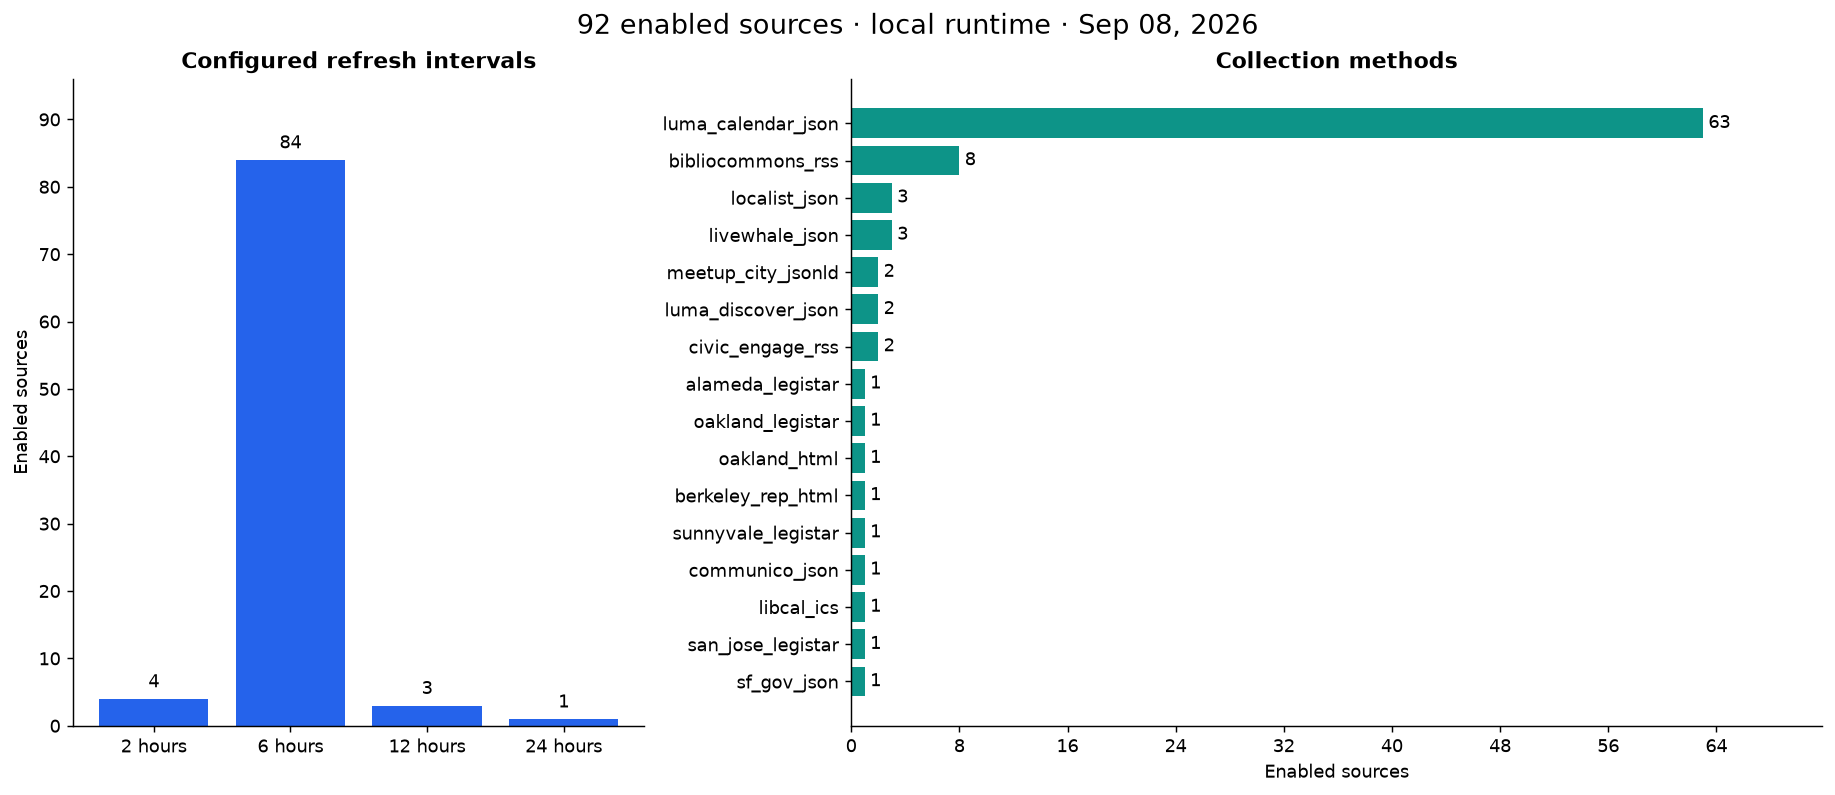

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
plt.rcParams.update({"figure.dpi": 130, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
BLUE, TEAL, ORANGE, RED = "#2563eb", "#0d9488", "#d97706", "#dc2626"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), layout="constrained",
                              gridspec_kw={"width_ratios": [1, 1.7]})
cadences = sorted(Counter(r["refresh_interval_minutes"] / 60 for r in enabled).items())
bars = ax1.bar([f"{h:g} hours" for h, _ in cadences], [count for _, count in cadences], color=BLUE)
ax1.bar_label(bars, padding=4)
ax1.set(title="Configured refresh intervals", ylabel="Enabled sources", ylim=(0, 96))
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
modes = sorted(Counter(r["mode"] for r in enabled).items(), key=lambda item: item[1])
bars = ax2.barh([mode for mode, _ in modes], [count for _, count in modes], color=TEAL)
ax2.bar_label(bars, padding=3)
ax2.set(title="Collection methods", xlabel="Enabled sources", xlim=(0, max(c for _, c in modes) * 1.14))
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.suptitle(f"{len(enabled)} enabled sources · local runtime · {now.astimezone(TZ):%b %d, %Y}", fontsize=15)
plt.show()


## Weekly and monthly refresh equivalents

**Nominal estimates from configured intervals**, not observed weekly/monthly totals. A week is 7 days and a month is standardized to 30 days. Per-source rates are `days × 24 / interval_hours`; fleet volume multiplies that rate by the number of enabled sources. Actual delivery can be lower because intervals run from successful completion and collection time, queue delays and failures add time. These figures count refresh runs, not HTTP requests or unique events. The snapshot does not contain a month of history.

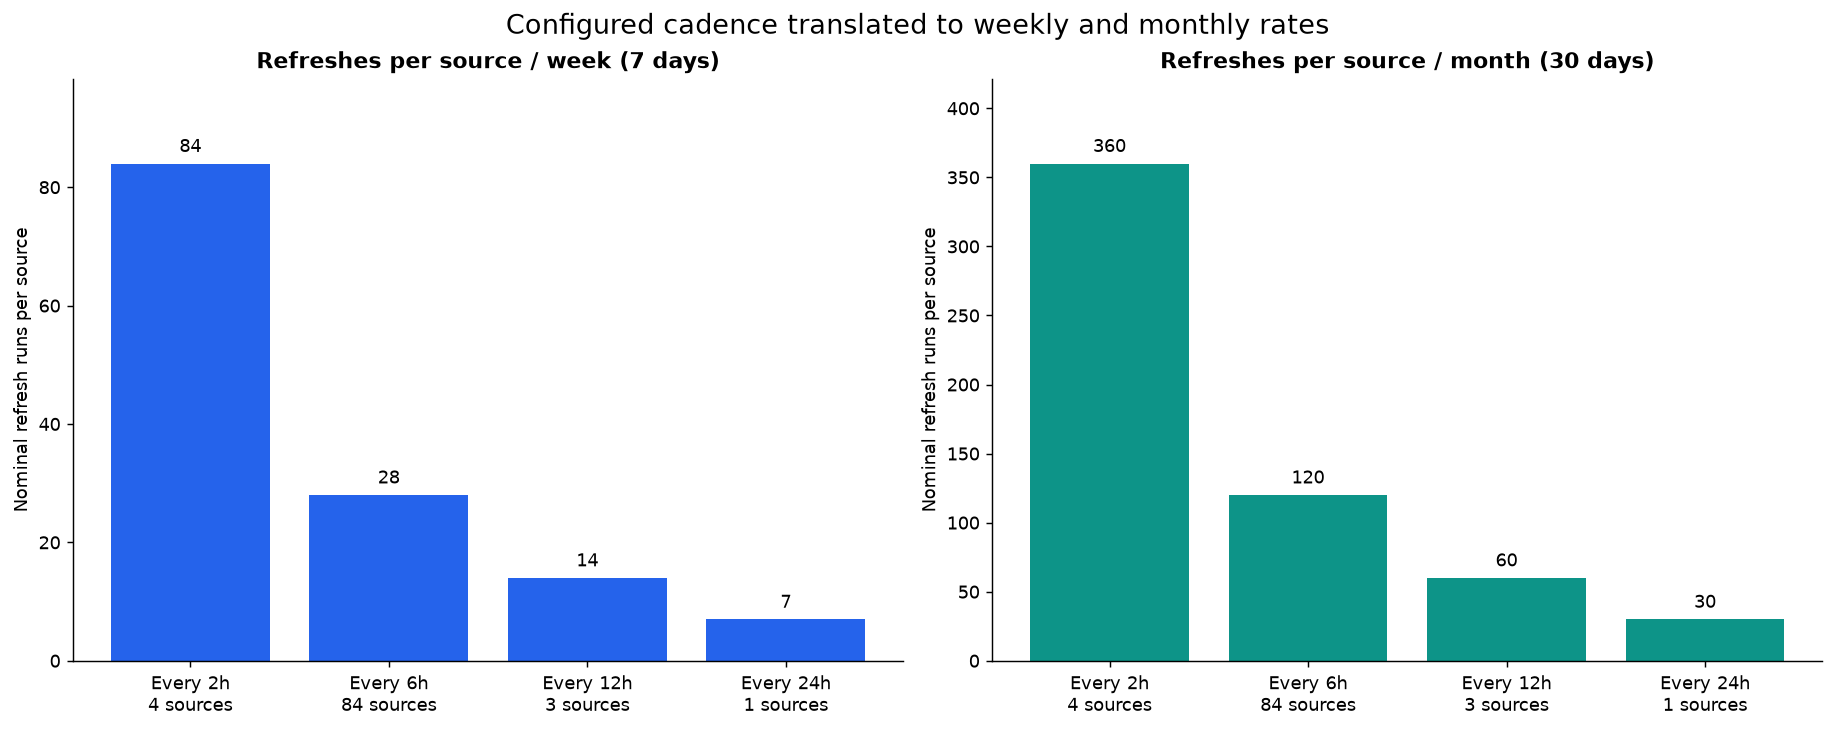

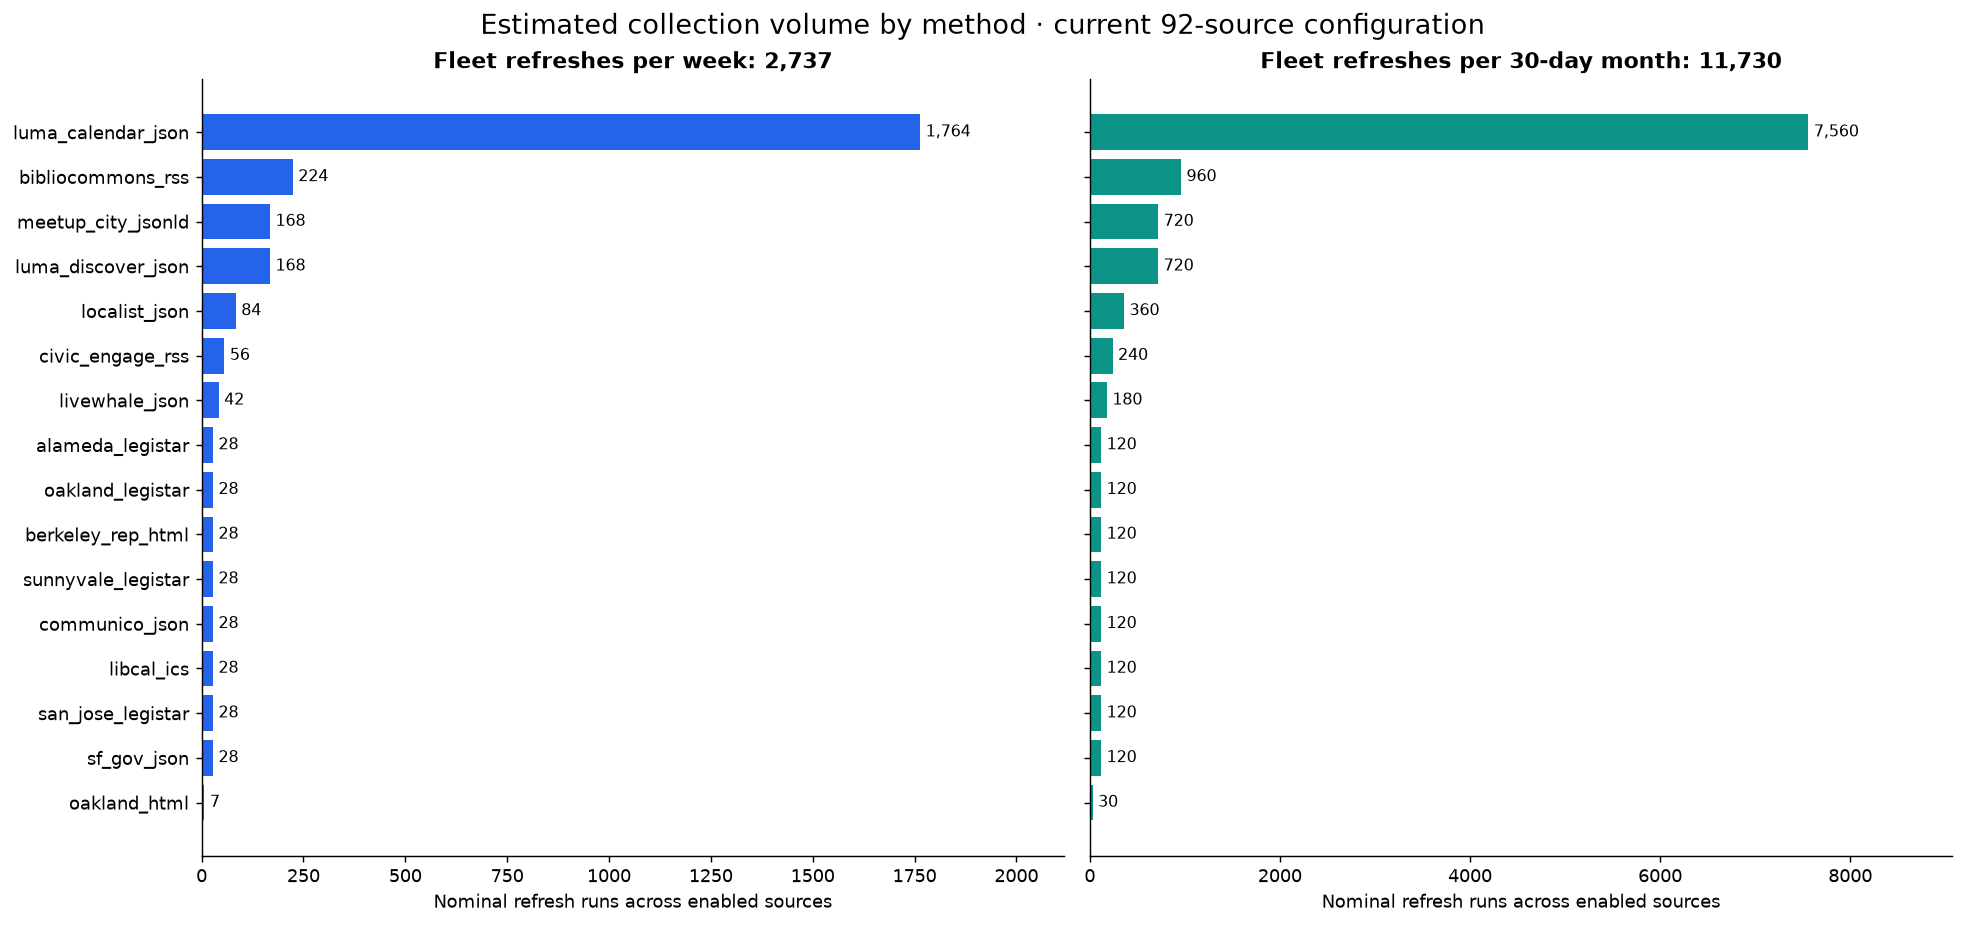

Configured interval,Enabled sources,Per source / week,Per source / 30-day month,Fleet / week,Fleet / 30-day month
2 hours,4,84.0,360.0,336.0,1440.0
6 hours,84,28.0,120.0,2352.0,10080.0
12 hours,3,14.0,60.0,42.0,180.0
24 hours,1,7.0,30.0,7.0,30.0


Nominal fleet total: 2,737 refreshes/week; 11,730 refreshes/30-day month.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
cadence_counts = sorted(Counter(r["refresh_interval_minutes"] / 60 for r in enabled).items())
for ax, days, period, color in zip(axes, [7, 30], ["week (7 days)", "month (30 days)"], [BLUE, TEAL]):
    values = [days*24/h for h, count in cadence_counts]
    labels = [f"Every {h:g}h\n{count} sources" for h, count in cadence_counts]
    bars = ax.bar(labels, values, color=color)
    ax.bar_label(bars, labels=[f"{v:,.0f}" for v in values], padding=4)
    ax.set(title=f"Refreshes per source / {period}", ylabel="Nominal refresh runs per source", ylim=(0,max(values)*1.17))
fig.suptitle("Configured cadence translated to weekly and monthly rates", fontsize=15)
plt.show()

mode_volume = defaultdict(float)
for r in enabled:
    mode_volume[r["mode"]] += 1440/r["refresh_interval_minutes"]
ordered = sorted(mode_volume, key=mode_volume.get)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), layout="constrained", sharey=True)
for ax, days, period, color in zip(axes, [7, 30], ["week", "30-day month"], [BLUE, TEAL]):
    values = [mode_volume[mode]*days for mode in ordered]
    bars = ax.barh(ordered, values, color=color)
    ax.bar_label(bars, labels=[f"{v:,.0f}" for v in values], padding=3, fontsize=9)
    ax.set(title=f"Fleet refreshes per {period}: {sum(values):,.0f}",
           xlabel="Nominal refresh runs across enabled sources", xlim=(0,max(values)*1.2))
fig.suptitle("Estimated collection volume by method · current 92-source configuration", fontsize=15)
plt.show()
table(["Configured interval", "Enabled sources", "Per source / week", "Per source / 30-day month", "Fleet / week", "Fleet / 30-day month"],
      [[f"{h:g} hours", count, 168/h, 720/h, count*168/h, count*720/h] for h,count in cadence_counts])
print(f"Nominal fleet total: {sum(mode_volume.values())*7:,.0f} refreshes/week; {sum(mode_volume.values())*30:,.0f} refreshes/30-day month.")


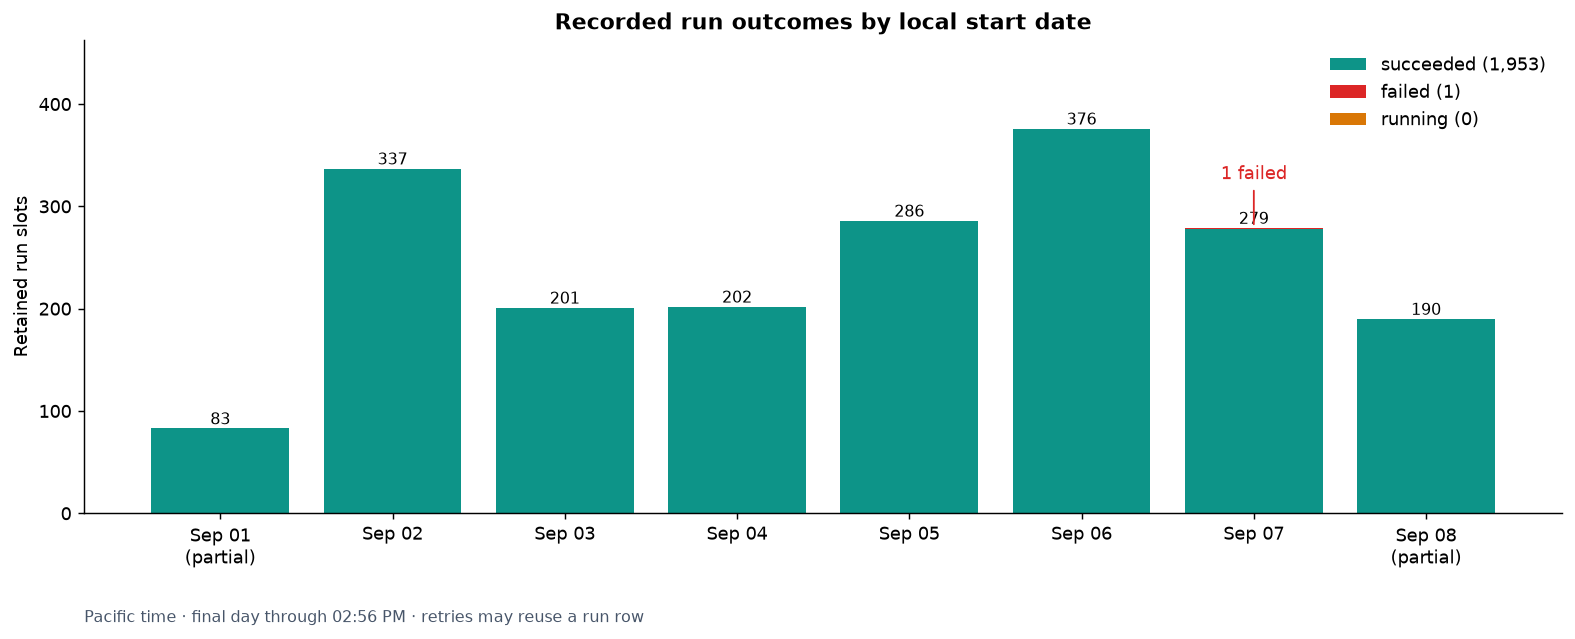

In [7]:
window_start = now - timedelta(days=7)
first_day = window_start.astimezone(TZ).date()
last_day = now.astimezone(TZ).date()
days = [first_day + timedelta(days=i) for i in range((last_day-first_day).days + 1)]
statuses = ["succeeded", "failed", "running"]
counts = Counter((dt(r["started_at"]).astimezone(TZ).date(), r["status"]) for r in runs)
fig, ax = plt.subplots(figsize=(12, 4.8), layout="constrained")
bottom = [0] * len(days)
for status, color in zip(statuses, [TEAL, RED, ORANGE]):
    values = [counts[(day, status)] for day in days]
    ax.bar(range(len(days)), values, bottom=bottom, label=f"{status} ({sum(values):,})", color=color)
    bottom = [a+b for a,b in zip(bottom, values)]
for i, total in enumerate(bottom):
    ax.text(i, total+4, str(total), ha="center", fontsize=9)
    failed = counts[(days[i], "failed")]
    if failed:
        ax.annotate(f"{failed} failed", xy=(i, total), xytext=(0, 27),
                    textcoords="offset points", ha="center", color=RED,
                    arrowprops={"arrowstyle": "-", "color": RED})
labels = [f"{d:%b %d}" + ("\n(partial)" if d in (first_day, last_day) else "") for d in days]
ax.set_xticks(range(len(days)), labels)
ax.set(title="Recorded run outcomes by local start date", ylabel="Retained run slots",
       ylim=(0, max(bottom)*1.23))
ax.legend(frameon=False, loc="upper right")
ax.text(0, -0.23, f"Pacific time · final day through {now.astimezone(TZ):%I:%M %p} · retries may reuse a run row",
        transform=ax.transAxes, color="#475569", fontsize=9)
plt.show()


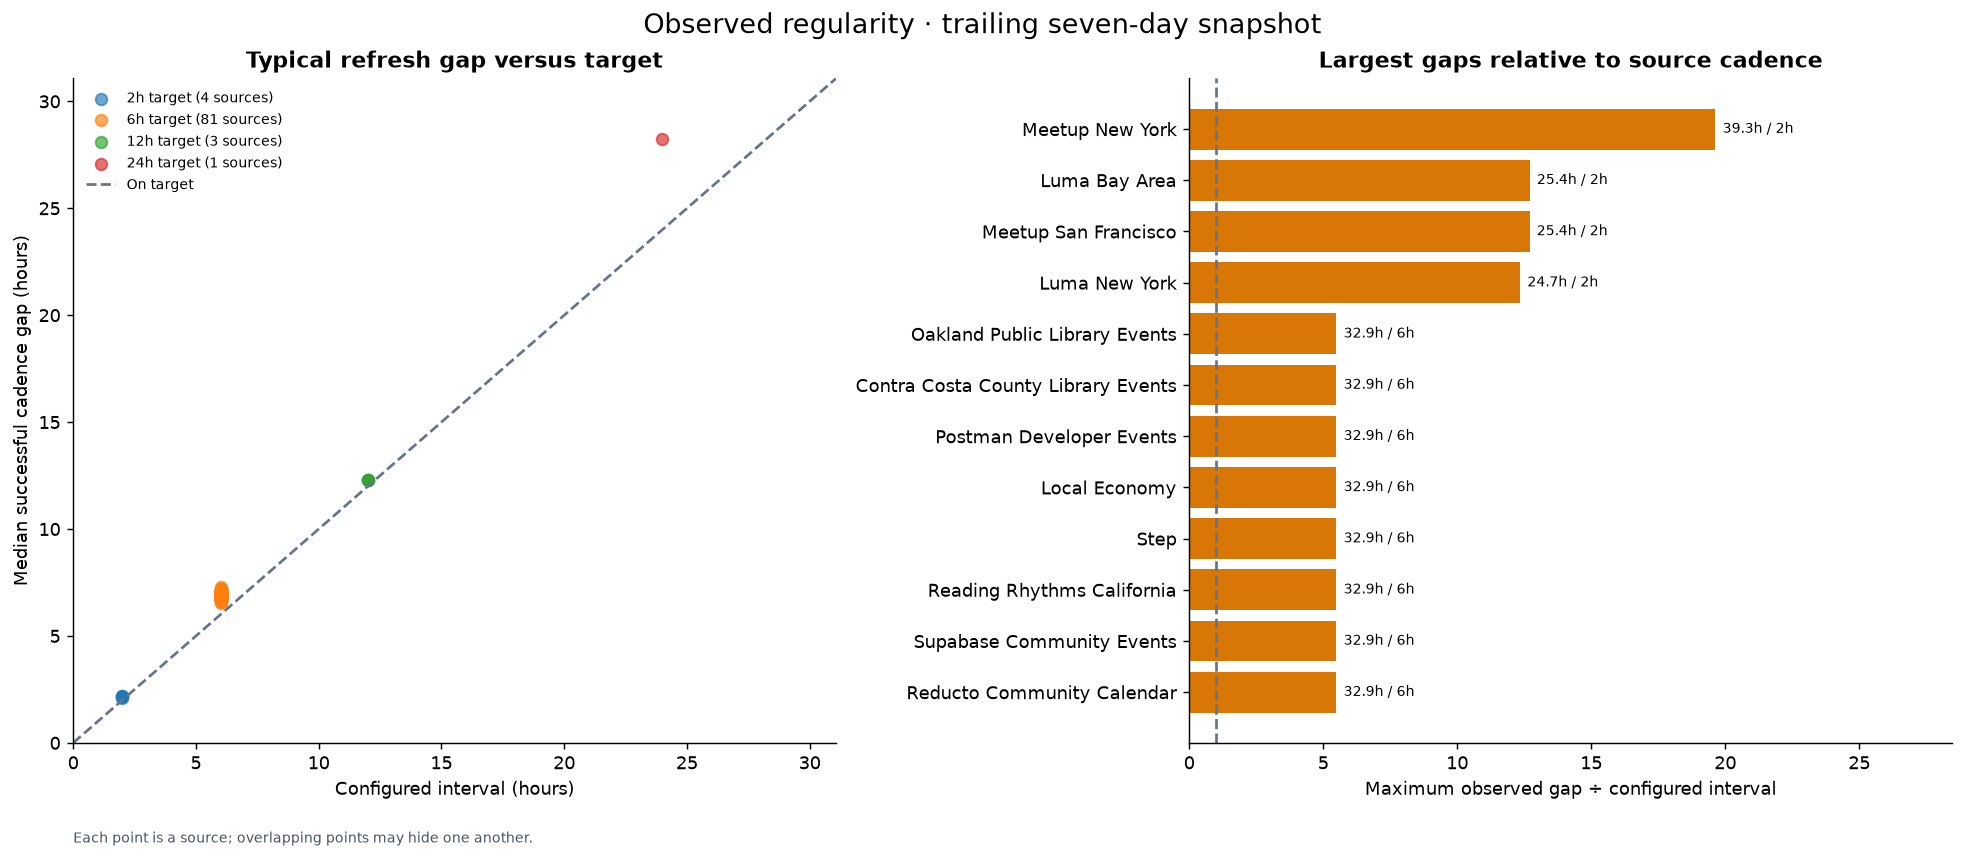

Gap measurements available for 89 of 92 enabled sources.
Bar labels show maximum observed hours / configured hours. Gaps alone do not establish the cause of delays.


In [8]:
measured = [row for row in observed if row[3] is not None]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), layout="constrained")
for target in sorted({row[1] for row in measured}):
    group = [row for row in measured if row[1] == target]
    ax1.scatter([row[1] for row in group], [row[3] for row in group],
                label=f"{target:g}h target ({len(group)} sources)", s=42, alpha=.65)
upper = max([row[1] for row in measured] + [row[3] for row in measured]) * 1.1
ax1.plot([0, upper], [0, upper], linestyle="--", color="#64748b", label="On target")
ax1.set(title="Typical refresh gap versus target", xlabel="Configured interval (hours)",
        ylabel="Median successful cadence gap (hours)", xlim=(0, upper), ylim=(0, upper))
ax1.legend(frameon=False, fontsize=8)
ax1.text(0, -0.15, "Each point is a source; overlapping points may hide one another.",
         transform=ax1.transAxes, color="#475569", fontsize=8)
worst = sorted(measured, key=lambda row: row[4]/row[1], reverse=True)[:12][::-1]
import textwrap
names = [textwrap.shorten(row[0], width=43, placeholder="…") for row in worst]
ratios = [row[4]/row[1] for row in worst]
bars = ax2.barh(range(len(worst)), ratios, color=ORANGE)
ax2.set_yticks(range(len(worst)), names)
ax2.bar_label(bars, labels=[f"{r[4]:.1f}h / {r[1]:g}h" for r in worst], padding=4, fontsize=8)
ax2.axvline(1, linestyle="--", color="#64748b")
ax2.set(title="Largest gaps relative to source cadence", xlabel="Maximum observed gap ÷ configured interval",
        xlim=(0, max(ratios)*1.45))
fig.suptitle("Observed regularity · trailing seven-day snapshot", fontsize=15)
plt.show()
print(f"Gap measurements available for {len(measured)} of {len(enabled)} enabled sources.")
print("Bar labels show maximum observed hours / configured hours. Gaps alone do not establish the cause of delays.")


## Exceptions, paused sources and coverage limits

In [9]:
table(["Source", "State", "Last success PT", "Next due PT"],[[r["display_name"],r["effective_status"],local(r["last_succeeded_at"]),local(r["next_due_at"])] for r in api.values() if r["effective_status"]!="active"])
table(["Failed source", "Started PT", "Attempts", "Normalized error"],[[r["source_key"],local(r["started_at"]),r["attempt_count"],r["error_code"]] for r in runs if r["status"]=="failed"])
missing={r["source_key"] for r in enabled}-{r["source_key"] for r in today}
print("Enabled sources without a run started today:", ", ".join(sorted(missing)))

Source,State,Last success PT,Next due PT
AI Engineers - NY,disabled,09-08 10:37,09-08 16:37
Alameda County Library: Fremont Events,retired,08-01 05:13,—
Cal Performances Events,disabled,07-17 05:19,07-17 11:19
City of Los Altos Events,disabled,07-17 03:51,07-17 09:51
DataSF Our415 Activities,disabled,07-17 00:19,07-17 06:19
Gardens of Golden Gate Park Events,disabled,07-17 02:56,07-17 08:56
Generative AI SF,due,08-29 10:39,08-29 16:39
Midpeninsula Regional Open Space District Events & Activities,disabled,07-17 03:30,07-17 09:30
Oakland Museum of California Events,disabled,07-17 01:59,07-17 07:59
San Mateo County Libraries: Millbrae Events,retired,07-17 02:18,—


Failed source,Started PT,Attempts,Normalized error
luma-genai-sf,09-07 23:14,18,refresh_failed


Enabled sources without a run started today: luma-genai-sf, oakland-city-events, sccld-all-physical-branches-events


## How scheduling works and how to interpret this

- The cadence process enqueues a durable `refresh_due` command; the separate command worker executes collection. The 300-second poll is not a five-minute refresh of every source.
- Due selection uses the last successful completion plus the configured interval. Review validity, retirement, eligibility, live leases, queue delay and failures affect actual dispatch.
- The failure-aware SQL gate backs off retrying cadence slots, parks terminal `page_cap_exceeded` / `source_access_denied` failures, and withdraws slots after 20 attempts. Manual refreshes use a separate run key. Review the actual gate before interpreting an overdue source as scheduler failure.
- Run counts and candidate/canonical totals are repeated collection observations, not counts of unique events or network requests. A successful run may publish zero events.
- The local runtime has `mock_cloud=true`; non-fixture source runs are distinguished using the database fixture classifier and the admin API. This does not establish production collection, nor independent provider-side request evidence. The API's latest-run projection reports legacy provenance unavailable for observed runs.
- Inspect unusually large observed gaps and repeated attempts before increasing frequency. Disabled and retired sources are excluded from the enabled cadence totals; fixture registry rows are excluded throughout.

## Evidence and reproducibility

The embedded snapshot contains the non-fixture source roster from paginated `GET /admin/v1/ingestion/sources?limit=100&offset=…`, reviewed registry settings, and seven days of sanitized run fields. Registry/run data were captured inside a PostgreSQL read-only repeatable-read transaction; API pages were read immediately afterward and are not transactionally identical. The SQL text is retained in `snapshot['query']`; fixture rows returned by the registry query were removed using the API roster before embedding. No credentials, lease tokens, raw provider payloads or raw errors are included.

Runtime settings were read from the running `ingestion-cadence` container through `get_settings()`. `docker compose ps -a` confirmed cadence and command containers running; the database run ledger provides the useful processing evidence.

Code references: [cadence worker](../src/events_concierge/workers/ingestion_cadence.py), [scheduler application](../src/events_concierge/application/ingestion_cadence_scheduler.py), [failure-aware cadence SQL](../migrations/versions/0155_cadence_failure_aware_due_sources.py), [Compose configuration](../docker-compose.yml), [operations guide](../docs/ingestion-admin.md). Code links refer to the current checkout, which may differ from the running image. Rerunning this notebook analyzes the preserved snapshot; collecting a new snapshot requires explicitly repeating the read-only capture.


# Independent source coverage audit

**New snapshot: September 8, 2026, 3:57 p.m. Pacific.** The next 30 days contain **7,069 distinct admitted canonical events** from 92 enabled sources. This section measures catalog breadth and marginal contribution, independently of run frequency. It does not replace the earlier cadence snapshot: configuration changed between captures (the four city discovery sources now report a daily interval).

**Main findings**

- Bay Area libraries supply **5,116 events (72.4%)**. The five largest sources together supply **4,120 distinct events (58.3%)**. Source count is therefore a poor proxy for content diversity.
- New York has **34 enabled sources: 32 Luma calendars, one Luma discovery feed and one Meetup city feed**. There are no dedicated NYC public-library, parks, university or civic feeds in the reviewed registry.
- **Family (2,111), education (1,676), community (1,614), and arts (1,219)** are the most common assigned topics. AI (401) and founders (318) are represented, but neither is the largest content segment. Tags overlap and are not a population benchmark.
- **782 events (11.1%) lack a normalized city; 6,141 (86.9%) have unknown price; 1,545 (21.9%) have no topic tags.** These are discoverability limitations, not proof that the events themselves lack a location, price or subject.
- Six enabled sources contribute no admitted event in this 30-day window. Zero output alone does not establish failure or that the publisher has nothing scheduled.

**Method and denominator:** `fn_list_retained_catalog_browse_observations_v2(NULL, now(), now()+30 days)` supplies the production-code admission/retention rules in the local database. Join only those observations to canonical events and deduplicate by canonical ID. This includes ongoing events overlapping the window and excludes cancelled events according to the database function. Source contribution counts can overlap; regional labels describe configured source scope, not verified venue geography. Canonical deduplication itself has not been independently audited. No recall percentage is claimed because no complete external event census exists in this analysis.

In [10]:
coverage = json.loads('{"captured_at": "2026-09-08T22:57:23.211985+00:00", "window_days": 30, "schema": "0182", "sources": [{"source_key": "luma-genai-sf", "display_name": "Generative AI SF", "publisher": "Generative AI SF", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-JTdFQadEz0AOxyV&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.083588+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T05:41:39.745384+00:00", "updated_at": "2026-09-08T22:38:29.083588+00:00", "page_limit": 30, "source_revision": 5, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sf-gov-related-events", "display_name": "SF.gov Citywide Events", "publisher": "City and County of San Francisco", "seed_url": "https://api.sf.gov/api/related-events/?list=upcoming&locale=en&page=1&groupby=date", "approved_origins": ["https://api.sf.gov"], "region": "bay_area_9_county", "mode": "sf_gov_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.86725+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:54:48.262475+00:00", "updated_at": "2026-09-08T22:38:29.86725+00:00", "page_limit": 25, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "san-jose-legistar-meetings", "display_name": "San Jos\\u00e9 Public Meetings", "publisher": "City of San Jos\\u00e9 City Clerk", "seed_url": "https://webapi.legistar.com/v1/SanJose/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "san_jose_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.760207+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T07:51:32.106202+00:00", "updated_at": "2026-09-08T22:38:29.760207+00:00", "page_limit": 5, "source_revision": 358, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "datasf-our415-events", "display_name": "DataSF Our415 Activities", "publisher": "City and County of San Francisco", "seed_url": "https://data.sfgov.org/resource/8i3s-ih2a.json", "approved_origins": ["https://data.sfgov.org"], "region": "bay_area_9_county", "mode": "datasf_our415", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T07:17:38.425211+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T07:17:38.425211+00:00", "updated_at": "2026-07-17T07:17:38.425211+00:00", "page_limit": 25, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "berkeley-events", "display_name": "UC Berkeley Events", "publisher": "University of California, Berkeley", "seed_url": "https://events.berkeley.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.berkeley.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.307244+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-09-08T22:38:30.307244+00:00", "page_limit": 3, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-milpitas-events", "display_name": "SCCLD Milpitas Library Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=MI", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T07:33:43.386805+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T07:33:43.386805+00:00", "updated_at": "2026-07-17T07:33:43.386805+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.114943+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events"}, {"source_key": "ucsf-events", "display_name": "UCSF Events Localist Calendar", "publisher": "University of California, San Francisco", "seed_url": "https://calendar.ucsf.edu/api/2/events", "approved_origins": ["https://calendar.ucsf.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.339019+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-09-08T22:38:30.339019+00:00", "page_limit": 20, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "scu-events", "display_name": "Santa Clara University Events", "publisher": "Santa Clara University", "seed_url": "https://events.scu.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.scu.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.833701+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-09-08T22:38:29.833701+00:00", "page_limit": 3, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "berkeley-public-library-events", "display_name": "Berkeley Public Library Events", "publisher": "Berkeley Public Library", "seed_url": "https://berkeleypubliclibrary.libnet.info/eeventcaldata", "approved_origins": ["https://berkeleypubliclibrary.libnet.info"], "region": "bay_area_9_county", "mode": "communico_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.740565+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T08:41:28.258582+00:00", "updated_at": "2026-09-08T22:38:28.740565+00:00", "page_limit": 1, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "mountain-view-library-events", "display_name": "Mountain View Public Library Events", "publisher": "Mountain View Public Library", "seed_url": "https://mountainview.libcal.com/ical_subscribe.php?src=p&cid=8800", "approved_origins": ["https://mountainview.libcal.com"], "region": "bay_area_9_county", "mode": "libcal_ics", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.333566+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T09:29:02.852606+00:00", "updated_at": "2026-09-08T22:38:29.333566+00:00", "page_limit": 1, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "palo-alto-library-events", "display_name": "Palo Alto City Library Events", "publisher": "Palo Alto City Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/paloalto/rss/events", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.553108+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T09:10:47.00249+00:00", "updated_at": "2026-09-08T22:38:29.553108+00:00", "page_limit": 15, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "omca-events", "display_name": "Oakland Museum of California Events", "publisher": "Oakland Museum of California", "seed_url": "https://museumca.org/wp-json/tribe/events/v1/events", "approved_origins": ["https://museumca.org"], "region": "bay_area_9_county", "mode": "tribe_events_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T08:58:55.843477+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:58:55.843477+00:00", "updated_at": "2026-07-17T08:58:55.843477+00:00", "page_limit": 5, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "stanford-events", "display_name": "Stanford Events Localist Calendar", "publisher": "Stanford University", "seed_url": "https://events.stanford.edu/api/2/events", "approved_origins": ["https://events.stanford.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.986377+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-09-08T22:38:29.986377+00:00", "page_limit": 20, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smcl-millbrae-events", "display_name": "San Mateo County Libraries: Millbrae Events", "publisher": "San Mateo County Libraries", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1M", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T09:17:36.470878+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:17:36.470878+00:00", "updated_at": "2026-07-17T09:17:36.470878+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120006+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "smcl-all-physical-branches-events"}, {"source_key": "sunnyvale-legistar-meetings", "display_name": "Sunnyvale Public Meetings", "publisher": "City of Sunnyvale City Clerk", "seed_url": "https://webapi.legistar.com/v1/SunnyvaleCA/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "sunnyvale_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.042919+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T08:28:53.682865+00:00", "updated_at": "2026-09-08T22:38:30.042919+00:00", "page_limit": 5, "source_revision": 215, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "berkeley-rep-shows", "display_name": "Berkeley Repertory Theatre Shows", "publisher": "Berkeley Repertory Theatre", "seed_url": "https://www.berkeleyrep.org/shows", "approved_origins": ["https://www.berkeleyrep.org", "https://tickets.berkeleyrep.org"], "region": "bay_area_9_county", "mode": "berkeley_rep_html", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.765362+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-17T12:38:13.978175+00:00", "updated_at": "2026-09-08T22:38:28.765362+00:00", "page_limit": 1, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "usfca-main-campus-events", "display_name": "University of San Francisco Main Campus Events", "publisher": "University of San Francisco", "seed_url": "https://www.usfca.edu/life-at-usf/events?field_campus%5B179%5D=179", "approved_origins": ["https://www.usfca.edu"], "region": "bay_area_9_county", "mode": "usfca_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T11:55:11.190342+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T11:55:11.190342+00:00", "updated_at": "2026-07-17T11:55:11.190342+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "midpen-events", "display_name": "Midpeninsula Regional Open Space District Events & Activities", "publisher": "Midpeninsula Regional Open Space District", "seed_url": "https://www.openspace.org/get-involved/events-activities?page=0", "approved_origins": ["https://www.openspace.org"], "region": "bay_area_9_county", "mode": "midpen_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-08-02T18:53:53.026708+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T10:14:25.838455+00:00", "updated_at": "2026-08-02T18:53:53.026708+00:00", "page_limit": 9, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "ybca-calendar", "display_name": "Yerba Buena Center for the Arts Calendar", "publisher": "Yerba Buena Center for the Arts", "seed_url": "https://ybca.org/calendar/", "approved_origins": ["https://ybca.org"], "region": "bay_area_9_county", "mode": "ybca_html", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T13:03:33.038095+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 10000, "created_at": "2026-07-17T13:03:33.038095+00:00", "updated_at": "2026-07-17T13:03:33.038095+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "campbell-events", "display_name": "Campbell Recreation & Community Services Events", "publisher": "City of Campbell Recreation & Community Services", "seed_url": "https://www.campbellca.gov/RSSFeed.aspx?CID=Recreation-Community-Services-29&ModID=58", "approved_origins": ["https://www.campbellca.gov"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.803563+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T10:43:40.087098+00:00", "updated_at": "2026-09-08T22:38:28.803563+00:00", "page_limit": 1, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "contra-costa-county-library-events", "display_name": "Contra Costa County Library Events", "publisher": "Contra Costa County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/ccclib/rss/events?locations=43&locations=7&locations=25&locations=19&locations=14&locations=60&locations=4&locations=21&locations=26&locations=24&locations=11&locations=16&locations=6&locations=55&locations=9&locations=94&locations=1&locations=17&locations=12&locations=15&locations=27&locations=23&locations=8&locations=2&locations=13", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.887111+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T11:41:23.283293+00:00", "updated_at": "2026-09-08T22:38:28.887111+00:00", "page_limit": 105, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-public-library-events", "display_name": "Oakland Public Library Events", "publisher": "Oakland Public Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/oaklandlibrary/rss/events?locations=81A&locations=AAA&locations=ASA&locations=BRA&locations=CCA&locations=DMA&locations=EAA&locations=ELA&locations=GGA&locations=KGA&locations=LVA&locations=MEA&locations=MOA&locations=OHR&locations=PMA&locations=RRA&locations=TMA&locations=WAS&locations=XXA&locations=XXJ&locations=XXY&locations=676de3ef74596c36004dc6bd&locations=6a0c99a4e8af4a2f00739408&locations=6a517185e9de6536001ad4d7", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.430229+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T11:03:23.222377+00:00", "updated_at": "2026-09-08T22:38:29.430229+00:00", "page_limit": 60, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sf-rec-park-events", "display_name": "San Francisco Recreation & Parks Events", "publisher": "San Francisco Recreation & Park Department", "seed_url": "https://sfrecpark.org/RSSFeed.aspx?CID=Main-Calendar-14&ModID=58", "approved_origins": ["https://sfrecpark.org"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.687277+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T09:49:33.734033+00:00", "updated_at": "2026-09-08T22:38:29.687277+00:00", "page_limit": 1, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "san-jose-public-library-events", "display_name": "San Jos\\u00e9 Public Library Events", "publisher": "San Jos\\u00e9 Public Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sjpl/rss/events?locations=00&locations=01&locations=02&locations=03&locations=04&locations=05&locations=06&locations=07&locations=08&locations=09&locations=10&locations=11&locations=12&locations=14&locations=15&locations=16&locations=17&locations=18&locations=19&locations=21&locations=22&locations=23&locations=24&locations=25&locations=26", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.709446+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T11:14:43.294365+00:00", "updated_at": "2026-09-08T22:38:29.709446+00:00", "page_limit": 320, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-city-events", "display_name": "City of Oakland Event Calendar", "publisher": "City of Oakland", "seed_url": "https://www.oaklandca.gov/sitemap.xml", "approved_origins": ["https://www.oaklandca.gov"], "region": "bay_area_9_county", "mode": "oakland_html", "handoff_only": true, "enabled": true, "reviewed_at": "2026-07-18T13:45:34.914907+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T13:45:34.914907+00:00", "updated_at": "2026-07-18T13:45:34.914907+00:00", "page_limit": 160, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smcl-all-physical-branches-events", "display_name": "San Mateo County Libraries: All Physical Branch Events", "publisher": "San Mateo County Libraries", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1A&locations=1B&locations=1R&locations=1E&locations=1F&locations=1H&locations=1M&locations=1N&locations=1Z&locations=1P&locations=1V&locations=1S&locations=1W", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.782236+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T14:18:15.418667+00:00", "updated_at": "2026-09-08T22:38:29.782236+00:00", "page_limit": 150, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "smccd-events", "display_name": "SMCCD Events", "publisher": "San Mateo County Community College District", "seed_url": "https://events.smccd.edu/live/json/events/response_fields/location,summary,description", "approved_origins": ["https://events.smccd.edu"], "region": "bay_area_9_county", "mode": "livewhale_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.936155+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:27:07.726661+00:00", "updated_at": "2026-09-08T22:38:29.936155+00:00", "page_limit": 3, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "oakland-legistar-meetings", "display_name": "Oakland Public Meetings", "publisher": "City of Oakland City Clerk", "seed_url": "https://webapi.legistar.com/v1/Oakland/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "oakland_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.45941+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-18T15:41:44.244964+00:00", "updated_at": "2026-09-08T22:38:29.45941+00:00", "page_limit": 5, "source_revision": 321, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "gardens-golden-gate-park-events", "display_name": "Gardens of Golden Gate Park Events", "publisher": "Gardens of Golden Gate Park", "seed_url": "https://gggp.org/wp-json/tribe/events/v1/events", "approved_origins": ["https://gggp.org"], "region": "bay_area_9_county", "mode": "tribe_events_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T09:56:10.993437+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:56:10.993437+00:00", "updated_at": "2026-07-17T09:56:10.993437+00:00", "page_limit": 5, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "los-altos-events", "display_name": "City of Los Altos Events", "publisher": "City of Los Altos", "seed_url": "https://www.losaltosca.gov/RSSFeed.aspx?CID=All-calendar.xml&ModID=58", "approved_origins": ["https://www.losaltosca.gov"], "region": "bay_area_9_county", "mode": "civic_engage_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T10:50:59.626462+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T10:50:59.626462+00:00", "updated_at": "2026-07-17T10:50:59.626462+00:00", "page_limit": 1, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "calperformances-events", "display_name": "Cal Performances Events", "publisher": "Cal Performances", "seed_url": "https://calperformances.org/wp-json/wp/v2/cp_event?per_page=100&page=1", "approved_origins": ["https://calperformances.org"], "region": "bay_area_9_county", "mode": "calperformances_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T12:18:21.992289+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T12:18:21.992289+00:00", "updated_at": "2026-07-17T12:18:21.992289+00:00", "page_limit": 4, "source_revision": 1, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "alameda-legistar-meetings", "display_name": "Alameda Public Meetings", "publisher": "City of Alameda City Clerk", "seed_url": "https://webapi.legistar.com/v1/Alameda/Events", "approved_origins": ["https://webapi.legistar.com"], "region": "bay_area_9_county", "mode": "alameda_legistar", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.635333+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-18T15:18:19.164796+00:00", "updated_at": "2026-09-08T22:38:28.635333+00:00", "page_limit": 5, "source_revision": 215, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc", "display_name": "Luma New York", "publisher": "Luma Discover", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-Izx1rQVSh8njYpP&pagination_limit=25", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_discover_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.236923+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-28T01:56:37.948926+00:00", "updated_at": "2026-09-08T22:38:29.236923+00:00", "page_limit": 40, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "meetup-sf", "display_name": "Meetup San Francisco", "publisher": "Meetup City", "seed_url": "https://www.meetup.com/find/us--ca--san-francisco/", "approved_origins": ["https://www.meetup.com"], "region": "bay_area_9_county", "mode": "meetup_city_jsonld", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.307977+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-31T04:58:34.316339+00:00", "updated_at": "2026-09-08T22:38:29.307977+00:00", "page_limit": 41, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-saratoga-events", "display_name": "SCCLD Saratoga Library Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=SA", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-07-17T08:47:04.256578+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T08:47:04.256578+00:00", "updated_at": "2026-07-17T08:47:04.256578+00:00", "page_limit": 15, "source_revision": 1, "retired_at": "2026-08-02T03:47:39.120083+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "sccld-all-physical-branches-events"}, {"source_key": "alameda-county-library-fremont-events", "display_name": "Alameda County Library: Fremont Events", "publisher": "Alameda County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=FRM", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": false, "reviewed_at": "2026-08-02T03:20:15.473471+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-07-17T09:59:53.549819+00:00", "updated_at": "2026-08-02T03:20:15.473471+00:00", "page_limit": 7, "source_revision": 3, "retired_at": "2026-08-02T03:47:39.121691+00:00", "retired_reason": "superseded_by_aggregate_source", "superseded_by_source_key": "alameda-county-library-all-physical-branches-events"}, {"source_key": "meetup-nyc", "display_name": "Meetup New York", "publisher": "Meetup City", "seed_url": "https://www.meetup.com/find/us--ny--new-york/", "approved_origins": ["https://www.meetup.com"], "region": "new_york_metro", "mode": "meetup_city_jsonld", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.284049+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-31T04:58:34.316339+00:00", "updated_at": "2026-09-08T22:38:29.284049+00:00", "page_limit": 41, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sjsu-events", "display_name": "SJSU Events Localist Calendar", "publisher": "San Jos\\u00e9 State University", "seed_url": "https://events.sjsu.edu/api/2/events", "approved_origins": ["https://events.sjsu.edu"], "region": "bay_area_9_county", "mode": "localist_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.902567+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-17T06:03:58.207064+00:00", "updated_at": "2026-09-08T22:38:29.902567+00:00", "page_limit": 20, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "sccld-all-physical-branches-events", "display_name": "Santa Clara County Library District: All Physical Branch Events", "publisher": "Santa Clara County Library District", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=CA&locations=CU&locations=GI&locations=LA&locations=MI&locations=MH&locations=SA&locations=WO", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.812009+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T14:37:20.093486+00:00", "updated_at": "2026-09-08T22:38:29.812009+00:00", "page_limit": 120, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-usecorgi", "display_name": "Corgi", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-AJpfQVFYtwnIIBy&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.921443+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:28.921443+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cursorcommunity", "display_name": "Cursor Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-61Cv6COs4g9GKw7&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.003172+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.003172+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-localeconomy", "display_name": "Local Economy", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-7e3UHJX4UgCZaoW&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.194379+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.194379+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-postman-dev-events", "display_name": "Postman Developer Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TGqTNpY4iyl7XYe&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.594484+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.594484+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-thecommons", "display_name": "The Commons", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ahTi4ptrN9WCYkg&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.134051+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.134051+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-frontiersyndicate", "display_name": "The Frontier Syndicate", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ffZMpSc1tJiBS9b&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.149495+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.149495+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-thelovepotionlibrary", "display_name": "The Love Potion Library", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9xlm8rlcNcsBdxW&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.168376+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.168376+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cal-z1tslebmjjch4fd", "display_name": "WorkOS Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Z1tslEBMjjCh4fd&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.455738+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.455738+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-arizeai", "display_name": "Arize AI", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wjMwGmksR3Zpa83&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.697421+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:28.697421+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-baseten", "display_name": "Baseten Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-l76607AsonZ1F7F&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.716278+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:28.716278+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-circe", "display_name": "Circe Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-2vq1HjUj9xZwtBx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.850278+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:28.850278+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-claudecommunity", "display_name": "Claude Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-TOpA5LAFfuDeFpu&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.867376+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.867376+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-fal", "display_name": "fal Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-u3vVIuSFJd7RqNB&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.035348+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.035348+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-fdotinc", "display_name": "Founders, Inc. Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-iHkz5obZdong4ta&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.067284+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.067284+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-granola", "display_name": "Granola", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-ofXMwxW9NLr0RDU&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.114883+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.114883+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-gumloop", "display_name": "Gumloop", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kWCZBWXIrWKB518&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.131964+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.131964+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-health-tech-nerds", "display_name": "Health Tech Nerds", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYMHk5wzM4CQR74&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.147859+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.147859+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-openrouter", "display_name": "OpenRouter Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-cv816PW6bxfYMVP&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.525328+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.525328+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-posthog", "display_name": "PostHog", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-qJCKF7ct5XX3pwB&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.577021+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.577021+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-readingrhythms-ca", "display_name": "Reading Rhythms California", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Eo35suMbTdQnr20&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.632057+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.632057+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-reductoai", "display_name": "Reducto Community Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UgzNHDmpkC0jeiz&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.670641+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.670641+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-sf-hardware-meetup", "display_name": "SF Hardware Meetup", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-tFAzNGOZ9xn6kT2&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.851965+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:29.851965+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-stepevents", "display_name": "Step", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DcJSjTzVhNCxcwK&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.006907+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.006907+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-temporalio", "display_name": "Temporal Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Cj9mMU4rSQva1HA&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.097958+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.097958+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-tiat", "display_name": "tiat (the intersection of art & technology)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-twiOosdGMMY66DI&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.223683+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.223683+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-tokensand", "display_name": "tokens&", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EVJ0XV6EJegxAT7&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.254733+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.254733+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "display_name": "Transit Books", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-zauF7Gj3RTECxwR&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.276969+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.276969+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-vercel-events", "display_name": "Vercel Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-hp9HP2UFTGNaMnY&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.383277+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.383277+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-wemakedevs", "display_name": "WeMakeDevs", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-G9rNvcoz3r4AGfv&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.441183+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.441183+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-accentaccent", "display_name": "Accent Is A Superpower (online & offline events)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Sc85BAZzQ7GZiZE&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.506889+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.506889+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-active-external", "display_name": "Activate Ecosystem Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-gTCvv5vKTHEyvgp&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.554917+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.554917+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-andrewsmixers", "display_name": "Andrew\'s Yeung\'s Tech Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-kcWhMbIs2X0Y2Xb&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.660894+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.660894+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-brooklyngrange", "display_name": "Brooklyn Grange: Sunset Park and Brooklyn Navy Yard", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-pNFenlfEW71zGC5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.785663+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.785663+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-asrccat", "display_name": "Center for Advanced Technology (CAT)", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-DukJHu11ElQhhxx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.829013+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.829013+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-counterspell", "display_name": "Counterspell Games", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fT3eKMrCO9zUul2&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.965024+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.965024+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-coworknchillcalendar", "display_name": "CoworkNChill Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-9QAo4pAQjtkRMKM&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.987811+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.987811+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-heatmapnews", "display_name": "Heatmap News", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-3UdV6WiftPs1INi&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.163682+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.163682+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-kanso", "display_name": "Kanso: Phone-Free Experiences", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-fHHfS2rChIZ1IWx&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.17964+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.17964+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-mysha-happenings", "display_name": "mysha happenings", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-MS5jAaElmqxx6De&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.374973+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.374973+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-b2bnyc", "display_name": "NYC B2B: Startup Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-1VimvHYSCVGhHuk&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.395771+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.395771+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-obviousai", "display_name": "Obvious Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0JE8SiQKgmJoT5v&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.480871+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.480871+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-pudgypenguins", "display_name": "Pudgy Penguins", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-d54V4FW22lMwmB9&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.613316+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.613316+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-readingrhythms-manhattan", "display_name": "Reading Rhythms NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Q8l315UsVMWb6h6&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.651367+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.651367+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sleepawake-events", "display_name": "Sleepawake Events Calendar", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-CLXm28Nz1sKiGt8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.920937+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.920937+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sosv-events", "display_name": "SOSV\'s Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-SXakUfDFxvNsTuw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.954423+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.954423+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-squarespacecircle", "display_name": "Squarespace Circle", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-0R3x1gOWKkO7MuH&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.970224+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.970224+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-thecanvasnyc", "display_name": "The Canvas NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8pBzUbxu1rqFgsw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.116184+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.116184+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-philosophy", "display_name": "The New York Philosophy Club", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dGP82mVkrg1FRmr&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.187434+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.187434+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-unmuted", "display_name": "UNMUTED", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-oB3sYoup1LDsPL3&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.358844+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.358844+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-craftnook", "display_name": "welcome to the craftnook", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-BvuRd9eaZnDGBwy&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.423496+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.423496+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-nyaiengineers", "display_name": "AI Engineers - NY", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-UJKx9AKCHIKyu7R&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": false, "reviewed_at": "2026-09-08T21:06:08.851793+00:00", "review_expires_at": null, "refresh_interval_minutes": 360, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T21:06:08.851793+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-agenticaiobservability", "display_name": "Agentic + AI Observability", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-EHvDh6vhawZP9k8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.585358+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:28.585358+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "alameda-county-library-all-physical-branches-events", "display_name": "Alameda County Library: All Physical Branch Events", "publisher": "Alameda County Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=ALB&locations=CSV&locations=CTV&locations=CHY&locations=DUB&locations=FRM&locations=NWK&locations=NLS&locations=SLZ&locations=UCY", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.603985+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T14:48:41.232475+00:00", "updated_at": "2026-09-08T22:38:28.603985+00:00", "page_limit": 40, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-anothertomorrow", "display_name": "Another Tomorrow", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-jX1B0ZAFOrl7UEw&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.680454+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.680454+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-usecorginyc", "display_name": "Corgi NYC", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-H1FY60pnZtchaf4&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:28.941161+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:28.941161+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-cyberdecktour", "display_name": "Cyberdeck Tour", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b6BifoQGm6tlUim&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.019865+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.019865+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-fireworksai", "display_name": "Fireworks", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-b0bByM1vbBukIX5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.05294+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.05294+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-girlmathcapital", "display_name": "Girl Math Capital", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-Puula3MAeqvdYgf&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.098897+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.098897+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-sf", "display_name": "Luma Bay Area", "publisher": "Luma Discover", "seed_url": "https://api.luma.com/discover/get-paginated-events?discover_place_api_id=discplace-BDj7GNbGlsF7Cka&pagination_limit=25", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_discover_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.208749+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-07-28T00:38:34.773276+00:00", "updated_at": "2026-09-08T22:38:29.208749+00:00", "page_limit": 40, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "marin-county-free-library-events", "display_name": "Marin County Free Library Events", "publisher": "Marin County Free Library", "seed_url": "https://gateway.bibliocommons.com/v2/libraries/marinlibrary/rss/events?locations=MB&locations=MC&locations=MM&locations=MF&locations=MI&locations=MA&locations=MN&locations=MP&locations=MH&locations=MS", "approved_origins": ["https://gateway.bibliocommons.com"], "region": "bay_area_9_county", "mode": "bibliocommons_rss", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.263525+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 5000, "created_at": "2026-07-18T14:09:51.382779+00:00", "updated_at": "2026-09-08T22:38:29.263525+00:00", "page_limit": 25, "source_revision": 2, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-nycbackgammonclub", "display_name": "NYC Backgammon Club", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-wGlwnmMsVzQQ8tr&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.410958+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.410958+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-six-5", "display_name": "Six-5 Society", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-dJW8pHtgKfG2HK8&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:29.884051+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:29.884051+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-sugarynyc", "display_name": "Sugary NYC Community", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-KYNaoLq3pS000fL&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.024613+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.024613+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-supabase-community-events", "display_name": "Supabase Community Events", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-8x55tE86VtAD07z&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "bay_area_9_county", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.064295+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-26T23:41:26.196119+00:00", "updated_at": "2026-09-08T22:38:30.064295+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-tpn", "display_name": "Tech Power Network", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-bkO33DlatoB8YHE&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.078996+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.078996+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "display_name": "The Retail Edit", "publisher": "Luma Calendar", "seed_url": "https://api.luma.com/calendar/get-items?calendar_api_id=cal-rFEqEzxd4PNWBE5&pagination_limit=20&period=future", "approved_origins": ["https://api.luma.com", "https://api2.luma.com"], "region": "new_york_metro", "mode": "luma_calendar_json", "handoff_only": true, "enabled": true, "reviewed_at": "2026-09-08T22:38:30.205842+00:00", "review_expires_at": null, "refresh_interval_minutes": 1440, "min_interval_ms": 1500, "created_at": "2026-08-27T00:11:50.765544+00:00", "updated_at": "2026-09-08T22:38:30.205842+00:00", "page_limit": 30, "source_revision": 3, "retired_at": null, "retired_reason": null, "superseded_by_source_key": null}], "events": [{"canonical_event_id": "00058135-8e46-4da0-8306-24921605ea65", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "00087a6f-9b4f-4a71-a46a-2eb5cdb18dae", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "gilroy", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0012969a-34b4-4f53-a393-ace37786c924", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "london", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-arizeai"]}, {"canonical_event_id": "0012ff77-c1f5-4475-9771-6cb6a027cc10", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "005edb98-650b-41c7-9cf3-484d0f7ee913", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "006cb1b8-c209-4944-bde0-648cdcc154f8", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "007af721-6735-4f1a-8d87-5be73ac84f9e", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T18:45:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "008396aa-d700-4723-8a3e-d1b4e121136b", "start_at": "2026-09-16T00:15:00+00:00", "end_at": "2026-09-16T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "008692b2-153f-4a2e-bd38-582fc94517d1", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "00929096-ebbf-4b4a-9061-f77ee544ff96", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "00a1774c-d505-42f7-8e41-6de146dee3fe", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "00a565a7-77d0-4829-a7e5-6701507e8b84", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "00e23537-f74e-47d3-85ee-91b98ff688db", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "00e47a17-d781-4869-b188-754217346c08", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "walnutcreek", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "00eedf62-ec66-4835-8401-6f4adbb94e7e", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "00fac36d-ee55-46a3-85cb-a0051bee0726", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "00faed84-9784-426a-8eeb-aee8ef88a3c1", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "00fef9d5-e306-4908-bdd9-1567fd419d05", "start_at": "2026-10-05T19:30:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "010b2ae1-ca4a-4727-be31-c583f6162662", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "010b7e04-4806-41da-a772-a2ef5d653a94", "start_at": "2026-09-10T15:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "kbenhavn", "topics": ["ai", "community", "food-drink", "founders", "sports", "technology"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "010ea461-b5a4-437a-930e-d192da806498", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "01156580-9e32-4488-8794-47830b4a37f0", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T01:20:00+00:00", "city_norm": "stanford", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "011586ab-f09c-442b-8636-bce3b87f159c", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0121cf56-78a4-4203-ad1f-06710989e35f", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "012d8a9e-1333-4dbb-b769-ace58d13ebdb", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0139af68-f204-4221-8b75-b9ff4c8dbbe9", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "014f1781-7b6c-4b6a-af44-e00bf6ad0927", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "015165b0-370b-47cb-9bac-a6b39bd76db3", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "fremont", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0162de4a-38a7-4f77-9fcc-dad6391fad33", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "016bb615-b542-4754-9f1a-e654bd365919", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "016cefdb-329c-46c1-b281-dd6f5b6ef395", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "chess", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "016dc674-4938-45eb-ad6e-ad4bd35f2db8", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0175946c-22bb-45ed-b928-0f0bd09626c3", "start_at": "2026-09-22T00:30:00+00:00", "end_at": "2026-09-22T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "018aacb0-c311-4b47-9655-d046a5cba227", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "018eebf5-baf1-41ea-b89b-7f8af9d70eb8", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "019804d7-3eac-47a3-8496-35196a3cbefb", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "019add70-627a-4581-90b9-c345af6107da", "start_at": "2026-10-03T18:15:00+00:00", "end_at": "2026-10-03T19:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "019f7471-2a34-4a08-bb9b-8e5e4d37bc32", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "01acd4c1-add4-4143-b122-d8eaa027d373", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "01b9d85c-f29b-4dc5-9e1d-ff76d89fae11", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "01baf09e-6b88-44d8-836b-1eef8d31f9d4", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "01bc1585-4174-43f3-87aa-a529d5098a43", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "cartago", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "01be14a0-9c37-4abd-ab41-c883eae8be05", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "01da35ce-8039-4e9b-b3b5-df35759e1aa9", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "01e59013-3eb6-401f-8870-925b82c63dac", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": null, "topics": ["arts", "family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "01e9c692-7df6-446d-88c7-8ff8c954f1cc", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "hayward", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "01f2115f-beb5-4d47-bf17-fbdde2d37de2", "start_at": "2026-09-12T01:30:00+00:00", "end_at": "2026-09-12T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "02051af1-6136-46a2-af48-b53d8239cc32", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "02124ce9-1be8-49ec-9003-f5c3d7af72ff", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "02125b38-85b5-4eca-9b8c-84b5c4f1cca8", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "0213150a-abbc-4e96-a04d-db091f9fe68f", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "021a8526-2bde-41eb-a81b-35e4b3d0a7af", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "hercules", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "021bb7ae-b8d8-4736-80d1-0d2881c496b4", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "023a1ef4-8ed0-451a-86a5-1df670e55a3b", "start_at": "2026-09-09T20:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "023ae74b-43ce-4576-a122-2d416e306f8a", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "02400048-5860-4a1a-9263-173645a97f3f", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "02471cd4-a8dc-4392-9854-49355c1c4344", "start_at": "2026-09-10T21:30:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "024bb31d-bf13-43f8-a761-6d700a7f39a5", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "fremont", "topics": ["founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0258d907-4847-4530-aedf-5ab5c5c047f7", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "02663518-1f13-48e1-bb25-948956856d74", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "028e9bdc-1397-4c32-bfc2-26589a444695", "start_at": "2026-09-13T07:00:00+00:00", "end_at": "2026-09-14T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "028ec3d4-a0c9-4a43-a031-568bc76b65e1", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0297f560-ff76-40e1-8733-0955f23a67b3", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "millbrae", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "029a665a-8667-47b2-8135-54cc9301734c", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T20:30:00+00:00", "city_norm": "sanjose", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "02a21550-1fc3-44f8-8303-0a13979879aa", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "02a67f6c-0b15-4ef5-92e5-c594267bcb07", "start_at": "2026-09-10T16:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "berlin", "topics": ["ai", "community", "food-drink"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "02b22976-631e-486f-b662-524b075160b4", "start_at": "2026-09-10T23:10:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "02b3b59e-37ec-4ce8-b30d-3930cf1969ca", "start_at": "2026-09-16T18:15:00+00:00", "end_at": "2026-09-16T19:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "02b443d4-711b-4ad3-b4f9-ab1c105d896f", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "02b658ac-143c-4f57-bada-30fa1f7b82b6", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "02b83aa2-4d8f-4c45-8929-f4c55ecf613b", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "02b86644-c659-4f87-afbd-056edd414070", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "02c7dc6b-21f4-4181-a1e1-f158be0dc765", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T17:30:00+00:00", "city_norm": "hercules", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "02cccd66-e73e-4579-8a42-c3971b89c305", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "02d82d5b-ab6c-46f4-936d-6886b552f542", "start_at": "2026-10-07T16:30:00+00:00", "end_at": "2026-10-07T17:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "02d96641-17b8-49a1-85b6-ad73660a4f75", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "outdoors", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "02da61f7-f3ee-4d08-a4e9-7a1cbc579ffc", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "stanford", "topics": ["community", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "02e13f3f-6b1e-4185-8f84-77d22a530e7b", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "02e3c2bd-947e-4854-8137-82f5abed93d4", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "02f3c98c-272a-4968-b8d7-e8f308d60ea2", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "02fd9f65-9313-42aa-bedc-e57a605e41ae", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0301f3ab-946b-4399-9015-76a7355a7bca", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "03059171-92b3-4f8a-aa7d-fd7f426a3e9f", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "031f1ae5-06bd-479e-903c-ff0926a6da4c", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0326f067-69e6-401a-b335-932e3059b6f0", "start_at": "2026-09-09T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "03372a28-f34f-4fa1-942d-ae8c41f20419", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "033ed9a4-3a7b-4b7b-956a-1005556b7ddc", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "033f8846-5356-4c0a-98d1-1c4469c4e2f9", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0349d909-7181-4bca-966a-7d236e5ab903", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "034e1d5d-b815-48c7-8af8-9bcc1cd6bc45", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "03546315-fd91-49a7-ad87-4e17d58785ed", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "035e3328-13c0-42c7-ab8d-bda7788392f0", "start_at": "2026-10-06T22:45:00+00:00", "end_at": "2026-10-07T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "03644b48-3039-49f3-b26b-9b8691a8635f", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": null, "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0369dbd4-39d3-4adf-8ec2-980fd1810b1a", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "03833d4e-c07d-4714-a705-6f454acf2f47", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "038d90e9-5ee8-4ac3-a5ee-d5ea376c0c9d", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0391059a-fe51-47da-9c7d-a8f693a3c35c", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "039abb22-62e3-432c-bc40-ff93b3d5ce35", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "lafayette", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "03a5d2a5-0ab0-4eac-b344-9ee0a9b14410", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "03b6f6d8-6520-4a5c-9e7e-79db4cb0491a", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "03bc48f0-2fd4-4e93-86d6-996310bae9a9", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "03c5f0e1-5d22-460e-8b1c-c371973c89e1", "start_at": "2026-09-30T16:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "03d1b97c-eaa4-4183-9fba-f0a62d1b997d", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "03d882ae-f679-45de-9769-35dc7bab2995", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "03e2dfcd-f7b1-4d40-b833-cba2ff4fdb96", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "03ebc5c6-0f4d-4ada-a1a0-dc5af9a78fc1", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "03f46ed3-6632-4eac-bee3-e94e76ceae8d", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "04080ee7-296b-48a6-b0f8-52196e2780a5", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "04102eb8-b3b9-4dce-abeb-f72495341aaf", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "041568be-3a6f-465f-8ff4-02056d97f315", "start_at": "2026-09-20T21:45:00+00:00", "end_at": "2026-09-21T00:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "0418e5b3-93cf-4be0-ae61-f4aa500da5fb", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "041f7021-b51f-4c9e-9544-696a8bd808cb", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "042567cc-175b-4b13-9054-4c6771112330", "start_at": "2026-10-08T20:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "04324441-8598-4c44-9dba-6d87ae5d6c1e", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "morganhill", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "04346e85-1673-47a4-ad77-3f92693f8778", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-12T05:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "04484d75-539a-4c26-b1f6-742ff4546759", "start_at": "2026-09-11T20:30:00+00:00", "end_at": "2026-09-11T22:30:00+00:00", "city_norm": "pacifica", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "044dcd25-ce16-4caa-8df9-5f3f23c0a7d9", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "044ee99f-febe-42a7-87ba-78460b76e83a", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "044f6227-90eb-4987-b149-32855804a8a1", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "046b8b6a-3ddc-462d-95e8-9690d822d22c", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T21:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "046d9a8e-55ad-4a0d-9aed-fb151a4b6f33", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "04a73f36-7aa4-4074-8803-a0e50b3212c4", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "04a850e3-ef02-4168-8276-c6c531855797", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "04ada3c5-84c5-4860-a663-759e229ccee3", "start_at": "2026-09-30T14:00:00+00:00", "end_at": "2026-09-30T17:00:00+00:00", "city_norm": "oslo", "topics": ["ai", "community", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "04b3aaa4-a2eb-40df-9bfb-389dbae92196", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "04c26f22-5e5a-4490-a690-1edd823f3e64", "start_at": "2026-09-14T07:00:00+00:00", "end_at": "2026-09-15T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "04c7178a-e520-48ef-a34d-634c6eb8bf86", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "moraga", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "04c71a69-b598-4228-8640-409cf2c58b8d", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "04cf5400-b46c-4fa0-8df5-947dbed6c31c", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "04d0876f-8139-4b1e-a824-e66822b1d1a0", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "newark", "topics": ["arts", "education", "family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "04d7b826-f138-49a2-b8f9-f6d71f49a91a", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "04dc3f8c-dc38-4774-a3eb-ed1e2f7da43d", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T17:45:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "04e59b90-4d94-40da-9b5a-d3e6268862d3", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "04e684ab-cf47-4b3d-b3f3-e4f88a2bc318", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T03:30:00+00:00", "city_norm": null, "topics": ["community", "wellness", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "04ec82c7-ac47-475d-9163-5e43b6a6caa2", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "04edb2de-1c5d-4724-a8ea-4ffbd575b2b3", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": null, "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "050e9d07-4415-4c5e-8a2a-5d7acc2d2d63", "start_at": "2026-09-24T02:00:00+00:00", "end_at": "2026-09-24T07:00:00+00:00", "city_norm": "cremorne", "topics": ["community", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "05117ca0-2f31-4426-9b99-31950c36232e", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0515cd8a-b95b-4665-8408-1818b696950a", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T22:30:00+00:00", "city_norm": null, "topics": ["founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "05191c52-f069-4911-bb6e-e8851e95e03b", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "millbrae", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "051e32fa-ddea-42b5-991e-4de034e79b8e", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "052eb946-20e5-4d8b-9d8a-1b3d091f56bd", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "054df3ca-ac1e-43af-a589-525019065e38", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "0559fbfa-5900-411e-b89d-6bd8aab7f8e2", "start_at": "2026-09-12T19:30:00+00:00", "end_at": "2026-09-12T20:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "056a34b3-9bf0-41ca-a9e0-3d995754c283", "start_at": "2026-09-27T21:30:00+00:00", "end_at": "2026-09-27T22:30:00+00:00", "city_norm": "cortemadera", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "057748ed-7231-47db-8be9-97809d01f384", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0578811e-074c-4f50-9e36-8658730231aa", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "058caf98-b04e-43d2-b632-4278c07120a3", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "058d8c5e-9fbc-46fc-a57d-0a88915d0e82", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "paloalto", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "058fd498-92d3-4d4c-ba2c-4cc84d93cb4f", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "05a55ac7-4bfe-4d21-ad97-ee6639f89401", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "05ab5d04-c87e-4350-aa2d-bb1bf579cde5", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "05abff10-e90a-42f2-b124-9b0fdbe86b59", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "05ae2404-fe01-4ebb-bbf3-52e052857211", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T19:30:00+00:00", "city_norm": "london", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola"]}, {"canonical_event_id": "05c4ee8b-1b72-41b1-92e4-f1c79f6504fc", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2026-10-06T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "05c6ffb6-dc08-4c9f-959e-029128b158fe", "start_at": "2026-09-30T21:15:00+00:00", "end_at": "2026-09-30T22:15:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "05c8f67c-3b38-45ef-a2cd-abc148a8cff9", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:15:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "05cf37dd-4181-4bd0-921d-f493a956d7c8", "start_at": "2026-09-26T18:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "05d5b881-9d1d-4d4f-b1f9-5ecd2f0e9b68", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "05eb05d7-9576-4231-9de2-5f239ced63ee", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "05f2c0d7-2485-4caf-a42c-82846102d308", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "sydney", "topics": ["community", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "05f2eb53-ba81-4581-8e21-0f5254416a49", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "05f518b1-31f7-4364-8122-878cff0d6c15", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "060563e5-57df-4108-adc4-5c9c2880eb91", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0606dccd-b9d3-49c8-9daa-3d9cd09cfe0a", "start_at": "2026-09-09T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "06111748-4ab4-4a42-a29a-5cf4fa250506", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "0617fb1e-cecd-4911-8204-78f70c46a14e", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "061fd041-0f47-4502-854b-d255d152842d", "start_at": "2026-09-15T20:30:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0622b6c8-447b-433c-a708-c3caac2b3ac6", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0625fd26-5ded-4fc4-828f-3b14d526e680", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T20:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "06293a65-a743-47e5-8fa4-1112d6ebb8b8", "start_at": "2026-10-01T00:15:00+00:00", "end_at": "2026-10-01T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "06295045-3bfd-4eb3-9148-111ed2c7e423", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "062f0c76-99a1-4d29-84bd-b47e1db43cd0", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "066928e8-47dc-4c09-a146-57d627971cf3", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-sugarynyc"]}, {"canonical_event_id": "066b8174-3be9-4faa-9c3c-5a869a127cf0", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0670c277-3b9d-492f-bb9c-4c6fd79c4872", "start_at": "2026-09-24T00:15:00+00:00", "end_at": "2026-09-24T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0677c4a4-a061-481f-ae31-66235f1d9f2a", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0684ae31-2a52-4ce9-8b4d-15164651a1e9", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "06958a9c-4dc7-46d2-aa52-34beb93d8451", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "069b6727-9bb1-4193-bd2a-80918a022303", "start_at": "2026-09-17T21:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "toronto", "topics": ["community", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "069df094-2784-4b3b-a08d-32a4575e363f", "start_at": "2026-09-17T16:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "taxbiex", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "06a11a5e-9e55-42e8-abe4-5ad057f8d849", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "06a35d9c-d13c-4ed2-9566-d1704103a36d", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "06a403f7-f5f5-44b8-b574-0b73383f8469", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "06ab69de-735c-47b0-89e8-0f4edf856163", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "novato", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "06b6eef4-9596-4d29-bcef-c5b5f8ce244f", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "06bc01af-d227-4b28-ba13-5378ec6f1e20", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "06c6e203-7fda-491f-8604-5d17b819f93a", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "06d76867-72f1-4ee0-b8dd-cdfb2ead2984", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "06d77a3f-b140-40c8-80ed-9d85886123ea", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "06dfab78-ebad-4ab6-85da-a90f38213f8f", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-20T03:00:00+00:00", "city_norm": "losaltos", "topics": ["board-games", "family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "06e024c2-82e6-479f-9d6d-9f28f6ba6f29", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "06f19dfb-68ac-4498-a0ab-bedd58f619a7", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:30:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "06f69c73-3c2c-4f25-9e49-cf6a8e83a81c", "start_at": "2026-09-11T16:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "06fc94ff-a020-4954-9f27-8e7004b39a16", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": "oakland", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "070f4489-8ea3-4fb9-978d-624e0042e8cd", "start_at": "2026-09-28T07:00:00+00:00", "end_at": "2026-09-29T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "07153dc5-1af3-4c7e-8abf-11d56655f0b8", "start_at": "2026-09-18T19:30:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "071a4ba6-9343-42cf-bb55-1769de60d0c1", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07203a1d-363c-42cf-859e-a0d1d65083bc", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "072a960a-b880-430e-b9a6-a342bfcaacaa", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "072b2c5d-ecb0-4c11-9e09-32f09ec70cfc", "start_at": "2026-09-14T17:15:00+00:00", "end_at": "2026-09-14T18:15:00+00:00", "city_norm": "walnutcreek", "topics": ["ai", "arts", "education", "founders", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "073833d5-942e-4f7e-93a4-c3d0c5f13b8d", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["family", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "073f2ebd-5102-4b6c-bfca-646df6a22d18", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "073f5969-5306-47bd-847d-87771de70da8", "start_at": "2026-09-27T18:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "atherton", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "073fc2e4-b4dc-4dda-8e0f-985d9384390b", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "074e0506-958f-444e-9ae3-242981ce5381", "start_at": "2026-09-19T20:30:00+00:00", "end_at": "2026-09-19T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "075cf03d-fe3a-4442-a3d1-51751629eaf9", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "076057c0-74dc-4c42-a652-e02ad104132f", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "076786fc-4d55-4131-bc7b-b26ddaf40ba7", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "077437ee-5f79-4d83-9d9b-feb9cfff157c", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0775f420-80e3-43b8-8ae9-660675b64aa4", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0779b501-aae2-433e-8866-a3c3fcc852cc", "start_at": "2026-09-29T20:30:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "077b9bb3-b7e1-482b-8478-8bfe0aef7b1a", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07824897-8f14-404c-9375-0958fe166b8c", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "078d3744-7cd7-4901-b894-4f11e52f2478", "start_at": "2026-09-23T00:15:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "07960189-cee1-4fa6-8244-88a722fd4014", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "07b4d0ad-541c-41fe-8454-1160bdaf391c", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "07b4fa98-1683-4261-99e0-5556b85c3446", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "07b85604-0e38-4ccb-b1ac-4119767e1ba5", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07bffa7a-26e2-4bcf-a575-be698c3ec76b", "start_at": "2026-10-07T07:00:00+00:00", "end_at": "2026-10-08T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07c8560e-098c-4f72-99d2-46a935fe7498", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "07d71ae7-ebe8-4c03-b66b-92114b26a605", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07de7c1f-eec5-455f-b8cf-f9cf90764f87", "start_at": "2026-09-11T19:10:00+00:00", "end_at": "2026-09-11T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "07df361a-7295-4c89-949d-5df03711da01", "start_at": "2026-09-21T19:30:00+00:00", "end_at": "2026-09-21T22:30:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "07e4b4fc-d6b2-47f7-8b39-2c229169f47f", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "07fa41c7-f5e1-4fef-93b9-6239995abaa0", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "07ff8bdc-d685-4618-b142-63d784ba489e", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "bayamn", "topics": ["technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "080ef90b-83ef-47ba-a18d-8140fde6bd84", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "08192203-c6c7-4dc4-92cc-c87ff4fa84e5", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "081c7321-200c-4045-9310-c5866e79d4ab", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "081f3a23-533a-4b07-bfaf-adf6f64f9568", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "08256e37-6eed-4ba6-b089-58690b9906e2", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0831b687-f384-493e-9241-5bfb072ec64f", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0844132a-d995-4fef-bf31-fae7a6a2ec78", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-21T23:30:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "084b7005-664c-43be-9836-91b641da3449", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "084f4b1d-90bc-4997-91e6-774fb4f73f1b", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "084fb98f-c325-4a00-a365-ce1e43bb624b", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0858bb27-0d1b-49cb-8366-f87ce67f6f5c", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "08736058-e699-43f8-99af-1821edf6d691", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0879f48b-0405-43fa-ac41-6e89387d8b39", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "08838b5d-27b6-4877-83bc-c88024443d12", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "089927b6-f319-47a8-869c-03595fd1fe87", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "089b0c40-1e54-4e4c-b3ea-22017c75eca0", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "08a17bda-acfe-4ff2-ba61-7d5430066698", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "fairfax", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "08ce06be-eb93-49aa-93d7-e6ca6e1ff8c4", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "08decd9c-72cd-4308-8d22-b4550abbfdfd", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "08ef62a3-f76d-42ed-82d3-2e624b60493f", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "08fd43f4-3f57-454f-aa31-57366a3c2433", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "090ef0e1-e0e5-4102-8414-8e3209352314", "start_at": "2026-09-22T18:45:00+00:00", "end_at": "2026-09-22T19:15:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0915a007-05c8-4a6c-9ac7-3b7a32801127", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "0926d5ec-d083-4009-ba22-fc7a96a2af66", "start_at": "2026-09-22T22:45:00+00:00", "end_at": "2026-09-22T23:45:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0931a905-e360-4ca4-a7c3-72ced07fcd94", "start_at": "2026-09-09T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "09335cfc-b37e-4878-905a-9a0f727d1ebf", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "093676e3-9826-4657-b832-f5c2fabb7eba", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "portolavalley", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "093bc3a3-7cef-4c71-83e5-b289fbead5db", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "093dc3a2-c87f-4fc2-acdb-97bdca1b0cce", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T19:45:00+00:00", "city_norm": "redwoodcity", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "094d6627-7130-433b-8ebb-ae809588e441", "start_at": "2026-09-16T19:30:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "albany", "topics": ["family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0956a7c6-fcfa-4312-ab55-aa2ccf98099c", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0965ad8d-2702-4f17-82eb-4df7701d4561", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "09704542-40c4-4f02-a657-fe137d7323e2", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "09785569-75f5-4c86-80c7-ddd5067f925c", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "097c3306-1853-49a8-9364-85d0c370ec58", "start_at": "2026-09-23T17:15:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "marincity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "0980e363-7a98-42f2-af41-67fd798ff574", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": null, "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-obviousai"]}, {"canonical_event_id": "099f3656-3345-42c3-ac0a-31b4c0c3bc40", "start_at": "2026-09-23T17:15:00+00:00", "end_at": "2026-09-23T18:15:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "09a0aefd-0633-4546-96f5-89f3a76244b7", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "09d98f88-160b-4ae1-8f61-75fac09f663b", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "09e18d07-3541-493f-bbf4-2612005c512e", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "09e192b4-bf8f-44ac-9e52-f5184743bca5", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "09ed2280-7ffe-4f37-b483-8c472bd69379", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "09f62c63-6252-44b6-a363-18a15e7c7f63", "start_at": "2026-09-18T15:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "09fc9a72-4f3c-4f0f-a40b-afa9cf61cb04", "start_at": "2026-09-09T17:15:00+00:00", "end_at": "2026-09-09T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "09fde8e8-8265-4a5f-ac2e-333689e14890", "start_at": "2026-10-02T16:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "0a01a07f-5616-4cb0-b783-3f4894d14575", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0a0bf020-5375-4725-8670-064ffb11fcf9", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0a0e9849-3d15-452d-9fd8-d7f4cb18217e", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0a1eac38-c5c0-4463-9658-7680ab55e708", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0a31d798-dd43-4b0e-8fa9-b9f2f12793f7", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-04T02:30:00+00:00", "city_norm": null, "topics": ["community", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "0a3ef589-3263-4d08-b88e-2763cb458222", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0a4858c0-90b3-4583-8199-55723473bfb6", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0a4a368b-2ea2-4911-b810-f8ca4f13e831", "start_at": "2026-10-07T16:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0a4e00c7-2507-4ec4-9ec1-cf63fd896b55", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0a4f1221-44a8-42c1-ae10-6c087a683509", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "brooklyn", "topics": ["education", "food-drink", "founders", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "0a50fc70-5548-402e-a921-de2a8c3df843", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0a51dc05-04d1-49ea-9fc0-e01314dee2be", "start_at": "2026-10-02T17:15:00+00:00", "end_at": "2026-10-02T18:15:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0a607a6c-a4bc-46d0-9bbd-fb2ba2ba5d46", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "0a61cba8-f721-48a3-9b1d-eaa6a9da988d", "start_at": "2026-09-22T21:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "0a6cf36f-e045-463a-8a72-23b2bd4eb618", "start_at": "2026-10-07T20:15:00+00:00", "end_at": "2026-10-07T21:15:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0a704076-305e-4680-8895-e73a7c72ca12", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0a7a6a63-5f0d-4b37-93bc-f0ea0383f5b5", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0aa192b7-0232-4329-9be6-bb21003e1036", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0aa64e30-f295-41e3-8573-add23107dcf5", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0abf421b-654e-47a4-96c6-098acaaa4820", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0ac7ce59-100e-4234-b677-564cf5b93aac", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0ac9d986-c864-400a-b998-6b9559fc360b", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0adc62f8-8c46-4852-aa27-a284775a675e", "start_at": "2026-09-15T02:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-legistar-meetings"]}, {"canonical_event_id": "0af8bdbf-45a5-40e2-a8ec-9dbd62cd9987", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0afdd125-d572-4e9d-9350-042d7ace4d0d", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0b011cf4-790b-4701-b897-e781ab9b1d7f", "start_at": "2026-09-16T18:15:00+00:00", "end_at": "2026-09-16T18:45:00+00:00", "city_norm": "danville", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0b014056-7e52-44ca-9870-133ab1302b81", "start_at": "2026-09-17T16:30:00+00:00", "end_at": "2026-09-17T17:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0b0cb6d2-17b5-4b6e-9cf8-19e881d30358", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-13T01:00:00+00:00", "city_norm": "dalycity", "topics": ["outdoors", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "0b0e22ff-accf-4ee5-bfa1-c8d1e6705149", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0b0e7dca-b67d-4b9f-8c99-31b49f6b0d8d", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0b1ce06c-5127-470a-a37d-bc4636c142ee", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "milpitas", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0b30ca0a-10bb-4e2d-b308-9211326f620a", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0b68184e-071a-4089-9a7c-c2b55323c9cc", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "morganhill", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0b70950d-24ef-4036-bcad-68029a3f7b29", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "education", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-circe"]}, {"canonical_event_id": "0b7d28c6-7df5-4e48-9f7c-dfe481df8d0c", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0b897de3-0b4a-4021-85f0-9cff49e150b8", "start_at": "2026-10-03T17:15:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0b8feb58-0f70-4ba0-99e1-ad029ef9e078", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0b971e3e-0d8c-475e-8151-acf3fbd1e52f", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T20:45:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0ba30992-c114-4790-8678-ff158292984d", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0ba5ed1e-8756-47d3-a75c-211942f5a892", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "stanford", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0bb10ef2-0d74-4530-9e0f-53229ab17190", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0bbf7c91-e967-42a2-8717-6747555c775e", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0bc0b8fb-34af-4448-b7d2-69a4a955854b", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "milpitas", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0bd5dcf5-1ae3-4c80-8ad3-5623c2c48296", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "oakland", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0bdd52f2-094e-4179-aad5-bb1edce1adfa", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0bdf89a7-4ecd-4d02-875d-22fc0b54a522", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0bea4d44-e231-46b0-8bcc-0279e7a99d18", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T05:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "0beb419d-9e3d-406b-b126-b3f579040695", "start_at": "2026-10-01T00:15:00+00:00", "end_at": "2026-10-01T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0befb11f-ab15-448f-89b3-183e4fc3da19", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0bf3e24f-eb38-40d0-95dd-49d01e259767", "start_at": "2026-09-17T12:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "stanford", "topics": ["ai", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0bfd31a5-2455-4a51-9ff4-71191c9fa2ba", "start_at": "2026-09-10T22:45:00+00:00", "end_at": "2026-09-10T23:45:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0c059182-0b5a-4d51-866e-0068db6164ce", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0c0f9537-3334-48ec-b67e-3301442094a8", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T03:00:00+00:00", "city_norm": "menlopark", "topics": ["ai", "community", "food-drink", "founders", "music", "networking", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "0c25f9cc-e210-4bf9-8ed5-28cf5bcb5d70", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "0c2d2e65-0172-42cb-9618-bc58440ddfd9", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:15:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0c318b25-8767-44b9-b913-def65ae71833", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0c3261f0-2b44-4ac8-a756-1a23e9fe7727", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0c372bc4-acde-4ae7-bd26-6167833d2707", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0c39aa85-3746-47de-bc79-24bb5a4901cb", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "brisbane", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0c4397d6-9072-4232-84bc-730ebac03fa6", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0c44dc35-8ae7-4287-a74c-1ea586e61cf0", "start_at": "2026-09-11T12:30:00+00:00", "end_at": "2026-09-11T14:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "0c6588f7-12f5-4d03-a732-900b0f76b8cf", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-frontiersyndicate"]}, {"canonical_event_id": "0c87f0ab-0c29-40e8-be77-af42156ed6f3", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0c979555-28b2-4b0b-9258-fc5a0e66527d", "start_at": "2026-10-07T01:15:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0ca818c9-dbcf-4360-8cd1-576a6cbf788a", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0ca9692a-89fa-4a4d-be25-6cd3ca0a65d8", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "0cb1bcf8-4f80-4161-b816-8feb768e4048", "start_at": "2026-09-25T01:15:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0cdbeba9-a9b7-4a08-b25e-15b194d7d5b7", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community", "family", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0ce8d059-d5c3-4503-b798-ec6b9a61c8bd", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T21:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0cefd83d-ba3d-45da-8805-9134436d1f52", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0cf0f7bb-1dde-4dcc-a820-f61896d8e52f", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0cf4b378-4067-4796-a73b-300b986719bd", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": null, "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0d217996-be79-4383-b3f5-ada6ec00aea2", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0d2f0ab5-a853-4ec6-8a66-bdff8616d521", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0d2f4e94-57a0-40b0-9806-62f8416d7db9", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0d3c495a-c327-4061-ba01-4bf7f4fbc40e", "start_at": "2026-09-21T16:30:00+00:00", "end_at": "2026-09-21T17:30:00+00:00", "city_norm": "london", "topics": ["ai", "community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd"]}, {"canonical_event_id": "0d3c78f6-ae1d-4196-bd83-b547efc62d18", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "pointreyesstation", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "0d4ec5c8-5fa2-45e4-b131-ece0279f7cc3", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0d56c0aa-b911-45cc-88ab-48c76fd2049f", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0d5fab94-65db-484d-a728-0bc7bd80bb28", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0d6f181e-626b-4abb-9790-12c836619b48", "start_at": "2026-09-24T19:45:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0d701749-5294-44cc-9108-144c461d3a6e", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "saratoga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0d8c491e-71ea-4b34-a546-63a5304d9740", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0d95cbdb-2397-42ed-a5ca-79ca3b4029e0", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0da1fafc-7148-4ffb-a98f-0797383024c1", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0da62eae-5fc8-47a7-921b-ef9a78d21e23", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanramon", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0dabb2de-3c2e-4a37-8eab-ec9255e37446", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0db77688-0f3c-437d-8fd1-f56caee99987", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0dc54457-d3c9-4851-b0ed-fc49bc2c2df7", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["board-games", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0de792ba-24b4-4498-a9eb-62fe5ed97579", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0e0b7ea4-fa2a-45f9-921e-04b36fa21db9", "start_at": "2026-09-09T17:45:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "inverness", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "0e0f10d5-2943-4447-b7e5-c710e913c819", "start_at": "2026-09-22T12:00:00+00:00", "end_at": "2026-09-22T14:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "0e125386-f22d-46ef-b514-eeb922e1a15e", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "saratoga", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0e186680-8b4e-4372-abb4-c7aa2e7b7bad", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e1d064f-951f-4459-bd9e-3695ed106db5", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0e1d775d-354c-4b16-bf75-e6fabe198833", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "0e27a6e4-dc79-4179-b467-e0f0f73597ef", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e2d3fca-b4e6-4447-b51f-9dbedf5dd31a", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e2db9a9-f976-4119-ba71-173172481521", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "atherton", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e3d9364-4d9a-4544-9c88-53720ebb5bd2", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e3f9270-be54-46d5-ba30-b86e4fb72cec", "start_at": "2026-09-11T16:45:00+00:00", "end_at": "2026-09-11T17:45:00+00:00", "city_norm": "atherton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e44af42-998f-4880-8008-c441ffdf9243", "start_at": "2026-09-12T00:00:00+00:00", "end_at": "2026-09-12T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "0e4b4260-ce98-4543-be97-63d41939fde8", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e514f28-1c63-490d-8b78-188a62e3dbca", "start_at": "2026-09-16T14:00:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "0e6165a4-0e6b-4d98-8fcb-543aefcf9704", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0e66f59b-5456-4a50-b145-1ea39ed80239", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "0e867182-a605-4d9f-8269-b25880ef7d85", "start_at": "2026-09-25T07:00:00+00:00", "end_at": "2026-09-26T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0ea1d6e3-e3ea-41be-9d2b-d7e2592eac89", "start_at": "2026-09-26T17:15:00+00:00", "end_at": "2026-09-26T18:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0ea72e79-5906-4297-9133-7071c3d44fda", "start_at": "2026-09-26T22:30:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "paloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "0ea8dce7-1215-4d82-ada5-fa77c6fdf153", "start_at": "2026-09-12T15:15:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "0ebf22f1-da6c-497a-a8d1-8f4317396ee8", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0ebfa14a-316d-484b-b539-89bdf06b8d17", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0ed0c6f4-61a5-4155-85d1-c9ecf3d6aab7", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "0ed577a6-7597-46d3-ad60-5bd4eb6017dd", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0eda59fc-df70-4fb3-b0fe-83c46eb4a8b6", "start_at": "2026-09-21T21:15:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0ef17583-e600-4697-8838-fc414c2cd5a8", "start_at": "2026-09-12T20:30:00+00:00", "end_at": "2026-09-12T21:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0ef296d5-64cb-4934-b3d1-8d800d792c5c", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "0ef73675-eaf5-4e65-a20e-96fee32580ac", "start_at": "2026-10-02T10:00:00+00:00", "end_at": "2026-10-02T13:00:00+00:00", "city_norm": "sapporo", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "0efb93ad-80b2-4446-a992-c8f956ca88d7", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:30:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0efe18cc-4c32-4f2e-b04b-f501337c5920", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f04de46-1585-471a-a3d3-aaa7e7780666", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f05c0a5-a4cf-4229-a41a-707e2a9f0bed", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0f0a8b78-d3f0-4ef8-8342-c798cd2e3e83", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:30:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0f0e1726-41be-4090-993e-9b4aa0429e52", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "oakland", "topics": ["ai", "arts", "community", "family", "technology", "workshop"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "0f12f040-d80b-4f78-90ab-b8903f090425", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0f26b9cc-1302-4f1c-aa3f-810048c99010", "start_at": "2026-10-03T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0f40f4ba-1f83-4fd7-a99e-856161cd9e3b", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0f74784e-8c88-43a2-ac55-cf50adaaad19", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0f774c80-bfb3-43d9-a472-4b96da079f9c", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0f7b4ada-2778-413d-a556-98f922029a19", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f7f2268-d051-4c4d-b96f-0c065d870b12", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0f82a4ad-58ec-4be7-873e-f7153d1150f2", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "0f861569-da1b-43a1-b37c-2aa4552221d9", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f8999a7-fb0e-49ba-b287-fa8f06d0c54b", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f942ba3-712b-4a25-85ae-b07c102aba48", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "0f95be01-8ccf-4ae4-a645-9a89a3e9af38", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "elsobrante", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0f95ff94-f393-4d28-b144-80917878ce6b", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0f964ea6-4ca2-4ec6-840b-83929332d155", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "moraga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0f9b7c73-212b-4292-9b60-aeff5d4effeb", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0fa2fde4-e212-4867-b3c4-8c9ad9e19e4d", "start_at": "2026-09-24T16:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "0fa37c08-4eac-41ed-a7b1-2b43827e94e4", "start_at": "2026-09-17T20:30:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "0fb286a1-a60a-4be5-99cc-5824ec8412d0", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "0fc392fe-9b3b-40ed-94b4-55e3ef5ebf95", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "lafayette", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "0fc78e1e-669b-49f5-9971-77289fdd3ac9", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0fc7ef0c-a4d3-4b8c-b577-bc5a0452a876", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0fceb6d8-b391-421b-ae9f-4607d04dc780", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "0fd052d7-c639-4ab9-892a-8090637912ee", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "0ff10a93-9487-4b4c-9eb9-5e18f940524b", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "0ff8f6a8-404f-49cf-bcbb-e557656ddc37", "start_at": "2026-09-25T02:00:00+00:00", "end_at": "2026-09-25T04:00:00+00:00", "city_norm": "paloalto", "topics": ["ai", "arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "0ffd6246-0051-45d5-aa78-f0a495729787", "start_at": "2026-09-09T23:30:00+00:00", "end_at": "2026-09-10T00:15:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1002c06b-72a1-4c31-a118-38eacad5c0b6", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "10058416-a80f-479a-9eb6-2e033e20dc95", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "cortemadera", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1007a3a9-5f00-4f8c-ae79-bf1425659b6d", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "102a9ff1-8197-49a7-8bd9-20ab2d7ad195", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "hayward", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "102e15d5-9dc6-4bed-a5b4-d08793a063d3", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-06T22:30:00+00:00", "city_norm": "paloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "102f1d93-5b21-4da6-a139-4894519ed09d", "start_at": "2026-09-23T21:45:00+00:00", "end_at": "2026-09-23T22:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "10347db8-cab4-4d23-8fb3-771f1ff8cec8", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "10401ce6-a7bf-4c01-b0d6-b4bbbe1473fc", "start_at": "2026-09-10T18:30:00+00:00", "end_at": "2026-09-10T19:30:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "10610957-7a98-43e8-975d-225333de9f59", "start_at": "2026-09-26T18:30:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "hayward", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "106b8441-db1d-4793-acc9-775b5805da00", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "107521b8-30f5-47df-9872-ca480df71fdc", "start_at": "2026-10-07T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "107b5987-d781-4d82-9f2d-32eab053f97b", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:15:00+00:00", "city_norm": "woodside", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "109b8868-b8c2-4c32-ba78-815b00e3e9f6", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "10a281b9-4636-4a63-83b7-70f52d15b4fe", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "10a4a8d4-fbd1-421f-bbe7-edad27db4651", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "10a523b5-7632-4c81-8209-9f160a0f82f3", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "10b0b898-3a6d-434a-91b3-e4eb983cd690", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newyork", "topics": ["food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "10bb6bc3-9a1b-4699-a71a-08b901f3d604", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "10be0100-8b34-423c-87e7-0867f106883c", "start_at": "2026-09-23T18:45:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "10c6fe1c-ad1d-42df-b0a3-ca5e4d60d81c", "start_at": "2026-09-16T21:15:00+00:00", "end_at": "2026-09-16T22:15:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "10d14c78-b427-46df-bbd6-99844157ca06", "start_at": "2026-10-02T15:30:00+00:00", "end_at": "2026-10-03T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf", "luma-tokensand"]}, {"canonical_event_id": "10d9d061-6427-44e2-9269-eb5230284350", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family", "food-drink", "gaming"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "10e96eb5-702b-4c08-8db1-b9079d9393df", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": null, "topics": ["arts", "education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "10ed8e2d-3802-49a6-b3b9-c3d99380e452", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "10f80761-c9e0-4b40-b53c-517a99e50765", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "10f8473a-7d45-41a5-a0d2-2bc11a49cd6a", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "portoalegre", "topics": ["ai", "networking", "technology"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "110d37ee-c491-4fd5-a658-20478bf74ed7", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1110f018-c097-4e4e-b688-ee9f8b19b0f6", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "112732e0-8a54-41bb-9818-349281c55e72", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "112ac402-d9e2-4b04-b23a-a451984127ff", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "113cdd0f-235c-4598-98bf-dab048643671", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "11582921-0b15-4d7c-a9ad-8641213bcf62", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1160f035-3cf5-4a4d-98f0-aa3494d331e7", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1162d5b1-fd5c-4ccf-a16b-4546025b659d", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1169bdfd-a991-483a-bb5d-69f463a81677", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "pleasanthill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1174dd9a-8642-4f4d-aefc-d7ba431806cf", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "117726f4-7c01-4550-9e49-8e09f2e804b7", "start_at": "2026-09-16T19:30:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "networking"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "117b966c-9d6a-428e-934e-a6c186920726", "start_at": "2026-09-29T22:15:00+00:00", "end_at": "2026-09-29T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "117de282-430c-4bd8-887c-6126ad9f2a9a", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "11820627-65c5-491b-8022-a4e43d6687ef", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "11a87fbf-560b-4e88-8710-03c04d4e977e", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "11b3c64c-b94c-4399-b8bc-486a09bb4281", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "11be98bb-08ef-4796-98bb-ea31bf3fd513", "start_at": "2026-09-09T19:30:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "albany", "topics": ["family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "11c8d1cc-3b45-4414-8c95-2ab5bef316c6", "start_at": "2026-09-12T23:30:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "11ca99cb-a1e0-4fc6-9c20-5e53e909c195", "start_at": "2026-09-17T01:15:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "11df0d1f-852b-4e26-9950-03d0385e5577", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "11df7484-bcdd-4d60-b622-e79f5b91be23", "start_at": "2026-09-10T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "11e106ae-04f0-4a49-94e6-6a1fb9970ab8", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "11eb54ef-47f0-4fb7-ba04-fd8ddb163d36", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T03:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "11fc0967-a91a-4fbb-a07e-66b5c85ae3b3", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "12070d82-7563-45e1-ada7-593fb575edac", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T03:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "board-games", "community", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-six-5"]}, {"canonical_event_id": "120d354c-2d42-4c95-bf3d-78572f4a7675", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "120ec09c-5a59-4621-851c-8eb91a518e88", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "120f9658-8c7b-4fca-9e19-b52110c26edf", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1218fb15-9533-4771-af06-b06a64755ee0", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "121954fb-5932-4b50-98f9-a9102f25bd0d", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "milpitas", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "12262b3a-2f65-4d57-89a7-3e84c697e5e3", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "12357b39-4896-45ca-9cf4-84a5030faa21", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "somerville", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "1236e757-70bb-4688-b7f5-ab231a6aeaae", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:15:00+00:00", "city_norm": "sanjose", "topics": ["family", "music", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "12526fef-1050-44b7-8e41-1538056c1ace", "start_at": "2026-10-06T16:30:00+00:00", "end_at": "2026-10-06T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1253ee4b-337c-4018-b233-cd7ab8a617d5", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "126106e6-1a8a-407c-b9eb-e59d8b0751dc", "start_at": "2026-09-15T16:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "1265430e-48b3-4376-878a-baeb83a8a93a", "start_at": "2026-09-26T20:30:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "126b9cb1-e791-4624-a7dd-991538c3aec4", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "128744e8-fc68-477f-b2f3-f16254dcf9ca", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "philadelphia", "topics": ["ai", "community", "food-drink", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "128996f7-6479-4ce3-8751-8b58e5a2d752", "start_at": "2026-09-11T18:30:00+00:00", "end_at": "2026-09-11T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1296d538-c4a8-49e1-a35b-afd2cb9fca67", "start_at": "2026-09-14T22:15:00+00:00", "end_at": "2026-09-14T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "12a208c5-d326-4d8f-926d-260b510a7142", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "12b431da-d497-4d8f-8583-c22f667c65c7", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T02:45:00+00:00", "city_norm": "paloalto", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "12b8da41-59ca-4bb5-a4d7-46d98678c041", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "12c01e71-1a99-479d-bdec-965680f156e5", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T02:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "12c896a6-b635-4e47-b522-c1233c6bed51", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:30:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "12d06248-aff5-4001-8dac-30e0df38bfff", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "12f20979-4ca7-4362-8e76-11ca87d99645", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "12f6fc39-bc98-4099-ba83-b154ff80ce38", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "12fcc890-791e-42c1-be77-3190ecc73870", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "130ae532-e10e-4ab1-95e4-e32306d61a94", "start_at": "2026-09-23T12:00:00+00:00", "end_at": "2026-09-23T14:45:00+00:00", "city_norm": "newyork", "topics": ["founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "130d72d9-f569-4f04-86db-c71e07b09486", "start_at": "2026-10-03T01:00:00+00:00", "end_at": "2026-10-03T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd"]}, {"canonical_event_id": "1318f3a6-26a7-4720-888b-3063b3d84f76", "start_at": "2026-10-05T10:00:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "nrnberg", "topics": ["ai", "community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "131f8cb3-8038-423e-9a8a-92524beac7f4", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13238e1a-6aa3-4533-b5ba-10fe93858a83", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13258f75-ebb3-47af-8208-50a8551666bb", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "13317873-aa75-4fa5-9dfc-efad606f2118", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1332b85e-9dfa-4f83-8b6e-d29690e2df1d", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "133d7fad-f38f-4454-b881-3ad40a103cc0", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "135a7ef0-d1af-445e-bee8-ddf445996fe6", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanramon", "topics": ["arts", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "13766ee5-9c5c-4b6b-b55d-b224705bb64d", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "138ddf7c-5cf2-49b8-9eb0-ff985512486d", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "138f8c34-03cf-4170-b01a-eb7307e7d9cf", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1393471e-28f3-4a6b-862a-4d1a61acfd83", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "139b924b-7dee-41d4-9543-2acbf2bd2223", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "13a1fbd4-6001-49fa-9847-5954559c6036", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "13abdc15-bfb9-4123-9f71-db916dddd7bc", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13ac67ec-a3e0-4fc1-a411-072b3edf22aa", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13adaecd-2a5e-410d-8dd2-e7f796ae72e6", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "13b35d5a-a723-4ab9-94ad-cde9273f5d18", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "13b6582d-a5e8-4785-9b37-8e64755117f7", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "13bdd68c-afd1-4e06-ad75-e09010790888", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "13c90415-1a9c-473f-a1bb-f2f7ab27b6be", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "portolavalley", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "13ca22e1-446f-41f1-ad84-72c6920417b6", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "13cb8880-3895-46e0-bf22-8ced3daa5fb7", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "newyork", "topics": ["board-games", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "13d8ab8b-7721-491a-a880-b30630cb796f", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13d95987-6e86-4806-944d-ef0b6ef92d8b", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "13d95c61-e5ea-46a2-91ca-8a34de5a5883", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "13ddf791-f46f-4201-8d20-89b63815bb0e", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T21:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "13e8bffc-9cbd-4892-8cfe-7711c165fe72", "start_at": "2026-09-30T17:15:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "marincity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "13f456fc-4b07-48da-b633-970cabe1b2d9", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "140d3711-6350-426b-8a48-b2fdacc5f9db", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T20:30:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1418b0dd-86e3-4d32-8648-a517718ec126", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1426ad9f-3d33-4942-be8f-4eb1f727cf7b", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "1433868e-555e-4b51-9c2a-cfbcc831489d", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "143c9e13-0602-4c1f-9fd3-8fdf2e36f638", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "144738cb-9e5b-4084-986a-97eaaef626a4", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "144fe567-34b0-4e2d-8efb-6c424a779fb3", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "145c5f7c-3cfb-44ea-baaa-542181f4cd02", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "145e8989-cb3a-40e8-8b55-588c703304b5", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1469baaa-937b-4a2f-9266-35a390a95b8d", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "147257cc-cd59-47bd-9e18-fa3da02572fc", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "147da021-9a77-44b7-9e07-0a4244d3a2f6", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "fostercity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1480189b-1f31-4f26-9c47-5082dbd46cf5", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "14887516-f88c-495a-9929-d451bc159d41", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "martinez", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "14b0f54d-59d3-44e9-b81f-c93ba00b1340", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "14b1367f-4cf9-4ef6-a426-03e5b1115ecc", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "14c8c6fb-e305-44d2-9fef-65ad8d040d0c", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T20:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "14d27132-0688-4b3c-a6af-8769da0ee691", "start_at": "2026-09-10T18:30:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "castrovalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "14dfb0c9-6534-4a74-b745-c25ee42608d5", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "14e52889-fe0e-46c7-91ef-539782b66c08", "start_at": "2026-09-19T01:00:00+00:00", "end_at": "2026-09-19T03:00:00+00:00", "city_norm": "stanford", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "14e7e829-7be0-4814-a9da-3aed42ce2fbf", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "14e962cd-dc26-4c74-8dd5-0068e7781a85", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "14f711d2-c77c-4f85-a51b-5b2f50aa87b8", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "14f82600-4c5e-4269-aa40-ee979f02b543", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "newark", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "14fb2f9c-56ba-46c3-9ba3-3513f8e52d14", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "14fc7219-f6b6-4324-8577-fb14cec7baf5", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "15271ad1-e4a9-45b5-9c95-59c9fab869e5", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "152a22dc-297a-4d45-bfbd-9b9f54cd624e", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "153be65f-0fb6-4987-bb0d-2e12cdab3733", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "15490849-dea7-4350-b53f-7cc15e4705e0", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1550de90-e404-4821-9824-265ad874f855", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "london", "topics": ["ai", "food-drink", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-arizeai"]}, {"canonical_event_id": "1553edf6-2b2a-44ad-a021-5d144b67d589", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1556bb27-e636-4acb-a77d-1814794daf9a", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "15579fc0-fd8b-444a-8954-7b200042c0e9", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "15678a14-e201-4008-a28a-33d412873009", "start_at": "2026-10-01T02:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "156ed4b1-b4ee-4cb0-a826-780e28ec7f23", "start_at": "2026-09-12T19:30:00+00:00", "end_at": "2026-09-12T22:15:00+00:00", "city_norm": "newyork", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "1571c257-a460-4129-a747-4dc0834621c2", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "fairfax", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "159125fa-8f78-4e98-a20c-af631f158253", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "15927665-3e6a-4bad-99d0-90574720d045", "start_at": "2026-09-19T12:00:00+00:00", "end_at": "2026-09-19T15:30:00+00:00", "city_norm": "leuven", "topics": ["ai", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "159a2dc5-082d-4bee-ac38-9781af45ccc0", "start_at": "2026-09-19T12:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "douala", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "159f8ce6-8d0d-43ce-8208-f966e5ba0348", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "15a43e27-ef24-4e85-9bf9-9823c445bf2c", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "lafayette", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "15abb9d0-b483-417c-8e53-cf448922feea", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "15af9b38-420b-4df4-a4ca-853aced7ee38", "start_at": "2026-09-26T18:15:00+00:00", "end_at": "2026-09-26T18:45:00+00:00", "city_norm": "pacifica", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "15b176f9-1ac3-4f6a-a8d1-c54379e36146", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "15b723d5-ebe4-4f37-bbbd-ea4e9cd9bea4", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "15c6b4a9-96fe-431b-9b01-884dbc84acca", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "15ce4f80-8a6b-43d1-988c-2dad2b950d96", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "15d48a74-96d5-4136-8f07-e612b2c70bc0", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "15d5a560-4fdc-46f9-9e42-1798085308a7", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "15ee8ccc-c876-4a0b-a967-444368b7a7b5", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": "unioncity", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "15ff51af-27e1-444a-a3e0-8acb63c04570", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1604f139-8d68-4764-bc92-b26f0a0db00c", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1607cae4-30ac-4b15-8365-b7fac009ea3a", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1615adc4-8bc4-480c-940a-cab00cf3c799", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "161877f3-c659-4d02-a480-bd4bfc25f077", "start_at": "2026-09-27T19:30:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "161a7966-f428-4ec4-944f-5c09839e2e1c", "start_at": "2026-10-02T23:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "161c7c99-b1b9-4d2f-86f9-1ec1ddea36cc", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "162cdfd5-d519-4f7c-9441-c3a0f8554b70", "start_at": "2026-09-27T16:00:00+00:00", "end_at": "2026-09-28T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "16352fbb-7524-4157-84ea-fcfc69afd950", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "fremont", "topics": ["board-games", "education", "family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "163d8ff7-0235-472f-9587-a34222f752cd", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "163f666d-fdc0-4e23-9367-76547cab94cf", "start_at": "2026-09-23T00:15:00+00:00", "end_at": "2026-09-23T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1642cee8-a566-4a47-bd04-269deed3d589", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "fremont", "topics": ["board-games", "education", "family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "164fb507-2e35-4ea8-8626-e0726def886d", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "165c6b9c-c2e2-4ce5-ad3e-672433142003", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "castrovalley", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "166f130d-7dc2-4fec-b991-09e6e86348d4", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "16795148-3b7d-4f59-a002-8ceb7e716017", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1685a449-5f66-4413-b3ee-de201613d040", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "16886056-2252-4f59-9de2-77ef167fe2b8", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "168efc6c-b5d7-4a90-b131-bc3eb4980031", "start_at": "2026-10-02T16:00:00+00:00", "end_at": "2026-10-03T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf", "luma-supabase-community-events"]}, {"canonical_event_id": "1692a079-2acd-47db-9bb5-312fd65683c6", "start_at": "2026-09-22T16:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": null, "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "16946adc-bbdb-4932-9144-a8a4b296344b", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "16978663-e131-4a45-943b-0f65d337ac11", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "paloalto", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "16a18ef7-8a88-4ca8-9e4e-518b85f44e1d", "start_at": "2026-09-26T22:30:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "16a2c919-8081-4bb4-8c67-b9a344fe3b61", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "16b0024b-7d98-4fd9-b4d7-2a2b8b650295", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "16b7dd5c-ec46-4870-aa96-b77bd0a61ad8", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "16b7df5c-d963-4a11-bd1d-f806aa2fdeea", "start_at": "2026-09-22T19:10:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "16ba49da-d629-4774-a972-ccdb036a0639", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "16da978c-79ae-4fd5-8851-63b404323cf4", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "16e69630-15c6-4134-ba4c-fa3e0b69986c", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "castrovalley", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "16f2da64-96a3-450f-ac41-953e37d704cf", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "food-drink", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "170bf8a1-90bf-4f62-bf1b-7e9aacc875db", "start_at": "2026-09-11T21:30:00+00:00", "end_at": "2026-09-11T22:30:00+00:00", "city_norm": "brisbane", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "171f1347-e9dc-48a3-9b4d-cb6c9c3fe47a", "start_at": "2026-10-01T02:00:00+00:00", "end_at": "2026-10-01T02:45:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "17254772-7a6f-43f0-b4b3-3425817da640", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T20:45:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "172ecdc3-e469-40b4-9f1c-30133e2efae3", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "173fb6d6-e6b6-47f4-a7ca-14c83c5aeb46", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "174b9a40-b376-45eb-a8fb-d6ce5a16ab0d", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "175186bf-7c29-4ca1-81dc-edab1b6ad7a0", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "17573198-5166-4127-b5c4-75b0c9614ac4", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T17:45:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "175dae7b-30c5-4f9f-99ab-970317c5552e", "start_at": "2026-09-11T20:15:00+00:00", "end_at": "2026-09-11T22:15:00+00:00", "city_norm": "brisbane", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "176bd444-0ccb-4ba0-8b3a-0a66d6f58add", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "177aa4a3-18f2-43aa-a31b-536d6a370134", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "177d710a-d665-47c6-bcd0-f26f9ed93cbc", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "17817aff-6121-4a2f-b80a-35aad78fc076", "start_at": "2026-09-29T16:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "178d49a5-ee52-4723-bcfe-7c7b94286f19", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "179cc0d4-6eba-4f8b-80ca-1aa3c8dffd41", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "17a16ce9-8ca6-487f-8976-37e83e5483d2", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "novato", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "17b6c7c0-85a3-46f5-9aeb-9b453578d6b3", "start_at": "2026-09-23T11:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "17b6f6ee-c3a8-466a-9cb8-62afc5ae4015", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "17bd280b-48b1-4629-a4b2-104a73b05d36", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "17c2378d-2ed6-4702-8832-72b9a791443a", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-13T17:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "17c6adf3-6c1a-4f98-8be6-1650edb6be78", "start_at": "2026-09-23T16:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "17de2199-3e7d-414f-a823-1cf293ba258f", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "gilroy", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "17df2110-607a-47d5-be48-c09e93a2ac52", "start_at": "2026-09-30T16:30:00+00:00", "end_at": "2026-09-30T17:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "17e334c2-02f7-4c54-9b2d-7ea75b3b1ebd", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "17e645ed-fcee-43ec-afed-7d9f1f5fc18c", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "17e86e1b-0be4-4da8-b9f4-d081a5db16b7", "start_at": "2026-09-26T21:30:00+00:00", "end_at": "2026-09-26T22:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "18143a4a-ff74-48e4-91cd-2cd2170523b7", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "18200b2c-eab2-433a-92be-2ae008e06f86", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T17:30:00+00:00", "city_norm": "martinez", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "182e1010-b558-4ad5-b953-710ac7afd88f", "start_at": "2026-09-29T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "18304539-8e34-45ac-9e74-161dfe260407", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "184acb64-ed84-4532-a97a-9189398c3efd", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "184c9e3a-9741-4677-9be3-d9b63c98c88a", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "18520308-8326-4d0a-99a6-71ced02dc4e1", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T02:45:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "186535e9-7203-4088-9e5f-4f290f9db428", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1865def4-b82d-4159-8b72-83f7741623e4", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T03:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "186a2479-d3ad-4635-93d1-ddf4c195439b", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:30:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "186be145-3c5b-459b-b867-36aca407e6d0", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanramon", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1876911f-dc10-4a1b-a070-f6ba3b0e87f2", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:30:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "187f82dc-c8b2-4986-8c5a-ad82ff72c5bc", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "18858c8e-8148-4dc9-89b5-c98d512aa50b", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1886b121-6231-41e4-a6f4-f6271c8d926f", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1888c991-bde1-49a0-83e2-93a196522fb7", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "188e0c2a-4014-42ac-9ad4-235f5b580b5c", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "1890baf9-2499-459c-9bc6-566fd4cf6849", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "18988698-c7ff-48ea-aa78-7578fcd079b0", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1899aba0-0ce7-48c7-aa4f-50bdc6403441", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "elsobrante", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "189fd41c-8149-45c4-938f-6e1ea2d9937f", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "18aaecb4-bb56-4b6b-a86c-82cf46fbc4b6", "start_at": "2026-10-02T15:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "stanford", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "18b8f023-fb6a-4d42-a12c-5acd1e96f7f4", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T20:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "18b93e86-a8f3-459d-8ed2-2f01fe974d4b", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-fireworksai"]}, {"canonical_event_id": "18c3de47-a496-4a1a-b519-2b76de38fd77", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "18cf9648-e490-4542-9a01-abd622ad7eba", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "18d66f91-a243-45fe-9b8b-124a5524220d", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "18ddaace-9320-43e4-9f43-f809e00b316d", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "18e10080-3022-4c5b-9d80-809c01e13d1c", "start_at": "2026-10-08T18:15:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "18e22b6c-0607-4468-8a21-776524691e24", "start_at": "2026-09-21T20:30:00+00:00", "end_at": "2026-09-21T22:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "18ee3321-66a4-4d83-af47-7482b3b6bdb7", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "18f9ee62-dab8-4c60-bfb9-95ece2b6701e", "start_at": "2026-10-07T00:30:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1902f06b-d633-4bd8-8765-54b7b6771854", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "walnutcreek", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "191307ff-ad71-4161-8d92-671e030c542e", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1922581b-8aca-4d78-83a4-db54e9c6886c", "start_at": "2026-09-30T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1922721b-44b7-44c0-94d3-84294d847090", "start_at": "2026-09-23T07:00:00+00:00", "end_at": "2026-09-24T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "19383c63-e36a-4f9b-a027-0f851e97d08f", "start_at": "2026-10-07T19:00:00+00:00", "end_at": "2026-10-07T20:15:00+00:00", "city_norm": "stanford", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "193d42c1-7257-4a43-8dff-760075240a8b", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "193ef3f9-6304-4bec-af22-daa4dc729481", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "1954350b-3688-4919-b046-ded8fb3d6fd0", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "1955da2f-292d-4c49-a3ad-fc594aeb7af7", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-09T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "19700afe-49a7-4c5d-b02f-250f63ea9a55", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "19871236-0ddb-496b-8335-ced6e0445a4d", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "19979d96-b0b5-4e35-910e-23b0f5a09a9a", "start_at": "2026-09-09T18:10:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "19b3d98e-9f43-4c34-9c80-8c71d4fae54d", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-13T17:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "19c1a1b3-24cb-45f2-8609-fb2263b6863c", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "19c9e76f-281e-44fc-89cc-6aee71d6e3aa", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T17:15:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "19c9f135-bcda-4670-a3da-31987a676af5", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "19e45beb-2fd3-47b9-8eb7-6a37dc6e0668", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "19ff691b-cb99-4bf5-b818-6e9da19b70eb", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1a06cef3-a1d4-4145-87c5-584aa4e3881e", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1a0c78af-1bf3-4d6f-817d-ab58cb7c28ba", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1a24cd90-e688-4dbb-ad98-78c48af1baaf", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1a306d4b-8a6f-42ff-9d82-bc936b0c04c1", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "hayward", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1a321280-ef24-45b9-b709-5f943de11897", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "antioch", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1a33f962-1cbb-4910-8ee8-5a854157b5b4", "start_at": "2026-10-04T22:30:00+00:00", "end_at": "2026-10-04T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1a41c0c4-89d4-49d5-9ba6-592b3c5f708d", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1a454d98-26bf-49f4-a028-5c8a472da6b7", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1a56fa9e-c18c-4b79-b488-8ef08a7584a9", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1a60be6e-fa46-4d96-826f-6ffc6345ade8", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1a645b38-376c-4ddc-8d62-9402558d8944", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1a66673c-f666-4c00-be82-fc609e0211cc", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "1a6c0eec-d366-4a27-aed5-b606e55bdf5d", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1a7769a7-3933-4772-90ac-ca6572bbaf02", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "bolinas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1a7a35d0-0ed1-4a4d-b991-b914b225c523", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1a7d5d83-f4ff-4e24-b6e8-f89ccdc294a6", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1a8593b6-8eba-4d23-902b-ef429649b615", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1a8a055b-8a88-4695-8d4c-de696c995aee", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1a914936-cc71-4195-ae3a-d49971022dd1", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1a9cdd61-e325-409b-bd94-809ee921feeb", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "1aa4ec5a-d613-4b81-b7ff-79e19b5447ab", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1aa77276-3386-4944-bf58-970d77bc0792", "start_at": "2026-09-20T05:30:00+00:00", "end_at": "2026-09-20T12:30:00+00:00", "city_norm": "bhopal", "topics": ["ai", "community", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "1aa8ca06-6caf-4c6c-a5cd-629fe6f851ee", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1ab27eb0-4684-4fd8-8c90-1d03e466a054", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "1ab7aad3-ba0c-48eb-b2ac-dcb1f8b01431", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "1abb2f3b-b48d-42ab-ae78-54bfcb97d1fc", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:15:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1abdc10f-c4f1-466c-a7cc-6e062e6060d2", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1abf79df-c897-4944-9b5c-25c9a965b545", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "food-drink", "founders", "sports", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "1ae7f587-c02e-42fc-9718-6d4e1c7b1bf8", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1aea6a38-aa47-4af0-8b06-7e00b0e7cb35", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1aebb792-1a2a-4787-aecc-a2e1fb0c63a9", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1aedbba2-799d-4886-a7c4-f03d1405be2d", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1aedd8f1-bcbb-427b-9f48-3ee023ff3f9d", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1af90a51-dc04-4ed7-af78-e669b6f22d8e", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "hercules", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1b0f4351-80b1-4e79-938c-b51e486d178c", "start_at": "2026-09-18T16:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1b1435e9-3019-4fcd-8f5f-f66713a0f70a", "start_at": "2026-09-10T10:30:00+00:00", "end_at": "2026-09-10T14:00:00+00:00", "city_norm": "yaound", "topics": ["founders", "networking"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "1b1bd917-bd87-453e-9f4d-3efe6c736709", "start_at": "2026-09-30T02:00:00+00:00", "end_at": null, "city_norm": "paloalto", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1b2131de-1c9d-4598-b35a-6f96feb6176e", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1b22135f-bad7-4958-96a6-87e08e79c452", "start_at": "2026-09-17T16:00:00+00:00", "end_at": "2026-09-17T20:30:00+00:00", "city_norm": "berlin", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "1b23c92f-cb71-4071-9e8e-aef89d0a0a2d", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1b2fd041-4d01-49cc-b64d-78a3d99bc5ef", "start_at": "2026-09-22T22:45:00+00:00", "end_at": "2026-09-23T00:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1b37e483-90ff-4d0d-9836-c176164e6997", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "berkeley", "topics": ["arts", "education", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "1b3af658-5e77-42e8-b8a4-2b96b7799b24", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "brooklyn", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "1b4497ee-a4a4-475d-8876-1dee1fa26e6a", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1b4ad66e-3e86-402e-ba96-f8bc313f4a35", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-05T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1b5279f4-4800-4eb5-8809-77b313ef3bff", "start_at": "2026-09-17T21:30:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1b748c48-321e-4f60-8a9a-30111293ec5a", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "millbrae", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1b7b1104-62dc-4412-a2ab-b2d7ba5e2be0", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "1b888d54-06e3-4eaf-a14c-c66d4b0f9d4d", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "millbrae", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1b88d84b-a6b9-4268-8b7f-f4e59585c2c8", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1b903f9e-0386-4309-8d59-a82a6d4afcf6", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "belmont", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1b90c0e2-ec06-4b60-8b1a-11de6ef6513f", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-28T21:00:00+00:00", "city_norm": "concord", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1b91632c-e9b1-4f3b-852d-05dad44f51f2", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "pittsburg", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1b9c006d-b33b-4518-8618-60dc284862b4", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1b9c423c-5d71-4909-a4ea-785ffcd66dac", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1b9d278b-9365-4148-957c-ebdf69c49823", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "fairfax", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1b9f473f-738a-4bf2-9476-87b8544309fa", "start_at": "2026-09-24T23:15:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1bc1f7f2-15d5-43a2-9bae-a164b0687ccc", "start_at": "2026-09-10T21:10:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": null, "topics": ["education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1bd01c31-33ab-4e4b-b1ac-3071f73192d2", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "danville", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1bd44c06-b449-44a1-a58b-d95b3434a253", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1bd916c3-f57e-48c3-9e64-4605804f44c3", "start_at": "2026-09-23T07:00:00+00:00", "end_at": "2026-09-24T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1be2bec8-d008-4a74-8394-d53d4b97ed7c", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "1bffedc6-06d5-4376-ad2e-eb7572adbf69", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1c0f1326-217a-4102-bf53-c349b1f31e06", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1c176445-d8d6-41eb-8ab2-d7530a39b695", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "dublin", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1c182f53-7933-4b1d-81a1-95cf611482d3", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:15:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c1a2549-36c7-4dfd-a33e-0d1129144bb9", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c2bd5fb-8dec-4038-91e1-5338cc7b0af7", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c34e159-e9c4-4db1-82dc-ad4f59fa8f01", "start_at": "2026-09-17T13:00:00+00:00", "end_at": "2026-09-17T15:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "1c3e7d06-a8bf-4218-8600-f6459bf172be", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c46a35d-a762-4c81-ba49-dd9a6f3d6c53", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1c501f48-424a-4a19-a9ae-d316a3966231", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1c51c62f-d93b-4915-a346-eeeca0653e09", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1c528bb9-3216-47f5-9029-82fa28c5ebb5", "start_at": "2026-09-16T22:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "1c5796c8-5445-48b3-a343-d064a62406af", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c61eef6-b2cc-4bf2-9f0b-c88b168d355f", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1c6fdba2-3036-4251-a354-e0032bc53d11", "start_at": "2026-09-11T00:30:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1c724db0-eca0-46de-bdd7-4e9eafabcdb7", "start_at": "2026-10-02T23:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c773416-a2f2-465d-a6b2-0bc4c387f5ec", "start_at": "2026-09-17T02:00:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1c798a1e-13b3-4bbc-9ebf-abacc23ebacc", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1c842e3f-ac7a-4905-ae89-374cf626000d", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1c8c1545-a297-40ca-aa57-a05be6749463", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1c9fb1d6-8974-4d7f-8549-e047f4e33621", "start_at": "2026-09-16T16:30:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "madrid", "topics": ["community", "networking", "sports"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "1ca9d639-80e5-4c5e-a088-ad1c22834337", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1caba70f-0e06-4fc4-b127-d965e1de7f7f", "start_at": "2026-09-10T23:10:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": null, "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1cb895ac-3fbc-4a7c-b16f-5040f51ee800", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1cc5d839-9245-4c29-a306-ea769f2b55ba", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:30:00+00:00", "city_norm": "london", "topics": ["ai", "arts", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola"]}, {"canonical_event_id": "1cd8a360-8577-4a85-8af9-428d02ffc9f9", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "1cdeb724-b75a-4a0a-b1c6-67e1f47ae464", "start_at": "2026-09-11T11:00:00+00:00", "end_at": "2026-09-11T13:30:00+00:00", "city_norm": "kabupatentangerang", "topics": ["ai", "community", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "1ceb4056-3a86-43af-b33d-3fb688d9cc46", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1ced6ccf-fdd0-4193-9280-893c6cf573c3", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T00:15:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "1cf30696-808b-4baf-b256-203a34f55dad", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "oakland", "topics": ["community", "food-drink", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1cf37c15-6966-4325-a576-d8bacdb2ba48", "start_at": "2026-09-12T19:30:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1d032da4-8af9-4b4e-aac9-2673673bc72e", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1d0388de-f6bb-4e80-86ef-749a8a1a7eb1", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1d03f569-326c-4e5c-b9ca-0b45b899b7a7", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "1d0d55b4-1a80-4e44-8ccc-a5dc6af28f10", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1d104b88-424b-40ae-b010-5e5a7bbdefe4", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1d1529c0-55df-4b20-aa08-be834db07da6", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "1d30d6c2-98f2-4212-bc63-7c34bd395381", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d3fd00d-f09d-4324-bf6f-6e223022ca5f", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "novato", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1d48eccd-9f48-4409-87bf-3f7ff0059e00", "start_at": "2026-09-23T02:00:00+00:00", "end_at": "2026-09-23T03:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1d4b06d9-21bf-4212-b15e-5267a9b5de1c", "start_at": "2026-09-28T07:00:00+00:00", "end_at": "2026-09-29T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d58bd09-c0f4-42e8-88c0-b74e023542db", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1d58c17d-0a1e-4450-a0f6-2f2d03a8c6f6", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d5adb01-3376-49ed-9120-f807adc9374d", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "cortemadera", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1d5b8901-279f-4838-adf8-a4c88ef4add5", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "food-drink", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d5c7421-2538-4c5b-98de-5299db3c714e", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "marincity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1d5e2434-d93b-4410-a39e-c7970aa752f9", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1d5fa892-3086-4022-9913-611461aa5200", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1d6bf9ed-def6-4ebe-98f6-9f288cde89f0", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d705051-e196-4230-97c2-880ddf88a7d1", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d7a23db-8ca3-4043-8f4e-ae4128ad5f2e", "start_at": "2026-09-08T20:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "1d7fdd5e-5339-4088-abfd-15bc7b11219a", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1d856724-53ea-4ae7-bbdc-471ee689d5ec", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1d87e47e-428b-480c-a7da-27440a61cb7b", "start_at": "2026-10-03T17:15:00+00:00", "end_at": "2026-10-03T17:45:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "1d893878-2b3a-441c-902d-cdc8737d5535", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T01:15:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1d8e4a0e-de7c-4e2f-83a5-f00ff4df0e03", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1d948e5c-7233-4bec-95d9-b2444ded9193", "start_at": "2026-09-29T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1db6334f-ac38-4a39-9707-9f5b4a3c3b78", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "austin", "topics": ["arts"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "1dbd145d-193a-4a27-9ac1-7ae3f5e7c95f", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1dbd9711-73fb-4e5b-92c7-c64b2a9baed8", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": null, "topics": ["community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "1dc1fd81-9cb4-4df9-abc0-8a3d23ca78db", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1dc8976f-b963-4cd2-8870-b917fa0b02a4", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanramon", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1dd8822e-1fee-4fe2-9a7e-bad3ddd0d8e6", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1de23126-7250-461a-8381-d34a7f2ba730", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1dec7f2d-5192-4539-8473-c1c9e45ca122", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1df675b1-eea1-477a-a205-77befa0362be", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-11T06:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1dfade61-be4f-4e48-8d45-142cbb6043c5", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1dfd843f-a7c3-449b-b577-7c26ae514699", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1dfe50ea-346d-4ed6-9156-c06da6310c18", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "elcerrito", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1e0798d4-987c-4431-b95a-9d68fe826532", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1e0e2414-fce3-4f02-ba13-9a0e0170e47f", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1e1490a4-068d-473c-8d61-9c2dc3af34d8", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1e17b749-5188-4a5e-b3de-3b7277d7b9e7", "start_at": "2026-09-27T22:15:00+00:00", "end_at": "2026-09-27T23:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1e26fcb9-64d2-4bfc-8a4f-fd9988d9d933", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1e39254f-353d-4720-bfb9-70c986d5a944", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "1e465e0f-686f-448e-b349-578c1ba586c7", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "1e4e1d73-7b43-4b28-a614-6545403351d5", "start_at": "2026-10-07T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1e50cfc6-55fd-44e1-ae36-f63a2bec3106", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1e589efc-19de-4b9f-a920-ee4eda5f65a9", "start_at": "2026-09-29T21:00:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1e5a8a29-ed1b-4385-ad18-40ddd794f8c1", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T20:15:00+00:00", "city_norm": "stanford", "topics": ["technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "1e67dcb9-b366-4ddc-93e2-45c8b1c3604b", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1e6c0af5-113c-459d-9de3-55293399d1f1", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "kingscounty", "topics": ["arts", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "1e765478-55cb-43c5-bb96-6b2d6bc9f1e2", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "1e783f17-4a02-440f-8f01-6b6f38f0f563", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "1e8d658f-e829-4596-aa5f-eae88802f7df", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1e910032-f769-4494-8605-a8bbb08c380d", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1e9aa764-43b2-4eae-a331-7c4d6839625f", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1ea0d080-9265-4dd2-b9e1-fcb99e4d8098", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1eacbd82-553f-4da6-a0a4-d33c5e7c762f", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T02:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1eb1fff5-07bf-4c22-aead-7a68487428de", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1eb2e1fe-7a0b-4add-890f-a182d03970b2", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1ebd52a3-47a0-46dc-8df6-9d76a270b413", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1ecab8d8-659f-4711-a526-378e646ace34", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1ed34947-4a89-415e-848a-3df0753b4b64", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1ed5b08f-c0b3-447a-90b2-85159d48cfaa", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "saratoga", "topics": ["community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1edf6c54-62e8-4583-874a-2392f056716f", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1ee6c107-0e20-4323-a8de-bc40c599f92f", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T18:15:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1ef23732-8aea-4e0e-ba99-4aa476264972", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1ef23fed-e824-4fa6-b5c4-b071efd32bd6", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "elsobrante", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1ef30bfc-6e36-4b87-ae01-8d1b5452b351", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1f009667-e85d-4645-aeac-3628fcaff815", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanramon", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1f070181-95ad-4a36-a105-16273280ca92", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f14cb8e-efc4-479a-af36-eac02bc5c5ca", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-22T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "1f15a9d2-4ef4-4b62-8166-865950371ba5", "start_at": "2026-09-21T19:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1f2843ff-8185-45f9-9f1b-aec673e88887", "start_at": "2026-09-17T16:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "freiburgimbreisgau", "topics": ["ai", "community", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "1f2b5e99-7049-4afb-99e3-ce9b9da2f611", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f36ccbd-0cb3-42bc-ad2a-0c290d978e55", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "clayton", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1f39bb1b-87a1-43a8-b986-6c5caa37b335", "start_at": "2026-09-21T16:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1f3e8912-ebb6-479d-9601-c99bf1f0eaf1", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f402cd9-9cb8-43f6-a1bf-f760470b0140", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1f44bb7e-9a9e-4266-8abd-e051ffba3926", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f5015b9-a247-49ad-a9c6-51bc8e238640", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "albany", "topics": ["board-games", "chess", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1f57be29-d636-459a-9eb7-2b6e9322a346", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "community", "education", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "1f5f24ee-2171-46a4-84bc-43d572525bd3", "start_at": "2026-09-19T16:30:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1f7a7a28-31f1-4334-a400-c76ef13a4410", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:05:00+00:00", "city_norm": null, "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1f8062a4-0a18-44e4-b961-a0f09c114ed0", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f8412fa-7234-4fcd-a031-6e36ac3280d0", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1f841579-009f-4b33-b056-0b905b345d29", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "1f8ef60f-54fc-41c6-910f-0fe2cfc6e28a", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1f97e0d7-3eca-445a-96b0-09917969fc99", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1f98ea5c-4154-48cb-b534-6b04e7414a86", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1f9a08cf-354b-46ab-b0db-58e845134a61", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "1f9a9721-42a7-4e7d-8d7d-bca9049564f3", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1fa29620-338b-454a-9bbf-b4f34181696b", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1fa607fe-cd23-4cd8-acb1-896f6a36f237", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1fb8ce77-f0f6-4e08-be2c-48e668432921", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1fbd5bc6-5fb9-4aad-98d2-c6db7a2e9f1f", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "1fd73e6b-2356-4774-8bfb-105c04b45959", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1fd87922-1559-4a1a-a6a3-b7f4ef232b4d", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1fdcfb39-8998-400e-a91f-3f986c314cb4", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "1fe64679-cb2e-4b44-8903-5d081b7896a7", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "1fe74ce1-d885-4513-b3cc-e0c9653991d8", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": "losaltos", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "1ff628e5-0c31-49c2-beb6-82c3fc182efb", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "castrovalley", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "1ffa11ec-40a0-41ee-88bf-d3742a36cb64", "start_at": "2026-09-25T02:00:00+00:00", "end_at": "2026-09-25T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "education", "family"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "2009470b-3a38-435a-b716-08c51c0ec6ad", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "dublin", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "200b160c-de95-40ff-a7e1-ea38865938ce", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "20148d8b-4a97-4561-813f-6549e1a935d8", "start_at": "2026-10-06T21:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "2017bf26-619c-42e7-9c7f-f6cb6c7e5bec", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2018d527-bd28-4df8-adc6-4468cb9b8550", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "201db556-d0a8-4d68-81b7-be7a2c00cf44", "start_at": "2026-10-03T07:00:00+00:00", "end_at": "2026-10-03T09:00:00+00:00", "city_norm": "phnompenh", "topics": ["founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "202687e8-e2ef-41e5-a02c-59f81c58d365", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "fostercity", "topics": ["family", "food-drink", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "203140d4-c3b8-42db-8709-8da72c5536b8", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "networking", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf-hardware-meetup"]}, {"canonical_event_id": "2034719d-723a-4189-bd3b-20f7a19d566e", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2039e7c2-b7f3-49ce-bbdb-fbff0bd00713", "start_at": "2026-09-11T07:00:00+00:00", "end_at": "2026-09-12T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20413ca5-2315-4148-9682-a186d5ddaa7b", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "204414a4-1686-4e66-8591-1b0e18efb500", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "belmont", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2046fb68-fbac-4015-bdb2-f3f1d1dacbc9", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "irvine", "topics": ["sports"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "204cd2ad-3020-4730-9aa6-fbc605e9b382", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "205708ea-ca9f-419d-b400-ad4e58985b8b", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "hayward", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "207158b5-cae7-4860-92fe-df6fd10adf9b", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20728ee4-ceb3-4c02-9632-33acdeb4e3e5", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "207d2779-29e0-4a5d-96ee-61db9d640808", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "unioncity", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "20815869-85c0-4fe8-942c-bea817fd6efb", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T20:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2087e768-3eb0-40c9-a102-2067debfaafd", "start_at": "2026-10-08T18:15:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "208aba4c-53b8-4d14-9fec-f5e9aa666cc0", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "208ba3e8-4dd8-4810-b43c-10a2c38f0115", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2091ba37-c663-4653-baef-b35a004b2552", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2094526e-884a-4824-962d-37525f4060c2", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "20948b4c-0188-4a6f-ab8d-70796ea420b8", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "20949e09-9114-4453-8837-e2af538b856a", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "209ae295-4747-4926-b1eb-b0f4048bafce", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "moraga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "209eb49c-758d-4a9e-ab35-78a852351a7e", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20a3101e-d249-4b60-b3f8-1b536d64efc2", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20adf2e5-5eab-41fc-93a3-6340190da1f7", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20b26527-f9de-42b2-9644-395fb0355564", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "20b45a7d-b871-4202-b9fe-f0940d703f89", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20ba24cc-5957-4763-b270-b1bbb8a07e0f", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-04T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "20cadbc4-af6a-4b1b-b371-98182124d2a6", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "20cefbef-ea06-47b8-8cbf-f62558e4baea", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "20df64d7-7f53-4689-bce6-a0c62b71e240", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "20e07f5a-b54c-4148-8fa0-1ec43a463194", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "20ed75f6-ffa7-4de7-8caa-93ca578d12a5", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "20f135f0-948f-40ae-a6a1-86b1123b7216", "start_at": "2026-09-26T16:15:00+00:00", "end_at": "2026-09-26T17:15:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "20f53302-a234-4f3b-9cfc-1c2e22684c01", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "20f71ae8-5ebe-451a-a3a0-a3d18015dfca", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2102d9ae-a81c-430e-9700-03aac6f9e950", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "2118f713-611d-4dfb-a73d-8011df79bc88", "start_at": "2026-09-15T19:30:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "211d80e3-fca5-4f15-8e45-6690487f7866", "start_at": "2026-10-06T18:30:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "211fe4dd-646c-423d-8da6-08e510984a3a", "start_at": "2026-09-18T14:00:00+00:00", "end_at": "2026-09-18T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "212c4b17-ef6b-4287-a465-8e0c19a63d3f", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2139db88-4681-42ac-9412-e9642f7641cf", "start_at": "2026-09-23T16:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2150268e-2a3c-4013-9c18-6063357a3fb6", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:59:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "2152b9d3-0c0f-4739-a1f2-b71f08ddf151", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "216373cb-874f-473f-bb71-908ac45ff7e4", "start_at": "2026-10-07T21:45:00+00:00", "end_at": "2026-10-07T22:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "216bda74-2d6d-45f8-b4f7-59e744421fe4", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "21899d0b-956c-4e4b-974b-01fd74327ce4", "start_at": "2026-09-12T22:30:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "gilroy", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "21a1b430-2400-4f9f-a8e2-222766e09658", "start_at": "2026-09-19T19:30:00+00:00", "end_at": "2026-09-20T00:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "21b0ebf0-fd40-40ff-8346-27ff89380a9f", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "21cc2924-a54e-4128-b167-948a818566fd", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "21cf592b-1aae-48ee-9f1b-a4143071c480", "start_at": "2026-10-04T22:15:00+00:00", "end_at": "2026-10-04T23:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "21d274db-354e-4f1e-a2f8-af8c0f85461e", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "21d6a425-8afe-427b-bef3-3b0f16d6a436", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "cupertino", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "21d79cd3-bc6e-453b-9395-8196e61a9c97", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "21d88c2b-3b3f-4c03-95f2-0fc58ef74262", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T17:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "21db831c-83a9-4e18-9ae5-bf41693cce91", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "21dde4ec-d704-47f1-878d-3c914582762f", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "21e3c379-3f57-414a-8352-3562f3e0f11a", "start_at": "2026-09-12T02:00:00+00:00", "end_at": "2026-09-12T04:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "21e4e0d0-d907-4408-bb42-8bf5847697e9", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "21f6f7cf-27a7-438b-9897-1140b84c65c4", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "21fe33f5-11c3-4dae-a240-a204a89278ae", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "22038033-17ca-461f-ab63-66dab62e9e07", "start_at": "2026-09-08T21:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "221082e6-74bd-4584-b0df-784097d612c8", "start_at": "2026-09-26T08:00:00+00:00", "end_at": "2026-09-26T17:00:00+00:00", "city_norm": "london", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "222929a7-f4fb-4e2f-b0ba-1724b328d93a", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "222fc1a6-731c-4b1e-b021-d94afc85ebd8", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "223fa3d5-98a8-4e73-b064-213173e00b8b", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "22412d64-10e1-4d69-bb40-c5c916e108cc", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "2247955c-e881-4cb8-a0e5-c0187c4f9fd4", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "224c13b5-fa08-42bb-b869-4950801c8312", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "22554287-0008-4e90-8869-35ef0f49f0d3", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "225bbc08-8a8b-4c4b-b2b4-9718802dee2a", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T17:30:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "22652c2b-8991-4ddb-b9e7-26ed550d3363", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "22678256-e8aa-47b8-be9f-43736253632f", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "226b9363-dbcd-4427-940b-071dcb65df38", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "22782d1a-29d9-463b-9892-c03a317b253f", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2287b25a-b4da-4800-aefc-1cc87cbf6b55", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "228c32cb-3ff1-4657-aacc-ae7995d69c43", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "229b2a2e-cf45-4b7f-afcf-272d03f5e98c", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "newyork", "topics": ["arts", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-anothertomorrow"]}, {"canonical_event_id": "22af63e8-be23-4dc0-9d5a-ac123689e99c", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "22b10b3f-ee4a-49bb-a46c-6bc8e04aed46", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "22b20909-859b-4936-8454-492f16a7facf", "start_at": "2026-09-16T16:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "22b5e5e1-99a9-41d9-9218-9b222b9ae9dc", "start_at": "2026-10-08T18:15:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "22be036e-4818-4fa4-a2db-0de43869b44b", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "22d113ed-f2c1-49ed-b504-c4f85719ee8f", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "22d26c81-c4a1-452e-b3d9-115b30cf2871", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "22d4b506-f132-4917-9ebf-543befe916f0", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "22dbed36-234b-4411-b0ce-ed26d5013483", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "22f54f60-0a3e-4d73-aab5-e56c676045d3", "start_at": "2026-09-30T22:45:00+00:00", "end_at": "2026-10-01T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "22fc10e4-f6fc-4e66-abb1-688f7038d620", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "230a1dc2-33a3-4e77-b5d2-8b0a37dbe2fc", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "231b4af3-9ccb-4670-b812-50dfc6752438", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "231fdc9e-29fc-4ca5-be67-b7b72ee8cce3", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "2321e61d-056c-4b03-abb1-baa8115382de", "start_at": "2026-09-10T17:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "23225136-8933-4bd9-b5b5-9639f6b7d62e", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-28T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2332e773-37cb-4cfb-a063-4e771a65f5ce", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "mountainview", "topics": ["ai", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "233c32d7-8cf9-4180-a472-35b14ae79ab8", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "23412809-f77a-4200-8b2c-c77df9d6f3b5", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "23428d5b-b624-4031-aa40-7e083fa9011a", "start_at": "2026-09-29T21:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "23434ec5-5cbb-43da-8777-17bbad16e4ac", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "rodeo", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "23594232-da9f-4162-836f-39147508e2e8", "start_at": "2026-09-22T09:30:00+00:00", "end_at": "2026-09-22T11:30:00+00:00", "city_norm": "mubarakalabdullah", "topics": ["ai", "community", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "2367042d-ee53-4e6d-b892-b5ac3a17f9ec", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2367c5e2-878a-4e0e-a6bf-2c342b412e12", "start_at": "2026-09-20T19:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2369ae89-9bbe-45f3-8da4-501e26ddf905", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "23725fe1-b205-419c-97ce-4cf792a88092", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "23751bed-d794-4af2-a48d-41564b913f5d", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "237a2745-44cf-443b-92ec-fb30baf3f4b8", "start_at": "2026-09-12T12:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "montevideo", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "237f7d5d-4aec-438d-b3b4-1d0974af1410", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:15:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "23876b0a-0658-451f-886d-d779ac31a150", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-andrewsmixers"]}, {"canonical_event_id": "23911e17-2c69-4384-971b-4678f41f47fc", "start_at": "2026-09-19T17:15:00+00:00", "end_at": "2026-09-19T17:45:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "23954ad9-411a-4fb9-abb6-af74059a9634", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "23a2d15d-bfa4-4ad0-a31b-a732dcfb2198", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:30:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "23b01953-d026-4e61-b139-e919fa1ee3de", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "pleasanthill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "23b38335-3170-4ec1-ab5e-8d1f2a48bac9", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-14T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "23b6f5bc-1a00-4fab-9010-f4f7b91544fa", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "23bfe7f1-e4cc-4d02-9979-6f288f2fa0ce", "start_at": "2026-10-01T18:15:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "23c608e3-aba9-4ec4-9950-5be72dd4a12a", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "23d32699-2594-4c39-aa71-3fbbc8f3e652", "start_at": "2026-10-05T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "23d63a8c-fea7-4f24-ac58-a7ebe6de9bb6", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "clayton", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "23e9ca2d-291b-44a9-81cd-f0be5e4a40a0", "start_at": "2026-09-22T16:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "23f80aaf-b225-42f8-b7e1-f89582d4051b", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-10T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "2402b34c-7e53-4db7-aa89-1d5d2f63935b", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "24054701-eab1-4810-ae60-3092b9bf2741", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "241ea288-1217-4390-83f2-e6a7040f542e", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2434844d-c83e-42d7-9779-02d2e0c6e876", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "cambridge", "topics": ["food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "2438f0c7-b50d-422d-9f12-5ffe7436c854", "start_at": "2026-09-30T07:00:00+00:00", "end_at": "2026-10-01T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "243fbd49-9176-4aa2-993d-91652db9bed1", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2454f4f5-8a8a-454e-bbdd-c3d13a00e255", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "24587207-c5e5-4bc4-980a-b3ebc6d096f1", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "245bdc27-3536-41bc-a406-6325a52e9f4c", "start_at": "2026-09-24T02:00:00+00:00", "end_at": "2026-09-24T03:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2471886e-e571-460f-ad69-8bb1fcf17dfa", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "24745fc8-a41c-4aac-955c-510f8ecc6716", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "24875b24-9f47-4afc-abd5-ce8a8b288f64", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": null, "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-health-tech-nerds"]}, {"canonical_event_id": "248bb1a3-398e-426d-86bb-3318ab7469ea", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "24ad89b2-81f0-429a-9de2-e76d9a680309", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "24bda3e6-7882-45b7-a9e6-623e22c48b30", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": null, "topics": ["ai", "community"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "24d5ed44-ae12-4c16-81dc-9739d2927986", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "milpitas", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "24e3f644-10cb-4505-8069-b3342da2e4c6", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "24e6abee-0bb1-431a-99c0-d54aac0a5d23", "start_at": "2026-09-17T13:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "24eab402-905a-4000-bafe-c91bae07710e", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "24f71ba5-495e-49de-a254-20dda2a39e24", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "24fab884-0379-43e4-8ebb-60992eb8b0ff", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "250a9850-107a-443f-9385-a415cc211d78", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "250c8588-c790-4fe8-b34e-9943942b9f82", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "251c7bb9-7312-4d95-b847-1ff4264ef817", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "252567bd-01e8-466c-b03a-e45a4f672764", "start_at": "2026-10-05T22:15:00+00:00", "end_at": "2026-10-05T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "25273b49-7fa6-40a4-bc21-a0211e683989", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "253c09ec-5b8b-4933-8e46-c6885097658d", "start_at": "2026-09-13T02:30:00+00:00", "end_at": "2026-09-13T04:30:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "2541d20f-f2c8-470e-93ac-04f947045a7c", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2549745d-5e87-47f6-8aec-8a8570055817", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "255f6f91-b17e-48c6-af12-ba2d6e32bc2d", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "256e43d5-c852-4fa8-93f4-5cb4e9d880eb", "start_at": "2026-09-23T15:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders", "networking"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "2576e6a9-197b-47ca-aaf3-03d13f805bbe", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "257941b5-6341-4c19-91d5-d0d47f20a98a", "start_at": "2026-09-21T21:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "25798541-c1d4-4f43-936d-d28638b355fc", "start_at": "2026-09-21T21:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "258c0ef5-58dd-40e3-bfaf-e2cbf4559545", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "259c2dce-569a-4fe6-a7d3-8a3f86247c16", "start_at": "2026-09-11T16:30:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "259fa1a5-baa6-4a3a-adc4-d06cc2f57b82", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "25ae0d9f-5c98-42ff-a41b-4497c7f0cae0", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "25b3cc34-2428-448a-b2cd-790b7420dfcb", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "25b7cb3a-cb27-4a63-9993-30632c438501", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "25c556df-fef2-4290-89b7-8a74940a3345", "start_at": "2026-09-09T15:00:00+00:00", "end_at": "2026-09-09T16:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "25ccf138-e811-4e30-b488-c7b050fe2985", "start_at": "2026-09-26T21:30:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "25d233bd-1212-473b-8fdd-cba23e71b159", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "25dc92eb-502b-46dc-be80-421c73a76730", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "25df9ce6-b93d-4d7f-bcb1-8d8198f95cc9", "start_at": "2026-10-02T20:30:00+00:00", "end_at": "2026-10-02T22:30:00+00:00", "city_norm": "pacifica", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "25e19991-5b5b-48b2-a124-92b44c2c3d10", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "25e42678-6654-46b0-95f2-42824e3ab7c2", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "25e629ba-450d-43a5-b43c-0a9b3df66ce2", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "25e9a574-fc37-4a64-a736-02019bfa8496", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "25ef5707-4ab2-496c-a298-84b5505f59f2", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "25f76c04-4fa0-4122-9194-9582f8ea93d4", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T19:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "260c595e-32c1-4caa-a5d1-27cb0bdd22c2", "start_at": "2026-10-08T18:15:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "260e2b2f-252b-40a8-8de9-7b6e5cc73a73", "start_at": "2026-09-19T06:00:00+00:00", "end_at": "2026-09-19T09:30:00+00:00", "city_norm": null, "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "261c97e3-930f-436d-9a37-8b5fc4d9a03b", "start_at": "2026-09-23T14:30:00+00:00", "end_at": "2026-09-23T16:30:00+00:00", "city_norm": "austin", "topics": ["ai", "education", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "26271f7c-16ff-4b28-9d96-c45ee779fe76", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2627be35-98f9-4c20-b38f-aa7e9b94f8b1", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "262d48c2-9be9-4740-a318-b30b454ad432", "start_at": "2026-09-27T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "263a5ff9-5536-4a04-9a04-f238339c98d6", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "264132bc-40b5-47f9-92e1-ee652c773205", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["ai", "arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2645771a-ef6a-4946-8193-49eb2aefdfea", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "26459bc6-e725-460f-a49c-90978c0cd348", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2648c7b6-6a31-48fa-a7f6-94e9f08231a4", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "264e1649-91f9-4267-a855-3e922eacba77", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2655aae2-7e32-41cd-945d-197290d8edd5", "start_at": "2026-10-04T23:00:00+00:00", "end_at": "2026-10-05T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "board-games", "family"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-counterspell"]}, {"canonical_event_id": "2681f511-4aaf-48e0-aa5b-6d90b8fbd4cb", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "26834e4d-12cc-44dd-827f-ab282685f610", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "26896613-850b-4b7d-a7b3-b75ce2525577", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "26986e3e-b15b-4a0a-91da-9308f4c453d0", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "269c5108-3097-4fdc-af63-8160b85f0fe3", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "kingofprussia", "topics": ["ai", "food-drink", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "269da93a-16df-434b-ad55-7a543f2b9975", "start_at": "2026-09-27T07:00:00+00:00", "end_at": "2026-09-28T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "26a68e8a-15dd-4284-b772-ac0ae87d8950", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "26cdafe9-0656-4ffc-91b5-50ec775612c2", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "26d8a2eb-566f-420d-9b66-31c10417ea24", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T18:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "26e9b5d9-9b38-454c-a34e-cbc04b4a7599", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "26f2d3c5-f085-4759-be6e-5e5483bc0f42", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "oakley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "272ae505-dde0-4140-bd9e-64eacad523d9", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd"]}, {"canonical_event_id": "27342428-139f-43f1-a73d-fac24d9074ac", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-14T02:00:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-brooklyngrange"]}, {"canonical_event_id": "27389c8d-741a-4844-8bdd-fe948a9dd275", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2755f9a4-8c02-45e5-90b3-be09a8fe6f82", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "antioch", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "275bd782-9eb0-44bd-8529-c1fba056d354", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "275fd095-7d65-4222-ae1b-4026c035c5fd", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "27602e0c-9395-4d1e-8816-2dedacb05c81", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "fostercity", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "276ca550-5c5b-457f-912e-8c98b9d3c201", "start_at": "2026-09-30T16:00:00+00:00", "end_at": "2026-09-30T17:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-squarespacecircle"]}, {"canonical_event_id": "27782181-b811-4caa-b0d6-563661d3a708", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2778b7b8-b68e-4316-8dc5-4ca5cb8446fc", "start_at": "2026-09-12T15:30:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "27823f0f-e876-40c2-a85d-2c66dc1958ce", "start_at": "2026-09-30T01:30:00+00:00", "end_at": "2026-09-30T03:00:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "278589c0-b0a3-4391-899f-1e884ecf05e2", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "278fbd8a-b9f1-42e5-849e-d9c62698e066", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "278fd8db-cfcb-4a4c-9870-71e26b1044dc", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2791c217-13af-4303-9aaf-559091e70d9c", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "279ada56-70bc-407a-a53d-272784609696", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "27aefaf2-3475-484e-a555-1cc182e11c39", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "martinez", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "27ba0b81-b88f-40bb-88e6-df8dfa795fdc", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "27c7685a-1ea9-4750-b63b-27fc315ab4ae", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "27d6f496-a16a-4261-8e2e-842aeecb3080", "start_at": "2026-10-04T07:00:00+00:00", "end_at": "2026-10-05T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "27dbda04-79b3-4362-b2f4-7dd46840ff57", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T03:30:00+00:00", "city_norm": "tbd", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "27ea75c0-b05e-4569-ae93-47664fdb95a6", "start_at": "2026-09-19T00:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "27fd9c74-8cbd-4b13-9341-26ade1bdf804", "start_at": "2026-09-12T14:20:00+00:00", "end_at": "2026-09-13T01:00:00+00:00", "city_norm": "stanford", "topics": ["sports", "workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "280af221-e8ee-4a19-9ad4-2680f6c93b62", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "28109674-7242-40e3-b9f3-f58e540421cf", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T02:15:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "2815cb86-7edb-4742-a784-7f541eeaf9c0", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:30:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2817d548-0a65-4969-9266-0d8a703fa8fd", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2819a58c-a39d-47ea-900c-c3f0d9197e48", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "28270d13-b488-4447-9a91-1f38a760db13", "start_at": "2026-10-04T19:30:00+00:00", "end_at": "2026-10-04T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "28276ed7-cdb0-4d6f-85ee-355e666b03ec", "start_at": "2026-09-09T19:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "282bad0e-2bd6-46e6-a5e6-a276903047c4", "start_at": "2026-09-25T20:30:00+00:00", "end_at": "2026-09-25T22:30:00+00:00", "city_norm": "pacifica", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "283091e6-0528-4d97-a27e-1469da26f5a0", "start_at": "2026-10-04T19:30:00+00:00", "end_at": "2026-10-04T20:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "283aaae4-1df3-49e0-ac5d-a6f6f2eaa90c", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "283bbf76-7529-473e-be8b-c9eaacca8d54", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:15:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "283fe92b-ba5b-4c06-83ba-726cc69abb46", "start_at": "2026-09-26T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "284a3724-4f2f-4af8-af34-d662b3070548", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "losaltos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "284f1030-435f-4e56-88a7-bfddf05da597", "start_at": "2026-10-07T18:15:00+00:00", "end_at": "2026-10-07T18:45:00+00:00", "city_norm": "danville", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "28707215-9611-410c-a464-0ff1be0bdc51", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["ai", "arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2874eb8c-186a-4a48-816e-db0bb3ed32fd", "start_at": "2026-10-01T20:30:00+00:00", "end_at": "2026-10-01T22:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "287dd714-1ea1-4cb1-852e-6b57f24278ef", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "2884d506-7036-47c3-815b-8eb8cd016b6e", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "289b8fa9-bbbb-4115-8910-aa06a52208c4", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "gangneung", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "28a0bf5f-a283-4d9b-80d9-8acbb7341641", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "28a77a1a-4b2c-40f5-bed7-a2484ce7da80", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "28a8b33d-6269-4c2b-b6c7-374bd90ac312", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "28c4475c-7d62-41ce-b41c-836a8bd8e19f", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "28c93f4f-2bde-4b84-83f2-33a503749024", "start_at": "2026-09-17T00:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "28d63cf4-b0e1-46ab-b065-3481635f3e07", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "28e4cb48-44de-49c2-8efb-a0e6f395863e", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "bolinas", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "28f5ff48-e909-455d-9ef7-f39af3095be5", "start_at": "2026-09-10T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "28fbd132-fe1f-434b-a7d0-b2a002d72dd1", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:45:00+00:00", "city_norm": "brentwood", "topics": ["arts", "community", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "28fc294e-e434-43e9-b028-9393d662abe0", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "28fe5fcc-a6c1-4168-956f-5d57f22edaac", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:00:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "290388ca-8c90-4624-b73b-e5a4b5efb8da", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2907977b-b1f4-4072-9c14-217cdd4ca7b5", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "29149c10-030b-4cdb-b5ee-d9a0b00a880a", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "291ab583-b211-4832-8560-f1ff72019788", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "291e0177-c129-4b98-a5fe-7b78e7b9e6f7", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "2926e274-01b9-4999-8060-bb696a69f110", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "292bb04a-491a-4a52-bdb9-47089082c460", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "29383d37-6d8c-4cf6-b4d8-fc5744a5b327", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "293b52f1-d88a-40ae-8fb2-fabfe9354b8c", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "293c7146-cb51-4392-b04e-1dec0d0df9dd", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "295cd45e-4dc2-44ab-a790-09e39f7e5fdf", "start_at": "2026-09-21T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "295dfb40-28ff-49fb-97d8-63e9a5c312b2", "start_at": "2026-09-09T19:10:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "29687f10-647f-4693-bbe8-3b283bfc509e", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "296ad42e-ccfc-469e-9f53-122b2f9533fe", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf", "luma-sf-hardware-meetup"]}, {"canonical_event_id": "296dae13-fdd7-4175-a95e-5b24067aeb72", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "novato", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "297c1390-c67b-4281-955e-35014bfabb33", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2985b6f1-7252-46f1-b4f4-8c9b4669b492", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "298810f0-a754-4201-8532-5d938ae6e9d5", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "marincity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "2989ae33-c758-4fd1-9579-d7fc7d28c818", "start_at": "2026-09-18T00:15:00+00:00", "end_at": "2026-09-18T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "298add05-ec52-4f24-81e8-7ebd4923a5f4", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "campbell", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "298b060e-f596-482b-b2de-c5b7ad98e123", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "298b9eb8-8987-4614-8229-fb1e0486db79", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "298bb82e-8c1c-4223-9873-5eab5be4449a", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "29946fe1-8fd1-4641-863a-d3011b41d300", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "299ccfd7-6cef-490f-8d6d-c93733107a6f", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "castrovalley", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "29a53934-a02f-4dde-ba9b-f94792184568", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-21T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "29b25150-e96d-4dff-8935-8d1334a186db", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "29b48bd7-29c5-43ba-aa05-e8420d8b0e15", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "29b5a46f-8bb9-4448-b0c4-9f6c384be49a", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "29ba78ee-5049-49f6-86f8-01bceff8c364", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "29bec65f-3d94-4d2c-8ccf-3b53354effb4", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "29c6c16b-bd99-45eb-9ba9-a0ffbead2a14", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "29cdecf5-9e59-4d52-ad8c-5412ba84494e", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-obviousai"]}, {"canonical_event_id": "29ef3aef-39cf-407f-89fb-29882c692021", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "29f3a432-764c-45b3-ac05-cf95f5458970", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "29f550e4-0296-4951-a649-abbc0e04f60e", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "29f90f99-4ae5-4232-bf0c-d33fa7281c8b", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "29fa40bc-d1d8-46e3-8710-74fca07ffb22", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "concord", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2a20e2b1-9488-48a4-a256-3a6809253a97", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2a23b00c-825c-4a44-b674-2cf873561420", "start_at": "2026-10-02T02:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["ai", "music"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "2a27c311-6e5c-4f31-b8c1-bd2954d56fc4", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2a3165ca-8213-46e0-9ec0-bcbe4ce8add2", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2a3465c1-60b9-446d-9727-d44265c6b978", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "2a3af3c9-7ceb-4f11-9d7d-32d7cee70295", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2a4ca2f3-621b-4a38-89f6-9fc47c5cc401", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:15:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2a57405f-77a3-44b6-8439-6205b194b310", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2a84e8d8-735c-40d7-ba17-97d92cfdd229", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "2a9e8815-7875-4e62-8afa-8fa23acfc682", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2aaafbf6-264f-4545-8713-3fb62a8bf884", "start_at": "2026-10-01T18:15:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2abc4976-97df-4c51-ac15-a44b874647af", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2abf76a9-fa04-4e86-96cb-fb97f6e8b61c", "start_at": "2026-09-13T15:30:00+00:00", "end_at": "2026-09-13T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "2abf867c-4dcf-4571-b3a9-dcda3c9ba98c", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2ad48961-fa8e-471d-8b30-886679d7f818", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "paloalto", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "2ae46b42-92d8-4d08-8c90-0346845f8e9f", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2aeadf10-a098-4846-95d9-d1091c736ec6", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2aeaf75a-bb28-4868-8e47-08396fa21045", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T21:45:00+00:00", "city_norm": "clayton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2af59265-61e8-479f-9c38-e7c2fb0401ec", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T19:30:00+00:00", "city_norm": "belmont", "topics": ["ai", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2b0663df-aed7-4bcc-bb19-8198fa45d1a3", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2b088673-9762-4479-a8f2-4b7692acee3f", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "2b110390-d295-4d1c-a31f-6a8d8dc2b5d9", "start_at": "2026-09-10T19:30:00+00:00", "end_at": "2026-09-10T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "2b123b35-a225-45f1-8ada-7021b27d718d", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2b192534-04d1-455b-b21f-05420e92c4f2", "start_at": "2026-09-20T17:30:00+00:00", "end_at": "2026-09-20T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2b22acb1-ffe0-4a01-8d05-c8386cd1fecc", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2b2965a4-d28f-4daf-9ff1-b518b8e19711", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2b51a1d4-e0b3-4075-a25a-6ebd805915fc", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2b5671dd-4a8b-49d4-a967-7d03332d589c", "start_at": "2026-10-01T00:45:00+00:00", "end_at": "2026-10-01T01:45:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2b57bd59-0d79-452b-8a5b-b8ce59736c00", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T17:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "2b77ce8f-d8f1-4af6-8e84-e6cf1fff0111", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T18:45:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2b7a8581-7279-425b-9dc2-75ad5c1cfead", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2b7fddaa-c3e7-4839-b68e-173120d15551", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2b83814c-a362-442e-9585-426a66c97f13", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "2b90c2be-72bc-4272-a3a8-29081d8e47ba", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2b991797-3e42-48a5-8e99-2e6af2a38ade", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2bb76a47-4a41-4994-9467-48ce3b8849ce", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "newark", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2bcb5296-8a56-44ed-889d-e86d5cf8758f", "start_at": "2026-09-19T09:00:00+00:00", "end_at": "2026-09-19T15:00:00+00:00", "city_norm": "casablanca", "topics": ["ai", "community", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "2bcf3870-8e71-47ef-8740-48ead3c5d649", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "chess", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2bd0340d-fae6-4b10-a098-09bd6c258f36", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "sanjose", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2bd0e8fe-241b-4df5-bf9b-762f8c6bb461", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T03:00:00+00:00", "city_norm": "newyork", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "2be6bdf1-9f56-4fe9-88c1-83c5d7a265a4", "start_at": "2026-09-20T22:30:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2beb004a-be1c-4a49-9c2a-0a64279394bf", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2bf134b3-44c3-45d3-9b74-6e33100ec42a", "start_at": "2026-09-15T21:30:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2c0dfd51-e34b-402b-9e61-2f10e8119c21", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c118c06-fbda-4036-8dfa-97ca7b0255da", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2c1e74a7-c5b6-4387-9fd5-20fc5fdee75d", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c21b6a6-ed57-4bc4-8678-3532705667cd", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c29f537-9492-4a67-9a53-403b1769affa", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2c2c1d58-3892-4e65-abb6-f493b1255e69", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2c3b14c7-acdc-4e64-9bd2-f30a0b3ef7eb", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf", "luma-tiat"]}, {"canonical_event_id": "2c3deb44-b449-4384-87da-f7b54c0398c5", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "sanpablo", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2c481986-0866-4d58-beae-98358d938116", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2c547c03-9ce0-4930-ac1c-7540bff0c742", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2c56d6b3-bb2e-42d2-82f8-510c42a1b1ff", "start_at": "2026-09-18T22:15:00+00:00", "end_at": "2026-09-18T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2c62e671-3562-48a7-afb8-93f74bfa4c8d", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2c65d705-297b-49bf-9f04-658d4de3a040", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2c6a909e-413e-45de-aeaf-af52c1a06878", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c6f4e28-1c05-45d3-94e4-9c99e81947cd", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T04:00:00+00:00", "city_norm": null, "topics": ["founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "2c77e825-455c-4e57-aa2c-44dd9dc0dfa6", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-baseten", "luma-genai-sf"]}, {"canonical_event_id": "2c78ecaf-2e7b-4bce-80f3-3e0a0d8cdd26", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "2c828c0b-58a0-4267-b9b6-78e76bedcf45", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c8a9f71-a0a2-49fd-bc47-be635a49773b", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2c8c951b-84ec-4e4c-baae-62ae406c23db", "start_at": "2026-09-26T01:30:00+00:00", "end_at": "2026-09-26T03:30:00+00:00", "city_norm": null, "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "2c8cf339-abdd-4d71-8321-516caea4f61e", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2c95a6e9-4109-4ecc-8c10-8e63bd5311e4", "start_at": "2026-09-22T20:30:00+00:00", "end_at": "2026-09-22T21:30:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2c97517b-11bf-4ee2-b97a-122453024559", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2c9be594-03da-4bae-9326-6532eb5deeb9", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "elcerrito", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2cad88a0-e795-403d-9a7e-b46574a8498b", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2cc77d6e-98a5-4d15-9385-e984883ec574", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "2ccfc906-23ed-4e39-91cd-aebdc6a7761c", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2cee4196-4e0b-48f8-b646-e593a1ed5c3b", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "stinsonbeach", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "2cfa6778-9c2b-4704-b254-fbe18c542158", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2cff6be6-ebfe-4c54-aa88-f35e7d237071", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "albany", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2d142155-e79b-48d6-9c4f-e64909de4c1f", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2d2a8e6d-7402-4b5b-8ee8-c41f7bfec9e7", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "woodside", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2d2ca92b-27ef-4f5b-8263-96c0a10783b6", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2d34b325-c384-41df-9493-7f1d10e58ec6", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2d38d65a-2f95-4e32-864f-54f6fa81634f", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2d3e5cb0-313a-43aa-bc1e-3bb1d4336756", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2d49999c-f357-47f1-8962-e21f01c8ae7b", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2d4c11fb-64f5-4d77-b826-aba25b9a5f18", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2d538963-c47e-4720-90d8-9f0ec19121a3", "start_at": "2026-09-29T19:30:00+00:00", "end_at": "2026-09-29T20:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2d64e438-c434-42b8-a82f-21672bc4c734", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2d6a4fee-a98c-47f3-8a6d-a6b4d6d49366", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "greatersudbury", "topics": ["community", "food-drink", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "2d8026e6-5da2-485b-9975-ac4f4101f814", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T21:45:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2d8b2b07-6709-4cab-9688-1c96f5ab2edf", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "newark", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2d9bee47-6334-4da6-859d-a0bd1ea17471", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2da62692-d079-4a71-bccd-76a0256dd40b", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2dba5480-837a-46d3-a014-ff6c26670691", "start_at": "2026-09-22T14:00:00+00:00", "end_at": "2026-09-22T15:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2dbb2d4a-22a8-454e-a4d8-68db48a94f4f", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2dc8deec-3d42-4ac3-b048-e7e01e351d87", "start_at": "2026-09-10T13:00:00+00:00", "end_at": "2026-09-10T13:45:00+00:00", "city_norm": null, "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-arizeai"]}, {"canonical_event_id": "2dca97ed-edcb-43b4-9e15-82cce18b2160", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "2dcb7ade-d0d4-4f51-b15d-81e8c8640581", "start_at": "2026-10-08T22:45:00+00:00", "end_at": "2026-10-09T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2dd21607-ebdc-4805-81c9-7efc4548b306", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2dd34536-f1d3-4cd6-b44a-b6ca1a43a01b", "start_at": "2026-09-16T22:45:00+00:00", "end_at": "2026-09-17T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2dd83914-a6d9-48e0-88cb-71f7ea6a87ff", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "losaltos", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2ddf7a36-576d-4cdd-88c5-df7d1784b3a9", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2de28492-5ec2-4278-9440-15f5275a1a5e", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T18:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "2de54543-d0ca-44a0-9d79-815d3900a107", "start_at": "2026-10-03T18:30:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2de5ff59-26ff-4c95-92bf-352f73592e6a", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2dfa3ab7-1f1f-4983-8841-2c28f96b4842", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-10-16T06:59:59+00:00", "city_norm": "pittsburg", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2dfd5068-bfe5-41b8-955e-2d46b40cba46", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "oakley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2e04fdcc-c6ca-4cf8-9ae7-4a5682130126", "start_at": "2026-09-11T07:00:00+00:00", "end_at": "2026-09-12T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2e05f9c2-bf82-498a-b196-87340ea562fc", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:20:00+00:00", "city_norm": "stanford", "topics": ["ai", "community", "education", "family", "founders", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2e0ce934-592c-4cd1-9f46-c5acc6fa7a08", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2e1199bf-de77-47a0-8931-ecaab9c408e1", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2e1480f6-387f-48df-b873-b9b62e193f65", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2e149aea-5086-46b5-a346-1a94791474b6", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e1c1dd7-925c-4ff2-aa0c-5beacbbf0c6c", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e1cb2aa-9304-4323-8969-2d0e2f0335fc", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e1d19d4-0c2f-4a93-9760-f8f8495d3feb", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e204098-bd69-4b8b-88c3-78908ffadb36", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2e2efd89-8f58-4676-87ab-d22e53fbda97", "start_at": "2026-09-16T00:45:00+00:00", "end_at": "2026-09-16T01:45:00+00:00", "city_norm": "gilroy", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2e33e738-606e-4ce5-b051-cfed88bf90e2", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": "losaltos", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2e34abac-4c77-4c86-b820-c1c4431806bd", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "2e396582-7597-4baf-bcab-2ff70384c8cd", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2e5484e8-da1a-4b25-9ec2-3dd7bce81d3b", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:45:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e5fd453-1f5a-45ea-9670-8ce72f2ac85e", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2e635c8d-c624-4bfd-a06d-f21ad9160f2d", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e643fb3-cd57-4514-9509-8ab0d5124f3b", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "2e79c82b-f570-4f47-9bc1-bef39ba4beee", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e82c2ef-ab5a-4efb-9c9b-75fbc1fdd0ee", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2e8b75c7-8101-4e64-a0c9-2a85267e4dfa", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2e8fa5f4-7965-45c4-983c-7b291a8f7207", "start_at": "2026-10-02T02:00:00+00:00", "end_at": "2026-10-02T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "family", "music", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "2e9de137-a03e-484f-81e3-9bbc3b64063f", "start_at": "2026-09-29T19:30:00+00:00", "end_at": "2026-09-29T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2ea7b816-62a6-4762-a6b7-e050bae48af1", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2ec29bef-048e-47b4-98e3-f07026aa6462", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2eca259f-b23a-47fb-8b51-730db5489b51", "start_at": "2026-09-27T07:00:00+00:00", "end_at": "2026-09-28T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2ed91271-f678-46b6-af79-73d69fd9c76e", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2ee9b80a-e0ba-4ea0-a78f-97435e5dfc93", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "newyork", "topics": ["music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "2ee9f598-02c7-4059-9032-101299e68cd4", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T21:00:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "2eea1c72-032d-46e1-9f25-74b2179867e7", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "orinda", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2f05e98e-cc28-4c45-8fee-fd594c063d2a", "start_at": "2026-09-20T15:30:00+00:00", "end_at": "2026-09-20T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "2f073f62-0db0-4d7c-93c8-d22a7658fe19", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2f11f04a-71c2-499c-b3a7-c4278ba05ab2", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2f2445a9-ea3e-4b38-a38e-24f5392c222a", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2f293d53-3274-4cce-8729-71b5cbee8cf3", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2f34805c-8520-4450-b4dd-f40483be9d9e", "start_at": "2026-09-23T15:00:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "stanford", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2f376fbb-4bec-483f-a473-c183513e9c14", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2f37f664-aaa4-4731-a9ed-feb373d7e4d3", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T21:30:00+00:00", "city_norm": "hercules", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2f417c1c-a014-4223-ad25-74abbeb12841", "start_at": "2026-09-29T21:30:00+00:00", "end_at": "2026-09-29T22:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2f4430e1-d205-4a50-860a-fdf52b369aca", "start_at": "2026-10-01T01:15:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2f4f945c-0064-4b00-8011-cfaee4475cf6", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "elsobrante", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2f4fdf48-dff4-4a13-88d1-04ca288037cd", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "2f5c7b24-3218-4318-97f5-db223072d8ab", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "2f5e4ae8-0e00-4bf8-8bca-54769f756809", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2f63ba35-5f78-4e70-aa65-bd141a7e1295", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "losaltos", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2f67637b-96be-42b1-bc5f-89d8d019fefd", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2f685852-124d-4325-b642-43fbd43a7aa3", "start_at": "2026-09-16T07:30:00+00:00", "end_at": "2026-09-16T11:30:00+00:00", "city_norm": "brisbanecity", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "2f69f31f-3a49-48e5-ac5e-5de86944183d", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T03:00:00+00:00", "city_norm": "unioncity", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "2f6b9b80-77b2-454a-bc6a-853524b98b4e", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "2f824a67-ef0a-445c-89fb-9d19abd5106b", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "2f89a9e7-34e9-4304-990c-3b46b32a6477", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "2fadd53d-128c-4222-81cd-99be1fb23fa3", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "paloalto", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "2faef973-a5ad-47fe-92c9-661269204daf", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2fb17934-2e3d-4487-bdb4-310cf0365715", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "2fd171a0-0d96-454e-bfcf-c5ee78a72c3e", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "2fdc9681-9d00-41db-b167-e8774de5dd3d", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "2fee64e8-6439-4ccc-bab1-afdc89cb8ddd", "start_at": "2026-09-19T15:00:00+00:00", "end_at": "2026-09-19T16:30:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-girlmathcapital"]}, {"canonical_event_id": "2fefa3e1-54bb-4d0e-8191-28a2cfb5f8bd", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "2ff996e1-cfde-4009-9d97-e90142f539e0", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "30031e57-bae1-40eb-b344-412d92a4227d", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "family", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-anothertomorrow"]}, {"canonical_event_id": "30044354-2c78-42d9-a3cf-eecd5ab53527", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "300d7967-d267-40ec-a6dc-e51cfbdffd7e", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3013e3c7-20ad-4be0-8794-6d32b79e52f3", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "302da4f5-b617-43ec-9666-03927a1618b0", "start_at": "2026-09-20T14:00:00+00:00", "end_at": "2026-11-15T17:00:00+00:00", "city_norm": null, "topics": ["arts", "education", "family", "gaming", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "3043692c-5866-4b51-a86b-48540d9097c4", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "3049ac4f-ce25-41c3-80fd-b65fdd95b71f", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "305171b8-2d0a-4cae-bb32-46eba824a8b3", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "305238d3-eac8-4ff2-97b9-041044e5c8d3", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": null, "topics": ["community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "305e87d4-25d8-4e26-b582-192ab38c38e8", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "306ad2ec-a13f-4659-9164-96b540acf0b8", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3071f5d2-6134-41cd-a35e-df07499644db", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "307cadc3-40db-4a26-8cd1-1f191eba1a0a", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "30805d23-0581-46b9-9979-597c3b5b62aa", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "30861dc1-3993-4df8-bd2e-2982af0c06ef", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "308ec9c4-3205-401f-b6dc-d49d196af2b7", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "30927cfe-bf75-4b53-a7ab-d04a495a3c76", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "309c5133-b563-4bd4-b107-1202e4bd3937", "start_at": "2026-10-06T15:30:00+00:00", "end_at": "2026-10-06T16:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "309e201c-fab6-452f-9196-d8d6cfe8ffc4", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "30a3a37f-83c8-43be-98a2-8235922356de", "start_at": "2026-09-17T18:45:00+00:00", "end_at": "2026-09-17T19:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "30be9e03-269f-4877-8f42-995767b6801f", "start_at": "2026-09-12T18:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "30bea87d-dc28-4762-b2bb-e1f8195b0765", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "30bf00dc-ddb0-4048-8431-59bf7c1dbd85", "start_at": "2026-10-03T06:30:00+00:00", "end_at": "2026-10-03T17:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "30c8980d-5ffd-42c3-aa60-0e3d08ad73db", "start_at": "2026-10-04T20:30:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "30d2b8a6-2f79-4905-bcba-1490c5fa8b58", "start_at": "2026-09-10T22:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "30d4f39e-14a9-41b0-acf2-4acd7dd96ef8", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "30d7f5e8-2aa5-492c-b26f-2b1cdd0ea135", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-fdotinc"]}, {"canonical_event_id": "30e37117-07a2-4014-93ce-4d5a8fabc5b4", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "30ec773f-2d14-4701-8c05-1feff1a62c0f", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3100c8b6-ec20-4e29-9ad7-eb902f068405", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "31057ac2-c2d1-4e56-ba7e-c56d79585757", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3110590a-62c0-4009-9975-f3c227617f53", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "31296593-5cf0-4a70-b99f-9469aa0b7e08", "start_at": "2026-09-10T16:30:00+00:00", "end_at": "2026-09-10T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "312cde0e-cfac-468b-a834-b1573215db67", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "312cfbdf-4bbf-4a95-b7c0-3b9e707a8097", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "marincity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "31326c41-a174-48e9-bb7b-9ee835e9b30a", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "31451d51-6584-4923-8361-9c6c3b704c22", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3146a70b-4c12-41e5-b384-7e82e18bd824", "start_at": "2026-09-24T22:45:00+00:00", "end_at": "2026-09-25T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "31767c79-d9ce-4296-85c9-47f9683f03f2", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T17:45:00+00:00", "city_norm": "oakland", "topics": ["education", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "31878950-5f85-426b-98c7-d90a1f4a32e9", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "318f7dd9-62fa-4eac-97db-7f53662420f4", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3194268f-b993-401d-86e7-812827d5b57f", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "woodside", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "31a69fa5-5f65-48e1-81a9-5e3f299bc5ce", "start_at": "2026-09-22T16:00:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": null, "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "31b5e42c-2147-4956-a066-8fe19ae492c3", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "kln", "topics": ["ai", "community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-vercel-events"]}, {"canonical_event_id": "31b7209a-c0d0-4698-b2ff-31949f26d8e1", "start_at": "2026-09-16T18:30:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "31b73c77-15e9-494a-a9af-9a5a32e0e5a3", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:15:00+00:00", "city_norm": "millbrae", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "31cb782c-843b-4572-a992-557ef23d805c", "start_at": "2026-09-23T02:00:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "31cd71c9-e72d-4670-9207-eb51ee2c264b", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "31d2099a-8d1f-4d35-8a5b-41e0234a016e", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "31dd9019-6504-46b0-9c4b-bc60f2908390", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "gilroy", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "31ddef73-446b-4d99-91a6-2867920128fb", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "31df3e5e-2ee5-4230-b6b8-e24381591c3d", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["ai", "arts", "family", "technology", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "31eafa6d-5ecd-4657-9186-544c748f97f4", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "31f4b59e-e76c-4e14-9a6f-753e29911853", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "31f77061-760e-4a45-ae55-cacff501b4b7", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "320b20b9-4a82-4e6f-8a50-72467d317f19", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3210bf0c-8fab-4f23-8488-0cfddf25b72e", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "3210d4e4-7e74-4bb5-8f2e-21376ef94f1e", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3210eacd-3c88-4060-be81-fb24adfb0358", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "322c8a7e-aabd-4f06-a6eb-33f6a8a7801e", "start_at": "2026-09-26T16:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3239fda4-cad4-4106-bddd-07065a17cb0f", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "pleasanthill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "324ad79d-b4f6-4be6-aaf8-55ea55d33682", "start_at": "2026-09-18T13:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "board-games", "chess", "food-drink", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "324b60d4-8108-41a1-9792-a5dd9044a216", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "324fc5dc-ee4d-42bc-b170-54c87c10e2ea", "start_at": "2026-09-15T20:30:00+00:00", "end_at": "2026-09-15T21:30:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3259f7af-7a1a-42e6-bef4-3e46291aabc0", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "329ac685-0d62-4eeb-b0ed-79ded6753210", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "novato", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "329b6eb4-8af8-479c-a9cd-bbc67a064e8d", "start_at": "2026-10-07T19:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "32a0345c-982d-48f6-ab26-211e9d127291", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T04:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "32a1d540-5c69-451f-aecf-8a7d35650a54", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "32a5e635-efae-4b2d-ba34-36ca06b9bea1", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "saratoga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "32a6e155-c8f3-4a82-bc61-16fca7baa2a6", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "32a8a590-7b3a-49f4-b1dc-e3b73eae536d", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "32ae2060-472d-4eab-b22a-211e7634a6cc", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:30:00+00:00", "city_norm": "milpitas", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "32b33196-5165-493b-a161-f696cfc61a04", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "32b8e0ab-240e-45de-9c73-453de3a5a892", "start_at": "2026-09-09T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "32c2a43f-b8d2-4d3b-9f9d-96ed558316d8", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "32d15faa-9f9d-46a7-84ab-8842740d4c3d", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "32d93d0b-b39c-41ab-a230-ac1e428f2cf0", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "newyork", "topics": ["board-games", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "32d9d3d3-9b57-47a6-819b-f1e307a47982", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "32de1a2e-cb07-4c90-aa93-5c133a016232", "start_at": "2026-09-18T18:30:00+00:00", "end_at": "2026-09-18T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "32e9a86b-a98a-46bc-b4ca-859da4aed62e", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "albany", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "32ea07d1-e62a-4047-af8e-71afdbeee8cf", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "32f0728a-9eb6-49ec-a148-7187de330449", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "32f63e73-5823-42ce-bd77-548d8f5b1634", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "32f6f25d-18b9-4eab-bdb4-d16b04bde49c", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": null, "topics": ["education", "family", "food-drink", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "33010bb0-ae92-42a7-b744-319ba3db9366", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "3303545d-c667-4318-a601-189e88ed5469", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "33035dca-c2dd-4a6a-bd4d-4354d79a8b52", "start_at": "2026-09-20T19:30:00+00:00", "end_at": "2026-09-20T20:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "330638be-8940-4136-aafa-a2a6561e84f6", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "education", "family", "music", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "330cf40c-bf94-4b79-a882-91f3f4ef663b", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "33116f62-d5c3-43d0-a367-ee817bf91363", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:00:00+00:00", "city_norm": "losaltos", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "33162c84-4a44-4582-adbf-8d0d22b47571", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "331d7863-1945-4608-8076-52c759e4396a", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "33259f12-4f4d-4beb-9665-cde5a524040c", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "333188b6-ba73-4db3-8fd5-5396b474d4b5", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3344b07f-53fa-4ec3-964d-a44492ab4e48", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "334b8163-811d-4196-8689-b5e5f6f9667a", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-21T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3350f2e3-b239-4c7a-b722-c23d50cbaeff", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "335c614c-9053-46c5-84c9-76ed10298494", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T20:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "33690a92-5c07-4ff7-8c3c-3d2865c29f40", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "336990e3-3a3c-430b-809a-a08af0b867e3", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "337bec1c-77f8-4f53-ab98-912779a2f1f0", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "brooklyn", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "waitlist", "source_keys": ["luma-nyc-six-5"]}, {"canonical_event_id": "337ca966-2891-4bce-bd0b-a8cbef0ca4e9", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "hayward", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "33856513-883a-40f2-84b6-c224dd17bc83", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3398b38a-7536-4dfd-aa80-d0a758d41dc3", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-28T23:30:00+00:00", "city_norm": "milpitas", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "339c946e-6b61-4662-9e6d-84855077c374", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "33cd37a1-0aa0-4dda-887f-ae5034490f2a", "start_at": "2026-09-15T21:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "33d418c0-de51-46ed-8288-f7640a3f1083", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": "lasvegas", "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "33dd01c4-bd62-41cf-b8b7-99537a47053a", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "33dd882b-eba6-4968-8432-5d30bd97ed38", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "33de7613-a290-4cb8-9047-2c839d4f1fc5", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "33ec54e8-58de-48bb-9220-634609c78d5a", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:15:00+00:00", "city_norm": "losaltos", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "34015e29-652d-49bd-8e3d-6c277fa9118b", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3412fdbb-41ca-4fa5-866e-438d74339be1", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3420d6bc-65c5-46a9-9da2-b3e5efb91853", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3428e81f-2f2d-4f42-b2b8-c7c1e25e2fd5", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3433dc30-84b2-427b-b4f7-deab16a4dbb3", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-05T23:30:00+00:00", "city_norm": "milpitas", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3441affd-dc78-47ac-99c6-ad2d014524c6", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "344990a4-b78f-4b6b-b3d5-a35841645b40", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3452d030-bae5-40e5-8999-ec9184054976", "start_at": "2026-09-23T07:00:00+00:00", "end_at": "2026-09-23T15:00:00+00:00", "city_norm": "barcelona", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "34545441-bdac-4ff9-b928-94eff0559461", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "34575136-a8bd-4334-8695-09f2c324da32", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "345c7590-2e4f-4eee-a498-60e706953066", "start_at": "2026-09-21T22:45:00+00:00", "end_at": "2026-09-22T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "345d6491-7d04-4155-bd18-8b616af7fb1e", "start_at": "2026-09-18T20:15:00+00:00", "end_at": "2026-09-18T22:15:00+00:00", "city_norm": "brisbane", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "34601f67-6908-4d27-a127-a1d36fcc5273", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "34608f25-7498-4e8b-a369-aef0522e4f6a", "start_at": "2026-09-23T17:15:00+00:00", "end_at": "2026-09-23T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "346eeb70-f911-4bdf-a39d-cfad266952ca", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "347373d4-bf3a-4bcb-b871-84bec846af68", "start_at": "2026-09-12T18:15:00+00:00", "end_at": "2026-09-12T19:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "347cc58e-58bb-4c56-9232-38279ee1f0bb", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "34860b63-c669-4839-b31c-e0ff72990248", "start_at": "2026-09-10T14:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "348f3942-087a-4e6e-9a91-04e4ff9785e5", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "349075eb-b3d6-4209-9ad9-23072cd63536", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:15:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "349a3d02-0297-41da-8b77-fadc71716df4", "start_at": "2026-09-22T20:30:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "34a4a612-e16c-4b24-9115-080ebea80a9e", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-07T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "34b2848e-58d3-4641-aae7-64555747054b", "start_at": "2026-09-13T00:00:00+00:00", "end_at": "2026-09-13T01:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-localeconomy", "luma-sf"]}, {"canonical_event_id": "34c0f45b-dc41-462b-844a-e6d0d1e81546", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "34d55bf3-2905-49d4-867b-02a749a67e45", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-09T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "34dc8814-0f6b-4cac-a704-2e2f80d00c0d", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "34df6063-507c-4cd6-96c5-13724d4e7c8a", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "34dfb136-6add-48f7-8885-7ac0886edf3a", "start_at": "2026-09-25T17:15:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "34e70b4d-1dce-4639-81bb-9e5955b66b7b", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "queenscounty", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "34f89692-7260-41aa-ad27-d4fce5523bca", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "austin", "topics": ["workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "3509a9dc-ea4d-483c-a022-7e0d8b37293f", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:30:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "350b178a-d816-47ad-911d-3dd9bc198b90", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "35154785-5dce-4ca0-aa89-fd75196ecb89", "start_at": "2026-09-17T07:30:00+00:00", "end_at": "2026-09-17T10:30:00+00:00", "city_norm": "sydney", "topics": ["community", "food-drink", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "35168edf-5610-4b56-b5f8-cbd91bfe34e8", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "35193f5a-2a1c-4a20-bdbd-e01e7c5517ef", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "352534f2-fa4b-4745-99e8-5b074fe1d659", "start_at": "2026-09-13T20:30:00+00:00", "end_at": "2026-09-13T21:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3525ff8e-d153-47c2-9bc6-b7dd823ca706", "start_at": "2026-09-18T01:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "352859bd-327d-4754-8910-fbd1af0f157e", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T22:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "352b8e36-1645-4707-b939-28652b48c843", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3536d26b-b68b-4f5d-b256-11117f2ed90d", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "354c26d5-629b-48bf-baab-14301509746a", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "354f94d9-fa67-4fcf-b6f6-0ff5d89dcbda", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "morganhill", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3558aac2-3661-4875-99cd-3bbb780009b9", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3564109f-975b-4960-bca6-76c0ac1ecc85", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "356743ca-d1e1-4142-8289-b7a4702771b2", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "35694f14-6ac8-45f3-93be-7a11f66a9a2b", "start_at": "2026-09-17T18:15:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "35701009-2f32-4cf2-97cf-18b369013c3b", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "357566cf-eacd-4556-b13f-c89878d98146", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "357c9923-0a26-401b-bfe8-dc3debb77a81", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "357ecf2d-b21a-41fc-97e6-bd0515e4da01", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "357ed8bc-50de-49bc-a903-4f8dd2fff564", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "358882cc-e3b8-4527-9cd2-50060a69092b", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "education", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "35912f69-afdd-4e23-9a39-4dce6d241ffc", "start_at": "2026-09-22T18:30:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "hayward", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "35b141b7-b547-4367-b0a9-b188e4d456f4", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T21:30:00+00:00", "city_norm": "fostercity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "35bb6611-24bb-460d-9f0e-fd2cd495e8b5", "start_at": "2026-09-27T20:30:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "fremont", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "35bc1b26-f11b-476c-999e-9ec84c1107fb", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "35c02190-ff32-4e6d-a801-0f260fc48d53", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "35c2e136-dc86-47d4-834b-a57c388e6e39", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "35cfead6-1e6f-4a7a-a8a7-93ad58094302", "start_at": "2026-09-17T19:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "35d44f43-e5de-4874-90b9-8f38f7974c7c", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "35d8245d-6e0c-4d04-896d-60faf5238e26", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "35fa3c2d-621f-4af0-82ff-0f53717b947b", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "35fe1b9c-5a6d-43a6-b1de-d3187f989636", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "fostercity", "topics": ["family", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "35feb291-94f0-4892-a532-3c591e4aa342", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": null, "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3603e4e8-0c80-4e8e-852d-bcb2c672689e", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "360715f7-cabd-4a9c-a87b-934cc9ec37f3", "start_at": "2026-09-14T18:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "millbrae", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "36127f45-1f36-4e76-aa8b-89919ad78c3d", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-28T01:30:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "community", "family", "gaming"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-counterspell"]}, {"canonical_event_id": "3614816a-99d7-4b48-8927-e4e87d91b2cc", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "361a3e77-73d9-4e81-8b00-28bc82e73f62", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "362f4bad-980e-4ac6-bcaa-7b310f6ccc23", "start_at": "2026-09-10T17:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "3634b3b1-e408-4a30-ba4c-496939a09c76", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3639fcdb-cdf9-4a0b-a561-59fb5216dff3", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "363fda68-47c6-49fc-ae36-5ddcfec32444", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "364aa21b-97ce-495c-bb04-41e92edb2351", "start_at": "2026-10-04T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "365412ba-e36a-4a90-ad49-625e650ab1d7", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "366757eb-9aca-451a-85d2-335089190289", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "stanford", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "366eee2b-1af5-4e00-a06e-5c0d699dd825", "start_at": "2026-09-21T18:15:00+00:00", "end_at": "2026-09-21T19:15:00+00:00", "city_norm": "stanford", "topics": ["arts", "community", "education", "family", "wellness"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "367289d2-d66f-4968-8206-a4b78d18dbfc", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3672ef38-9235-4cad-adb3-13ee597c8ca4", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "antioch", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3673d086-967d-4e05-af49-ecd2598414a4", "start_at": "2026-09-12T18:30:00+00:00", "end_at": "2026-09-12T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "3679d4f0-2929-48e9-983b-02d6dbe9788a", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3680db05-99f2-46dd-9d89-9014a0b47b2f", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "368735c9-65b8-42ca-a978-d1551e05b307", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "lafayette", "topics": ["ai", "arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "36927df4-e782-4890-8a29-013f65ec2bfe", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "36a5862b-515e-4eaa-8be1-e2cd769339ea", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "36abd915-6d3b-4e4e-b68a-9baec2344968", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "36b4403e-3bb1-411f-b81b-8c494b8d97c2", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "36cd9b71-ec00-47f3-81f7-0fad876c160c", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "36dcf6c3-12b1-46ad-ab2a-5a797b5c28f7", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "36e3dbcb-f0ed-4c9b-b39d-f1c032edc96f", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "walnutcreek", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "36e5bb26-1edd-4294-93fd-b6130f787a6a", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "36ea8538-0e28-415b-b70b-c525a208c325", "start_at": "2026-09-17T06:00:00+00:00", "end_at": "2026-09-17T09:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "37013d7c-60cb-454d-9aff-0dbe4474f3fb", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "3705a5b1-4279-401e-8fc9-c76487af7aad", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "370f1dc3-cafd-49df-b6b1-fbf0391dffd3", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "atherton", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "37113102-56d4-40e3-9210-1c53839bc327", "start_at": "2026-09-13T20:45:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "newyork", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "37173f75-36c6-4b29-b640-568dd9825843", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "37189a7e-79e2-442f-914a-f1bbb5d1bea6", "start_at": "2026-09-16T17:15:00+00:00", "end_at": "2026-09-16T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "371b2c25-2aa4-4adb-bc1d-f730dd5d2856", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "fremont", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "372c3932-2e9a-42b5-883b-5c01013e6f93", "start_at": "2026-09-14T20:30:00+00:00", "end_at": "2026-09-14T22:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "373455da-bbb6-454f-8d52-8a53a1d6a6f1", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "37384b99-3188-4eee-b07d-fa1bdffdb5a3", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "37400076-70d2-45bc-bc39-f5ccd0534ce7", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "374fb6ae-0d16-457b-9f0e-bb6db4146e1e", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3752161e-b6da-4ebc-9d3b-efeb64ae09ff", "start_at": "2026-09-15T18:15:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "saratoga", "topics": ["community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3764752a-69f1-4ef3-a70d-cd2d617b30d1", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "376e95c4-925a-4e7c-a2b9-f2f7cb5a1ba9", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "376f1042-3d52-4992-963a-414a1a347a56", "start_at": "2026-10-06T21:30:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "377758f3-610c-4e1f-b5ce-2af798c44392", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3789ae70-81dc-462e-a5f3-ab56b80b2882", "start_at": "2026-10-07T02:00:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "378c8851-a570-4e6d-ac89-44829e2a1fab", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "379d4094-5e26-42b1-9e35-8a44636b7aa8", "start_at": "2026-09-23T02:30:00+00:00", "end_at": null, "city_norm": "paloalto", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "37a51a1e-ffff-4bdb-b9d5-0b2129db2177", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "woodside", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "37a8ea3c-7ac0-4a2e-804a-959464d98a66", "start_at": "2026-09-21T13:00:00+00:00", "end_at": "2026-09-21T15:30:00+00:00", "city_norm": "newyork", "topics": ["community", "family", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "37a9c83d-b923-4bc6-9287-8294456dd8f2", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "37b91302-afd7-472a-a149-5db6d56f2db3", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "37ba918b-069b-47e2-a79c-90efa45c360a", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "37d16025-4b0c-47e5-be5d-9ccd45a5824e", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "37db55bd-66ab-4552-9700-e1be92cc769c", "start_at": "2026-09-11T19:10:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": null, "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "37e9c5e1-17d3-41de-bbc6-7cd4b9da0483", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "37f9ffe8-7622-44b9-b6c1-6560d375cf89", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "380a79d4-33bc-4e82-acd1-f09df5b69661", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "380ee165-5797-4ebb-a9df-a6c502b12eb6", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "38160588-1e97-431c-85a7-bbf5e2d834a6", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "38271dbb-3544-4060-9ef5-6ae67ae31fd8", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "383c6816-8632-454a-bcd6-6e2138009c0e", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "383d8336-a523-4414-ad0b-ae45c2cb3a01", "start_at": "2026-09-19T15:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "383e8471-f4fe-431d-9438-acefd7d4e638", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "383ff7e6-a396-4254-a01d-16c67650fd4f", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "38521f28-6ad8-4964-8117-a420f4ab2a5e", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "387d437d-7401-4714-af29-14dbf699b6f3", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "388d763c-60db-4460-9917-c00b054fd72d", "start_at": "2026-10-06T18:45:00+00:00", "end_at": "2026-10-06T19:15:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "388db126-b33c-48dd-ad8d-83092c8d2585", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "38915393-4a4f-4a33-87e1-de308a2265df", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "38929bb5-d1aa-4b99-b899-730e2b4fb1a8", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "38942c7f-ece3-4eb0-aa99-4e729bfae977", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "38a6bd04-b51c-4f66-b2d8-7fcf6b66f842", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "38a9d2f7-7b3a-485c-a3cb-e3298ed9ff60", "start_at": "2026-09-23T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "38abc822-c26f-415b-93d7-1bc33a5b9e36", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T18:45:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "38b633a2-ac30-4a4c-81d8-375440285c6b", "start_at": "2026-09-28T07:00:00+00:00", "end_at": "2026-09-29T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "38c5983b-b197-4372-8bff-db273bb2d1d5", "start_at": "2026-09-22T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "38cc3a17-0736-4c0f-8f1f-b4cd237a0c59", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "38d10659-dd17-4a9f-93d7-b76eda516665", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "38d46e80-4411-4def-806c-f7b1628bf6a7", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "antioch", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "38d5532b-23b1-4f74-a034-5b3d5732460e", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "38d677d3-1fb4-4ce1-b4aa-74c1bc07ec93", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "38dba0a4-c7d8-42fa-b78c-dbb22d9a5a9d", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "38e2b0e8-1c5e-4d63-ac8b-1bb81c3434f1", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "38e888f3-2344-497d-a456-2394702ed048", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "38f0482c-ad9f-49ef-a7ab-d1610b446342", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "38f1cdf4-6e7c-459c-91ef-5480ffeeb398", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "38f5493e-2a9c-4680-a888-b5b8ccba9c23", "start_at": "2026-09-11T17:20:00+00:00", "end_at": "2026-09-11T20:20:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "38f90161-a073-4683-818d-2caa2ff4cbc9", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "38fddb0f-bb1f-4e46-82cd-cac6cd2c9b82", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "39007395-981a-42fd-a8c1-f0d4825be44f", "start_at": "2026-09-20T07:00:00+00:00", "end_at": "2026-09-20T10:30:00+00:00", "city_norm": "dhaka", "topics": ["founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "390ef17e-2ea3-4593-855a-8d7470137e90", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "39214f87-177e-4c39-87f4-60b17dba2e1e", "start_at": "2026-09-15T02:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sunnyvale-legistar-meetings"]}, {"canonical_event_id": "3932c8a7-1a92-408c-900b-543371b39a6f", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "3934ec8b-5cd9-4191-90ee-e82467e368cb", "start_at": "2026-10-07T16:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": null, "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "3937d9bf-8538-4edf-8f01-5086994aea2f", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "393ae842-5858-4035-b3d4-e4eb8d0d493d", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "fostercity", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "393d59d6-e253-48a2-a1e9-614a0bd1889a", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "39501bce-87dd-4d69-8a44-5fe518e9c6b5", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "39548d03-fdf1-44bc-b5ae-65e1058ce370", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T03:30:00+00:00", "city_norm": "losaltos", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "395f4e09-13c1-4112-b1b5-7b4a08ce2fb2", "start_at": "2026-09-24T18:30:00+00:00", "end_at": "2026-09-24T19:30:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "396352fc-12c3-473b-a24a-b2017aa5a746", "start_at": "2026-09-27T18:00:00+00:00", "end_at": "2026-09-27T19:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3969f14f-926c-4414-a543-eea6ea67d7db", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3970ff3e-6e17-403b-862f-69ddd2e7227f", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "398fde4b-c7a9-41a2-ac18-7b875dcc02dd", "start_at": "2026-09-23T18:15:00+00:00", "end_at": "2026-09-23T19:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3991015c-6b81-465f-89d6-e63b59b1bea2", "start_at": "2026-09-11T02:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-legistar-meetings"]}, {"canonical_event_id": "39961cae-337c-41e5-b395-c42f849bfb83", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "39ac772b-964a-454f-9af0-9eeb1435bdb9", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:30:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "39ad5359-d875-49b6-bf0f-3c41939a326f", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-12T06:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "39b51317-f2fe-47be-a5e9-828d3b801fdb", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "39b6ae16-6928-432a-89c6-4a65f6f920a5", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "hayward", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "39cf114d-b5c2-48b0-a837-362b876a4ab4", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "39ece89e-8519-41dd-867f-2f63bb7df876", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "39f5f3ba-4bed-4b47-9bb9-ac050fe5b248", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "sanramon", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3a0006fa-405f-46db-a9bd-3359cb365463", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3a1d59c2-8998-4bf6-9b69-ae7bbe4ea812", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3a2d4b32-b921-4524-850f-875db9cf9d4b", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3a396bd1-fd20-4e35-93ef-6267f7d7cb34", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "atherton", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3a4061d0-e36b-4def-b025-1647ec2272b7", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3a4673a6-9979-4489-b194-0e3a2bc5d414", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "brooklyn", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "3a502624-6ed8-44d6-8fb0-17c33f22045f", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3a517ac3-c9f1-496e-8d93-6bc458edeac7", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3a5f9e51-c549-4345-a0d0-d48beb6d0c69", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-10T23:45:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "3a970281-a1d5-4c35-8697-770c3c7f9983", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3a98a9a3-ad13-4c52-8e6d-52bf4a566118", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3a9c3d77-c1e5-4977-ac2b-151eb8c52a62", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3aa1e832-7281-40ce-bd64-01c31b339fdb", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3aa7a525-e15a-4c18-8b06-0c23bd6efd08", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T17:45:00+00:00", "city_norm": "orinda", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3aaded8a-b02b-4f27-9038-e9ee8911d12f", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3abb4b50-31b0-4835-a8ac-daa37fa33ffb", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "newyork", "topics": ["community", "education", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-active-external"]}, {"canonical_event_id": "3abc33d9-d7af-49aa-b554-ff5e7dec07bc", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3ad6544c-443b-4d38-a574-0635aca76f20", "start_at": "2026-09-18T13:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "family", "food-drink", "founders", "networking", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "3adbef5e-b0ac-482d-8788-53efb406fe6c", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["food-drink", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3add456f-9a77-4feb-adb9-a17418d063f1", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3add78ce-ae78-4434-9f6e-59b3c6ed1729", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3af0bfa5-7241-4032-a29b-7b33c63eb858", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3af6aabc-3d46-4b81-b7ba-258e6b527cdf", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "3afa61a2-bd7b-47dd-b679-d2f2f8ca1860", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3afa7886-2d69-4674-a211-b41092ec0256", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3b18ae07-45b4-4d8c-9c97-a049511a9285", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3b19489d-a73b-415b-8762-fee22ffd6b0b", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-openrouter", "luma-sf"]}, {"canonical_event_id": "3b3992cf-6b7e-4404-900e-c4ac441e1b8a", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "3b3d5929-c625-4b3d-8a2b-d9cd3837deb7", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3b5685ed-79e0-4ebd-a74c-5e86e1a2f537", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "castrovalley", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3b599390-a412-413a-b6e5-a2e033c478f8", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "3b616b18-0ac6-41d2-a3e6-866708bdf6c1", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3b92dd3e-6438-45d1-a589-c35e218eabdb", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3b96e9a1-2599-4112-a10e-923c369c77fa", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3b9b1466-d7a6-4ff5-a749-4dad7d189a01", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["ai", "arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3ba04996-6568-4c7a-83c2-e1b56f7ed093", "start_at": "2026-09-17T16:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3bb87bd7-71d3-431a-95e5-cefde66cebad", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3bc92777-def6-4054-8b2f-7e32d228c103", "start_at": "2026-10-02T01:15:00+00:00", "end_at": "2026-10-02T02:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3bd26ebb-eb82-4ec2-a951-6977cce5cbf6", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": null, "topics": ["education", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3bd63d13-7074-4da5-96ca-bbdf18f5b405", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "3bd79a8d-6f5a-49e0-a04c-2d4b25c49ace", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "3be86201-5236-4738-81ff-4af40036e081", "start_at": "2026-09-12T01:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "3bed50b8-a756-4bc3-ba4a-b4ed98591748", "start_at": "2026-09-30T18:15:00+00:00", "end_at": "2026-09-30T18:45:00+00:00", "city_norm": "danville", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3bf2c714-f582-4270-948f-07597b09c1cf", "start_at": "2026-09-20T17:30:00+00:00", "end_at": "2026-09-20T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3bf67559-8f16-4c7f-a767-642e6a77c417", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3bf9946f-78f5-4bbf-b77d-23c2faea0b72", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "gilroy", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3c0483b3-e3dc-48c8-97f3-209897262848", "start_at": "2026-09-23T18:15:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3c060bc3-7ffa-4035-9fb3-790b525e6fdf", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T17:30:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3c0ca7e3-8b8c-4430-9b8c-7315a7cb8781", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c0f53e0-f5e7-4c83-ae58-5c231216e5ea", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3c1661a3-2697-4a58-887d-63dbf5e5cbfd", "start_at": "2026-09-17T21:15:00+00:00", "end_at": "2026-09-17T22:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3c1b5062-b637-433d-89a0-cd32f1e18487", "start_at": "2026-09-28T22:15:00+00:00", "end_at": "2026-09-28T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3c285c32-51c2-4d67-984f-13b63ffb9ac8", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-21T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3c2a7064-f032-4c7e-b3aa-215448634432", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "3c34921e-b4be-4263-9489-40ac0148aff4", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c39eda5-dfae-47e6-a30f-bbb7e5165496", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c3b0d90-bd4d-404e-a95c-26b11fe03cdf", "start_at": "2026-09-13T22:15:00+00:00", "end_at": "2026-09-13T23:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c431be5-0dc2-482a-b58a-f4be45b45a33", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c55acc9-b64e-41cf-8e49-91db8dd77c05", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3c5c5ebd-c08b-4484-b9b4-1b9c57975653", "start_at": "2026-09-10T01:30:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "3c6a3c19-2c8c-4d6a-b6f8-65eb670dc09c", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3c7ac99d-c0cf-4b73-ae14-a281168937b1", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-28T01:00:00+00:00", "city_norm": "saratoga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3c86847d-c7f0-4070-84b5-b7fab0095608", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "3c88366e-29d6-4ece-8b17-475a94dd3c14", "start_at": "2026-09-12T00:30:00+00:00", "end_at": "2026-09-12T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "3c9db0e8-929c-4940-bd1b-fcf70d05f035", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "education", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3ca4446f-f53b-4e9d-be2e-85743b47a6df", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3cabb36b-e783-4bca-a548-eae4bec287fa", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3cc4acc1-2ab1-4706-89e7-b983dd4348c9", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "3cc77910-24d6-4633-a5cc-49555d0ddc18", "start_at": "2026-09-12T02:00:00+00:00", "end_at": "2026-09-12T03:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3ccdb862-fa29-40e6-b432-830c2320afb8", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3cd51c59-0141-4086-ac10-e2d0d920f45f", "start_at": "2026-09-11T15:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "paloalto", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3cf13aa7-e29a-4b0c-9ccc-ef4092775b55", "start_at": "2026-10-07T00:15:00+00:00", "end_at": "2026-10-07T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3cfb729e-f57f-4f20-9dc4-f54814aeba1a", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "atherton", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3d16eb9c-5846-4b72-8d4a-fcf307f0a388", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3d2dc1d5-88f5-4da0-914e-d9b10ae1b315", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3d2e03c2-f0e4-49a4-bed4-fa3cdba81504", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3d2f7e17-3476-4267-822e-95721ffeebeb", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T02:45:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3d34ea5e-8900-4568-8278-4dd5fc2cae0b", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3d3d3fd4-0d43-46a0-b932-5eb56d1992de", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3d4738d5-d0b2-4824-8b0c-81f4ce3da919", "start_at": "2026-09-13T14:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-coworknchillcalendar"]}, {"canonical_event_id": "3d47efbd-7df2-497b-b4e3-3fb53dc25ee2", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "3d50cf11-4164-4a6f-bbe7-3e11cf4bda00", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3d599688-432d-4748-8cdd-d44c54e08e09", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3d5f3014-a567-49e5-ae40-0c31bd9ab6b7", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3d6e91bd-b0b7-4522-ba52-3d7f4a5e4bbb", "start_at": "2026-09-29T21:30:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "3d7e9f3d-356c-4b70-af2b-3007c85d86f5", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3d8014da-bd54-45aa-9088-73851aade360", "start_at": "2026-09-15T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3dc3ce45-c0ac-4134-ab35-661c2e56a946", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "3dd1198c-7784-4305-95c9-a9aecc9684a3", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": null, "topics": ["music", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "3ddc0e3e-abe1-4b1f-a33b-5e5bcc2d88cb", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3ddd7526-ce3c-4cb7-ac61-639fe90ff707", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3dee927c-d3b4-49f2-916c-febe01c99784", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3df54225-2c27-417d-a093-858780fb5b48", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3e00fc4a-e04a-4b50-88c3-ec62740d007d", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newyork", "topics": ["family", "networking", "outdoors"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "3e03c24d-aa64-4e3e-82cb-f1ca4bb2e20a", "start_at": "2026-09-20T17:30:00+00:00", "end_at": "2026-09-20T18:30:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3e0d79b4-ec1a-4d3b-81f4-15269d1527ad", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3e110fba-460d-4867-964e-e8940e0b7815", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-26T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3e12bdd1-7a06-442e-90c2-86d6f5f714fc", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3e14eb39-1558-4376-8aa9-d9f30a1bf133", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-19T22:30:00+00:00", "city_norm": "unioncity", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3e203514-2a8c-47d7-8ec9-735a55c03a18", "start_at": "2026-09-13T14:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "3e25e048-03c5-424f-8e56-fc22691c9b16", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:15:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3e325150-bedd-42bb-8932-f28b9149d382", "start_at": "2026-09-26T05:30:00+00:00", "end_at": "2026-09-26T08:00:00+00:00", "city_norm": "mumbai", "topics": ["ai", "community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "3e3bf501-51cf-46a7-aee0-babe4d7cba61", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3e3fc022-966a-40b6-bacd-e93310364441", "start_at": "2026-09-21T21:00:00+00:00", "end_at": "2026-09-21T22:00:00+00:00", "city_norm": "fremont", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3e58cd51-b301-4743-9c33-f5f535496afa", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3e5e43be-f45e-4f00-8803-c6614babcf9a", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3e612723-f4e3-4fb7-8509-ca867109bd35", "start_at": "2026-09-16T16:00:00+00:00", "end_at": "2026-09-16T17:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "3e659d89-7d7c-40ef-a0e9-55cfab07acf0", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "3e7f3ef8-41ad-4fc5-8c28-d85e41f0d420", "start_at": "2026-09-13T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "3e91106f-a7ab-488d-a3b8-00684a927aeb", "start_at": "2026-09-16T18:15:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3e9280c2-b5ac-4453-bf0b-44ca4fcfc5cd", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "3e952db5-949c-4029-81a0-28e25f087874", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "millbrae", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3ec7126c-483e-4a6e-9e13-034c699df759", "start_at": "2026-10-07T20:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3ecff244-b072-4cc2-9963-aa93c4710ea4", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "3ed0c378-5102-4c1b-b6d3-24a79d215513", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3ed8156f-bd4d-4c4c-9f2d-29d40a69e763", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "cupertino", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3edca798-6615-4426-ac15-ac7dfc6ff25d", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3ee03253-0eff-4566-a8fa-eb76098ea264", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:30:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3ef50f49-bf87-4849-ba0e-006d78d5f0fc", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "3f03c0de-7918-47dc-9288-ec79c0abcd4f", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3f139b81-fa8b-4770-a368-08fe6807e9a9", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "martinez", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3f3e4d0a-47a4-4c7f-a1fa-4b83b6f613fb", "start_at": "2026-09-16T18:15:00+00:00", "end_at": "2026-09-16T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3f4557ef-bca7-49d3-82f4-aaad81de4a49", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "concord", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "3f542c7b-21e8-48d9-80c4-8a0b2b175a79", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:15:00+00:00", "city_norm": "sancarlos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3f56fdf8-b2dd-4fa3-919b-973bd77028e8", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3f62319c-6b3d-4c28-a957-3d8c538b4c77", "start_at": "2026-09-13T00:00:00+00:00", "end_at": "2026-09-13T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "3f67cf8b-2e70-4b52-9891-fc3344f6f01b", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "3f786b10-ee4b-4e37-b343-3b19909669f8", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "3f809cac-3a36-47a7-96f4-7950f581f9c0", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "3f8717a4-d160-4329-b7ec-1552a4c81600", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3f8f758a-4d40-46c1-bbe1-f2f4e6cc6c27", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3f978d95-d93a-4deb-9515-0102e3336c3a", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "3fa529f7-e6c8-4a46-904c-e921da50607e", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "3fa66be9-85a5-461b-a91e-8aaf18fdc4fd", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "3fb93328-cf28-4609-93ea-c0389ed5942f", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "3fceda3b-903d-4c7e-bbaf-403aa571c1fd", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "seattle", "topics": ["ai", "community", "food-drink", "networking", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "3fd8c92b-6895-49d1-8a33-e121d906b765", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "3feed348-dcb7-4c5f-a8c9-fa73eca24454", "start_at": "2026-09-10T22:30:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "3ff53d8f-ef83-4cb0-be78-52e2ca0dc9ca", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "400df242-fc72-4841-aa0b-ed79714c7237", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "40104121-5999-47a5-86ec-9680accd5ee0", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "40122059-e4af-454f-8428-56f910d1ee26", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "40143265-23e4-4a7f-bb88-b2d8fea6b7a5", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4018ce88-d364-4700-841f-d1d8d21b4ec9", "start_at": "2026-09-29T22:45:00+00:00", "end_at": "2026-09-30T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "401ccfe9-9a5f-4063-8a56-ae951337ce7d", "start_at": "2026-10-08T16:30:00+00:00", "end_at": "2026-10-08T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "402b8191-c0e3-4ffb-bb9c-609aca889f4c", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4031961c-0d65-44e5-9505-c0aaf00a51ae", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "40350eee-097f-4cb2-b5dd-92c968d2fae8", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "berkeley", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "403a12e2-1522-420c-8402-b2d43cad8794", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "40404007-0473-4a48-8c03-40776bf38aed", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4044038e-008b-40eb-91f5-1c06585cfd47", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "4047d763-1d4f-440e-91d8-b687dd821200", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "404e4abf-ff9d-4d92-8717-93bef8a39ada", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": "redwoodcity", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4052c93b-27cf-4193-b0f0-9afea2f6c1b1", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "40571d91-dca0-47ce-a61d-cbbf2cbd7f18", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "406aa05b-2877-4f7f-a8ec-2cc622e54f0f", "start_at": "2026-09-26T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "406aa9a3-fcc5-4c3d-93c1-7cbb5cda6cec", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "40716a49-1a26-4f23-860e-3781962056d2", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "unioncity", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "407489ea-c6ff-47f9-b297-29b34802bae9", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "407a2328-b4ae-495c-94c8-598ffb29f613", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "407cdbad-036e-4547-8005-a48abacc8fae", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "408998cb-ea6f-45d0-8d9f-564ea74860e6", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "40b822df-4969-4c60-801d-8f950d2712a9", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "40c7b11b-832c-4f53-a821-446700838786", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "40ddce36-2251-4311-ac0b-f3b34675b635", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": null, "topics": ["music", "wellness", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "40de1ffc-58aa-4183-bf8f-c37d68001b6d", "start_at": "2026-10-08T20:30:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "40f4f9df-d06f-42e9-99a6-a9f3a2927eaf", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:00:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "40fbb145-add9-404b-91ec-e3b025cd3f6c", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "41003dff-7c3a-4965-8f6e-6b9ce0141cf9", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "410403a4-8716-4ec3-869b-8015ae4609ea", "start_at": "2026-09-24T12:30:00+00:00", "end_at": "2026-09-24T14:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "41057345-d5a6-4ff4-9361-2c2338266b6e", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4106ecd5-386b-4646-a922-c0c041883373", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "41098713-54d0-4514-9979-65a59e1ec7b6", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "41098f17-3784-4c52-a759-f68bf6c85bc2", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4115b76e-da40-441d-9ef8-30cf8d273c56", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "oakland", "topics": ["community", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "411a8ac9-f9e4-419c-9498-e413ea80cca3", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "411a8bf9-b8df-4bc2-804c-add2635603e1", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "411b406b-d4dd-4ef2-92c2-f0e2e238c769", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "41253412-f33f-49be-ad57-821b6db4370d", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-21T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "community", "food-drink", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "41266670-3d99-4bc6-86e2-7ea481982d76", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "41352308-4a9f-4e8c-bc07-065d202aeec1", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4140a7fa-1571-4671-8928-a22d5f6aac42", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "cupertino", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "414332bf-4d92-4d80-9663-735191767edb", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "fremont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4149c3d3-97a3-4561-ae3e-55609d6ec1b7", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "414bb01a-a60d-4fba-8b62-738ad11271dc", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "clayton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "414ef725-51b9-4be3-9bf5-2063bdffde78", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "orinda", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "414f01fa-9cc2-457b-9079-40ce57af16d2", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "415bb0fa-1316-47e3-8398-d12d101e03db", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "saratoga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "415dd81d-27af-43ad-a4b6-68e8773ca7cf", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "415ea1ad-dbee-4954-91e6-160c7ba71d47", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T17:15:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "41721f19-94dc-4962-9b1b-367ba7378d20", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "417549e8-a7d7-44df-8362-e36b3c75d1a5", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4177e799-46e4-47e2-87ff-370701cda1b4", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T18:45:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4179bc73-f14d-42e9-854a-bd8d504c0106", "start_at": "2026-09-15T21:30:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "417d8b81-6766-412f-b74b-181c5d893a61", "start_at": "2026-09-09T14:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "networking", "technology", "wellness"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "4188e581-7cbb-4b0c-bb63-ef41d5590c6d", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "community", "family"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "41982862-d7b1-40e1-a6f5-169382771d30", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "419ebe2d-8970-45d6-b6e9-9f74f1fe3839", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "41a008f8-f1ec-4219-b16d-82e0c965f5d8", "start_at": "2026-09-20T07:00:00+00:00", "end_at": "2026-09-21T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "41a96a3c-3b1e-4fff-8a4b-bd6c9503dd6e", "start_at": "2026-10-06T19:30:00+00:00", "end_at": "2026-10-06T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "41c62495-1607-4c2d-849d-0f864a30d709", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "41d2fdf7-53e4-4865-85e3-ae72e03f165c", "start_at": "2026-09-26T17:15:00+00:00", "end_at": "2026-09-26T17:45:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "41dfc526-8d70-4edd-9e56-937aa46a71f6", "start_at": "2026-09-23T18:30:00+00:00", "end_at": "2026-09-23T20:15:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-heatmapnews"]}, {"canonical_event_id": "41edf27b-9e5c-482c-abd7-8d978cecfcc1", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "41f1ba17-00b9-499e-a4e7-bb6da4f03971", "start_at": "2026-09-23T19:30:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "albany", "topics": ["family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "41f5552d-53c5-4f43-b446-ecf6f39fea14", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T03:30:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "41fabf2a-ae2e-4b63-acd7-47f4d893adfc", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "atherton", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4200f36f-c0d6-4777-a358-0e5fa13c671b", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "421dde58-09f3-4eb9-8eca-912ce20db890", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "sanrafael", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "422193be-66cf-40bc-a322-8ed169b27415", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4227a961-6a65-4a3b-9f5f-faa66912cae6", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "422b48dd-cc66-4df6-8910-5ace841882a7", "start_at": "2026-09-25T16:45:00+00:00", "end_at": "2026-09-25T17:45:00+00:00", "city_norm": "atherton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "422e12cf-75a7-464e-9391-700fd580db1e", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "42396bde-4ff9-4839-b7b3-5f5a2a4b7154", "start_at": "2026-09-20T19:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "sandiego", "topics": ["education", "technology", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "423d7d9b-7cf0-465e-861e-04bf3a8899b4", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4242701c-ee54-4399-96e1-cedbf48ee046", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "4249cc8f-caec-47bc-9cd6-56e51e0648c9", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "millbrae", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "42620adf-45ac-467d-b470-84be57f0a766", "start_at": "2026-09-08T22:45:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "426a4283-69ae-4013-bce7-eacd74794ef5", "start_at": "2026-09-24T18:45:00+00:00", "end_at": "2026-09-24T19:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "427aaa0f-dd36-4656-b883-976d0ba8c4ff", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "427af11b-83f5-4728-9803-45389e687269", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "42838b33-7b5d-47f2-8d9b-50b4dbd7bb3e", "start_at": "2026-09-10T18:30:00+00:00", "end_at": "2026-09-10T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "4298081f-b51a-43c3-afae-9551d936d22b", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "429d79fe-c952-43b9-87ff-1d450100fc11", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "42b0a9eb-77ef-4447-bf98-b5768a61f46f", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "42d139b5-105a-4c69-834d-01ae74f4f746", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-27T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "42d357e9-69aa-488f-aecd-222ff81f3f11", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T17:45:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "42d37997-41e2-4d22-80d9-e5969fa7ceec", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "42d9db49-6e57-4b3c-8034-5473830595d0", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:20:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "42fd0f73-df7c-437b-8e95-29bb56880eec", "start_at": "2026-10-06T22:15:00+00:00", "end_at": "2026-10-06T23:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "431ad4b1-ad52-4a26-84ba-f0efbeb90529", "start_at": "2026-09-19T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "43216fa5-1cf0-455e-9f1f-7064ed840036", "start_at": "2026-09-14T18:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "4328129b-b86c-4965-bd61-c2e02c4154bf", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "walnutcreek", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4329dce7-496b-400c-be2b-ce12b52f7499", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "432b1522-0634-44e1-aba9-b0168c418b17", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "434070dd-27e5-46c0-a4f5-c44df0b4cdb6", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4346c23a-e446-4eeb-be28-eb05bd81b34b", "start_at": "2026-10-01T21:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "43491df9-a83a-43ba-b2d1-e8317395bcca", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "4355e6b7-e8c8-4574-9fad-ec345f96ac2c", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "435a73a0-da70-41ba-88ed-141379ae6a54", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4367faa5-0fa7-40c1-beda-4aa0ba5a4100", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4368bf23-4cfe-4390-a092-636e110c4a84", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "4372d356-1f26-4725-a97a-55fafdae1d8f", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "437e0e3b-af5d-43ff-9a67-860430952281", "start_at": "2026-09-15T22:45:00+00:00", "end_at": "2026-09-16T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4380e0dc-3767-4f75-a6c2-bca19d4b7178", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "43822a69-05b7-43a9-9ded-6e637a1d2092", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4388f56d-aeea-4271-920d-f772d1cb7e56", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "438a8a68-f9a8-465c-9158-acb93f608489", "start_at": "2026-09-09T23:30:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "menlopark", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "438b4a93-f475-4fd9-bf67-baa35738cc69", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": null, "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "438dcf2f-3437-48df-b779-14b779b9d4bd", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "439883b6-6427-4f99-a19c-74e00a01ba74", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43999453-a5d8-479c-95f7-176f5dfebdde", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-05T19:45:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "43aa9fcb-4d3b-4fc1-b381-3f56a09fb751", "start_at": "2026-09-21T07:00:00+00:00", "end_at": "2026-09-22T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43abb0c2-5ef1-4ec9-a6f6-16951e0e0449", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-22T17:00:00+00:00", "city_norm": "cortemadera", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "43b85d28-6ffb-42ae-aa37-bfaa7db5e1ef", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "43ba9924-0ad7-4761-aed2-4699fe52e12c", "start_at": "2026-10-03T15:30:00+00:00", "end_at": "2026-10-03T17:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "43c48c4f-0fbc-41bc-9013-5145cb6a9d74", "start_at": "2026-09-14T00:00:00+00:00", "end_at": "2026-09-14T04:00:00+00:00", "city_norm": "berkeley", "topics": ["community", "family", "food-drink"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "43c9b415-dcf3-444e-83c6-d7dbfb93334d", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43cffe89-adf0-4320-a36b-e6af6ab01255", "start_at": "2026-09-21T07:00:00+00:00", "end_at": "2026-09-22T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43d47c5a-6a98-407f-be96-2c2ae1cff737", "start_at": "2026-09-11T22:15:00+00:00", "end_at": "2026-09-11T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "43d5f1b0-1205-4dce-a967-f64272957f87", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43df1562-4679-4469-bfbf-5a2c39593f35", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43e6dcdf-aa70-45d8-abf2-ac6619daf04e", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T05:30:00+00:00", "city_norm": null, "topics": ["community", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "43e866de-6766-496a-8542-9c066ee594af", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "43f218fc-4c47-414e-8a37-297e1d1bd33b", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "43f418a5-a6b3-4784-b3bd-9233d90ba926", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4411180a-e52b-482f-82ca-07ddd3c08964", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "44184a2f-ff4d-4b6d-b9c4-7ea77c01d366", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "44296e54-5192-4bde-b289-4985aa9ab025", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "442dec8d-7758-4d79-b001-221fbf263db0", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "gilroy", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "442f01cf-7bad-44ff-bbef-78ed4ffc9f12", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "443c2eb6-b273-4f31-8a20-894a1d6de274", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "443de456-f379-472e-8b48-d779fe496c97", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:15:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "44457456-9ca6-4e84-889b-18a999f9fcb2", "start_at": "2026-09-14T15:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "44656309-0752-418d-8e12-945f060d12b8", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "44690967-b0d8-4698-8ec5-5ecdec419c1c", "start_at": "2026-10-08T21:30:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "446e56d2-62da-407f-985d-16718a99536b", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4471f40c-272e-4295-b8db-addc8d0e69ac", "start_at": "2026-10-06T18:30:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "hayward", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "44809a65-664f-4384-927e-ca5288980063", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "44836353-78dd-4e08-aee3-16ed97d14f07", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "44882b3c-db00-4c32-8d85-1bd9fee58a86", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "448f6f56-9c74-434f-9d8a-c3d9d4ffc546", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "44abff07-c320-4353-a377-a9739a3ce192", "start_at": "2026-09-10T00:45:00+00:00", "end_at": "2026-09-10T02:15:00+00:00", "city_norm": "sanfrancisco", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "44c12c2d-0f6b-42b6-bf8e-b9658a9ef7b5", "start_at": "2026-10-04T07:00:00+00:00", "end_at": "2026-10-05T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "44cb58c7-5dad-44ab-a7fb-3b087f6f09cb", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T22:30:00+00:00", "city_norm": "newark", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "44cc5e4d-3d8b-4550-9748-d07d527aae20", "start_at": "2026-09-23T20:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "44d8411a-995c-4ca0-a8b8-43b6c0d81d20", "start_at": "2026-10-06T13:30:00+00:00", "end_at": "2026-10-20T16:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "music", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "44e1b5cf-f310-4b00-ac76-c6e8abde797d", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "44e3cd0b-a184-48b3-babb-739b45e22a31", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "44e8e921-aeab-40b3-b1d2-67527ae448f3", "start_at": "2026-09-25T17:15:00+00:00", "end_at": "2026-09-25T18:15:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "44e9cf64-8060-4543-b2ce-fff688a3c8dd", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "44ef3292-9934-4a4e-a5f2-81d576f98d1b", "start_at": "2026-09-11T16:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "44f014d7-ecac-4d68-9ee1-49e6260582b9", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "44f192dc-b7a0-4566-a116-28b53c203629", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "44f54a03-e70e-4dc2-b37a-5a95c2441494", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sancarlosdebariloche", "topics": ["ai", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "44f9dbc5-4407-4bc2-b4da-2639e568f4a5", "start_at": "2026-09-23T19:30:00+00:00", "end_at": "2026-09-23T21:00:00+00:00", "city_norm": "orinda", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "44ffe6cf-a607-46d0-a673-77d16cd68958", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "cupertino", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4503044a-5712-41f3-89a6-b0906fdf2cbf", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "45111a34-cafb-46ed-b638-ce74fb7b853a", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "45171177-9437-4cbc-854e-7fe034fdb4e6", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "451ef9e7-e4d7-4678-adf2-1de9a4abc532", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-28T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "453621b2-c2d7-440e-a0b0-122f4d1a385a", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "4545c81e-bdb4-4a3d-a365-e2c552f9f714", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "454919f6-97b5-4a66-8abe-dce45ffb5fb5", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "455524c7-8ba0-40f9-95da-c245bdeff50b", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "4568e651-0e59-4d69-84b2-4f96f439622c", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "456c7adf-e5c5-48ff-9499-f2569d9741dc", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "457140b2-4944-45fc-87ff-adde82f6f39c", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:15:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "458866ca-b287-418b-8d3f-b8a03d802ce2", "start_at": "2026-09-23T20:15:00+00:00", "end_at": "2026-09-23T21:15:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "45970925-82e7-4664-916f-553d94666d68", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "45985c7b-ad51-4a44-a558-baf25adada81", "start_at": "2026-09-30T16:30:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "paris", "topics": ["ai", "food-drink", "networking", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-temporalio"]}, {"canonical_event_id": "459ec129-2bd5-43ba-a7a9-339fc8bc8cd3", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "cortemadera", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "45a1e19b-e2ae-45f1-8ec1-cf7f6b92494f", "start_at": "2026-09-24T22:15:00+00:00", "end_at": "2026-09-24T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "45a3d664-4c41-45a2-8ba8-38e464a346d9", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "45bacec9-fc12-440b-b6e6-371b4dc31d95", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "45c0ae71-eaec-43e5-ba02-2df7159bb111", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "45c70a77-a45a-4649-8e02-1453cf6afac2", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "45c891f2-f6a8-4163-8e62-ebea325f4571", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": "stanford", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "45d018e1-0242-4550-b4fb-b81bc67bf95a", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-13T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "45d96fc2-71c0-4147-913c-badcbaf9b0d5", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "45de6a3a-0d57-4183-b6c6-b2ab744fb89f", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "45e128b7-3979-4c91-a202-be8ab93bc6da", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "45e3d98e-e40b-4a15-894c-1f22a886853d", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "45ed9ea4-09c3-47f9-b4be-0834c922624d", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "45f30517-f614-481f-8e87-1c43a3613c40", "start_at": "2026-09-22T00:30:00+00:00", "end_at": "2026-09-22T01:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "45f5beeb-770f-440e-a588-34d135f58629", "start_at": "2026-09-30T15:30:00+00:00", "end_at": "2026-09-30T16:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "45f9a6e5-db88-41ad-aa5a-cbb1f607bc53", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "45fd2161-8d48-4462-94cf-e817c490dac2", "start_at": "2026-09-13T22:30:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "46021901-9024-42cf-a89b-0e8fbeaa857e", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "florianpolis", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "46054214-5210-4668-912c-31653dfaa036", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4616c8d5-49d5-40d2-a167-a8159562a92f", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "461f0de0-f94b-4f19-ae39-119b08dcd4ee", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "462d3559-9467-447e-a8db-bb58b93e1c54", "start_at": "2026-10-08T19:30:00+00:00", "end_at": "2026-10-08T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "463fdb9e-1516-484b-b2d6-0a55ef38b353", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "46423a4e-9714-4cf1-8bea-12656f06ad38", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "46466f3e-56bc-41bf-bba8-b7ba50dcc980", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4646f526-56a9-4033-b2c6-59989776f684", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T04:00:00+00:00", "city_norm": null, "topics": ["wellness"], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "464ec5b7-cf95-46bd-94fa-e133124fdb91", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4650eddc-248d-435d-9512-34a6ed6a58e1", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "4653b2d3-e6aa-45fe-8c58-369b391c8da2", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "467da555-bfcb-4fdb-8331-5ccabcd47f41", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "4682bb8d-9840-46a6-be84-08ca967c2f23", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "468afd59-d8f8-47a3-8204-74d0fc0d92a1", "start_at": "2026-09-09T17:20:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "london", "topics": ["founders", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola"]}, {"canonical_event_id": "468e7c78-e206-4623-98dc-3e12ee40b8b0", "start_at": "2026-10-03T07:00:00+00:00", "end_at": "2026-10-04T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "46a978c4-85fd-43b4-b488-8950fabda15d", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T17:30:00+00:00", "city_norm": "dublin", "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "46ac9752-2cf5-450d-b68a-af9c4b4f1d64", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "46b8a58f-94d7-454f-9ab6-113aa30edaa5", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "46bf5c74-9d8e-4f4b-88f9-0c8bd06b9459", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "46c0b209-fe60-40d5-9c51-50011f7b5acb", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "46c779fb-11e6-4c0d-afc0-106dc7955e8d", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "46c9bbc0-b704-4b0e-895f-c70a45ed54da", "start_at": "2026-09-15T19:10:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "46d3d34f-8a53-4095-ba74-bd8d0b12afea", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "46d8a6fe-8f88-4371-be47-8c23aa9dc0ea", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "46ef877d-4e3b-4648-aac5-4111747c7e05", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "atherton", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "46f5aec6-be4c-4681-8261-aeca60d5516e", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "46f71a5d-2b4d-41e3-bb6e-29d5727414a6", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4717fce9-1073-4f8e-b388-3870f3594c0a", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": null, "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "47234b75-0b5c-4046-a621-71b04491ca26", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "4748e88f-f206-4ba0-b1d0-b9b7746bc19f", "start_at": "2026-09-27T11:00:00+00:00", "end_at": "2026-09-27T14:00:00+00:00", "city_norm": "ankaya", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4750b9d8-8b50-4481-8d69-c3dda5956592", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "475a50fa-0213-41c2-9f78-a2a3e1dea204", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4764f922-ca7b-468b-ac33-2e7f94218f8e", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4771fa30-5fee-4acf-8f17-b32a6f7b39aa", "start_at": "2026-09-11T13:15:00+00:00", "end_at": "2026-09-11T15:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "47878f77-27a1-4b70-aea5-244997aa8aa0", "start_at": "2026-10-07T18:15:00+00:00", "end_at": "2026-10-07T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "478e658e-b4e8-4a8a-82ff-a916f01bf388", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "479294e5-c7d6-4546-b9f0-b98e97134d3f", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "47a11c9a-61ad-44ec-97aa-81424b6908e1", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "47a5a23b-5901-48d4-92a6-abdde562a5b7", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "47a8d454-0155-4a38-9f45-b45daa858b00", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "47aacdde-11f8-4177-8c83-c45a8eafe4d3", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "board-games", "family", "gaming", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "47ac2372-a40c-49b8-a413-7594e47e0641", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "47b0bf4d-4a6e-4a7e-9034-08131fe36379", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "fremont", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "47b37ce6-911a-49b0-b7c0-f7f2e61708f9", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "47bbadc9-31b6-4aef-940a-5c4a6614080f", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "47c43e52-25b7-4fd4-9656-0745b7d4d87b", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "47d5cca3-df22-4a77-a4a8-caa85d251abb", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "47e0706c-a086-42a3-a729-382062937e2b", "start_at": "2026-09-25T19:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "47e1973d-5eec-4082-bd2d-0923eb03181d", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "47f19ebe-de5b-44b1-b497-c2163b140393", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "47fe4600-fa1f-4b1e-b756-2cf414dec11e", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4808c14c-a061-4e7d-935d-2e7d749bddd5", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "481d77e7-ff89-42b1-90e8-edc0156d29ff", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-22T17:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4820d34c-6f3a-4a62-b74d-7f5ed4950cb0", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-27T06:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "4823bce6-7ae3-4d7d-be26-4cf36c5bd693", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "482e9832-b38e-44b7-a242-48ea3882233f", "start_at": "2026-09-27T18:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "family", "food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "48350f20-2bc2-43cc-b646-0475d0d8430a", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "woodside", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "48416265-a0f8-41b1-9842-a4dc7e73c314", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4842f8a6-f5f1-429c-aaf3-177563ca857b", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "48519780-fd1b-4835-857c-ca8bb2c86b41", "start_at": "2026-09-30T10:30:00+00:00", "end_at": "2026-09-30T17:00:00+00:00", "city_norm": "hlavnmstopraha", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "486105ee-0e17-43bc-af88-c849474b8629", "start_at": "2026-09-09T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "4861c8eb-017d-4072-8ca6-f3825fa57e9b", "start_at": "2026-09-28T21:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "48684ae8-1f66-4798-b37d-64551acc4ecc", "start_at": "2026-09-13T18:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "486b2b57-169a-4c7a-a9d1-430bfac29976", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-12T05:30:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "487f44d4-0726-422c-874f-6ef4f3c36fcf", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4887844f-2979-4672-92b0-add2bbdecf76", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "saratoga", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4894541d-d0fc-47fd-a18c-ef5a7ab5af68", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-05T23:30:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "4894b3eb-0467-40da-9c74-421714c1409c", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "atherton", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "48a6ea6c-330c-4d5b-9b1d-d5d6b94e8ca9", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "48cc7e73-82d5-4a02-b739-82109fae98e6", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "48d1b225-b549-467f-8bdf-5b5a20a9c355", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "48e069bc-ae17-417b-8efd-fa4d7b7c28a5", "start_at": "2026-09-15T20:30:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "48e480af-5dfb-4eb1-9f8b-0b9f8182999d", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "4907113a-a13e-4d5c-8130-af4900ce6c2b", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "490afe09-9285-4bb1-b0bc-f129a6c0b4e8", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "491de0ff-6552-40cf-b49d-4c40a95aee08", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:45:00+00:00", "city_norm": "brentwood", "topics": ["arts", "community", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "491ee22a-dd7b-4098-9b1c-a1668c70b674", "start_at": "2026-09-18T16:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "barcelona", "topics": ["community", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "492f5825-546e-492b-9c5a-375e3a79b666", "start_at": "2026-10-02T19:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4931662c-7a9d-476d-983e-48789b5c2484", "start_at": "2026-09-19T19:30:00+00:00", "end_at": "2026-09-19T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "493551ac-b1c1-4a92-8aa7-f010dc84ac89", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4936a9a1-526d-4fa5-acea-1d5eda8fe3ad", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4937c258-55e1-43eb-a028-24699769711a", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "49408f16-2357-4275-b03d-d096ca25e8d0", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "494832fe-1340-4ec4-a516-c852470a3637", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "494e6012-7d0e-4241-9f45-be1c4f7426fc", "start_at": "2026-09-17T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "495741cc-f7b2-4d47-b0b9-96338d2616b8", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4964215e-9c17-4472-b758-570d7d633d98", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": null, "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "49647c07-ccbe-4916-8695-709f623a172f", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "496dba7f-cadf-4bcc-b14d-35de076b07c0", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "49799b21-312b-4ee6-952d-32e67016cbe4", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "498b3ce0-d169-4a85-b97a-831b6ec2ab78", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "hayward", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "498cd59c-4d7a-4e9b-8099-b623a1ccee6a", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "498d1e18-370a-4e9d-87db-591ea510c781", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking", "sports", "wellness", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity", "luma-sf"]}, {"canonical_event_id": "4998a1a9-b68c-467a-8cf6-d6c4dff0db5b", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "499a145b-41b1-4a5e-842c-65bd1314d8f0", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "499d6e7d-cd47-4b96-9624-5d9e500029f7", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "499f3431-557d-42da-b2f3-addb6a9fd22f", "start_at": "2026-09-10T15:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "49a73a8c-7fa3-4bde-a26a-5d1902c5a305", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "49b384d2-4e0a-4fab-9255-ce58a0953d71", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "49b7b029-7095-4dc3-ae13-ad316eaf5a49", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "49d1d052-fae4-498d-a2b4-e0b59418ef06", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-03T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "49d2b2c0-770b-49fe-98c2-f8b37ca92ef1", "start_at": "2026-10-01T21:00:00+00:00", "end_at": "2026-10-01T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "49dfcfc2-dd33-46b3-876a-608585ac5b2b", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "49ed5c9c-b989-4801-b914-a7ae48fd96e6", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "49ee0873-5d3c-4e1c-b05c-a7742aaac7fe", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "belmont", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "49f46be2-1534-401f-98f2-fb16e76721ee", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4a013557-452a-46f8-82b0-ab68f1238985", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4a1274bf-2638-418d-825e-7c2318fd79fe", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4a1b2012-fbef-499c-a580-40fe79e9d9e0", "start_at": "2026-10-06T18:30:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4a34a555-4c2b-47fc-8bb5-e0555ad6e394", "start_at": "2026-09-16T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "4a44e3bf-1502-4061-b4ef-36f11fa0c9f8", "start_at": "2026-10-04T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4a45f366-8638-4894-a0c9-a070cee3e4e4", "start_at": "2026-09-30T00:45:00+00:00", "end_at": "2026-09-30T01:45:00+00:00", "city_norm": "gilroy", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4a4a9b28-e606-494a-a48b-d80f2a89698e", "start_at": "2026-09-13T22:30:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4a524cda-2ca0-4fa2-a5cd-81f983ffd4f3", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "4a5305ff-d479-462a-b38a-bc86b448c8f4", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "4a69d9e3-07e4-48bd-95e8-a9442702f766", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4a790d62-c220-4a58-b36c-abffc754db45", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "london", "topics": ["food-drink", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-vercel-events"]}, {"canonical_event_id": "4a8cb1da-7ad8-4956-8ea7-94435bf8928e", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "4a8d5133-1857-45c8-95fd-696593569f3e", "start_at": "2026-09-23T23:15:00+00:00", "end_at": "2026-09-24T00:45:00+00:00", "city_norm": "dublin", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4a97eef6-9f90-4176-8371-b5289489f830", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4a9d3d11-21c6-4806-8496-a6e29ecf3487", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4ab7181d-8559-4028-9bc0-684bc1e6e620", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "4ab925c0-ea39-49e5-abfd-c331f8e3dd08", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "castrovalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4abd5ff1-e233-4482-8c6c-1b0e3a863c8b", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4ac2ef72-35c2-4fba-8a36-d08839bc3f95", "start_at": "2026-09-10T19:30:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "4ac4babe-2cab-4bfc-b05a-2e6ca8c24866", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": null, "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "4acb56b9-79df-4e43-a725-3095673644b9", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4ad5b376-1610-4b7d-a878-6a8b39311201", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4ad6b6c5-9c45-4bd0-aae9-9b63051c0259", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4ae60bf3-7995-4d92-8dbd-7b3437134b3b", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "hackensack", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "4af91e58-5d3e-41cd-a828-8e4f5f586b5f", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:45:00+00:00", "city_norm": "pleasanthill", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4b04bf4f-61f4-44c8-b553-339d88686037", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4b0baeca-e86d-4e29-9fac-2d03cf81ee6f", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "pleasanthill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4b0cd579-a940-4e1d-8f0a-2538863b8a46", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T02:15:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "4b12a4cc-ea4b-4586-80a1-4f80af98f3dc", "start_at": "2026-09-25T00:15:00+00:00", "end_at": "2026-09-25T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b13e485-d75c-4c1d-afb1-3f1f496455af", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4b3a5398-aa0f-4301-a1ea-1a997bc733be", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4b56b716-ca34-4e64-ab47-782fdbd64b19", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b5a3969-8d37-4b13-8dcb-9685df0c4f4a", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b6614cc-f77a-4cd6-800b-6cba65226072", "start_at": "2026-09-17T00:15:00+00:00", "end_at": "2026-09-17T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b668f2d-6beb-436a-89e8-77c87b8dee6e", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-11-01T06:59:59+00:00", "city_norm": "clayton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4b6cd2c2-88cc-4608-9555-c105b76dbac8", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "4b79a0fd-5e64-427c-bd1c-b052989e8133", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4b7dc5b5-7729-44a1-be40-90bf76aaff03", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "castrovalley", "topics": ["education", "family", "founders", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4b7e2d79-a9ac-48dc-9f9e-81e9b8fb73b3", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b820ab6-ef38-46e2-a86c-f022963422f3", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4b83e155-9e8c-4d5d-94f8-eb37a1ffce90", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "4b8aded4-ed80-4638-80c9-8fbf24ce0ffa", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "oakland", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4b8cd3fe-ae83-4d53-a3bb-a91c8fe83248", "start_at": "2026-09-29T22:15:00+00:00", "end_at": "2026-09-29T23:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4b945529-91ed-41e6-aeff-d024b2c9cbd5", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "family", "music", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "4b94b63f-f9cb-400d-874d-696a903ce297", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "fairfax", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "4b9dd96c-8454-4442-a00b-e6c9e223d11f", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4b9ed713-7059-43a8-a1aa-d26f0dd1818d", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "4ba91069-3114-496f-a9ff-019d7469ac6f", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4bc3e11a-aa51-4499-8bee-2115c43a92cb", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4bc55430-4585-43e7-8ad4-d7f0bd8b72c2", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "board-games", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4bc5f7af-cbb0-4be8-b14d-c164dbfb2dd7", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4bd166ab-39e8-45ca-baaa-2317c2aeaabf", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T01:20:00+00:00", "city_norm": "stanford", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4be81113-1c6c-49e1-a92c-d8147eb108c9", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "4bea6fbd-dcce-4d12-a411-70e4027dd036", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4beebbaf-8a57-4934-aada-f36cc5a097f2", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "stinsonbeach", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "4c07b881-dc7e-4457-9979-74b6e4debf00", "start_at": "2026-10-02T16:45:00+00:00", "end_at": "2026-10-02T17:45:00+00:00", "city_norm": "atherton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4c11ff6f-2a33-4976-847d-50bf419abb0e", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "millbrae", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4c20c01f-df06-44b9-a644-e9127e5039e9", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4c21b93f-9375-44fa-991f-d21eec2b9ab8", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "4c426b9e-9ed1-49e1-874e-01482721640f", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4c4a710c-4d7c-4c11-b937-4ecb099a4898", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": null, "topics": ["ai", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "4c51df94-7c30-4abc-abd6-dc0d2a62a977", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4c600281-cf30-447d-975b-baa877d5e089", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4c74f413-d554-4c27-a65b-8661bfbe91bf", "start_at": "2026-10-02T18:30:00+00:00", "end_at": "2026-10-02T20:30:00+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4c79611c-6c42-4bfb-8b7c-ee99166a18fc", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4c7ae4f8-9258-4002-89b8-27e8e7cc2cca", "start_at": "2026-09-19T02:00:00+00:00", "end_at": "2026-09-19T03:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4c7bc685-5c47-4cdf-a75d-c3917b1fe55f", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4c8d29b8-da49-4527-a581-9dc2db8255a4", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "4c92534d-a8be-4539-b152-88a51a345802", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "4c93401f-8ecb-4de8-947f-7dbd07259f1d", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-11-01T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4c93e5cf-0485-4ab5-9d27-8b1924f7d02e", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "concord", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4c9b155c-3d97-488c-93a5-775bda2f9ad2", "start_at": "2026-09-12T13:30:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "manta", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "4ca05407-471f-4dcc-86f5-540814d467f7", "start_at": "2026-09-18T23:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4caa766f-cb38-4a64-b79f-6f149464c670", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "albany", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4cbede34-f397-48cf-9954-5f566d69cfea", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "concord", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4cd9c317-6667-4228-8c69-b6d484c35b17", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4cddb752-1847-4394-8ffd-6244f881532e", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4cedd97d-9ee8-479c-8a58-9ef8ca4c23f3", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "kingscounty", "topics": ["arts", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "4cef4603-3c02-4609-9908-5b9fcf229bbf", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4cf83f60-355d-473d-a5c2-1fd990bd300a", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4cfa698c-c4b9-40c6-8614-7458b2241e36", "start_at": "2026-09-19T02:30:00+00:00", "end_at": "2026-09-19T04:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4d11ca1f-6d7e-447a-a6ef-d2f95c12c519", "start_at": "2026-09-09T16:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "milano", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4d156930-2654-410f-8692-8704e1774090", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc", "luma-nyc-usecorginyc"]}, {"canonical_event_id": "4d33626b-5cd2-4ff4-ac89-9e49bfc43b3e", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4d3f98e9-7d09-426b-8b07-2e2fef65467d", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "4d4b0064-2212-478d-9bb3-39110d925907", "start_at": "2026-09-30T15:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "menlopark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4d4cc1b8-887f-4aef-8ca6-676a9b2acdb7", "start_at": "2026-09-16T19:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4d58c384-c3b6-4967-a4a0-9a6cfc687b07", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4d5bfac6-33ab-4e98-a3be-4060ec64b456", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4d5fe06f-e34a-44c3-86b3-ba039a4b89af", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "arts", "community", "founders", "wellness", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4d6261b9-3579-4e4a-85b6-d3af550e5202", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T04:00:00+00:00", "city_norm": null, "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "4d6764e2-ad1f-489f-aa34-3fcabbac2c4e", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "portolavalley", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4d6f0af8-b9c2-4a93-901a-2b33c5835779", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4d84d65f-f591-4962-a63b-cbb575897b5e", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4d988f68-edb3-42ad-b3e1-39530c41d210", "start_at": "2026-10-04T19:30:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4da4d574-7ed7-42a7-9bb4-fc61c601bf1a", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4da6b9b3-77ef-4657-9dae-05e0f0d25d75", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4da6c6e0-1f85-47ae-aa98-ff187414ac0e", "start_at": "2026-10-02T23:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4da880c2-1507-4847-b7d0-3950289a51c5", "start_at": "2026-10-07T15:30:00+00:00", "end_at": "2026-10-07T16:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "4dbd9af1-2beb-4c6f-8164-8594b966d76f", "start_at": "2026-09-15T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "4dbe0b21-2485-4038-8222-24d7978950cf", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4dc20872-75ad-4ee2-a450-78f59b794a33", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4ddc4d42-3a97-4c01-ad39-a337c26d218a", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-28T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4ddc5e52-e7b8-466e-a7ad-a2b4cabfc0d6", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4de147ef-4450-4159-8304-4c89cfc2b206", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4de2603b-3d97-42d7-8a6a-15bd83632cae", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": null, "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "4dfb1c34-53b0-4495-92be-5fefc435d44a", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "baypoint", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4e018af7-4049-43a4-9ee4-87a58104fbcb", "start_at": "2026-10-02T00:15:00+00:00", "end_at": "2026-10-02T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4e07f07b-141c-4cdc-9e8f-9a8e3bf7c791", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4e0e701a-879a-4d6d-b39b-e5cf22575ad2", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4e11e265-9460-47e2-85d8-750bcb0c98eb", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4e14fcaa-2703-404e-a7c4-cf3a75cb46b7", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "4e191789-4762-4cce-91f7-e2b41bf4f3bf", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4e264ed9-f74d-4531-b501-c77d44996690", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4e4d79ca-386e-4743-9478-b862e830aff9", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T22:30:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4e527929-40fa-4449-8679-75d37cac51c6", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "newyork", "topics": ["founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "4e5ded32-f942-43af-a5bc-91b3de87d969", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4e610e2e-084a-49f6-ab0a-b59ee0ff6e4d", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4e65137b-0ec1-4e1f-a69c-4f27292e2034", "start_at": "2026-09-09T18:30:00+00:00", "end_at": "2026-09-09T20:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "4e728a9f-d934-4bbf-aa08-eb7efa753cd9", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4e74ff74-1dd6-4a35-af67-5885ae002281", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4e78304c-57fa-4171-83c0-a26a167b8dae", "start_at": "2026-09-24T00:45:00+00:00", "end_at": "2026-09-24T01:45:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4e7c4231-988b-4941-9fff-cdf2f500f630", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "castrovalley", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4e86da5d-a7e6-43ae-a1ed-a428eba9cb44", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "4e898e02-d928-4087-981e-decbf7349fbb", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4e8e2ec6-7ec0-43bf-a52c-691af37f3a33", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4e9554eb-3ac8-4caf-ae80-5c0953a58dfe", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4ea4414b-d54b-49c3-85a8-3b841c1bd562", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "paloalto", "topics": ["ai", "community", "networking"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4ea8f6df-d1e6-4404-8d19-3edaa71c9596", "start_at": "2026-09-09T07:00:00+00:00", "end_at": "2026-09-10T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4eb20711-5972-49ff-9518-43153209e9f6", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "oklahomacity", "topics": ["community", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4ecc8fba-fee1-492e-89d3-4450b3ab5acf", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4ee32466-c037-4d18-968c-ea3a33a4f58c", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4ef18ca3-4226-4d4e-8949-fd2bdecf6f26", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4efd88f0-2210-440c-8e09-cb63860e90b1", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4efe8178-3080-4ec0-8122-3de8241c798d", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4f15eab1-9fd9-4682-af9e-ef9b31be7ef8", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-05T22:30:00+00:00", "city_norm": "albany", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4f1c349e-4c90-4f7c-97f5-b1d499739a29", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4f23b4ae-5426-4f65-93c6-b8f84b5a1d4e", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "4f28b335-326f-4782-b1fe-cc52e7eca502", "start_at": "2026-10-08T01:15:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4f3519d4-64ec-487d-a2bb-7dc63fee8e84", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T03:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4f437249-e9ee-4fe7-8c72-3e9c591fa987", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4f44ad01-70ff-4c64-99e6-0c7267916464", "start_at": "2026-09-25T00:15:00+00:00", "end_at": "2026-09-25T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4f52b19a-8808-48a6-af4b-7a1a5c9383a9", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4f5c2c44-a127-4a2d-af12-efcc6b1eac1b", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "castrovalley", "topics": ["family", "music", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4f5d8f3a-4094-41d0-b5ba-cea32b46326b", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4f681c8d-83c1-4b4f-871b-2696bc6a9383", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "4f6adfd4-e7a1-474a-84f4-b0d7cd9fb7a2", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4f6b03a2-f286-4aa7-85c2-9ec899c3458d", "start_at": "2026-09-17T18:15:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "4f6f573e-a226-44e3-b573-1ed5219fab9c", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4f77f78b-4d75-4a77-80a6-72425e1df10b", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "4f7913a8-3d11-42c6-bbf5-ab7ea9cbc045", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "4f81efa1-f36a-4641-a6ee-2b1dd327d2c6", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4f94a71e-656f-47bf-84d7-b34d75bc6e3b", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "newyork", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "4fa0d626-2f23-4851-9b55-9cc2fa4b00db", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4fa44271-2f0d-407f-994f-c7fbfb47f434", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4fa73dd0-c63c-4dac-9aa4-c2bcc00520c3", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "4fa7925b-f057-47a8-81ae-701a73e662cd", "start_at": "2026-10-06T14:00:00+00:00", "end_at": "2026-10-06T15:00:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "4fb14418-d625-4109-b272-5b0735224891", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-temporalio"]}, {"canonical_event_id": "4fb17d31-ecda-4770-a9c0-9758aebb97fc", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4fbd7c3f-b921-4fea-a4c9-a3458e9848d8", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "paloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "4fc627d7-7ffe-4461-92a6-c87b3217b0ae", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": null, "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "4fc8f2c0-2dd7-4bc3-bca4-24ddb8d45c52", "start_at": "2026-10-04T23:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "cupertino", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "4fd02fbc-e88f-44e3-b1c9-20dfb7e941ac", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4fdb02c8-b687-4abd-ac52-9157fe89fa92", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "4fde5e8b-ec1c-4c1f-b4b9-91c8373a177e", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "4fdff6eb-f04c-4b8a-bc6e-1edf75674b6b", "start_at": "2026-09-09T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "4fe60072-8911-4afa-82c6-aaa6546872e3", "start_at": "2026-09-12T00:00:00+00:00", "end_at": "2026-09-12T02:00:00+00:00", "city_norm": "anchorage", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "4fea52f8-0562-4786-9c7a-3e167ed2dc95", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "4ff69719-7d29-4d1c-aeb0-26fe85e624f9", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "unioncity", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "501295e8-3b4c-4bf7-b021-d41d5ff9037f", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "501581de-1c2f-4db7-ad72-b85df940669f", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "501af043-a1c7-460a-8a92-ec7b2b966fa0", "start_at": "2026-09-11T15:30:00+00:00", "end_at": "2026-09-11T17:00:00+00:00", "city_norm": null, "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "501d6f7e-c90a-4a9a-83ae-4be5ca98a57b", "start_at": "2026-09-18T18:30:00+00:00", "end_at": "2026-09-18T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "chess", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "501dc7ce-39eb-4cc3-9d67-11d7665ae14b", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "rodeo", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5025d0c5-88de-4c1b-84ee-cd033fd3bdd2", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "502a1a40-8269-4f7c-b8f8-248224fa76db", "start_at": "2026-09-19T13:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "502c0e62-e11f-42c3-9235-3d0f019fc11c", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "50387422-b53f-45c3-a95e-8e8582f08569", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "50390c9c-c96b-4230-a7f6-8e085d70beb9", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5058a5b0-9d6a-406f-9390-b6e485200995", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "505c9a67-2f9a-49f7-b951-f85728c166e9", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-sf", "luma-thelovepotionlibrary"]}, {"canonical_event_id": "5065a875-038c-4e5c-b3dd-947d54c9bb93", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "50671c26-f571-4d91-bfe1-6f17e84eb33a", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "danville", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "50742298-ae55-447f-9308-8405b9d28744", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "507e75fa-63b1-4990-8418-d26439512937", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-postman-dev-events"]}, {"canonical_event_id": "50838404-e551-4b79-bcc4-7c361e6b2acf", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "5088aa1a-4c09-44ff-9bad-ca413c149e2b", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "508e4d2e-2f7a-438d-967b-7c0597fe4dc4", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "50995151-bacf-4fa9-974a-281cbcbf071e", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "50ac8ce0-5148-43ca-ad0d-8260c542d497", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "marincity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "50b91a16-caa2-4bd9-b1bb-6fcc40cb3128", "start_at": "2026-10-04T18:00:00+00:00", "end_at": "2026-10-04T18:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "50c76c6b-ce4a-44ee-a566-f7a43d900432", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "50d1c2a8-0bd2-4e21-834e-e51f72db9d2f", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "50d418ec-8647-4b9a-ae7f-1f87cc103d41", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "50d7cb4a-78bb-423d-9bee-91541c42d405", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "50e1138a-deeb-4026-ad51-bbe8e4deae3a", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "50fa3eb8-1f1b-4665-b4af-e577be034d14", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "51004037-43c0-40e4-b845-abb76d9d171c", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "51045ecb-23b5-4089-876c-5aee10dd392c", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5112d922-affc-4edc-b135-bcfa1c0cea97", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "51147142-eb16-451d-b170-3f510e91a731", "start_at": "2026-09-09T21:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "51279618-0440-479e-b8a7-cc7eb02c13b5", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "education"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "5130a34d-024a-4804-9653-a9e35732baea", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "513a145f-6c6b-4a8a-8eb1-dde2a14cda6d", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "513be51d-5630-4c4f-a23f-241d83778f4f", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "514bf9b2-52fd-42a6-aa12-e2a6cdc36143", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "515bf1a3-8da8-40e4-a0b6-03f4c1e62176", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "515f6b5d-1182-41d3-98bb-4f618142b16e", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "516a45cf-10c4-4f96-b0bf-581677417956", "start_at": "2026-09-17T02:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "517dc70c-768a-4ad7-9613-69c3aae9432a", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanramon", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "517de2cf-ccdb-442b-b99d-658007a0c871", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T18:45:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "5181504a-3bbf-4028-ba91-2a5599743005", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "518dac8f-d657-49ff-baec-40e1ef15a792", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "51908c7c-42d3-4ccb-ad11-5b5fb3c48384", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "519178b6-58aa-4cbb-8139-f3b67888586e", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5196f5b9-0dde-4b2a-a5fa-5257bdc83339", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "519d48e9-7e13-4dcd-935b-96ed719cc719", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "519f3831-90f3-4e3b-bd75-99c83234cf5d", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "51a4d5b7-9962-4459-b3b5-fe148d85f90f", "start_at": "2026-09-22T13:00:00+00:00", "end_at": "2026-09-22T17:00:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "51a87c36-44a4-44a9-9bb7-4fc5095388ff", "start_at": "2026-09-13T16:30:00+00:00", "end_at": "2026-09-14T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "51b67022-34ec-490a-977c-59544dec250f", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T20:30:00+00:00", "city_norm": "rodeo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "51c4f431-4704-4698-8768-72f264475a72", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "dublin2", "topics": ["ai", "community", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "51c828a8-9aea-4f61-843b-948fe381b448", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-05T21:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "51dcd2fa-7710-4f08-be52-763e17e3e035", "start_at": "2026-09-23T15:30:00+00:00", "end_at": "2026-09-23T16:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "51e08d1f-aeac-4ae3-9f79-c04007559078", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "51e12fd8-7534-464b-baf7-a91570977541", "start_at": "2026-09-26T19:30:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "51e667a0-1f21-41cb-87e5-69eea3c3c58a", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "51ea63d7-dcbd-41bc-8240-a380fd1246f3", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "51ec39af-ca46-4494-bc53-961979100e9f", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "51f458af-87cf-4ea8-bb08-440872d6b3b0", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanramon", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "51f8ca95-5e70-47ef-9233-0f82a6648174", "start_at": "2026-10-02T00:15:00+00:00", "end_at": "2026-10-02T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "51fa8284-5ada-469a-91c7-e7cdc1e6534e", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "saratoga", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "51fd5d3c-2495-46dc-86d1-e97d9905c664", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "52045561-9d8f-4c1f-a574-87e0253860a2", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "520e84ae-0ac7-4acb-a7b0-3e20f8dc33a5", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "52191e59-318c-49fb-9300-aa6055eed704", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "521bb78c-6b38-4b8e-a7a1-3f5af6532ee5", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "santaclara", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "5227e810-c886-41a5-a996-129809ec5cf1", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "gaming", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "52287566-49eb-4c00-9a2f-faf6a0b76c3d", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "522db244-fe6f-4e97-9f87-2e52da80c01f", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "523a9160-b4f0-470a-b693-c3208f3ab8f6", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "5246892a-a2cf-436d-8d41-d6743e79241b", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "524c9f36-d16d-4351-b4e8-f4cf2134a600", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "525058a7-932d-42f6-8e9b-a5cfe0a49691", "start_at": "2026-09-12T01:00:00+00:00", "end_at": "2026-09-12T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "5253b4c4-6473-4c0b-8fce-db145d2b031c", "start_at": "2026-09-14T19:15:00+00:00", "end_at": "2026-09-14T20:15:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "525c90b8-04a1-4f9e-892b-001d52455943", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "527a0891-ed6c-4d7a-a099-89f512884a90", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-04T19:00:00+00:00", "city_norm": null, "topics": ["community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "527a08c8-d3d5-4be1-b31a-d8d2864bb306", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "52a78cd9-2ca7-4ddf-831e-5256de1fd459", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "52ae1556-8d54-4109-a70d-00944b9574f5", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "52b64157-d02c-49bd-87c8-bd2e5da1fadc", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "52c8c713-6be5-44c3-a005-f8d53a2dda75", "start_at": "2026-10-04T18:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "52c9ba56-e0f4-4405-a259-36403c04b2b3", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": "oakland", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "52d01c5d-945e-4700-8304-2e79745a70ed", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "52d4d109-fc0d-42d2-9793-9dcf956d58bd", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "52d62ce9-9e7c-416d-ac1a-e237f6c9eca8", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "saratoga", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "52d990ec-0001-43d4-8af2-d182afca591f", "start_at": "2026-09-25T16:00:00+00:00", "end_at": "2026-09-26T01:30:00+00:00", "city_norm": "stanford", "topics": ["ai"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "52f068f1-6dd1-4866-95af-707c83cc14e1", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T00:15:00+00:00", "city_norm": "elcerrito", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "52f10102-dbb5-40c4-a454-3f468349536d", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "530b00e7-f0fe-432b-97b7-9a4ba1cae78e", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "530e5483-2231-4883-a8dc-ecf3134e7e13", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "bolinas", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "530f91db-2472-4eda-90f1-2eb33b5385bc", "start_at": "2026-09-22T20:30:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5323692d-d855-412a-a7b0-64c114bcc1d5", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "533c1fef-89e9-400d-8ef3-2f13b9951a06", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "oakland", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "53506dd7-3430-4999-a32e-ad63ab6ce542", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "53526ca8-abda-41ca-affc-3ec8f537a922", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5355fefd-4f74-44f6-a06d-63c2739f412a", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "535e6a99-3823-4d9c-94c3-9f694d01d536", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5368f192-3b9a-4cb0-8447-93a3ee80f16e", "start_at": "2026-09-25T22:15:00+00:00", "end_at": "2026-09-25T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "53780c35-60f5-46cc-a664-22b6d5b29e85", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5378ca4f-1c0d-4dbb-8149-25df2bb61435", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "newyork", "topics": ["family", "food-drink", "founders"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "5379912e-026d-45b0-a583-e2cf2cfe7ba8", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "newyork", "topics": ["community", "food-drink"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "5380cc84-298b-4b0f-a200-18c2101aa911", "start_at": "2026-09-30T00:15:00+00:00", "end_at": "2026-09-30T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5384bb52-81fc-43f7-b400-7984cd173e56", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "53a116d1-e5a6-4eac-92e2-9e6584554610", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "53a52625-4123-4d2d-8ef4-51bfcbf8b4e4", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "53b6949f-8577-479f-b268-8ae87506f8c4", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "53b8e06f-7a93-43dc-8cb3-2aa9d0f5a75c", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-21T01:00:00+00:00", "city_norm": "losangeles", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-readingrhythms-ca"]}, {"canonical_event_id": "53ce9636-f7c4-4822-8e91-65332b74ab36", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "53cef9f9-6b16-4652-9c2c-a23a9ba1a457", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "53db4042-cb2b-4eba-bbc0-2d48e40e46cb", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "53e02c22-e229-40a2-8e0d-46f184230991", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "53e9e952-db2f-43df-b54c-35f24a607813", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "53eb306b-ee24-46bc-8c31-1146a90182ba", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "53ece3ab-3139-408c-be0d-28ec234b054a", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "53ed1aad-2452-483e-a9e1-4e7ff4b45253", "start_at": "2026-09-13T19:30:00+00:00", "end_at": "2026-09-13T20:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "53eeb76d-eb97-4dcf-a7e7-4098014dd1dc", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-14T23:45:00+00:00", "city_norm": "losaltos", "topics": ["community", "family", "founders", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "53f9da9c-7c22-4f5d-a5ff-7b7b921a3d65", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "53fc415b-a3fb-444f-8d6b-181219306d82", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "53fca3d2-a527-4c37-b573-e3ab8c5a7d09", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "540e1e33-580d-4628-bb34-ec19b65d589f", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5412d865-4d2f-41d9-8ade-2183751042cc", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "541493a0-80df-4c36-af17-99e89407d694", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "541bf480-b7aa-406b-b4ea-43e9de2833c4", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "541cba24-8a29-4913-b239-f71bf15613de", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "542bd3f7-c901-4329-a739-a13bb230db8b", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "542f68fd-4f05-4806-ac89-a114c6ec35df", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5431536a-e795-4c67-baa8-15ee115deae4", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T21:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "543cd1ef-07c8-4964-b656-978f9fb8ced4", "start_at": "2026-10-03T15:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "543cd4c0-b5cd-47e4-80f0-253b0b92be31", "start_at": "2026-09-09T18:15:00+00:00", "end_at": "2026-09-09T19:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5446024e-ae26-42f8-9741-fc72f99b734d", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "hayward", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "546016f2-4149-46a4-9593-b152e7d5f71e", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "546a19d8-e825-40bd-895d-e5630ad0071a", "start_at": "2026-10-07T01:45:00+00:00", "end_at": "2026-10-07T02:45:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5481762f-fecb-49fc-ad23-c673c7dd1c47", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "newyork", "topics": ["board-games", "food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-nycbackgammonclub"]}, {"canonical_event_id": "54841bde-698f-40b5-a2eb-7c60575b10e8", "start_at": "2026-09-08T21:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "54864e56-0ad7-4734-85d8-22e5a0eb0b66", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "cortemadera", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "548a399b-a3cd-43e6-8a95-d6d88e46a020", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "548c8704-1ecb-4b2b-b06e-ab3ace3deebc", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "5493339b-f0ed-4df4-a947-ed8681db8b99", "start_at": "2026-09-18T02:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "549b98fb-bde5-4f47-b7a3-1c31d0264410", "start_at": "2026-09-22T00:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "newark", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "549c6406-8468-4735-a4c7-e2c9ad8cef7e", "start_at": "2026-09-24T16:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "gaming"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-fal", "luma-sf"]}, {"canonical_event_id": "54a1a142-124e-4270-9121-c408845df7a3", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "54b5cbdd-6075-4897-addb-fce94a3787e1", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "54b789fd-e496-42da-9cc4-27d3801c12ff", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "54b8a650-a9d5-47ce-99d3-566f84443837", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "54bb8795-b831-477e-b377-a23308b5a2ba", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "54c2903b-c5bd-4332-bbb5-71d56140840a", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "brooklyn", "topics": ["board-games", "food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-nycbackgammonclub"]}, {"canonical_event_id": "54ce0df3-7f2b-4d31-aaee-91674659f02e", "start_at": "2026-09-15T20:30:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "54daf264-a091-4b30-bafa-acf9c2ea2102", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "54e9a4f5-6772-4fe3-9de2-8c3552ec81fd", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "chihuahua", "topics": ["ai", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "54ee3c37-47ba-4027-9fd7-e70d70a53e04", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "54f2d36b-4459-4993-a9cf-d26c38be5f47", "start_at": "2026-09-16T18:15:00+00:00", "end_at": "2026-09-16T19:15:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "54f41e91-a66c-490b-9246-d47571b8db34", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "54f92086-2e1e-4918-b47a-c383c399ee92", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "54f93271-121d-4d8e-8958-98ca01b97e00", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "550327e1-c9e2-45cb-830a-6125a7a22299", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "551bb2d4-6362-4f32-a7a6-79021157e95e", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "hayward", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "551fa956-836d-466f-b923-1271578ec701", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T00:15:00+00:00", "city_norm": "elcerrito", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "55218d22-453a-4709-aaed-338195948189", "start_at": "2026-09-26T23:30:00+00:00", "end_at": "2026-09-27T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "55220356-1866-4cbe-8588-03818bc3a2c5", "start_at": "2026-10-03T18:30:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "dublin", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5527dc1a-7a9b-4a62-ab7e-7b4f803d6c93", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "55326365-451c-4e92-b048-ea5326960de4", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5535b30a-c706-4475-8f9d-a0ebd775b03e", "start_at": "2026-09-29T18:30:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5558f323-d1d1-4cdc-9636-971df2db475f", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5559060d-bbff-48d9-8bfb-f0123e1ec761", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "555a88ae-9c07-4b04-8ed0-2e73f29830ce", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "556acf35-8031-4e46-bd02-9979077011dc", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "sanrafael", "topics": ["family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "55798990-1e8f-4741-9a89-5c594936f4f7", "start_at": "2026-09-10T16:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "558000ad-3e6f-4f97-8617-6b76acce9ab5", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T17:30:00+00:00", "city_norm": "dublin", "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5587d056-e153-4091-aff1-c950f9d48d03", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "558ce579-4065-4d32-a044-8ad07a7651aa", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "55a39bb5-b5c2-475d-9b67-8e0baffad9ba", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "55ba0a24-03b8-49d0-b1ab-b1305bded0ca", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "55d7aaf2-5f4d-4157-abed-5010e2f078e9", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "55d9a5ca-da66-4c57-b570-8d5f5f5a11fb", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "castrovalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "55e0a7b9-e762-47be-9275-da9b49c47cfb", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "stanford", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5602ad5f-2934-4573-b643-a5f3ddcdd165", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "560fcc5b-2180-49fe-8a59-f50a60d45abb", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "5620f079-e9e7-45c6-a16d-34b49c3c99f4", "start_at": "2026-09-23T02:00:00+00:00", "end_at": "2026-09-23T03:15:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "56238778-d4ac-456a-92dd-5cdc9f2ab6cd", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "563212a7-7c8c-4eb6-b506-c5660d47962d", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "56436514-2842-4e3f-b4a3-0d439e636626", "start_at": "2026-09-19T02:30:00+00:00", "end_at": "2026-09-20T14:30:00+00:00", "city_norm": "bengaluru", "topics": ["food-drink", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-wemakedevs"]}, {"canonical_event_id": "564e8925-3b0f-4aae-b317-f8d2cfd848d0", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "564ea9a7-d7be-4549-87d5-91fda0fef186", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "567a1ebe-8e81-4760-bb48-f146b61ef173", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": "campbell", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "567cf073-20e0-48d6-b961-503a908d2d19", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "568bf891-c6da-4e10-ac47-9d900959c9f2", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "568f6346-259d-49a2-849f-ab1f4cd6d58c", "start_at": "2026-09-17T20:30:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5692925a-b396-49cf-a465-47f18d218fcb", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "56a29713-1e55-4175-8e95-81de83518523", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "newark", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "56a958ff-094a-4dc3-8be9-77ffa9465803", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "56b6ccad-1fb5-4d5a-9bf6-b6470e3f45f9", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "56ba70e7-62eb-4bac-a741-c6438078dd10", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "56cb4aff-9b28-4a59-90d1-dd31693237d0", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "56d3ed5a-d7ac-432b-ad0f-0401add502dc", "start_at": "2026-10-07T22:15:00+00:00", "end_at": "2026-10-07T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "56d62230-50d9-4797-a50d-45bf312bfe60", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "56de645d-49b0-489f-a1a7-be623fb64886", "start_at": "2026-09-16T15:00:00+00:00", "end_at": "2026-09-16T16:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "56e22a35-5a0e-411c-a001-186ee6861982", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "56e9b1be-28a1-4800-ba66-b675d0447b18", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "56eb18fb-7735-426f-9c28-3840495c959e", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "56edc8e4-cee8-4aff-9dab-fc8586e3aee2", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "56f06cb5-4a7b-4b0e-8206-333419afddac", "start_at": "2026-09-21T15:30:00+00:00", "end_at": "2026-09-21T17:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "5708e912-7dec-43a2-bc31-1d927e819a30", "start_at": "2026-09-22T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "57151860-950e-4edf-bf1d-5c0fcb08e8af", "start_at": "2026-09-10T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5724b412-9a31-436c-89bc-2971607e463b", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5728c157-d5ac-4d71-a8ce-e93ff09275d4", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5736b995-9f00-415f-bcd8-6d693eb911b0", "start_at": "2026-09-09T16:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "budapest", "topics": ["ai", "community", "technology", "workshop"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "573c538d-efb8-4f6d-810a-34162047d4b4", "start_at": "2026-09-22T22:15:00+00:00", "end_at": "2026-09-22T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "574b69fb-8fca-45b0-b25d-021407c5fd13", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "57558bfd-b7bb-4ba4-8bdd-68733708abc5", "start_at": "2026-09-13T14:00:00+00:00", "end_at": "2026-09-13T15:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "575b8f37-d7d2-4ea3-bba1-76cf280717cb", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5761a3db-8d02-4e92-bc62-086f1d142a4f", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "576245b6-b99d-41b5-b17f-6e73c2605eb2", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "576aabc6-f638-46a3-868d-c3ef26545c22", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": null, "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "576c9136-6bc0-45ba-932c-3c6e392e68fb", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "57708a47-e3dc-4e40-a1e5-b054d7d476e2", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5774ffe8-1f7f-40f1-9cf5-5aae536797f1", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "578dab81-c3ff-44f2-82da-9b5915018492", "start_at": "2026-09-09T14:00:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "579bd7b9-6f49-4ee1-8d2c-2bf2353d27d1", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "woodside", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "57a38b4f-dfd0-4ee0-b6dc-3665288a3532", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "57ac0064-400f-4503-9f07-cd91807f7ccb", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "57aea858-374d-4cc2-903e-277f33be952b", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:45:00+00:00", "city_norm": "danville", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "57b8bb0d-56c0-4014-a673-f13c5462b273", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-anothertomorrow"]}, {"canonical_event_id": "57d02e67-0730-4173-86c2-17c163b610a5", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-localeconomy", "luma-sf"]}, {"canonical_event_id": "57d6c9e4-7704-477e-8dbb-c1971cee33e7", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-07T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "57e4a468-36f0-464a-b93f-030d5b520325", "start_at": "2026-09-11T20:30:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "57e77d67-86fb-4b47-a5e4-9cb41b1190ca", "start_at": "2026-10-02T17:15:00+00:00", "end_at": "2026-10-02T18:15:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "57f6ac51-933f-4e29-8dc9-91154a75d215", "start_at": "2026-09-30T18:15:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "57fb809b-0d0f-4b78-87a8-ac8b56c90685", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T17:30:00+00:00", "city_norm": "dublin", "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "58051d7d-87cd-4007-91a5-f1adebf189a6", "start_at": "2026-10-01T15:30:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "58062b00-403f-40b8-a2d3-b19f845bc003", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "580e9cf4-dfb7-4f40-9eac-4a38d9a810d1", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "board-games"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-nycbackgammonclub"]}, {"canonical_event_id": "581ca9d7-525c-48f4-8dae-988f4437bc84", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5824087c-d289-4d1a-93d1-be57c19588f1", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "582ea9e0-d814-4b04-aece-461e8fbd096b", "start_at": "2026-10-07T02:00:00+00:00", "end_at": "2026-10-07T03:30:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "583496af-c003-463d-b57c-241654456db7", "start_at": "2026-09-26T15:30:00+00:00", "end_at": "2026-09-26T17:30:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "583e00c1-55be-4618-9999-65138d332a7a", "start_at": "2026-09-29T18:45:00+00:00", "end_at": "2026-09-29T19:15:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "583f6b8b-5520-4801-b4b4-82a20d35394c", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "584ea7e6-9500-460d-80a2-46dd7d223ddc", "start_at": "2026-09-14T18:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5854e061-d6a8-4d50-8765-dac911badfde", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "585536f9-500e-4629-9204-61b3fe9bef4e", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5860adcb-fac7-41bf-a0b1-9913131d3a6e", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5875ed59-a0d0-4d4b-beac-94ff753ddd48", "start_at": "2026-09-10T01:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-legistar-meetings"]}, {"canonical_event_id": "5886ad2f-9218-44c9-b22c-b31c6e2b1565", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T18:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "588b5d70-83a9-419b-9cf8-7cee85412d00", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5891ea1c-4e7d-4e4d-9a29-fed6e3f40647", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5892a96d-9c99-4559-9c51-a0754a6cc503", "start_at": "2026-09-10T22:30:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "58992b81-afed-469a-902f-54ddfff046b5", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:30:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "58a0ac0e-dda5-4fc4-a632-af7aaf452bfe", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "58a4ba8a-668b-4cd0-85ff-afb4206055b8", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "58accb01-c3e9-4ccc-a047-1a88c3f24d1b", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T03:30:00+00:00", "city_norm": "berkeley", "topics": ["arts", "food-drink", "outdoors"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "58c06cdb-5c4e-4870-8a92-b4084f39d34d", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": "pittsburg", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "58c61346-5137-471c-8322-9956c7dd5441", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "networking"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-openrouter", "luma-sf"]}, {"canonical_event_id": "58cb10ef-49bc-4b99-82a1-72774447e582", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "58e397da-2c94-4642-9f52-2011050559cd", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "58f3dcf5-9cbb-4e22-97ac-b93b31b57314", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T19:30:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "58f61734-bc15-4f4a-ad85-7970567ba797", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "58f8c4a0-bf9f-48e1-b99b-aab36dc00575", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "58f900ba-aa0d-4dcd-a161-3ebc38ad17cd", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "590e37b0-57e1-4241-ac60-c0c0d49b4f9b", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5926d16d-bf8c-41a6-9cf3-43b49cd6dab3", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "59365576-e299-4cfa-9078-0b5a248d1939", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": null, "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "593ff88a-9f94-482b-a7b0-17acd6c4f47d", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5940fc8d-16f2-4440-ab23-1f5b42cbc31c", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "595f8ec8-a8ca-427f-9127-bda3e6758685", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5962942c-96a4-4d38-9fb4-6c2d2f3f0cba", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "597ef743-c89a-464e-a9c9-45e281dbecfd", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-21T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5982a237-4fe7-43cc-8509-019ecd2243e3", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-coworknchillcalendar"]}, {"canonical_event_id": "5990e51d-2a08-4fbf-9252-f9a118533112", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "59a4d54c-b1d6-48ff-a953-282a75259e30", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "59a8abb1-e8a6-4947-8191-f0b268b63ebb", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "59a94ef7-f137-4cbe-8eb9-4a1911d2d98b", "start_at": "2026-09-23T16:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "arts", "founders", "outdoors", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "59ab6ad5-04de-4bef-b285-be1f73fff040", "start_at": "2026-09-16T02:00:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "59b7a435-981d-477f-8691-47ae96a220d4", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "59b95c7a-1523-4f49-847e-15baa0fa2647", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "59bd8280-6825-4882-b17a-0f635cc79e4b", "start_at": "2026-09-27T18:00:00+00:00", "end_at": "2026-09-27T19:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "59be42bd-4972-4b16-9a0d-bbe2e9db538c", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "59c3571c-574c-4ba0-8a3a-181958e338f2", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "59cc667b-fba6-4c1b-bb45-0d1bcd050878", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "59d37e77-556d-4e44-a148-8d35d2e2888d", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "59d53d48-be92-4621-9ca0-41ef0b5f28c0", "start_at": "2026-09-27T23:00:00+00:00", "end_at": "2026-09-28T01:00:00+00:00", "city_norm": "stanford", "topics": ["education", "music"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "59dedc1e-28bb-406b-b3dd-b9604705c2af", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "59f01083-6a2e-4c7b-9966-e789e606a534", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "59f41c63-0161-46a6-be35-6eea7307caad", "start_at": "2026-09-28T22:15:00+00:00", "end_at": "2026-09-28T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "59f999fc-46f5-4e86-a192-5ad24db01994", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "59fff8f2-2cca-41d2-af11-39edccc290ec", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5a026325-f51e-4b0f-a3a0-a1818abd948a", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "antioch", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5a097119-09e4-47fa-9ed2-fa412c1d61cf", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "ciudaddeguatemala", "topics": ["founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "5a0dd8f2-8779-4405-aa28-52356fd3ab68", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "sports", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "5a0f86c7-5439-4383-b2b0-0d64fd4f42bb", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-06T22:15:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5a158a05-d252-4a2e-a762-ee55aa5fa4d5", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5a18bba0-0bf2-4748-9075-cd85ec29542f", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-usecorgi"]}, {"canonical_event_id": "5a36f963-98d1-473a-aab3-42a0d8bcd7f6", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5a4af7d5-9d7e-4c29-8c35-7442f58faad0", "start_at": "2026-10-04T23:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5a4d91d2-69e1-401c-8f09-b5f60aa0ef47", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5a50a69a-18d9-4f95-811a-c1f1db0012b6", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5a5512f6-c11f-4980-86d3-a5ee7686fd40", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5a5ce631-88a7-47c9-af3d-b316865cecb6", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5a6435dd-0314-48f4-8815-c3cd9bc8a84a", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5a6aecb8-682d-4a80-8081-4818d419ce2b", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5a7e0721-ffda-4153-84c7-d34c90e77c81", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5a885340-a718-4378-8472-19d031dfa896", "start_at": "2026-10-03T14:30:00+00:00", "end_at": "2026-10-03T17:00:00+00:00", "city_norm": "quito", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "5a8becba-5ddb-45af-a966-17b23d83a460", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola", "luma-sf"]}, {"canonical_event_id": "5a95d570-7fc4-4444-9b57-8675f6a885c8", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5a98753a-32a2-40c6-ae03-a4fdd7132ca1", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "5aa38d38-00c7-4081-9b31-565af301c20d", "start_at": "2026-09-14T07:00:00+00:00", "end_at": "2026-09-15T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5aa62fb7-cd8d-4a55-9ee1-0f0170d4e3ac", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5aac66dd-1b79-4e7a-ad3b-fc9bdea49416", "start_at": "2026-09-21T22:15:00+00:00", "end_at": "2026-09-21T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5ac79248-4134-4f7e-8619-0113710bf29e", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5acb096a-bbb1-4d3b-a18a-631f3c64dadd", "start_at": "2026-09-29T22:15:00+00:00", "end_at": "2026-09-29T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5adbc539-5c91-40a5-b099-b4e6c23e7c5d", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5adfdc69-cf3d-440b-880b-45058a4c1aa1", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:15:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5ae976c7-06a6-4f93-a670-3bb85f1cf933", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5af5bcc3-6ea9-4ef4-bc2f-974b8683829d", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5af6ca7f-3984-40c9-a007-1eaa2c3ccaf2", "start_at": "2026-09-09T10:30:00+00:00", "end_at": "2026-09-09T13:30:00+00:00", "city_norm": "mumbai", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "5afb30d2-8edb-4c54-ab6a-3a84c7f11f72", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "5b088a45-87ad-46a9-bbd6-77e3af589a3b", "start_at": "2026-09-09T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5b088f91-60d1-4d72-a9ef-4db9d65c441a", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5b0d4485-d0bb-4163-b5c0-bbf6240fec35", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "fostercity", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5b1a11d8-2f51-434d-b082-2628fdabf610", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5b1d413c-d550-43af-809e-25b47bd14d87", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5b29aa01-0d00-41cf-839a-6662299767ab", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "5b2b6496-e84d-4c78-81aa-d93727dc4a2e", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T00:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5b2f8c42-53f4-435c-b043-71acb825fe5c", "start_at": "2026-09-24T00:15:00+00:00", "end_at": "2026-09-24T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5b3a79ff-bb6a-4408-adbd-ba2fc83853ef", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5b3ed11a-1ed6-4dd5-a3f0-67c8a4035c1f", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5b40d19b-a3bf-4127-864f-71e40cb751de", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5b42ad78-bd43-4cfa-a0e6-803d61553700", "start_at": "2026-09-28T21:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["arts", "government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5b4c2043-e001-46b0-8d4e-3c4fd5444eeb", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5b581044-7ff1-4ef8-b8fa-a6c66fc3ae22", "start_at": "2026-09-26T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5b5ca90d-54bb-4d98-9e0c-5ed220653219", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5b66041d-b401-46ec-abee-d1eecff10ebd", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5b6ea219-9644-40aa-97e2-42373497622d", "start_at": "2026-09-25T13:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "newyork", "topics": ["community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "5b881bf6-a15c-4b7a-b841-3657a3a92b06", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5b978b50-1681-4557-a8cb-b81414815127", "start_at": "2026-10-05T21:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5b9db939-082c-4147-b00d-fb237fc8f43f", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ba0c24a-fdbb-4ccf-9bb1-ef437dc0eefc", "start_at": "2026-09-24T18:15:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5ba5ca39-e5f7-41f4-9a7f-6e134a0bb290", "start_at": "2026-10-07T18:30:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": "atherton", "topics": ["ai", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5ba9ca8b-21b7-4e23-b91a-fed97e8281f4", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5bb6de67-297a-43a0-ad6c-3cb78c1a3a74", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "paloalto", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "5bc23e5d-aafc-41c8-a5e5-649b2098b4fc", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5bd28b09-3ddc-4bb7-975e-3319ae9cd5a2", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5bdcbe46-f551-4dd6-983c-3700f00b8045", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "orinda", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5bf14386-a8e8-4f18-914d-0181f5de966a", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5bfbb65e-aa66-4c7e-89a8-57501f08d16d", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:15:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5bff2018-d605-4d82-8698-b19b9cd19f4c", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-07T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5c0a2b61-704a-4ae8-bd6d-19df0602e432", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "atherton", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5c103f17-84ab-4747-81ab-127b999e11b9", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": null, "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5c1df86c-cdb6-4f4f-bcbe-959838cdf326", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5c33740f-1451-4434-b23b-b4c2c40ca5f4", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5c3dd242-5525-40d8-830e-420c03da85ed", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5c5d1061-9c09-4608-ae09-aa430de8a1b8", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5c65cbd2-c690-4d59-b2ae-2319f7865436", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5c6b1536-0934-434b-aa8f-775c326a82ab", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5c76a167-e1f5-4e9c-9fa1-7b0ad07d0ba6", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T21:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5c777f0a-3a7d-47db-b29d-431a90a24213", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5c78ff0b-81d4-439a-93e5-a6b1d04afc37", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5c7b11de-cc3f-498e-8509-00b04effa79c", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5c96eda5-9f85-456a-adcb-5f02c3b8efee", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5cc1cbab-0caf-44fa-88ef-344d73e209cb", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "moraga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5cc69d35-ccfc-4f5b-8a6a-39a83c2310b0", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ccbf187-925f-4bd3-b954-ab14e5d59879", "start_at": "2026-09-12T21:30:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "education", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5cd00ebe-63cd-43e8-a50b-ae621359645a", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "cupertino", "topics": ["community", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5cd252d1-d2f2-48d2-a197-012c1867025a", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "paloalto", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "5cd3d16e-6c94-48b5-8dbe-e26961450e89", "start_at": "2026-10-01T22:45:00+00:00", "end_at": "2026-10-02T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5cd982f4-939b-45c1-b046-80d961ca32c6", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5cdc915e-82ba-466f-bf95-182c9e22cb1f", "start_at": "2026-09-11T17:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5cdd07ba-2f23-4fad-a89a-5d3e86a29702", "start_at": "2026-09-25T07:00:00+00:00", "end_at": "2026-09-26T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ce80f9e-abfe-4a1e-a04c-1fc7d472d48e", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ced3903-bcbe-4ada-a997-510083bf5b62", "start_at": "2026-09-15T22:15:00+00:00", "end_at": "2026-09-15T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5d055725-6255-432c-98d5-1fb7d2150555", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T21:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5d151836-a5e8-4cce-b76a-b91e1cc9dcf4", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "community", "education", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5d1844cf-232f-4228-b7b4-babb5276cdfc", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "albany", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5d2f5227-4247-455e-bd58-c3be988b0f93", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "5d31967f-4205-4e7c-aa60-8e2b0eac0cac", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5d3cd419-1bff-437d-97a2-98cfdb993733", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5d4bc9ea-2125-4a09-a87d-3a94a7a0e9fd", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5d5f6adc-109e-4781-a581-756db52e5d7b", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5d6885c3-3449-41ae-a488-c0eb04bbe96d", "start_at": "2026-09-14T18:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5d6c511f-f0df-4496-a8f8-610f57220c70", "start_at": "2026-09-26T20:30:00+00:00", "end_at": "2026-09-26T22:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5d6fb955-b0e0-47c9-9347-88a1acd385a0", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5d70191a-fbfd-424f-880b-71d9cc24bd58", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "unioncity", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5d719e84-70f3-4c7a-8680-6af9af706c0d", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "5d7203c4-112c-449c-97af-101db9adc3ef", "start_at": "2026-09-19T00:00:00+00:00", "end_at": "2026-09-19T03:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5d85f613-f514-4a40-8e54-4e018955557a", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5d8e6126-a7c1-49f9-bba9-23f76a782fc9", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5d8e6cb0-f6d9-4cd8-a48c-092d693b86de", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5d923c9e-d520-4efa-afb7-3a7ce63a4206", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T21:30:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5dba89e9-1b6d-4289-ae5a-170bc2de86a6", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5dbc19b1-618b-4d61-8364-e97fa8472d46", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:30:00+00:00", "city_norm": "losaltos", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5dbeacad-439f-490c-ab94-42420dbf5f2d", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-arizeai", "luma-genai-sf", "luma-sf"]}, {"canonical_event_id": "5de0e6bd-a8a2-411b-a195-0ba3e16cc703", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "5deed6b0-0143-4d3d-955c-3bf20f183c9c", "start_at": "2026-09-23T18:15:00+00:00", "end_at": "2026-09-23T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5dffe239-f79e-475a-a324-161e2d958a4d", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5e07b677-49b5-4e5e-a960-0c8738899440", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-21T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5e0d0359-ee1e-43f3-adfa-00752ae383cf", "start_at": "2026-09-25T02:30:00+00:00", "end_at": "2026-09-25T03:30:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5e127d93-bfd5-45f1-93d4-4b978dc9dfe8", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5e13acda-1153-49f6-951a-df53dc1fd946", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5e172576-21fe-4508-9e14-6f6a234d19f0", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5e1f5bc1-3a3c-47e6-8651-0b928576b54a", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "food-drink", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5e28eeda-88a0-4c9b-a2af-b1b263485077", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5e4961be-ebee-4ddc-b8b2-77eb3448aea1", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T22:15:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5e53e598-5be5-4a83-afc1-badb15db29d4", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "5e66141a-6da1-4df6-bed8-3790a47321aa", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanramon", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5e6dabfb-13c5-4a61-a12a-79affa3a2069", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T19:30:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5e6dd809-4322-4550-b954-663f1874f30b", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5e7c3d6f-b05d-497b-aacf-743fd5f121ef", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "fairfax", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "5e83a495-f74f-45d7-baeb-af5ab5ae6685", "start_at": "2026-09-19T20:15:00+00:00", "end_at": "2026-09-19T21:45:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5e885556-7f2e-41c5-8bf8-b350b2ba23b8", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T22:00:00+00:00", "city_norm": "concord", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5e999cf9-6af6-4b7e-8ab1-c1fc1917bcf4", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "5ea4d3ba-084c-443a-9efc-1729f8379460", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": null, "topics": ["ai", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-gumloop"]}, {"canonical_event_id": "5eac0d5b-f8b6-4504-8da1-405f01a6480a", "start_at": "2026-09-11T00:15:00+00:00", "end_at": "2026-09-11T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ed9e4da-6941-45bc-82ae-6fada68105c6", "start_at": "2026-09-30T18:15:00+00:00", "end_at": "2026-09-30T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5ee27a44-2fcd-4be5-bef8-ba9083cdf2a4", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5ef85fb2-d974-44ce-b1ed-91e013cf3bf5", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5efca903-2f48-47d4-b840-2b3d572be6a8", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "5f12c694-1dfa-467e-bb07-71a01c4cd1be", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5f142d7a-af66-426e-8a88-9c4d0ea60728", "start_at": "2026-09-13T07:00:00+00:00", "end_at": "2026-09-14T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f14e26b-bc9b-4636-9b4b-09f799764586", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "hayward", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5f1b304f-6472-4e19-b7ab-5df99f2f9784", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "5f2af634-0a69-4b8a-adf4-32f7a6cbde8f", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "5f3faba1-5c91-4dbc-89d1-ed1ca7aa6228", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5f4d6972-951a-4d20-93e4-9cdd6a458eb6", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f4ef69f-de92-4fd7-8abb-5ac93b9bbe29", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5f5331b8-686b-4c30-8a2e-5e26a4cb831a", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f5d79d5-cbbe-4ebb-94da-aaed289dfe4e", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "moraga", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5f5df6b3-f069-4e05-850f-fd50d605ace7", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5f6070a5-e726-4dcd-84ad-3eef3eca1f2a", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f621d47-00de-4e0c-b18c-b79fbb2e1520", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "5f64f734-7782-4c94-a9c2-159fdbbf68e0", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f65f681-5d8f-4f94-8839-00980b9dc49a", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "music", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "5f6d6af1-a91e-426e-9012-7f102002bf29", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5f758b3e-776d-4a64-9290-b07b15848cd9", "start_at": "2026-09-19T19:45:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "saratoga", "topics": ["arts", "community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5f8a7085-b177-4115-8ded-29345410e6bb", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5f8ac9b8-2e78-4097-a459-ff918459d583", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "fremont", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5f8b4f9d-7523-48dd-bef2-2293ef25329c", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5f90cfff-fe9f-4be4-a9c9-8f3f64be4029", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5fade099-3713-466f-a53e-d564c9bcdf9e", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "fremont", "topics": ["family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "5faeff9b-f9eb-416c-b422-ace87422d94d", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "5fbd34be-7d8e-445e-9ade-1d88f4693bf2", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": null, "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "5fbdb7a0-9613-4a05-bb3b-b562361fc2a9", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5fc26054-8aeb-45b6-977f-b6491b77e808", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-11T16:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "5fd461b3-8f7a-445e-91ce-7ab2d0f61ced", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5fd69d47-1423-44da-aada-a83864d1ba9a", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:30:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "5fd8c839-8174-41a6-a7e2-d5e72eb5820d", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "5fe433d6-bbc8-4618-9ba3-21e57e34d6fe", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T04:00:00+00:00", "city_norm": null, "topics": ["wellness"], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "5fe930ea-2136-4508-a4fc-5534dbc43ff3", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ff28667-8090-434b-b6ef-5b5171865d6e", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "5ff58526-e89f-4edb-8506-cd60a2304693", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "5ff8de83-011a-43c0-8229-0a8caad2917a", "start_at": "2026-09-25T20:30:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "5fff7349-4eb4-41f7-845d-4361d9f7832f", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "60016d74-c752-40ce-8060-642cbd9c100c", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "woodside", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60106c90-183f-4d5a-b0d8-f98f3926d77b", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6010a6ff-e5aa-41aa-9ef6-0035445076b4", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60181047-29f0-4717-906d-44173bf5c534", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6027fce2-4a2f-45ca-ad66-288635888792", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "602d4795-707e-416f-ad41-9cbc4397a90d", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "60317baf-4144-4609-8d18-7152cea7732d", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "603c7b45-f2e0-420a-af41-d706a34640d2", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6060a850-7865-437e-bea2-e29310d42e20", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "606c0eee-34a0-4e93-91ce-45061443758f", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "60736855-9d1f-4062-9e4d-c7a5de1178bc", "start_at": "2026-09-14T21:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "607ff2a3-d1e5-4465-b2fd-374930d1cccc", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "608150ab-53d1-4b2e-85a9-289ef7ad51d7", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "608325f6-79a1-4203-b606-378736cd2cfe", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "608c32df-2f45-47dd-9f37-d5fc5703b104", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "6094e4fd-5534-4897-a7b8-17198622efc3", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60979895-af24-477d-8951-ac60549f7d71", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "60a1ffa9-1369-452b-9945-0970a3dbf389", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60a8f875-5238-420d-8d47-84c583f60539", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "60b33160-19e8-47f1-9b6b-81b7f1da85ed", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "60b7992d-15de-4af2-a186-1ec7372073f6", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "oakland", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "60ba94d1-6b06-43db-9916-2cbbd920cfdf", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "60cc84a1-6b1c-4a25-b744-5a52a7d5dcc7", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60cd1834-7b49-46fd-9a39-8e156024d979", "start_at": "2026-10-06T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "60ce9be5-1d76-487d-8374-64e367072d84", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "60cf4cf4-dd1b-4286-aef3-4a3138c74571", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "60d0cd8a-316c-4bfb-a4be-289f0171ed56", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T21:30:00+00:00", "city_norm": "paloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "60d2435c-9598-41d5-9b43-02e00d79916b", "start_at": "2026-09-30T22:15:00+00:00", "end_at": "2026-09-30T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60d49f8e-07b3-4dfd-84b5-444b89e99aa1", "start_at": "2026-09-10T21:30:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-vercel-events"]}, {"canonical_event_id": "60d8288d-d18f-4dc6-9428-1534acc8db94", "start_at": "2026-09-14T15:00:00+00:00", "end_at": "2026-09-14T17:30:00+00:00", "city_norm": "soyapango", "topics": ["workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "60d8473b-5cc8-4efd-a432-95ee25bd5d30", "start_at": "2026-10-07T09:30:00+00:00", "end_at": "2026-10-07T12:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "60f2ddaf-1568-453d-bd17-0ff11e5c884e", "start_at": "2026-10-01T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "60f5050a-dde6-4a0e-b126-a0303eb607ea", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "60fadcdc-28d6-47c3-85ae-11d99578af5e", "start_at": "2026-10-01T20:15:00+00:00", "end_at": "2026-10-01T21:30:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "60ff157c-04d6-4b94-b211-b42782d36ee5", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "61017271-2ac9-4f1c-bc29-ded129c42d9b", "start_at": "2026-10-02T22:15:00+00:00", "end_at": "2026-10-02T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "61021535-f311-4b50-a748-4b1307edf82b", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6111fe4e-0241-4512-92e7-94c7fc107059", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6119d1b4-2a9c-409a-a222-a89bf69b0b7c", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "611f4bdb-abd9-4b38-a27a-55921a6ddb2f", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "61246692-7512-4b23-ba60-d16384fa0900", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-31T06:59:59+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "61286941-e226-4fd2-9249-a461d385092b", "start_at": "2026-09-12T15:00:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "oysterbay", "topics": ["music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "612e55b1-9b86-4e02-93b8-40dc7ddebffb", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "613476fd-4039-422f-a5a6-ca494594a21a", "start_at": "2026-09-11T02:00:00+00:00", "end_at": "2026-09-11T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "family", "music", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "61368d4d-399e-4ad6-90a9-bbe99367dec1", "start_at": "2026-09-24T02:15:00+00:00", "end_at": "2026-09-24T04:15:00+00:00", "city_norm": "berkeley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "613e1472-2121-40a2-b370-699edce4f5fd", "start_at": "2026-09-10T00:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "613fdbf7-9816-47a8-bb47-c09a1026574f", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6141c974-8a77-4810-8414-148ee080ace4", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "6143e867-928c-4702-a95a-1062186aea00", "start_at": "2026-10-03T15:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "keylargo", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "6152b14c-5c4b-4d70-8f16-1e03da2a3865", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "616de775-e1bd-45e3-9565-6ab36f59efdc", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "61720a84-24da-4f8f-821d-a547568b96a1", "start_at": "2026-09-11T21:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "6174c563-6698-44be-8700-ceb288d2cf71", "start_at": "2026-09-15T19:30:00+00:00", "end_at": "2026-09-15T20:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "61834192-b061-48c0-abbd-c1e5fd1f83b9", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "community", "education", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "61993328-a4f7-4c6c-837f-55bdfdb22c8d", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "belmont", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "619fe670-c743-453f-9cf9-dd4134b20be0", "start_at": "2026-09-09T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "61aa2c61-3fc2-4b9f-827f-177fb926fb95", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "61c55438-a5f3-4ae4-b3be-c21e4ba5691c", "start_at": "2026-09-17T16:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "61c9ba50-76c6-4a3f-b1fc-52421cb421a6", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "61daa217-bb88-4efc-85a3-91c5bdc21b08", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": null, "topics": ["arts", "gaming", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "61dbb120-e233-4577-8e38-b4899bc1e07f", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "61dbc460-12e4-4912-bab2-5f8de44f64e4", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "paloalto", "topics": ["wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "61e060e4-bc46-49a8-bdb8-51ddb1852ad8", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T20:45:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "61e23fd6-f9fc-441a-8315-4609b42b299d", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "morganhill", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "61e64932-4800-4453-bcbe-4967fece00e4", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "61eb985d-4366-4b9c-9a56-4ee254591208", "start_at": "2026-09-13T07:00:00+00:00", "end_at": "2026-09-14T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6200d5fc-2152-435d-b173-402a16ec731b", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "620c27f3-91ad-40e4-b179-6e7a61de90d2", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "62128e68-46cf-4c38-bc5a-41368d2ca9fb", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6238c44b-c31e-4ed7-992d-3bc668f7ca41", "start_at": "2026-09-08T22:45:00+00:00", "end_at": "2026-09-09T00:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "623d773e-b72b-4785-b62e-adf51df00219", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "623fb0e9-f611-488c-93aa-c15611b339da", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "625c8c40-8104-4e25-90fb-a4aa947fbbe7", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-11T05:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "6262bf37-0815-49f2-a02a-c6ed624813d0", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "628b5e6b-7980-4e42-93c7-e3b3a839ea54", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "62ba9a7b-eb77-48ac-88bb-19b17be55470", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T19:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "62c6e857-cace-462d-be3f-ac98dff360b2", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "630857d1-9764-4a2a-9795-7194a5fe3d93", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "63138aba-e945-4163-b92f-20ee30686a00", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6322f93e-a126-4077-8a5d-b9f60f6c02b1", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "63266932-dcc2-4159-87b0-b4b88e82f04e", "start_at": "2026-09-15T00:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "632d12a4-5863-4592-b703-aadd61276473", "start_at": "2026-09-08T21:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "6340cbf8-bc10-443d-b397-6408096b32cd", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "634f0b60-89e3-4e74-b573-92a6d70ed2b8", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "635b9957-01e4-46f9-a2f9-de13b9114083", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "635bcc6f-4e75-456b-af04-ebec54bc3855", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "637032dc-8cfe-4fc8-bad6-235947e29837", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "63730776-eff9-40a8-8f98-bdd228210006", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "castrovalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "63766d12-5a6b-4a34-8935-5e360064f988", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-girlmathcapital"]}, {"canonical_event_id": "6381b394-c59b-4c47-85d4-841df4a7e987", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:15:00+00:00", "city_norm": "belmont", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "638b1f7d-8110-4723-9d9b-144620a273f7", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6392f410-aa95-4b6a-afd7-ab01ec3a4035", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "639d062c-97b6-4368-9d72-9b749270d478", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "63b4ac5d-256c-4809-96df-40e7594ec74a", "start_at": "2026-09-14T22:45:00+00:00", "end_at": "2026-09-15T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "63b6245c-b0b1-4420-b58e-4abd4bc3865c", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "63b87ec3-9b4e-4234-886f-f643e9ca455d", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "63c0924f-b967-4971-b265-e66c397ef7a9", "start_at": "2026-09-29T20:30:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "63d12c86-d4a7-4631-8f03-9626a9b17ed8", "start_at": "2026-09-10T18:30:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "63dc0d98-8a39-48dd-a0a4-bb436a14b742", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "63e45135-22f2-48ae-8c5e-99977e8eedf6", "start_at": "2026-09-08T22:45:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "kingscounty", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "63e9dffb-c157-466b-8702-682c1278f4fd", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "64049959-6d2e-44d6-b975-524fbc6f6fe8", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "danville", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "640f36bf-d165-48b5-8d07-ae8e15a7d7d5", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "641a577d-c18d-4f0d-a743-f0bba558442e", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "642eebc2-168d-4a62-a0b6-d8c3b30952ed", "start_at": "2026-10-02T16:00:00+00:00", "end_at": "2026-10-04T16:00:00+00:00", "city_norm": "madrid", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "643424cd-55b9-46da-9bea-dc97373911f0", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "64395edf-f73f-4fee-9dfb-64852f318b89", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "6442762a-5413-42b8-b001-37c604f09eff", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "64440a1c-909a-48fc-9b37-2c4861d6ebb2", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "newyork", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "644e6d99-bcbf-432c-8f48-a0c58759fa01", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "645cb9d4-f097-4685-8a4b-ca59ccfeae97", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "645d3c7d-ffe6-415c-a39a-d7b7aa351a6b", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "646ea0ce-83ba-459e-b4f3-63faab4f343e", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "64736de9-46c8-483c-a31f-4f1d661e24cd", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6475f0fd-891e-4628-97be-7ac2b3316d54", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "64798afa-91f2-4b3f-bd1b-8df062915113", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "647c70d6-9796-402d-95b1-e7eab0c3338e", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6484641f-98df-4406-8bf8-d7404316bb6c", "start_at": "2026-09-17T14:00:00+00:00", "end_at": "2026-09-17T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "649fc39c-a071-43ab-9e26-d7df3b3ec647", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "64a8ea5a-3ed1-4b7b-acf5-e1e171c18f50", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "64a99892-5bdb-4572-b3d7-ec125524e1f0", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "64b0bce3-6501-4290-9c1b-99d618072da7", "start_at": "2026-09-21T18:45:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "64b37b3c-9763-40c6-b724-d12cd28a9aee", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:15:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "64b8c56a-e66d-4aca-8567-45bdcbc7e97c", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "64bcd16c-0c9d-44d4-a3d3-19ad2f66e285", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "64cf6560-ee3c-4d74-becd-70328207497e", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["ai", "arts", "family", "technology", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "64d29b20-e15f-478d-b276-9dfb7e6cbbd9", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "64f06601-46f0-4f3f-9401-5e88b24c4e62", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "oakland", "topics": ["education", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "65000924-f594-4b6a-94db-5b8b01f4e5da", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6515f89d-9f01-48f4-92c1-3591b8be9518", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "gilroy", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6517aaf0-98be-4dea-b49e-56bd1664ad79", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "651c5716-988d-4001-abc4-ba4da8f3902c", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6522af9c-e0f4-4d1f-a966-1c27315cf52f", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:15:00+00:00", "city_norm": "pacifica", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6527f3e1-cc74-4e80-8dd5-057f54f443fb", "start_at": "2026-09-22T21:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "652ee881-669d-4c57-9386-15c99c18da54", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "6537b4b4-dd1a-49d8-a573-412f9b79267c", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "pittsburg", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "653d0665-b1c5-4845-b127-f9db3975e8c5", "start_at": "2026-09-12T17:15:00+00:00", "end_at": "2026-09-12T17:45:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6541b254-86d0-43fb-a72b-6a6dade72aa1", "start_at": "2026-09-21T22:15:00+00:00", "end_at": "2026-09-21T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6556b2fd-58c3-4bd1-9dee-e3b0c9b1b72a", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65584ea7-ad3c-4a2a-9746-3fab911ae985", "start_at": "2026-10-05T18:45:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "655e2478-eff9-4e6b-b64f-54c2ca2d13f5", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "656e8ef5-e92e-4c6f-8c60-13ccf2110b3e", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "65783706-f30b-4cac-a9d5-f4d7e669d506", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "658434a1-2d61-4969-8740-496de4ca6fb9", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": "saratoga", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6597d794-46c5-43a9-9fee-975ecc315501", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "marincity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "65a14ee8-4c92-445c-8f63-2112e54679b3", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "65a9c311-8648-43db-8de6-07b836002281", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65ae1b0d-67ee-44c6-bf94-ec5b69be3b9b", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T20:30:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "65b22900-8fc3-43bd-a7f1-aa390085704b", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65c41484-b081-42eb-980d-6b68ff79584d", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65c8aad4-2380-41ca-98f3-d573396fd6d4", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65ce9d3a-dbaa-4d84-b419-21380162dbc8", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "65df5942-90ac-4285-a8cf-6b684522ed96", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "65ebc535-aab3-464f-b4a0-cec3e60657b6", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "65f01046-ff22-4bec-9201-fe1302cb6775", "start_at": "2026-09-12T01:30:00+00:00", "end_at": "2026-09-12T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "education", "family", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "65f1994a-1424-44a2-81a7-b51f7d81095a", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "65f28991-146a-48e3-bf8f-b17c7be62507", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "millbrae", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "660422b5-458b-4264-81d2-5e522dc8bc88", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "6610c425-7a1d-4847-b9d4-af2a897af96b", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "661182a2-be7e-4192-84cd-5f4420df8835", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "661a0edd-b767-4346-8d23-f212a9eceaec", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "662128d1-6681-4b4a-9662-fbc26060e5f5", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "millbrae", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "662c23ff-ab85-4086-9dbb-20c0d4ad798f", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "662f30be-f666-45b2-8f1f-0602eeda1153", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "663107d4-47b8-43b6-b554-5bcfd58deaee", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6645eb90-2e60-4a2f-8350-f8c095ed26ee", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T19:30:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "664f1bd6-9ebd-4ec0-a826-e82d58d5bc80", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "666917c6-8b76-44bd-9a33-1adf1fce6ca3", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "666b432b-612e-49cc-84e9-9d4344e95ba7", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "667665b3-cf48-4d03-9e37-5e5572e7148b", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6677e5ea-3ead-4329-8f12-99811436c26a", "start_at": "2026-09-13T10:00:00+00:00", "end_at": "2026-09-13T16:30:00+00:00", "city_norm": "london", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "667cee30-e013-4d2d-943d-97c4bb9da048", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "668eb922-a480-4d5d-8b3b-ebba2753d4c4", "start_at": "2026-10-06T19:30:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6693de98-dd70-45e9-8501-a006020da785", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "fostercity", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "66b75a83-c364-4f6f-81b8-1ed2f9fd0479", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-24T16:00:00+00:00", "city_norm": "barcelona", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "66baccc4-1162-416d-843c-10d606387555", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "66c9657e-72d1-426b-839c-24735ac9aa77", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "martinez", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "66e1dfe6-da90-427a-8724-fdd7d08a713e", "start_at": "2026-10-08T14:00:00+00:00", "end_at": "2026-10-08T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "66ec1db7-b201-400d-b2a3-eac06775b8b0", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "66f1fec4-ae1d-4af3-96e8-10dbf0d61b02", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "670477d0-d104-4949-b097-20aa7b12ce6a", "start_at": "2026-09-13T14:20:00+00:00", "end_at": "2026-09-14T00:30:00+00:00", "city_norm": "stanford", "topics": ["sports", "workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "671ec6c4-8c6b-4d8e-9430-c49945c4ced5", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "672045c4-2ba4-4a81-b826-5e784229e219", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "672e1008-a113-4a21-9d5b-1becec5493e2", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6733169e-3c31-40bf-8ad4-82fb8c313ecd", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "novato", "topics": ["education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6747fe3f-08ad-4864-8bdc-96349054352d", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6749c9dc-d6c0-4827-a3ea-6dfe6c0bb563", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "67573014-22d3-4054-8730-f7ec600219b5", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "6757e30d-df85-4f01-9785-6e2ff54539e8", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6766017d-a3e6-42be-967d-af84605b3a81", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "hercules", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "676968df-7374-4a68-8f07-07b3673e6f66", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "676f1d9a-3050-4ef3-961a-48a457d5d38c", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "677f6b40-e439-4b8b-a203-df27426f4643", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:45:00+00:00", "city_norm": "castrovalley", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "679454ec-268a-4331-bb3a-4109dfa52c1a", "start_at": "2026-09-09T19:45:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "679aa518-2d07-426a-bf6d-598cbf7f6247", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "679ec5db-6dfe-4380-9521-f4f5a5044a49", "start_at": "2026-10-06T19:30:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "fremont", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "67a08c05-b776-441f-b42c-901e96a651f5", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "arlington", "topics": ["networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "67a0f6e4-5907-4f71-9c04-194aa0fb3e03", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T23:45:00+00:00", "city_norm": "gilroy", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "67ab83a1-d6cc-424a-b561-c21d74cfb657", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "millbrae", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "67b3a014-1ed5-4bf8-a1b1-1c4f1b225ae4", "start_at": "2026-09-15T19:30:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "67d6c1d7-4795-4497-ab55-b67edd82d208", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "67da5207-ef6d-4f89-bb24-0f2c5cfd0205", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": null, "topics": ["ai", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "67e1983a-bc4f-43d2-a5a6-aada2c8d4870", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "67e60e65-2452-4511-99af-31f9252a4cbe", "start_at": "2026-09-19T13:30:00+00:00", "end_at": "2026-09-19T14:30:00+00:00", "city_norm": "newyork", "topics": ["wellness"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "67edb384-844e-4f2c-8a08-1a2806f2b1c6", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T17:30:00+00:00", "city_norm": "hercules", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "67fd4cac-73f8-449d-9c1f-33c6afed7bf6", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "67fdf1c9-1f76-4faf-a872-9ceda3f19d09", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "680263ca-a0de-473b-baed-985bb7499c50", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "68032941-567b-4df7-bcde-f830ec34da0c", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "680a9825-b940-4bca-9e88-2cb5d80bd4e4", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "680c1f44-ca28-473e-b6c2-ff25654d6260", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "680fd3e9-a34e-41ec-b211-347cb1ffd83f", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "68131e9c-c479-45f9-a5e4-563e03e80600", "start_at": "2026-09-20T07:00:00+00:00", "end_at": "2026-09-21T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "68167b0b-67e7-4afb-8454-bd4a5638f23d", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6816b331-d58d-4e33-a7f0-2e7d845b5eb3", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:45:00+00:00", "city_norm": "elcerrito", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "681b0956-586f-4a4c-bcd7-da408d819af9", "start_at": "2026-09-09T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "682292d6-e3c3-4f3b-8132-d4700486531a", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6831e1e3-a0b0-4cbb-8994-af596958e70e", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T23:15:00+00:00", "city_norm": "sanrafael", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "683620ee-932d-49ed-af16-28a30e1f9785", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "morganhill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "684193b0-4285-46aa-981a-12c0ecb9513c", "start_at": "2026-09-15T21:15:00+00:00", "end_at": "2026-09-15T22:15:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "68444dc0-f59a-4a0a-90f9-088f24e83616", "start_at": "2026-09-10T00:15:00+00:00", "end_at": "2026-09-10T01:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "684ba8c9-8574-49ec-870e-e8c4494dd987", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "686f1306-0cbe-4648-a2f7-a2b9b3bee83f", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "stanford", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6875f156-51f5-42fc-b712-4cf578d73e2e", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "elsobrante", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6878a9d6-44de-4de9-83d8-ae900859674f", "start_at": "2026-09-12T02:30:00+00:00", "end_at": "2026-09-12T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "6878ca1a-c3a9-4fd0-a140-24bc0296aee3", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "688ed749-74bd-4606-b0cb-df95514d3dac", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "68905a4a-73eb-471a-8cc7-4b5b396587f9", "start_at": "2026-10-02T21:30:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6890af67-2d9b-4c67-9a71-282e606d3983", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "castrovalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "68982680-a508-4eea-94a0-e30fbdf12c28", "start_at": "2026-09-09T19:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "689be4a3-7cdd-4ecd-82c3-1d92ef280536", "start_at": "2026-10-02T23:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "68b8be0b-0087-4cb3-9449-ceb82d6a4228", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "68babd7f-d581-4754-8720-a61751d47083", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "68c8302f-7584-4fd1-8d84-99796b70e9fc", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "68cdc21d-ae47-41ae-9b36-078e5c2e1694", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "68d1eca9-59fa-480f-bd44-d0f00eb3c84a", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "68d9d816-fe3a-498d-994a-485dfe16192e", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "68da8467-81ce-4a83-b86f-64f58d95e4dc", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "68ddf9d0-0dd1-4338-bd46-9dece460dd3c", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "68e71389-9c4d-4353-b013-36f9420994c2", "start_at": "2026-09-28T07:00:00+00:00", "end_at": "2026-09-29T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "68f1e310-8b0a-4369-8b76-710b6da0ce79", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "69002c4a-ba75-4b3b-af8f-100c7bd345fa", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "690367d1-69a0-403f-a378-af439ce829e0", "start_at": "2026-09-10T00:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "692b760e-c4bb-45fe-b2d1-f0fa236b19c8", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "moraga", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "69303f5b-69f0-4907-a2f9-9b75da3dd294", "start_at": "2026-10-01T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6935cd96-d169-4c4f-a1a7-e9a17702be33", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "693df5b9-9407-42a1-8d30-48cb975b4516", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "694551a5-afa0-40f8-bf3f-8c92283e5cd2", "start_at": "2026-09-13T19:30:00+00:00", "end_at": "2026-09-13T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "69458308-1382-45b1-b86e-164127b8800a", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "695bb1d6-30bd-4ace-a2e6-6c9da0943c31", "start_at": "2026-09-20T15:00:00+00:00", "end_at": "2026-09-20T18:30:00+00:00", "city_norm": "queens", "topics": ["community", "food-drink", "music", "outdoors"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc", "luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "695ec9cb-7689-4ec8-8351-bcc3424bb802", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "695f3a1c-6e18-45c5-a484-918c5ec8272c", "start_at": "2026-10-08T00:45:00+00:00", "end_at": "2026-10-08T01:45:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "69610f57-0627-4229-890f-622ff914d730", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6963db0a-dffe-41c9-9b3c-7d903caa974e", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "696425ec-5b45-4333-b63d-624ab23e98aa", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "paloalto", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "69701bda-36cf-4f45-ad1f-6ad2c88b33e1", "start_at": "2026-09-09T16:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "69787b80-2457-4aec-8adc-d7d4c87f269d", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "697ab836-92d4-4007-b76e-505030dac3d7", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T03:00:00+00:00", "city_norm": "saratoga", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "697e054f-ae85-40bc-9273-07d3710b7072", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "69874618-1e41-414a-b89d-02393e54ffbe", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "698b2a91-fcca-4555-8ac5-044b4613cdc4", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "698e40a4-398c-46f0-a020-8a6b7c409c98", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "699f25e9-b4b2-42ae-8c2a-d75f246a689b", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "69a0a5fd-9e0e-4c3e-ac50-a154f0a12ca2", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "69a2ddba-4155-4b54-917a-7fcdaace2c5b", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:15:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "69c3f23a-ad46-42e7-9ce0-09fb33a383b9", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "69d119d4-e6ab-4b8a-89c6-fb2cf4c99359", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "69d18c80-684d-4e1f-81cc-74f2800a0fa0", "start_at": "2026-09-23T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "69e6b37c-8753-4a31-bcdc-e431ca59df58", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "martinez", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "69e6ee96-fe43-463a-b0f1-197c23c5dd8f", "start_at": "2026-09-17T16:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "tiran", "topics": ["ai", "community", "food-drink", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "69f316d6-d4ad-49e6-9a5a-d87e372db88b", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "marincity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6a00f5af-2e40-4404-9f95-ba4b00b8c9ba", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "6a144a0b-4c48-477a-bf71-6bdd16789997", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "6a17530c-f46f-4fe6-8e97-f59c0fe9fa70", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6a1e87a8-84ac-402d-a75c-35efadb44e11", "start_at": "2026-09-10T20:10:00+00:00", "end_at": "2026-09-10T21:10:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6a219820-913e-43af-9c54-2e85a8b25ee0", "start_at": "2026-09-26T17:15:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6a3a66e9-bd3e-4b05-8971-31bba8dd81ab", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6a488eb2-fb04-4706-b0a2-7284226af67b", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6a4f0ed4-1f17-48d0-bd33-f951f74b6625", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "6a50ca6f-eb1d-4b01-bc4b-46b464ba3f09", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "6a51ddc5-c4f2-4330-9a99-964a33e2e9b5", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6a650b44-aedd-4b66-b423-aac1ae829a71", "start_at": "2026-09-11T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "6a903de3-ea6d-457e-8c94-0401c94b3c31", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6a90e551-2b0a-45eb-a6f1-0fd887e961a4", "start_at": "2026-09-28T21:45:00+00:00", "end_at": "2026-09-28T22:45:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6a981d91-3a75-466f-baa3-3097eecfffd6", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6a9e9c6d-8de1-4255-b4a4-957effd14ad9", "start_at": "2026-10-08T21:15:00+00:00", "end_at": "2026-10-08T22:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6aa0905b-c6be-4610-9416-6361fa56a062", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6aa55bbf-5d2f-4089-b00f-d48a005dd7eb", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T22:45:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6ab80290-3ddb-4f2f-9c34-3bc2cba008ca", "start_at": "2026-09-10T21:15:00+00:00", "end_at": "2026-09-10T22:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6ad0e212-c9e2-4796-9c4b-6b8c5e37266b", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T19:30:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6ae5d60f-1dfd-4f35-bb88-323be1ffbee1", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": null, "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6ae9711b-574c-4525-a51c-72eef1a4c9c0", "start_at": "2026-09-27T22:30:00+00:00", "end_at": "2026-09-28T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "6aec9d30-5f8e-4420-9313-1d0949cfc453", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6aeec1a3-53ff-459a-8ebc-8df95e92483d", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "oakley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6af2d6dd-5329-474e-adeb-f85f36f997ba", "start_at": "2026-09-25T16:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "6af3a6e6-9481-4f07-8611-aaef0af3472f", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6afc3605-782c-483e-bb6f-9a25dc20dc14", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "6b0764d1-7c68-49a3-ba61-a427aa69e0d3", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6b1ab997-3fdd-4cff-b7a2-0740f9060e24", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6b1f4cab-24d4-4b15-b307-ebe0f859fe8e", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6b31739f-3082-4452-af11-fd2f211cfba6", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6b31c5e3-2b05-4e3c-a183-fc653036ffe9", "start_at": "2026-09-19T05:30:00+00:00", "end_at": "2026-09-19T09:00:00+00:00", "city_norm": null, "topics": ["ai", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-supabase-community-events"]}, {"canonical_event_id": "6b418be1-cf99-42a0-aeb5-b22381237f89", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "kingscounty", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "6b44bbae-ed04-4432-80e2-b1424e0c8e03", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6b45ac1c-ab42-4796-9d99-59c9699dc31c", "start_at": "2026-09-20T07:00:00+00:00", "end_at": "2026-09-21T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6b4d6c99-1dc1-44d4-87fb-d650de0d8744", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6b62b33d-4319-420a-a876-d6a7532f1106", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6b69a0b7-872f-4170-ba98-a400feac7acf", "start_at": "2026-09-16T07:00:00+00:00", "end_at": "2026-09-17T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6b764272-6b39-44a4-b023-120e819bad89", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6b777126-13e5-4083-9773-c8543b13ac03", "start_at": "2026-09-19T15:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "dallas", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "6b781899-a88f-4783-a261-e241ef93ac79", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "outdoors", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "6b7d755b-0d2c-459f-8eb4-6d5858704016", "start_at": "2026-10-07T22:45:00+00:00", "end_at": "2026-10-08T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6b7ea8e8-f6f1-4bd1-9709-d0212e6d704e", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6b7fd835-8c9a-4294-85c4-c2abe8e45df0", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6b824821-3769-4fc7-9aa9-0d96c25f682a", "start_at": "2026-09-13T00:00:00+00:00", "end_at": "2026-09-13T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "6b85592e-12c5-4cc1-8b99-b1c78b6a2c01", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T17:45:00+00:00", "city_norm": "orinda", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6b85ed4f-477b-4044-a39a-dfc8641db95b", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6b932488-a815-40de-8e94-57554942a2ad", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6ba416aa-2c7b-4f1d-aadd-c93456230831", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "6ba62fba-a783-4ab7-8b31-cb97dddb020b", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6baf13a7-a108-408f-a7d6-d0daa32388c9", "start_at": "2026-10-02T21:30:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "cupertino", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6baf8f75-6181-482e-8857-100186071b87", "start_at": "2026-10-01T18:30:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6bb94b8b-88a2-43f2-8134-fbdb68f7898d", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6bc5649a-e7f9-4f2a-bff5-ed3f4dd40614", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6bc7b928-d2ec-428a-9147-5a7c7b33c96d", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6bd03e57-b221-4a4f-ba86-477496d3a442", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "marincity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6bd97227-b185-47dd-a721-78e3f8841cdf", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "6bdeae81-ca23-4361-a7f3-d3f638b787b2", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "6be4980f-2eaa-4a4e-a027-8188b2834c0d", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T17:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6bedd809-4fa5-4ccb-a6e5-dacfc5252f02", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6befe8e6-bb24-4450-8a80-25ca204ce68f", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6bf88b9c-fc43-442f-a9d7-d81249aeb7c5", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "pointreyesstation", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6bfcdfda-303c-47f4-b95e-0ad318c3b3d8", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6bfcf2d2-2576-4804-9fd4-50f0e2817a1e", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "6c00d176-071a-402c-96a5-f9a950fe9229", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c019f8e-000b-4b95-9d2e-040b6f4543ec", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6c12c8b9-25bc-4dfa-b103-cb69dbc6ade4", "start_at": "2026-10-04T17:30:00+00:00", "end_at": "2026-10-04T18:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6c44b30f-140a-41df-b4e6-134581a87376", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c46a3c2-a9cd-4b15-83f4-877149e907df", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6c50142c-44cd-43d3-81b4-3b189c232a72", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6c54f691-47ff-4e25-a8ec-c9e30f8a290b", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6c5e292e-07c6-4122-a65d-05fb3310c69c", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c6149ca-0009-411b-9719-574d536242a5", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6c6255fe-28b0-4b71-a0c7-6762e7806fe6", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6c6551d7-a069-4894-90f0-76997467cc9a", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "6c72a1d9-b18b-45ee-a068-fa67fd941326", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c7edc6d-e62c-40e6-b908-3dc0061a4815", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6c9c9712-237f-47f3-9d01-ae7ea38f1d1d", "start_at": "2026-09-23T18:30:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c9e31c9-d024-43e4-bafd-8f8c9ccf8d89", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6c9fce9a-774a-40fe-b032-a1a9919f0229", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6cafa881-3a98-4cef-9382-1ccfbebb27ce", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T19:00:00+00:00", "city_norm": null, "topics": ["community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "6cc5b727-385c-4380-8bfb-f9a669b386ce", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6ccb1e92-92ef-41d5-b68c-b53ec5d40f1f", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6ccf83f3-40ed-4387-9926-ce8cc9cb1ae4", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "6cee28a5-8ecf-40dc-bbf0-5c1cb0cfb8a7", "start_at": "2026-09-22T12:30:00+00:00", "end_at": "2026-09-22T16:00:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "6d0334e6-25d1-47b7-a0b1-4c406f1e5dae", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6d079e4a-3d69-4ee0-b69a-b1c508f0585e", "start_at": "2026-09-24T18:15:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6d08e983-551c-4fe6-8583-cb630372b106", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6d1d9393-801a-4c85-acb8-4e2a9a85bf21", "start_at": "2026-10-06T19:15:00+00:00", "end_at": "2026-10-06T20:15:00+00:00", "city_norm": "clayton", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6d2cb196-66b2-4ffc-8a07-efd20b4bd480", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "atherton", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6d330dd7-b38d-40af-9827-f9a3991d6eac", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "6d40d298-3937-47fa-90f9-bac12cd24701", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6d4a2b16-b705-4d9b-a6e0-a6ea1126aa73", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6d550d46-e5a3-4ad2-9ce7-15f0757fa87c", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6d5b9857-2f2d-4d98-8c5b-fd80dd519bba", "start_at": "2026-09-16T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6d5ec55f-69b2-4da9-b5c4-31406f821fa4", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6d6bd921-c91d-407f-9284-384f4b34476e", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "newark", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6d6fd59f-041b-44ef-bfc7-e0dbdfe4e31c", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6d80ceae-8d18-4ce9-9eff-c1723b8102d4", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "novato", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6d8eb3be-5fb4-4a25-b0c2-2059f0492942", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "6da0a496-fdb8-4707-8d37-90466eb47105", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "fairfax", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6da3bff9-8828-472c-90bf-b67cd60db04d", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6db6042d-0c4e-4e31-9ecb-0b6815663fba", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6dc25bc0-3bae-471f-ba21-d2701dac7c96", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "chess", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6dc4276f-b29c-4436-9543-01a3ee8be5d1", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6df550d9-0651-4ece-b7de-d5149edebb2a", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6df9800f-9038-4644-b368-1f62d5ffc8e9", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6e06a735-d026-4109-b691-2156c6b9dd73", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": null, "topics": ["arts", "education"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "6e11d935-25d5-41e3-a654-05aeaea1ffe9", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6e2635ac-dd91-4866-9130-a8ff5ae4c471", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6e2b2f83-6c2f-4a91-9adb-ae20534875c1", "start_at": "2026-09-09T16:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": "kassel", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "6e31b3f6-bf74-4757-8dbe-dde435735aca", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T18:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "6e36ad18-86b0-4fe3-949d-4a640df9235d", "start_at": "2026-09-15T21:45:00+00:00", "end_at": "2026-09-15T22:45:00+00:00", "city_norm": "pleasanthill", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6e48f667-5752-421a-a07f-0ea4dbdac456", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "newyork", "topics": ["family", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "6e65eb9b-434d-4409-9a0e-6e1c43197673", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T01:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6e8408de-1792-4315-9a64-b947fd58c726", "start_at": "2026-10-02T12:30:00+00:00", "end_at": "2026-10-02T14:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "6e896185-bc61-4702-beb8-9df31e0823c3", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6e90f9b5-cf0b-4105-abf6-48a0fd7ef72e", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6ea5a248-3c8f-4b15-b2fa-09fcff943be9", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6ea66dea-2287-4a27-b6ae-ba8d90333a53", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "6eb6c476-bc49-4944-a27e-2b35207b59bb", "start_at": "2026-10-08T15:30:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "6ebfbe18-a198-4144-befa-00481bb8d886", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6ec742d7-80f7-4f71-a9fd-4be54e5d731f", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "sanrafael", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6ecc29d7-2cae-41c7-b66a-b0658d974356", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6ee05b6f-e175-43da-a6f8-a81342efdbc2", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "6ee3052d-29e2-44fd-8d22-36b2c2afbec7", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "brisbane", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6ef728b4-a678-45c8-834d-0c39f66f56f8", "start_at": "2026-09-29T15:30:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "madrid", "topics": ["networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "6ef77b0f-ee2e-42eb-9c6d-11906851532d", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6eff16bf-8b58-4ea4-af9c-120aa66367c0", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "6f0aac71-5c9d-4a75-ba58-4d8e1bee436e", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T20:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6f1cb53e-4890-4ac1-9bcd-01e056b3965f", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6f1d490e-458f-4f04-8ddb-1728dd13b917", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6f251b84-1acb-47d5-8f6f-4a3da63accd4", "start_at": "2026-09-09T23:15:00+00:00", "end_at": "2026-09-10T00:15:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6f275ac1-ee4a-4457-bf0b-5d45fb7daebc", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy", "luma-sf"]}, {"canonical_event_id": "6f2b61ec-6029-405e-8243-fa7762e9d689", "start_at": "2026-09-19T06:00:00+00:00", "end_at": "2026-09-19T10:00:00+00:00", "city_norm": null, "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "6f33e15f-8c32-4f70-9925-0372aad74800", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "gilroy", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6f347b24-eff5-44d0-b3a7-e4e041479a6d", "start_at": "2026-09-10T16:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6f42f3c2-b76b-4f6a-9690-6e094efc0cc9", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-28T23:30:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "6f469eaf-3c6d-46e3-bfe1-50a8802269fc", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6f483c20-0059-40ef-968b-bcacf50cfa26", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6f4c4e92-b17f-495b-9254-52ccddbb5bdf", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6f4cc06e-1552-4a92-8e8c-f5290b9c9953", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "6f4fd89c-d9b8-4de2-8650-75136797c579", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "board-games", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6f56c99b-1b5b-48f3-9023-bbe3d915243c", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "6f614b24-f128-46dc-b802-fa0045c746c6", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6f676058-2ec3-43e6-bc61-1a1b50305c65", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6f6ac8b2-5f80-41db-93cd-a56401ece157", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6f6e9ce8-967e-449a-ae82-39491d9ccf1f", "start_at": "2026-09-11T00:15:00+00:00", "end_at": "2026-09-11T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6f7030c6-f14c-411f-8492-92fbbe82f40b", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6f70b3f5-a20d-4150-982f-12bc7d61a7c8", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "6f7ce8e1-83c6-4f18-9337-249664f027b4", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "6f911cf8-5ce5-49ac-9d09-4f72151d63f7", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": null, "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "6f94543e-9520-4e34-a98f-4bfc42c4804f", "start_at": "2026-09-09T17:15:00+00:00", "end_at": "2026-09-09T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6f96f722-87bb-4ac3-b2ca-256078780b43", "start_at": "2026-09-18T01:30:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "6fb56047-dcd6-40c8-a5e9-5c9bddfd9967", "start_at": "2026-09-10T22:15:00+00:00", "end_at": "2026-09-10T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6fba421b-faea-4a6b-897b-6851d4dc3236", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6fc7b31e-2079-41d3-96ec-14e068810ff2", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "6fcd8ea7-f8d9-4b74-b95e-91b94994e9a8", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6fd3106b-c363-40d8-b931-cb893ed9efc4", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6fd7fc94-2675-4f78-9c24-1bd04bebcae0", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "6fe1eac3-2b62-4510-94f6-c22e9c27acec", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "6fe8da8d-b8ed-4627-a6da-8329a2881fce", "start_at": "2026-09-28T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "6ff1af29-eb0f-4dc0-a7cb-c70706fef982", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "antioch", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "6ff9e7f6-15fe-472f-8e21-bd0d0b8148cc", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "6ffe6811-357e-4799-943a-8112b4fe6e83", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "campbell", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7002795e-7ec9-4efa-a64e-dcaae0e56c3a", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-28T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "700d0639-d4f6-4184-9d53-953bcf98a77b", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "701cb3e8-6f99-4b82-a1b1-402c43d0398f", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "stanford", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "701f6d04-6fe2-48d0-a427-6e4003d49a6d", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7029df3d-4588-4268-97f7-1c5d9cfafbb5", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7055c4ef-84ad-4776-87fa-b603b0401dfc", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "705c2b1c-0304-4526-933a-59ac7fb60526", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanramon", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7075f2d0-4b6c-46a3-871b-820ee599b0cd", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "707b84ef-ee8b-407d-a888-f4384339710b", "start_at": "2026-09-29T21:00:00+00:00", "end_at": "2026-09-29T22:30:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "707e9081-53b7-4c1a-827b-0e50b979be39", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7083d42d-f13e-47cf-8826-041c81fdf0a1", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "70872175-2339-462c-8655-ec009cb23dd9", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "70ab8ef3-08f7-4552-9496-43eb636b81c4", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "70b21cec-314d-4551-8f31-79e9699c6399", "start_at": "2026-10-05T20:30:00+00:00", "end_at": "2026-10-05T22:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "70ba8904-e172-4dad-9fa2-12f31281b577", "start_at": "2026-09-13T18:00:00+00:00", "end_at": "2026-09-14T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "70bb0ca4-0b36-4107-92eb-52568864e92d", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "70c0bf28-6bb3-4c71-a431-8dc4fcbbc352", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "70e43900-0957-4c98-b7bd-1322609b500a", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "70ee0cad-275d-485b-a95b-c0ff5917a3f1", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T03:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "70f34917-ceb2-44e1-a127-0960f37a32b4", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "71082498-198b-4438-b941-eab6905c6093", "start_at": "2026-10-06T00:15:00+00:00", "end_at": "2026-10-06T00:45:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7108fcdd-31d1-45ce-b26a-22262e820c7a", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "710e2278-c2cb-4e6b-83ce-8c0f5871de5d", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "newark", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "711b8399-18e2-4bf4-9390-e32e9d187496", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7124fd2a-b135-48b9-9594-53f39cc10a54", "start_at": "2026-09-09T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "71278f07-a1e6-443a-b54a-3a169abeef90", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "713a36f1-08f1-438d-a139-e295a4464d46", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "71411060-e853-4ced-879a-5c18d57a183e", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "toronto", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-pudgypenguins"]}, {"canonical_event_id": "71447cad-8b1b-4ac4-8e6d-5c1617e780bb", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "education", "family", "music", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7155d310-a3c2-4303-a89e-79391a625dcf", "start_at": "2026-09-20T21:30:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "dublin", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "715614b4-51bb-4c3b-979c-fb10d8d63a35", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "71570f3a-d1a2-4207-800b-3c7c7e4eecec", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "715df9bc-b76a-4303-a378-b448ca87b75b", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7160b561-bcbc-4244-b32e-58dd433d6d8c", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "716e42a5-6674-43ef-9eb3-882e5a6fcc5c", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "71731cf4-c6a3-409a-9cf2-41ad951d286e", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "baypoint", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7178a8b2-8880-46f8-b92b-476c85d3c4b2", "start_at": "2026-09-10T23:15:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "717a343e-1d8c-46e7-a197-f7f123322ba8", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "717c43b8-c147-4b02-a2b4-d360edea8a8e", "start_at": "2026-10-07T18:15:00+00:00", "end_at": "2026-10-07T19:15:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "7181d916-2a83-4619-a75c-3b26da3eefcc", "start_at": "2026-09-27T22:30:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7187e19c-49d7-427c-9921-a92ad6d3acf5", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "7189bf2a-97ce-43f1-a739-4caae596fe2b", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "718e3573-6ba2-4e50-af59-cce05fcfbd71", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "719bdce9-0c4d-428f-aafe-3e1966d04230", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "71ad9b07-7a4b-4255-af45-6b77ff5e1aa3", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "71afe310-a8a5-425b-af6d-adab23379cf6", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanjose", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "71b67ef0-3960-458a-91d2-50d15c54ac15", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "lafayette", "topics": ["ai", "arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "71b80832-59d7-4e62-9e3a-8db94cf39568", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "71bc693f-d9eb-43a6-9f29-c8aefdd20e85", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "71ccb0fb-de38-4f77-ae72-3ca702f33947", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-cal-rfeqezxd4pnwbe5"]}, {"canonical_event_id": "71dcff6c-646c-4ec6-8090-724860a69a1c", "start_at": "2026-09-11T00:45:00+00:00", "end_at": "2026-09-11T02:45:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "71e03fda-1712-42a6-b1cf-cf2c305a0f56", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "71e7a860-bb6b-4dbe-818c-b9a28bfdf09d", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "71e7b780-f3f9-41d7-8db3-f68911aaab02", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "cupertino", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "71f4cfc9-647f-4561-9c50-f34660ff4ac3", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "72055bbf-9043-46dc-9101-7cf0d610e8db", "start_at": "2026-09-19T16:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "72090b72-be3b-4412-8e1c-c3630723f057", "start_at": "2026-09-22T14:00:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "720fc616-2a0b-4ae6-a004-c54811ab8d29", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7210e629-d456-44b3-b0e3-e40e2220f3d7", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72281594-a4b8-4a97-a513-88e316d878d9", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T21:45:00+00:00", "city_norm": "clayton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7229d7d0-14d6-460b-80d2-ed18cb397ce6", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "722ab6a9-e292-49a9-9afb-4c3ab39c7c31", "start_at": "2026-09-09T16:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7234b3ea-6da8-4f4b-a0f1-6e16947afc8b", "start_at": "2026-09-15T19:15:00+00:00", "end_at": "2026-09-15T20:15:00+00:00", "city_norm": "sanramon", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "72385270-b28b-49a2-80a1-dd81143437f3", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7238d701-d570-4343-be85-37c6a55e7e99", "start_at": "2026-09-29T18:30:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7239964f-3e2b-4fe4-8385-42182e0409e1", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "7239a89f-1a72-4a28-afb4-df19b4f65292", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "7239d231-520b-46ba-af38-a53f03c6f790", "start_at": "2026-09-21T19:00:00+00:00", "end_at": "2026-09-21T20:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "72401ce9-952b-4ae3-b66b-79032acf9b1d", "start_at": "2026-10-07T02:00:00+00:00", "end_at": "2026-10-07T03:00:00+00:00", "city_norm": "cupertino", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "72427557-3683-4818-8a8e-f0587aadedf6", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7266bdb3-08a1-4936-8dc7-6325b47a61d3", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72738018-1284-4057-8e7e-0f55a3023d99", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["ai", "arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "72774dae-926b-40f3-928e-b68fcbda3ada", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-13T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "727b1e9d-e544-4f48-9a55-b43267453e63", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "albany", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7285ccd5-6759-40d2-9811-4233994c8c77", "start_at": "2026-09-13T20:30:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": null, "topics": ["arts", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "729ae26b-fd92-434d-80ff-afe9ef49d1c7", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "729ec573-71eb-43bc-8de4-7238af2f3eeb", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72a5083f-d7bb-44ab-9691-38b29a373ac3", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "72a60076-f60e-48a6-a51d-f0a77301930d", "start_at": "2026-10-04T18:00:00+00:00", "end_at": "2026-10-04T19:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "72a8090d-c0d5-4a15-bf7b-cfaaaf6a6bf5", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "72ac8101-cce3-4c7b-950e-55d55dcaa9d5", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "72b2900c-a15b-4de6-bef9-56eac2fd191a", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "72b4a9cb-f1b0-47f5-8961-1a2185c638ed", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "72b934c8-a60f-4ea9-9cb8-924f6ab2dda2", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72bba182-17c7-4fde-9180-1d15702fdeb2", "start_at": "2026-09-09T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "72c09f00-af74-4579-92e9-f8a3a5f3751b", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "72d88b90-88cb-4d1f-8b44-88b798738594", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72de554a-1dae-4e87-8b71-e13e312cafeb", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "72e3c589-29e6-42e9-b733-7472d5258deb", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72f0cc9f-6d3c-4270-b87d-c1e7e1dcb4c8", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72f450be-db2c-4848-8cf9-33ed50996848", "start_at": "2026-09-30T20:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "72f6bf25-9971-44eb-91ee-665da10c151d", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72f9f58f-4e51-4dfe-96d3-32e31815c679", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "72fdcbb1-1df5-450f-8e3c-b1d4156abfcf", "start_at": "2026-09-23T16:45:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-heatmapnews"]}, {"canonical_event_id": "730ebc1f-a6e0-4d90-8f55-9fac175adee1", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "730ffd3f-cbde-457e-9aba-54c702970b51", "start_at": "2026-09-23T13:00:00+00:00", "end_at": "2026-09-23T14:45:00+00:00", "city_norm": "newyork", "topics": ["technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-heatmapnews"]}, {"canonical_event_id": "73177af6-236d-455c-ab5f-c0c9125fc2d4", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "73286fc1-8144-4df7-a4e7-93f6a53ea08b", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "733bf66c-637a-42de-a4a4-9a1f03e389d2", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7344de55-6a1e-4b6a-831b-e9062dfe0592", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "chicago", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-arizeai"]}, {"canonical_event_id": "73595ac1-512c-4406-9d97-1c36c871c625", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7359c20e-fe29-4c9e-b3a2-2c708f811ff7", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "73635ed2-1a55-4c26-9706-a8ab58a36ec1", "start_at": "2026-09-30T19:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7377161a-06c0-4cfd-b9ae-0dc8dbd815ee", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "737cdf6d-6e88-43f9-a308-1d8ee4f21c20", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "738862b9-cd09-4447-a59b-8986ebdf4c26", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "738f630c-104c-4188-9369-71664ca57490", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "73973503-83db-473c-b674-1e0b36da6ac6", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "739bb906-2dbe-4216-93bd-23ae7abfec7b", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "73a2e722-4df0-4d9d-b78d-3e2954a64129", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "73a359c7-2759-4d50-a923-10ff94e4e63a", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "73a3e186-a0f5-402e-bc91-b5a8d37c70ab", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "73a75ff3-cf51-43ae-b22e-30cd1d5d54e3", "start_at": "2026-09-10T01:15:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "73b712af-323f-4146-add1-4a207f2bce8f", "start_at": "2026-09-15T18:30:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "73bf086e-fc10-45b8-af49-42812ed296a4", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "73c06f89-1a78-4f99-96d7-f68d3cffd389", "start_at": "2026-09-23T14:00:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "73cb1353-fb0d-42f9-8146-da97adbfba29", "start_at": "2026-09-23T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "73d0c06f-c9da-41f5-b570-f48bb2496c5c", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "walnutcreek", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "73d42b81-7fcb-43b2-9d2c-e79e71800cc9", "start_at": "2026-09-27T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "73d9075c-8339-4b11-9cdf-a1aa21bfb771", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-09T02:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "73db9b64-198f-4a3d-9988-e04a167b0af6", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "73edaebc-6a10-453c-9e4d-f191c42fdd54", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "73f082a3-340e-43b3-894f-1c15805a1cc2", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "73f6ff59-ce8c-45d9-b2b0-ec3133bfcb29", "start_at": "2026-10-06T08:00:00+00:00", "end_at": "2026-10-06T09:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-pudgypenguins"]}, {"canonical_event_id": "73f741b1-b689-4096-901a-31284c402997", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "740bbc1d-f311-478f-81b8-acca2acf48bd", "start_at": "2026-10-06T20:30:00+00:00", "end_at": "2026-10-06T22:30:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "741fd75b-9078-43a0-8e83-de19ce0becc8", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "castrovalley", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "74229a26-3b28-490f-a8d3-cb7ee7cf31d2", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "74288e60-2590-406d-99d0-97db8ea75f95", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "danville", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "742a545f-b196-4880-b0c9-56a8d04cce58", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:45:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "742c5ee5-3953-43a0-9c1e-19110e842d70", "start_at": "2026-09-10T19:55:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "74315ea4-dbfe-4b0d-8f9a-134eebe89d82", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T17:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "744124e9-4930-4e89-871d-89ecef613a7b", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T17:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "745101d5-8c61-4a86-980e-82aa5cc90bb3", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "745c0420-468b-4d80-a706-021110f06e96", "start_at": "2026-09-11T07:00:00+00:00", "end_at": "2026-09-12T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "745d318e-8930-4b70-8c29-2a8e27283f53", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7479b8ea-a325-4ffb-b6db-2cf0af46382d", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "749465cb-5c15-4a92-8cb8-edc590a01e39", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "74ae0ded-d634-4246-b227-25b4bdc027af", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "74b39dd4-4e0b-4602-8185-a6d1821bb6bd", "start_at": "2026-10-07T00:30:00+00:00", "end_at": "2026-10-07T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "74b3a659-4b43-4cf9-a806-a50490bf6d34", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": null, "topics": ["ai", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "74b9cd4c-8a55-4d2f-a305-778067cf03fb", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "74bb9012-da8a-4355-aeea-d6d6ec23eecd", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "dublin", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "74c3ad18-4648-4cc9-bd04-a88ed2f3fdce", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "74c509b3-4a72-4f57-8d16-a97483d283f0", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "74c83454-71c1-495d-b3d9-4077cce9171a", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "74cc5b92-d8e3-457b-9e14-d1409c01ceec", "start_at": "2026-09-20T17:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "74d0fdba-a3e3-436d-b675-20e5460eb08e", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "74d2f29d-e028-4762-88ea-8b687a02ab0d", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "74d891ac-a2d3-4f53-ae92-d3e673256c9c", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:15:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "74e97c6e-de5b-4255-8f4b-f42ea06daa6e", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "74ed8ae1-e8ed-49c8-822e-48459cf12d55", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T19:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "74fa4aa8-d513-4cd4-b307-979571113721", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "novato", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "74fa61ea-66a2-40dc-9b1b-f3279ab6c8c9", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "74fbc1cd-d667-4a69-ba6e-38247990f95a", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "newyork", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "75059b94-7bc9-49d4-9c9d-2ef7833308d8", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "750eebe1-55fb-472d-b818-7a7964e8a827", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "75125bc1-c1d0-442c-9952-f3bb8d354194", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "751994e7-43b6-45a9-b74d-26fccbef3606", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7522c903-92d4-4fe4-8e48-ecc9c7c626dd", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7526a856-ff9d-4318-b19d-f233a7302e0b", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "75276376-2b8c-459b-b0ed-27e47ecdf44a", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7534473e-b37b-4ab9-8f43-cfce886cd7ed", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "7536dfeb-8b00-41a6-9779-a556b77fd042", "start_at": "2026-09-20T07:00:00+00:00", "end_at": "2026-09-21T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "753d41db-4f84-480a-bc46-393b7a92f227", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "753f6f01-ff9a-4c2e-aa3f-126cba4bc7cf", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T22:30:00+00:00", "city_norm": null, "topics": ["founders", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "754de391-d160-4f27-a738-63938f644664", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "75521b17-7363-447f-a55f-afdbb3ef2149", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "755794b8-8a8c-4563-9ef1-d8f4d198fa77", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "756433e7-6b74-478c-b1c3-c448aadc2de7", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "cortemadera", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "7590eb80-ef0b-4f13-acc7-078b6ff13d6b", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "board-games", "chess", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-openrouter", "luma-sf"]}, {"canonical_event_id": "75940b9b-8e24-41e5-bd7a-01780f84dc37", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "board-games", "family", "gaming", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7595bccf-1060-4635-bdf5-072c94bdb2db", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "759d14b0-61ec-4dfd-bac1-626ec3256fb3", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "chicago", "topics": ["ai", "community", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "75a01d91-3472-4504-9ff4-a4e7bb37c7f2", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "75a557aa-eee1-46ae-a797-9929eb4296ac", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "75af611d-91c1-486d-839f-c4c2fbea0ada", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-14T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "75c59b29-2536-43f4-a636-a9a0955c22a8", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "75ca0acc-e579-47ef-a96e-9bf949cd963a", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "75cbf6ae-d92f-45a5-b392-9122f2381ef1", "start_at": "2026-10-05T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "75d19eb6-9911-4c89-a320-39ab54f88c2c", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T18:45:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "75dc3296-3893-4ed2-affb-142b0886f56a", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "75e29e8a-3e70-407e-a256-0d16c8776c9f", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "75ed5382-5c66-4bc5-bc80-0032deaf82b4", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "760de174-0796-41b9-b427-85923d558654", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "760f4012-617c-4dd6-988f-a2568fd342a0", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T20:30:00+00:00", "city_norm": null, "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "761d143f-3d65-4782-ac9e-d2ab5d123fee", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "761e568c-5e19-47de-aff3-2b369f3f1f79", "start_at": "2026-10-07T02:00:00+00:00", "end_at": "2026-10-07T03:30:00+00:00", "city_norm": "gilroy", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "762d1bd9-e1c1-47e6-9f72-e66529f5f790", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7641fc18-b457-4c52-8a7e-133a6acbffdc", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": null, "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "76472af9-4cc3-4f2d-82b9-943baf7bdbd7", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "76520542-e706-4298-9bfc-502a0cff811e", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "765db1bf-d872-48a9-a74e-e928f1876186", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "765ea3ad-0f27-4965-91f2-3fbd231a8b19", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "76608329-bb8f-4f14-ad0e-ca325f96196f", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "76674003-69d4-449c-96ae-841da5bd463c", "start_at": "2026-09-17T00:15:00+00:00", "end_at": "2026-09-17T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "766b969b-a98f-464f-9657-e69e4d1b45e2", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7682fb24-874e-4293-989f-fbb84ab4a48d", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "769be14a-dbcd-4957-bae3-b47b958ab643", "start_at": "2026-09-28T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "76a23835-92bd-4bd3-b783-815300f83d65", "start_at": "2026-09-11T18:30:00+00:00", "end_at": "2026-09-11T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "chess", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "76a92ae5-56e6-4e2e-9387-c0c933d257b7", "start_at": "2026-09-19T00:30:00+00:00", "end_at": "2026-09-19T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "76aa4b0f-5ebf-4adc-9405-44f61d85b852", "start_at": "2026-10-06T19:15:00+00:00", "end_at": "2026-10-06T20:15:00+00:00", "city_norm": "sanramon", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "76cc9f3e-c742-4b86-8aeb-4967b640fdad", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "76cd2126-274e-4ee4-bb8d-d045649b38c1", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "76e849ee-e202-4ee5-9e21-8c5dfab9b797", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanlorenzo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "76eb6f11-c0b2-4d3a-b082-65b00dd8bf4b", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "76f4cb5c-7df9-4229-9e5f-d1585bbdb307", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7708b317-bacd-4b9a-bdab-15184d852528", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "771a7c20-6633-495f-83b3-31d452768355", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "7720968d-747b-48f0-982e-88aeb765d946", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "sanjose", "topics": ["outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "773adda4-43fc-41df-b3e0-eb9904161447", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "774756a3-0618-4d5e-af42-2b53b7377ff9", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "774fb29c-3250-4cfe-8b2c-4df02b36dbcd", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "berkeley", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "775232e9-d67b-4587-87da-20dbfed0d163", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77531958-7b74-4993-b2e3-e6bf1b324940", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7756da72-b69b-4ea8-b4d0-c46bd6a68225", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "775b79dc-7da4-418e-b5a7-6d2e26a567c7", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "775cffa7-2753-42d1-b96a-1dbba3cdc802", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7763681d-2cd7-4868-9d78-b97aea7b8c7c", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "77638a4f-ac1f-404b-81af-2de375ca0f9c", "start_at": "2026-09-19T22:30:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7767460d-2f5c-4a71-a39d-ca3c3df66694", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "776f92ea-e17e-4872-9cc5-d8616fbbdf1d", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77730e51-10af-4bb2-a074-16499316f983", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T21:45:00+00:00", "city_norm": "clayton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "77753600-8206-4f1c-ab76-c33a4a8d81ff", "start_at": "2026-09-23T20:15:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-heatmapnews"]}, {"canonical_event_id": "779e2191-63ec-4975-9f5b-b86c996ed542", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "pittsburg", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "779f61a8-70ee-4997-af5a-f7d3c2aa3071", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "77a142fa-ebc2-4cd4-bfb6-72d712aab61e", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-26T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "77a51ba0-32eb-481a-9b7f-2b62bac5c12f", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "fremont", "topics": ["food-drink", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "77af6e0f-340b-41f1-be8d-b6236191664c", "start_at": "2026-10-03T00:30:00+00:00", "end_at": "2026-10-03T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77afeb71-e35c-4aec-adbf-99273670d66c", "start_at": "2026-09-12T00:30:00+00:00", "end_at": "2026-09-12T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77b1acfc-0f9a-447d-ae23-3ba37d174e54", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "77b37ce9-a0b0-4ce0-a6e4-be84e62ac5cc", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "77b5c7ad-d851-4a3d-9a2e-ccb79865f9f7", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-09T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77bd9420-5339-4c62-b32d-36662cb4e349", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "77c48014-e957-467b-88c6-f82803bfb514", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "77d33f2c-5479-40e6-b75a-a73424b7ded3", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "77d6ab21-0d1b-4b2e-b4b0-a76777ac4994", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "77d78012-6caf-48a1-a938-e69813f9a64c", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7801f9e9-49cd-4a0a-a631-7b0bc4f109a3", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "781177ed-7daa-475c-9f58-3ed1fead1c97", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "78161dac-0128-4db7-9bf5-d2383bcbdab3", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "78183c8e-05e6-4d64-8b6f-438f111cc04a", "start_at": "2026-09-14T07:00:00+00:00", "end_at": "2026-09-15T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "782fe926-165a-4ef5-b991-267ba3bc03c3", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7835caad-dfa8-495b-9aad-b8e79dd3ffad", "start_at": "2026-09-09T00:15:00+00:00", "end_at": "2026-09-09T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "783923ea-e810-4a6f-8579-b88993b6b656", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "784cea8d-8ec0-4a10-b058-5239703b8f7a", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "785123fc-3b58-40d9-b540-4cc3953b7d02", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "785a7c39-e231-4cf1-b9cf-7c81f3eb13db", "start_at": "2026-09-11T17:45:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "78606d63-b96e-4e0e-b78b-8325f4940c03", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7865de17-ab06-4788-b7cb-66f5c3f32f67", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "788026e8-9cd2-4623-9664-499763097829", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7880bde8-e8dd-4466-8747-7f884e511fac", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7886454c-007c-46d7-901b-0bf372bd8953", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-20T01:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "788bb5c1-2820-47cb-b8c8-193a5435623e", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "78d71eb1-d3ff-463d-9809-ef9e433911da", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "78dc3537-b6de-413f-8ea8-c2d0737c8e96", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "78e290a5-3da1-42b2-b14a-8bbf69df5f54", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": "elsobrante", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "78e3893d-a13a-4ce4-bd17-d7b1e4f72f4a", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "78f4f1e5-4edb-4963-84fc-1d77cabaa93b", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "790554dc-8cd4-402e-8e57-b00265bc3506", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "79085787-08b6-4ef0-8bdd-8b28f365c0ba", "start_at": "2026-10-08T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "790ab40c-7308-4db0-a0d7-9dd4d3525610", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "790e8d52-4eb1-495b-8c7e-886c59bcd610", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "elsobrante", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "79228e73-e577-4096-a0dc-8423c78f0394", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "79266a8c-2d81-4df2-8609-e4fd31243543", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "792a7585-fae4-4fab-887a-3c6e6f5081a4", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7934dc0f-000f-48da-a423-ff2c086e61be", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7935bc6b-ed6f-4186-b3b9-eaa62cf1bcbd", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7943cd98-28c1-4a17-bd3d-616e2ba3c948", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "794a9d6f-5116-4a0e-a5f9-be8d284274dc", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "79585450-f6d3-4983-8887-70a0aa8b6780", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7967d628-83d8-41ed-8d67-86bb18f8cb8f", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7968106a-cc00-4044-9720-c65f5ccc9929", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7969f842-3e0c-4bdc-b53a-17399a398a1d", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "796f9fad-841b-4ff7-8f06-1f377e2646b4", "start_at": "2026-09-01T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "losaltos", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "796fa962-a965-4ca8-b62d-59c1c2dd4001", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "7974bc5c-66bb-451e-b231-5d3ddc7ac589", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "79778667-021d-4df8-9f8d-bd81177f91bd", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T20:30:00+00:00", "city_norm": "rodeo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7979b5d7-21e2-4695-b426-026b259961ff", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "798a6d66-65a5-49d2-951a-df9c4b2191a6", "start_at": "2026-09-22T18:30:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "79903e80-3bcd-422b-bb99-1a74b57680b6", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "799356a1-b401-496c-b647-8770cbf88875", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "79a19fe2-6071-4e88-8b28-ca28d030ff87", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:45:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "79a1b836-3ced-4769-af2d-aa02279a50c2", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "newyork", "topics": ["family", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-unmuted"]}, {"canonical_event_id": "79b792c3-5f96-43b7-a6cc-f3a459ccfe25", "start_at": "2026-09-26T21:30:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "novato", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "79beb707-434c-4fc2-b753-71a320ae4a35", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "79cb9348-659a-4712-8350-83dab90dd577", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "79cc0cd3-df19-42da-ab8b-62e61739a898", "start_at": "2026-10-04T10:00:00+00:00", "end_at": "2026-10-04T16:30:00+00:00", "city_norm": "dublin8", "topics": ["ai", "community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "79d8f6e7-cb17-427d-84d9-c4e9c10ca8cc", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": "rodeo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "79e41d54-33b9-4fbe-98fa-a4b4ee8800c9", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7a134c9e-4b22-4c90-8bf6-716f1413f66a", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "7a145728-b571-44a6-b88c-4cf644ab4719", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "saratoga", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7a22c7dc-16fa-4aa8-a65c-51cd2b4c31cb", "start_at": "2026-10-07T17:45:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7a26e714-4735-4b39-91c4-b357f979473a", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7a281970-3277-44b2-aa43-adef3d2072de", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7a2b1144-8167-4e42-ab76-c7a2e67f42c0", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7a313de7-77b9-46b8-be78-e4480f3d9d24", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "7a379991-c13b-47ce-a1d2-20d719ee75df", "start_at": "2026-09-14T15:30:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "oslo", "topics": ["community", "food-drink", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "7a398d8f-7ea5-45a7-a1c4-b698e83c30d5", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7a4e2ad1-d0d6-4ab5-9f7b-b16ae1ae5ec2", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7a5341c9-e126-46d4-8b8d-2f4b0bb97639", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:45:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7a70b70a-6fd7-4755-89cf-96936d37a413", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7a73a1a1-2ded-44a7-877d-7a8bf58e3830", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "saratoga", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7a8a5d68-4760-4b6c-80ee-49c507e61618", "start_at": "2026-09-30T07:00:00+00:00", "end_at": "2026-10-01T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7a95eb13-ed95-4653-b32c-eae5f6847b1c", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7aaa9632-81ce-4cc3-a4a2-7e5b83ae17c6", "start_at": "2026-09-14T19:45:00+00:00", "end_at": "2026-09-14T20:45:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7ab278af-29e8-4fa3-830a-e8266c835282", "start_at": "2026-09-30T00:15:00+00:00", "end_at": "2026-09-30T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7ab50c7a-da0a-4e8b-9e93-4208635c9ef3", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7abc1e56-ba58-4c7c-b930-1eac870a0bb4", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T19:30:00+00:00", "city_norm": "london", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola"]}, {"canonical_event_id": "7acc7de3-fc7c-4dcf-94ed-5a1d59810ac7", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-sosv-events"]}, {"canonical_event_id": "7adb4e09-19b0-4101-ac2f-5fa236715500", "start_at": "2026-10-04T20:30:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7afe163c-2f5a-47b2-b46a-c404f97d4c53", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-14T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "food-drink", "networking", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-genai-sf", "luma-sf"]}, {"canonical_event_id": "7b14699c-40ce-46e9-baa2-66298632cf4f", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7b18e5af-efe7-4d73-b5ee-96e2c62fe97c", "start_at": "2026-09-26T21:30:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7b2861d9-d428-4dee-84c1-f0a4f498e7bb", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "dublin", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7b28bbaf-7f12-436e-9484-b890267651aa", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7b28d11b-4782-4681-b251-f1a5b02f4658", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7b2ba2b7-e484-4bbe-9c65-d5636639a8ce", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-gumloop"]}, {"canonical_event_id": "7b341a16-1424-4631-b66c-57d4c6c2d1ee", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7b36b9f0-bb94-4e29-a2f8-7a8fd3474b29", "start_at": "2026-09-30T01:30:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7b390a6f-a1e3-413e-a1ac-6d948cd0798a", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "sanlorenzo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7b4bef1e-94bf-4cfb-a151-ee647e53cd78", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7b4e7171-882c-4b9a-9ce3-216a94d7a0c8", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "7b594870-6ddb-4af2-a1b8-cdcee03aa341", "start_at": "2026-09-21T07:00:00+00:00", "end_at": "2026-09-22T06:59:59+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7b7878b9-9e9d-4757-a42c-548168391c1f", "start_at": "2026-09-17T02:00:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": null, "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "7b7b6d58-d050-4b9b-a97b-843ac11add5d", "start_at": "2026-10-08T01:45:00+00:00", "end_at": "2026-10-08T02:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7b7e4599-4b6c-4148-af00-6e4fb126d195", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7b807959-3dbf-4b77-8448-2b52d4c62436", "start_at": "2026-09-23T12:30:00+00:00", "end_at": "2026-09-23T14:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "7b852333-ef48-482a-a297-549dbccc10bf", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:45:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7b8c180a-bf13-40e9-88aa-878fd272096e", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7b8d2677-a2f6-4a7f-88ca-074f62d58198", "start_at": "2026-09-17T21:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7b8f5354-acb4-4399-95ef-df06a558824e", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "7b8f5bef-ffd9-403a-be0b-1fc1604e19f7", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7b952066-7ed1-4cb9-98d7-83f6b219fb58", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-18T23:15:00+00:00", "city_norm": "milpitas", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7badb50b-0478-467a-8bf8-aafdfb5daf9e", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7bb1166e-52c9-4718-8196-e4cb4f161595", "start_at": "2026-10-03T22:30:00+00:00", "end_at": "2026-10-03T23:30:00+00:00", "city_norm": "pacifica", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7bbe362f-be4d-472e-be25-62268527531f", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7bc1e541-2022-40d1-8131-2c9d02d5b90d", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T22:30:00+00:00", "city_norm": null, "topics": ["founders", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "7bc4dc89-7612-4347-aca5-7547c6df2ce3", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "7bcee562-8222-4ef0-aa61-83f2a928f246", "start_at": "2026-09-18T12:30:00+00:00", "end_at": "2026-09-18T14:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "7bec8aa9-a0db-4daf-a72d-205f0542277e", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T03:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7bf20d4a-857a-40ff-996b-e7c978c5a200", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7c19907a-621f-40ef-afa9-db50e481085a", "start_at": "2026-09-12T02:00:00+00:00", "end_at": "2026-09-12T09:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "7c26f9b9-c713-448f-b47d-3760104d8218", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7c3cb111-94f5-4ae0-8cfd-3b83e8dcd115", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T21:00:00+00:00", "city_norm": "losaltos", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7c4a6213-d31d-4493-b883-6f5d09ad29a6", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "7c66fe0e-bb4c-4c57-a829-1b76ad457d3f", "start_at": "2026-09-27T16:00:00+00:00", "end_at": "2026-09-27T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7c71e274-9db4-4267-aef8-127410b5f4a6", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "hayward", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7c754312-df2f-46a3-807a-25daf16066ee", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T21:30:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7c80e3e3-6f4a-46b8-8353-75a9bf169240", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7c841730-306e-4545-95bf-4e468d3e214c", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7ca3dd91-91aa-45d5-b7e5-8a4a6a05267f", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7cb20dd6-5373-4bf7-b11c-b80539c02da1", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "board-games", "family", "gaming", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7cbe5001-6190-489a-ac6b-77539dee2f89", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7cc9fd6a-3f6c-4cfa-9415-66dc1713af10", "start_at": "2026-09-16T17:15:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "marincity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "7ccb6ed2-8a46-4fe0-9c5b-bafef9700ec7", "start_at": "2026-09-30T20:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7cdda28e-64f8-4069-b49a-dbf74fa8e1b1", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7ce5b7a1-1c80-4689-a700-b90f8068a7bb", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "7ceb9c4a-8e74-4ce3-8cd7-c3a2dc8d1609", "start_at": "2026-09-23T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "7cf19cb2-bbc3-4be0-9694-255d38eca5ba", "start_at": "2026-10-03T01:30:00+00:00", "end_at": "2026-10-03T04:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "education", "food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "7cf6c97e-92b6-4efb-9f60-527271451e3c", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7cf6d50a-a2a3-4427-b313-53eb7f981816", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "7d006cd4-d33f-4020-a504-f91a4aecbb54", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "albany", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7d03003f-6918-41a8-a07f-42c4e7952df5", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7d0fdf20-da7b-4aa9-8774-a373eb671d70", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d1c0f71-87a1-4fa3-9432-740635c0f49f", "start_at": "2026-09-29T16:30:00+00:00", "end_at": "2026-09-29T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "7d1ccf09-117c-47f5-9e8d-14c101dbf853", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "7d28eb63-4fb3-46e4-bff3-7bea4a5cd4bc", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d2c6dea-7f91-4590-a4c1-c19a4419d088", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "oakland", "topics": ["ai", "education", "family", "food-drink", "sports", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7d2ee686-7a5f-47dd-998e-2fa9c16678c8", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7d324a0d-24f6-4432-ad1a-8be29624768f", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d3c7ada-bf22-4e05-a965-7da2e8d4523a", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7d408d8d-656d-4611-b420-0d8b9bb797e2", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d5103c0-4f9a-4d73-8c56-c8c8d81dadb8", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d57cd22-c332-45e5-8c99-f394c9fc6b7c", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "lafayette", "topics": ["ai", "arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7d5cfed6-1dd9-4c63-9592-0d8036657ca9", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "7d5e2cbd-9d73-4405-8733-115567a39f16", "start_at": "2026-09-30T20:15:00+00:00", "end_at": "2026-09-30T21:15:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7d5ea455-c732-486e-bb67-a22a4e79f3fe", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7d68092f-5311-489a-9877-440f8279d81a", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d6a7465-e8b1-4454-925c-57280cc8c84b", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d6b7b6c-5eb8-4751-bb0d-4f36e93c98a3", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "7d702d29-6ca6-467c-bf9e-f495d7f2a7ca", "start_at": "2026-09-16T17:15:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7d72935f-1d2e-4ac6-ae94-23bbe473866d", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7d7e5b4f-16b8-47df-bc39-b690c3b694d7", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7d948966-958c-4b26-aae9-1b8ce6f482dd", "start_at": "2026-09-16T16:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "7d9b808a-ca77-42ac-9e1d-f7289ca1231b", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "7da73f3c-822a-440e-a801-4d444d5387f6", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "7db13238-0ead-415e-b652-d9ebf0d1bc16", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7db2f3e0-c917-4774-baf3-173b79a52ee2", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7db7c55a-885e-4f9c-831b-932acb262f51", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7dca8e43-1c2d-4c62-8961-f5db69499cec", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7de8e321-eca2-4bb1-8401-0c503dd41997", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7dfa3286-6753-46fb-9480-a5b8572ba3c8", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7dfb45b7-bd84-45e3-a9af-c906864549fe", "start_at": "2026-09-15T18:10:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7e0aa6f2-ac20-42c5-883b-b720a38de377", "start_at": "2026-09-12T15:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7e164435-18c9-45ab-b9d9-38fbd33d92d2", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7e1e6529-b8b7-41d2-a81d-eb17a901196e", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7e2dae18-7a5e-46de-9ab1-c0f971e68d89", "start_at": "2026-09-11T02:00:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "7e33578a-7162-4827-a354-3a5cc94d90a8", "start_at": "2026-09-25T08:00:00+00:00", "end_at": "2026-09-25T15:00:00+00:00", "city_norm": "valncia", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "7e3e4ea7-e17c-4028-acd2-42f7dd08a40a", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7e475471-66c7-4ae7-8672-3afe6788dd0b", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7e4de493-cacf-4131-a195-76ae04458f34", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7e579068-d712-486a-9a8b-c0aacb97c301", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7e57b0e9-b44a-4970-a3c4-9a42ebdbb4a9", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7e59cb84-6ded-4d9c-9262-7c703d4ea2fd", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T23:00:00+00:00", "city_norm": "gilroy", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7e61b3d8-40c8-4c17-89ac-c11814ee947f", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "fremont", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7e7648aa-8bda-464c-a759-2414b058c9bc", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7e7886d2-3496-4447-92dc-b212c0e1c754", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "godoycruz", "topics": ["ai", "founders", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "7e817b14-2fee-471a-b325-901bb1f301ad", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "7e820539-feef-4f31-9731-ad8f4b39a281", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7e9b6f64-4a4c-44f9-8e86-ae365c2f7226", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7e9fe233-cdb5-4edc-a3fb-7ad415f1ea70", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7eb6b25e-38c4-43ac-84ef-79a6fd2587ff", "start_at": "2026-10-06T19:30:00+00:00", "end_at": "2026-10-06T20:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7ec0dca7-4d8c-41d6-a3a2-4036ba0fec49", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7ec9923f-ba10-42e5-8f2a-b5242948aac6", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7ed68b41-ac3b-4b27-b561-1d87977339cc", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "7ed7bd74-a984-4d4f-8ff8-879c16a5d118", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7ed93455-4b37-4540-8f96-e548d269635a", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7ede7b5e-5034-43c0-aa9c-498bc5b6bd64", "start_at": "2026-09-26T19:30:00+00:00", "end_at": "2026-09-26T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7ee6142d-03c3-4e7b-8c0a-496705d3a8ef", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "7ef0b9fa-2d8d-436e-9af7-7b0a20a9f25b", "start_at": "2026-09-29T16:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "7ef32353-5508-447e-bd4d-e206fc9057ee", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7efa2ae9-4087-43a8-bcee-8c59e7664ca8", "start_at": "2026-09-16T16:30:00+00:00", "end_at": "2026-09-16T17:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f04173b-baac-473c-ba4a-760dd5109a11", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f082b72-38c8-439e-b6fe-324deb60a3bd", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f0f3fea-ed7f-4244-9895-6f4ed2c462f2", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f0fdaa4-b72f-41ac-a41b-41904bb5581f", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f1bd984-8f7b-4458-81af-3acff5683c67", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "7f38ca31-f25c-4a75-8f4b-0dc96830232f", "start_at": "2026-10-04T20:30:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "dublin", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7f3e8f30-4954-4fae-a563-bad362f3e087", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "monterrey", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "7f401de1-5306-4fa1-92dc-871e0f9bac3c", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "orinda", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "7f425750-d864-49be-913b-a6ead2107ba3", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f652b07-f8c7-4dd2-afd1-d9073d86077f", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "7f656f29-2ad9-4858-99e0-de176fe589fb", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7f6def3b-17b1-4fc4-a67d-8a09714cdbf9", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "millbrae", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "7f825e00-91f4-4a70-9934-57e9307ef1dc", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "7fabbd0e-9c34-4234-8c73-a128071ea872", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "7faeee98-a47e-4efa-8be9-5f91ae55f1cc", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "7fb55c74-1020-44a6-98f1-214d82a914f6", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "7fbd2a7c-6b77-4b42-a630-4adfac47fd2e", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "kingscounty", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "7fcaccb7-c390-40b8-8b42-375f008d1e69", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7fcc425e-5bc5-4a39-9d93-e6a1ef65d6d0", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T01:45:00+00:00", "city_norm": "gilroy", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7fd61b76-c65b-4b97-a626-36326aa195c8", "start_at": "2026-10-07T23:30:00+00:00", "end_at": "2026-10-08T00:15:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "7fdaa5ff-18bc-4eb3-aaaa-2019af84344b", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7fe85a29-3ea1-4f55-8827-85bb397cd6f6", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "7ff203a5-c114-4359-b558-56d45350e669", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "7ff63225-0b8d-435e-9c1a-cafb00e4e73b", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8007f881-b661-44e3-9e62-75fd974d1a25", "start_at": "2026-09-28T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "800b6886-7ca3-45e8-8142-770507487b77", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "801a4b29-76f9-4064-aa7f-86f6a194a0e1", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "802b66dc-8f7f-43c3-821f-bf7d65b85b82", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8034dffe-7a56-4646-9b76-da4037eefc5f", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-11T06:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "8039af9c-6d17-4504-952f-d2cdc738df70", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "804534ea-038e-4062-928e-14b1e8cd0be9", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:30:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "80466564-784b-4d3a-bcfb-bddbae99c21b", "start_at": "2026-09-09T23:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "804a1c4f-f5fe-4037-931b-70a5bb069176", "start_at": "2026-09-23T23:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8053eacf-7e8d-4960-b030-e5349f15dc60", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "losaltos", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "806855bc-9134-414a-9abf-3f893ca14bdd", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8073b633-8453-441a-9f27-8c1baad92d12", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "80809019-6880-4924-9fd5-d2b9288fc53c", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8083fab3-a575-4efc-a509-3e98fd942c29", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "80848726-c6dc-4efe-b01f-12f7abb030b4", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "808761b9-105b-493a-887a-eb5bc2d9aecc", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "808aece6-aca6-4d9f-a70b-3eaa67c9b885", "start_at": "2026-10-04T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "809ee382-f19e-47dd-be9a-9073310e2468", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "80c81628-dc45-438c-bf4b-33d8ca28a035", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "80cdb350-dded-4b9d-b54c-a4aaf3715f0f", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "80d33c49-ab13-48db-aead-db15efe1c5dd", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:45:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "80d63bc6-2a78-4044-b749-fd056c66639e", "start_at": "2026-09-30T22:15:00+00:00", "end_at": "2026-09-30T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "80d6d22e-5433-4e72-9ccd-db6c8b87a6d8", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "80db86aa-b8d9-401b-9089-55830f3dc446", "start_at": "2026-10-04T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "80e154a8-13a1-47f1-82ab-5102a0c698ca", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "80e6e728-e154-4f21-b044-1a8836f56f16", "start_at": "2026-09-27T20:30:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "80e7d47f-2c70-4c7f-bb56-6b3d7d48568e", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "80fed32b-ead6-4edf-b149-98d8947b7a4d", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "81118abf-5616-4661-b5ef-fb946bc4db0c", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "8111f3b5-e570-4928-b776-f68d03b35d5e", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "81196f63-5aef-4e22-8d17-72c9b0d37a82", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "812a8793-c4eb-411d-99b8-818f57e7fc9f", "start_at": "2026-09-16T09:00:00+00:00", "end_at": "2026-09-16T12:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-temporalio"]}, {"canonical_event_id": "812e2d4e-600a-48f2-a091-d85992ab7171", "start_at": "2026-09-12T15:45:00+00:00", "end_at": "2026-09-12T17:45:00+00:00", "city_norm": "sanfrancisco", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "8139366f-7d49-4626-b9a6-8fcb5be24a7f", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "813a2640-9c95-4e80-98c6-61e81ce3e5d3", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "814e8964-d9aa-43d7-be43-fa6ea7eee628", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "816bc558-a231-47e0-b7fb-7de8291eef6c", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "81756dec-6c3b-4e97-a326-d4ef3d9faa19", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "gaming", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8178f3d3-0391-424d-9fa8-05af0f00497e", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8181b52b-8fde-4b04-bf6c-be4c6556e7f5", "start_at": "2026-09-11T00:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "818231aa-a751-436c-a37d-7b7c159452ec", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "81998f06-c569-4d9d-965c-3abda606df0a", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T02:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "food-drink", "founders", "music", "networking", "technology", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "819b0678-f9dd-425f-aa6e-aca03cf98193", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "819b1c5b-67a3-4049-9a5e-410b97b14d0d", "start_at": "2026-09-10T02:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings", "sunnyvale-legistar-meetings"]}, {"canonical_event_id": "81a57331-ce9d-420b-a5e8-d7abdc81808a", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "81a73660-f560-45af-8207-2c1db70be537", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "81bc5ecc-84d1-4981-ba48-09aaf584e242", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "81bf10cc-9572-493f-bf4f-e91f4f0868ef", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "81d9fdc3-a9db-4959-a430-f6ccf39a56ad", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "81e04666-a979-4952-b038-963ea61e44b5", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "81e71e71-e3cf-496f-bae9-d793c66c4fb8", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8200aeef-8922-47c8-a818-014960434157", "start_at": "2026-09-16T19:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "82028801-b34e-4ad3-a38a-75cf8c4066dc", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "82141629-574c-4f30-8b17-8921464c0c87", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "821fdff9-ae7d-4eb2-8563-0b1c8b94376a", "start_at": "2026-10-07T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "82200552-6c9a-4b19-81e9-5c38529b7ecf", "start_at": "2026-09-18T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "82271723-f11d-4cf5-8692-86bea31ed418", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T23:15:00+00:00", "city_norm": "campbell", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "82340ae9-30c3-44b6-a25d-4bf8b5309eb3", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "823838dd-e96d-48b8-bea8-69b62570778d", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "823afdbe-a07a-4ca4-951d-eaa9ce2e3eeb", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "millbrae", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "824ccfc6-cea6-470f-ba86-affc671dbbfd", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-unmuted"]}, {"canonical_event_id": "8250a0c1-0bc7-48dd-8029-01be0120967f", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "8257623d-da41-4277-b67d-a54b124753b8", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "826a1d04-5127-424c-a4a7-0c6be21b6ba6", "start_at": "2026-10-07T00:15:00+00:00", "end_at": "2026-10-07T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8277ae8c-1e95-4c08-81f8-86f19644e426", "start_at": "2026-09-17T14:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-obviousai"]}, {"canonical_event_id": "827df2b6-2d25-4824-99c7-1e8076926780", "start_at": "2026-09-15T15:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "kbenhavn", "topics": ["ai", "community", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "828ed4f2-6166-44cd-b84c-ababa06d517f", "start_at": "2026-09-30T18:45:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "82aa39cb-58cf-451d-a38c-aba1f12aee76", "start_at": "2026-09-17T16:30:00+00:00", "end_at": "2026-09-17T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "82be9170-eedf-487d-b902-b931f9f2f320", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "82c5bc6a-74c0-4187-97b5-0cb90736b940", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "82c73827-6781-4ce4-9918-af74bf9eac73", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "campbell", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "82c874a1-8370-4ab9-b691-457c092d0826", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "82d33128-68b1-4235-99e7-3dbd67746852", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "82d6b7e8-705a-4275-832b-c3d4429a4519", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "82da9eb2-d6be-4fd8-910e-8ed1a164c1df", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "food-drink", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "82ddb09a-747b-4e48-ac73-3be6d8696fa9", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "cupertino", "topics": ["community", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "82e81b35-01fc-4977-81ea-b57bb3acdc0e", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "82ed16ac-f78f-4947-9051-f18bce768217", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "82f0ac07-bac0-48df-af30-301b901c4e7d", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "82fb3903-9fe7-44dc-abe3-7a24a1207b03", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "82ff0e04-0bb0-4b07-a356-670dab8e6a2e", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "830a078d-a8e0-4dbc-86c6-23ea7c5e581b", "start_at": "2026-09-25T12:30:00+00:00", "end_at": "2026-09-25T14:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "83100362-aed0-4ea7-8bf8-8686b42ad358", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "walnutcreek", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8330306e-7fdc-4ca7-9f14-025130e01b7b", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "83374008-10a7-471e-a095-2d8b0ed16bf5", "start_at": "2026-09-13T19:30:00+00:00", "end_at": "2026-09-13T21:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8337662b-25ba-4126-8cb6-bbbeb499d306", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "833a872b-d2d2-403b-bc23-3b1a4170a086", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "education", "family", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "835a5944-f996-46b1-85d9-f4502b7786e8", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "835de864-d825-4927-98cf-f339d2c497df", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8362bf72-60b7-449d-b41a-65b096b6dc7a", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8366e01e-2263-4a20-adf3-077ffba1346b", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "8367a433-ed63-4a8a-94a6-c5b64c68f681", "start_at": "2026-10-01T18:45:00+00:00", "end_at": "2026-10-01T19:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "836d286f-f063-460d-b0cf-fb31067116cb", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "837af077-c231-46ef-b85a-f63eea376129", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-14T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "83878b5d-3595-429c-b01b-977673bc8838", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "martinez", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "838b0417-a627-4c42-9c50-681dd1ac0f53", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2027-01-10T07:59:59+00:00", "city_norm": "oakland", "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8393df8e-c8f2-4c2c-958a-eb87b61faf91", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "83bff094-a93d-49e0-bc17-92711341dd86", "start_at": "2026-09-19T02:00:00+00:00", "end_at": "2026-09-19T03:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "83c07d0a-2ddf-464f-8eba-7cb1105c70ac", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "arts", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "83cab801-7e1a-47a6-83eb-946258980cb1", "start_at": "2026-10-07T20:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "83de0ea3-adca-4ba8-9da4-b647032590e8", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "83ee4d8d-7835-4579-a23c-fef975841cd7", "start_at": "2026-09-24T21:30:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "83ff5c33-e7e8-421e-a0bc-43d0194b60ae", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8413b01a-da97-49bf-bfea-b6b6ab9de5c0", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8414f226-19b4-4159-9c0d-fc5c1daa3802", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "841e3788-7889-4ab7-88da-b725287fcea6", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "84279c89-e81c-4cca-bf56-a5b136493407", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8430f31a-03ff-4145-b1f7-c24390a73f40", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "843f3936-6bf0-4815-88c1-7c767848e69d", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "84438fbd-c42b-4868-9a96-917a7c41c29f", "start_at": "2026-09-23T23:15:00+00:00", "end_at": "2026-09-24T02:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "84450c51-0e67-4385-9b5e-6bd219e76b63", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8447da97-aa6f-4519-b715-c01a7c759513", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8465c3c8-cfd6-481b-8a93-c9eb3f3bd099", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "84676582-a633-4fb7-a9d7-9c5b120af9ff", "start_at": "2026-09-14T14:00:00+00:00", "end_at": "2026-09-14T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "846e37a2-d2ad-4ad3-9cfc-4d6640cfd620", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8490188f-d90e-4267-be01-8eeb820c1bca", "start_at": "2026-09-23T20:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "84953654-796d-4523-9710-407b1e3adbc7", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "84a0047e-c809-411f-b516-d76c0d80886d", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "84b104a8-5fee-4081-98cd-88f3772ac07f", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "sports"], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "84b42253-fed9-41d3-b57e-2ad3e68efabc", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "84b5451d-79a9-4be3-94e6-f5a88131fd65", "start_at": "2026-09-21T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "84becd42-0d14-4f87-880f-7ce062a87b94", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": "orinda", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "84bf0f7b-f16c-41ae-84f5-8bf188bd148d", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "founders", "music", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "84c6b757-6f1c-4161-ba9b-9386baa0ad25", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "84cb3f5e-eaa1-4d34-9d0e-f1044411959b", "start_at": "2026-09-22T18:30:00+00:00", "end_at": "2026-09-22T18:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "84d0d771-f814-4ec4-9ad0-036f9b0947f2", "start_at": "2026-10-06T16:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "84d574a5-00c2-4b50-afaa-a41e3f311837", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "84dfd23c-5d07-4706-88c8-047d963efa0e", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "community", "networking", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "84e0cd83-07b7-4f36-9aca-3e4f4d3653cb", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "84e560d5-f484-4b0e-b8b7-811424df47d1", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "84fa1a74-ace6-4237-b20d-835ab9b2e6ca", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8517f6cc-5d70-4829-8fd5-e61309ca5090", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "woodside", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8520b272-b9ad-4439-8eaf-d9a73452b4ae", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "85324c3c-19bf-4d00-a90e-fbb12a595e33", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8537a9c5-db94-4196-97ec-6c535cfd6d4d", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "854a6396-a9eb-4ff9-bacd-01f6fb4045c9", "start_at": "2026-09-16T02:15:00+00:00", "end_at": "2026-09-16T03:30:00+00:00", "city_norm": "saratoga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "854df010-4c64-4c1b-b73a-0bb0f0e5d8f5", "start_at": "2026-09-13T06:00:00+00:00", "end_at": "2026-09-13T09:30:00+00:00", "city_norm": null, "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "855fd595-2e9f-4049-b1cc-9fd8ebd1f77c", "start_at": "2026-09-10T00:15:00+00:00", "end_at": "2026-09-10T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "85622e9b-7d3e-49cd-893d-98ee0f953736", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "85643bc7-7392-4e16-b6df-3c474d7a86c2", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8569f4da-2a00-450f-a2b1-ea118e9beced", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "857579a9-6fbc-45ca-aeca-05ce8dcc0348", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "857f41fc-0355-4c8a-bcca-d13f9dafe753", "start_at": "2026-09-21T18:30:00+00:00", "end_at": "2026-09-21T19:30:00+00:00", "city_norm": "concord", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "85850c0a-11f4-4c24-b073-dde94fc93d28", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "858d5de5-460d-42c4-ac1a-27d55c54c85d", "start_at": "2026-10-06T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "85a7ad2a-2fcd-4d61-ade5-4737fe4b8429", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "85af3f37-5e50-47e9-b250-16b3d573886d", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "85be7577-d749-4249-af78-2831baf78526", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": null, "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "85ca2257-9b27-40c4-a83d-3b47bb209c67", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "85ca2d7e-29d3-4bfa-baf8-e27a1d6cd0ae", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "millbrae", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "85d2ba20-ae45-4e6d-a021-368c1e1683c2", "start_at": "2026-09-12T23:30:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "85dc0e76-3de2-4ee1-b46a-0e8c2d549737", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "85ebf841-c93a-4210-831a-46049ee713d6", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "85f5c86d-a45c-452f-b79a-b1509693551f", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "85f6175f-918b-413c-93ab-099c69a3464e", "start_at": "2026-09-29T20:45:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "86014f08-73ea-4900-88ce-70503d745b7e", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8608f014-ab5d-40e9-902f-6d606e75431c", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "86161178-6263-43ab-b3d5-106349ce03ce", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "86181491-1fee-42d1-acb7-c6e5b9ea0304", "start_at": "2026-09-21T12:30:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "newyork", "topics": ["community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "8618dd39-86ed-4e04-983b-e30c64dbb096", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "862e13de-baa6-4b42-b685-6977f415b4e8", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "862e5996-e60f-4637-80bf-338d9a418355", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:15:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "86345f87-ece4-4843-91d2-371f2197a3b5", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "86359a23-21a9-4082-9331-f5a3851fe9d0", "start_at": "2026-09-28T01:30:00+00:00", "end_at": "2026-09-28T04:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "community", "education", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "863dd0b4-1f60-4d20-bd5d-0dffc60acbd1", "start_at": "2026-09-22T22:45:00+00:00", "end_at": null, "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "863e3185-d209-4aa3-a160-d554cce1f20f", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "salta", "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "8640bc62-8471-4253-b150-ee8fe42e9cdb", "start_at": "2026-10-07T06:30:00+00:00", "end_at": "2026-10-07T10:00:00+00:00", "city_norm": "sydney", "topics": ["community", "food-drink", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "86473248-d89e-4bbe-bff4-2fa4e0a2243f", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "865cd0ee-16da-4c05-97d3-4e440bdd63dd", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8663323d-e075-44b4-8f6b-b327258c0aad", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T03:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "866f3e77-52e6-4044-9c62-d126c8009b55", "start_at": "2026-10-07T20:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8672bfe2-eba7-4f4b-9ef3-871900194137", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8674b1ba-4ec3-4fe2-a655-bdc9dc515a62", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "newyork", "topics": ["arts", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "867c1f6f-feeb-4e4f-a3c4-6fb968ecbc90", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8684921c-1359-4c26-a362-01eb70eefffe", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "868e863e-6098-4b8f-9ddd-e0c247f89b63", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "86909df2-d492-4daa-ad4b-e22d771e52b1", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "86919f0b-3777-4303-a38b-7439c577827f", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T18:45:00+00:00", "city_norm": "milpitas", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "86c16273-be9e-4ad7-8c38-1ee4a22ba2a0", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "86cba759-7b68-4c14-b1ea-5e854a2282d8", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "86d0bc4a-0653-4bb1-a3cd-9dd4cf580211", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "86d4d65f-ca9b-463d-af4c-fe43b69ee5bc", "start_at": "2026-09-16T21:45:00+00:00", "end_at": "2026-09-16T22:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "86d7ee44-919d-4190-95bb-959796051304", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "86dc5dde-80e6-4050-9d4b-2d5cb6f0653d", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "86dd7c8e-e753-4cc7-a740-bcedec91b161", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "86e4cc5c-d27b-4448-8f28-5ca0dd895e16", "start_at": "2026-09-21T16:00:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "86ede4c7-bb74-4f34-92ef-d494b34ae15b", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "86f6a41e-8740-41d3-8ea0-983c3e5b5072", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "kingscounty", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "86fc7ac4-9080-45b5-b2a4-054a0d190793", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "86fe6b14-1440-4e16-b743-8dd390a4e5cf", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "870e104a-720f-423d-bb3c-695ddb0beaf5", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "87108b17-1f00-4d7a-ae88-cdb224b52b84", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8721e14c-b869-4b31-9dff-801e0c13b1a1", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "87229490-8497-4d2d-b998-5cc0e3c92e76", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "872ad74b-062d-466f-b065-8f53baac0160", "start_at": "2026-10-01T21:30:00+00:00", "end_at": "2026-10-01T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "87316bb6-c693-4215-98ea-7b60bcb48c1d", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "873ee761-3576-4c64-932b-08aee18602d3", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "87405da7-f117-4479-b4d9-59c3f7b84504", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-04T19:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "874affdf-a3e1-47ac-987c-bd9cad9076ed", "start_at": "2026-10-06T18:30:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "874ec207-0597-47b7-9bf9-a6b11444bfec", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "875b9623-f176-4544-b291-7bad791dc062", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8766726a-0559-4da5-ab30-be6569f3a1a2", "start_at": "2026-09-29T16:30:00+00:00", "end_at": "2026-09-29T17:00:00+00:00", "city_norm": "cortemadera", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "877695c8-5e46-4ad3-b816-e76d7d88b095", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "879656d8-6d98-4a38-9d58-a7c6b2abc066", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:30:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "879d5010-aab5-42b6-8c50-9c904aceebbd", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "87c5e12b-4702-4aa1-8855-ff30481207ba", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "87d10362-45d7-4dc6-b589-393058fe4c13", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "87d71edc-2a9e-45d7-8e47-da54c1f88442", "start_at": "2026-09-18T00:15:00+00:00", "end_at": "2026-09-18T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "87d8f290-e045-4690-b1f4-330c9a46f16c", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "87d91277-99cc-49c3-ae8c-4deb2f82f13c", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "87dd8496-addc-4b19-b689-c4872cc24ab9", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "87de189d-7158-4a5f-bf0c-cc1505ffda12", "start_at": "2026-09-14T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "87e2dc6c-a982-41c2-805a-20b7e8f44c22", "start_at": "2026-09-22T16:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "87e4bc9c-9d0a-4e60-994a-3f47957e1f82", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": "sanrafael", "topics": ["ai", "community", "founders", "networking", "sports"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "87efcaa9-cc1a-46a7-ada3-7e47e10c6f75", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "87f5030f-9989-400a-afae-3a57295da0ff", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "87f919b5-1916-4fb4-9df3-e0d8eff3a8a6", "start_at": "2026-10-02T16:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "87fad780-8215-4bad-925d-720aa8d3c16e", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8810826f-c27b-4f87-ab93-ddb6ff6dc402", "start_at": "2026-09-09T17:45:00+00:00", "end_at": "2026-09-09T18:15:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8815fba6-63ed-4274-a596-9cf998c38a6c", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "882316d6-da6e-4b0e-b1ac-316c72f226c4", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:45:00+00:00", "city_norm": "pleasanthill", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8826a6a9-73f5-4c06-a6aa-be6e9d3c0701", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "brisbane", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "882a7824-ef0e-41f8-b3a8-2a2e0af9853e", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "stanford", "topics": ["community", "food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "882ffb45-6f10-4673-ac4e-e94559ab2027", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "883bfe29-5b5a-4f3f-a483-ab69b274769d", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "88430ccc-8637-4d2c-9149-1764356c6fea", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "88525c32-0822-4fe1-bb8a-3b1beae6ba20", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8860af54-bd0b-4248-b9f6-0cb5506e3575", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "88667e28-ca70-41cd-8f0d-1344ec2f3866", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T17:45:00+00:00", "city_norm": "orinda", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "886cecfc-e374-4799-a779-ddb8088f94de", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "887cdfa2-50d8-426f-ad17-2c16741a102f", "start_at": "2026-09-26T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "88877db1-fb36-4ada-877c-1407fb43add6", "start_at": "2026-09-12T12:30:00+00:00", "end_at": "2026-09-12T15:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "889d11d6-5903-4e1c-98dd-f9b0ff1667bf", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "networking", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "889f246f-a932-4677-a7b2-af7fabc6e4ad", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "88a750bf-3d33-4aed-ae68-3faedf458e2e", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "88b08d24-12d3-4acb-ae97-580a4a079495", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "88b5912e-4ceb-4593-a9ec-590326f5fdcd", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": null, "topics": ["ai", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-arizeai", "luma-temporalio"]}, {"canonical_event_id": "88b99080-1c46-42ee-bbce-4d7cf2c8c625", "start_at": "2026-09-18T20:30:00+00:00", "end_at": "2026-09-18T22:30:00+00:00", "city_norm": "pacifica", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "88c14ca4-0081-4568-a078-956231e9b4fd", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": "bolinas", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "88ca93e9-6c44-4b83-b731-bb3b24a51109", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "88d1bc3e-48c6-4cb5-8753-ff3930543199", "start_at": "2026-10-05T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "88d3afb2-9910-4c58-aa29-c4327bcb3974", "start_at": "2026-09-20T17:30:00+00:00", "end_at": "2026-09-20T18:30:00+00:00", "city_norm": "brisbane", "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "88d65064-0ee1-4a58-aa89-e20c1866e9c4", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "88d85cd0-c629-4ebb-bacd-3fd165098357", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "88e3167f-d60d-45e2-85fe-6c4b3872c378", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "88e39283-5b76-4b48-854a-f98c3bd98149", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "london", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "88ec7fcf-e9ed-4cd7-ac9e-088132f5f9e7", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-06T23:45:00+00:00", "city_norm": "danville", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8912563b-183c-4414-8f5f-0cf7baa89050", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8913cebb-787a-409d-acb1-fabb26bce9e9", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "893a9b20-b487-4542-be50-b3a5464be338", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "89402bee-5a08-433b-b853-74d9b733ec95", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T18:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "89591ece-0370-490e-ae46-114e13f5a9bb", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8967a63f-e5a9-4527-9faf-c97ed07c36f0", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8969c09c-12f4-4c53-85b9-67afa886a904", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "89729c36-351d-4cf0-9212-cc033dbeb4c8", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "89765bd7-0ee4-47a5-b7c3-3290f8b2126c", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "897e9326-68cb-426d-8c53-59a27b9e7344", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "897ea430-857d-4d01-ad85-26b4f51c0308", "start_at": "2026-09-30T17:15:00+00:00", "end_at": "2026-09-30T17:45:00+00:00", "city_norm": "oakland", "topics": ["education", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8980db45-fccf-4548-bda2-46f1a11c6399", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "89817d9d-eb0f-4537-bf22-20598f1fe805", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "89844cc5-fb59-46bd-86cc-c3ca0a04af1d", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8986b429-9eb3-4f8d-aa89-d9b67573c6be", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "89983761-3bea-420e-940d-3751f9f02d45", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": ["ai", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "8999ccea-c7c4-4a3c-8e26-8ca203d43f6a", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "899db5ba-d8b4-4c73-a414-3d487aa32fee", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "89bc4f9f-29e8-467e-a1b8-dcb06a7684a5", "start_at": "2026-09-11T21:30:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "89bde801-b53a-4cb4-bc7f-abd928c2b8d1", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T21:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "89c398c8-a865-4c1a-b6bf-6a10b0b66152", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "89cecb80-8d02-4389-849b-1fe2513a6b80", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "dublin", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "89f2a1b1-0874-4ed7-a15d-4440655de8e9", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "8a1799fa-bacb-4a6a-9c8e-fb29db0fe80f", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "fairfax", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8a1e19ff-2066-495b-b135-a880460fc3aa", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8a2a4fa9-8bd4-4363-aea8-5f09b2750186", "start_at": "2026-09-09T19:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8a2f19c4-9907-47d2-8cff-9bf13f462c24", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8a30aa5e-c2bf-42d2-8bf8-f9f5c6deb027", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8a45c0b8-08c2-46fc-aa38-2e6817e64acf", "start_at": "2026-09-11T00:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "8a602d64-4b30-4709-b083-f2cd4105c32d", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T03:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "8a64bc75-1534-4413-9667-fd7abf436c67", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8a68422e-59e0-4f69-9cca-c932dcd52416", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8a70bbcf-6624-4c27-8066-d436feced779", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "losaltos", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8a88ac1d-7321-4055-b281-556e993215d8", "start_at": "2026-09-21T01:30:00+00:00", "end_at": "2026-09-21T04:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "community", "education", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "8a88d365-56eb-40bd-8458-9d96f9cde238", "start_at": "2026-09-08T21:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8a8e9084-011a-48ef-ae5e-3d5d2cda5528", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8aa09b55-147e-4406-adc1-4b1119e07845", "start_at": "2026-09-23T18:30:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "atherton", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8aa7c878-c38f-487d-ad6b-7c5c872e3728", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8ac97118-7864-42da-af04-d88970ffdd58", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8ad2d414-845a-4fc1-871d-f6ee280d8c8d", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T23:30:00+00:00", "city_norm": "fremont", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8ada2bac-d8fb-4854-a6c0-6de2f74ecc3d", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "8adc0438-b4d8-40e3-93f1-01b6248b21e3", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8af0db06-1d0d-4a9e-b021-d9e2c1667324", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b08c2dd-22c7-48bc-a98a-e32219b675ba", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b0e7213-3f69-4431-bad7-64d531df5b40", "start_at": "2026-09-21T12:00:00+00:00", "end_at": "2026-09-21T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "8b137d16-9d0b-44f5-a7e8-20afacc298f3", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8b2003d4-8628-407e-98b8-403e78ac81ff", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T06:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "music", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-circe"]}, {"canonical_event_id": "8b2eb5f6-87ea-4670-85f0-6291a291c930", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b3164d5-cd20-49b6-8348-9ad72dfd9084", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b448d3d-f3fd-4f27-962a-d0afebd6b7a0", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8b5cd531-efa9-4a08-8750-8353e3517699", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "8b5e2216-8cfc-4925-a538-e9037d51c43f", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "8b63f63a-44ce-4577-9d79-3d7b020c15d0", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "8b715ccb-3674-4e78-8757-4cce1b432253", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b794032-dee2-4a08-9cb6-0c122a8087bc", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8b7a16a1-41f0-4c05-8465-3e496f78fe12", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T19:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "8b7c0954-8d1e-46bf-bcf7-5f8b609d2dd7", "start_at": "2026-09-15T19:45:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8b8a22d8-e2b5-47f6-8359-52c545c33e3c", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8b8e1a08-1f7d-432b-861e-d12c44c8178d", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-frontiersyndicate", "luma-sf"]}, {"canonical_event_id": "8b94c77e-72fe-47f7-8f7f-e799380670c4", "start_at": "2026-09-09T15:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "kbenhavn", "topics": ["ai", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "8ba4fe41-4d8e-418b-8dd4-638f3cfb0f54", "start_at": "2026-09-19T01:00:00+00:00", "end_at": "2026-09-19T04:00:00+00:00", "city_norm": "oakland", "topics": ["community", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "8ba85654-5b82-47b4-9ca6-87f90b528d02", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8baed31c-b15f-4fda-84b7-5c57a2e9911f", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8bb6a552-227c-4027-bdb4-ab9c15e3cf25", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "dublin", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8bb7ef14-0d63-442c-8009-b587ae5ea365", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8bcf316f-d3bf-40fe-b87f-64be465625cf", "start_at": "2026-09-26T15:30:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "stanford", "topics": ["community", "family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8bcf638c-4c8f-47de-849e-eb40d2c30b61", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8bdbb8ba-c2d9-4bc2-ac23-584ad1189c37", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T02:30:00+00:00", "city_norm": null, "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8bde7aba-face-4a46-ae07-8a9cdfb6bbf4", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T00:45:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8bebdbb7-8c5f-43e1-ac95-ae67fda282d3", "start_at": "2026-09-09T16:30:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "8bf7d299-309f-4bd2-840c-3d462e8e1eac", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "gilroy", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8c050906-f073-403f-87ca-2f75faf5dcab", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "concord", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8c08ecad-e793-405a-a7bb-d1a62a82e622", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8c1069c5-0b29-4c53-ba3b-444bd8ef97db", "start_at": "2026-09-22T18:15:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "saratoga", "topics": ["community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8c1401d8-a4ab-4bfc-8e68-f855591031c4", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8c193fa2-8940-4604-ab40-7c45cba4f01f", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-27T01:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "8c1d4646-bd0e-467f-b2e9-0f92da5b8041", "start_at": "2026-10-06T17:15:00+00:00", "end_at": "2026-10-06T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8c23382d-296c-414b-a2e7-c81cd329a50a", "start_at": "2026-09-26T15:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "8c27fe07-70a2-4e18-a879-4bf78481ac44", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8c36a612-86b7-4c1c-bd40-1bd7338980ab", "start_at": "2026-09-10T15:00:00+00:00", "end_at": "2026-09-10T17:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "8c4783f0-a37c-4f0f-83ae-0f9ea276d064", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8c4e4a16-76d8-415b-b47b-6f2816e88594", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8c5561a8-4a77-4ded-a714-3bfbeb53f77c", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "8c83ad09-b10c-4913-9482-e5eb4732bb06", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "pointreyesstation", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8c99c4f7-4906-48b8-bb06-a5f78eafec65", "start_at": "2026-09-17T18:15:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8ca10ac6-dd03-4c4b-9d5d-7626f3435603", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8ca24a77-c3f8-4c4b-a4dc-4cf00a8cd9ca", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8ca3e222-ddfe-4779-8f0d-d20f2c64815b", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "wellness"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "8cadcaef-1221-4713-a86e-48f5e338fa40", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8cbeafa4-18a2-4265-b76c-b7b2aaa329eb", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "newyork", "topics": ["education"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-unmuted"]}, {"canonical_event_id": "8cc468ba-d7a6-489b-8a1d-ad460572d063", "start_at": "2026-10-07T22:15:00+00:00", "end_at": "2026-10-07T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8cdd14e7-219f-48f7-a602-d6b6964550dd", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:15:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "8ce968ea-6127-452d-91f1-fcf0ff66b9b1", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-philosophy"]}, {"canonical_event_id": "8cf6edad-d872-4378-92af-195b4c327f0e", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8d05e5cb-6af0-4043-8b30-c92f11e90441", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8d0f41cc-020e-4f59-bb4f-dad48d536671", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8d19c314-79d0-4efc-8979-14072e3023dc", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "hercules", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8d297098-95ac-4bfd-adf5-db2e8415103a", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8d36a498-854e-423f-99a5-0ef5c93ac422", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8d424545-6a98-4a2f-bab2-76821361201d", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8d476760-f719-40dd-84b4-1d5dbe707ac0", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8d53515a-97bc-4bf7-9e5e-21d2d7ddcf53", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8d59bc64-0d2d-45d7-8bd0-d43a9f95a7f1", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8d60d2b4-e1c6-45d6-b49a-7de137be2d4c", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8d6582a0-dede-41f7-99c4-d972088e809a", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8d6b0b0d-8cfe-4ba7-91ba-c04fa51c4360", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "cupertino", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8d6c5f1b-c27e-41f2-8cd9-99c60970b1ab", "start_at": "2026-10-05T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8d74621c-a836-4935-95d0-b91fd22d73ec", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8d791ee8-a12b-4e11-93e3-561d49739ba3", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8d86d28b-d405-4930-8151-b842332e262d", "start_at": "2026-09-24T19:30:00+00:00", "end_at": "2026-09-24T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8d907075-84bd-4385-9f0f-aa4d63728939", "start_at": "2026-10-02T16:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "stanford", "topics": ["technology", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8d926f1a-79b8-454e-80e5-d4938643ec6f", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "cortemadera", "topics": ["education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8d9ef727-8650-421d-a7b3-853203ccabe6", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8da947d6-bfe6-4ebc-9642-eab2f005ef78", "start_at": "2026-09-23T00:45:00+00:00", "end_at": "2026-09-23T01:45:00+00:00", "city_norm": "gilroy", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8db4db09-bf61-49a4-99cf-078c2fbe1a4a", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "8db82905-d882-42db-997a-b43caae3cdb1", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T01:45:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8dc17986-cc05-4bdd-bed9-09a65ea7c177", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8dc36956-0a4b-4e23-8348-ba14f608fa64", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "8dc5a5ef-22e6-4f4b-ae40-acf7ac1affff", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8dcb13c8-485c-4058-88e1-c0cc28c124a5", "start_at": "2026-09-22T15:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8dcdd834-97ec-4ec2-9e87-b26d78f6f4f2", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "foresthills", "topics": ["food-drink", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "8ddac5f5-49b5-4e8d-8c63-5784db5b16ef", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8dddef9f-aa09-4cbe-aa52-0b530738f40c", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8de35a69-e027-413a-b81d-1b178b19e210", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "houston", "topics": ["ai", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "8de9af02-5985-4c07-bfcb-d9f11a64e09f", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "8dfbb71f-9e9c-4c31-a753-93bb048fe2c6", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T19:30:00+00:00", "city_norm": "millbrae", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8dfe94f4-d37b-4714-8060-f63a58a70c01", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8dfeb12b-5b34-486c-afed-c26dc5638473", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8e18b777-1062-4ed9-8381-a20919e24dac", "start_at": "2026-09-27T16:00:00+00:00", "end_at": "2026-09-28T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "8e1c239b-2bea-4817-b3ff-765145ffa4f4", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8e2187d3-0ecc-4be7-95ba-060bf453e6d1", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8e26162e-e4bc-4876-b74d-4942a287d4d2", "start_at": "2026-09-27T17:30:00+00:00", "end_at": "2026-09-27T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8e2ffd6e-7eff-418e-be60-2e3b064e1994", "start_at": "2026-09-10T00:15:00+00:00", "end_at": "2026-09-10T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8e3f1143-d112-4340-bb9d-09f7cda7b0f6", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8e44de6a-8137-49d5-87d6-9043edbcf5b8", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8e4ddaad-dff4-4e25-844c-31080ae597df", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T21:00:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8e66a2ad-e72c-4883-8be9-b29692a93d80", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "8e68828c-58df-405a-aaa3-10ec96468640", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8e737118-75b5-491a-982d-0668829d0ba2", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8e750fe5-eead-4e1c-b931-c03b23deca65", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8e76a004-1f08-4f69-8464-63281f5ba8d5", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8e8f27ae-7174-4f2d-8c40-e3a0739552a6", "start_at": "2026-09-21T14:00:00+00:00", "end_at": "2026-09-21T16:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "8eb4a6e0-f5a9-4397-b729-cbceaa7dcf66", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T21:30:00+00:00", "city_norm": "pacifica", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8ebaf3b7-0448-4e60-a215-b619f2e8be27", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8edb74ea-d214-4354-9692-cfc49e5cc755", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "8edc6aae-9f30-4763-8e2d-6bce85d8cb53", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8ee4f97c-aac7-4ec6-8184-dfc2cb90befd", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "8ee71c94-0e97-4332-8a05-7c5b82c33d38", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-28T22:30:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8f04a66a-dd33-4cc0-9073-48a50e7f19e5", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8f097486-0358-44d7-b1c2-16c0dd751b5e", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8f14a13a-164d-4096-8a7c-e46e71e6bdd5", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "8f191ca6-9921-4a59-a8e6-6185cdb51ddd", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": null, "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "8f280dc0-2bbd-4ffd-a520-eddc22ef4566", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8f2ec720-0384-440f-a351-4a8eeb1d964b", "start_at": "2026-09-20T03:00:00+00:00", "end_at": "2026-09-20T05:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "8f413ea0-1be6-4ce1-9945-d52500b47b7a", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "8f47b0b6-1286-4c37-91d9-4b55150e241e", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8f617a46-1ce4-4ad7-b357-866785f8d43c", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": null, "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8f71d657-a31a-45d7-bbba-8dfaa639e9ab", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8f743c77-a1f5-4172-a65e-88fb7d0f14bd", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8f746b0b-4455-4637-91b7-d9fb0bd2a260", "start_at": "2026-09-10T18:15:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8f7c52c6-cbae-4ee1-a895-11dbcd75e8e6", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "8f843096-e890-4fe2-b44e-16342d0d54a9", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8f858715-0d07-40cf-9f1d-479c4d07ac36", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8f951b71-ccd8-4301-8f2c-a9f68a908d87", "start_at": "2026-09-12T01:30:00+00:00", "end_at": "2026-09-12T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "8f99f337-0b58-4035-adb1-3ce56c5eb2c9", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "food-drink", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "8fa16b86-43d4-4947-8a92-a21046140cb6", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8fb3feff-940d-4142-81d8-dd9700952e03", "start_at": "2026-09-19T00:00:00+00:00", "end_at": "2026-09-19T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "8fb8553c-02d4-4536-8880-5c4d9b90ccc1", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T17:45:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "8fcb7a8d-07b7-4081-80d5-2412d7ed8879", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8fd1b104-cbdd-4620-a878-c10f4b224f77", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "sanrafael", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "8fd68004-dbfc-4336-af70-9ff124e2b81f", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8fdb4864-d50d-4664-bb86-10d98b9c015e", "start_at": "2026-09-22T18:10:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "8fecf872-e8f3-4e63-a0b6-7344b64d83ef", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "8feddd45-0335-4ed1-9c6e-66ec0dbb75d2", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "8fef0af8-ece7-480b-b463-a6dd81f0683a", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8ff13376-ecb1-4054-b26b-60a16e5efabd", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "8ffc89d0-35b0-4be0-891c-6f33541dd8f5", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "8ffdf278-100b-4af0-b8f6-04cf107a45e6", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T19:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "90019b6f-e51e-4fc5-8ac0-7fa4fc41b5a8", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9008b48d-b77a-4a41-934d-88bcbd9215ad", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "900ef561-4804-49e5-8c4c-675967f740d0", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "90148316-4544-4f91-bec7-b014fefcbfb5", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90244c70-88c6-4428-ae3a-47c1a5851322", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "cortemadera", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "90245edc-71be-43a1-a355-bc2ec9c7d0e4", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90257680-01bc-4815-bdbf-916374eb37b6", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "bolinas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9029ac61-0a2d-46e2-8452-218bc593dc40", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9032f791-cb9b-418d-9957-6594e17f608a", "start_at": "2026-09-15T19:30:00+00:00", "end_at": "2026-09-15T20:30:00+00:00", "city_norm": "fremont", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9039624f-56a7-451d-812e-e4eea98fa415", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:15:00+00:00", "city_norm": "milpitas", "topics": ["family", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "903aa33e-ac6f-4b79-a674-b7792dbb5bb6", "start_at": "2026-09-27T23:00:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "albany", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "90486c3b-5108-47a0-b3c5-f0b96d3cb8c4", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "904be25a-f7b1-4d69-a5b9-b5949108657c", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90537c31-eb3a-423a-a5ac-a523f5e14c53", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "90572e09-cf4d-4db3-8c0a-c2e6403c3ee8", "start_at": "2026-09-27T07:00:00+00:00", "end_at": "2026-09-28T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90588b94-45da-411d-b12c-58643e39a3e3", "start_at": "2026-10-01T18:30:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "90667ad5-5a2d-43b4-819d-e711b6748ab6", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "9068e9be-8589-4b95-870b-5ca3b29f7874", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9071f737-0e16-4a76-8b70-da8dad97e726", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "gaming", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9076c4da-e82a-4b2d-aa1b-af0b55354c82", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "9081f335-6e17-4352-9210-3b22f44edc74", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "woodside", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "909da1ab-81eb-493a-bcd5-d9d74b905ffb", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90a9828a-f3ba-4362-b324-cab0eee126f7", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "90ac7d99-abd2-4aa9-91f4-3823a0ca21e5", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "education"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-unmuted"]}, {"canonical_event_id": "90b89505-2bbb-4bc1-935e-2d4ec8ccf103", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "90b8f4ee-bd33-496e-98f5-0e7a4b1e30ac", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90c8261d-7590-4211-bebf-b36fbc82b35d", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90dd467a-88c9-4fb9-8fa4-0ffc752fe19a", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T17:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90ddd167-9788-4975-920d-1ed4b295bb6d", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-heatmapnews"]}, {"canonical_event_id": "90e2fa6c-482b-4874-a3e9-0ffe23a0f376", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "90e4f6f2-b19d-4a04-a14f-ad3ea98f4df5", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "90fc8e68-b60f-4bc1-a7bd-e19d127eed91", "start_at": "2026-09-20T19:30:00+00:00", "end_at": "2026-09-20T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "90feffab-83fd-4e14-a0fd-51332242d246", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "saratoga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9101c8e6-b146-4639-b9f1-309fbf955acb", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "910bbbfe-4032-4b5c-8eee-b01e3e1ed2fa", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": null, "topics": ["ai", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "9111eae0-59fe-434d-91be-25d8207505c7", "start_at": "2026-10-02T23:30:00+00:00", "end_at": "2026-10-03T00:15:00+00:00", "city_norm": "unioncity", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "911ad17d-4edb-4179-b92d-b5ff0950346d", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "913674fc-1b64-43cd-a588-6cd6987116fc", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9139fe6b-856c-425b-ab70-0eac1e182463", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "unioncity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "913c7e4a-a837-441b-8893-927b44a6d3c9", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "913d60a6-97fb-43c5-8b53-4f58a062173f", "start_at": "2026-10-04T23:00:00+00:00", "end_at": "2026-10-04T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9148010f-4368-4351-9e08-599867b24685", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "hayward", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "914a395e-a1d8-46da-8f0d-3f3c4a76d3a3", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "914a8ff5-4044-41c6-9429-ba9dc9f2d5d2", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9165e2c7-81f6-4dfe-8455-0fd24f19a224", "start_at": "2026-09-11T22:15:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "917288e6-ac89-40ce-be41-10690f8e2657", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "91821449-2e26-4e48-bcc7-806c0bb03465", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "918bab76-ea42-429b-8db3-25a016507f86", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "dublin", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "91a51ba4-8ea0-4693-bce9-0af8d689e319", "start_at": "2026-09-24T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "91a9abfe-213b-4c68-92c3-0a7303879450", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:45:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "91b5a0af-f1ac-46e4-b182-0038d293d09d", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "91b8945a-d8f1-4a9d-97c8-70486eb94823", "start_at": "2026-09-21T10:30:00+00:00", "end_at": "2026-09-21T12:30:00+00:00", "city_norm": "newyork", "topics": ["founders", "networking", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "91bde1a1-3f5b-41ba-af0f-72d5b33c0d94", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "91ca4887-59f8-4135-b79c-08c2a8b3faf7", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "91e7098c-1e32-4827-88c8-3f939a8a56f6", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "91fe1834-d46c-488c-8c3d-786ed923d0f8", "start_at": "2026-09-27T15:30:00+00:00", "end_at": "2026-09-27T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "920f0538-338a-4400-b598-61f63609a96d", "start_at": "2026-09-19T22:30:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "921da6b5-6f8b-4c78-a3e3-e308af9c8d0c", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "92388443-2bd8-4848-9b48-795d1d2c86c7", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "92448f26-dad1-4fbd-9bca-51bab03c88ce", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "92565589-5bd8-4f9a-95a0-9d82f5b5654d", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "92777a24-ab28-4702-bf77-70d1a0a740de", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9279930e-712b-4976-b632-eef0bcb142a1", "start_at": "2026-09-15T22:15:00+00:00", "end_at": "2026-09-15T23:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "927a54d7-a11d-4052-b465-6ec6c85b1c4d", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "927d3962-85c3-4fe1-a5fe-db6d0c441e30", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "brisbane", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "92884cec-4cb0-4466-b698-2a86e6f96706", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9288cd5d-0959-4a49-a558-88b8f6a58cfb", "start_at": "2026-09-24T02:00:00+00:00", "end_at": "2026-09-24T02:45:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "928b99c4-7fb5-45c2-8eb7-8ecf4d5ac272", "start_at": "2026-09-25T16:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "92a15054-4d07-4b05-ba20-d18c50697bf6", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "92bc5295-41ab-4fb3-ade1-10438cb2784a", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "92bd3ff0-c2a2-4af8-bda3-252527bfbf6e", "start_at": "2026-09-20T16:00:00+00:00", "end_at": "2026-09-21T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "92cc40d6-664a-418f-9d97-911efdc6c276", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "92d3c6b1-871b-4316-8aa1-23890a5f917a", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "92d41bcc-67f4-418a-b921-5227e9168237", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "92f19e06-e70c-4ccc-9b32-6f44656490fe", "start_at": "2026-09-25T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "92f256c4-6caa-4c44-9dc5-45b53b7f2482", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "92f56671-5839-479e-bde0-16fbf6566c3d", "start_at": "2026-09-29T15:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "92fef71f-0c65-4fed-afdb-ec57ef17abce", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "oakland", "topics": ["community", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "93040be8-44cd-4f00-b5e8-381f39fad6db", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-b2bnyc"]}, {"canonical_event_id": "9308367e-d984-4e49-a92a-65bf0584f7da", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "queens", "topics": ["community", "food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "931b2016-cb3a-48c1-a486-45dbd5d64293", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "931edb0a-e4e8-4013-bb26-538c6dbc03fb", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "9329f038-78a8-4a64-aed4-d6d8e0b65dec", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "932dd67d-33d5-456a-9f85-8657dd237e13", "start_at": "2026-09-23T15:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "93327d83-49a8-4035-a553-77e8539a9e48", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9332c50c-0c9e-4bbe-8e02-55f69e798f2b", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:30:00+00:00", "city_norm": "millbrae", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "934716f6-48b0-41a2-8adb-9f85913895fa", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "934c6d6c-2682-4895-b345-853de4b7e903", "start_at": "2026-09-20T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "934d14b1-a196-43a6-9041-900d71cbf0c6", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9355e66b-436e-4578-bcd0-d5ab38ac807c", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9359d94b-ec56-4806-94e6-ea792912e89e", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "93664e82-7331-48c3-9a60-fbb8b9eaffe2", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "936c973c-3e0f-4f1b-80d6-2ec4bbaa50a8", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "93786a63-7a5d-4c5a-bd56-e867d40c0745", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "morganhill", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "93905772-c1df-4c48-8333-25a19a7f65e6", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "939b9cec-9b13-4ba4-a04b-66cf689282c1", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "93bc3415-2975-44ac-a079-ac36069925b0", "start_at": "2026-09-27T17:30:00+00:00", "end_at": "2026-09-27T18:30:00+00:00", "city_norm": "millbrae", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "93bd538d-a7d8-40fd-8c34-6bcd5ea09efd", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "93c4693c-317f-4dfa-a1a6-5aab78fc47e6", "start_at": "2026-09-24T00:15:00+00:00", "end_at": "2026-09-24T01:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "93c7e0eb-86bf-4719-b39e-3a0acdc49060", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "93e23bcd-f8e4-45bd-aca9-817669b37f2c", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": null, "topics": ["ai", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "93e34432-218b-4142-8a75-c81a11e0cf71", "start_at": "2026-10-06T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "93e8c549-e15a-40d4-a8dd-e332801f4a13", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "93f561d6-1449-4e8d-87a6-694e0a746e6c", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T21:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "93f58a05-b916-4c8e-89c1-cd918312895d", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9417e5c2-ad46-4547-a128-e021ebb1c4c0", "start_at": "2026-09-30T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "941fbeaf-ad0d-4924-9466-b402529194e7", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "94253870-1453-43b8-918a-696997b53f18", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "942541df-0993-453e-9ffd-b9cf4462a69e", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "942c03f7-7a0e-4e92-a41b-e438dc8bf002", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "942cd5ab-8cbf-4fec-891b-f28c3d2143b1", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "94577fd1-7133-4f04-9d9f-625c76bc9a44", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9461943e-69cd-4514-a82e-fbbba48715f7", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "946254c3-392a-4e56-8f15-48880267dca7", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "marincity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "94735453-24eb-4d62-b1c0-32784f7ec8d4", "start_at": "2026-10-02T20:30:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "948164a9-0404-431d-a3ff-b6449d806d8a", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "94834249-d571-4d7d-84d2-a7cbfa52b24a", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "94877d78-815a-4bf5-8ff0-e32104472087", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-20T01:00:00+00:00", "city_norm": null, "topics": ["ai", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "949569d4-ef39-4282-82c4-e0527ac17a6d", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-07T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "949c1760-e617-4665-9888-8f7e49796084", "start_at": "2026-09-21T07:00:00+00:00", "end_at": "2026-09-22T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "94a3750c-00ae-4018-a355-03335716fc1e", "start_at": "2026-09-09T19:10:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "94a3ff87-fdc6-4c33-9834-25f19dc728ca", "start_at": "2026-09-23T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "94a47238-3412-4835-bd6f-5b3f230f3795", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "94b2c13f-9bbe-4c7f-9b0f-eaf7507e0452", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "94b604e5-9c69-4f23-96b4-5ad930608cd4", "start_at": "2026-09-27T17:30:00+00:00", "end_at": "2026-09-27T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "94b62294-9d42-4d75-8e53-4f2f1fe6456b", "start_at": "2026-09-10T15:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "94b8bc88-bed8-4182-8447-150a28e4b527", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "pointreyesstation", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "94b95d5e-0bf0-4418-baa5-4c7837ba3af6", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "94ce2f5a-bf11-4d3d-983b-7051ac196a83", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "94d79270-0c71-4d6d-94a2-fed43603ad37", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "94d9a1bd-875f-4092-80be-7e728f11b3cc", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "94daa995-7f42-4b68-bf07-b671df890292", "start_at": "2026-09-12T08:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "beograd", "topics": ["ai", "community", "food-drink", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "94e6d9b9-a2a4-40bd-9f2d-2d14396509f9", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "94fc4f69-d4c5-4882-9dae-fabba204da71", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T01:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9506b475-1db6-4e2f-a44d-a3d8088a600e", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "sanramon", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "950dd894-7092-48dc-adf0-61756bcdeb87", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "950ff875-8d5d-461c-b24b-40a5ee3e9f5f", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9515f73e-0dac-4c68-8c0a-891245aafc7c", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "951973ac-c908-49eb-b006-3727582d5313", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "95211334-e459-49a0-a45e-33dda4ba287e", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "albany", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9527484f-5247-4a2c-b15e-36119b9a8657", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "95401d99-edb1-4442-b8b6-342b5ccf1879", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "pleasanthill", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9540f458-7a8a-44cd-967b-48985156e20b", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9541f12e-cefd-439c-a6a4-069aac4f8c80", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "954a13c6-22ae-4650-876f-d170cf147d4a", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "955d18bf-970e-4802-b7a0-e93e7b7d1c7c", "start_at": "2026-09-09T18:15:00+00:00", "end_at": "2026-09-09T18:45:00+00:00", "city_norm": "danville", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9560c43c-d7be-473c-ba10-b62792d7ee80", "start_at": "2026-09-20T22:30:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "fostercity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "956b48f4-07f2-45c2-96ce-a1742e5ae881", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9571bf03-0736-4ea0-9b0b-4e8826c22a7b", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "millbrae", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "958732a4-619b-45ef-adf9-d976be0d9589", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "95967e58-9a06-4474-9b02-320bd840a682", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "95a65572-8dac-4de4-9b3b-b49e9b1a8201", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "95cccf00-e405-4fa2-b277-8d8142bf8657", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "95ce34e6-b7b3-48c2-a949-e46e0e5c1425", "start_at": "2026-09-20T22:15:00+00:00", "end_at": "2026-09-20T23:15:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "95d8f0d4-9234-4935-80d6-5e22e2f748c0", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "95dc3f00-df85-47fe-9574-315664632b56", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "95e73279-8c8e-4fd7-ac99-d2b6f9380d45", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "95eda267-f4f5-4695-89df-b9381dca66e1", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "95f01e07-caf4-4ad1-9856-167802ddbe22", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "millbrae", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "960c65e1-2e32-4e65-8332-bbed57925180", "start_at": "2026-09-10T07:30:00+00:00", "end_at": "2026-09-10T10:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "96102d71-7fa1-4884-9916-c867bae70a65", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "961494c5-d006-4f12-91f2-5dbea9403c13", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "96180ceb-40ff-438e-a855-5ef7cec1d9be", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "961fc87c-0d88-4972-bd77-76ae0c549da0", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "962010e5-c0d3-4c04-8d5c-51595168880b", "start_at": "2026-10-06T16:30:00+00:00", "end_at": "2026-10-06T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "962d407e-9d86-436d-a7f5-fb60a65f19f6", "start_at": "2026-09-20T20:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "963060a4-f19d-4558-850b-de142af60742", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9632ec91-b332-4b3a-8687-c53ba97ac237", "start_at": "2026-09-16T13:00:00+00:00", "end_at": "2026-09-16T17:00:00+00:00", "city_norm": null, "topics": ["ai", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "96356081-ce76-46ab-b1b3-e30ce805860f", "start_at": "2026-09-09T21:45:00+00:00", "end_at": "2026-09-09T22:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9639dc88-00a9-4133-87e7-c564d5b1f4d1", "start_at": "2026-09-29T14:00:00+00:00", "end_at": "2026-09-29T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "96468d95-a880-4601-a69c-4a8d6c2f5b2d", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "964c7a79-7e87-4cfd-958a-d55e7f467be5", "start_at": "2026-10-07T19:30:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": "albany", "topics": ["family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "964caf1c-1c20-49bf-92f2-3fe1750b515e", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9664471c-2f64-4bb7-b5ef-7059cbb19d19", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "967b4956-6c51-4d47-be99-5a6f31a1e985", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "baypoint", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "967f3be0-4aa6-40ce-a318-266ff4d5d6a9", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "96811355-c10a-4150-aace-f8314ac924f6", "start_at": "2026-09-22T01:15:00+00:00", "end_at": "2026-09-22T01:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9692dff0-63ad-4981-8f38-e052c1c7fb0a", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "96942532-d6f5-46e9-b77a-cc2812b29f55", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "969be8f0-29d1-4c5c-bbd6-16cfba0b8bdf", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "96a24643-9a1f-4e05-b661-7bfed71a278e", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "96a43fbd-a8fb-44ee-a981-29b276af8cf6", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "96b37be7-880c-4afa-993c-1c886e7b041f", "start_at": "2026-09-25T14:00:00+00:00", "end_at": "2026-09-25T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "96b7c044-493a-4bdf-abed-5e29307cd5c6", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "96b82c43-7c07-4053-8535-a7ff476f0ba0", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "96c6c3c2-906c-4460-ae81-5275a590c9fb", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "96ca9b1d-8eeb-4a49-a72e-49f107236ec1", "start_at": "2026-09-25T21:30:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "cupertino", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "96da5297-4c12-461b-9c36-68f2b2167ad9", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "96e0d63a-c168-445f-89eb-76f9d912656e", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "96e6029c-229a-4a67-bb9b-cb41bcccfb45", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "96f70ca4-1a96-412c-9efc-4293a8b62e5d", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "founders", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "96f95aaa-5700-4a68-af68-88973f3917d2", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "96fab23b-cf5f-4cf3-a018-251e1ec6550c", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "96fb1165-c280-46e1-b174-76ad4cb844b7", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9708678c-69e6-4080-ab28-eaefd94f5feb", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T02:45:00+00:00", "city_norm": "pleasanthill", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "97101376-07d9-4b2f-b7a2-b29030491899", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "castrovalley", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9716f5fe-0dff-4d06-aba6-a2e9bf6c3ac4", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "971803ab-f7fa-4867-ac23-9cc55d56ccc8", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "97206083-a7b0-456e-9e7e-ab0a5d90009a", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9720db9d-6a21-4214-b5af-079e846694a3", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "972ada9e-fedb-4fa4-a3a4-798c0b2c9b99", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T05:00:00+00:00", "city_norm": "brooklyn", "topics": ["outdoors"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "9736ba91-1558-4e23-9401-8bf3d2d06655", "start_at": "2026-09-17T17:30:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-legistar-meetings"]}, {"canonical_event_id": "9737959e-e77e-4071-8a17-4c2c294617fe", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "973d6ed1-f818-40d9-8ae5-cb0b32d1f565", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9759451d-ba36-4440-939a-fb6ae6a085d8", "start_at": "2026-09-13T18:00:00+00:00", "end_at": "2026-09-13T19:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9768c394-b58b-4253-93c7-dc94da7a5c35", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "976de091-f94d-40a0-9212-b5d7b17ee07a", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "977461a4-a028-4292-be50-c1ed1e430dfa", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "977ba10e-5d58-4d27-be91-67d7d654f9fb", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "977d3e80-ab0f-4777-8cb3-b5a3c08c7b60", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "newyork", "topics": ["gaming", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "978010fa-2a75-4348-ad51-2c8ca3c20473", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "97919042-d948-46f5-9bae-798ad35b2846", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "979d137f-a541-4fc2-b4b9-77c0ef46072a", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "97a66d55-ec57-4b11-9040-037bb77da73e", "start_at": "2026-09-12T01:30:00+00:00", "end_at": "2026-09-12T03:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "food-drink", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "97acea62-0763-4588-84bd-d3d777f42746", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "97b5aae3-7c64-4ddf-9ec8-a051bb150d1f", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "97b78b7a-2de5-453d-a6d5-4de6e520770a", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "97c3896c-2c14-4440-b06e-2876b3afacc7", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "97c9e35a-9b63-4d96-b425-17093a538ad5", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "97d167e1-17a9-45d8-8951-15ae43c0add5", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:45:00+00:00", "city_norm": "brentwood", "topics": ["arts", "community", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "97d74d3e-9dc8-4c6d-8068-2a55832e76a9", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "97dac8b3-6cdc-42a2-854b-0aaa7ede72f3", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-14T01:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-sf"]}, {"canonical_event_id": "97ee4324-7d49-463c-a57e-864bb6010a3c", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "corrientes", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "982173dd-9714-4bc6-9a18-f8fb546c941f", "start_at": "2026-09-21T15:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "982cf42e-bac7-4c4f-aca9-890740dec8f0", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "983deede-1093-4ef8-a033-f6d479037a6c", "start_at": "2026-09-18T22:15:00+00:00", "end_at": "2026-09-18T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9844bcf2-a74b-4320-85b3-ec0071098ecd", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "984539e0-4fb9-4657-9fed-3a4fd1ef713d", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9847bc78-86a1-426e-b5ea-86cd9afe51d3", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9851ed4e-494c-415c-95c7-5a51e00a7822", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "985c778b-66b6-43c8-9349-8508f9a8dfcc", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9867e0ce-db1b-487e-b933-785fcde34cbf", "start_at": "2026-09-26T00:30:00+00:00", "end_at": "2026-09-26T02:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "family", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "986ebad9-4aa6-4ed3-9052-3a523234f8ac", "start_at": "2026-09-14T21:00:00+00:00", "end_at": "2026-09-14T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "9879a62d-4775-4a97-8b50-00462dff7bac", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "987c60dd-9c8a-4631-ba97-80b1d8c5d24a", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "987d049f-df49-4936-bcc5-3640ec8b4f2a", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "987d8ca9-80c5-4b74-b87c-466aa5bac125", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9885bfe3-4684-4e93-971a-c3c81fbfddcd", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9888e82d-a973-4d76-b3ca-177de71089ca", "start_at": "2026-09-22T22:45:00+00:00", "end_at": "2026-09-23T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "989ff5cb-3680-40d9-a8cd-d3391645104d", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "98a3b27d-45e0-4da0-a055-49bd22565014", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "98a7fcdc-ba25-4dec-b43d-6dd3f26edf4a", "start_at": "2026-09-20T01:30:00+00:00", "end_at": "2026-09-20T04:30:00+00:00", "city_norm": "berkeley", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "98ab1b1b-f045-430d-b871-fd97a74208c4", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2026-11-01T06:59:59+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "98ba8bd9-48eb-486a-aae7-bd6f4e406155", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "98cf4921-5b00-4be5-935c-f3cf5a092100", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "sanrafael", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "98d7d070-3ec1-4fa0-a71b-703741c6d571", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "98d9c424-d4f2-4cbc-872a-3e9a1f829ea3", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "98e196b3-9dd9-466c-9ecf-fae583116624", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "98eebe77-65a5-4076-b92f-e8bcb84901b2", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "sanluisobispo", "topics": ["food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "98f12e16-6605-4267-8f81-da566a22c952", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "albany", "topics": ["arts", "community", "education", "family", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "991dbe07-46eb-48b4-ae88-664a8fd76208", "start_at": "2026-09-22T14:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "9962a59e-f89a-4fcd-84fb-477dafa5b014", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "996ac21a-3ab5-4872-b61e-9f72201f4e0c", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "996ccb0c-4d34-46be-b912-f3844bd04fb9", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "997152b8-2492-4a28-a710-6a0501435af4", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "99791410-1378-4a68-ba72-ee29e0379f5c", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "998918d5-bbb9-4234-b859-b668e8de1395", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "99924f9d-138e-49fd-b816-ee6b666a81bb", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "999862f8-3bbb-45b1-9996-bfcdf3b86425", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "99a6dfcc-6aba-4378-ba96-86f1a4c23240", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "cortemadera", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "99aa5111-c901-4b83-9193-f2fb9d596496", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "99adbbfa-016c-4681-8f19-30d534fba033", "start_at": "2026-10-01T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "99af3d75-efdb-4775-b955-30a2fc8cf87f", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "orinda", "topics": ["education", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "99d907ba-2935-4d6f-83f2-568721157034", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "99e51cf7-2a4b-4c04-89f4-112de2eeba39", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "seattle", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "99e84c8f-75a2-4ba4-8ec5-80e527737b6e", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "99fbc561-815e-42b1-87ad-ed0b0a045868", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9a01103f-8073-4bac-a22e-49c1ecea0344", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": "portolavalley", "topics": ["arts", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9a098ca6-a776-431e-9a4a-e1c43ec8961c", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9a153402-231d-42f5-87f7-9ca83936baa1", "start_at": "2026-09-17T12:30:00+00:00", "end_at": "2026-09-17T14:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "9a189d94-55b4-4274-9738-81bfc4904683", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9a2e0f5c-e423-4207-b152-74f04d0de8d2", "start_at": "2026-10-06T22:15:00+00:00", "end_at": "2026-10-06T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9a3b9ee8-9aef-4ed9-98da-019d6ab98dd7", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T19:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9a4e371f-bb4a-4de4-bb72-2f9371efe04e", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-26T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9a586ee4-0923-4c4f-9f9f-6e05569fe25c", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9a5959b2-0023-4577-9cde-ece326fcd2d6", "start_at": "2026-10-07T19:30:00+00:00", "end_at": "2026-10-07T20:30:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9a59a929-6e40-4450-9784-e06c69091292", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "campbell", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9a5b1a61-9725-468d-870a-44617bff4a7d", "start_at": "2026-09-25T21:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9a5ed9b9-5f30-40c8-a4e3-4e41c06bbc57", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "newyork", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "9a6af328-9428-4c2a-956b-0a001aad1474", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9a72e574-e8db-43f2-b507-26938d53ccc4", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9a75bf9a-34bf-4b2d-b468-58ace4d0f50f", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "9a7b6276-773f-4f15-b5d9-34a3f0d947cd", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "losaltos", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9a7f552e-6d98-4c12-b7aa-1120b8d6f5b5", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "9a86f3fa-0f50-4d81-b39b-eefaeddc28a6", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9a9096ed-bd58-4594-bdbc-be031b66b51e", "start_at": "2026-10-08T18:45:00+00:00", "end_at": "2026-10-08T19:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9a93f5fd-a796-44cb-9e4e-8229fbe3b1eb", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9aa10382-8142-426f-8136-8a3620e8b600", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "9aa4932c-44d4-4199-a40c-f11e5f8e9ae1", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9ad4b61f-76c7-4ba1-82cc-4f299caa231a", "start_at": "2026-09-11T02:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "9ae02bf6-e00e-4bd6-8aa1-0e1c5298bf1f", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["community", "founders", "wellness", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "9ae58139-a48b-4aed-9fa7-3c3d862c272c", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9afdea7c-8b77-474c-a1fc-0cd6830fba19", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9affb2ce-8b77-4054-ab38-a3604dfe71ef", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9b040f79-ace1-4785-9a08-b18eeb8091b2", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "9b101aef-6ba3-441c-bda4-901ebd805de1", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "fremont", "topics": ["founders", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9b11ba4d-3e61-4c39-891d-4ad6d78a1eec", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "9b147939-a759-45c5-aab9-14e719a680a7", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9b1764e5-770c-450c-bc7b-57fdf873711d", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9b1b9347-bddb-4e57-abc9-5b528d128eca", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "newark", "topics": ["family", "outdoors", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9b1f0439-510a-4123-81f8-b11f50780f73", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9b210c7b-9fc2-4e59-aa49-1e6dc711eb46", "start_at": "2026-10-08T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9b240965-ec71-4180-9331-6b14d8c81f24", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9b2feedf-19af-4230-bf03-94b400dea99a", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T21:30:00+00:00", "city_norm": "pacifica", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9b3a9b6b-be62-4ed5-8981-ef4381396463", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9b464ecd-7544-44c4-a49b-995e680d306f", "start_at": "2026-10-07T00:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9b48f932-f2ac-4323-a4d2-10c9b8a789f4", "start_at": "2026-09-22T20:30:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9b5443a4-985e-42ad-bae7-5dfa43ca4dd6", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9b5a8f36-2c33-4fe5-b634-e4d13ab923a0", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9b62948d-24c8-4715-8053-6daf7f219cac", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9b66e9d4-cac7-4db8-ab88-8bcae54e0fab", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9b6b5812-c516-4ebf-bde2-c1320b5147b6", "start_at": "2026-09-13T19:30:00+00:00", "end_at": "2026-09-13T20:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9b83deba-5030-4934-b5de-cb6fc46f4334", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9b8ec178-89d5-4cf2-bcdb-1c3ca544442d", "start_at": "2026-09-10T01:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["food-drink", "networking", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "9b8ee9e8-e0c8-45aa-bfce-4bc9039bdbd5", "start_at": "2026-09-10T18:15:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9b99b1a5-75d2-44d6-a002-7f68582ff616", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9ba0afa7-424a-4257-9975-50535b6f0358", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9bb3ded2-98cd-4eb0-893b-77168b623eb3", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9bb6d1d0-ebcb-4c9d-b3f3-4407a31b0503", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "portolavalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9bb7ee9e-6990-4e9d-b043-8729071f1988", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9bb812ff-5ef4-4c32-b211-a21dd0bc42fa", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "atherton", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9bbbebf6-8c4e-464b-9b2c-c7d6c32decd2", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9bc362fb-243d-4a78-ac82-090280894fcb", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9bc5ef46-daed-474f-9f2a-fe48ca4c4092", "start_at": "2026-09-30T14:00:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9bc9706d-c843-418d-a745-02f2a6f5e49b", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9bcd9a52-99e0-4a7a-be1d-68e175c841b5", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9bd04bab-ab1d-4a45-80ce-3a28e6a49135", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T00:31:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "9bd22559-44de-478c-beda-a209ea5f636b", "start_at": "2026-09-25T16:00:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "lomasanhuac", "topics": ["ai", "community", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "9be900be-62a4-4409-b770-8d66367e17b8", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9c03144e-af43-4442-8958-34211154eb84", "start_at": "2026-09-23T17:45:00+00:00", "end_at": "2026-09-23T18:15:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9c04e3a1-fd11-4516-aa13-3b1a70c0c570", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9c09d621-1325-4962-85d7-e7d0e4382c9e", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T21:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "9c112e7f-9374-4f5e-bf06-20af6b5a367f", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9c38c585-0b11-441a-856f-91fd0570ee1f", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9c3a2140-49d1-4bc7-8cd3-f774d2546ad7", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9c3aa35c-89ca-475d-a862-50c9b57c4587", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9c42abf3-d635-4fd3-ac18-73ee70f6327d", "start_at": "2026-09-10T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "9c42cc7a-301a-471c-aa05-77fe8803d7c6", "start_at": "2026-09-24T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9c4c7851-1cc8-4a81-8258-bd96962ac41c", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": null, "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9c4fd949-1720-45b1-97a2-7299348f6e98", "start_at": "2026-09-23T19:15:00+00:00", "end_at": "2026-09-23T20:15:00+00:00", "city_norm": "sanramon", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9c508f60-1aea-4eb5-ae88-a8b90dbfb273", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9c65e4ed-ae86-4983-9d15-8015ee9a9ffa", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "atherton", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9c821431-81b5-446e-882d-b33a645d0430", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9c955f16-3a82-475a-9ec2-afc2add39b39", "start_at": "2026-09-26T04:30:00+00:00", "end_at": "2026-09-26T06:30:00+00:00", "city_norm": "matsue", "topics": ["ai", "community", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "9c96f61d-c7e5-4c78-9e59-2116a213ad25", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9c998aee-64dd-45f3-983e-6bd85814557b", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9c9ed637-37fe-45ac-8784-c3bcba49e15d", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9cafbbca-c6c6-4b43-b671-0d0e76516942", "start_at": "2026-09-09T23:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9cb34283-178d-45d3-bff0-3ed3b5b3669c", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9cb522b8-f76e-4e08-bc29-9b2ad41f6fcb", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9cba0e0f-152b-4a31-8282-17bee8a0b0dc", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9cbc19a6-58af-4b14-9630-050428263eca", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "moraga", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9cc1857f-d1c0-4674-b35e-463578bca8fe", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-19T22:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9cc31b89-adc7-458d-931b-168a0ca5c037", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "concord", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9cce6b43-cce4-4851-850a-ddcac4b208ed", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9cce8a6e-0639-4cbb-9f58-cd6f7ddef739", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9cd004c4-7285-4d7e-88e5-4d47c63b8abf", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9ce57e83-91dd-4687-84fc-2ef7e0862154", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "marincity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9cfebcce-e83c-42db-a235-07e251a06a4c", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d08ec81-49fc-41b8-8df2-648bcb93d50c", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d096726-ebc5-4591-b7ec-e8a1ba2af74d", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:15:00+00:00", "city_norm": "portolavalley", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d131e5f-34fa-4d67-b449-f9dc11793c96", "start_at": "2026-09-14T16:00:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "9d17e290-64ec-469a-a126-1d24f3a22bcf", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-04T00:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9d332bb0-fd78-4cd5-800d-a86a918ab17d", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9d39d423-dc67-4d9e-a68a-7047920538c2", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "9d3ca6e1-8548-41a3-a38a-1a143f1ca9bb", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "sanpablo", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9d3cca98-5312-49da-9f9b-d0935e7a52f7", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d41e922-4f70-4225-908a-d79970411b66", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "board-games", "family", "gaming", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d43a178-b093-426a-8f95-758fe1c64bb1", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9d447ed1-ab7c-434c-9e5a-b87508fa4bf2", "start_at": "2026-09-16T07:00:00+00:00", "end_at": "2026-09-17T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d50a061-f0af-43aa-ae34-9c27621a1b3c", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "9d546c9d-49f4-4eab-9bf2-351e6796860b", "start_at": "2026-10-04T07:00:00+00:00", "end_at": "2026-10-05T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d565d8f-c8ac-4868-ad06-0d1cbecf51e6", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-05T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9d5d3181-7c59-43d6-a91f-4502c7a25dd7", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d7b18c6-82d3-4cc3-83d9-48c8214b2e25", "start_at": "2026-09-20T15:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "quetzaltenango", "topics": ["ai", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "9d7d870f-97e6-4173-8630-646751f3b1bc", "start_at": "2026-09-12T00:20:00+00:00", "end_at": "2026-09-12T03:20:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9d835a62-01f2-4a2d-898d-02c4678d7d1a", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9d88a802-dee2-4ba2-ac38-f21470d97dd5", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d8afaa7-08a9-46a3-885b-70a44ecdd2b3", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d8f5397-e387-4bca-b7ff-62f913c2853a", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "9d9a1a24-c1af-4cbc-88d9-ca7cf13b0bab", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:45:00+00:00", "city_norm": "fairfax", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9d9c5a59-7eb4-43b3-9963-2acc3e5bb9ec", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9d9ca6d3-8b0a-4ec2-9f2c-46d4135d9727", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9d9cdefa-d68b-49de-b483-2deeacb34da1", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "9da1a764-a49b-444a-8b40-7da043b0397c", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T17:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "9da84365-6cc6-40dd-8bdf-4a06a4e012db", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "newyork", "topics": ["board-games", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "9dbaf0ba-3a65-4e95-bf6f-68f3bf53eba8", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9dc065be-a627-4040-a3f3-50dbc3ff3eb4", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T02:45:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9dc5236f-f6ed-4649-8662-2c6c7fdfe6b3", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9dd2d9aa-6a9f-4ac3-98a4-eaa711a98bb6", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9dd9e814-3b83-46cc-b8f7-514757b07522", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:20:00+00:00", "city_norm": "stanford", "topics": ["community", "education", "founders", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9ddaa849-679b-447f-8239-cdf0de75e398", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9ddae88e-e3db-4952-ab9c-bc3e3b120af1", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9de0dc0a-44f3-493f-b29b-568b80ef4097", "start_at": "2026-10-05T00:00:00+00:00", "end_at": "2026-10-05T02:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "9de3213c-3035-47ac-97ac-9eadc18234c8", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9df48791-2f4b-4ca3-a9a5-e6f1fe4b0e01", "start_at": "2026-09-14T21:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9dfe4a22-f1be-46e1-bead-84f547b616e9", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "brooklyn", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "9e143c44-c969-4caf-8ab4-66a3b4600810", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "9e174d86-8ab4-4d17-bf5a-22423e1824a1", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9e17d070-5458-4673-856b-8d5c5bcfb983", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9e22d194-1fe7-40c3-9c9d-70ee2aed6d06", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9e266313-c7e4-4d52-8395-ba994b9cf132", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9e310aec-d77d-482a-8a83-ccc6fe9d60dd", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9e314838-15d0-433f-a09d-c7608eaaa7a0", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9e31c6db-6c2f-4667-ba4a-d4010e49170f", "start_at": "2026-09-28T14:00:00+00:00", "end_at": "2026-09-28T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9e35ff82-d5fb-4d4b-a784-f3e4aae8d2f1", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9e3f61e7-073b-46d3-bbef-00464fefb92f", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "food-drink", "networking", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "9e5246b2-8a5a-459f-8050-f2afd9ba4800", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "novato", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9e5616b8-5d41-4fe2-975a-d917564e55c0", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "9e5ddb22-5f1a-4f42-9430-d9afe1a4ccff", "start_at": "2026-09-27T20:30:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9e64c31b-8b54-4c0d-85d8-c25320cda9ab", "start_at": "2026-10-02T19:15:00+00:00", "end_at": "2026-10-02T19:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9e7181de-33f3-4c2e-a568-dd94a0c839ec", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "oakland", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9e864500-5a67-43bc-9e39-d6687c96a5f3", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T02:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9e8d8025-cbcf-46fc-8cd3-f6dd86bb91b4", "start_at": "2026-10-04T23:30:00+00:00", "end_at": "2026-10-05T00:15:00+00:00", "city_norm": "losaltos", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9e96808d-8050-4603-b300-d46f41230db5", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9eab48d5-5416-4bd4-8202-1f1769e24087", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9eb7b203-7512-486d-8fe8-d33ef8b2c5b4", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "9ef09c8b-0a8f-4b20-a4e8-a9a076ae1d45", "start_at": "2026-09-24T02:00:00+00:00", "end_at": "2026-09-24T03:30:00+00:00", "city_norm": "losaltos", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9f1adb14-1056-42c7-9aec-62b8438c6f07", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9f1ae610-82cb-42df-9a7f-acd15b3a3acf", "start_at": "2026-09-23T20:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9f1bbba9-d7d1-4f8e-975d-29eaf8241ee8", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9f1e0b0d-3df3-4a96-b33e-029ccdf5d9b1", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:15:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9f1e2716-d64c-4f62-af32-6f512934c9e6", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "9f48b01e-3dac-40b5-8957-14010240d1e5", "start_at": "2026-09-10T18:45:00+00:00", "end_at": "2026-09-10T19:45:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9f5f2401-b4e4-486b-9c2d-1766ddc934e0", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "9f605cb5-a841-4044-98f8-0c76f48e0c0f", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9f6eb60d-86c6-41e0-9bf5-b4748e202412", "start_at": "2026-09-10T10:30:00+00:00", "end_at": "2026-09-10T13:00:00+00:00", "city_norm": "singapore", "topics": ["community", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "9f70730d-0b64-47b2-8087-b620aa940dc0", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9f7cce9e-da8b-4bdc-8709-e368bb21ff5e", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9f89e4b4-d673-40f6-84c4-dbf80fc52af5", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "elsobrante", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9f8cd871-a515-4c0a-b10c-8cded604a4a2", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "hercules", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9f91bb14-60a3-4af2-9de8-f58ee0bff9d8", "start_at": "2026-09-27T03:00:00+00:00", "end_at": "2026-09-27T05:00:00+00:00", "city_norm": "santaclara", "topics": ["arts", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "9f999e37-43b8-44e9-b13c-5d084b687001", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9f9b9b6a-2912-4958-a2a8-45fb22e63fde", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "9f9cc0a6-e404-4c66-86da-58be29b92472", "start_at": "2026-09-30T17:45:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9fac7784-2b55-4d59-85ab-3c9cc9ef2c45", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9fb42056-d19f-4c94-9d44-2778c56df2a2", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "9fb6dda2-3a8e-4d3a-8020-5012ac6b9cdc", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "9fb8c312-4c8e-441c-8d8e-0b969141c014", "start_at": "2026-09-08T19:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9fcc03ad-14bb-4335-abf1-37949e5cded2", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:15:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "9fd39b61-cbec-4821-b641-4506716b85e8", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "9fe2e0c4-22a9-4565-9e1c-09f54091c6cd", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "9fe69a56-e472-48ea-b2c6-a8d5b68b6b56", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "saratoga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "9fed169a-939f-47f4-a045-bed26097b611", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-11T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "9ff4e68e-a43e-4971-b757-ea4d0959435d", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "9ffc3812-e76b-48aa-9c67-05cd7e0cda23", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": null, "topics": ["music", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a003bc9a-d3da-4f3a-a14e-9a0e9eac434e", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a010b959-d1fc-4bcd-b2d5-498ac2155d2e", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a010c113-d339-4f85-bd3d-87567b632d18", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "a0118822-0652-4410-abfd-c2a7bcb20e05", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a01374b0-21d7-46c6-82e9-b2add81679fc", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a0168ceb-9a38-4962-8ec8-8b648cd18b07", "start_at": "2026-09-27T02:30:00+00:00", "end_at": "2026-09-27T04:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "a01db621-da98-47cd-b84c-bf83eca39fe0", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a0204e7f-cfa8-40e6-9ca7-3313f82fccd9", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a0309c2b-a5d8-46e1-8672-da42e73cd316", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a032e517-2271-4fdb-8cbe-7ec0c1877a0c", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "a038e5e1-5ff5-4589-b288-8148b710c157", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a03fc8a3-402c-4e98-ae07-c05b0df644a3", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a0421f57-af78-4a5b-a4d3-2eac4d823c63", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "family", "sports", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a04738ab-e404-4891-a0a2-efd3aa86d25c", "start_at": "2026-09-29T16:30:00+00:00", "end_at": "2026-09-29T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "a05cc203-0d22-4a66-ae38-8e51b1158576", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a05ec9e6-cc33-465b-94f8-25e782eeb1f9", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a0632daf-b0b5-4618-8726-fcfd3a66b20e", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a0633bb7-9890-4e01-be99-491ec0d05d10", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a0636f51-65dd-4631-bf79-2e90b8ab6420", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a0678241-9eaa-4c90-9c5a-f5a92420a386", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a06b1a2d-ddd1-465c-87ea-1537d24b9de5", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a071c76c-307d-41c9-a3c6-94ba850fbd10", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a07bb987-622e-44e8-919b-9fb87f21d427", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a07dd818-c458-409b-872d-a84fad328d4e", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "a07effe0-a009-4756-86f3-beef6e609911", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a08f49f3-f742-44eb-b0a1-14ec7086c860", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "a0a43828-1577-4578-9385-82241df7d44a", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "a0bab703-1956-48f8-aaa1-9a5a574fdaa6", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a0d60ad9-9be0-4378-920e-e9bfb29892e3", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a0df5959-27b7-4281-87a6-7f28598cc812", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "a0e1ca04-f402-403f-b777-b9d9451fba6c", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a0e4975a-9aa0-4445-8715-54ccdc8e6f84", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a0f3e8ba-6b55-4433-abce-fbe9d19f46f5", "start_at": "2026-10-08T02:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a103ca54-b505-4f4d-ab74-1aed05fe19c0", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a105cc51-03c9-48e6-84c4-e6cfbe8bfd30", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "saratoga", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a1102134-3ce7-4e57-8cb7-f8989b4b3839", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a1157279-98da-4643-ac7b-703863bb5b10", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a117a846-9f70-4663-bacc-90ad829c0866", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a11d0e90-6cdd-4dae-8533-68fcbf8c63d1", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a1262292-dc10-47b8-a403-6566e39713e7", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:30:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a128ce44-f1e7-4354-8a06-b7c4d4289484", "start_at": "2026-09-21T13:30:00+00:00", "end_at": "2026-09-21T22:30:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "founders", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "a1447ec1-2e99-44bc-b868-d2a8b254739c", "start_at": "2026-09-20T00:00:00+00:00", "end_at": "2026-09-20T03:00:00+00:00", "city_norm": "albany", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "a1506d3f-aa69-4acb-a964-0155e5996e11", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a1562aa6-fd9a-48d5-892e-7307444b4608", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a15f45ac-2353-40e8-8125-fac7a33db7c8", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a16102e0-5933-4764-8f17-5d032ca20aa6", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a1652f95-7fc5-49f9-97e7-64354b87586b", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a167ff8f-fc49-4441-b1eb-66309c2fdab7", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "a16b0c8e-cf54-486c-9738-79049505b91a", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a180ae82-ef18-4851-93f3-d043f0ff5396", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-unmuted"]}, {"canonical_event_id": "a182442c-d2ab-47dd-81c4-b2396dcad0d9", "start_at": "2026-09-09T18:30:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a1846c00-1080-4915-a9a1-96a0d7bd3b94", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "fremont", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a19242ed-f76a-4b6c-aae0-ad443fa1e7e7", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a19a9990-57cf-4640-a744-7bb5ecef9c35", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-19T11:00:00+00:00", "city_norm": "kotabandung", "topics": ["ai", "community", "food-drink", "founders", "networking", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "a19ca037-bad3-4c82-ae92-33d49bd1db13", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "oakland", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a1b53e97-73e2-45cc-9d8b-2d7d49d1a7b1", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a1b943f5-7719-4d4b-8bed-5462d2e3cf56", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a1c1016c-2028-4eba-bb20-b7f1be425d88", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T22:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "a1c55a20-05ec-42b6-a730-c6ee7d906475", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "castrovalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a1c91137-90f6-413f-9954-ce1c72f62fb7", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a1d20196-488a-4723-bd4e-523caf2dbcc3", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a1f9410f-73be-43c8-ac2f-b4c57c4130d2", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a1f9d40d-cc6c-4bdf-b0a8-55af9f78a582", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a1fecf6c-dc23-4e52-bc75-c22791a6f035", "start_at": "2026-09-24T14:00:00+00:00", "end_at": "2026-09-24T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "a207f18d-b617-4b48-9fb9-6c99377b6d03", "start_at": "2026-09-15T19:30:00+00:00", "end_at": "2026-09-15T20:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a2114e83-063d-438d-a498-4b5688a3be4b", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a21fc598-a0cc-4a82-9a6d-7fef5c08b5a0", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": null, "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a222bfa5-7240-4685-aab3-18718c79dbd8", "start_at": "2026-10-03T22:30:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a2393590-5149-49d4-a6cb-101b0fc5c286", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "a250146a-1df5-46ce-98cb-4af5d455bc06", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": null, "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "a255aa50-224b-41e2-a3ff-337f349d0802", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a25d1d9d-72c3-456e-8e14-71445014dd9a", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:15:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a262a5c3-f07d-4171-946b-bcd7a208e168", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-07T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a26e7b41-6b52-433a-9430-6ed436b7b201", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "elcerrito", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a27766bb-f063-451b-8229-4b04171b5cc1", "start_at": "2026-09-16T00:15:00+00:00", "end_at": "2026-09-16T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a29cf289-8a73-4795-8d56-9f97cbdbba18", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-tpn"]}, {"canonical_event_id": "a2a7c63b-6a8c-4de5-bbcf-bc56491231ff", "start_at": "2026-09-17T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a2a85b9b-3178-4bfe-a974-13b9457dd864", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a2b01051-15ba-418f-9872-19f5cbd1b2e1", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a2b33cef-d1f3-482d-bb12-646dc7e37ae1", "start_at": "2026-09-22T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a2b5a8d5-f97a-462c-9eb9-980ceb5f8466", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-25T06:59:59+00:00", "city_norm": "moraga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a2bef333-1acc-413d-ac12-02b5c76dbac2", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "elsobrante", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a2c5c478-ffec-4301-9cea-af421174943f", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a2c90f91-9be6-4a5f-9ac8-e2637e44ad7c", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a2dadbce-d43f-4f79-b263-3e559a22c83e", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a2db9990-039b-4b04-a7cc-c14869430782", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a2fb75f5-78b0-4021-b870-043e19d44b3b", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a2fbcfce-d36b-44ca-af6b-269cca070698", "start_at": "2026-09-29T19:30:00+00:00", "end_at": "2026-09-29T20:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a30c5c43-8490-43cb-bfab-7bcb5b8ee3fb", "start_at": "2026-09-23T14:45:00+00:00", "end_at": "2026-09-23T16:30:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-heatmapnews"]}, {"canonical_event_id": "a315c1b7-e9a9-4026-a4cd-10778a9418a1", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T19:45:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a31e5639-c343-4f67-8813-1d0f21c87fff", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a327e7a7-830c-4c60-8aba-a46b611a142b", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a3366497-ae58-48b6-937a-fdf57049970f", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a339062c-b53c-42b7-bc83-da1d6e388d27", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a343127f-757c-4f71-b36c-fbf2682dd813", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a347355a-f0f8-4076-8dd2-f8604408fa96", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "dublin", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a34a36d0-333f-44e2-aacb-19045d84f23f", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:45:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a34c0218-b741-42cf-af50-2e00d9b6aae1", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "hayward", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a3855d40-0858-45ea-acfe-b3c7672fd5cf", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a3b0068e-41ed-4f69-8eaa-d4814da79bcd", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a3cd3b97-4dfa-44a0-89d3-707f0d45e73a", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a3d01e1c-2235-49d7-a9b5-fd430508034d", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a3d1369b-2591-44c8-9daf-558a7c18c316", "start_at": "2026-09-10T00:45:00+00:00", "end_at": "2026-09-10T01:45:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a414d76b-393e-431b-8fb0-0ffac54f8415", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a41c74ae-7c03-480b-bff6-7fa36ca498d4", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a4238f1d-1b54-4344-9982-c7d0b8ac9857", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a42c64c0-05d2-4428-94a6-6f5b8cc8732c", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a42f3e77-a85e-4679-8bae-672ccfc59fd2", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a4328e40-ca7f-49e4-a946-0a3d3fd0c056", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a437f6a0-f6e2-49b9-9ff5-40b649682998", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "a439bc57-0ea9-4cd2-a66b-f1974e5b8f1a", "start_at": "2026-09-17T23:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "a43e284d-5bb0-4e14-9153-346e869400eb", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "saratoga", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a442937e-4200-487d-9feb-a39b1c85c083", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a447d4a5-2385-4e09-b1d6-ac770f6cf416", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a456f59f-54bb-49ae-864f-cbb8666c6317", "start_at": "2026-09-19T23:30:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a4652104-693f-42ec-a0ce-c97d8d01191b", "start_at": "2026-09-17T15:15:00+00:00", "end_at": "2026-09-17T23:10:00+00:00", "city_norm": "redwoodcity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a46805a3-c5a2-4de9-bf60-b634c08bf281", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a475137e-bcca-4100-99f9-cd55d45cd66b", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a4771064-b8f6-408d-b83c-c3eefe662e73", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "moraga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a4873ef7-ae62-436f-ad68-ebf8e41442c3", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "a48e17fe-2e47-4b89-80e2-63ccc7b31336", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a49919ec-6b71-4746-89b5-c228541fca29", "start_at": "2026-09-22T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a4ab2c65-a743-446f-aeeb-a6f6e55ed2bc", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "campbell", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a4acbd5d-992f-4875-8bcd-0bc3e2ee8e9d", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "castrovalley", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a4b6465b-5192-4bb1-863d-3947498445f4", "start_at": "2026-09-20T16:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "kingscounty", "topics": ["technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "a4c695fb-03d3-4342-88e9-a5d8b77520ba", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a4d6f72b-0dc3-4ecd-9bd1-daa1fd8f4df6", "start_at": "2026-10-01T19:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "a4d9c17a-42ac-4273-a9c7-9061d8651d54", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a4db9e81-35b9-4226-99f7-c1fdf1a6f2f0", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "milpitas", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a4dbd9fa-5155-4d4a-a04f-023a3e1e9959", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": "woodside", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a4e746cd-4efc-47f6-af4a-2b5957564326", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a4ead26d-cfbb-43c3-8c09-5185dd9222a5", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "sports", "wellness", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "a4f05421-f062-4f34-a5ac-8278ade305ff", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a4f6daf3-6ad9-434c-8fed-24401d79f8ed", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-baseten", "luma-sf"]}, {"canonical_event_id": "a4fc830b-5cac-4821-94e3-354a42e2a1e4", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-28T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a50208f7-a14f-4853-9ce7-635989d7d968", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:45:00+00:00", "city_norm": "sanlorenzo", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a5026a51-0b6f-47a8-b7c7-c03cbb7cb63f", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T20:30:00+00:00", "city_norm": "rodeo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a5040c4f-a73e-4c86-9dac-462e7d0ee866", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T21:30:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a5139723-ec5d-484d-8674-16abbb6ebee7", "start_at": "2026-09-22T20:00:00+00:00", "end_at": "2026-09-22T20:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a53638b1-9cdd-455b-af12-984979e323e8", "start_at": "2026-09-29T00:15:00+00:00", "end_at": "2026-09-29T00:45:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a5363f25-3eaf-42a7-8ee4-72c71ad90765", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "a549ad3b-4d39-40c9-93a4-9258d1c9a06a", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a54ca8ea-4c93-4758-a7e7-7f4f0bf16df4", "start_at": "2026-09-22T22:45:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "newyork", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "a54d9a9b-44bf-4d19-9981-7cbfc6f10120", "start_at": "2026-09-29T01:45:00+00:00", "end_at": "2026-09-29T02:45:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a54deade-b0b0-43e7-8779-fe3e7ff88732", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a54fe94f-a441-46b1-8823-71e69618b27c", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a5523595-f473-4637-9475-43b2c2c22620", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["ai", "arts", "community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "a553dd87-f9df-4e47-a046-6951394d9d2e", "start_at": "2026-09-09T07:00:00+00:00", "end_at": "2026-09-10T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a55797f8-d61e-4b91-956a-fed0fa138d19", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "a564059c-194a-4d36-8a48-89345750441c", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "newark", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a5643d97-4a47-40f8-a480-51f67e066818", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a56c496c-c338-4fbb-9d55-e93c1a5d2644", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a56c4c98-b04d-4c4a-95c8-4cb0973c55a6", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a59e49fd-2d98-40f5-8b54-b2bac0820641", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a5a1d03c-b594-45d1-a783-80f463aa02f7", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a5aede0e-0556-4d71-a924-bcbbebe43f41", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "a5b28253-159d-4c5f-93a1-7413a18b83ed", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a5b56455-fc76-4a05-a538-2efbcaf8bc72", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a5cb3486-16ad-4350-bc89-eb6bd3434a4e", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a5d5892b-13f0-4232-97f6-894dd4094e14", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a5ffde5b-5071-4f53-be66-489d4b46dbea", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a6040bd3-fb14-4d33-afaa-5ccfe253b37b", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "manhattan", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "a6087fba-a824-4dbd-a192-4e1ef6ba8e67", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a60ac8ba-8950-40fa-92d1-d2ddd7599dbc", "start_at": "2026-09-09T15:30:00+00:00", "end_at": "2026-09-09T16:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "a60fc428-2e93-477f-b551-9ca75f07cd97", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a625a00c-633b-431c-9ac9-3f2988e31b1a", "start_at": "2026-09-22T22:15:00+00:00", "end_at": "2026-09-22T23:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a628823a-e49f-4740-863f-598e3835a28f", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a62e4e02-34e9-4596-b48c-a06455945bbb", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "campbell", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a633cb52-0fcd-42ca-ba78-da790589d3e5", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a633eacd-50ea-4aab-ab8b-bf647cc273c9", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a6371430-be5b-4180-80ea-2c11212a1c10", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a64cd835-556d-4e9b-b507-2e82ca27bb18", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T04:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "a64e1ad4-9142-440a-80cd-e9f8d3538985", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a64ed83a-8e85-4183-a148-0967f0b2a6c5", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "walnutcreek", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a6549a71-2bd1-4351-b703-308ec06f377e", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a65b7b36-1504-40ab-922f-03af6d216bec", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a6638d7e-152c-4c56-8e99-04a9f5746bb0", "start_at": "2026-10-02T21:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a66d4576-e986-4587-a8fa-cc8a6e4ec83b", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanrafael", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "a69a5818-8bce-4225-b8c2-38bd3ef9bf54", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a6a8a41d-e7c3-43ac-bc21-e302761a6be8", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a6ac2859-cefe-4dd5-9ed4-4fa2426a49c7", "start_at": "2026-09-11T18:30:00+00:00", "end_at": "2026-09-11T20:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a6b1c953-bad7-4438-a9a5-3eb880a717d0", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T04:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "community", "wellness", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "a6b3b824-fff7-4046-a6bb-7734b1c7d4c3", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-21T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a6cb8021-d39f-4c0f-b520-e447adf29886", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a6cbb701-1425-4460-9f7c-55b0f41430c8", "start_at": "2026-09-11T00:45:00+00:00", "end_at": null, "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "a6e31074-9a62-4f07-9ff2-257a1b7b3899", "start_at": "2026-09-16T22:15:00+00:00", "end_at": "2026-09-16T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a6ea0eaa-5d99-4c5b-ad3e-cabfed21962c", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a6ec9e08-812d-4e55-8b02-fa57a8a6d55b", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a6f69fd8-f21b-4dff-ad36-471709a972ec", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a6fd805d-0e90-4b71-8c56-4355b2c3212d", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T03:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "a6fda58e-9ed8-42ed-828e-5741bc227444", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a716d6bf-cb93-4074-9953-72dd7a02cda0", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "atherton", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a7355681-80f7-4a6c-b894-6f23e76a2e84", "start_at": "2026-09-30T18:30:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "orinda", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a74254cf-8ca5-48ba-9b67-5ce6fd53f571", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a743e76c-7cfa-4587-ab22-2972e991ee7e", "start_at": "2026-10-01T21:15:00+00:00", "end_at": "2026-10-01T22:15:00+00:00", "city_norm": null, "topics": ["arts", "community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a74a6017-6b20-4d6d-b4a9-f1847e959e13", "start_at": "2026-10-03T17:15:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a74e490b-e8fc-487b-a6c5-d046bd8e6b0c", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a75afa89-c2c2-43e2-bbe9-01f7e4e3a931", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a7689675-b34a-4462-9d8c-ef3ef781e4b3", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a76e40d9-05f7-48a5-a3b7-babc2801ef7e", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a7728b19-d1ee-48fe-94ab-f156d04b26d7", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a77b5d36-cfe9-46eb-9f66-c77121397eac", "start_at": "2026-09-09T21:30:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a77d5d0e-af7f-419b-ac49-de24c5142bec", "start_at": "2026-09-19T20:30:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a77e1b5a-556e-4f6a-aa03-8399575962b4", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a789a6e6-8d73-49f6-9bb2-0188dcf630fb", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a79c6c10-c560-4ab0-8daf-fe68835ac3be", "start_at": "2026-10-07T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a79e8278-4379-4cd0-8d46-95078fc45745", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a7af677e-7dbc-467b-be8a-0a510dcfa373", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a7b7ad9e-46b8-4160-ba80-c0971b98f2d0", "start_at": "2026-09-19T00:00:00+00:00", "end_at": "2026-09-19T03:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a7be9c30-361f-45c0-9bdc-6b1becdf2576", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a7d092d7-b9d3-4579-8db4-8aed5a5c2b5a", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a7ddf4be-394b-439f-9bbd-a06be1eb1b04", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a7e42ce5-c752-4268-9583-e89d26aee1f1", "start_at": "2026-10-06T19:30:00+00:00", "end_at": "2026-10-06T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a7e56292-ee3a-4d78-86b5-e0f7c5552acb", "start_at": "2026-09-26T20:30:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a7e5d463-e7f6-44c5-b29a-d16b5a019b5c", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-temporalio"]}, {"canonical_event_id": "a7e7b27b-db79-4dde-8547-f80543370f77", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "a7ec5398-56e7-4c8f-af33-11cddfff178e", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a7fa4906-aacf-4386-937a-c9d398100247", "start_at": "2026-09-18T16:00:00+00:00", "end_at": "2026-09-18T17:00:00+00:00", "city_norm": null, "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "a802d875-b311-497a-afd7-bc75d41f0c94", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a803ae0c-14bb-4b17-87d1-da193a03048c", "start_at": "2026-09-14T17:15:00+00:00", "end_at": "2026-09-14T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a80f6adc-4343-4b34-8bf7-ac24182d19ff", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a810085f-7926-4b61-8820-40a71982a91a", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T20:45:00+00:00", "city_norm": "losaltos", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a81b820f-3f86-49af-99a2-ace77b48f767", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-health-tech-nerds"]}, {"canonical_event_id": "a81e927b-e031-47f9-995e-cc62e419ff77", "start_at": "2026-09-17T18:15:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a82d7725-2d11-4301-b8fd-6ff19e79b4f7", "start_at": "2026-10-01T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a82eff73-5036-4c2d-8cff-0a725edf878b", "start_at": "2026-09-30T02:00:00+00:00", "end_at": "2026-09-30T03:00:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a8346485-38d7-4daa-9c9e-8bb0eab6186a", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T02:30:00+00:00", "city_norm": "sanmiguel", "topics": ["founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "a840699e-421c-4fb4-8755-2a674f7edc59", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "a8435e1d-c588-47c9-a6fd-3f11016206b2", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a8443131-c1c3-40c6-bd69-d5d07f34b2ad", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "a84e561e-73f3-45ed-8a7a-4b78cd832e07", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "a851780c-3e5d-45d7-aad5-2158ac8474c4", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a8596681-9a65-4080-8cee-759ef5167e3a", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a85b434f-3e37-46d6-99d4-159a40017536", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a85e54fa-9051-46ff-baa1-5aa1264c302b", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a862e9f9-fa40-45b7-b1c8-3a444c286de3", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T17:30:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a8664d3b-3158-4eb2-9150-af0fa86d84c1", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T17:45:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a868eecf-9de1-467d-af95-98e26d7d2e8b", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a86a03a4-7802-4e1d-9c96-571564babfd6", "start_at": "2026-10-01T22:45:00+00:00", "end_at": "2026-10-01T23:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "a88b2544-2adc-483c-8860-a2ea4aac0ee4", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a8959488-08c6-4fb0-9775-5022ebfe8f02", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T02:00:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "a8a0d190-494b-4cca-8d2c-5e4f62fe314e", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a8a5b23f-5537-40d2-ab0b-789201b82039", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:30:00+00:00", "city_norm": "oakley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a8c8aa5f-d258-4853-a1b6-0844b5912d93", "start_at": "2026-09-25T07:00:00+00:00", "end_at": "2026-09-26T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a8e0b536-ba67-45d9-b7ce-bae715f98635", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "newyork", "topics": ["outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "a8e460b2-06f4-49a6-bdea-7fee220d9b3f", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T17:45:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a8e6a274-ebab-471a-9669-02610f12f14c", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a8e7e35c-ba4e-47d9-8903-5ee7435d42e8", "start_at": "2026-09-15T00:15:00+00:00", "end_at": "2026-09-15T00:45:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a8eb1f03-f3dd-4f69-a610-ef828bd6ead3", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "portolavalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a8ecf8fc-7cd6-4364-88b9-53ccb6346fae", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a8eea594-0d3b-4beb-acc2-bd777cd6c7e7", "start_at": "2026-09-11T15:00:00+00:00", "end_at": "2026-09-12T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a8f641d6-07ee-4a4b-aff3-c032dfe5c8c5", "start_at": "2026-09-12T21:30:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a918b1ed-e369-4da5-9458-24cf6ad60a62", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-19T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "a91da03c-34ee-49bc-873c-73b267145899", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "a931ed4e-93bd-49e2-a209-a80136152222", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a94cd9f5-e0e2-431b-814e-5369fb6d857f", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a9509fc6-a0b9-4762-b5dd-2c8d254a7789", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "a9568fad-8c3d-4192-9d1e-bf1ba6c90bce", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a957623c-2662-4c2e-9972-7018c8e7dbcc", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a95a475b-203f-49cc-8280-a0900786475e", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T20:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "a962b01a-101c-4ed8-b641-7eaa0fc1a2c1", "start_at": "2026-09-19T02:00:00+00:00", "end_at": "2026-09-19T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "a969979b-4feb-44ca-947b-b5a95e97d1a3", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a983289b-70c7-4f7f-babb-7add5563d828", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a9923518-4e9c-4c14-92e8-91b342eb3fa5", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a995fdfd-0252-4f9a-a52b-2ca1dcff2f95", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T17:15:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a9a90c1f-c48a-4c70-997a-688ca4348aa6", "start_at": "2026-09-20T16:30:00+00:00", "end_at": "2026-09-21T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "a9bd4b1b-3e33-4dfa-bc55-7a5dc292c5a5", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "a9d38f66-8439-4485-b9d1-e13930bed649", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "a9fa1739-c47c-4ad0-b511-cb0c5805bdc8", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:45:00+00:00", "city_norm": "sanramon", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "a9fb0f6a-fb92-4ea7-8e5e-323ee655c52a", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "a9fee4e7-5ed7-44f6-8b18-d7fa2f9f985e", "start_at": "2026-09-29T20:30:00+00:00", "end_at": "2026-09-29T21:30:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "aa097b97-7fc1-400b-9d1b-54657bb448c3", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "aa136b0e-791d-4ac2-bbbf-6d8ba161c45e", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:45:00+00:00", "city_norm": "brentwood", "topics": ["arts", "community", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "aa26bb07-194f-4bb7-ba80-41cdf9a44825", "start_at": "2026-09-30T02:30:00+00:00", "end_at": "2026-09-30T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "aa292cef-c0b8-471c-b99b-1328108aa265", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "aa578fb2-c699-44f3-9cbb-01c6f03a3b34", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "aa689e78-49fa-49b9-ae1c-a866f4805bbe", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "aa693961-bf1e-4c2a-86dc-72a715c64c0e", "start_at": "2026-09-18T07:00:00+00:00", "end_at": "2026-09-19T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aa6d9a34-8c11-4f8d-9747-9a770f3037b7", "start_at": "2026-10-05T21:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "networking", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "aa6f72c8-9dfe-4830-89fd-4408ce362955", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "aa7fcc94-47db-4813-a1cf-b7e827f3cedc", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aa8061e5-55e7-4e14-927e-c9adc991657e", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "aa855ccc-d0d8-4124-b109-a6867571e095", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aa9083d9-73b0-440d-9ef1-fbda2d7fbccb", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aa9aacb2-f8b7-4de3-a24a-e4c4a1af759e", "start_at": "2026-10-08T18:30:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aab3db39-83a3-48fd-a60e-0bb0719d11ad", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aac62df7-2b61-4883-9865-433b329af03a", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "castrovalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "aacc7570-8a2b-492b-946f-1e7c3a45678d", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "aadce44b-083a-49a9-b1e8-f93d99a16929", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "stanford", "topics": ["community", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "aaf29a16-2c46-44ab-926a-4eaf78eaa7d7", "start_at": "2026-09-27T02:30:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["sports"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "aaf2f2b4-ab78-4a70-973e-5ac7f799e0f8", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ab0036d0-fe80-441a-a94f-23376f8401dd", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ab031f26-eaa8-43a5-81e1-3c57a657ea15", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ab06eb53-6c4d-470e-9c7d-cec67387819e", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ab089da5-24e2-4aa6-8c11-97a33a4ef0a5", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T20:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ab0aef7f-46ac-4e2d-a73f-263f5bf66a8b", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ab1171ff-9036-4e81-ad81-cce411ca4c93", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ab1a0fb6-c7a2-46be-bcb3-3a054b155a06", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ab326ddd-8424-43fc-a479-ab213f0089c7", "start_at": "2026-09-18T16:30:00+00:00", "end_at": "2026-09-19T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "ab4cd971-5c4a-4215-9999-6532b04c8e5f", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ab529c6e-3ebd-43f6-885d-b70713f535bd", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T02:30:00+00:00", "city_norm": "yanahuara", "topics": ["founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "ab61e6f9-9ade-4a62-a7fe-680c1043f071", "start_at": "2026-09-28T17:15:00+00:00", "end_at": "2026-09-28T18:15:00+00:00", "city_norm": "walnutcreek", "topics": ["ai", "arts", "education", "founders", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ab689934-03ac-4142-abde-980d765b9776", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "concord", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ab6b06e3-6f97-4949-baed-892dd8348dce", "start_at": "2026-09-19T06:00:00+00:00", "end_at": "2026-09-19T10:00:00+00:00", "city_norm": "kualalumpur", "topics": ["ai", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "ab6ca70c-8c19-4f63-be05-bc2907554d57", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "novato", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ab72cc7e-3779-449a-8179-54741488e2d8", "start_at": "2026-09-10T18:15:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ab747976-0435-41cd-99ca-b398f6e26d6d", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-02T22:30:00+00:00", "city_norm": null, "topics": ["founders", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "ab754716-c1d1-44b3-836d-2a43f2f175d4", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ab7c51a4-7013-4b78-89f2-c7606112e8fd", "start_at": "2026-09-30T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ab9322ec-7ec4-42a6-b165-1f45feebf970", "start_at": "2026-09-25T21:30:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "abae3e6c-bcf7-4564-8ad0-a3ee96e28790", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "baypoint", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "abbbc145-637b-4b86-8242-baf1b02bdb1c", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "abbe861f-98e3-42cc-b5c1-f97c227c705b", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "abf0d89a-fdb8-4745-90a0-ebe467bc85be", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T17:30:00+00:00", "city_norm": "novato", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "abf81c4c-a368-4260-80e4-6f1b8191ef54", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T20:15:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "abfc2f35-d69e-4ea8-aa6e-23d20473d5c5", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "lafayette", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ac1220be-80ec-4df4-9442-f4b57f5dcad3", "start_at": "2026-09-15T19:15:00+00:00", "end_at": "2026-09-15T20:15:00+00:00", "city_norm": "clayton", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ac14dff7-9383-4e67-a2e3-b7aa81c1cc65", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ac20250b-c1ff-4ad7-800d-559c32ce1624", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-03T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ac24b143-291a-4147-a9f4-b572c7222f3c", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ac2928ff-3f33-4c07-ae62-787b257592ea", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ac29afa4-ed2f-4853-b45d-6b60330f976a", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-06T21:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ac3320e6-0c9b-48c2-9054-509e241fa038", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ac361c79-1b0e-4b89-9b0b-a656bd0f209b", "start_at": "2026-09-12T19:30:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ac40a5a6-0248-44a9-8de0-4e352892a4c6", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ac4290e0-bab2-496e-bba3-0ebe24d4933a", "start_at": "2026-09-12T01:00:00+00:00", "end_at": "2026-09-12T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "ac4a9f30-81fa-4ada-b72e-4ac38b340e31", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "bolinas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ac4af7f8-30dd-491f-adbd-846776962907", "start_at": "2026-09-30T01:30:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ac4d4441-a908-4fb9-9fd5-94bc1eb11aa8", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ac517558-ebda-4f19-b05e-d5fc4db64f75", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "family", "food-drink", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "ac585304-4b0f-41a0-90d2-60ae1a6119ad", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ac5d018a-4039-47c5-ada0-38af163db271", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:30:00+00:00", "city_norm": "campbell", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ac6dd59b-b877-43c3-8ce5-df91e7144fcf", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ac7a1107-b83c-4f92-8907-356ffba14d87", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ac7f2fe8-c358-4b53-9cbf-264bb39ff2f1", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:45:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ac7f482d-054a-4386-a07f-527119a10c3d", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ac888ea9-f945-40d1-bd1f-12bd582bb2a5", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ac8ccb3a-3f21-4eed-9b7b-1e5e5f84aafb", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "ac944ce1-ff66-4e03-a1dd-e6925eef26ec", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:15:00+00:00", "city_norm": "stanford", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ac9afe52-b091-489d-ac81-2edd707f9d78", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aca8cc38-7055-465e-a1e0-fa20c466a6db", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "acab8a8c-63de-4d3e-8b21-d248231c43dc", "start_at": "2026-09-26T21:30:00+00:00", "end_at": "2026-09-26T22:30:00+00:00", "city_norm": "martinez", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "acae5e67-453a-4599-9492-b63e0803fa1c", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "concord", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "acb68288-aa38-49b0-8843-0b08f62abb94", "start_at": "2026-09-29T20:30:00+00:00", "end_at": "2026-09-29T22:30:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "acbb7b78-a5e1-48ef-adf4-d260578bac05", "start_at": "2026-10-02T17:15:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "acbeba5a-af60-4704-83cb-48a19cc0eb41", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "gilroy", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "acc3d037-3b9d-4f7a-8cb7-97fc236a2054", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "ciudaddemxico", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "acc885a3-bd51-4983-a3fd-6ce4349b7f07", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "acd31b2a-2c3f-4edd-afcd-9711bbdbe50c", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T20:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "acd61e2f-3a11-47fe-a21d-28c35be789b6", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-cyberdecktour"]}, {"canonical_event_id": "ace0150b-f37f-4b1c-b2c5-75aad88e2e3d", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ace1b844-6043-4522-ae0a-2b1cecb0758f", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:45:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ace6248c-cf09-4eef-b15a-d0f94ff4906d", "start_at": "2026-09-09T15:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "aceb4c1e-375e-444a-b1ee-972f0cd5e776", "start_at": "2026-09-13T23:00:00+00:00", "end_at": "2026-09-14T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "aced8574-d74a-4a53-9fb2-a698963f3afa", "start_at": "2026-10-04T21:45:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "acf3b3cd-1a3a-4bc4-a0d2-7ceedf9c3fba", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "acf50589-e95a-4d96-930f-1a5a5c0d73bb", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "acf5b252-25df-4a94-8cc5-949578249d3d", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "acf67c03-b6d3-4c31-aae0-ce5642c492bd", "start_at": "2026-09-26T15:45:00+00:00", "end_at": "2026-09-26T18:45:00+00:00", "city_norm": null, "topics": ["arts", "sports"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "acf7934e-ad45-42b8-88f3-8be2f647ed6c", "start_at": "2026-10-06T16:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "ad0285fa-6826-4da3-be8b-16b9d4d5171d", "start_at": "2026-10-03T18:30:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ad233c90-479c-4add-a62c-9700638b5e66", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ad24632c-7b9c-4930-aaa4-fae9c81448e3", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "paloalto", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "ad25a23d-fac2-4fbb-93db-24239af84679", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ad4c0fbd-3f05-4a0d-a132-dba94af6fb44", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ad589b6d-cebb-4a3d-91e6-3015a6dc36b1", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T20:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ad64b9bb-c8d8-4b32-82a9-f4a5d6069b1c", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ad69461d-75f9-4dd5-8774-e05e6f01480f", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ad6e01d2-aca1-4170-8633-227becdcb58c", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ad73967a-dfcb-4118-8649-e08e7ef65fb3", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "hercules", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ad757037-331e-48f9-a15a-b5393b2d15bb", "start_at": "2026-09-15T21:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "newyork", "topics": ["community", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "ad816e69-6d77-410b-bd72-b55f25b69c18", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ad894f04-d6dc-47a6-a499-5a5752ee13ac", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T17:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "ad8a48a5-fcdd-4407-9534-5749db32bb7b", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ad8c3b38-98ce-433c-8f36-ccb0f5924e40", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T19:30:00+00:00", "city_norm": "albany", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ad916d28-5a5d-4d60-9b6e-9386bffb98d7", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["food-drink", "gaming"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "add6a820-cc4f-491a-9810-7ef003e6f31e", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "novato", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "addda16d-4865-4632-9acc-9a01b834b47c", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "adde2f95-7149-48be-9384-4b177943b4d5", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "adfb2285-bfd1-44b9-8e61-f9cafed52104", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ae000f40-6b45-442c-89d3-40fbc9474eb8", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ae0db6a6-a1fb-4092-895e-6691918ba7d0", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "cupertino", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ae17f88c-dc76-43b9-8bde-5d53ead4a7aa", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ae29b7f6-9137-4d80-9168-57fcb6b5eaf4", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ae2c5ae0-2a99-4525-9558-95e7fdd8060e", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ae32fbe4-75e4-4e51-9674-21134a49ced1", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ae5a0b3d-09b6-406b-86d0-7ecae07eaba4", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "ae6ea631-5876-45f1-be2d-041766e3bfcd", "start_at": "2026-09-19T15:30:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "ae71f6b5-8426-436f-9407-f840841eb56f", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2026-10-06T06:59:59+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ae7bcde3-1ea3-439b-b291-b99dfebabe11", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "kingscounty", "topics": ["workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "ae83935e-4555-4be8-93a1-75cf5199ca01", "start_at": "2026-09-12T15:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "amsterdam", "topics": ["ai", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-fal"]}, {"canonical_event_id": "ae99d02a-988f-45cd-adda-a61f1d861e98", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "aea22102-80ba-43c8-9ea2-0e8b30bf79a2", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aeb454c7-24f7-4e5c-9a26-0c1c60069182", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "aeb5e55d-020f-481d-92e1-9bc329e07617", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T20:30:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "aec178cf-55f1-4993-a631-6c872a1064e3", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "aed0f321-519e-4244-85ff-f291d17701a7", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:45:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aed8db7a-f223-4147-a34c-1afbc5b529f7", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "aee274f0-88bd-4dc1-829b-1bca81bcdf40", "start_at": "2026-09-24T01:15:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aeec1881-308e-400a-af27-3a730132d6f0", "start_at": "2026-10-08T20:30:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "aeef2d57-7c5f-4c30-8b8b-cbac1e8531ae", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "dublin", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "aefc4878-77a9-4f7d-88b2-98833570f869", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "aeff1469-f062-45fd-bea2-6208cb7a260a", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "af055997-3a15-4777-9979-fa8c362191b4", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "af058d67-2a5a-4bd2-9f19-382435eeb427", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "newyork", "topics": ["community", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "af241ef1-4de5-4765-b753-0472e97e44da", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "af410d7b-0369-4b4e-871b-9dd583020743", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-14T23:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "af418731-6d1d-4b42-8b9c-97584580704d", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "af57a000-894a-4c75-9735-7bf4a364332c", "start_at": "2026-09-20T14:30:00+00:00", "end_at": "2026-09-20T22:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "af69120b-c731-409c-b574-77af822fdaa1", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "af7d0898-7b44-4037-863e-eca9dc8e1761", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "community", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "af84aaaf-e4ef-4493-97c2-7f3f11e4ff79", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T03:30:00+00:00", "city_norm": "bellevue", "topics": ["ai", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-agenticaiobservability"]}, {"canonical_event_id": "af918bef-874d-447e-b738-270316f8d12a", "start_at": "2026-09-25T15:45:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "af9cefcd-c5e5-44c6-a8ed-462290c4f1c3", "start_at": "2026-10-04T16:00:00+00:00", "end_at": "2026-10-04T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "af9d258e-dad8-4242-85e5-e16cd6de1b76", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "af9e4ee3-b53f-435a-8074-9340cfcf27a1", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "afa17497-9460-4526-8dbf-daf092429c9f", "start_at": "2026-09-14T20:30:00+00:00", "end_at": "2026-09-14T22:30:00+00:00", "city_norm": "fostercity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "afa8ce1f-cab5-4805-891a-ba997b66f40b", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "afa9a279-73b0-465c-9701-c810a7f185fe", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "sanjose", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "afb6ad49-632a-4a06-82be-6d5904f24128", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "bronx", "topics": ["community", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "afbfd5ab-24be-41c8-95b8-6b8082a87d30", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "afd0be4c-133d-4d9f-aa54-43f067836e7e", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "afd2884d-6cdf-453f-a3fa-7b67e1c71e5d", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "belmont", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "afd9f6bb-92f6-435e-8755-f37f29a6b5de", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "afdaaa61-e683-4916-bd34-13eff7059b76", "start_at": "2026-09-28T01:30:00+00:00", "end_at": "2026-09-28T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "afdb29b0-38ce-42c3-a8f4-a82fcd163cd2", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "afdcbc1a-f7e1-4f80-819f-06809e37d997", "start_at": "2026-09-19T22:30:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "afe54904-1d78-4512-9eb6-e18fb1a03d01", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "afe90558-a743-45b9-9059-c6d651974c53", "start_at": "2026-09-19T21:30:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "afe9f247-624b-4ba4-af34-02ec1e69a80e", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:30:00+00:00", "city_norm": "sanpablo", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "afefb730-e9be-452f-acdf-6b3c693394b0", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b0072d70-4312-4f1a-afe0-29ae3af8cf48", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b0194226-009e-4d8b-af46-882c3bd4b712", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "education", "family", "music", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b02ab166-e1b2-4eec-b139-e14a8913fd5d", "start_at": "2026-09-12T13:00:00+00:00", "end_at": "2026-09-12T14:00:00+00:00", "city_norm": "newyork", "topics": ["founders", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "b02f9489-3c8b-44de-90a0-2d01eafea363", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b0485516-da66-4e66-9bee-72fde218b29b", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "passofundo", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "b04ee98b-fb95-4a03-b80e-6743015e0fd7", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b057f5ef-0705-4de5-a482-e7bcfbc592ab", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b0581dfa-01a9-4fb5-8da3-f8363e3db805", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b07f9af6-4d8b-4ddf-85ab-cd019bb8779b", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b07fc031-0ae1-426d-905c-5a848fcb8ee9", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b093e541-0c38-47a4-a106-29c5f21b1429", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b0996d69-4626-43be-836d-3dd39feac79e", "start_at": "2026-09-27T20:30:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b0abe7af-27bb-4233-9264-d96fd7f7eca8", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-fireworksai"]}, {"canonical_event_id": "b0acee9d-2343-4240-8176-5bbc0999d940", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b0b8825d-196d-46bb-afe5-22f1e6008562", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b0c8a7c7-bdbb-4302-998a-294bde9e7efd", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b0dd7291-a2d8-4701-8f7e-2972bd5287de", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "santaclara", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "b0ece88d-c550-4a1b-b5ba-393c96a293b4", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b0faa7f3-d72f-40e1-a66b-ea1770037614", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b0fb9d89-1d3a-4caa-bf9c-3c277fd5a364", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b0fd9643-f385-4713-9326-bed233591960", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b108707d-86cf-45df-9c08-7b2ceedb0921", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b14786be-1b19-4b3e-ae9f-3ae2292ad631", "start_at": "2026-10-06T22:15:00+00:00", "end_at": "2026-10-06T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b14db04c-2e75-4ec5-877f-ddd227105a17", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b14f3cfa-e053-4f3c-8506-074b523f7389", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b165e204-7ad4-4b93-b62e-eedadbbb3d69", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b1744e14-5355-4bcd-adfc-85dfbc551494", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b18dbc01-bbb3-4a6e-88d0-c2dc804bee14", "start_at": "2026-09-29T18:30:00+00:00", "end_at": "2026-09-29T18:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b19135ee-40fc-4d98-b3ac-53d0c8567bf6", "start_at": "2026-09-17T18:30:00+00:00", "end_at": "2026-09-17T19:30:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b1a30b3b-68f2-4629-9cef-6301f56ff32a", "start_at": "2026-09-23T17:15:00+00:00", "end_at": "2026-09-23T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b1a3caa6-799e-4c41-8f2e-60bdd1bb67cb", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b1b13ec9-fa30-4ff8-b900-ce52fa7e2737", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "novato", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b1c0a291-dd01-414a-9706-796dde65351a", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b1cb2aef-e7a1-4c87-ae7f-c3698fcbf6f5", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b1cb76b6-14e2-4a9c-8b21-3ada39dfd51f", "start_at": "2026-09-12T00:30:00+00:00", "end_at": "2026-09-12T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "education", "food-drink", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "b1db419d-8a28-488a-8f73-cd332e6c297a", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b1dfef11-4638-4723-a518-923c942eea81", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "morganhill", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b1e994b5-dc8c-405c-b7a2-0355abbc3128", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b1ee9050-1398-4506-8f10-131fe09748e5", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b1f61019-90eb-4abc-b004-f6e0af3e158f", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b1fb9a2f-ca20-49f9-92b1-d6ee1021d65f", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b1fdb0e8-7a23-481a-9b52-92b3cbcfc326", "start_at": "2026-09-19T17:15:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b20079db-2fb9-4e5b-aff2-859556fbbe42", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b20859b5-69c6-4bff-ac94-24a65b5c17f9", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2133f54-61ea-4f25-87d0-aff2b276bc45", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "community", "food-drink", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b21a9c79-e322-4d80-8468-d8c3225f141a", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": "sunnyvale", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "b221d0c1-7f7e-40b0-8594-94d8e5a7b8c9", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "b22445b7-fe1f-48db-bfb9-50aadba5d0de", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b22f44ea-044d-42de-b99b-71238c90e390", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b230faa9-690f-46c5-b123-7df55bc98da5", "start_at": "2026-09-27T19:30:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b23710be-d168-4da9-ba02-651a08cdbe8c", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "b23d50d1-9dca-4b09-896a-57c061583b0f", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-21T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b23f7bf7-6521-48fe-96a6-54001a53a379", "start_at": "2026-09-12T15:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "paloalto", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b2506e3f-438f-47cd-b47c-0e0dfa220e2f", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-23T23:45:00+00:00", "city_norm": "sanjose", "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2508872-cc01-40cc-8dfb-581f73368e39", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b250f22d-5bb3-455a-9587-ef0261789718", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "stanford", "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b2521a63-3967-4876-ae77-1b1242d7f22e", "start_at": "2026-10-03T16:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "stanford", "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b2595897-123c-4f56-916d-67ffa301d8dd", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b26253f6-aa4f-4778-9ac8-b1e429ca7079", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b2663841-8cac-4829-8a18-edea76b3c8eb", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b268d702-58b4-4b9c-978a-e75ddf4ce262", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "cupertino", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b27d81af-53cb-4db1-9a88-a923250c64d9", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2826e0d-5a2d-4aa7-9263-26f4a056b0b0", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b29a4df1-7b0e-41ad-9140-46959cd74e88", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b2ac77ca-05a2-4290-abdb-0c95a9172961", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-09T00:30:00+00:00", "city_norm": "newyork", "topics": ["board-games", "founders", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "b2b985c0-624d-44b8-ba03-cd44e63bdd63", "start_at": "2026-09-26T19:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "marincity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b2bb2125-f8c4-45fc-8d66-dc17fcb43c0f", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2d284a1-5b87-432b-a7aa-c41077433067", "start_at": "2026-10-04T15:30:00+00:00", "end_at": "2026-10-04T18:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "b2d332df-1816-4e2d-86ca-e78222bcb4b8", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b2d88855-d7e9-4a98-8433-4c5c1ccfe5a8", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2dcc2e8-ade4-49d0-b2a9-34060f800d36", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2e0291b-512c-40d5-b323-1d479a7afbef", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-02T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2e8282d-64c8-4012-a087-805aecd233b7", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b2e9d0a6-9b25-4cab-948e-ba80187382fb", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b2ec0fa0-66db-4998-a534-a6c72b4140a5", "start_at": "2026-09-11T16:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": null, "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b2fbd3a0-f887-45d4-80ac-3143ca3ce860", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b301077a-a412-417c-b5a8-cce199cd877b", "start_at": "2026-09-27T19:30:00+00:00", "end_at": "2026-09-27T20:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b30736c3-2cbb-40df-ae67-552e646072f3", "start_at": "2026-09-23T19:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b30e3df1-2244-4296-8967-d3ae2e6196fb", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b31e79a3-874e-4e71-8c48-034dc14ceef6", "start_at": "2026-09-10T16:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "b32cb2a0-2512-41d6-bb8a-06c78cdcd0b7", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b32d53c8-dfde-4f77-857a-547111e151de", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b33bce7d-9c2e-44a4-b14b-22f707084eef", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b348de4c-b42c-43ea-9288-5e32cb1e6c06", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b34c3e79-d143-42e3-9576-18eef6b705bf", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b34d5949-6211-400e-a130-0ddcb6d658f6", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b359d844-33cc-4c66-8132-d1a71020db3a", "start_at": "2026-10-03T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b3625f6a-702f-4610-9a84-c85f5a700b03", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T00:45:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b3629812-9c2a-414d-aec6-091315389721", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "b37b0e2e-4078-4a01-86e7-0f72a115657e", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b37d40cc-9edc-4500-b939-acfcbd8052fe", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b388f1f6-b36d-4032-8be7-f802d41d8ec3", "start_at": "2026-10-08T20:15:00+00:00", "end_at": "2026-10-08T21:30:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b39641f0-50fc-4769-82b5-817fe078b976", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-temporalio"]}, {"canonical_event_id": "b3b3c796-b9dd-4b1f-8d18-8e3d33e4a67a", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b3bac5ed-22f9-4984-8aed-8785d59a7227", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b3c55977-3238-43f4-8b07-ec63a553062f", "start_at": "2026-09-12T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b3c8c82f-9710-4f5d-b4a9-c4ebe31e945a", "start_at": "2026-09-12T22:30:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b3cc4157-963e-4fc3-86e0-0416a200e454", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2026-10-06T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b3e6b8b3-9108-42ac-8614-c40bee6cd07a", "start_at": "2026-10-07T19:00:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b3f1c181-1578-4faa-98b4-0a559da901ea", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b3fb09b6-ad6f-4e25-a3a2-d7999802256e", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-14T00:15:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b4045c9f-399a-4148-af72-6b662c0faa0f", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b40aafd4-ebb7-4985-a0df-e9df055cd759", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:15:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b40bda16-fef6-4df3-b94e-5f02dcc79dc5", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b4177109-311c-4bd1-adcf-741738f9e72f", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b441cb36-7a01-47fd-ae8d-d599a4d75b93", "start_at": "2026-09-23T23:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b455c873-9878-4a58-bb6b-c82efe5e2c52", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b47031bb-f8f4-4fe6-9f6a-b0d497d64ac3", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:30:00+00:00", "city_norm": "belmont", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b4709cfe-2288-4b54-8de4-9649c20ce1b4", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T03:30:00+00:00", "city_norm": "menlopark", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "b486da58-e8a2-4267-9ba4-d5f04b660a95", "start_at": "2026-09-23T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b4944757-abb9-442f-b998-b62344e145a9", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "albany", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b49a4a07-78d5-43a4-907d-6cfa59525691", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b4a0b146-5328-461c-a9ff-43cf42deca80", "start_at": "2026-09-12T14:00:00+00:00", "end_at": "2026-09-12T16:30:00+00:00", "city_norm": "newyork", "topics": ["arts", "education", "sports", "technology", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-kanso"]}, {"canonical_event_id": "b4d6370c-9803-4d46-a983-6b7446460467", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b4dcfb90-3b65-4d2a-ab74-ccf421e796d1", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b4ee01b2-3391-4187-908f-bbb32f1500c3", "start_at": "2026-10-01T16:30:00+00:00", "end_at": "2026-10-01T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b4f0857a-21af-4d20-84e6-2137f992ecbe", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b4f38f81-aedd-4d5f-a4a3-444baa9ef5e1", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "brooklyn", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b4f4f378-a8b2-4fb1-a2ae-09e9979b3d10", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T03:30:00+00:00", "city_norm": "losaltos", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b4f53c82-66cb-4b53-bc68-f526e766bcdd", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T03:30:00+00:00", "city_norm": "morganhill", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b4f9afb5-89b6-4116-9cee-25c6acbeb29e", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b4fcf415-72b4-480c-b92f-323c52fa438a", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "toronto", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "b5001444-6b0c-4103-a216-9681ff4f568f", "start_at": "2026-09-12T19:30:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "portolavalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b5029819-0700-497b-b055-22841a79c0d3", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b502b6bb-6cf8-43b0-8540-4c6e0d3d98b9", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-22T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b50b9a9d-bdaf-4d1a-ab54-a71022753923", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T02:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b50e9d15-6b47-4749-8c11-cd99e0b6b675", "start_at": "2026-09-10T16:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "paloalto", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b511a74a-63ab-4240-a632-7937ad5ece35", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b5180eea-7c48-4c05-9099-587fdf319ae7", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "berkeley", "topics": ["ai", "arts", "community", "education", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "b51f5d89-c51b-4d00-ae87-29481b290931", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b521c2af-61aa-417a-8fc5-c2416750aa85", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:30:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b52682ce-7d82-447f-b867-8272aa507f08", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b535930f-f205-47bd-bf27-22813a9ad2ba", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b53ccdff-7b3d-4802-8541-b24f73ad650f", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b5466eea-10b8-4460-bef3-27706ab15293", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "chicago", "topics": ["ai", "community", "networking", "sports"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "b54ef1f1-04f9-4be0-845b-a78356fef076", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "b558ed17-fc7c-4468-b189-40886e157758", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b56b3b74-57d7-45a1-915a-7f73fc45da41", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b56c7dcc-198a-46d4-8a8d-077b860912c5", "start_at": "2026-10-05T16:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b57163aa-7a82-4d8e-ace5-bf30f38280cd", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b578c734-9a21-4587-92a8-d1d8e3fc5654", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b5859721-94e1-43e1-b3a7-19c888ce148a", "start_at": "2026-10-02T02:00:00+00:00", "end_at": "2026-10-02T03:00:00+00:00", "city_norm": "losaltos", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b59262b1-357c-41a3-bbf5-88fa5f2f948d", "start_at": "2026-09-08T19:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b5af1378-8869-4ca2-9a3c-943e4a08cb69", "start_at": "2026-09-11T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b5b71ef1-bcf0-43d2-895e-e66829588529", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "b5b9e631-ce17-4bd1-88c9-8e95c219f192", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "stanford", "topics": ["founders"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b5c6eeee-ef2d-43ac-81d6-24100200ee50", "start_at": "2026-09-17T00:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "b5cc6e26-c53b-468b-8ff7-2ad9f25e6a86", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b5cef27d-6216-429a-968d-8d5da1ebab84", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b5cfaead-b581-4edd-b776-9e646b3482a2", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b5d7a074-e882-4112-b7db-618961345d48", "start_at": "2026-09-14T18:45:00+00:00", "end_at": "2026-09-14T20:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b5e98199-6820-4baf-b381-34b745b12518", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b5ece0a7-2085-4cb5-9a3c-4a52ed7eeaac", "start_at": "2026-09-13T18:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "b5f5c474-bac4-4fa2-8c2b-cd8bed959001", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b5f751cf-f62e-45f2-9aa9-8bbdcc26302b", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b5f94a79-79d0-4141-b7cd-76b00e4f068a", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "newyork", "topics": ["education", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b605e006-21b2-4b14-bd6f-0376a690438e", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "b6119923-801c-42ea-93c2-63038644278e", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T17:30:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b614b4a6-5ed4-42cb-98e9-e7f5588c9a30", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T21:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b621abd2-bcfa-414b-9d13-16c3402a6d5e", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b6222c7f-d744-4177-8e2e-e61868045f29", "start_at": "2026-09-29T21:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b622ef12-9a4d-4bb6-928e-dc83e1bd9179", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b626a0a5-53db-49f4-9294-3411bf5b81de", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b6286a99-e2f1-465e-bd04-2c3339dd25e0", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b6310bc7-1969-41bb-878a-b503ad865765", "start_at": "2026-09-10T16:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "b6395142-a95f-4813-ba4e-c4493fc1f5cc", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b64c15a2-4368-4ba4-aed2-5603fd293c96", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b65112df-bd61-4889-a919-1f92df262906", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b65c4865-3340-4052-838f-f6fde3216cc9", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "orinda", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b669a120-925d-4123-bf99-bc27b3a46ecf", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T03:30:00+00:00", "city_norm": null, "topics": ["education", "networking", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "b66afe47-3294-4515-82c0-0316375efc52", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b66b43b5-6bef-47cd-8145-e9a75e1eab7d", "start_at": "2026-09-21T19:00:00+00:00", "end_at": "2026-09-21T19:45:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b6742cdc-6b08-4d08-9159-9c8824c8fdf2", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b679983a-62de-423f-907e-67e9963a6f97", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "moraga", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b68fa140-77d9-45a8-b9e6-65bd6e4ff26f", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "elcerrito", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b693b5e5-99ca-4e6e-a108-5a7df1523498", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "fostercity", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b6948a36-9f51-4835-8f82-ae956e762cbd", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-21T23:30:00+00:00", "city_norm": "brisbane", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b69fe90c-bb0d-4d31-a54e-9f86c3259a7b", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b6b4f4bb-bf76-4638-a629-2eb3b509263b", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b6b50c5a-0329-4b11-81d4-4551e5792a2b", "start_at": "2026-09-21T17:15:00+00:00", "end_at": "2026-09-21T18:15:00+00:00", "city_norm": "walnutcreek", "topics": ["ai", "arts", "education", "founders", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b6b7a08f-4a8c-49d5-b0a7-cb16d64832fa", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "cupertino", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b6b9e302-00a7-4680-b141-8cccc596e1b6", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "millbrae", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b6c69595-22c6-4f2d-a40e-e9fd8cd38486", "start_at": "2026-09-26T11:30:00+00:00", "end_at": "2026-09-26T14:30:00+00:00", "city_norm": "sopaulo", "topics": ["networking"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "b6c6a063-851c-4bf9-a7b9-189036ea9fba", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b6c93ddf-9aa9-4ae6-8344-eaa1deff42b9", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b6cc9273-394c-49a0-9f5e-52691603c88f", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b6ccbf05-d868-4f03-a5b3-08e0d4dba2d8", "start_at": "2026-09-09T16:30:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "porto", "topics": ["ai", "education", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "b6d1264a-ba21-462f-b752-322bf9dbde89", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b6e3101a-60a9-4f45-9206-4b5c4dc9a2e4", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "b6e78e6b-fac3-4435-8d57-aa194f753c30", "start_at": "2026-10-08T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b6e8a325-e5e1-498f-accf-13b097cefa4e", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b6ee0470-f46c-4c93-96e6-ff42a5a2d263", "start_at": "2026-10-02T00:30:00+00:00", "end_at": "2026-10-02T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b7014c67-8c2b-4647-b308-b77c54ae7e90", "start_at": "2026-09-22T07:30:00+00:00", "end_at": "2026-09-22T10:00:00+00:00", "city_norm": "haymarket", "topics": ["ai", "community", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "b709221a-36a1-45d8-b5e2-0500ea83117f", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:45:00+00:00", "city_norm": "walnutcreek", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b7121f30-a6f9-4cde-a895-2fc7beaabb33", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "newyork", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "b724787b-90a0-4c6e-929e-0a81a766f56e", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "b72d564c-81ab-4c6c-963e-440f00842ace", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b734dcd3-620c-4ace-adf9-4b456fd1cbdc", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b7382f6f-2c27-496f-ba9f-6af91c3c95a4", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T02:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b73ab8a9-a19c-41e1-a9cf-1b087086326e", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "fremont", "topics": ["family", "food-drink", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b7463cc9-0a1f-46c8-8382-a979d991d774", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b74acfbc-3e10-4d4a-bffc-83299c2c721b", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "castrovalley", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b74e74bc-cbdd-4919-a981-7f81b7a74abd", "start_at": "2026-09-23T15:00:00+00:00", "end_at": "2026-09-23T16:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b75b3815-d58f-49ae-a977-ddb27fafda53", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b75b9abf-70fe-4f39-bea0-ef728efb8fca", "start_at": "2026-10-07T00:30:00+00:00", "end_at": "2026-10-07T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b76ab8d5-48e7-463b-9bf8-4041930c57a8", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b77157e5-47ef-43a3-acdb-204f0cf01d8e", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["ai", "arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b772dab2-e147-4157-9f4f-55df2ec65db2", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b79c7e32-c5ae-4b42-91a0-417a7ed540ef", "start_at": "2026-09-24T21:15:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b7b0d154-426c-4b2f-9206-6ecdc31472e5", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b7baea7e-ad72-4549-8c19-032f1902abe1", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b7bcbd07-ad50-4516-9f0e-a5b73ddf0f30", "start_at": "2026-10-05T17:30:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b7d24bf3-666a-4b3a-a2d6-d0fe29c62116", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b7dc2480-744f-419e-9b0c-254a5163f93d", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b7de4a7c-980b-42dc-9da9-4e5cfa31e7d3", "start_at": "2026-09-17T00:45:00+00:00", "end_at": "2026-09-17T01:45:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b7f83943-e3fc-43d2-8f16-103f77836dff", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b8048625-1ad5-4d52-8a62-63f92aade7ee", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T03:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b8053106-b5ed-484a-a787-c602b84a047b", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b8137a6c-7bbc-4d14-9bd8-24941baeacb9", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b823b3e0-b315-47af-ab89-0c6abcedeac7", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b82e0791-0dce-4558-a53a-caff3e2975d1", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "saratoga", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b837b0e2-1ec6-4492-81d9-21883029ecf0", "start_at": "2026-09-29T18:30:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "hayward", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b83f4c89-04d1-4bb5-8595-98601e8710e8", "start_at": "2026-10-07T00:00:00+00:00", "end_at": "2026-10-07T01:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b8402ac3-7fda-4b9a-aa5d-773a84ee5607", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T21:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b8407c94-c84f-405b-9315-b386465ed78d", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b8810245-6734-4689-92bb-6ae11518883a", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b88d9bfa-36cc-4e8d-8e35-7e5b8bce25e2", "start_at": "2026-09-09T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b88db285-6dca-41dd-8032-39f118c16982", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b88f45e9-f951-47be-8cf8-2cf876a58b29", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b897df56-7456-449e-a071-1efb4b216d66", "start_at": "2026-09-11T20:45:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "stanford", "topics": ["community", "workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "b8a0b798-3a6a-47d4-b434-3cc2ab5dfbe8", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "newark", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b8b87fcd-6583-4aed-851e-0b27ec8d3402", "start_at": "2026-09-23T14:30:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b8b9a1b1-ea90-4868-b1d9-296831d55190", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b8bdeba7-5aaa-4fd6-b2e5-e015138763ff", "start_at": "2026-09-24T07:30:00+00:00", "end_at": "2026-09-24T09:30:00+00:00", "city_norm": null, "topics": ["community", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "b8c67aa4-e48f-417e-98a2-3b85b5d82551", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b8ce73aa-baf6-4dec-a7c5-cbcdeb3760ed", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b8dc902d-a244-4acf-a97f-8e8a65ac4f10", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "b8e360bb-015b-42fd-a040-d700acf90a9a", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b8e5e54a-e584-4434-870f-3c482b8ac509", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b8f682be-9010-4aff-8a97-351b64d74b11", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b8fb9692-9fcf-4e86-aef0-4ff4b1d30296", "start_at": "2026-10-06T20:45:00+00:00", "end_at": "2026-10-06T22:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b8ffbf27-60a7-4289-8425-2e36ecf26562", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "b9021956-d8d5-4600-810b-0b67a75acf6a", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b90a5215-b740-490b-a2f9-c3a0dc554e06", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:15:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b90ca610-e9c1-47d1-8695-63d631fa5045", "start_at": "2026-09-29T02:00:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "b929fdcb-6684-4348-a237-17776d109308", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-24T01:00:00+00:00", "city_norm": "newyork", "topics": ["workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "b9336ecc-9a72-47b1-95fc-65bd6d2fe374", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T02:45:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "b9366220-8b17-4d33-a5de-6405b6f49a68", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "brooklyn", "topics": ["community", "education"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "b94377e4-3906-46b0-8bb2-0c7ea60752ce", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T21:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b944395a-76b3-4b1d-9ced-3b4f2b28b721", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b9443fe2-8bb6-4945-b845-ce6650106cdc", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "b946d16f-779d-4112-b05a-923b208b31e5", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "b94a409a-1769-43fd-8355-a35a4a1086db", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "milpitas", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b9561214-be01-42c1-9d0c-0973b3586805", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b95bd307-d9c7-46fa-b568-a2f5a864ce50", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b95cedb2-fef6-4d2a-8940-8871a2744b81", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": null, "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "b964c87b-7f5b-4daa-ae80-fe7e8a7c4dde", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "b96a5df1-9330-4afc-935f-676aedbd2d6b", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T22:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "b980bc5a-af27-4486-95f3-e91a83ed4dc2", "start_at": "2026-09-18T16:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b9828325-c2ed-42ee-9086-41612d524dcf", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b997171b-54dd-4011-b3df-7771a7a09b46", "start_at": "2026-09-09T00:45:00+00:00", "end_at": "2026-09-09T01:45:00+00:00", "city_norm": "gilroy", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "b99b6eab-a813-4ddd-b214-71bf67c304fc", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b9aa3aa9-e9df-4aa4-8c1f-a4449866801f", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T19:59:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "b9aedd60-92dc-4213-84c9-53c00197389f", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b9b04320-d179-4aa5-a7d4-b13f3c06494e", "start_at": "2026-10-08T21:30:00+00:00", "end_at": "2026-10-08T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "b9b3b482-6865-41b3-a103-dad44e61dcba", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "b9b5c3e5-9fe0-433c-8f21-5a99f5c85df6", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "b9c4ff66-3696-4300-994f-4c41d71c8487", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T17:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "b9d90c4f-b902-4370-8460-f347caf29809", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ba00c4ef-f9b8-4f36-b415-f86343da2027", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T17:45:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ba0272f6-33b0-4f5b-b4bd-c951139cb2e4", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "ba0a65ce-07c4-4d72-991a-23f088f85e3f", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ba1bc83a-c533-460f-9c84-e0b0b1c9a506", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ba1e327b-c7c5-4205-a294-9d24416ff9b5", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ba34f53d-0708-4a25-a922-c2a470349eeb", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "kingscounty", "topics": ["technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "ba38763a-6aeb-41a3-87e4-fe944d2f7565", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ba5b6445-2603-463d-af72-f95212083ca4", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ba5f35e9-5bbd-4f95-94f9-a95ac651c394", "start_at": "2026-09-23T01:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ba6e090b-60cf-47c2-ba81-4210cbf94b77", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ba7035f5-3306-4c5e-8c11-e664d0fc06ee", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "ba74634c-527a-41f4-a0ab-cfa23831439e", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ba7e50fd-fa47-4965-889a-884925c74f48", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ba8c5754-020b-43b3-a85a-b051a6ac0a49", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "ba95dffe-021d-4442-b10c-7e9c6f15930a", "start_at": "2026-09-12T01:30:00+00:00", "end_at": "2026-09-12T04:30:00+00:00", "city_norm": "sanfranciscoca94124", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "ba9a953d-4d81-4fc7-b4d1-be826686f819", "start_at": "2026-09-11T16:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "paid", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "baa1b925-c99b-4452-a7af-5d53fd52250f", "start_at": "2026-09-23T19:05:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "baca8765-f10a-49ed-a72e-3f84bbed4b2c", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "baccd209-8a08-4c80-845e-41d4b77ac19b", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bace1d7b-27d4-4905-ab2d-cf4e5d496408", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bad0d9be-a14f-4c32-a333-eb9df04a0c8b", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "baeeb9d6-b73e-4d50-b0a8-bbe572e0669f", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "baf13a5e-7b67-46b2-822d-f7c6ddff4625", "start_at": "2026-09-29T21:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bafd14e5-0aed-47a0-896b-6ebeaccac11f", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bb05a407-f21f-4795-a984-8ed7369fba78", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:30:00+00:00", "city_norm": "woodside", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bb0cd610-4e4c-4478-b433-96cef59d97cf", "start_at": "2026-10-06T21:00:00+00:00", "end_at": "2026-10-06T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bb19125e-76ab-4ea2-b4fd-1b0498fb0bb4", "start_at": "2026-10-05T00:00:00+00:00", "end_at": "2026-10-05T01:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "bb270791-f2b4-4725-8d3f-492fd58c70b7", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bb2739f0-f2c5-4d70-94f1-1344c1403892", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-10-02T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bb27e76d-d709-49d3-bdbb-095d1e0fd5f8", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-28T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bb2a1ec6-6690-47fc-9622-c127a9759142", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "bb2c4c7b-d55a-4a0b-a65a-9a34889b3025", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bb35d47d-0d36-4dbd-87c7-04b2435aefd2", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bb3cd725-e7aa-43e1-ae59-c802d2edaa8f", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bb49b984-5d5d-478d-8eae-c5838dce65bd", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bb53b359-790d-4c08-aff1-b69504bff484", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:00:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bb5411fd-ce1c-4bac-8c5b-d3bb59c54fe6", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bb5ebb0b-0b11-4ccf-a539-e1e8429d4d21", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bb62cb9d-41c0-4266-8cdc-a93933108895", "start_at": "2026-09-19T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bb81f028-ebe4-4cf3-8ddf-a68d6508719a", "start_at": "2026-09-28T21:00:00+00:00", "end_at": "2026-09-28T22:00:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bb90b399-dff1-4d5c-99a0-6d011c3ee693", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bb941839-7eae-4ca3-9a83-446ee74e061e", "start_at": "2026-09-16T17:45:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bb9ae36e-9085-4d17-80b7-b53ad4ef73e2", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T21:45:00+00:00", "city_norm": "clayton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bba172aa-ff2e-4df4-bcd8-5c553f9eac83", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bba3a25d-56ad-4e69-b779-a6559f9e748f", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": null, "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "bba6cc90-f33f-4014-8b4b-c52dc02b094c", "start_at": "2026-09-10T19:30:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "bbb96415-dfdc-4999-b2e2-6f95149b14ab", "start_at": "2026-10-08T18:30:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bbbce832-7afd-42c1-8432-f3efcdcf1f1b", "start_at": "2026-09-29T17:15:00+00:00", "end_at": "2026-09-29T18:45:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bbc13095-1dad-472b-99a0-8caccfc0942d", "start_at": "2026-09-22T21:00:00+00:00", "end_at": "2026-09-22T22:15:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bbc5d161-b153-4388-92d8-57440d880172", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bbc5fd20-b243-4381-b19b-f4ba4c2abbd7", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bbd97c87-31ad-484b-9d1b-e3a21b5fc48e", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T22:30:00+00:00", "city_norm": "albany", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bbdcc0b9-197b-4070-823a-71bf70fe5340", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "bbeeb585-8c59-4c39-a7b8-587848731374", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "bbf38c46-f839-4830-8169-5c306e4174b9", "start_at": "2026-09-16T01:00:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": "sancarlos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bbf8f4dd-9ef0-466f-a97f-b8cffc8215c7", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "bbf96176-b009-40ba-8b16-e19e194dd395", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bc0a9f6f-21ec-4895-8bfb-dedbaba15001", "start_at": "2026-09-20T20:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "paloalto", "topics": ["outdoors", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "bc0e2c31-60dc-4644-9523-d5aff446c760", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "saratoga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bc1605bc-8127-461f-8296-95d8a584ab9f", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "bc1863af-328f-4d00-9f29-c9e59e7776c9", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bc3195d9-5afa-4506-853c-8f0d44f37911", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bc3cb920-ab92-4081-9fcb-864b15c62200", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bc3ff0c6-1186-4d0c-89dd-d86d0e8bd2aa", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-coworknchillcalendar"]}, {"canonical_event_id": "bc498349-6c1a-488f-9b1f-c881c645a42b", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bc5f678d-2d73-4e3e-a875-db8a3f078905", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bc6c4710-8eef-45d8-8931-f3cff92cb126", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bc6d52d6-d62a-4df6-8aca-ae60df1efdfe", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bc7a088c-2935-4b4d-aced-658dd6d1db83", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bca4750d-a817-4f69-8e84-e088cbb49856", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bca91702-f587-4ada-a870-a742780125da", "start_at": "2026-09-16T16:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "zrich", "topics": ["ai", "community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "bcaad7f4-6fbc-41f2-8673-76c117091641", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "bcaba4b2-9394-4113-b6e5-742aa727ed91", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:15:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bcb8f002-a242-4630-9a03-bb4e9f7cdba9", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bcc4cad4-c27b-43ba-86b6-6851645b15f9", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "bcc4dcbf-efa7-4597-ba7b-f4a9d07927ee", "start_at": "2026-09-25T18:30:00+00:00", "end_at": "2026-09-25T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bcc79ab4-722f-421f-9ac5-5861cf7d442e", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bce134cd-c695-4757-8a5a-cdcc1b0278cb", "start_at": "2026-10-05T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bcf13aba-e0c5-45ea-8488-8a54de94004e", "start_at": "2026-09-11T22:15:00+00:00", "end_at": "2026-09-11T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bcf1a9ac-44d3-46ae-b678-233fbf49c06e", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "bcfa72f9-dbe2-43b2-8f6b-bec94ddc3258", "start_at": "2026-10-07T18:45:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bcfba796-4143-40fe-b54e-944befb56f04", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:30:00+00:00", "city_norm": "losaltos", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bcfbfd99-75e4-46fc-b70b-9efae1a3083d", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bd1411c8-4e98-45aa-9352-ab0a8a2be75d", "start_at": "2026-10-04T22:30:00+00:00", "end_at": "2026-10-04T23:45:00+00:00", "city_norm": "paloalto", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "bd1e7d10-cd80-468e-8d18-2fddbebe42f5", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bd260fb8-bc92-4789-a375-b37fff804043", "start_at": "2026-09-16T15:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "amsterdam", "topics": ["ai", "community", "food-drink", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-wemakedevs"]}, {"canonical_event_id": "bd3f0d97-ce42-47e3-981d-06bc54447560", "start_at": "2026-09-12T00:30:00+00:00", "end_at": "2026-09-12T03:30:00+00:00", "city_norm": "oakland", "topics": ["food-drink", "gaming"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "bd42bc9e-38a6-418a-a263-91689c3560dd", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "bd45c648-5e83-4b43-afe0-25ba98af61fe", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bd4c18b2-d7b3-4e26-b515-7ad14a5ff613", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bd5aa978-db57-4a05-b807-490d2b4008a7", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-02T23:45:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bd63edb1-0cdf-4796-894b-bb017aa45608", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:30:00+00:00", "city_norm": "cupertino", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bd705416-1310-496d-8bdb-3e31c26b10ae", "start_at": "2026-09-25T15:30:00+00:00", "end_at": "2026-09-26T01:00:00+00:00", "city_norm": "paloalto", "topics": ["ai", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bd737cb3-41b2-424f-beec-454711f4f93b", "start_at": "2026-10-06T16:30:00+00:00", "end_at": "2026-10-06T17:00:00+00:00", "city_norm": "cortemadera", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "bd765e34-f390-40a7-b21b-3b289727301a", "start_at": "2026-09-21T19:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bd98c3fb-4e7b-4eb4-bcf7-addb99be3ad8", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-14T01:30:00+00:00", "city_norm": "sunnyvale", "topics": ["ai", "community", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "bd9dd0ef-cf7b-41d1-88d6-ea039620d0dc", "start_at": "2026-09-26T02:00:00+00:00", "end_at": "2026-09-26T04:00:00+00:00", "city_norm": null, "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "bd9fa358-088c-4396-9798-fea295c7577b", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bda969e9-163d-49e8-89fd-7d717eaa7a53", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bda9def1-4c5f-4500-b31b-0288bcc390d4", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bda9f419-7129-4ed0-add9-ca36cd8078fa", "start_at": "2026-09-28T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bdb006db-1556-4c66-84f8-4521b2dbdf5a", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "concord", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bdb209f1-b9f5-4c45-8412-56fb23089864", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bdb5c150-9755-4063-890a-6427e534154c", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "cupertino", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bdc32082-eeae-4f70-96a0-105aec955a81", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bdce9fc6-1447-4750-97a5-6be5acb31b3a", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "oakland", "topics": ["outdoors", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bdcf0e90-17cd-4dd3-be37-4e398047a84e", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "bdd4a67c-d6dc-487e-bd4a-d561e8a92e6c", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "unioncity", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bdd92d52-f427-4336-b4c8-dc126103adf5", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "bdea7d12-8113-41db-b961-2edbef4a87cc", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "gilroy", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bdeb3d9f-bdb5-44f8-96ad-9285f25a13a6", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "bdf368fd-2107-4861-bfa2-4a4e1b31be8c", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "belmont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bdf44872-7b17-4e03-a90d-ebcfc672a0f2", "start_at": "2026-09-09T20:30:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "bdfafd2e-3a4f-490e-99c6-e57e4ffbbd3a", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "bdfede1c-11ff-4730-b6b9-cfac631aee5c", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "be0a1dfa-7f27-4173-b541-a4a6cf02fafc", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be1b92e5-6d50-443c-9a59-0e66e63a6831", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "saratoga", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "be28de68-24bb-459c-a6b2-ea0727730921", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be2f93f5-547d-44d9-ad0c-6333bdf97d36", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "be426c09-15b1-4882-aab6-b42622a0db27", "start_at": "2026-09-20T16:00:00+00:00", "end_at": "2026-09-20T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "be47cd40-e8ba-4cb2-bf1f-4ce3cb25f404", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "unioncity", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "be4fafa8-49de-4b2e-b538-34455e543dce", "start_at": "2026-09-25T22:15:00+00:00", "end_at": "2026-09-25T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "be57c7e2-d70f-43a8-828e-64292554150c", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-05T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be5ae760-b1f2-4b28-8461-c742c6bee535", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "be5f15e1-7a69-46e0-8e86-b125c732d2f0", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be68552c-e9d9-42eb-b156-90e72f4760c7", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be68dc0d-6e68-4fab-93bf-86da3a8f6693", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "be6a6376-7f7f-4b1b-9148-c0bc3cabd933", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be6ae703-db34-4d3a-988a-699ac9763cd3", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be6da58d-9eb3-4517-88ce-35aa39d81c54", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "martinez", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "be764fdb-a6b1-4a78-b9c9-d5be42cc29d2", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "be7ec70e-b8bf-4299-8e47-5903fc26fc1b", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "be80831c-e89b-4acb-89d0-4562cdf6e018", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "saratoga", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "be910e2d-cc20-4962-88f7-862bb74a3738", "start_at": "2026-10-03T20:30:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "beb53369-74e5-4a40-8d50-1b9bc54e1f9f", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "beb7004d-e0f8-461e-83cf-49d2bb037214", "start_at": "2026-09-29T22:45:00+00:00", "end_at": null, "city_norm": "paloalto", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "beb9249b-d03a-4ed8-b2d4-adf29f3bc350", "start_at": "2026-10-03T00:00:00+00:00", "end_at": "2026-10-03T02:00:00+00:00", "city_norm": "stanford", "topics": ["community", "family", "food-drink", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "beb94253-e8c4-4d2f-9705-84a3448b8314", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bebb0881-84f0-42ed-98b0-4e3247d9150e", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bebb8c29-7f3c-4488-baa9-53a7a75ed3d4", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "hercules", "topics": ["family", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bec81554-2f28-45d0-bd5b-458b867c6c37", "start_at": "2026-10-03T19:30:00+00:00", "end_at": "2026-10-03T22:30:00+00:00", "city_norm": "millbrae", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bed5fc31-fb78-4605-94b6-b241412d1dc6", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bee28b6c-5099-451a-88a8-69361e6445da", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "beef02c1-5e27-49ec-adb3-747e06baf2fa", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bef70b5a-9fd0-49e6-8aed-8d47b32ea13a", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "bf013a4a-4883-4820-a6b7-3d43d0c6387b", "start_at": "2026-10-05T17:00:00+00:00", "end_at": "2026-10-05T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bf07956d-1fb5-4a9c-b6a9-2d15e6eec016", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "food-drink", "founders", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "bf130b2c-a546-4a4a-afbe-8fe21cc0ebad", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "pointreyesstation", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "bf19918d-95d4-472f-8b27-db256867e1bf", "start_at": "2026-10-07T18:15:00+00:00", "end_at": "2026-10-07T19:15:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bf210f19-38ec-498a-9e78-a74a0b03f01f", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "bf237cf6-ea2e-4941-b6b7-190f4c7dccad", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "pittsburg", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bf28c0e1-97e1-41be-b483-9ba8ffaf3eb9", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T17:45:00+00:00", "city_norm": "orinda", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "bf371ea4-ae64-4d1c-8cef-c5ac610032ab", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-27T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "board-games", "community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "bf3a0b18-2365-456e-aa4d-a5c8b30a5c12", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:15:00+00:00", "city_norm": "eastpaloalto", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bf3d9bb1-a6bf-484d-9b53-c8011308a7fd", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bf443426-a5dc-40dc-a2ff-fc1a6005ec8d", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bf4f509c-ef5e-40c0-b822-285651cfb752", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "bf53a44f-262f-4b8c-9018-58c562023c20", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bf641ec0-4b9f-45a9-afe5-9ef774bae52a", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "sanjose", "topics": ["outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bf68bba6-9799-4e87-b42f-48c961833821", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bf7b50fc-a9f8-4abd-826f-f4eecbaf4c40", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bf817842-1eec-4e16-9617-ecd0d5e03535", "start_at": "2026-10-07T07:00:00+00:00", "end_at": "2026-10-08T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "bf8b123c-4f61-44db-b83f-61fb9e625e3f", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "bfa3f0ef-f645-4a1b-933b-12b974707217", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "bfbcc0ef-2f6f-48bc-9298-dbdc264690f6", "start_at": "2026-09-21T12:30:00+00:00", "end_at": "2026-09-21T17:00:00+00:00", "city_norm": "hamburg", "topics": ["ai", "community", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-frontiersyndicate"]}, {"canonical_event_id": "bfd7b8f7-462d-454b-9853-e53bcab8095d", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "bfea1fb3-1295-4fd6-bfd4-b09f7ddeec9f", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "bfea709c-4a17-4083-8bf5-99b4e7fc13d0", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "bff49baa-142f-4e1f-beab-a2fc9a4089b5", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "bffc9356-f5ec-4b4c-b4cb-387536ae66e2", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "bfffc851-8e34-479f-8830-4498215684d6", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c00172a4-95cf-4afb-b2ef-3a23ee62fc1c", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "c004096d-1f4f-4531-8299-de458b47c9e0", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c01f4dcd-e5bf-4a7b-a470-7bbfa5713aba", "start_at": "2026-09-15T22:30:00+00:00", "end_at": null, "city_norm": null, "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-legistar-meetings"]}, {"canonical_event_id": "c0281bef-a41d-4455-9683-c92b871841ef", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "bolinas", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c04468e3-524d-4074-a02f-ff92cd838290", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c04969a5-13d8-4eec-af49-34cfe46e9e2b", "start_at": "2026-09-11T16:30:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": "losangeles", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "c054d612-361e-4155-94c0-30ada65a4c30", "start_at": "2026-09-12T21:30:00+00:00", "end_at": "2026-09-12T23:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c057dd55-af0d-4915-94cb-1d142ebc363d", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c05b9cb0-413c-4113-a75c-44a03e141240", "start_at": "2026-09-12T18:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c07a77d3-2c39-4a6a-84e1-dee329005a25", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c07bf0e2-fcfb-4fcc-a18a-3329d08e41c8", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c0897fa6-5c6d-47fe-8077-203047d028d6", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-accentaccent"]}, {"canonical_event_id": "c08a31c1-2047-4003-bf64-25bfe25dc98c", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "henderson", "topics": ["ai", "community", "food-drink", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "c08a7db8-d69e-4937-91cf-dcc2ed8368a9", "start_at": "2026-09-24T18:15:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c0921534-518c-4297-90fd-2e6ce42cb47d", "start_at": "2026-10-08T22:45:00+00:00", "end_at": "2026-10-08T23:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c097a5a2-6a6e-4e97-ae2e-ad31bf55d996", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c0998cf8-2a26-48e6-87b2-b4e9a4f57c82", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T22:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c09d2cc2-edc9-4a5b-9f2d-9e05b64cd350", "start_at": "2026-09-22T02:00:00+00:00", "end_at": "2026-09-22T03:30:00+00:00", "city_norm": "losaltos", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c09d5d28-040f-4f3a-923e-9d9d2280c68a", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "morganhill", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c0b1817d-df0d-4d8e-aa7a-4bc86c5773a2", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "queens", "topics": ["food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "c0b70d94-ecc4-42e6-8998-4cb9a23f6e70", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c0bfc1f3-7630-4e59-9a1f-3c1c75bbade9", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T02:15:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c0cb5fc9-3f62-47db-8ad9-252ad6005632", "start_at": "2026-09-24T18:30:00+00:00", "end_at": "2026-09-24T19:15:00+00:00", "city_norm": "brisbane", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c0d0573f-68c7-45ca-9da1-c955bad71054", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-postman-dev-events"]}, {"canonical_event_id": "c0d75762-ee7e-44c1-9aa3-bca7d803b486", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c0de596e-cb25-4e1c-8c2c-f6df202923cd", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c0debda8-ece5-4f18-b518-23919c387cab", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c0ff76ca-dfb4-458f-aed4-0a97f360457b", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c103ed3d-4f77-482c-a2f2-23357b471675", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c11994a8-3280-4298-94fe-e76bec93678d", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c11f2369-397b-4e20-b6d6-1a6d3c019f03", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": "cortemadera", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c126aa70-b459-4935-9b63-835c7040f87c", "start_at": "2026-09-23T22:15:00+00:00", "end_at": "2026-09-23T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c1286139-7cc0-49bb-9db6-9be84f0fe030", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1329952-a44b-40a8-b6ec-347b4b7d126a", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c133ce50-61b8-462c-8827-0f8450af7eab", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "c1403543-b788-43a5-827f-c428db2a505f", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c14292a8-bdd6-4a77-be41-a1846ee3e756", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "c149caed-ebfb-45d0-a466-256a11fbaa0c", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c14c9b70-a078-458d-8894-105e974d4be3", "start_at": "2026-10-01T21:00:00+00:00", "end_at": "2026-10-01T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c15a9cc3-ea0c-4c39-b233-37de6034aba2", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-28T23:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c167ef8b-b964-47ae-abee-bf10eddac518", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c1783ac0-ae47-4f63-aa7c-e352c739c668", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1810dcb-6713-4c07-aee8-3bf9a2fce5dd", "start_at": "2026-09-29T02:00:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c18126a4-9715-421d-b292-32120105a990", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1946b76-8c18-4d16-a974-b997859a43eb", "start_at": "2026-10-03T03:00:00+00:00", "end_at": "2026-10-03T06:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "networking"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "c19499a2-d3f3-404d-8581-7f6fa5f66bc3", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T01:00:00+00:00", "city_norm": "newyork", "topics": ["arts"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc", "luma-nyc-philosophy"]}, {"canonical_event_id": "c1979445-f55f-4172-a07d-e32dc6da8317", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "c19a1775-422c-411f-9eb5-145060a930ac", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c19a72eb-c77d-46f6-ba86-8365611f06d1", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T17:30:00+00:00", "city_norm": "martinez", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c19c7880-7ca2-4acd-9da2-30a6b352e02c", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1b0acb6-770b-408d-82ba-a37ca8e2ae26", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1b0ff33-77a9-47be-97bf-4dbefecc7480", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c1bcc959-1d4a-47f8-847a-8f1cf6b3f3e1", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1bd8bcd-9a80-4ae9-b1f7-a51d0dbac9a0", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c1c55075-2bb5-4945-87d1-4daf0ea93d82", "start_at": "2026-09-16T15:30:00+00:00", "end_at": "2026-09-16T16:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c1c78107-1b5d-4f90-8f6d-370cfc2ee076", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1cabc35-1e7e-407a-b526-ef6871e76fb0", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c1cc7239-f739-4138-b00b-ead21eea1d13", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T20:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c1d58e50-19f9-4c09-9f8c-3af8854c7033", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c1d8b572-d02c-48f0-b80d-1feb1831631e", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-31T06:59:59+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c1f151ec-b2b1-4283-8a0f-bea01f8c0246", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c1f73951-cef3-475c-849c-b59748775df0", "start_at": "2026-09-26T13:00:00+00:00", "end_at": "2026-09-26T14:00:00+00:00", "city_norm": "newyork", "topics": ["founders", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "c1f94e86-ef71-4adf-9bb3-c06d1f59dfc8", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "board-games", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c21e44bc-449f-4fd6-91fe-27d0a1ded997", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "castrovalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c235b223-bf0c-47e1-abb7-f89e9d1c0ef9", "start_at": "2026-09-30T20:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c2396142-b0ee-4e92-831c-c41b382fb306", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c245766e-7b41-4153-be35-526970b4d913", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c25795d8-4988-4fec-b262-2fab78a63033", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c262db61-d263-42cd-9c42-fe30680baf6c", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c2791dca-99aa-4ce0-8640-fb8db40d96e9", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "food-drink", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c28b8ca0-0a1c-424a-bfea-acb0db10d334", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "lafayette", "topics": ["ai", "arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c28fc15e-e2a4-4515-98fc-fa18e255605d", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c292dea6-745c-4c86-8066-78c74729f538", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c292fa0f-4330-40cb-97fc-e934b35610b8", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c2a58045-7ea0-4e5a-8f4b-a4b15b5a3737", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c2c71776-72f1-473c-99de-2fa8d830eeb0", "start_at": "2026-09-16T02:00:00+00:00", "end_at": "2026-09-16T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "community", "family", "gaming", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "c2d4b6c0-cec8-4ac1-91f0-df203bd26ae9", "start_at": "2026-09-15T20:45:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c2d8dab4-697f-42d9-b234-987545aad32c", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c2e4b449-d56d-45e8-936c-5ad21394c281", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c2f84439-aab1-4f76-b9d9-5d9c17fa8aa5", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c30200ae-f443-4944-9fcb-a17da062c97f", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "c315f12e-1d00-4cbf-aba2-5b4a51a69397", "start_at": "2026-09-20T16:30:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "newyork", "topics": ["music", "technology", "wellness"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "c3183f42-d6f6-49c2-927a-2752c0059d88", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-20T01:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c31ca7de-6eb1-460d-afd7-589d084dd75c", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c3230a80-8a74-4ca4-822e-0bedceadaee9", "start_at": "2026-10-08T02:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["music"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "c32851fb-c873-47c9-839d-94f20973c842", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:45:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c32b44ec-3863-4fb6-97fc-ea6a9935f819", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c3350d7b-e3a6-4902-bbd1-cb71ab3cbd85", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T01:00:00+00:00", "city_norm": "stanford", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c3422154-5004-49dc-9c75-28a9e5863257", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c359d349-de79-44b8-b24d-9839520c979f", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c36b1bbf-53e6-4c50-aee6-1b77eb094076", "start_at": "2026-10-01T23:30:00+00:00", "end_at": "2026-10-02T00:30:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c36ef3a7-910a-4a3a-b5a0-01b4cd74473f", "start_at": "2026-09-09T22:15:00+00:00", "end_at": "2026-09-09T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c37e1014-fb11-4d30-bcfd-42fc3cae0d22", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c39b28b5-311f-4a72-976c-15f89986d381", "start_at": "2026-09-12T18:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c3b9d8ac-cc20-4ade-8642-8c7222a43b79", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "atherton", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c3bb745c-e708-44d2-8f5e-b0c6c721581d", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": "sanramon", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c3bc0370-4c5b-404d-ac20-f0e3a4c38fbb", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c3d4790e-ed6a-4509-a8c3-2cdcd0299eaf", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c3f5f8f4-88df-4f24-a79d-2f536cf8ffc5", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c3f679fe-2387-45df-9034-2c328d159a46", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "cupertino", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c40ac9ab-7af2-4c03-afa5-943641139cbc", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c40ce30a-27e0-4c86-9db2-46a98544fc40", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c40ecdd3-e1ac-4b02-828d-eefa5d7a15dc", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c413a6e2-ce6f-4e4a-a5da-c03590ef616c", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "portolavalley", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c41a48a4-3e49-4bd6-8179-eb70ba65afeb", "start_at": "2026-10-02T22:15:00+00:00", "end_at": "2026-10-02T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c41c90b5-d671-42d2-aaae-dea6b495fe58", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T21:30:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c42b7716-4e33-4d4b-b8a7-dc5a8406863a", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c430614e-e89b-42da-ad6a-5c41c8780bb2", "start_at": "2026-09-13T18:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "family", "food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c4345834-af76-4532-be17-49ebf39139c7", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "c435f080-a175-4afc-8fe9-f70f31849db1", "start_at": "2026-09-26T15:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "ciudaddemxico", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "c43df209-23e9-4123-a01b-c8ed51f02f78", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-21T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf", "luma-thelovepotionlibrary"]}, {"canonical_event_id": "c43f03c0-cbf1-47a7-b6d3-0ddd028d8a6a", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "newyork", "topics": ["community", "food-drink", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c44afc25-21ca-486b-8890-fdd9baf8459d", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c45bad74-5301-492e-a709-0972ee93eafd", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c466d344-6414-416d-8a27-745b2158225d", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c46e0f2a-6de1-408c-9b9b-ee1418a7958f", "start_at": "2026-09-23T16:30:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c46e4efa-a7dc-4ee3-88b5-c23ab56c96ff", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c480f601-6741-4431-9b31-63f8beb86dec", "start_at": "2026-10-03T23:30:00+00:00", "end_at": "2026-10-04T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c4856423-95cf-4cb8-a51d-dad03e972cb0", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T23:15:00+00:00", "city_norm": "stanford", "topics": ["ai", "community", "education", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c48d0fe7-2d2d-4b11-b381-6c5b09c1c5ca", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "c48fdebe-6ed3-45e2-b925-f703b76bf773", "start_at": "2026-09-13T21:30:00+00:00", "end_at": "2026-09-13T22:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c49996a6-f49d-4d1c-a136-5818f366dc57", "start_at": "2026-09-25T13:30:00+00:00", "end_at": "2026-09-25T15:30:00+00:00", "city_norm": "miami", "topics": ["community", "founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "c4a06c6e-cbfd-4fb7-a2e1-76aab1f324e4", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c4b809af-c65c-4171-a6dd-0aa8a9d6debc", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c4c4bf09-6e95-4cb4-9972-3eac22ff4753", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c4c4fa4e-cd44-422c-9bc8-80ec55fdda40", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "sanrafael", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c4c78ea7-11d3-4ecf-a702-7f3cd8565a17", "start_at": "2026-09-17T12:30:00+00:00", "end_at": "2026-09-17T15:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "c4c9a33b-d809-45cb-9c59-0c3909a2b6b0", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanramon", "topics": ["board-games", "chess", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c4cafc2b-4f8d-4ece-8d6e-50c4bf12855e", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c4d126d1-396c-4d2e-8c4a-36166fc3e7fe", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T17:30:00+00:00", "city_norm": "hercules", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c4d8cc7f-d188-4ea1-877b-39d330f4a4a7", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "novato", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c4e88fd0-6a14-4b62-aa42-d57049c9f52b", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c4eb0652-3fb3-4084-bf73-d734188ab671", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c4ece9f6-2a23-49d1-918d-acfa986830dc", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c4f817b3-df7d-4f21-8c06-76db5d63125e", "start_at": "2026-09-29T02:00:00+00:00", "end_at": "2026-09-29T04:00:00+00:00", "city_norm": null, "topics": ["wellness"], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "c50d20b6-746b-4365-b6a5-e86bccdb2670", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5325baa-5041-47a7-86ab-65ebf5f527b8", "start_at": "2026-10-08T18:30:00+00:00", "end_at": "2026-10-08T19:30:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c53a492c-034c-439f-84e3-d8d91b3d4da8", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "paloalto", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c540e830-2fa4-4117-a5f9-153a5d3779b1", "start_at": "2026-09-17T21:30:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd", "luma-nyc"]}, {"canonical_event_id": "c5465c68-98dd-4161-aa54-187db4b291f5", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "antioch", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c55f736d-f2fd-4f63-8457-680f87535763", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5661f9e-d39c-4a62-9dbd-5e32c416e500", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c5667e5d-7d35-4fac-8ed3-246e4b928dea", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c579fa55-89fe-42b7-8723-10b63cac3c2a", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "food-drink", "founders", "outdoors", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "c57dcf82-1652-42c8-98c9-f33027794c7a", "start_at": "2026-09-09T19:30:00+00:00", "end_at": "2026-09-09T20:45:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "c5879d61-a163-42af-a7fd-97cbe6a2182e", "start_at": "2026-09-30T13:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c5881307-f98e-4496-876d-1d614788f768", "start_at": "2026-09-17T18:30:00+00:00", "end_at": "2026-09-17T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "c58bee04-d6ce-4aa1-befe-11bd387764aa", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c590c86f-7d2b-468a-8b98-8b21544e7dbd", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c599f747-2381-4ac5-bf19-16cadb2af83e", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5a35223-5846-4f89-abd6-cf825f533087", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5a42fea-63ba-4456-91a7-56e73cc7dc25", "start_at": "2026-10-01T21:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c5a7bfd4-312e-4ba2-a577-9a563ec4bde7", "start_at": "2026-09-09T00:30:00+00:00", "end_at": "2026-09-09T02:30:00+00:00", "city_norm": "morganhill", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c5a866ea-5589-4a5a-866a-d86d9536a135", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5a8d39b-f2af-452a-b7d0-df76d7bd28ad", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "oakland", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c5b7a3ab-38dd-49ea-b9f9-852e2bbf3c6f", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c5b9a000-c6a8-43a4-a646-326d45d80530", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "belmont", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c5bba084-7fad-4470-996c-6551f87ab7bc", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c5c71823-5bf8-41f9-b036-a29dd5e72ae9", "start_at": "2026-09-16T02:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-legistar-meetings"]}, {"canonical_event_id": "c5cf8cfd-484f-4f94-8be0-41201487c0a0", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c5e40316-98a4-4380-892a-bf8b2ce5e334", "start_at": "2026-09-28T22:45:00+00:00", "end_at": "2026-09-29T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c5e49f83-64f1-4742-9503-cf0d016e517f", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "c5e5684d-85c0-4457-9ad6-7adc2f994821", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "oakland", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "c61491a3-eed1-4217-8b91-3d083bb20e45", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "newyork", "topics": ["community", "education", "founders", "networking", "technology", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c6272fad-4181-491b-9fa4-7e87f9251b13", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c6516ba7-c01c-460a-ae39-debf96e3bc92", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "c66c2d8e-e1f9-4e90-b916-b7e2f23be5a5", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "oakland", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "c66fe32e-43fb-4cf3-ad41-67bfc2a0dbac", "start_at": "2026-09-17T17:15:00+00:00", "end_at": "2026-09-17T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c6769ce2-54df-4598-940f-1e33e620f439", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-11-25T02:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "education", "family", "founders", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-accentaccent"]}, {"canonical_event_id": "c6793f6e-143d-48c2-bb81-c6de32f5a3f6", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "concord", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c683b80f-dddd-4faf-9958-62ab884af94f", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c6852aaf-ca5c-42c7-9cee-61de055179b3", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c68b063f-88fa-452d-baee-ef53bc8ec80d", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c698638c-af38-43bb-9704-8dc70626eee0", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "dublin", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c69d461c-c465-442c-9cd4-60a772c3fdf7", "start_at": "2026-10-08T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c6a52a36-a64a-4a4b-a922-f9bd4f24f914", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-05T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c6a9e677-3507-4b42-9169-91aed8bfcd74", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "community"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "c6af5b28-7fa1-433f-a72d-d57e1c4c5df6", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c6b33694-5d77-47cc-9033-e51dc3be3f04", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "moraga", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c6c117a4-5dd8-46af-9723-6954f3ac870f", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c6cf13e1-f74e-4865-a576-1737c6d66636", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c6d7eaee-6d27-495c-a480-cd3f98e3f3d6", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c6d9a94b-45f6-484b-b6c5-395213000271", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c6f88e3b-497c-4133-922b-71ff942d98e0", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "pleasanthill", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c7014466-5b31-45c6-8430-2f831f76d8d2", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "c707458b-b604-4968-bb3e-d72715f2eb41", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c71380be-a20d-4026-bc99-8fbbcc4f7400", "start_at": "2026-09-18T07:00:00+00:00", "end_at": "2026-09-19T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c717106a-1dcd-4ce3-99b1-c47394bbcebc", "start_at": "2026-09-28T17:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c7221c64-b14d-43a3-86e6-2ba4aad64a9a", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c723bfa5-7516-4a98-9b28-fc7abbd538ab", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c73d16fb-6259-4d4c-8d81-46cf25c7ee90", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c7413e94-fc0c-4715-8ec2-ffeb402dd94e", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c7419aaa-9f9c-4236-afcb-033122726750", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-23T08:00:00+00:00", "city_norm": "takamatsu", "topics": ["ai", "community", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "c7443cf7-fba5-4ca5-a916-f039aade75a1", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c74fec63-69f0-4863-9a88-e5f33415c3f6", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c7521fab-6d44-49a1-b389-a8e3c45fef4b", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c7540380-4576-49ad-bbf4-5bf9c633d2f3", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:00:00+00:00", "city_norm": "antioch", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c7578889-83ff-444c-82ff-601dbfce5603", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "newyork", "topics": ["food-drink", "founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-andrewsmixers"]}, {"canonical_event_id": "c769fa69-574f-458f-8450-93f66da88b0d", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c77739f1-f232-42ee-8aa4-1257614dc5d0", "start_at": "2026-09-26T18:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c779d2d9-02ef-4a65-b532-d55365232a89", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c780c994-b8fd-4c09-9e1b-efdb10ff630b", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "dublin", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c78978b3-aa68-47b3-8eb0-043fcdd3531e", "start_at": "2026-09-24T00:15:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-readingrhythms-ca"]}, {"canonical_event_id": "c794c1be-d44a-4f1d-9de3-e006e445d8c7", "start_at": "2026-09-13T04:30:00+00:00", "end_at": "2026-09-13T13:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "c794ca8d-4567-4693-8db5-897d03cba3bc", "start_at": "2026-09-27T23:00:00+00:00", "end_at": "2026-09-28T00:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "c79d7d3d-0efa-47ac-ad15-b90e571e57d2", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "newark", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c7a803ff-4453-4331-bcb0-7a0b5f05a414", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newyork", "topics": ["community", "technology", "workshop"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-nyc", "luma-nyc-cyberdecktour"]}, {"canonical_event_id": "c7b35760-2438-49f2-8a04-4d785ca62c7e", "start_at": "2026-09-11T03:45:00+00:00", "end_at": "2026-09-11T05:30:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "c7b43479-690c-4169-be64-3fd4e93f7ce3", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c7ba748a-03f4-4d99-b858-6b759e664f4a", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "fostercity", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c7bb1684-34f9-4207-a553-545e08e48288", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["board-games", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c7e17352-2874-4e8b-9133-c50e9e79fe6c", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c7e3942a-7f9e-47d0-be77-28a047a411b8", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c7e92bea-5cc3-4721-b552-44bd158d36c6", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c7f4a7d1-8598-4187-90cb-4644561ab1a0", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c7f81a57-9161-46a0-83c2-2287767462e9", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "fremont", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c7f8486b-3114-47c6-8915-b84603bfe884", "start_at": "2026-09-23T17:15:00+00:00", "end_at": "2026-09-23T17:45:00+00:00", "city_norm": "oakland", "topics": ["education", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c7fedbdf-847b-4ad6-88b9-05c9594fa3f7", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "founders", "networking", "technology"], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c8087f90-399e-4317-841e-01c5e1f46a93", "start_at": "2026-09-19T18:15:00+00:00", "end_at": "2026-09-19T19:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c8093ffc-c1a6-4b6a-b884-a49fb6766f85", "start_at": "2026-09-22T00:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c80a8058-7e96-4cfc-8adc-a891e921f8c9", "start_at": "2026-09-11T03:00:00+00:00", "end_at": "2026-09-11T06:00:00+00:00", "city_norm": "milpitas", "topics": ["ai", "food-drink", "gaming", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "c8156b56-4db2-4791-9b69-e40b3c74ff8a", "start_at": "2026-09-29T22:45:00+00:00", "end_at": "2026-09-30T00:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c82447d5-8314-42a6-9191-2713e2b238b6", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "lafayette", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c83b564d-0901-4491-a2b9-34adaad77ec8", "start_at": "2026-09-24T21:15:00+00:00", "end_at": "2026-09-24T22:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c83b9542-7f8f-4081-9b67-daa7ca919ab0", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "c83f25fe-db12-4455-bbda-c642f56713a4", "start_at": "2026-09-10T21:30:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "c848b8ef-120e-469e-98dc-26b1cb140ddb", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "c85a74bb-dd15-435a-adc5-8ad910566b04", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c86820d6-6ea7-49e9-8b26-c4162cb3dab9", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "unioncity", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c86a77d6-2fc7-4fd4-b9fc-af14d1fceb9c", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c873b1aa-abce-4b98-8990-2f139702b3c6", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T22:00:00+00:00", "city_norm": "castrovalley", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "c875c54e-1e93-4b9e-a84e-f5e2f487cb11", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "c87bc155-4e41-4c7c-a941-21d240b3a1a7", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c87d7f92-61e9-422f-827b-d12823c5702c", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c88385c9-2d78-4839-8b7a-a4c8062f5957", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c88860cc-1c57-4114-ba1f-5c84650b7999", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c89353e1-75a4-42f3-9382-347de985fb4f", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "belmont", "topics": ["community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "c8a7c5d3-cc24-4698-8c78-ef1efd591d74", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T21:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c8b68516-abf2-4a48-b075-c6f8ddbacf85", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T21:00:00+00:00", "city_norm": "losaltos", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c8b958a5-7e6d-4887-854d-d0740e09ca9e", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "c8c11fee-8ef5-4c22-89e7-2aef7eb1d132", "start_at": "2026-10-02T07:00:00+00:00", "end_at": "2026-10-03T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c8ca0186-dfc0-423f-8a54-d53f370db937", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c8ca42d0-3d26-4e72-ac26-672466c21b17", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c8ce0b13-131a-4649-9d21-c259e2b0fe3a", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "walnutcreek", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c8e4b10b-99ef-4b82-801b-adcef42b34cd", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "cortemadera", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c8f8e7c4-671d-4412-881c-b5020f1755bc", "start_at": "2026-09-13T16:00:00+00:00", "end_at": "2026-09-13T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c90cba32-813e-408b-8d85-1e1ee8aa77d6", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "c92791b2-f313-4aa7-82f3-256b0ef02730", "start_at": "2026-09-09T09:30:00+00:00", "end_at": "2026-09-11T10:30:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "c935ae5e-939e-4938-a966-1b1a431fd06b", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "c93dfac5-d7dc-4850-971a-b47c4f3c6bd4", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "milpitas", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c940e1bb-7c39-49f8-a336-737f3f46a378", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c941bed8-d29e-40de-a7be-5ee294ef0957", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "c949488a-8933-435c-8c28-538f628ae6f4", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c9618268-15d0-43ec-8183-da1903e6b557", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-20T01:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "networking", "workshop"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "c964bbfa-ec32-42bd-9675-195e320c3c30", "start_at": "2026-10-03T07:00:00+00:00", "end_at": "2026-10-04T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c9725ac8-7e5f-4bbf-ba1a-09692f2c79d8", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T21:00:00+00:00", "city_norm": "pittsburg", "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c977fe30-7988-4eeb-bda4-1a146398c046", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "c988f601-1ce5-47c5-85ff-04a518444695", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T04:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c9903fa7-c0e7-450f-b4dd-5774c06b0ed9", "start_at": "2026-10-03T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "c9a4d439-c9ea-4aec-8deb-e583252daa95", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c9aa6007-9b9f-4fc3-9d02-efee7938593e", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "c9b3e250-1dd6-4b7b-8b13-9e54a07a0d93", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c9bb5044-84cc-4c31-b308-10f9eacf2ee5", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "c9c28130-a68d-473d-8216-a9b559bc0990", "start_at": "2026-10-01T18:30:00+00:00", "end_at": "2026-10-01T19:30:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c9c420c4-1fe8-4522-9675-e8303bfde849", "start_at": "2026-09-18T13:30:00+00:00", "end_at": "2026-09-18T18:30:00+00:00", "city_norm": "quito", "topics": ["networking", "technology", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "c9ce7562-18be-4d2d-8526-0ab1eba11661", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "c9f0bfc9-3571-4016-a2e7-8816a3fc208d", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T01:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "c9f13856-fbdf-4813-a252-225f1d30f53a", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "c9f30a1c-2a4e-4605-8091-cd5b35aa0ce7", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "c9ff6cfa-7e4b-4ecb-bb01-b4ff0b601bc9", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ca109332-c517-477d-a0f3-2fffdeebaf43", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ca24ff53-48b3-4ede-87dd-f1229468aa77", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ca3f69c7-f12e-48ec-ab4b-0586f2de6a54", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "antioch", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ca4affd5-53ac-4a42-b8ba-24c554294171", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ca547c13-e268-45b6-aba8-93cbdf799bc0", "start_at": "2026-10-05T22:45:00+00:00", "end_at": "2026-10-06T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ca5b524f-5b13-4c9d-8b24-cf718b4ce09c", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ca6231bb-d5b4-401a-ae4a-30dee148f9f6", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "cortemadera", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ca6380cf-791d-4326-b419-fb491bd82690", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ca6d7006-7ba6-4fcd-86d2-7177daf9a48b", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ca855ec7-e1fb-4259-9159-64e5c4abfed0", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-05T19:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ca8ecf8b-d1e5-451b-b92a-5f9316ba28f6", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ca9199ce-6cbd-42ad-adf1-6d1545518ca0", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ca94889e-d354-4ef8-b6cd-6c8c831c5588", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "ca9d2f40-765b-4b9c-bae7-fdf929e10210", "start_at": "2026-09-17T18:30:00+00:00", "end_at": "2026-09-17T19:30:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cab60abc-f900-476b-9844-85f63e7a165d", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T21:30:00+00:00", "city_norm": "pittsburg", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cadae171-4bd6-4e7b-9826-eb0921c57f3e", "start_at": "2026-09-09T22:15:00+00:00", "end_at": "2026-09-10T00:15:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "cafe5fc2-b9d2-4564-9352-b78bdc9aac8e", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cb0495cb-0c98-438f-8721-3325395aef55", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cb0589cd-85e2-4c58-978b-e8dd11272889", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cb0c1b0d-d4f3-4649-af5f-9e84c12505a7", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cb25ddee-b45e-4be8-9976-36d51e8f5c7e", "start_at": "2026-09-29T01:30:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cb327d8f-c2fe-411a-8d85-45240c5ce116", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb32c2df-71d0-48bd-b715-dc1181f02668", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cb346a31-d81f-4820-a51c-fc8f2b28079a", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb3a6692-1a32-484d-a0aa-e5b4ab66b97f", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cb40b09e-ba37-4d81-b289-5d3cb2ed637c", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cb4acea5-b8e7-473b-80fe-0f7cd792214a", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-usecorgi"]}, {"canonical_event_id": "cb4dc2f4-8dae-4df1-8287-cc850ed9d160", "start_at": "2026-10-02T14:00:00+00:00", "end_at": "2026-10-02T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "cb5063a2-1916-4e11-8e03-0dfb17d5b34c", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb50a0d8-57e8-44f1-aea7-9203aebdf2e7", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T17:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cb5642c0-3a7c-4895-bde7-be5ba70d7af2", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb658697-f9b4-4c32-9595-a83c8d61c622", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb69f314-1c33-46ac-ab04-41fa55ebca39", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb7459da-e5b7-4392-a5c0-300ee00a15e9", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cb7a9e06-4f3e-4129-ab56-fa2e27c93ca0", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cb861997-6db2-4094-ac23-d302262eeda0", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "cb8fb349-4fc9-4cf7-bd89-3ff9d5d293fc", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cb931a65-e483-4632-ba24-5a83df3a7343", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:30:00+00:00", "city_norm": "losaltos", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cba3759f-41fb-4311-b8ca-faecd73f09d8", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cbb3c9f4-d527-43b7-850e-01e30e83c0c4", "start_at": "2026-09-09T00:15:00+00:00", "end_at": "2026-09-09T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cbb41d2e-0271-4556-8f9e-e487feb3dc90", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cbbe15e5-ba25-4a4e-947f-da3a1bd3d133", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cbcf74b8-9de6-47c2-8688-593efec9f98b", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cbd1b3c1-7b4f-4505-9567-acfec7c85e8b", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cbd798e2-8da0-4355-8794-217c286aeca4", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cbe69b27-3ca4-4c2a-9266-7ee967582a80", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "brisbane", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cbfa3c90-e220-4d11-a5f0-1a642fc05723", "start_at": "2026-09-14T17:30:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cc011579-db6b-4d6e-a179-056c41798ff8", "start_at": "2026-09-11T01:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "cc0d3553-0d6f-4122-b76a-9ab7a2ae1731", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "cc3628cb-6813-424f-b51c-bcfe589bb14e", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "newark", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cc3d60d0-4a98-4b00-88a6-66f8360b598d", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "cc433e40-ee97-4ab4-8cb2-2454c0f9fae3", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cc465e46-5314-4b79-8512-59f9072b5ea7", "start_at": "2026-09-08T23:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cc4bd0eb-26ba-4568-abbe-1a6cd36b39a8", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cc57eba3-3b56-4735-aa13-af628cae4f94", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cc5af067-9f85-4aea-a44f-810331fbf6f1", "start_at": "2026-09-13T00:00:00+00:00", "end_at": "2026-09-13T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "cc5c489f-a403-4452-ac2f-b6076ca84e31", "start_at": "2026-09-25T22:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cc702062-a937-408c-99c8-0ccd438d3fcb", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-07T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cc89d773-9f3b-4465-b449-5ab75f0e487d", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-17T23:45:00+00:00", "city_norm": "cupertino", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cc8b911c-03cf-4faa-8d31-16bc413ebf01", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-fdotinc", "luma-sf"]}, {"canonical_event_id": "cc948e91-9853-4ca5-8982-11f80f10d5eb", "start_at": "2026-09-25T20:15:00+00:00", "end_at": "2026-09-25T22:15:00+00:00", "city_norm": "brisbane", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cc96a01d-1406-4a55-ac4e-8b9a4c1cef6a", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ccaf00bb-cce7-46e3-8c1f-7c513e517725", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ccb296f1-1c8a-4930-931f-5e82ef58abe4", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ccca4b4f-288b-4330-8e5e-e0ca89fe8b6e", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "stanford", "topics": ["wellness", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "cccb8540-cf1a-4cd2-ab75-af7edefaf728", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "newyork", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "ccd02029-cbca-4708-b261-43ba7a01f319", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "chess", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ccd748f9-57b5-484a-b20b-b5cadf629b56", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "cce09c23-400c-4b0e-b3e1-055aa8c03de7", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cce0cc4b-67d8-4722-9cb0-d30df8002544", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T20:30:00+00:00", "city_norm": "rodeo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cce28c4a-19e1-46cd-b227-d6f7223a54e2", "start_at": "2026-09-10T19:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["music"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "cce52c54-d385-458f-9392-b844704262aa", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cce936f3-c5d5-453c-84b7-254e5ad7e746", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "ccf4a29a-599f-4056-abab-6c378e573bba", "start_at": "2026-09-27T22:30:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ccf4a6c6-2577-489b-895c-d8cfa9225082", "start_at": "2026-09-16T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "cd0945c6-840a-4fa9-a729-05879dd62c97", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cd0c1648-a7aa-4d42-80ea-cecfc100bf04", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "music", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "cd122bce-7f8f-4e8d-af6f-c5b33bfb3700", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cd169e5b-59ad-4990-9950-943a47d25d2f", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "cd201c54-3ee8-470f-9d2b-a8aef5114ab6", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cd28caaa-d5c8-4d3c-893f-58daaf19c6a6", "start_at": "2026-09-13T01:00:00+00:00", "end_at": "2026-09-13T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "cd2b04c7-b3e2-46ca-99a1-bca5316c75f8", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "cd4206cb-dd7e-4b06-b55e-1685b54aabd4", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "unioncity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cd4d9b98-f87d-41fc-83f7-b54049c15be2", "start_at": "2026-09-09T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "founders", "technology", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "cd5867ac-2170-40f3-82db-cc22aa7248fe", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": "portolavalley", "topics": ["arts", "family", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cd692d78-4e84-4f0e-8149-0d9a0083b457", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cd6e7622-49d6-41b8-a65f-14debfa8e4a2", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cd739a3e-3490-44e2-861d-49ef4732752b", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cd76d7c4-78ee-4df5-b5e3-f9c90d5bf0fa", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "chicago", "topics": ["ai", "community", "food-drink", "networking"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "cd779041-32e6-4b3b-ac7c-2e48661f04c2", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "cd77da45-4a9b-4fb6-b9b9-15e2c3676085", "start_at": "2026-09-22T22:15:00+00:00", "end_at": "2026-09-22T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cd7b582a-dd08-4493-ab5f-1fda287e0927", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cd806ec8-a1d3-4f79-9a81-7809b3185f5c", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cd811e2f-890d-4eec-924b-8be335aa416a", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": null, "topics": ["community", "food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "cd89b84a-31b4-4e65-aaab-441414132e42", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T17:30:00+00:00", "city_norm": "hercules", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cd9bb6b8-66d8-4f7c-b76c-21420a68fd4a", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cd9d6b81-473f-4c6f-b566-759b68ec728b", "start_at": "2026-09-19T17:15:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": null, "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cdb49c76-6ddc-470a-aa7d-06aff8e35d15", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community", "family", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cdb4df99-b4ca-4503-b863-449b998697f1", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "losaltos", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cdba2c9d-9ae9-409e-ad33-a2fbac8417a9", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cdbe8cc0-7851-4330-a274-1fd1e4bf857a", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cdc933b8-d33b-4679-804f-bd50e37b1989", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "cdccfdf9-2542-4003-acf0-548a1b83b742", "start_at": "2026-09-24T15:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "stanford", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "cdd22007-7871-430c-a997-1b3f2d1cc7ba", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "cddc3911-f0ae-4df2-bf63-cd84cc29bde2", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cde16b7b-4bb2-4fca-809e-a119b99a58e4", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T22:00:00+00:00", "city_norm": "albany", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cdea83f9-7580-447c-a592-da33d8a7571a", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cdf7e499-3ea4-4f3e-9aba-97976d5de641", "start_at": "2026-10-05T21:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "bolinas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ce0eb1c2-7701-4776-80af-eabbac0b985c", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "gilroy", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ce2b190d-0214-4be6-9370-708ba7194b11", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "ce30c43f-8ac9-4c3b-b7c3-ae0c0328c44a", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ce346787-66f9-47c8-89ac-0c854d473c4a", "start_at": "2026-10-08T07:00:00+00:00", "end_at": "2026-10-09T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ce3721c7-76e0-43b8-b2ba-a5407f73ce8d", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "fairfax", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ce38263d-4b76-4fa7-8ef7-3a6248e9f5dd", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ce53ac98-a33b-463b-aa30-13423b6e85c9", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ce562585-7780-465e-9426-b455b24f9868", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "lafayette", "topics": ["ai", "arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ce5bf370-7245-411a-ac2d-6b5dd62ac4a8", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "ce5fde99-135b-4870-becf-4b3233827c83", "start_at": "2026-09-27T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ce61c1c7-7c21-403f-8625-3c86e6fcf0a7", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ce6ff6ca-d67e-40f0-a855-0df21797ce9b", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-26T10:30:00+00:00", "city_norm": "yangon", "topics": ["ai", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "ce813027-7c0f-4cd4-82d4-6321982b8e61", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ce88fcf1-04d0-4fc8-82f7-a90b86251947", "start_at": "2026-09-18T03:00:00+00:00", "end_at": "2026-09-18T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "ce8982fd-e44d-46d8-819e-6ac01385e1c9", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T18:45:00+00:00", "city_norm": "oakland", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ce984714-b307-4bc5-973a-51354f9c6e5b", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cea18b6f-b60a-4d4e-b6df-7941fcf337f1", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "alameda", "topics": ["food-drink", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "cea1b35a-93f5-4f8e-9fe3-a8157449073e", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cea23dfe-01c9-4e91-ac7d-42d2beb83dfe", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ceaa90e4-a7f6-46ff-9afe-9b83a0ffadee", "start_at": "2026-09-21T14:00:00+00:00", "end_at": "2026-09-21T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "ceaa9b2d-7295-456c-bf6b-b687dc4d4ee2", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ceb9bd93-8376-414a-a427-4be972428f04", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-24T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cebf7a22-9d4c-4bbc-a387-9f22329a8912", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cec8c210-ea54-4e2a-86f0-0c5ff7e00de4", "start_at": "2026-09-20T20:30:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "newyork", "topics": ["wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-philosophy"]}, {"canonical_event_id": "ced5b8f7-baf3-4586-966f-4ace90f70c00", "start_at": "2026-09-18T18:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cedf2a09-9d37-4ca6-bf54-9b28f4024f4c", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ceeb355c-292f-4611-b7e2-5ecdf66b4589", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ceee5779-1b5d-4164-acf7-cb8ed171c3de", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ceefaef3-abf0-42fd-8005-00e5d5d59adb", "start_at": "2026-09-11T01:15:00+00:00", "end_at": "2026-09-11T02:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cef8a618-1bc2-4e71-8d0f-f713709e5fb0", "start_at": "2026-09-20T20:30:00+00:00", "end_at": "2026-09-20T21:30:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cf0bc7e4-7319-4ba3-b4be-222a8f4c752a", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cf0f4e2f-fe09-4fe7-bcde-1f3893d3055e", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cf133624-fae9-4979-8e9c-efd765b2ff85", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cf366778-a519-495a-b53e-7735172579ad", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "cf41ed8f-6000-4a91-a7fd-c6aba5d1bf20", "start_at": "2026-09-19T17:15:00+00:00", "end_at": "2026-09-19T17:45:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "cf5355bb-1cb9-4afc-9c6f-0eddc6d406bd", "start_at": "2026-09-11T00:30:00+00:00", "end_at": "2026-09-11T01:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cf564d95-87e3-4beb-830d-3ffd41f5fb0b", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T02:00:00+00:00", "city_norm": "sanramon", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cf66c29d-03a4-42ad-a5b6-4aad064bf864", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "arts", "founders", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "cf6fee7b-8b5c-4044-bd2c-238b8479cc87", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-granola"]}, {"canonical_event_id": "cf77f1b3-cc13-45ee-a201-b6cfaf6c0aab", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cf7f9e41-1057-48a8-8425-a3a4cea12c1d", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cf921255-3185-46a8-b2fd-2616b1e51756", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "fostercity", "topics": ["education", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "cf94229c-6310-4190-aa49-6a55904bbe4b", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cfa0d2e3-d82c-4131-8c10-10bba37dc40a", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "cfa58d4b-8b7c-4340-9c4a-9353a2a862ed", "start_at": "2026-09-23T07:00:00+00:00", "end_at": "2026-09-24T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "cfbfa879-da90-448a-bb1b-70674dd6dd16", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cfc09a66-0b7d-49c5-8fa7-d4711493ddc5", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "cfd54932-5a41-41fe-a481-0e5846a7cce9", "start_at": "2026-10-08T19:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "cfd8d520-053e-443e-a80c-4fd983be5bea", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "oakley", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "cfda5af1-d979-4237-bbf8-817646de0ba1", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cfeb37fc-e89a-4360-beea-09be5e0223e6", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "fremont", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "cfeb3c2e-7bee-4ead-9a0e-1bd1e7705038", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "cff2e9fc-2606-4cb9-8076-5c33d3867b98", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:30:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d000a05b-e0e2-4089-a2ee-132929be30d8", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d0016096-2c21-4742-9931-b7c1fca1cbbf", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d0083c78-2103-494e-abc5-1fd8a9c79fc2", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d012ff81-3a4d-4e99-ae6a-972dc29bce6c", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d01e5477-fdea-4e3c-be80-577887147aed", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "gilroy", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d04e36b3-eb2d-4575-b423-5a29ae568f03", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d055ad8e-ac02-41f9-8f31-0e935bfd0adf", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d05fe816-ad21-4217-9a28-0c0896e41df6", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T02:45:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d062a35a-83ad-4da6-986a-0fc8f3c96816", "start_at": "2026-10-01T22:30:00+00:00", "end_at": "2026-10-01T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d06773a9-7828-4cf6-8a93-525eeac76384", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d0704ceb-c1c0-43c0-adff-7a6bf7b3dc21", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "unioncity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d086bab1-f791-4eb6-b601-605f61793376", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d08918df-0b19-4d0f-a654-3bd583850633", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d08fbc87-8fd8-4841-989e-e2d602a3b3ab", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d09103fd-5334-487a-a058-eae85451280e", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "boston", "topics": ["community", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-cyberdecktour"]}, {"canonical_event_id": "d0a1cb18-c34c-49b7-ae9d-0bdbb0425136", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "unioncity", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d0c761db-d07f-4040-a5b1-d3b14af97c3e", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d0ca29a0-437f-46cf-857d-1b36003b262c", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d0ccbf88-594e-48e3-8aff-30f43005cef6", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "d0d94d87-89e5-44da-958d-296e76d748e4", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "elsobrante", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d0dc1e71-3e72-4c27-af06-2e9deb91452d", "start_at": "2026-09-24T13:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "newyork", "topics": ["community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "d0e3e61c-eb9c-4082-8696-bb9fad09c1d6", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d0ea7017-72c5-4757-920e-b18abb7c08dc", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d0fd7e36-0666-4703-a8e2-eb162bdfd9f4", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "d121a12c-a55b-4e7c-ae94-dcfa91dc3713", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d1283f53-0c8e-457f-8276-1cc6c58b22df", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d12b51a3-3bbf-48af-b7e1-cb4add2d8bdb", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": "belmont", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d12d7833-4ca5-4062-933b-353ab2d9ea38", "start_at": "2026-09-12T16:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "newyork", "topics": ["outdoors", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "d131ccbe-40ba-4e94-a08a-308b6218412c", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "newark", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d138330b-92a1-4d64-a81c-8ea61f4c4f2c", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d142dcc2-1e1c-430d-8511-941bcbf97375", "start_at": "2026-09-21T18:00:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d14f5ce3-9700-4798-b704-7117161d18e6", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "millbrae", "topics": ["community", "networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d15a1e13-ab7a-47eb-971c-a1c26fa41602", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d15dba69-57a7-4799-afe5-d770f034eba0", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "d15e7e7f-a4df-4447-8146-04d9e578a9ae", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d16a717e-dcc3-4d24-9723-161a1c0dd3dd", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "d17146ea-edd6-4e57-a9a0-64c0c6473de4", "start_at": "2026-09-11T14:30:00+00:00", "end_at": "2026-09-11T16:00:00+00:00", "city_norm": "austin", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "d183deeb-dfeb-401c-992c-ba37f8763f4e", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:15:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d18af050-39f3-48a1-b1cd-664666134e2f", "start_at": "2026-09-10T21:30:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d1959775-1517-455f-af80-aa168fe50aee", "start_at": "2026-10-07T01:30:00+00:00", "end_at": "2026-10-07T02:30:00+00:00", "city_norm": "oakley", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d1a446a2-4033-4108-a884-9306a82ca4d0", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "albany", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d1ad91d6-e059-4ccf-88e7-73bc7cb775e6", "start_at": "2026-09-15T22:45:00+00:00", "end_at": "2026-09-16T00:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d1b869d4-3e28-4b2d-b110-99ce4e5dd5b2", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:15:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d1c113a8-60ff-44f9-9ba5-9f260c8f080c", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d1d0d1fa-cd78-4b22-aa1c-82e99c4a1be0", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "d1d1ce94-9572-4f82-8e9a-4b3f5804c5fd", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d1d8881b-0c20-415a-abb2-7f0799f07c60", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d1e4e8f1-3aea-48bd-afbf-8dff9cdd6f1e", "start_at": "2026-09-22T19:45:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d1ec5342-3886-459f-b867-4862926ab76f", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d1f1aa57-2ecb-4e12-b98e-837407f4d7df", "start_at": "2026-10-02T17:30:00+00:00", "end_at": "2026-10-02T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d1fe2744-991f-4f93-bc04-d8b3270daf29", "start_at": "2026-10-01T14:00:00+00:00", "end_at": "2026-10-01T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "d1fe74c8-bed9-4767-95fa-8eaaeab03ddc", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "walnutcreek", "topics": ["board-games", "family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d207def9-9089-483f-b88f-94fdce0b55b1", "start_at": "2026-10-03T07:00:00+00:00", "end_at": "2026-10-04T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d2096806-9077-4191-bec1-fe408755b676", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:15:00+00:00", "city_norm": "woodside", "topics": ["arts", "education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d2137734-63d5-4bef-a327-fb0694128c29", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d231ba47-b249-406b-b2ce-8182938d51c2", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "dublin", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d23ea2dc-d377-4203-a821-3ea29d5c2a50", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d23f1fab-f85c-4787-aa88-04d3865547c5", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d249eefc-2920-4c8c-8ded-ece86138ce97", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d24b4520-c07f-405a-980d-dc1028c2bf62", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "millbrae", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d252fcf2-db35-4645-ad17-1cb4e27a6064", "start_at": "2026-10-06T20:30:00+00:00", "end_at": "2026-10-06T21:30:00+00:00", "city_norm": "campbell", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d25eed51-b2b8-4771-9e63-7a2f819265c8", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d27a5dae-768e-4924-a12a-cf6256ff9d54", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d28efac9-b68b-4a19-a112-e50a6a863a8c", "start_at": "2026-09-25T16:30:00+00:00", "end_at": "2026-09-26T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-tokensand"]}, {"canonical_event_id": "d299ebdb-5b6a-4b89-8bc7-99d479f06d36", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d2b1939e-b656-4850-bcb4-55055ebcc246", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "morganhill", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d2ba5431-b1ee-4c4f-8afc-2a2d076b506f", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T18:30:00+00:00", "city_norm": "baypoint", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d2bb5c0e-929c-4259-9ef9-87ae288475b2", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "belmont", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d2c4a2cb-6dc3-4656-b09a-c1a145c14d74", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d2c541e9-e30f-4ca4-94cc-8a8565575e7c", "start_at": "2026-09-18T17:15:00+00:00", "end_at": "2026-09-18T18:15:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d2c75194-387f-4e4d-9528-e272e4c265ce", "start_at": "2026-10-05T22:15:00+00:00", "end_at": "2026-10-05T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d2c8800b-9ad1-490d-9906-d01720d72abb", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d2da778d-a964-4515-95a7-8c1c99d7cb93", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d2dd1da2-1a75-451e-bf31-afa22751075c", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d2e0e582-89ad-4dba-8b88-346ffccd2cbf", "start_at": "2026-09-09T01:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "d2e319ed-268d-4c89-82ea-e72ea54caff3", "start_at": "2026-09-29T15:00:00+00:00", "end_at": "2026-09-29T16:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "d2e41426-727c-42ad-8887-041e4511aa93", "start_at": "2026-09-18T15:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "d2e45df8-0d9a-4e07-b254-bb563b2258db", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "concord", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d2ed089a-9c01-4436-90b9-9a3980daae30", "start_at": "2026-10-07T21:30:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d2eea0fc-7f68-46e8-9952-fd54fa9f801a", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d3003542-a6b6-41ca-af1e-71b27e7f3f8a", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d306cddc-6bd7-4f44-a425-2712102e77d4", "start_at": "2026-10-02T19:00:00+00:00", "end_at": "2026-10-02T20:00:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d30d27f2-331a-4a60-bbb4-96a72a48d6a6", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:00:00+00:00", "city_norm": "morganhill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d329baae-911a-44cb-a442-9b82c08d3e77", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d33a5907-31c7-47f1-9d64-adb48dd751a6", "start_at": "2026-10-07T19:00:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": "paloalto", "topics": ["ai", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d3405974-8af5-4d8a-8845-8d029c235c45", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d34a8846-9aeb-4840-99f4-cb6cb6450577", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d34b558d-3713-48b5-8a52-6b83f8710c7c", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T02:45:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d350b79f-c3d2-4d36-b87f-64c73b346a9b", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d35232f5-576e-43e3-893e-d766fcafd402", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "dublin", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d355e6cb-f81d-44ee-81b1-bd356e17fe2c", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d360c685-5b23-4ec6-a91d-77ce7b453d67", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d36416ce-0fb6-4bc6-9066-f1e949ad9549", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d366221c-2fb3-4751-b3b5-8549dee69233", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d367b907-cb60-45fd-a7aa-427694f3cbba", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d36aa1ba-366b-4818-a3e2-dec2a919d692", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d3709079-dbff-4699-b270-d3d9d8851264", "start_at": "2026-09-26T13:00:00+00:00", "end_at": "2026-09-27T02:00:00+00:00", "city_norm": "newyork", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "d3732078-2029-42f0-9f7d-d543b9fae8cb", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": null, "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d3754d19-050e-4279-9f86-9d476e4a26a1", "start_at": "2026-09-19T22:30:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d3814876-b98e-43d8-b97a-20b06e06758a", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d38d0af0-f153-4712-b780-827694d3f155", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d38e1bf0-996b-461e-9cfb-01b9db73a147", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d39782c2-784c-40f4-a346-8337991e7d07", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:00:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d39ab45e-2df5-43a2-8017-ceb3fd84ac49", "start_at": "2026-10-04T17:30:00+00:00", "end_at": "2026-10-04T18:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d39c5d53-cc1f-4ed0-abeb-7075de85646d", "start_at": "2026-09-30T21:45:00+00:00", "end_at": "2026-09-30T22:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d3a7a56d-5a82-40e1-afdd-0ecc63383f04", "start_at": "2026-10-01T17:15:00+00:00", "end_at": "2026-10-01T17:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d3ad502a-3fa2-4d89-88d1-c6c09e3bd517", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d3bd8870-70a2-4904-976e-df1350a05ce0", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d3c0bc9a-dd6f-420a-9b31-c6f274d6decd", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d3c2fbda-1d29-492c-8e88-7863f3e65f90", "start_at": "2026-09-18T00:30:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "d3c7b845-12a3-4038-9102-c811d7b1d0f5", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d3ca723f-2495-4ae6-9e3e-670c40039456", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "d3d6552e-5a09-4825-8f82-edbed7fca967", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d3d710ac-542a-4e73-8123-bc2cf49e6d04", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "brisbane", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d3e16233-4f3a-4f9c-8cc1-d8be26961d95", "start_at": "2026-10-04T17:30:00+00:00", "end_at": "2026-10-04T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d3e4389f-72f8-4879-ae50-52bac26c0d25", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "losaltos", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d3e7ef24-101f-45f0-b63e-70f129c7eb66", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d3f292ba-3ac6-4cfe-8337-dd122d3f7828", "start_at": "2026-09-09T18:15:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "crockett", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d3f37404-9c83-43c5-b9e5-ea9b1fd56c2b", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d3f3fe9b-d3e0-497e-961f-8d0937a39d42", "start_at": "2026-10-04T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d3f40e2a-c4cf-44a5-b92d-da302ae7f00b", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d3f9d9ff-9b34-434f-8c8d-940157380f78", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "kingscounty", "topics": ["board-games", "community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-six-5"]}, {"canonical_event_id": "d40d19cb-5d4b-449d-8a50-1b0afcd76754", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d415f6dc-d175-4a03-b122-713bb53c29b5", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d41951a8-44de-474b-bb43-9ccf2550c5a4", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d41d07b9-2ad1-4ba0-a090-11f2d629e0dc", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d4282249-6e8c-4250-a3d9-7968c8116f27", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d43156fc-1f4a-417d-a9f3-133b00c6f2d4", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d43637a9-bedb-4904-8479-ca33b42de4fb", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": null, "topics": ["ai", "education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d43ca6e0-927c-4be1-83b4-7e78cd393b61", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d449fa53-47c9-4454-b0a1-d4b8cbb16c5a", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d4573abd-85d7-4620-9cb8-a4c88669dfd0", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d45bd053-ee20-41dd-a830-cbd068e9cd6b", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "fairfax", "topics": ["arts", "board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d45d3387-3707-484a-90f9-d91c98bb402c", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:30:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d464adec-4ac6-4357-875b-c6dc19d6067a", "start_at": "2026-09-24T22:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d47219bc-8599-42ad-9acc-08c861c2665c", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "atherton", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d472bb99-b143-4f1d-9f5f-1d3a78031028", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "belmont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d48c1d63-37d0-4346-b1e1-486d4a542c11", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d494cb53-a619-457b-b497-2a73d678a072", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-22T17:30:00+00:00", "city_norm": "fairfax", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d49ca950-05df-496a-b6ca-5f92454cf259", "start_at": "2026-10-07T07:00:00+00:00", "end_at": "2026-10-08T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d4a16c30-50ce-44c0-82df-bce4992d3060", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d4a4e589-b736-433e-bbd7-4e8d271d0b28", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "novato", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d4a7b436-22e1-446d-be46-ee79a40e7757", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d4aa1c3e-ca41-40d1-831b-12d91fc85b92", "start_at": "2026-09-30T16:00:00+00:00", "end_at": "2026-09-30T21:30:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-sosv-events"]}, {"canonical_event_id": "d4b9f9ef-df33-40d4-80db-e8aa8c124432", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T20:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d4bb0a7d-009d-47ce-9bfe-b8dd985b19ed", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-09T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d4bd8e2d-9df0-4f6b-a761-001f0afb3794", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "d4c093ed-f071-4bc0-a1ba-9892582a4b64", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d4c23e55-125e-45ad-9533-18f086bb386a", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T01:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d4c97f50-7abb-4cfe-a90c-d8c42b993fe1", "start_at": "2026-09-10T19:30:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d4d2253d-cd54-4b36-a60c-4f44887f5e3c", "start_at": "2026-10-05T21:00:00+00:00", "end_at": "2026-10-05T22:00:00+00:00", "city_norm": "fremont", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d4d50355-54e6-4a24-b6df-100c36c0eb8b", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "kingscounty", "topics": ["arts", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-craftnook"]}, {"canonical_event_id": "d4e9b877-988e-423a-89f5-3d8bb0da28f8", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T21:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d4f6dcef-2ea0-4085-a422-a7389d88e303", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d500ced4-d1ce-4231-84b9-71459997f044", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "redwoodcity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d50438c1-74bd-4e10-b11f-68d006736d16", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d51217ed-53d6-4680-9d36-35f299b0c0a8", "start_at": "2026-09-09T19:10:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "d5127ccf-aff9-41df-ab20-c88bf017f39d", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d51b2928-8f38-44bf-87e1-0a94746e25bc", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "d51e08d5-d56d-4faf-9788-5bc154c47f6a", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-13T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf", "luma-tokensand"]}, {"canonical_event_id": "d5281104-b71b-446a-8386-f14313144f57", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d5369f80-0376-41bd-b621-9a6b1d9e4c06", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "novato", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d557ddbf-1d0c-420d-b6c9-5d6472bcd02a", "start_at": "2026-10-08T00:15:00+00:00", "end_at": "2026-10-08T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d5598138-3ecd-4616-84eb-2618bc4db847", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d566cb16-0acc-4095-8ead-b2efb18b2b23", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "oakland", "topics": ["founders", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "d56cd945-ab80-4a8d-9ef7-c2ae512d5ed4", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "losaltos", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d575de44-d1bd-4d16-9731-cd1f1fd52ea3", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d583c447-c306-4a88-91e5-30d5f15b7001", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d585f6d1-115b-43ff-b141-1beac210f7ed", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "dublin", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d591cc59-214d-4147-b481-032cb39edb52", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d5961104-299a-4676-8bf5-014963511745", "start_at": "2026-09-18T01:00:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "d59ea657-e946-421e-b5b8-69c6be824636", "start_at": "2026-09-18T14:30:00+00:00", "end_at": "2026-09-18T21:30:00+00:00", "city_norm": "diablo", "topics": ["ai"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d59fa216-2fa9-4006-a41d-a7b37b440267", "start_at": "2026-09-24T18:00:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "millbrae", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d59ff751-cf0f-4708-8c26-2c8213f1f1fb", "start_at": "2026-09-08T22:15:00+00:00", "end_at": "2026-09-08T23:15:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d5adb572-f6b0-4cca-a479-2b49b0d60ce5", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d5d32a43-8312-4948-a6d1-ad584ef060ca", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "d5e121ed-a3c5-47d1-8181-ba7953b94a86", "start_at": "2026-09-14T22:30:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d5e68beb-28e0-4aa3-bc38-1b8c3594c766", "start_at": "2026-09-13T01:00:00+00:00", "end_at": "2026-09-13T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["board-games", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "d5e884c0-d6da-4ad2-912f-874bb7a5c444", "start_at": "2026-10-04T16:00:00+00:00", "end_at": "2026-10-05T05:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "d5eafb00-bb47-4b09-a1fc-59439222bdb1", "start_at": "2026-10-06T07:00:00+00:00", "end_at": "2026-10-11T06:59:59+00:00", "city_norm": "clayton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d5f5ed48-2810-43a8-b901-c93918c3bcc9", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "d5f9cb58-0627-4e2f-a3bd-a45e0ee7b1a8", "start_at": "2026-09-12T22:30:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d60ef309-aa7e-4f82-bf9e-2357601110ff", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "d610daa6-0b72-4102-a037-08f501becf77", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "saratoga", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d611a761-4f3f-4a54-9300-9789670774c8", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6215e14-9d87-4c65-a45b-1012db3c4e82", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d632803a-74e0-4d99-b446-e44a777778ce", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "atherton", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d658af72-272b-456d-9255-f0f325d5a336", "start_at": "2026-09-17T22:15:00+00:00", "end_at": "2026-09-17T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d66b686a-6fb2-4926-9074-f7c265a6ee6f", "start_at": "2026-09-29T01:00:00+00:00", "end_at": "2026-09-29T02:45:00+00:00", "city_norm": "pleasanthill", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d66ed7b8-05ff-49c9-bccd-13c6d0a5b168", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d66eddcc-a246-4d67-904d-a1caf51da007", "start_at": "2026-09-15T18:45:00+00:00", "end_at": "2026-09-15T19:15:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d679daec-e272-4883-a033-7f75024f21d9", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d681a8b0-6424-4630-b77e-b201e503e7e5", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6a9ba1a-2186-466f-b9b5-22810f698849", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6af5384-659e-4785-b7eb-cfb5d6b0a635", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "belmont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d6b6791f-f8ca-4559-af60-9e2817a45bdf", "start_at": "2026-09-10T20:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d6c0a93d-5255-4941-b3c8-d897b85e605f", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d6cc02e6-e112-4057-93bf-47195d5be531", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d6debca6-b11c-484a-9d5a-9ec005dc26fe", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6e17ae8-1568-48e7-9be4-8cfc9541a260", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-16T02:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d6ead7b2-77c7-492b-8130-db8017220abd", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d6eade7e-cb47-466a-ba27-4c3e1c83f227", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6ef3889-8638-4401-aa3c-e04896de9190", "start_at": "2026-09-27T19:00:00+00:00", "end_at": "2026-09-27T20:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d6ff0f6e-3e43-497d-a41f-3d931c3724c1", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d7015ac5-545b-4eb2-8aef-6a1e276a34da", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "d706cd64-2354-4e62-8f04-cd38455119f2", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7096fce-67f6-480d-9af2-6f52cfc334f8", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d70c2d90-d2ca-46ed-911f-d1c89318240e", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d7161aa5-1ca0-4206-ac65-de6757df8a09", "start_at": "2026-09-11T22:15:00+00:00", "end_at": "2026-09-12T01:15:00+00:00", "city_norm": "kingscounty", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "d717ed10-1d03-481e-8a8e-332ff89b0c0e", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d719d9de-8853-4a57-b62c-401822b7c968", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d739369c-a9a1-4734-bc53-4b1cdd3420f9", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "d7422446-ab80-4c6f-b9c4-1c75ec344baf", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d745759e-c8ca-4914-af69-137be0a4539a", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7480ef7-fb10-4a9c-babc-e7974125fec6", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7502940-7b51-4427-8ac0-f966d5ff3075", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d75437f1-edcb-4246-b7d3-023c1155bf39", "start_at": "2026-10-04T19:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7572c9a-e228-449e-894e-84bba1c91042", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d7595518-7206-4f10-9c86-ea80eb29128a", "start_at": "2026-09-18T21:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "gaming", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d7648408-d3e3-473a-b208-60c39857e773", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d76651e1-aadd-46db-a742-f1b05d060704", "start_at": "2026-09-15T07:00:00+00:00", "end_at": "2026-09-16T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7842fe4-cd07-4999-907f-91d82726cd58", "start_at": "2026-09-16T20:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "newyork", "topics": ["gaming", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "d789fd00-e2e8-4f28-bbfb-b1059546835e", "start_at": "2026-09-26T18:30:00+00:00", "end_at": "2026-09-26T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d78d045e-a8a5-4f6a-9065-d81ab162c79d", "start_at": "2026-09-11T18:10:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d78ecde3-4269-46ee-a9d1-15c603f55018", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d7930986-5950-41bd-a88e-fdec520b5e27", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d7d879ca-c4f8-4868-8251-9fee5a6170fc", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-12T06:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "d7e005d9-bef6-4390-b215-68daf2ff2ab3", "start_at": "2026-09-17T21:15:00+00:00", "end_at": "2026-09-17T22:15:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d7e36017-3c2c-4dcf-9337-129ede2a322f", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d7e944a0-4b0d-40fe-9fc4-1812f39c6f22", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "morganhill", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d7ea69de-9d6d-4134-acb4-d6e1e15386ed", "start_at": "2026-09-25T16:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "berlin", "topics": ["ai", "community", "food-drink", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "d7fd654b-79d6-4f80-ad90-f5ac2b7670bf", "start_at": "2026-09-23T00:15:00+00:00", "end_at": "2026-09-23T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d7ff41ba-8c17-4f58-ac68-d29526aa9e96", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d8033752-8227-417e-9b0a-c5966e985dba", "start_at": "2026-09-30T20:30:00+00:00", "end_at": "2026-09-30T21:30:00+00:00", "city_norm": "fostercity", "topics": ["sports", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d806d10e-c011-4f2b-8180-245dba4c28f9", "start_at": "2026-10-03T23:30:00+00:00", "end_at": "2026-10-04T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d8150332-ca79-4f80-b0ae-06d42cf06e20", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "bolinas", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d8393da0-083e-4425-9b7b-b176a92069b0", "start_at": "2026-10-03T00:45:00+00:00", "end_at": "2026-10-03T01:45:00+00:00", "city_norm": "stanford", "topics": ["community", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d85db040-013a-4c59-adb2-444ce1de7bb7", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d8603db5-4375-4565-874b-a826e23b640a", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d8719d72-a6a7-4d1a-8dee-ebbb65f63627", "start_at": "2026-09-16T02:00:00+00:00", "end_at": "2026-09-16T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "d876dca2-a53c-4732-aeeb-9ec8edf1354a", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "d88a187a-9796-40e0-a3b7-4959e0754b30", "start_at": "2026-09-24T16:30:00+00:00", "end_at": "2026-09-24T17:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d88f2692-70e9-42cb-8bd2-9e1a7a8eb370", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:30:00+00:00", "city_norm": "fostercity", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d89160b2-e769-49e6-9c16-57e6887822c2", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d89601db-77e7-46f6-be95-2fe7937e3aa9", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "d896b6d9-fe3b-4914-a7fb-71daa906ae7e", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d8a8d4ed-9e38-411d-9a4d-181c8bda9284", "start_at": "2026-09-28T20:30:00+00:00", "end_at": "2026-09-28T22:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d8b4e014-cf52-47f6-89c6-d0eecc0e455d", "start_at": "2026-10-02T17:15:00+00:00", "end_at": "2026-10-02T17:45:00+00:00", "city_norm": "elcerrito", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d8ba2e33-d472-48b6-9cce-d0cdcc2b5ef5", "start_at": "2026-10-02T22:00:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": "woodside", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d8cc48ef-757d-46b9-b02f-7eab3a8d83ea", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d8d6a4bc-987e-49a6-be83-f059f4fe1754", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanrafael", "topics": ["education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "d8e1ff19-a4ab-4bc0-8fe3-b0a1ac35a40f", "start_at": "2026-10-06T18:30:00+00:00", "end_at": "2026-10-06T18:45:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "d8eb834d-12d2-43f1-9827-f3e10e2a26c6", "start_at": "2026-09-21T22:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d8fabd64-d5eb-43fc-ac0d-8a21d7224a92", "start_at": "2026-09-19T01:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d909c364-8908-46c1-a649-5dc8d2c71668", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d90c2cd8-c1a8-426d-90c3-42d376b14a59", "start_at": "2026-10-01T23:15:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d90d31f2-7772-4b54-be4c-edaa54f99733", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family", "sports"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "d90fad2a-b57f-4c73-b0f3-34a65ab4cd10", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d91ed0b3-fb8b-42c7-9de1-f0ec5c04fd51", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d91f83d9-0633-4cca-9903-a1d3c91a26c4", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d923bf08-279e-47b7-b6e8-b7df30d3fa56", "start_at": "2026-09-26T07:00:00+00:00", "end_at": "2026-09-27T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d93c7964-219c-4d26-97ea-f1a9df61cd87", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d943f540-1807-4db7-af22-5822fa89a7fb", "start_at": "2026-09-15T01:15:00+00:00", "end_at": "2026-09-15T01:45:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "d94b3012-66c4-48ea-b762-74e522589f8c", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": null, "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d94beb80-9c44-463c-bf4d-abb37ae1e3c4", "start_at": "2026-09-12T19:00:00+00:00", "end_at": "2026-09-12T20:00:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "d94e9e07-413a-4b55-a2ed-29ebd33c6283", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "stanford", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d96aae9f-60e7-432d-8fce-145da6789734", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d99228f9-bf6f-4cba-892f-4a1fe7676dbe", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "d9934a14-259f-437e-ab00-cc99de0677af", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d998c487-6e2f-4903-b145-f9f07e03c97d", "start_at": "2026-09-12T15:00:00+00:00", "end_at": "2026-09-12T16:30:00+00:00", "city_norm": "queenscounty", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "d9a3b72a-eff3-4c64-b36d-9db87eaec79b", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:30:00+00:00", "city_norm": "moraga", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d9a972df-36cd-4e9c-83bd-17c0b20de2ff", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events", "sjsu-events"]}, {"canonical_event_id": "d9b85d19-28eb-41f4-943e-aae9d990d8e7", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "d9b92a4f-b824-44f2-9f19-69220452d906", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d9bf3a37-0293-48b3-a787-b12c897167b6", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "d9c3883f-60fb-440e-b784-ced726405f97", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "d9cd3c0b-b269-47cb-a9d7-07478203077c", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d9dc52e2-10dc-426c-b403-cf47b0f2b4e3", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": null, "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-openrouter"]}, {"canonical_event_id": "d9ded2d8-c98d-4cc6-90f9-9cc264e9bf2c", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "hercules", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "d9ebaa19-c2f4-4982-b289-6763939cd5d8", "start_at": "2026-09-27T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "d9f81d0f-ea6b-4ab3-a475-b97e5615da8f", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "d9f9f5d9-c6f3-468a-b626-3f809cbc40a3", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-13T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "da05285d-0e93-4b63-8df9-f7b8f6d6e1ee", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "community", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "da080f8d-3628-4cc7-bb55-95bebcfbc1ce", "start_at": "2026-09-14T21:15:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "da20809f-5934-43d2-9a96-e3fac0dd2f51", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:15:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "da20feda-9241-4b7b-ad77-d8fd2614ed5d", "start_at": "2026-09-21T22:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "da261b18-7c85-4f09-8459-ec7b3fb604cd", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T21:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "da34a024-e3d8-42cc-ac43-36e5c69862ca", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "newyork", "topics": ["ai"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "da34e15e-c6b9-4907-befa-8610f7b8e6c8", "start_at": "2026-10-02T01:30:00+00:00", "end_at": "2026-10-02T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "da3d0f57-f372-4582-952c-e6e9c31cdef8", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-04T01:00:00+00:00", "city_norm": "paloalto", "topics": ["board-games", "gaming", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "da3d7188-db99-4c0c-82da-bbd2146afb80", "start_at": "2026-09-21T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "da4954fd-2c48-4dd7-9953-978ed03549f4", "start_at": "2026-09-20T17:00:00+00:00", "end_at": "2026-09-20T19:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "da57f76f-b2cc-4d9e-84f1-d06a8e908483", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "da6bdfb8-b3d3-460c-9f8a-a81f8ef306a6", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "da6be45c-ad64-4589-a5bd-49ece0d25be5", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "da6e7147-4d2c-466c-bcd0-4bdfdfdba595", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "da6f44ad-b0ce-442f-b7af-af56136fdf66", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "da752f78-eee0-40dd-a11a-c58d918ff0a2", "start_at": "2026-09-24T16:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "da7a2338-d5a7-4f8c-a841-57b2ed121e95", "start_at": "2026-09-28T15:30:00+00:00", "end_at": "2026-09-28T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "da7c8b16-95f1-4e06-a417-4143b772e603", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "da9747be-60ff-43b8-aaa8-6f3984eb0c55", "start_at": "2026-10-08T00:15:00+00:00", "end_at": "2026-10-08T01:45:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "daba8a85-eaac-413b-8055-2bb95547dc02", "start_at": "2026-09-29T00:45:00+00:00", "end_at": "2026-09-29T02:15:00+00:00", "city_norm": "oakland", "topics": ["community", "government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dabc1dde-6a40-4e1b-a8b8-42fe67ed92cc", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "dacdd634-e8a9-4e9b-895a-cad348492eba", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "hayward", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dace1d74-be18-4cd5-ac15-b6f974e8571d", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dacf3d36-1b19-48f9-ab4f-fc86af01f3d5", "start_at": "2026-09-23T16:30:00+00:00", "end_at": "2026-09-23T17:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dae1fdc5-54fc-4214-a00e-86ad76246a59", "start_at": "2026-09-10T18:00:00+00:00", "end_at": "2026-09-10T19:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "dae29abb-4e90-4907-be03-ee3c0913b9bc", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dae33871-46bd-483b-a9f5-f0f3d6b37f53", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "brisbane", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dae83f41-115e-4470-8736-bdb7b0148441", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "daed8a81-1f87-4dc4-b009-b4520f332e62", "start_at": "2026-09-17T22:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "arts", "community", "family"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-thecanvasnyc"]}, {"canonical_event_id": "daf4c536-c0b2-42c6-800d-7c05dcca1dbc", "start_at": "2026-09-12T09:00:00+00:00", "end_at": "2026-09-12T13:00:00+00:00", "city_norm": "lom", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "dafbfe14-2cce-47e2-8da8-3afebf625dd4", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dafd7a3e-5be9-48a9-a684-115e438730b9", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "db277e73-4da1-408b-b2e9-3f0375eafb6a", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-18T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "db284114-7fcb-434c-9460-47b3f25e30ba", "start_at": "2026-09-11T01:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "db2f4d21-ea91-4a14-82cd-da7952440b5c", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "db30e73c-3f76-43ab-baba-679b661df113", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T18:15:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "db4c03d3-0c2b-4564-af7b-ef8294a4e03b", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "db53122d-5983-4fe2-9d9e-0b2f4390ee48", "start_at": "2026-10-04T19:30:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "db563fb2-7297-4284-83b6-d5641e5b0dcc", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "db5af479-ee37-4fc7-9b6b-9fe2c9fa10de", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:45:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "db5c9f1f-fa77-4785-a766-d69131752c0a", "start_at": "2026-09-16T07:00:00+00:00", "end_at": "2026-09-17T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "db5cd44e-f3c3-4827-846d-571ab2d48239", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "db6d27ca-3952-47cc-bf46-619b88974718", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "db739119-cc0a-4d45-9b00-caeff7129748", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "db8b4aa6-819d-4728-ab88-815c2b57a509", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "db8bb75b-c7c1-4edd-8fb1-d1cf5bb24a7a", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbaeeeff-ed24-42d8-b120-5d22892000e9", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbb551dd-2492-4f18-a9b3-fcbae4a6e80e", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbbe8ec3-d9d9-449f-bd53-ac229d6f7752", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "education", "family"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "dbbefe18-09b9-4752-aa7a-4269753fa88a", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbc539c6-1310-4f2d-bbe6-b08202558491", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "sanjose", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbc636b4-cb0e-4a9b-a7d4-1c48901da92b", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dbcd4fe9-4253-4b65-a9b2-c6213330feca", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dbceb9df-9aec-4064-90b7-d59b4456a98f", "start_at": "2026-09-17T22:45:00+00:00", "end_at": "2026-09-18T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dbe494d5-9afa-4d1f-bc89-88db31f08ba9", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dbe6db45-bfa5-4889-9fec-017c951dc6f0", "start_at": "2026-09-19T01:00:00+00:00", "end_at": "2026-09-19T03:30:00+00:00", "city_norm": "cebucity", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "dbe8274c-9f06-4983-9224-8c45dedf8add", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-05T23:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dbec01f7-c7d7-4a8c-872c-62a6085dd17f", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "oakland", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "dbee940c-0136-4848-8212-9ea45c2e0cd1", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dbf0e8f4-3f1a-42cb-ba7e-8e0b896a26f3", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-04T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dc055120-7a9d-42f0-b0a4-c9f27aae2e40", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc084ef7-64e0-439e-bd1d-31fe0f38b6e5", "start_at": "2026-09-13T05:00:00+00:00", "end_at": "2026-09-13T07:15:00+00:00", "city_norm": null, "topics": ["ai", "community", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "dc0a9654-3ea9-4767-aa38-89da503126bf", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc0da55a-3449-4de5-ab7f-3fe8bcee4a68", "start_at": "2026-09-15T02:00:00+00:00", "end_at": "2026-09-15T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "dc13418e-8d3a-49bf-80f0-7d059f5d9016", "start_at": "2026-09-12T20:30:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc13714d-be13-4917-a15a-e2b09e12f526", "start_at": "2026-09-20T22:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc153d28-3c83-4361-8d09-f1c67d7fc58b", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc1608a6-0262-4844-a4e0-a19eb51a224e", "start_at": "2026-09-19T23:30:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dc166283-475b-4bd1-95b2-13b2cf16ad58", "start_at": "2026-10-02T21:30:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dc226a36-679e-40d8-8a55-bcd2bd30af2b", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T19:00:00+00:00", "city_norm": "pleasanthill", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dc281ee0-0f33-4f9f-8c9e-756eaf97f264", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "brooklyn", "topics": ["community", "food-drink", "outdoors"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "dc307ee7-ed59-4a98-870c-e6bb21d8e173", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dc32ae19-12e9-402e-82ea-c350ab0000d3", "start_at": "2026-09-13T02:00:00+00:00", "end_at": "2026-09-13T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "music", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-usecorgi"]}, {"canonical_event_id": "dc391f47-cc07-4a0d-b690-6ebfb54b0e21", "start_at": "2026-09-27T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "dc3cbd27-ee1e-46fd-a80a-635d7fdbc4a5", "start_at": "2026-09-23T20:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "dc3f2fc3-2caf-47d7-acfc-6a28980a5ae5", "start_at": "2026-09-22T00:15:00+00:00", "end_at": "2026-09-22T00:45:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dc3f9a50-86b2-43c9-ac1b-4673b52321e1", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["food-drink", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-posthog", "luma-sf"]}, {"canonical_event_id": "dc4b532d-1fdc-4208-92c8-48df4340dbd5", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": null, "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dc5b5b54-0340-4265-8476-899cce0c601e", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dc5ff603-5fc9-4889-87ee-9091a6375644", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-05T20:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dc6f0e30-3acc-4738-8ff6-44015171c4a3", "start_at": "2026-09-11T01:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "education", "founders", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "dc6fef7d-e4c5-4c1d-a716-d72fd22df974", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "dc7b68d9-d153-4ac1-b46e-c7805da31d8f", "start_at": "2026-09-09T17:15:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "marincity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "dc8841b8-9c3c-4a10-bd10-4011c719a0b9", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dc9b448e-3ce8-4df5-99dc-27c0f6dec460", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dc9e488f-18eb-4f1b-bd78-36984985b834", "start_at": "2026-09-19T18:30:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "dca0cae8-883f-40f7-b6cd-83f068ccf2ee", "start_at": "2026-09-19T07:00:00+00:00", "end_at": "2026-09-20T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dca40b37-6f70-49f5-94c0-65cc3d6ed01e", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dcb769a2-0646-460a-b52a-bd6d661b3619", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T17:30:00+00:00", "city_norm": "martinez", "topics": ["education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dcba7e3d-377f-429e-90d4-15f56e69691d", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T21:30:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dcc5074f-4d3a-4e97-a41e-f81752b2bea0", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dce57541-c86a-4e86-a1c6-c0a1173b87ca", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "dcf1604e-052f-4da9-bd73-728d0502068c", "start_at": "2026-10-01T18:15:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "sanramon", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dcfab667-b324-4c61-89ff-25c17abe2d5e", "start_at": "2026-09-11T21:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "dcfbeffa-4b5c-400d-8c9e-8c61b6d8be06", "start_at": "2026-10-06T01:00:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-usecorgi"]}, {"canonical_event_id": "dd07aef9-17cf-419c-a25e-2e47c9ab1481", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dd0aa0b6-a8e4-4dbe-b4ac-2cafe4333d19", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": null, "topics": ["ai", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "dd0e5b66-95e7-43a7-8dab-3610df7ca095", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T21:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "dd14a82f-767b-4433-8e7e-d9b0ff1bcbee", "start_at": "2026-10-08T21:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "dd170c10-3e12-4cff-a357-eba01becb612", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T01:30:00+00:00", "city_norm": "mineola", "topics": ["ai", "community", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "dd2c1129-94fb-4b2e-bd12-0713863e90c6", "start_at": "2026-09-26T16:30:00+00:00", "end_at": "2026-09-26T17:30:00+00:00", "city_norm": "oakland", "topics": ["community", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dd40557c-c939-4024-b28a-139c7bbb899d", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "lafayette", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dd450b13-36d1-4330-863a-fe8c69844066", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dd4dcf5b-3f4b-45c8-b8c2-eea04426daf9", "start_at": "2026-09-23T14:40:00+00:00", "end_at": "2026-09-23T15:25:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "dd55a6e4-5e3c-44d6-a2c3-eb5dce48c9c7", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dd5d5e44-0a19-4cdb-985e-3f7c58664b2b", "start_at": "2026-09-15T02:30:00+00:00", "end_at": "2026-09-15T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "dd67555f-5b92-4b67-8320-dbb973e1d287", "start_at": "2026-09-22T20:45:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dd6d056f-6bf5-4eec-a4a4-f70a5031dde0", "start_at": "2026-09-18T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "dd6dbf02-d9f5-4ba2-9cfb-c4a997471c58", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dd70d7ea-9ad5-432d-9f2a-ce450336ee2a", "start_at": "2026-09-21T17:15:00+00:00", "end_at": "2026-09-21T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dd87d74e-9b2f-4639-a892-e9c09f4e7f84", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T02:45:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dda2cc21-c061-4741-b0ac-1b85449a1202", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "newark", "topics": ["board-games", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dda7c959-a67d-43a0-aaa4-0eed0b40bbc8", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "dda9c854-4e64-40e1-9e6b-334269db5704", "start_at": "2026-09-30T17:15:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ddd04333-655d-4189-8647-ed35322bcc31", "start_at": "2026-09-18T01:15:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dde07bf3-16a4-4bdf-90ab-8810917135e3", "start_at": "2026-10-08T22:30:00+00:00", "end_at": "2026-10-09T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dde5a9a4-10fa-432a-97eb-7aac689d183c", "start_at": "2026-09-22T21:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ddfa31c6-db70-49c0-94ad-cbc997c11d7f", "start_at": "2026-09-12T18:30:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "de03ab04-bdbb-4984-8b26-17b5efaf2902", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "de110602-8a45-4b77-b31e-f4ffc62f0048", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "music", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "de1d1d9f-2214-4bc2-88bc-3baa5ccc245c", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T03:00:00+00:00", "city_norm": "campbell", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["campbell-events"]}, {"canonical_event_id": "de1f7151-4bdf-4360-a3ff-3b8ed719ca3f", "start_at": "2026-09-11T20:00:00+00:00", "end_at": "2026-09-11T21:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "de287c8c-08c1-4c96-a45b-4edd2de166c6", "start_at": "2026-10-04T17:30:00+00:00", "end_at": "2026-10-04T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "de2bc24e-7d15-4a31-b04e-f3fc5d079fac", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "de41ea3d-a650-4ebb-8a08-9353a1d325c1", "start_at": "2026-09-16T22:15:00+00:00", "end_at": "2026-09-16T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "de53852e-bbc0-4be7-9513-3b198d184a6b", "start_at": "2026-09-15T15:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "de55251f-23ea-4c67-b7f4-c2ba91360886", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "redwoodcity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "de563e37-7561-43f8-b3d2-a0091c0bc3b0", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "de5ebb17-440b-4530-a4e6-a9e49863b565", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "unioncity", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "de648563-e965-46df-bd7d-a2e3c116ffbc", "start_at": "2026-09-11T02:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "de67ef57-b5f5-4684-aaab-472e02691c7f", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "de7d64f7-e00d-49c0-a41c-a3d507760f06", "start_at": "2026-09-16T17:15:00+00:00", "end_at": "2026-09-16T17:45:00+00:00", "city_norm": "oakland", "topics": ["education", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "de818f53-1981-4a85-b030-9248e1e61348", "start_at": "2026-10-07T01:00:00+00:00", "end_at": "2026-10-07T03:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "de89691e-1018-4ac9-a40a-969feb07f97b", "start_at": "2026-09-09T01:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "de90a31b-7e54-464d-ba75-9448c78a88f9", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "de987a79-b698-4458-86ce-77a740a9a9a5", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "saratoga", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "de9ed813-bb61-497a-8fe4-9526a941cd4b", "start_at": "2026-10-07T17:15:00+00:00", "end_at": "2026-10-07T18:15:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "dea084a9-2cbc-43a8-8ac3-b0fdd9ce8bbc", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dea315a4-123b-4e1c-8704-60437847eac3", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": null, "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dea3d5be-a55a-48cc-b7be-282eedeb7880", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-11T22:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-coworknchillcalendar"]}, {"canonical_event_id": "dea7818f-b6a0-45fb-b8cc-1e57f3ffb298", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "deaab96c-c306-46bb-bf07-50acf5229c42", "start_at": "2026-10-02T01:00:00+00:00", "end_at": "2026-10-02T02:45:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "deb37273-a82c-4676-8c06-efbd8722cdc8", "start_at": "2026-10-06T14:00:00+00:00", "end_at": "2026-10-06T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "deb4f3a2-4bfc-49cf-91b1-312ff3e372ac", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dec18bdc-f89e-41c7-a1d6-dec07ae60985", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dec28557-9022-4e64-8bc9-80a727653a27", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "decdc7f4-2716-41fc-80a3-9f34e5f8a7d7", "start_at": "2026-09-22T07:00:00+00:00", "end_at": "2026-09-23T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ded19710-81cb-4f5b-8664-80d2d7d957c4", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "ded417ea-13be-42c8-b5bc-6f27d3015e91", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "cupertino", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "dedaff79-c366-45b4-a17c-b1c736a4bcc8", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "dee08141-01e7-44d8-9628-e9e412cbc87d", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "def3efa1-53c5-4548-869b-7ce822cb83b3", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "deff7de7-add1-4541-833a-6618a56a559a", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "df0d7c73-6971-41fc-b019-d68303309241", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "df192917-3103-4009-bda0-f891573a4787", "start_at": "2026-09-18T00:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "df1c3669-f6b2-4903-89aa-2ab4587b67ce", "start_at": "2026-10-02T07:00:00+00:00", "end_at": "2026-10-03T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "df3f2cb5-e02b-45c4-acc7-8ce0c62c0412", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "portolavalley", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "df5a8cbc-03d5-4cfd-85b2-0ae3f03a6925", "start_at": "2026-10-04T16:00:00+00:00", "end_at": "2026-10-04T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "df5fc160-407b-46c5-9ce6-7a76e3158638", "start_at": "2026-09-15T18:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "df65673f-b2b8-490b-9f11-38932b8fac7e", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "df6e03c3-c221-4701-9c00-02d04f3fb78f", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "df751df6-b197-4367-9721-7ed73d84d137", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "df85b88d-d7ef-4b95-92f3-df88e44e35ba", "start_at": "2026-09-30T19:00:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "df87c196-020a-4ebf-babe-42ba04bbd88d", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "df8d5717-009f-49a1-8594-31e5e3a9d1e2", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T03:30:00+00:00", "city_norm": "berkeley", "topics": ["arts", "community", "networking", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "df9462c6-6d7f-4cdb-97af-e9425c526bb8", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "df9e9b46-0be0-4dd1-9fb8-b195f639d1ea", "start_at": "2026-09-11T17:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dfa67a4a-c8c7-4b38-b498-f70ec08dd997", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T19:00:00+00:00", "city_norm": null, "topics": ["arts", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "dfac1841-beb2-469b-8f91-1bcece49fbd1", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dfadb1d1-3220-486a-aecb-ee83a95163ce", "start_at": "2026-09-18T02:00:00+00:00", "end_at": "2026-09-18T03:30:00+00:00", "city_norm": "paloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "dfaf5ead-cc90-41e7-b454-72bb33e6d87e", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T21:45:00+00:00", "city_norm": "clayton", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "dfbfb1e1-cabe-48ac-b933-e79bd247e4bd", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dfe63b23-06b7-4678-b072-b841f439a6f6", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "fremont", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "dff25310-95a1-4626-8e5a-a0ae4eae6376", "start_at": "2026-10-03T17:15:00+00:00", "end_at": "2026-10-03T17:45:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "dff90c9e-caca-4aec-8c52-d673b020552b", "start_at": "2026-09-13T22:00:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e007e926-33eb-405d-9d68-0428be4506da", "start_at": "2026-09-11T14:00:00+00:00", "end_at": "2026-09-11T16:00:00+00:00", "city_norm": "split", "topics": ["ai", "community", "food-drink", "founders", "sports", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "e01b90e3-c8e0-43c7-9d7b-b66583f3fe00", "start_at": "2026-10-08T20:30:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "fostercity", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e024ffde-57f9-48c9-b532-909cf631aa00", "start_at": "2026-09-10T07:00:00+00:00", "end_at": "2026-09-11T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e02bc66e-d59d-4e91-8e80-e19c1fdfcf3c", "start_at": "2026-10-06T22:30:00+00:00", "end_at": "2026-10-06T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e035ce5e-9936-455a-8431-574973908810", "start_at": "2026-09-14T01:30:00+00:00", "end_at": "2026-09-14T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["workshop"], "price_status": "paid", "registration_status": "waitlist", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "e0388af7-3f62-496e-9230-02250c6b431d", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e0427fe1-323c-4f50-a9cc-add5e2174f5c", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T23:00:00+00:00", "city_norm": "gilroy", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e0476972-e064-466c-8f79-3086fe1b25bc", "start_at": "2026-09-29T07:00:00+00:00", "end_at": "2026-09-30T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e04a335b-cff9-4273-9d9f-8c7bfdc72b25", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T03:30:00+00:00", "city_norm": null, "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "e061522d-6699-4ece-b405-1ad540a0e3a8", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "e0678b7e-f20e-45ac-830a-619f991f9d0e", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e069c3eb-03ec-4790-961f-700fcd301a3e", "start_at": "2026-09-30T21:30:00+00:00", "end_at": "2026-09-30T22:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e074cd87-3fdf-4c14-8a65-0b80f082c845", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e07849b7-4067-4273-9c5e-d19e14398cef", "start_at": "2026-09-17T19:30:00+00:00", "end_at": "2026-09-17T22:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e0894e6d-af34-4865-9d09-1c35a7c4e4a7", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "cupertino", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e089c9a1-42dc-4a24-8fe7-9f4e534e4819", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e08bcc45-317b-4489-a907-43403fd41a7e", "start_at": "2026-09-11T16:00:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "losangeles", "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "e095e705-ecaa-44f0-9527-1920a45d480c", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "sanramon", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e0a71f50-6325-4996-a038-a2a855090d9e", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-baseten"]}, {"canonical_event_id": "e0aec745-da6c-4a0d-b2c4-503e4fa232f4", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e0af33f9-4c53-4efa-8858-48f794569e30", "start_at": "2026-09-29T22:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanrafael", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "e0b253fa-455d-4c57-8f34-45c6de2aee51", "start_at": "2026-09-17T16:30:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e0b50b04-563f-4859-8d5e-5305d371d532", "start_at": "2026-09-23T23:15:00+00:00", "end_at": "2026-09-24T00:15:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e0b8e51c-8e45-4e98-8936-56f48401cef6", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e0c11a05-7b34-4ef3-ad31-c8480045d744", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e0c5a35a-03bc-4efd-8aac-50c4727b90b3", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "e0c822a7-48ba-436e-9d40-ba4a11f5d2bb", "start_at": "2026-09-22T18:30:00+00:00", "end_at": "2026-09-22T19:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e0d404d9-a482-40f7-a92b-ac09abb3350f", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e0dbc819-bc22-437d-81df-fe1d05536b1a", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "oakland", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e0deb75b-32fe-4cc5-bf68-d6015fcd7209", "start_at": "2026-09-24T00:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e0e3aba7-fad1-4fdf-a94f-a75101967cf6", "start_at": "2026-10-08T17:15:00+00:00", "end_at": "2026-10-08T18:15:00+00:00", "city_norm": "clayton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e0f0baf7-02ef-4a80-9982-6efca53a1f45", "start_at": "2026-09-20T18:00:00+00:00", "end_at": "2026-09-20T20:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e0f4a3dd-50e3-469a-bf2e-5e3a106a9294", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e0ff1376-81a5-4f60-bf77-1f1d18b54cec", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "pacifica", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e11b4a7e-de3f-4a95-ba46-52d191485cd4", "start_at": "2026-10-05T19:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e13cd021-f751-441e-b856-58a7cddabbb0", "start_at": "2026-09-08T21:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "e14d64ce-5eb8-493b-a024-4d8775703a00", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T20:00:00+00:00", "city_norm": "sanjose", "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e1595778-7047-4e03-9b7f-3ef0bd1089ca", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e163f4db-8129-4c2b-9213-5e7294d2bb6b", "start_at": "2026-09-21T23:30:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e16eeceb-9f9e-47a6-af54-70ae9e24ea18", "start_at": "2026-09-20T22:30:00+00:00", "end_at": "2026-09-20T23:45:00+00:00", "city_norm": "paloalto", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "e183057a-fd6a-4a5d-acdd-e1be019363c7", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e19a66e2-5669-4314-83b9-3988f78e9dae", "start_at": "2026-09-11T21:30:00+00:00", "end_at": "2026-09-11T23:00:00+00:00", "city_norm": "cupertino", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e19e11a8-4941-48f2-820d-c17554ec50e6", "start_at": "2026-09-23T07:00:00+00:00", "end_at": "2026-09-24T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e1a659c1-3490-42fd-99e6-827f6c58b8dd", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "saratoga", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e1a7a265-85de-4818-b378-2cda2149b5ed", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T19:00:00+00:00", "city_norm": "belmont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e1b23657-3b59-4190-aa36-64ca172ae605", "start_at": "2026-09-15T22:15:00+00:00", "end_at": "2026-09-15T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e1b7e479-56a4-4871-a23b-ef15bfb8a1db", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e1bfaef1-24d3-47bb-8d3a-48256fc642bb", "start_at": "2026-09-14T17:00:00+00:00", "end_at": "2026-09-14T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "e1c4fc77-8130-431e-be5b-e61fd833a369", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e1cbe306-38d9-4cd1-ac85-d14c28459c4e", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "danville", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e1d19496-1a07-41b5-ab7f-9efeb2f540b3", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-10T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e1d396cc-0276-4bb9-8aff-2b343f82dcab", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "portolavalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e1edf12b-d9aa-4113-88d0-090a27808ab9", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e1f9f509-7fb5-4354-a4e6-855aa7433c6b", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e1fa495d-b202-406d-8e48-6f2ecaaaef21", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e1fcbd9c-100c-4e97-b508-d1bc1df0dbab", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e2269a0f-c030-4f49-bf4f-42c1e4da6727", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T21:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e2280ada-d2b7-4b23-8b65-7ee5a8822f55", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e22ee107-15d6-41c6-8873-60d033695124", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e22f3e95-74e4-4301-ba31-aabc92599606", "start_at": "2026-09-22T00:30:00+00:00", "end_at": "2026-09-22T02:00:00+00:00", "city_norm": "castrovalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e2326325-b080-43c7-a2e3-137c00c6561a", "start_at": "2026-09-12T01:00:00+00:00", "end_at": "2026-09-12T04:00:00+00:00", "city_norm": null, "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "e23515a4-d0b3-48ac-989e-ceb812136f3b", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "walnutcreek", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e23ace92-35b4-42bc-a102-7aaba77b5457", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e23b16f1-ff4b-4b43-bb52-80b26a4f8b71", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T01:45:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "e244c2f0-039e-4af2-9552-b08f3c4f9eee", "start_at": "2026-09-08T21:30:00+00:00", "end_at": "2026-09-09T00:30:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "sold_out", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "e26539f7-590b-4746-932e-f3f1a29dda5f", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "brentwood", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e295121c-fe21-4edc-bbf5-9744d608bffd", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e296fb65-b8ef-4a64-8f3c-d85fe6e6bcf8", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "dublin", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e2a056d8-a002-43dd-ab33-bc094985f24b", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e2a30313-92f4-46fa-b03c-3db879cd14da", "start_at": "2026-09-28T16:00:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "e2ad1ca9-9475-4fe5-a49d-799b33264fde", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-asrccat"]}, {"canonical_event_id": "e2ad3329-1818-490f-8ea3-0e688e3763d5", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e2bbd8a6-1423-4b28-8479-5ee2ac97892d", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T23:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "e2c93a2a-a8b4-4eb7-a53c-649310851f6f", "start_at": "2026-10-01T21:00:00+00:00", "end_at": "2026-10-01T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e2d6f4dd-0924-47c4-9e7d-92f11875676e", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T19:00:00+00:00", "city_norm": "milpitas", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e2ed0fbf-3eca-44f4-a429-8b355d036b46", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e2f89eeb-29bf-45ab-88d7-e9c4eac02478", "start_at": "2026-10-05T14:00:00+00:00", "end_at": "2026-10-05T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "e30c283e-6c77-4214-b66b-281f2b049775", "start_at": "2026-09-27T23:00:00+00:00", "end_at": "2026-09-28T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e312a3cd-77d4-4a75-8f28-0a28cae88a84", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "sanramon", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e32dc659-95a7-465d-8bd7-911a3ad527c5", "start_at": "2026-09-16T19:00:00+00:00", "end_at": "2026-09-16T20:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "e32e8203-e320-47c0-822e-9e0d93775885", "start_at": "2026-09-10T14:00:00+00:00", "end_at": "2026-09-10T16:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "e3321120-1ec4-44bf-82cd-c5c1f7a6cae1", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e3357d35-4f99-4934-aad2-5267b1440764", "start_at": "2026-09-20T01:30:00+00:00", "end_at": "2026-09-20T05:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "e3388d0b-474b-4c0f-9cb3-ee64415f2a7d", "start_at": "2026-09-15T17:15:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e35190c3-7060-4139-9202-f638bb7fba04", "start_at": "2026-09-27T15:30:00+00:00", "end_at": "2026-09-27T22:15:00+00:00", "city_norm": "stanford", "topics": ["community", "family"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e3520319-873d-40ff-9391-341a4c6e3ac0", "start_at": "2026-09-22T19:30:00+00:00", "end_at": "2026-09-22T21:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "e36b5367-b5f8-4112-b79c-7fb1b887b076", "start_at": "2026-10-07T20:00:00+00:00", "end_at": "2026-10-07T21:30:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e36ede9f-810f-47e0-a45b-8ef87ab48880", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e383bfde-2ed2-475d-a2fe-32dfeeb125a6", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e3899895-af0c-40d4-a421-3e02ea279767", "start_at": "2026-09-24T23:30:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e389f29e-b4a2-400c-b7cf-0c782db7888a", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e39fe815-a03d-44a4-8623-9841bdac86a2", "start_at": "2026-09-17T18:30:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e3ae8e79-23d2-46c4-adbc-8af7682fe386", "start_at": "2026-09-14T22:15:00+00:00", "end_at": "2026-09-14T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e3b0aac3-ebac-43ae-980c-5d296f34bbad", "start_at": "2026-09-13T20:30:00+00:00", "end_at": "2026-09-13T23:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e3b73e66-38b2-4c26-8154-bb9649aa5483", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e3b88e52-11e1-4907-b755-c09542424b09", "start_at": "2026-09-29T00:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sancarlos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e3bcbd7e-6ac7-49aa-8f3c-24dae3831d31", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-13T02:00:00+00:00", "city_norm": "sunnyvale", "topics": ["ai", "community", "food-drink", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "e3c3b86f-cbe9-4388-8c35-c7b2cc9916c8", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T19:00:00+00:00", "city_norm": "newark", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e3d13fb2-4514-491b-b184-e64c2e7be307", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e3d2cccd-4b75-4196-b5e9-7fbee86b36c0", "start_at": "2026-09-24T18:30:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "clayton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e3e4b193-b344-4f45-b58b-b6eabddcf04e", "start_at": "2026-09-16T15:15:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "redwoodcity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e3eae26f-3164-4847-91d4-dc68e78b9810", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "atherton", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e40dffa1-f81b-44a7-8a59-3695ea1692fc", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "e41366fd-0724-4a24-9f96-7dd2e8aa4478", "start_at": "2026-09-15T14:00:00+00:00", "end_at": "2026-09-15T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "e425d292-cba9-4031-a0fb-786a0d6ced5b", "start_at": "2026-09-18T07:00:00+00:00", "end_at": "2026-09-19T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e445d779-b91a-4cd8-8a20-40e97d8f31e4", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e44fff9f-5cb3-4b75-a6f1-b978ea8b2f3a", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e471c2a0-b4a6-4d17-be70-1de200be4b21", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e47c256c-7484-4bb3-8a87-e5690f8cdc8a", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "newyork", "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-tpn"]}, {"canonical_event_id": "e49af06e-934e-4a6b-9673-2f72b73e3075", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-05T22:00:00+00:00", "city_norm": "concord", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e49e2b10-7ff2-433c-98d8-ddbd72c1a68c", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e4a1cafc-106a-41df-949e-3a10ac944351", "start_at": "2026-09-30T19:30:00+00:00", "end_at": "2026-09-30T20:00:00+00:00", "city_norm": "albany", "topics": ["family", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e4a3459f-283d-4d34-8a33-9ca046c7c054", "start_at": "2026-10-03T22:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e4a9e649-d8d4-45b1-9f4a-5c749374b91e", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "fostercity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e4bd7f17-f4b9-46e1-9c96-fddd5d4985d0", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "campbell", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e4be1989-6b36-4c99-b511-5cfb34d1d10a", "start_at": "2026-10-06T22:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e4bebaa6-9506-4201-ba45-3865d6d86e8d", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sanpablo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e4cac46f-6f97-4043-b07e-78aad6fe3d57", "start_at": "2026-09-28T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e4de0c60-0d3b-4731-aec6-656f0e78252a", "start_at": "2026-09-30T21:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["board-games", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e4e711ba-8754-4113-92d5-51a8d9eaa4b8", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e4fa8783-57a3-4edb-a0ea-6bbae5c03876", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e4fcdc88-932e-40c5-af0d-797a7a81daae", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e4ff95f6-d8a8-4f98-b296-4ba0335d9ceb", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "unioncity", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e50001ae-ff22-4e20-86c1-7412ed437339", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "e535d5aa-4b0e-4fe7-921b-74d03d63accb", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e5378af3-fe24-4838-8bac-f94917e3ab92", "start_at": "2026-10-05T18:00:00+00:00", "end_at": "2026-10-05T20:00:00+00:00", "city_norm": "millbrae", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e5413e25-dd53-4b9f-95e5-70aa00d7c8c5", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e555b805-d043-459b-bd2f-00a66915cb5c", "start_at": "2026-09-28T18:45:00+00:00", "end_at": "2026-09-28T20:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e55c1cec-c184-46fd-ac1a-5bf84b92f6c3", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "belmont", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e55f900e-476f-4a7b-901e-103a527fb267", "start_at": "2026-10-08T00:30:00+00:00", "end_at": "2026-10-08T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e561f185-7736-4d31-93c9-3af952197e5d", "start_at": "2026-09-29T23:30:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e56bdce8-42b3-4df6-8fe5-3d32a08212b4", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e57772f9-db53-4dd5-841e-9c81628387f3", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e57e53e1-016d-4274-9e72-b6ef7a6ed12a", "start_at": "2026-10-01T15:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "e58c434f-ed1f-4320-a9e8-90b281c87616", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "unioncity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e58e1ff9-df61-4269-9fa1-8ad035c51f24", "start_at": "2026-09-27T17:00:00+00:00", "end_at": "2026-09-27T20:00:00+00:00", "city_norm": null, "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "e592ef32-1884-4f47-84f6-83c511d8e851", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e5933c5f-fed6-47b7-99f6-3b6cc7c5766b", "start_at": "2026-10-02T20:00:00+00:00", "end_at": "2026-10-02T21:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e5945485-be31-418a-9bb9-0c8a8b698e67", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T17:30:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-health-tech-nerds"]}, {"canonical_event_id": "e5a00070-5e19-4200-bf87-6865da8938e8", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": "albany", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e5a31df1-da77-43dd-bb98-ab3c454e6587", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T17:00:00+00:00", "city_norm": "cortemadera", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "e5a3254b-494e-4ad5-adec-d4f78c4d2ea8", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e5a3c9d2-f227-4316-8a80-6e68d4ffc83f", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e5ade5e4-d107-48bb-b42a-182cdb351261", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e5b011c1-acab-4bc9-81b0-59e63c594a1e", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "e5c01892-ea2d-4537-9398-fdf5d44d2851", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e5c850d7-16f7-41d5-b124-aadd8520622e", "start_at": "2026-10-04T22:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e5d061fa-27a8-4338-b843-308adb92d1ba", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e5dbef7c-fae7-4595-b854-38caafaf56b3", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "e5e3d200-b047-447f-8147-2e9cfbd1af94", "start_at": "2026-09-17T10:00:00+00:00", "end_at": "2026-09-17T12:30:00+00:00", "city_norm": "osaka", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "e5e630fe-2015-4995-b246-6401ca9303b7", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e5e875a8-cf3b-40f7-8b3e-ccad4cb748b7", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e604a75f-ef1d-4073-be00-9fbb825f6746", "start_at": "2026-10-02T22:30:00+00:00", "end_at": "2026-10-02T23:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "e61ca230-71fb-4e49-ae08-a57d7fe908ec", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e61dc037-e9a6-4999-8111-6d7254a03913", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e62aacf2-2b7c-4712-accf-340306c3b795", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e63d485b-4858-4569-94a2-e82bb50075e9", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "newark", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e642e9d7-4579-4f71-9b0e-89fd08857b77", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e64751bc-17ff-4605-9639-5a4cb41c1736", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T20:00:00+00:00", "city_norm": "dublin", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e649573b-723c-4419-8868-1147ca672884", "start_at": "2026-09-25T20:00:00+00:00", "end_at": "2026-09-25T22:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e6625757-f222-43a7-a44b-7452a55d6a34", "start_at": "2026-09-10T22:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "e6672479-8b5e-4833-863b-0bbe5f832710", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e66c9eee-73c8-484d-a290-6353872d65c2", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e6827737-bf96-4d14-9a54-8ac4fc889de8", "start_at": "2026-09-11T23:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e6829448-d9bb-45cb-b78a-02bacac9580f", "start_at": "2026-09-26T01:30:00+00:00", "end_at": "2026-09-26T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "e6840377-726a-48c6-8832-25fee3d2dba0", "start_at": "2026-10-06T17:00:00+00:00", "end_at": "2026-10-06T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e68a1fea-1593-4a9c-9f77-781950f6c101", "start_at": "2026-09-11T03:45:00+00:00", "end_at": "2026-09-11T06:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "e68c64ae-e4f7-4e5d-932f-a3cb3ce97361", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:15:00+00:00", "city_norm": "losaltos", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e6a65d24-7ef0-49f3-9bbf-77cd987d77a9", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-19T00:30:00+00:00", "city_norm": "unioncity", "topics": ["board-games", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e6a9c8c5-3e8f-4f01-80a4-4172b25f4383", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e6b7de6e-e571-460e-947f-f8f25f6015d9", "start_at": "2026-09-17T02:00:00+00:00", "end_at": "2026-09-17T03:30:00+00:00", "city_norm": "losaltos", "topics": ["outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e6c4f50c-557b-4e0b-bf26-c6c4c1ee727c", "start_at": "2026-10-02T18:30:00+00:00", "end_at": "2026-10-02T19:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e6d42256-06cd-4d9e-9885-6875bc82634b", "start_at": "2026-09-22T21:00:00+00:00", "end_at": "2026-09-22T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e6d60778-e9b2-4f78-94d1-5eaee34a7238", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "manhattan", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "e6e35f66-12cd-48d8-9cf8-a7f55d81566d", "start_at": "2026-09-16T23:30:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "gilroy", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e6e828c9-7ce5-4eb2-a019-39d3837e0aa4", "start_at": "2026-09-12T06:30:00+00:00", "end_at": "2026-09-12T12:30:00+00:00", "city_norm": "hyderabad", "topics": ["ai", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "e6f10087-711f-446d-a825-9b1260467f27", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "concord", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e7063c35-85a9-4fb0-bd5d-06ce106d68c6", "start_at": "2026-09-10T00:30:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e72510b0-0f7f-4348-9840-c535e8047082", "start_at": "2026-09-09T10:00:00+00:00", "end_at": "2026-09-09T12:30:00+00:00", "city_norm": "minatocity", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "e727da5b-a10a-4a67-b08a-e4a5f957c83c", "start_at": "2026-09-09T22:30:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "campbell", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e73561b4-e3d8-4442-9fc1-f899dabad329", "start_at": "2026-09-28T18:00:00+00:00", "end_at": "2026-09-28T19:00:00+00:00", "city_norm": "cupertino", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e73635bf-a7d2-4d83-afb0-c613d414639f", "start_at": "2026-09-16T16:00:00+00:00", "end_at": "2026-09-16T17:00:00+00:00", "city_norm": "stanford", "topics": [], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e73815f4-8ea6-4e4b-8db1-4ba201371c76", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e74582a4-ed8a-4258-8a45-c58aeac5dc17", "start_at": "2026-09-25T23:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "gaming", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e74f0ee2-f153-42e2-8c54-e6675a43d257", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e75720ca-481c-4f33-8bff-94093251162e", "start_at": "2026-09-29T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e75726fa-de56-4ef6-b1da-70364d3ec263", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e7587a9d-9b00-4dfd-acf6-e2a6f68fbdde", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e75c8e9a-370f-4b8f-a539-204e3efa3c96", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-09T19:00:00+00:00", "city_norm": "stanford", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e7613f13-3998-4335-8bc2-4256a6b9fe51", "start_at": "2026-09-11T16:30:00+00:00", "end_at": "2026-09-12T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "e7697957-267f-418b-9f0e-271d0996d8b5", "start_at": "2026-09-14T18:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e7715047-5bf2-4c6a-88db-ede72c44f740", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e78e7098-5d75-41da-acef-ef0b2729a9f0", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e7944855-1db0-4000-8f07-0a8514607f6e", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e79b9a9a-26c9-4861-9024-b055024fb09a", "start_at": "2026-09-26T17:30:00+00:00", "end_at": "2026-09-26T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e79cc913-fdd2-4050-bb91-2b58847d50cd", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:30:00+00:00", "city_norm": "losaltos", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e7a4e4ac-da9e-44c8-95ee-8760411b520d", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "gilroy", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e7a78b5f-a7b9-434d-9b78-9bf8d75802cf", "start_at": "2026-09-19T21:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e7acad44-1eaa-4f59-8d2c-5f55ccf66496", "start_at": "2026-09-09T15:00:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "skopje", "topics": ["ai", "community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "e7b4fe72-9ec5-4982-9a05-3eaa37947dfe", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T17:15:00+00:00", "city_norm": "orinda", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e7b560e1-820f-4fe7-93b4-aa60e63c4b9d", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "dublin", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e7c3e70a-8342-406d-8d98-032fddf3f07e", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "oakland", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e7e0e287-0aa7-470f-92e0-6056bf8ec170", "start_at": "2026-10-03T21:30:00+00:00", "end_at": "2026-10-03T22:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e7e14c84-d358-410d-ac00-75941cff9c82", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e7e35515-a96b-407b-96ff-c83717f3e6a9", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "brisbane", "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e7e62510-010f-4841-83bf-126ca3c6f6c1", "start_at": "2026-09-14T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "e7f18d35-63f1-40cc-9725-8223faaf86d5", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:30:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e7f1caf3-db9a-4637-b81b-197cfbd6c263", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e7f38b46-1ba8-4587-ac73-60ea884fbb1f", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e804c3ae-c63e-4bea-8e5b-b2a222fd5e0c", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e8171d8d-7b96-4aa0-bb9d-68bda49f7218", "start_at": "2026-09-12T01:00:00+00:00", "end_at": "2026-09-12T02:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "e818ac0a-5ee4-4e2e-9f8e-f7436f243447", "start_at": "2026-09-09T19:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "e81cfb29-e560-4a91-ab23-9d842e8adc81", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "queens", "topics": [], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "e823dd42-e1b9-4e3a-8f3c-36486ead3095", "start_at": "2026-09-17T02:00:00+00:00", "end_at": "2026-09-17T02:45:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e82e4cb4-39a7-4f9b-9b3f-a671b56f393e", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e8334856-bf27-43d5-afb0-026fed81c45a", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e8371573-a4f5-49bb-b792-42f6fdecd63f", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "sancarlos", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e83cb5a4-a8c4-4334-a078-960b44182362", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["music", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-usecorgi"]}, {"canonical_event_id": "e83d0da3-4dfb-4434-b5f6-3f7074bc2014", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T18:00:00+00:00", "city_norm": "hercules", "topics": ["family", "networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e8493377-c851-4104-bd19-28ccb0b7cb27", "start_at": "2026-10-07T02:30:00+00:00", "end_at": null, "city_norm": "sanjose", "topics": ["music"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "e84eefbe-838c-4545-826e-76937e46a376", "start_at": "2026-09-11T23:00:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e8593328-c061-4dbe-b144-250af81e4bbb", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e860daf0-9815-4333-8113-0ab5c81e1ac5", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:30:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e86eee10-a8f3-49a4-8bd2-d62eb2e34372", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e872fcc0-3182-4ca2-aa9c-37f511906cfd", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e87fdeda-e986-4eb5-87a3-b89326bdd20e", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": null, "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "e8896bc6-d1e5-4645-a321-0c554d269563", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T01:00:00+00:00", "city_norm": "paloalto", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "e88fdf51-d038-40b4-abfa-ece901ae526e", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e894bb3b-8873-490a-9934-cd9de45cc083", "start_at": "2026-10-06T20:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e894e58d-b55a-4653-b66c-0d937cd23899", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": null, "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "e8a5f125-6fa6-427d-a081-4603211c1e31", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e8a7e542-993d-4b04-a922-2539c66a1e46", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T01:00:00+00:00", "city_norm": "newyork", "topics": ["family", "founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "e8ac65fa-ebb6-49e3-a6df-69ee8754fbed", "start_at": "2026-09-24T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "e8ae7469-b08f-49e9-b287-bc3031843640", "start_at": "2026-10-05T20:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "gilroy", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e8b053eb-97cc-403b-938d-3c472b23c9f4", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "london", "topics": ["ai", "food-drink", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-postman-dev-events"]}, {"canonical_event_id": "e8bf0c88-c647-4f9f-adc7-f2579532ca24", "start_at": "2026-09-17T10:00:00+00:00", "end_at": "2026-09-17T12:10:00+00:00", "city_norm": "singapore", "topics": ["ai", "community", "founders", "networking", "workshop"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "e8ca23df-ae77-4384-bb4f-fe952ddf5e8e", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e8caaa6a-fde2-47ac-b69d-23e41fc00147", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e8d3046f-1dfd-4427-9d7e-b8c2d647e8ae", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "fremont", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e8e6a3d2-7c4f-4ef2-95d3-95801cb1df2b", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e8eb2788-07b0-42e5-a4dd-80ec25120501", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "milpitas", "topics": ["board-games", "chess", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "e8f4df0c-f71b-4867-a38d-8dbadd782e25", "start_at": "2026-09-23T22:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e9001558-e406-4af7-a45c-46b69e3791c0", "start_at": "2026-10-08T22:15:00+00:00", "end_at": "2026-10-08T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e90a3c04-cb12-4e47-9117-c8d143cd991a", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "brisbane", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e90e8902-81d4-4097-b17a-8addd9405ba9", "start_at": "2026-10-01T20:00:00+00:00", "end_at": "2026-10-01T21:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9186100-de5c-488b-a854-a5c56fd0167e", "start_at": "2026-09-30T22:30:00+00:00", "end_at": "2026-09-30T23:15:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e91a6d10-33f6-4ecd-a286-d754b38b08a9", "start_at": "2026-09-25T02:00:00+00:00", "end_at": "2026-09-25T05:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "education", "family", "music", "technology", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-tiat"]}, {"canonical_event_id": "e93ae822-8ca2-4744-b85a-b3c6f45375c5", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["music", "workshop"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "e94360bf-a81d-4193-bf65-15abb67077f5", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": null, "topics": ["arts", "community", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "e94a8490-e768-41fc-8722-a270367744e5", "start_at": "2026-09-23T22:45:00+00:00", "end_at": "2026-09-24T00:45:00+00:00", "city_norm": "fremont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e94f12c3-7afc-49cd-bc4a-10be39c59e22", "start_at": "2026-09-19T14:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "kyiv", "topics": ["community", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-pudgypenguins"]}, {"canonical_event_id": "e953c77c-2c2c-4550-997b-8dfd5d179d44", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T21:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e95979d2-afe7-4889-adba-8ef1f6b8d4ac", "start_at": "2026-09-25T07:00:00+00:00", "end_at": "2026-09-26T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e95dccf0-3cca-4f39-b8ee-eef2b50ba0f0", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:15:00+00:00", "city_norm": "dublin", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e96b0647-c15d-4c97-a06f-86848e870d62", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-09-30T22:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e971ff9e-bda1-402a-9799-664587e679f1", "start_at": "2026-09-21T19:45:00+00:00", "end_at": "2026-09-21T20:45:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "e98ae061-8565-49ac-bdd9-9d4c7066e933", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T03:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "e9977f37-c530-4720-a0fe-9548b8bb2bd7", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T21:00:00+00:00", "city_norm": "sanlorenzo", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e99a262c-abcc-474b-acf7-4c8393d52ab5", "start_at": "2026-09-13T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "e99b2de1-ff22-486d-95bc-3a54d76588b6", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": "pleasanthill", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "e99e0a4f-cee6-43bf-aa07-dc093767fc99", "start_at": "2026-10-01T17:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "e9ad953e-9fa3-4dbb-8be6-4dd67fb9fff8", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9b4f362-7196-4857-aab3-f29fccb4d5c9", "start_at": "2026-09-10T13:00:00+00:00", "end_at": "2026-09-10T16:00:00+00:00", "city_norm": "telavivjaffa", "topics": ["community", "food-drink", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-posthog"]}, {"canonical_event_id": "e9ba202b-7d1a-4314-bbf6-4d955e88d52d", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9ba2163-3702-439d-be7d-9cfe2668ccd3", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "novato", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "e9bf8f96-b4aa-4fe2-a8e0-5030b6f39a1b", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9c6193e-900c-4024-ad9c-94ece8bd418a", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9d18777-a91e-47c1-816b-7605c4b0b3d9", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T17:45:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e9dd9492-a7cf-4e7a-9ddf-2b791382eb07", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "e9dec3c5-9139-4142-987a-7468c0ba5eee", "start_at": "2026-09-24T20:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "e9e1cd6e-13a2-4264-a155-c71f9cfeb1e3", "start_at": "2026-09-16T00:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "e9f4d7ab-176e-4be2-92ab-d626ce8ffe81", "start_at": "2026-09-28T19:00:00+00:00", "end_at": "2026-09-28T20:30:00+00:00", "city_norm": "newark", "topics": ["arts", "music", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "e9f62b7d-6760-4f8f-b28d-3f78143a8e07", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e9f991dd-4723-4e5e-bb51-7af706e08e13", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "e9fad845-e5a2-457d-b66b-eb2e090668c2", "start_at": "2026-09-30T07:00:00+00:00", "end_at": "2026-10-01T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "e9fbae50-5492-4997-b2fa-00cad42194d1", "start_at": "2026-10-07T00:30:00+00:00", "end_at": "2026-10-07T02:00:00+00:00", "city_norm": "stanford", "topics": ["education", "family", "food-drink", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ea01bcfb-d33b-4afe-9c80-f20a29dde47d", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ea0cd49f-d310-4fc3-9c7c-ccfd4c1df23f", "start_at": "2026-09-14T15:00:00+00:00", "end_at": "2026-09-14T17:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "ea17fa08-ca69-4b7b-b79b-51effe815200", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ea1986c3-52bf-4ba3-9ddb-504f095b2a0c", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ea26c4f6-ab3b-45ae-b666-57e2b295b5b0", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ea3134a8-ea74-4a55-bd7c-4944e9cc5dbb", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ea34fef5-4e0f-4b43-922d-f39297d14de1", "start_at": "2026-09-17T20:00:00+00:00", "end_at": "2026-09-17T21:00:00+00:00", "city_norm": "sanrafael", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "ea396df8-6289-4c72-9b73-0175c63da80e", "start_at": "2026-09-29T19:00:00+00:00", "end_at": "2026-09-29T19:30:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ea3c8452-b624-4ba8-8d52-94014315721f", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "hercules", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ea54659e-a78f-4283-819b-9cfab67c25d4", "start_at": "2026-09-22T01:30:00+00:00", "end_at": "2026-09-22T02:30:00+00:00", "city_norm": "walnutcreek", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ea5c5862-92d8-4119-acae-7149a0115033", "start_at": "2026-09-09T01:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "ea5d4320-f445-4888-86ff-70533db67ac2", "start_at": "2026-10-03T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ea6aaef9-9a34-48c1-900d-d983c5fac5a9", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T01:30:00+00:00", "city_norm": "stanford", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ea75495b-4a39-401e-87d6-da51c5609fad", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T22:00:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ea7e8c0f-f9f3-492b-9462-5c3a2c0b4b6c", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T03:00:00+00:00", "city_norm": "castrovalley", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ea847692-367c-468e-a772-be475fe19b26", "start_at": "2026-09-14T14:20:00+00:00", "end_at": "2026-09-15T00:20:00+00:00", "city_norm": "stanford", "topics": ["sports", "workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ea8d1020-9443-496f-ab57-e9be8830fa64", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ea9514b5-27b1-4bcf-8dba-fe742a521491", "start_at": "2026-09-11T21:30:00+00:00", "end_at": "2026-09-12T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ea977def-749f-4078-9ff2-15f0a4ce1387", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "oakland", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "eab5e234-ab80-44dc-88d4-9c603fd1b76a", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T19:45:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eac35237-8188-45ce-a0ae-b780387d61de", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eac91e66-bf99-4c91-89db-f51e80809f2b", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "oakland", "topics": ["community", "gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "eac9f5b6-bd5b-4f60-b936-d36a6b056238", "start_at": "2026-09-17T01:00:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ead29a0d-ed71-4a7d-9155-ee57472dd296", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ead3a9a7-da81-4a15-a28f-208d70260838", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-29T02:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eaf283c3-cd95-41e3-a269-ac884f53c30b", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eaf4722b-1de2-4bec-84d9-0ab0cb0b3240", "start_at": "2026-09-26T17:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eb124458-3d5d-4b3c-b676-40ce11dc7111", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "eb167089-8313-4b36-a8b2-45de89fcabb1", "start_at": "2026-09-20T16:00:00+00:00", "end_at": "2026-09-20T17:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "eb1f0ae8-b6df-46da-8486-f99bb32ae3d5", "start_at": "2026-09-29T18:00:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eb2a58e4-5c09-4e55-acc1-138d7ebacf2f", "start_at": "2026-09-09T23:00:00+00:00", "end_at": "2026-09-10T00:00:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eb35bcfc-8fb1-4a2a-a5a6-552624ccaafc", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "eb3e21b8-0868-4c22-a90e-e48f350398b7", "start_at": "2026-10-08T19:00:00+00:00", "end_at": "2026-10-08T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "eb4ccb9c-7fd0-4d01-87af-2ead0cf7a704", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eb52385f-b58f-4b9f-90e6-aa86a1fc7e6b", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eb578cff-1feb-48f7-82f6-847a909be50c", "start_at": "2026-10-05T21:00:00+00:00", "end_at": "2026-10-05T23:00:00+00:00", "city_norm": "cambridge", "topics": ["ai", "community", "education", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "eb6c572e-cf3c-4cee-b4b6-9dd62681a05d", "start_at": "2026-09-18T22:30:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eb6de8d7-e7cd-46ac-8537-f0703d324ad6", "start_at": "2026-09-10T01:10:00+00:00", "end_at": "2026-09-10T02:10:00+00:00", "city_norm": null, "topics": ["arts", "education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "eb9a4eb6-e6f8-493c-83c2-253998e2f98d", "start_at": "2026-09-27T07:00:00+00:00", "end_at": "2026-09-28T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eba56a3c-8f48-4207-8e9a-dcbfa85acb1f", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "eba874ef-473e-4212-a865-d522df699dd7", "start_at": "2026-09-26T22:30:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ebb9f31a-123c-45fc-b188-832fee7f2e88", "start_at": "2026-09-25T18:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "portolavalley", "topics": ["board-games"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ebc512ec-c1a8-4006-bec5-6ac34379d1fc", "start_at": "2026-09-30T23:30:00+00:00", "end_at": "2026-10-01T00:30:00+00:00", "city_norm": "gilroy", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ebc9116e-5ff1-4844-b636-c13e64871a29", "start_at": "2026-09-09T07:00:00+00:00", "end_at": "2026-09-10T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ebce1137-6ba6-4843-9923-a742ba8096d3", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "losaltos", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ebd52f90-236e-477e-b5a7-92510e8c8b5e", "start_at": "2026-09-14T19:00:00+00:00", "end_at": "2026-09-14T19:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ebdfbff9-237a-452d-bb31-6fccdc018a15", "start_at": "2026-09-26T23:30:00+00:00", "end_at": "2026-09-27T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ebfb839f-781f-4ab1-be0e-d60b49ed3248", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ebfe9cba-95d7-4c7f-9cc7-379e623e111c", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T19:30:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "ec196fbf-f457-427e-8e51-7a0356127742", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "pacifica", "topics": ["arts", "education", "family", "music", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ec250982-9486-463a-ac8e-3afd488d5499", "start_at": "2026-10-02T01:30:00+00:00", "end_at": "2026-10-02T02:30:00+00:00", "city_norm": "orinda", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ec2de4e4-dc8f-4707-98a7-d629f0f69f1b", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "newark", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ec2e6200-3d69-4594-a2b4-f57951a7754e", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "wellness", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ec53df1a-9271-45f8-9929-27ff79f85b64", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "walnutcreek", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ec6271ab-e588-4f61-990e-d74e44418e52", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ec647936-fa86-45a2-be19-c6730739ff4b", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "concord", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ec652943-db37-4f16-b34e-0af207eccd7d", "start_at": "2026-09-26T22:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "oakland", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ec7e9130-28b9-418c-b5dd-fc016b29d415", "start_at": "2026-09-21T07:00:00+00:00", "end_at": "2026-09-22T06:59:59+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ec8f1e20-e0ee-407b-ba9e-2a463f3f597b", "start_at": "2026-09-19T05:00:00+00:00", "end_at": "2026-09-19T07:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "ec9bb5dd-cd91-4e53-a23a-9bd0e6095ebe", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-sf"]}, {"canonical_event_id": "ec9fd58d-299d-4f14-a28f-8ed0906e6a7c", "start_at": "2026-09-11T18:00:00+00:00", "end_at": "2026-09-11T18:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "eca06066-83ec-48cb-9b43-5b862e259c44", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ecafb374-cfab-4b8e-b62b-a0210de8de9e", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T17:45:00+00:00", "city_norm": "pittsburg", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ecb4c1ad-e29f-4701-a869-bc611ddcbda3", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T04:00:00+00:00", "city_norm": "menlopark", "topics": ["ai", "community", "education", "food-drink", "founders", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "ecb58f13-d543-4949-ad94-baa092466dab", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ecbd1c88-8191-4ee5-b01a-ec7fb1b8c0b8", "start_at": "2026-09-19T16:00:00+00:00", "end_at": "2026-09-19T18:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ecbfdc9e-f56c-4276-a423-cdf1439f98e0", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "stanford", "topics": ["community", "education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "eccef7c8-6fb0-4c52-9943-a34201cd9eff", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T07:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-sf", "luma-temporalio"]}, {"canonical_event_id": "ecd4de39-e1b3-4181-a11c-25b2ec7e36cd", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ece53a9a-fc1d-4585-8543-8624541c274d", "start_at": "2026-09-24T01:30:00+00:00", "end_at": "2026-09-24T04:00:00+00:00", "city_norm": "westhollywood", "topics": ["founders", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-mysha-happenings"]}, {"canonical_event_id": "ece694f7-e887-41fb-bc1f-70a8913d3af8", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ece74fc3-684b-4bea-9fdb-c7adba1024d1", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-11T23:30:00+00:00", "city_norm": "milpitas", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ecf85738-d981-4aa1-b127-55194688265f", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ecf90721-f659-4905-bf81-2f84143e3b96", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ecfdeb30-1a72-44c5-ac5b-840c13f5d01e", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-05T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ed027b67-292b-41d9-8c11-fbd1e7a0c9a5", "start_at": "2026-10-01T18:00:00+00:00", "end_at": "2026-10-02T03:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ed0b7811-1491-4cf2-8290-f02a617edba6", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ed0ea7c4-a81a-4ece-a453-bfd6e883303c", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T18:30:00+00:00", "city_norm": "saratoga", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ed126a81-7acb-463a-9a23-be9e2b5a49cd", "start_at": "2026-09-29T21:00:00+00:00", "end_at": "2026-09-29T22:15:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ed14e800-3e90-428e-afb0-4434161f90b2", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T22:00:00+00:00", "city_norm": "milpitas", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ed3139ec-a83f-4ba6-ac69-4f2ef4159be3", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ed37a316-9df9-431f-bd0f-115ab30097ad", "start_at": "2026-09-08T21:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "family", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc", "luma-nyc-claudecommunity"]}, {"canonical_event_id": "ed3e9ed1-5d11-4cee-999d-76edf6986bf2", "start_at": "2026-09-14T16:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ed54ba79-1204-4f66-8f12-a05f9cf1889f", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "ed56715d-4a57-4257-a168-242e067cf74b", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ed645533-d8a2-44a9-b3e3-fbf0c302cd77", "start_at": "2026-10-07T15:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd"]}, {"canonical_event_id": "ed68045b-255b-4d64-bbf5-ffd01ec8147d", "start_at": "2026-09-23T18:15:00+00:00", "end_at": "2026-09-23T18:45:00+00:00", "city_norm": "danville", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ed696fca-4a9f-434a-9647-5f8415568846", "start_at": "2026-09-25T17:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": "padova", "topics": ["ai", "community", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "ed7b87a5-46df-47fc-b015-35b220d4c885", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "oakland", "topics": ["community", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "ed917610-a686-4b41-9853-1018bb3f9a63", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ed9a238f-05a0-441c-99f5-3d327a520443", "start_at": "2026-10-07T07:00:00+00:00", "end_at": "2026-10-08T06:59:59+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ed9c2b2d-84f5-4763-8a76-7369c9772497", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eda69199-6406-496f-bad9-f3ac81813e4d", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:30:00+00:00", "city_norm": "fostercity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "edbaf63a-086b-4b48-9975-f86c4b07f5d6", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "edbcf834-5fff-467b-a70a-23a574fad527", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "berkeley", "topics": ["community", "networking", "outdoors", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "edc744af-d3e9-4244-b72a-f183ec0ce536", "start_at": "2026-10-07T23:00:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "edcd19e4-c69f-489a-b882-8b382386a944", "start_at": "2026-09-25T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "eddaa5d1-f9f9-44ed-aaac-6a2cf94b3d13", "start_at": "2026-10-01T17:30:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "edde7d29-b303-4d6e-b43d-dc206bbe05b2", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": null, "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "ede4b207-8494-4690-b59c-9a9c78dbb899", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "edebf4c7-ee50-4a5c-a7df-9005b085a4db", "start_at": "2026-09-21T21:30:00+00:00", "end_at": "2026-09-21T23:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "edf2e61c-20a7-474b-b3cd-796323d6a723", "start_at": "2026-10-06T19:00:00+00:00", "end_at": "2026-10-06T20:00:00+00:00", "city_norm": null, "topics": ["workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-active-external"]}, {"canonical_event_id": "edfb1ba3-45f3-42b0-a419-f6d4b443c9aa", "start_at": "2026-09-10T00:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "edfd9220-cd59-4744-8e4e-36e05ca24922", "start_at": "2026-09-24T17:00:00+00:00", "end_at": "2026-09-24T18:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee048d1c-4847-47f5-b686-5842541d9a70", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee0622cc-3068-47f7-8f44-b398ddcec24a", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ee195538-59d0-40fb-9ec3-1aa44ff71535", "start_at": "2026-09-10T21:00:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee224c08-c9b6-4002-8d48-c2dfe82bc4be", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee5c15c2-23a6-4f22-a233-8e0b46172213", "start_at": "2026-10-01T23:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee5c9854-32b6-45fe-ae03-8e292725ce5f", "start_at": "2026-09-29T20:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "brooklyn", "topics": ["food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-brooklyngrange"]}, {"canonical_event_id": "ee5f9831-a1f3-4b7e-87a9-9ffc5dae0a1d", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ee694c36-871d-45d2-8dda-fa64507c152e", "start_at": "2026-09-25T00:00:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": null, "topics": ["networking", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ee6bb7fe-bff8-47e2-96bf-4fb81cf72924", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee76bacf-0037-4365-9a9d-36ada352691b", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ee7e1098-1a4f-48d6-91d3-ad8fb17ab729", "start_at": "2026-09-22T23:00:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ee7fe6c7-1579-47fd-a62a-cc6ecb832126", "start_at": "2026-10-07T23:45:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ee8391ac-8aad-43d2-9b77-1df2f28d4c3b", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ee900fa2-5a7a-4576-add2-c122822dec14", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-18T23:30:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ee9824c2-ff23-427b-bf2e-deddf55543ae", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T04:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf"]}, {"canonical_event_id": "ee985e1f-42c2-45b3-820f-02759bb2df02", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T23:00:00+00:00", "city_norm": "sancarlos", "topics": ["board-games", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "eea5561c-f6df-4c53-bcd3-c4ebb9a48bd5", "start_at": "2026-09-09T19:10:00+00:00", "end_at": "2026-09-09T20:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "eea58e74-2913-4163-9641-9be7bdaabd84", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T00:15:00+00:00", "city_norm": "fremont", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "eeae4a48-022a-45bf-b3c5-63402be8096f", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-b2bnyc"]}, {"canonical_event_id": "eeb0b1d3-202a-4c60-beb6-eceaa6dd7f05", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "eec4a524-069e-4ba6-858b-1ee79fe50fe4", "start_at": "2026-09-24T20:30:00+00:00", "end_at": "2026-09-24T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "eed35538-831e-42fb-bb5e-fe0ce56e7a9f", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:15:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-rec-park-events"]}, {"canonical_event_id": "eef4263a-d42e-4922-9e88-c11b454e35ec", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-09T01:00:00+00:00", "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "eefb31ea-adc3-4f2e-a368-74bcfcb761b2", "start_at": "2026-09-18T01:30:00+00:00", "end_at": "2026-09-18T02:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "eefce012-bfd9-4e79-a294-606cd8f1495d", "start_at": "2026-10-04T20:30:00+00:00", "end_at": "2026-10-04T21:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ef010563-2f5d-49f7-a4e7-2978cb280b22", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-15T23:45:00+00:00", "city_norm": "danville", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ef0a03a5-e9a2-4177-afaf-41be1547b5d0", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:00:00+00:00", "city_norm": "stanford", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ef179a7c-40f7-4212-9d8c-39835a94ee6b", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "concord", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ef2e2e15-790a-4a24-aeea-f32c4be0d722", "start_at": "2026-09-27T15:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "community", "food-drink", "wellness"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "ef31effe-e005-4cba-bc5a-285559c26cdf", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ef38af59-95e8-4bb0-9a52-02a0cc7538f1", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T23:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ef3a0192-2636-4243-9071-285f269b4151", "start_at": "2026-09-26T01:30:00+00:00", "end_at": "2026-09-26T03:30:00+00:00", "city_norm": "oakland", "topics": ["food-drink", "music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "ef3e7abf-68a8-4b93-a42a-aadec0a83e2e", "start_at": "2026-09-15T20:00:00+00:00", "end_at": "2026-09-15T22:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ef459b0e-3356-4adf-bbd8-b0b81d16291e", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": null, "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ef474d64-e2cb-41fb-9734-67fe5d7548a6", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "portolavalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ef4f1455-1b19-466a-affc-9fe5ff9eb4de", "start_at": "2026-09-23T21:30:00+00:00", "end_at": "2026-09-23T22:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ef6c0abe-495c-4a09-817c-4c49b43663fe", "start_at": "2026-09-12T07:00:00+00:00", "end_at": "2026-09-13T06:59:59+00:00", "city_norm": "saratoga", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ef766a4b-66ef-4532-954d-1c096180c3cd", "start_at": "2026-09-14T01:30:00+00:00", "end_at": "2026-09-14T04:00:00+00:00", "city_norm": null, "topics": ["ai", "arts", "community", "education", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thecommons"]}, {"canonical_event_id": "ef78aea8-b729-450c-8604-5f34cd1eb7dc", "start_at": "2026-09-12T16:30:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "paloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "ef7af713-8ece-41c8-9672-7ae5596890de", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ef8a5f79-824b-46fb-ba95-0c1b36f4a96d", "start_at": "2026-09-11T01:30:00+00:00", "end_at": "2026-09-11T04:00:00+00:00", "city_norm": "encinitas", "topics": ["networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "ef8ac445-8b77-4471-928f-9520be0eeb41", "start_at": "2026-10-03T19:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ef9380ed-1e2f-4f8e-949b-3d5e965426ee", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-28T22:30:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ef980f23-7698-48ea-9de1-c0d18bcb0989", "start_at": "2026-09-09T22:15:00+00:00", "end_at": "2026-09-09T22:45:00+00:00", "city_norm": "eastpaloalto", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ef9d2131-0824-4d0d-bc72-d5f188045d15", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "statenisland", "topics": ["music"], "price_status": "paid", "registration_status": "sold_out", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "efb87b64-5bf7-4ba3-bb3d-2356a0fa5e7c", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "castrovalley", "topics": ["family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "efc3f02b-af21-490f-9771-f620bc6143a3", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "efd97ca6-2526-4688-a110-216150403169", "start_at": "2026-09-13T20:30:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "efdad9bd-dfce-4ebf-9702-72889c8d6129", "start_at": "2026-09-30T17:15:00+00:00", "end_at": "2026-09-30T18:15:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "efdd854c-ddfb-4181-b84c-eb2b5388915d", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-19T01:00:00+00:00", "city_norm": "ciudaddemxico", "topics": ["founders", "networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "efdecc02-4487-4d02-a22c-c3754277a271", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "efe49a94-d12a-4b8f-ba59-7033790f60b1", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f003b728-8caa-4e48-8355-12c9906afae6", "start_at": "2026-09-18T01:30:00+00:00", "end_at": "2026-09-18T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-thelovepotionlibrary"]}, {"canonical_event_id": "f0053070-862c-4487-aab9-3849f9456a2a", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "f0092ba2-4e4d-46c7-9ba3-86712ade1de3", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": "fremont", "topics": ["outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f01b6314-ab73-4400-bad4-63341d98393d", "start_at": "2026-10-02T23:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f027929a-f0f7-45fc-a343-491b7f797a4d", "start_at": "2026-10-06T01:30:00+00:00", "end_at": "2026-10-06T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f029b5a8-6328-42ec-a1bf-605bce979401", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f029e167-ae1b-40ee-8d8c-0b53637d5b6e", "start_at": "2026-09-14T21:00:00+00:00", "end_at": "2026-09-14T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f02b570b-f0b1-43a6-a32d-767ce180a377", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T23:00:00+00:00", "city_norm": null, "topics": ["sports", "volleyball"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f037e282-7239-4d43-8d2b-554c38be88a1", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f038e00e-2aaa-42b2-bd88-c35f656e9f2b", "start_at": "2026-09-25T21:30:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f03caba1-5572-4619-8fb5-b78fce056b7d", "start_at": "2026-10-05T22:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanpablo", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f03e3c73-d621-4de4-a4b1-274ee8b3b94d", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f04b001f-deb7-4ad8-9c8e-6ece08f3396e", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f04e6d36-04d0-47dc-b8d9-db08f12aaa9c", "start_at": "2026-10-03T23:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "milpitas", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f05047a3-548a-41fa-9dc0-0477daa94684", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "atherton", "topics": ["family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f05924e3-d0fe-466d-bd99-49b139ecd700", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f067151d-4647-48fe-b695-07cb740cd1a6", "start_at": "2026-10-07T22:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "oakland", "topics": ["gaming"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f0689820-a619-49f7-a3a8-fbbf89e8dece", "start_at": "2026-09-15T08:00:00+00:00", "end_at": "2026-09-15T13:00:00+00:00", "city_norm": "kabupatenbadung", "topics": ["ai", "community", "food-drink", "founders", "networking", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "f07fea8e-008c-4e40-a18c-345cc64b8f4b", "start_at": "2026-09-16T01:30:00+00:00", "end_at": "2026-09-16T03:30:00+00:00", "city_norm": "losaltos", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f09daa55-1c96-4779-b023-08572aa2ef2c", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T02:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community", "food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "f0b23a73-ead8-413c-8e16-819ca02ba91a", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "lafayette", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f0ba72d6-ece0-4f3f-9557-79776d7651fe", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f0c179ef-0339-4cf9-8840-10c2f629655b", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "f0c4606e-54eb-4143-873b-7ef844ad7a64", "start_at": "2026-10-02T18:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f0c4db76-5514-4a21-9902-c727c40692bc", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T22:30:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f0ea32b2-f37e-4187-99d6-9dae55d1276c", "start_at": "2026-09-11T19:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["ai", "education", "technology"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "f0f1afef-e5e7-4d0e-9e96-310b8b5b7a08", "start_at": "2026-09-11T18:30:00+00:00", "end_at": "2026-09-11T19:30:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f102674f-f763-4a9c-95ad-efcac776b717", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:30:00+00:00", "city_norm": "milpitas", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f1035320-e26f-4acb-80c5-7a4cd7cdbd2d", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T17:30:00+00:00", "city_norm": "novato", "topics": ["arts", "education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f11f3741-ab71-4bb1-8b41-ae76bad1b10e", "start_at": "2026-09-10T21:15:00+00:00", "end_at": "2026-09-10T23:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f12d94c8-0b61-4999-a531-f6a5a7ad2cbc", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f1343ce5-088c-48d0-8f01-4b3060551059", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "paloalto", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "f13d02d6-8cf4-4bce-a505-abf4f9d5ff70", "start_at": "2026-09-09T16:00:00+00:00", "end_at": "2026-09-09T19:30:00+00:00", "city_norm": "recife", "topics": ["ai"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "f16613bc-300b-4def-9e40-7753bcbd53ee", "start_at": "2026-09-30T20:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f171832d-7ca1-4527-8736-4339cc17c40f", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T20:00:00+00:00", "city_norm": "queens", "topics": ["community", "family", "food-drink"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "f1779284-db5b-4db2-9e93-79cb7c1c6819", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f17de72c-c8ef-4fc4-b829-a3d87537ce88", "start_at": "2026-09-12T20:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "fairfax", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f1853e25-b074-4044-98fc-1a222c723280", "start_at": "2026-09-27T16:00:00+00:00", "end_at": "2026-09-27T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "f1885a02-e857-4009-affa-653614c3f642", "start_at": "2026-10-01T18:15:00+00:00", "end_at": "2026-10-01T18:45:00+00:00", "city_norm": "brentwood", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f18979be-8a8a-493d-8dd6-cf11f945f064", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": "concord", "topics": ["arts", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f18d55bd-a355-494d-a317-09975bd04fc6", "start_at": "2026-09-11T19:00:00+00:00", "end_at": "2026-09-11T20:30:00+00:00", "city_norm": "fostercity", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f19f17e8-ffd6-4979-9b1b-18b050608424", "start_at": "2026-09-30T18:30:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f1ab6512-4719-4542-a862-ddf289880bd8", "start_at": "2026-10-04T20:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "atherton", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f1b8aa13-3cab-4947-ad67-c8c7341dedcc", "start_at": "2026-09-09T01:30:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f1bf78a5-493d-4ea0-b513-e07f689c1818", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "f1c35c8a-bedf-4d41-a746-4365bb4fcd9c", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f1c7165a-9aa9-4162-a3ab-71822fd2d4b8", "start_at": "2026-10-01T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f1d25836-c2c8-4c58-a17d-49876d831389", "start_at": "2026-10-06T18:00:00+00:00", "end_at": "2026-10-06T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f1dc2f29-e62c-41e5-a736-fb233c00f6ad", "start_at": "2026-09-10T02:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f1e3579f-1a05-436d-bcac-e8f8775e3a91", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T03:30:00+00:00", "city_norm": null, "topics": ["ai", "community", "food-drink", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-frontiersyndicate"]}, {"canonical_event_id": "f1f8d626-71f3-41a7-9a83-ba9aa589d16b", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f213f3ce-d38d-48f3-9368-9f48ad9ae3fe", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "atherton", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f2197f1c-d752-4232-8d74-423338ed080d", "start_at": "2026-09-24T19:00:00+00:00", "end_at": "2026-09-24T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f21fe2dd-17b5-45ba-8bb6-5391b72eaf24", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f220d361-391f-468f-8fb5-6c8d14529f32", "start_at": "2026-09-29T20:00:00+00:00", "end_at": "2026-09-29T20:30:00+00:00", "city_norm": "losaltos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f2485398-4f41-41d3-8655-7384e9e712cd", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T01:00:00+00:00", "city_norm": "washington", "topics": ["family", "networking"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-kanso"]}, {"canonical_event_id": "f25ca74b-1f9a-4d47-9539-dc3a62aab80a", "start_at": "2026-09-12T23:00:00+00:00", "end_at": "2026-09-13T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f26553fc-0912-44f6-9e71-8e530adfe1f7", "start_at": "2026-09-19T23:00:00+00:00", "end_at": "2026-09-20T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f272962d-35a2-4d18-8620-370175630dd3", "start_at": "2026-09-14T20:00:00+00:00", "end_at": "2026-09-14T21:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f2783329-0084-4553-a299-89657e8cb010", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "brisbane", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f280a415-1e5b-4417-9d24-e8679524b2b1", "start_at": "2026-09-28T23:00:00+00:00", "end_at": "2026-09-29T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f281c03c-7654-40e0-9921-6f8d0d1a5cc7", "start_at": "2026-10-07T19:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "eastpaloalto", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f283494a-50a0-4af5-a476-f97c35bf2b49", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T18:00:00+00:00", "city_norm": "pointreyesstation", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f2914e14-5915-4835-9a80-8cb1db9c38d7", "start_at": "2026-09-14T20:30:00+00:00", "end_at": "2026-09-14T22:00:00+00:00", "city_norm": "millbrae", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f2985c53-91ee-4f0e-8669-716edf74bade", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "f2ab7dcf-4ff0-4700-8e63-26c1b0c80118", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "portolavalley", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f2adba59-29e4-4aa1-98e6-e8b4c6d1dd07", "start_at": "2026-09-13T17:30:00+00:00", "end_at": "2026-09-13T18:00:00+00:00", "city_norm": "millbrae", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f2af57af-ef90-451e-a6ab-30117fcdb33f", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": null, "topics": ["education", "family", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "f2b61c8e-06e5-4939-97ec-010a5598b42b", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "brisbane", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f2b83fd1-ab1c-4bb9-a1b2-e48e0bedd1c7", "start_at": "2026-09-28T17:30:00+00:00", "end_at": "2026-09-28T18:00:00+00:00", "city_norm": "oakland", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f2ce237c-e573-4794-b1c4-1ab46a06e8a6", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "paloalto", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "f2d18001-6616-4c36-abc9-da471af0b834", "start_at": "2026-09-22T18:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f2d4ed7b-7e80-491a-b9c1-50b0c622d881", "start_at": "2026-09-22T17:00:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "f2dcfd62-3771-40b9-a160-39f4f92364e2", "start_at": "2026-09-08T23:00:00+00:00", "end_at": "2026-09-09T02:00:00+00:00", "city_norm": "austin", "topics": ["ai", "community", "food-drink", "founders", "networking", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "f2dd4efb-d793-40ae-9baf-10fd6a8fbb08", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T17:30:00+00:00", "city_norm": "dublin", "topics": ["education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f2e449ce-9582-43d8-8fea-87e6d843f612", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f2faeb1e-ffce-40f7-840b-e7a5a4e06685", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f2fbdad7-270d-4635-b82a-a70ea1c160f1", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "fremont", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f310c2c9-3d95-4c75-b5a1-908be43bf3e8", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "pacifica", "topics": ["arts", "community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f31a3a5c-abe7-4269-9afa-0fa0d320fcaa", "start_at": "2026-09-19T14:00:00+00:00", "end_at": "2026-09-19T22:00:00+00:00", "city_norm": "austin", "topics": ["technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "f32ee3f9-db91-45d2-816b-686230cf5f64", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "walnutcreek", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f33604eb-ea61-4004-a1a5-f5283eefc93f", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f3417532-afc4-447e-97de-bf804537415a", "start_at": "2026-09-18T17:30:00+00:00", "end_at": "2026-09-18T18:15:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f3435e9a-326a-48d1-b3ca-ca1ebdc82b55", "start_at": "2026-09-12T17:00:00+00:00", "end_at": "2026-09-12T18:30:00+00:00", "city_norm": "moraga", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f34410e0-c1a9-4dd2-8839-3006027c9165", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T17:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "f3452f71-b944-40b3-8515-97bfe0c99115", "start_at": "2026-10-06T17:30:00+00:00", "end_at": "2026-10-06T18:15:00+00:00", "city_norm": "woodside", "topics": ["arts", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f34800ec-3f44-4672-8f02-74a43f53cd88", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "castrovalley", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f35a515b-c3e1-40dd-a96e-3816fdff1d7b", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "f3646b15-7af9-4acb-a0e5-2bcb4c2f2119", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-28T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f36ea055-f5c7-467f-a5c3-b3962d1ccf3e", "start_at": "2026-09-24T23:00:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "pointreyesstation", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f37e151f-113d-45b6-bd7b-7892e0f4bae8", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "moraga", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f39b97ed-59f0-40b2-af53-5579c6e72b4e", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-14T01:00:00+00:00", "city_norm": "paloalto", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "f3b81c66-fc6f-48ae-addd-0bcc2e2a2db1", "start_at": "2026-09-17T00:00:00+00:00", "end_at": "2026-09-17T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f3b98deb-e958-478c-b393-6d68d8af262b", "start_at": "2026-09-14T18:00:00+00:00", "end_at": "2026-09-14T19:00:00+00:00", "city_norm": "belmont", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f3bfb7bb-7c31-4175-b16c-6ddaa65701eb", "start_at": "2026-09-25T21:00:00+00:00", "end_at": "2026-09-25T22:30:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f3d1db19-efd9-4b55-8105-32bf47149096", "start_at": "2026-09-25T16:00:00+00:00", "end_at": "2026-09-25T21:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-coworknchillcalendar"]}, {"canonical_event_id": "f3ecf0e7-99b1-472b-89f5-2ae0690e2b85", "start_at": "2026-10-03T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f3f1206c-e7f6-483f-9f59-ab8c23684460", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "f3f77fe3-131e-4a56-926a-816453ae2ea8", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f40d72d1-086c-41d3-b8a4-f812904c2a40", "start_at": "2026-09-15T14:00:00+00:00", "end_at": "2026-09-15T21:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "f410984c-62c1-41e7-8457-d37409c5ce5b", "start_at": "2026-09-15T14:20:00+00:00", "end_at": "2026-09-15T22:50:00+00:00", "city_norm": "stanford", "topics": ["sports", "workshop"], "price_status": "paid", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f410add8-6284-4417-a75c-d617742ed1ec", "start_at": "2026-09-24T00:30:00+00:00", "end_at": "2026-09-24T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f41285c6-8f6a-4b01-9c08-64020cefd2b0", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-genai-sf", "luma-sf"]}, {"canonical_event_id": "f41514a5-414b-4969-bcd4-edbcc7bdaa58", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "baypoint", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f4252a5c-4123-4d62-8228-d404424b1ca5", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f42b9144-169a-439f-9877-0f848a6d3add", "start_at": "2026-09-12T21:30:00+00:00", "end_at": "2026-09-12T22:30:00+00:00", "city_norm": "fremont", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f46048a9-d2d6-40bd-9a6e-e87d8e2d3c46", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f46f0fd7-448f-4ca3-8c57-d11c808cd0e4", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f47ffb2a-fc8a-4b5d-aa16-3ec6c693e2d1", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f48aebea-aff3-4977-b6ce-89e0fa797858", "start_at": "2026-09-30T00:45:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f494326b-3115-44c1-8fd5-c1d40fd01f49", "start_at": "2026-09-14T17:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-legistar-meetings"]}, {"canonical_event_id": "f49a673d-1adb-4c89-aae8-27260743ddc4", "start_at": "2026-09-17T00:30:00+00:00", "end_at": "2026-09-17T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f4b15784-fbfa-4934-af4d-5d09ac06dd28", "start_at": "2026-09-19T16:30:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "community"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "f4b85510-156c-4893-ac97-b324b35696d4", "start_at": "2026-09-22T01:00:00+00:00", "end_at": "2026-09-22T02:45:00+00:00", "city_norm": "brentwood", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f4b93704-d30a-4b03-bc13-4973eb060c8f", "start_at": "2026-09-21T19:00:00+00:00", "end_at": "2026-09-21T19:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f4bc5db7-567c-4bf0-96e9-8c5637a9de0a", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "f4cbb40e-898d-4f0f-bfee-8831e95ba28c", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f4d726a5-7883-4214-acfb-5bd6728ac7a1", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f4de5b0e-a6fd-47db-a21c-2d1321412bdf", "start_at": "2026-09-15T23:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": null, "topics": ["education", "outdoors"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f4e88154-c00b-404d-85fe-4e1df1710464", "start_at": "2026-09-15T01:30:00+00:00", "end_at": "2026-09-15T02:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f4ec28ed-8ccf-4cfc-b832-1e9ff87fd1f8", "start_at": "2026-09-17T20:30:00+00:00", "end_at": "2026-09-17T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "education", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f4f1d872-6f89-413d-8e59-e9bbe7927279", "start_at": "2026-09-25T23:30:00+00:00", "end_at": "2026-09-26T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f4f5dd79-dc55-474f-96cc-98f6c9e2cd45", "start_at": "2026-09-15T01:00:00+00:00", "end_at": "2026-09-15T02:30:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f4f728c6-eb1f-4874-b4fc-17252fd598f9", "start_at": "2026-09-11T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f4f7bdf3-138d-4fff-9a71-6a0924c7b883", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f506c94d-2a56-431b-8bc7-71cf27391bc7", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:30:00+00:00", "city_norm": "castrovalley", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f50f5f77-269d-4432-b4de-3121dd8ebfc6", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f51ae516-5f06-403e-bcfc-ffb5eeace7cd", "start_at": "2026-09-23T22:30:00+00:00", "end_at": "2026-09-23T23:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f51ccacd-12f8-467b-9394-36786ae4f7d0", "start_at": "2026-10-01T22:00:00+00:00", "end_at": "2026-10-02T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f527fc2a-78e0-4df3-9ea1-69ff83da6065", "start_at": "2026-09-28T22:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f5301aab-7a8d-4fc8-ba1b-83f3bafe1a7c", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f53c8c09-dc67-497a-aff1-ddb58b0f3690", "start_at": "2026-09-11T22:30:00+00:00", "end_at": "2026-09-12T01:30:00+00:00", "city_norm": "newyork", "topics": ["networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "f552b89a-04dc-42fc-b3ef-cb15181fa7cb", "start_at": "2026-09-22T16:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": null, "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f56b0bee-6080-401b-8b35-970440290d40", "start_at": "2026-09-27T22:30:00+00:00", "end_at": "2026-09-28T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "f571ac1b-e686-4025-9f0f-4cfaf0a2ca13", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T18:00:00+00:00", "city_norm": "sancarlos", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f5739e1d-c182-4087-83b7-1a4c01589912", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f576488c-ceb8-44c1-be49-493765e5f47f", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f57f090a-7eaa-4ec8-b3ae-4220921a1f22", "start_at": "2026-10-03T17:30:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f586f840-8f29-4506-9f70-6c1f22cd2359", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f5898905-f116-4495-a036-ca81dfd9f9a4", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T01:30:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f594d80f-8589-4f7c-a898-2b3200b423f3", "start_at": "2026-09-16T07:00:00+00:00", "end_at": "2026-09-17T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f59a91ab-9bfb-47b6-9eef-e87608339567", "start_at": "2026-10-08T02:00:00+00:00", "end_at": "2026-10-08T02:45:00+00:00", "city_norm": "pacifica", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f5a24627-b098-4c3f-9409-53fa21a43cdf", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:00:00+00:00", "city_norm": "castrovalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f5a89d25-49df-4cad-85a0-d8184b6a6f90", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T22:00:00+00:00", "city_norm": "paloalto", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "f5aa10e8-f6a3-4560-a68f-db353916b174", "start_at": "2026-09-11T22:00:00+00:00", "end_at": "2026-09-12T01:00:00+00:00", "city_norm": "newyork", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "f5ab3b3f-6002-43ff-bc76-7e4d30724216", "start_at": "2026-09-30T07:00:00+00:00", "end_at": "2026-10-01T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f5ae2e27-1ec4-490b-b2b2-96d9b0ccaf86", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": null, "topics": ["ai", "community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f5bd3594-3b72-4b41-aeea-e524c3fd637e", "start_at": "2026-10-08T16:30:00+00:00", "end_at": "2026-10-08T17:30:00+00:00", "city_norm": "cortemadera", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f5ceb3dc-fac7-4d0b-84e4-760a86eccb3b", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f5d3d2f6-ee80-4280-b8d6-f0633d5ce8b7", "start_at": "2026-09-20T21:00:00+00:00", "end_at": "2026-09-20T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f5dacff8-a037-4bfd-843f-745d0c4a14e9", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T19:30:00+00:00", "city_norm": "oakland", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f5e95460-c6c4-4a8c-a8fd-b64bf0d8428b", "start_at": "2026-09-15T17:00:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "fostercity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f5f25e0b-cbdf-4455-b15a-3374a2d6b73e", "start_at": "2026-09-30T02:00:00+00:00", "end_at": "2026-09-30T02:30:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f5fd73d0-89d8-4d17-99dc-bc6fe9cbd8ff", "start_at": "2026-09-28T20:00:00+00:00", "end_at": "2026-09-28T21:30:00+00:00", "city_norm": "atherton", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f609d3b9-0cd4-4b11-ae99-c2ac2e178ef0", "start_at": "2026-10-03T21:00:00+00:00", "end_at": "2026-10-04T00:00:00+00:00", "city_norm": "oakland", "topics": ["food-drink", "technology"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "f609df8e-0f08-4875-876d-1a96845b1ed9", "start_at": "2026-09-15T16:00:00+00:00", "end_at": "2026-09-15T20:00:00+00:00", "city_norm": "amsterdam", "topics": ["ai", "community", "networking", "technology"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "f60c6e49-e507-463b-b4e3-29024efcbb15", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:59:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "f610afff-d5f2-4681-aa40-33b1f4db78e2", "start_at": "2026-10-01T19:00:00+00:00", "end_at": "2026-10-01T20:00:00+00:00", "city_norm": "stanford", "topics": ["arts", "family", "founders"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f61af661-585f-4408-b294-abdbfff4fd3c", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f62742f5-41c9-443f-ac09-f9194833c27a", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-17T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f62e1908-6d85-46a7-a817-bd26c27f75d7", "start_at": "2026-09-16T21:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "sanrafael", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f63240d1-62bc-4f6e-9a9c-944be3987923", "start_at": "2026-09-17T19:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f63c644e-f642-4b85-a82a-05c7852356e6", "start_at": "2026-09-10T19:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["arts", "community", "family", "food-drink", "music", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "f6433c6c-38a5-4f87-a1b0-11fbb942cb59", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:00:00+00:00", "city_norm": "campbell", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f6469127-10e1-4598-bd14-2731116f5738", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f656dff8-fe87-4b3f-b9d3-69190e434786", "start_at": "2026-09-16T21:00:00+00:00", "end_at": "2026-09-16T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f65f8dd7-742b-4c66-b3e3-d24dd0ef8762", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f66d2559-9ea7-444a-b3ef-4e565a08890f", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": null, "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f676459d-5196-47eb-9841-eefee8ff114f", "start_at": "2026-10-07T14:00:00+00:00", "end_at": "2026-10-07T22:30:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "f681957f-457c-43cc-93d0-e1f566647f1d", "start_at": "2026-10-02T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f6863992-27d5-4070-9e98-912a7a145a7b", "start_at": "2026-09-10T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f69a4800-e68e-4d5c-ab1b-e8a00de8b92a", "start_at": "2026-09-16T19:30:00+00:00", "end_at": "2026-09-16T21:30:00+00:00", "city_norm": "fostercity", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f69edf65-cfb2-41ad-a7b3-32365e3486a1", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:30:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f6ac80de-bb35-4c7b-a813-6a82c01d5ab3", "start_at": "2026-09-23T18:00:00+00:00", "end_at": "2026-09-23T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f6b586b1-dc7d-4ea5-a4d1-b66004fe5b6f", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "arts", "networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-fireworksai"]}, {"canonical_event_id": "f6c5d926-fe15-4775-b847-6ae0f9fc38dd", "start_at": "2026-09-10T21:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f6d26d1e-dff5-4d90-a66e-8cae3317e1c5", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f6d611de-2fe9-47fe-b909-46c2fb8e82d7", "start_at": "2026-09-20T20:00:00+00:00", "end_at": "2026-09-20T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f6d94729-59c1-4210-9755-2cbdd803f9a0", "start_at": "2026-10-02T00:00:00+00:00", "end_at": "2026-10-02T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f6e15f81-311e-43ce-aced-cf2f8cc76331", "start_at": "2026-09-22T20:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": null, "topics": ["community", "sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f6eb28fb-36b3-4d38-bd28-0fcaf9c4bc99", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T03:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-gumloop", "luma-sf"]}, {"canonical_event_id": "f6f0b027-0b5d-403a-99de-09ac379546f4", "start_at": "2026-09-26T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "education", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f7033771-8405-4b13-8189-bb13374282e5", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f711c866-e6b9-402e-864b-29f81d5fb104", "start_at": "2026-09-10T17:00:00+00:00", "end_at": "2026-09-10T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f713df76-6ff9-400c-99f5-c35c6c214a0a", "start_at": "2026-09-11T07:00:00+00:00", "end_at": "2026-09-12T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f72c90c3-7b93-4aa0-bd0d-12d594a6bf78", "start_at": "2026-09-10T18:30:00+00:00", "end_at": "2026-09-10T19:30:00+00:00", "city_norm": "pittsburg", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f73295f4-a9f2-420f-89d5-7f8a4c9812f9", "start_at": "2026-09-12T21:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "pleasanthill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f7332d10-0dc2-44a0-bb3c-95af168cc703", "start_at": "2026-09-19T17:30:00+00:00", "end_at": "2026-09-19T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f740d856-72d4-43a5-9b4b-798af7294844", "start_at": "2026-09-23T16:00:00+00:00", "end_at": "2026-09-24T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "f758a397-f4c0-4c13-9d1a-507d57b9af3d", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-10T06:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "f75bece7-c85f-435a-8433-b31d08c45801", "start_at": "2026-09-22T17:15:00+00:00", "end_at": "2026-09-22T18:00:00+00:00", "city_norm": "saratoga", "topics": ["music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f760379b-5b1f-44d5-befa-fb8f35a5c448", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T00:45:00+00:00", "city_norm": "brentwood", "topics": ["arts", "community", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f76c7578-d591-4727-9ce2-962c5a7ef643", "start_at": "2026-09-29T17:00:00+00:00", "end_at": "2026-09-29T18:00:00+00:00", "city_norm": null, "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-gumloop"]}, {"canonical_event_id": "f782ae83-984d-47f1-948a-7301841f8cfe", "start_at": "2026-10-06T23:30:00+00:00", "end_at": "2026-10-07T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f783ece7-dbc4-4bf7-ada1-212cedaae408", "start_at": "2026-09-16T17:15:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f787a0ee-ef8b-4087-8199-d636650bc5cf", "start_at": "2026-10-07T22:30:00+00:00", "end_at": "2026-10-08T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f78b4874-a522-4dac-a6f7-c748898df299", "start_at": "2026-09-08T22:00:00+00:00", "end_at": "2026-09-09T00:00:00+00:00", "city_norm": "newyork", "topics": ["founders", "technology"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc", "luma-nyc-sosv-events"]}, {"canonical_event_id": "f78d38d2-8c55-4394-8822-90785844ca1b", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "sanfrancisco", "topics": ["food-drink", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "f78e5b16-a468-4adc-9136-f572fceaf4ae", "start_at": "2026-10-05T22:30:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "kingscounty", "topics": ["music"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-readingrhythms-manhattan"]}, {"canonical_event_id": "f7942b83-fb27-431c-8d0d-434a28d2f8bc", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f79aabad-4f85-48e0-af87-28f0dbd16c85", "start_at": "2026-09-12T19:15:00+00:00", "end_at": "2026-09-12T21:15:00+00:00", "city_norm": "newyork", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-nyc"]}, {"canonical_event_id": "f79be18a-46db-4f08-a2ef-8b2badb97395", "start_at": "2026-09-13T19:00:00+00:00", "end_at": "2026-09-13T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f7a7ce1d-4f6d-40d9-837b-c1db28e9d47b", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f7ae22b7-d1a2-43cc-9d90-3a2d798becaf", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "oakland", "topics": ["community", "wellness", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-localeconomy"]}, {"canonical_event_id": "f7aed61d-4adf-40cc-8989-f18f7ea1cf8d", "start_at": "2026-09-15T00:00:00+00:00", "end_at": "2026-09-15T01:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "f7b189a0-c610-4f23-b93e-8931780f420d", "start_at": "2026-09-09T15:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "stanford", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f7c22b67-1de6-492f-8219-62237d1093b8", "start_at": "2026-09-12T03:00:00+00:00", "end_at": "2026-09-12T06:00:00+00:00", "city_norm": "kotabandung", "topics": ["board-games", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-pudgypenguins"]}, {"canonical_event_id": "f7c2d7a6-ba4f-4139-95a8-e68dfe8975c3", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-20T00:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f7c6fb42-33ca-48a4-be1a-76cf787288b7", "start_at": "2026-09-09T00:00:00+00:00", "end_at": "2026-09-09T01:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f7c775c1-e3c2-4752-90cc-cd0a3f1d6e83", "start_at": "2026-09-21T23:00:00+00:00", "end_at": "2026-09-22T00:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f7c9324b-3861-4d23-bde3-e9da68a53e3e", "start_at": "2026-09-19T17:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "austin", "topics": ["ai", "community", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "f7d43bba-d076-4839-a1c3-0a3c95461830", "start_at": "2026-09-28T21:00:00+00:00", "end_at": "2026-09-28T23:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f7dafe64-74a7-4d3f-b5a3-7789a025d527", "start_at": "2026-10-01T01:30:00+00:00", "end_at": "2026-10-01T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f7e0a322-c1b5-4688-b0d5-07d5938e8eb4", "start_at": "2026-10-08T20:00:00+00:00", "end_at": "2026-10-08T22:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f7e453ed-51cb-4c22-a48d-e01da104b46a", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8028514-137c-44c2-867a-929d5fe64095", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "brentwood", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f80bb6b3-5fc1-490f-aca0-830b04c34d5d", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T20:00:00+00:00", "city_norm": null, "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f81e3d50-f539-401e-ab50-e1f73e63509e", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T23:00:00+00:00", "city_norm": "fremont", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f821e690-6631-4b8a-bbc1-b6030b40e37b", "start_at": "2026-09-25T19:00:00+00:00", "end_at": "2026-09-25T20:00:00+00:00", "city_norm": "stanford", "topics": ["family"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "f82ae636-7d4b-453e-ad76-94213107eb5d", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "workshop"], "price_status": "free", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "f82b2acd-6cb2-4160-8e97-4d018332e7da", "start_at": "2026-09-21T17:00:00+00:00", "end_at": "2026-09-21T20:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f82dc211-6abf-4f3f-9204-51eee27ef859", "start_at": "2026-09-08T19:00:00+00:00", "end_at": "2026-09-08T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f82ebe2d-e9c0-4b86-b6a5-e4b53a354530", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f85df12c-4b04-4520-af76-c11275c4e94a", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-25T23:00:00+00:00", "city_norm": "moraga", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f8693538-4f88-43b2-80d7-9b9c5f181d4d", "start_at": "2026-09-22T22:00:00+00:00", "end_at": "2026-09-23T00:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f86b7939-a8e3-4322-89cb-c1b26bdde0a0", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f870d91f-886b-458d-8950-74863d852b29", "start_at": "2026-09-26T21:00:00+00:00", "end_at": "2026-09-26T23:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f876a32e-cfa1-4a90-882a-88459eaa0836", "start_at": "2026-09-23T19:00:00+00:00", "end_at": "2026-09-23T20:00:00+00:00", "city_norm": null, "topics": ["community", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f87a8949-ffac-44e2-ad56-7103681d5557", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:45:00+00:00", "city_norm": "pleasanthill", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f87d8b94-0a62-48d1-a8d2-9a4f276b4038", "start_at": "2026-09-27T22:00:00+00:00", "end_at": "2026-09-27T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f87fd65a-30d4-43b5-94f4-afd0ec788c69", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T18:30:00+00:00", "city_norm": "redwoodcity", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f88b970e-6b70-48d1-9f34-598480835531", "start_at": "2026-09-18T21:30:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f89b5498-c4a5-4215-a2a8-bbbd3b7a13c2", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "f8a39eb5-d0ed-439a-b3eb-017901b8cc53", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f8a55c99-40a1-4de5-b10e-70d1f90bf5bb", "start_at": "2026-09-10T23:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f8a751b7-2021-44bf-80dd-713935725f88", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T18:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f8a9593f-feee-49dd-ac21-88e0826c6132", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-09-30T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8a9ab3e-455f-4373-ba02-c03ba9ddee02", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "sanjose", "topics": ["arts", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8c38490-3b79-428d-9936-092bc9fbb589", "start_at": "2026-09-11T23:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "f8c68bcd-ea33-4ef9-9257-9a484da53258", "start_at": "2026-09-19T18:00:00+00:00", "end_at": "2026-09-19T19:00:00+00:00", "city_norm": "novato", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "f8c7fdf0-db82-447e-af51-c8e09e392277", "start_at": "2026-09-30T22:00:00+00:00", "end_at": "2026-10-01T00:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8c852b4-9278-4d70-8919-84bc4106df0f", "start_at": "2026-09-12T17:30:00+00:00", "end_at": "2026-09-12T20:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8ca0569-380e-46c4-9fbc-792903b762dc", "start_at": "2026-10-06T23:00:00+00:00", "end_at": "2026-10-07T00:00:00+00:00", "city_norm": "sanramon", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "f8ccec33-2b1b-4898-aa21-f4684637dead", "start_at": "2026-10-01T00:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8ce4c70-58c2-47ab-ad32-e63a410188e4", "start_at": "2026-09-10T23:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f8d726a5-df09-4043-a8cb-53c1749d2e82", "start_at": "2026-09-25T01:30:00+00:00", "end_at": "2026-09-25T02:00:00+00:00", "city_norm": "milpitas", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f8dec818-3e47-4a6f-829e-d5e7e783aeea", "start_at": "2026-09-09T20:00:00+00:00", "end_at": "2026-09-09T21:30:00+00:00", "city_norm": "morganhill", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "f8e0429e-b555-4d7f-8dfd-610ec51bf67a", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8e252b6-e8a5-47c4-95df-4a4352f86ee5", "start_at": "2026-09-13T21:00:00+00:00", "end_at": "2026-09-13T22:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8e4c596-b9f4-4f7f-a65d-22e83665c311", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T20:30:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8ee1e24-7275-4302-982f-a2c57f1d0a0a", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T21:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f8f2b82a-25ae-4c7d-9fa3-6551f792b2aa", "start_at": "2026-09-13T20:00:00+00:00", "end_at": "2026-09-13T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f8ff1607-5680-4e7e-b72d-f578b9d72955", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "belmont", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f91335e0-66a1-41d4-bbde-a19a121da85c", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f924ccf1-3f04-41f2-83be-7ea76984d908", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T02:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f926257d-4ee6-4c92-97d5-58bda352ac40", "start_at": "2026-10-04T03:00:00+00:00", "end_at": "2026-10-04T06:00:00+00:00", "city_norm": "kabupatenbadung", "topics": ["ai", "founders", "technology", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "f92cb530-bf2b-47d5-8486-5e514b22b9bf", "start_at": "2026-09-25T22:00:00+00:00", "end_at": "2026-09-26T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f93b7a42-e66c-432e-8f7a-bf923ba20f9e", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f9494f7e-f03f-4979-9a4a-f6b50215dd40", "start_at": "2026-10-07T17:00:00+00:00", "end_at": "2026-10-07T18:00:00+00:00", "city_norm": "oakland", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f94de17c-10f4-4d8d-8553-a08df772cdf9", "start_at": "2026-09-14T23:30:00+00:00", "end_at": "2026-09-15T00:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f96ba0e9-e70b-40bb-b507-3832255b61f3", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:00:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f97308a3-645e-4841-a99e-a6b9e5e82d4a", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["founders"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc", "luma-nyc-mysha-happenings"]}, {"canonical_event_id": "f9738189-e23b-4b64-bd61-489b8c46124d", "start_at": "2026-09-24T21:00:00+00:00", "end_at": "2026-09-24T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "f9817437-4650-4a87-8bf0-03244fb091e6", "start_at": "2026-09-16T00:00:00+00:00", "end_at": "2026-09-16T03:00:00+00:00", "city_norm": null, "topics": ["sports"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "f9833873-5be7-46d3-b861-90382ab4835a", "start_at": "2026-10-06T00:30:00+00:00", "end_at": "2026-10-06T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cal-z1tslebmjjch4fd"]}, {"canonical_event_id": "f98c25c7-813c-4f53-8312-9397a7db842d", "start_at": "2026-10-03T20:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "f98d8947-a15b-4086-bc6b-a6f81aecc7ad", "start_at": "2026-09-17T22:30:00+00:00", "end_at": "2026-09-18T00:00:00+00:00", "city_norm": "oakland", "topics": ["board-games", "chess"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "f98ebc26-6d7f-44b1-a4cd-c57013cf7d40", "start_at": "2026-09-16T17:00:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "newark", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "f9d9b23f-de94-4d99-9c34-3457519d365e", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:00:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "f9fa3078-6870-4315-bd01-18f49d3bef96", "start_at": "2026-10-02T17:00:00+00:00", "end_at": "2026-10-02T19:00:00+00:00", "city_norm": "millbrae", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fa05b5a2-4ba2-4bd1-a9cc-4a3096da37b8", "start_at": "2026-09-30T00:30:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fa082290-4e8c-45ae-a78b-472193c43f8b", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T19:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fa12e1c9-2554-4179-9d59-18e929855074", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T22:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fa152f5e-9abc-4c96-bb9d-76a400efaad6", "start_at": "2026-09-09T18:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "fa1ed540-afbf-4687-8f71-40c1b27a0d26", "start_at": "2026-09-30T00:00:00+00:00", "end_at": "2026-09-30T01:00:00+00:00", "city_norm": "sanjose", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fa24b2ec-a34d-4faf-87d5-aca8bf6c9650", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "castrovalley", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fa260e75-44b6-49e2-829f-000a0496d122", "start_at": "2026-10-06T02:00:00+00:00", "end_at": "2026-10-06T03:30:00+00:00", "city_norm": "losaltos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fa26bcd8-073c-4ddc-8b43-407ae62318a9", "start_at": "2026-09-12T18:00:00+00:00", "end_at": "2026-09-12T19:00:00+00:00", "city_norm": null, "topics": ["community", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "fa277527-bd1a-4c35-a4c6-0001027f7c08", "start_at": "2026-10-04T17:00:00+00:00", "end_at": "2026-10-04T18:30:00+00:00", "city_norm": "millbrae", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fa33bce4-469f-4997-ba96-b480f235bf71", "start_at": "2026-09-24T02:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "cupertino", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fa519a41-3eb2-4a1e-9d96-ce6808e2e0bf", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fa5b553e-a323-4f97-8c42-28c4018e6aa3", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-07T22:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fa5dd268-8ac5-4ccb-8f64-3a71d30650e7", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T01:00:00+00:00", "city_norm": "newyork", "topics": ["community", "food-drink"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc-sugarynyc"]}, {"canonical_event_id": "fa6648db-5d24-404d-9b11-a4ebf8dd675c", "start_at": "2026-09-21T17:30:00+00:00", "end_at": "2026-09-21T20:15:00+00:00", "city_norm": "cupertino", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fa6a4b05-2874-4064-853d-e22a90814064", "start_at": "2026-09-10T20:30:00+00:00", "end_at": "2026-09-10T22:00:00+00:00", "city_norm": "sancarlos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fa7a1028-1d00-4f1d-8c97-3778ecd91e93", "start_at": "2026-09-23T23:30:00+00:00", "end_at": "2026-09-24T00:30:00+00:00", "city_norm": "paloalto", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "fa987ecd-bc16-4838-9c12-38855d6ccfcc", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "redwoodcity", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fa9d43a9-ba34-4e1e-9e61-de176b11d74b", "start_at": "2026-09-16T18:45:00+00:00", "end_at": "2026-09-16T19:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "faa39679-0e52-467f-9756-59f4f699fc1f", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "faaa610c-b657-42f4-809e-f93398f7d2ad", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T00:00:00+00:00", "city_norm": "newyork", "topics": ["arts", "workshop"], "price_status": "paid", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "fabea3e6-2b5e-47a0-bbde-30862660bba6", "start_at": "2026-10-07T17:30:00+00:00", "end_at": "2026-10-07T19:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "facef1cb-36f6-4fc6-ac71-c04aa99f1da7", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-29T23:30:00+00:00", "city_norm": "sancarlos", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fadf9194-fe36-48d6-b456-fa000ff60cb8", "start_at": "2026-09-16T00:30:00+00:00", "end_at": "2026-09-16T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fae3f795-f7a0-4990-b2ba-3b34a107c5f4", "start_at": "2026-09-21T20:00:00+00:00", "end_at": "2026-09-22T00:30:00+00:00", "city_norm": "sanfrancisco", "topics": ["networking", "workshop"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "fae9e5c4-508b-460e-84dd-259c96186496", "start_at": "2026-09-17T18:00:00+00:00", "end_at": "2026-09-17T20:00:00+00:00", "city_norm": "losaltos", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "faeec58e-5b90-4ea7-b25f-898c8477f85d", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:30:00+00:00", "city_norm": "millbrae", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "faf11970-0a2f-4275-8ece-50d6340b30ae", "start_at": "2026-09-25T17:30:00+00:00", "end_at": "2026-09-25T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "faf1530d-ce72-4aca-92df-a82bb99d20db", "start_at": "2026-09-13T07:00:00+00:00", "end_at": "2026-09-14T06:59:59+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "faf57132-b649-4cbd-b22c-151c46f3f078", "start_at": "2026-09-23T17:00:00+00:00", "end_at": "2026-09-23T19:00:00+00:00", "city_norm": "gilroy", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fb0571a4-510f-4b8f-856a-88c910490948", "start_at": "2026-09-22T23:30:00+00:00", "end_at": "2026-09-23T00:30:00+00:00", "city_norm": "sanjose", "topics": ["ai", "board-games", "community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb125bca-81c7-4e3c-80ea-dbd4ac8724ce", "start_at": "2026-09-28T22:00:00+00:00", "end_at": "2026-09-29T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fb221829-bd6e-4e3e-89c4-1847b16fd17e", "start_at": "2026-09-26T18:00:00+00:00", "end_at": "2026-09-26T19:00:00+00:00", "city_norm": "sanjose", "topics": ["arts", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb295009-6674-4e31-abdf-7dba34580b7a", "start_at": "2026-09-23T22:15:00+00:00", "end_at": "2026-09-23T23:15:00+00:00", "city_norm": "halfmoonbay", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fb2ac20f-5081-4013-b69c-dfff022760b0", "start_at": "2026-10-03T17:00:00+00:00", "end_at": "2026-10-03T21:00:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fb36de01-0df6-4862-b16d-b78897f2ca3c", "start_at": "2026-09-26T17:15:00+00:00", "end_at": "2026-09-26T17:45:00+00:00", "city_norm": "sanjose", "topics": ["community", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb3b34ca-e034-4c83-a298-5bfa2a8aab29", "start_at": "2026-09-09T20:30:00+00:00", "end_at": "2026-09-09T22:30:00+00:00", "city_norm": "pleasanthill", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fb3c7d9a-9b34-4ab4-a9f3-35f41f81ba68", "start_at": "2026-09-30T17:30:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "oakley", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fb3eb7b4-ddff-41e3-83b6-f1b3d2257b5c", "start_at": "2026-09-29T23:00:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb47b992-88f8-47f2-bb40-7262ab6ed2f8", "start_at": "2026-09-11T00:00:00+00:00", "end_at": "2026-09-11T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["ai", "board-games", "community", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "fb55dfc8-a95a-4841-ae2c-df892f958bb8", "start_at": "2026-09-23T11:00:00+00:00", "end_at": "2026-09-23T13:00:00+00:00", "city_norm": "newyork", "topics": ["networking", "outdoors", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "fb59bd8d-bf91-47c4-9eac-8702c3fc967d", "start_at": "2026-09-24T01:00:00+00:00", "end_at": "2026-09-24T02:30:00+00:00", "city_norm": "sancarlos", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fb67049f-8efc-4983-9a9e-c3d4e3d52255", "start_at": "2026-09-24T00:00:00+00:00", "end_at": "2026-09-24T02:00:00+00:00", "city_norm": "oakland", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fb67f343-6777-4450-b766-7c7244bd2ea3", "start_at": "2026-09-10T22:30:00+00:00", "end_at": "2026-09-11T00:30:00+00:00", "city_norm": "sanlorenzo", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fb6c180d-a197-4b30-b988-54164a9bb68f", "start_at": "2026-09-12T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "fb6f2dae-f060-48aa-8b67-84e331b37393", "start_at": "2026-09-09T22:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb850186-aa0c-45cf-9a30-9424648b5f57", "start_at": "2026-09-17T07:00:00+00:00", "end_at": "2026-09-18T06:59:59+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb87ecd2-3983-45ea-a788-07919bed4789", "start_at": "2026-10-08T18:00:00+00:00", "end_at": "2026-10-08T19:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fb8b55d0-b187-4fb0-a309-dc7cc8b88cda", "start_at": "2026-10-06T22:45:00+00:00", "end_at": "2026-10-07T00:45:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fb930c75-c06c-49b1-b7a9-961f9eb34bb2", "start_at": "2026-09-15T00:30:00+00:00", "end_at": "2026-09-15T03:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community", "founders"], "price_status": "free", "registration_status": "waitlist", "source_keys": ["luma-cal-z1tslebmjjch4fd", "luma-sf"]}, {"canonical_event_id": "fb9b6873-f208-4bf8-822a-aa103c46e75c", "start_at": "2026-09-27T21:00:00+00:00", "end_at": "2026-09-27T22:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fba853f6-877f-422c-a8fa-b46ff0149664", "start_at": "2026-10-07T18:00:00+00:00", "end_at": "2026-10-07T19:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["technology", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fbb176ca-1db5-44c6-b8ee-3d005c4fafb6", "start_at": "2026-09-18T17:00:00+00:00", "end_at": "2026-09-18T18:00:00+00:00", "city_norm": "portolavalley", "topics": ["education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fbc0c79a-4d46-42e8-892b-6555be03a703", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T01:30:00+00:00", "city_norm": "sanjose", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fbd47beb-d8a3-4530-87e6-7edd2daeadd6", "start_at": "2026-09-18T19:00:00+00:00", "end_at": "2026-09-18T20:00:00+00:00", "city_norm": "paloalto", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "fbd57454-17ee-469c-8751-5904925f7b7c", "start_at": "2026-09-27T18:30:00+00:00", "end_at": "2026-09-27T19:30:00+00:00", "city_norm": "atherton", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fbd6b12b-51ab-4c1e-86ac-df5d60fab49d", "start_at": "2026-09-19T13:00:00+00:00", "end_at": "2026-09-19T14:00:00+00:00", "city_norm": "newyork", "topics": ["founders", "sports", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-usecorginyc"]}, {"canonical_event_id": "fbe15595-eda9-4502-a0d2-f89012d302f5", "start_at": "2026-09-28T23:30:00+00:00", "end_at": "2026-09-29T00:30:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fbf402ad-25ed-43ac-8438-2525d5bfcb76", "start_at": "2026-10-03T18:00:00+00:00", "end_at": "2026-10-03T20:00:00+00:00", "city_norm": "sanjose", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fc0873f1-610e-47a3-a32a-653ef3a1ad1b", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "unioncity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fc225398-e4fe-402f-a779-42b9f143c5c4", "start_at": "2026-09-10T20:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["community", "networking"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "fc36f776-eeb3-4528-aab7-47e0088b314f", "start_at": "2026-09-11T17:30:00+00:00", "end_at": "2026-09-11T18:15:00+00:00", "city_norm": "pacifica", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fc376026-509b-45b1-8034-382593a0ad14", "start_at": "2026-09-16T22:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "fc40638e-0644-4336-9c94-e271fd49bc74", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "newark", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fc45259c-5360-4f36-95e6-693847725606", "start_at": "2026-09-10T01:30:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "albany", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fc4e90b1-8b59-42f3-8650-b3ba2bd2d3f9", "start_at": "2026-09-10T01:00:00+00:00", "end_at": "2026-09-10T02:00:00+00:00", "city_norm": "sancarlos", "topics": ["food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fc6e6077-0f42-4b2f-99c4-6db2de8fe591", "start_at": "2026-10-01T19:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "fc79215f-38fa-4703-bc49-aef02b3a5aef", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T18:00:00+00:00", "city_norm": "sanpablo", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fc7c8fae-53bd-4e1a-9389-2555398a2578", "start_at": "2026-09-15T16:30:00+00:00", "end_at": "2026-09-15T19:00:00+00:00", "city_norm": "neuillysurseine", "topics": ["ai", "community"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-claudecommunity"]}, {"canonical_event_id": "fc81cda5-7ce3-4071-ad9e-5f6f6f0602f3", "start_at": "2026-10-04T21:00:00+00:00", "end_at": "2026-10-04T22:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fc8cbc81-a403-4a67-83c7-f3dbc09dda49", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fc8dff95-a113-4f09-9e20-19fac754b4dc", "start_at": "2026-10-08T01:30:00+00:00", "end_at": "2026-10-08T03:30:00+00:00", "city_norm": "gilroy", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fc92f11a-c4e6-4549-b64d-13236a6bb386", "start_at": "2026-10-05T07:00:00+00:00", "end_at": "2026-10-06T06:59:59+00:00", "city_norm": "castrovalley", "topics": ["arts", "community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fc937ddc-fc7b-4d61-86f0-eadcf0f03fd7", "start_at": "2026-09-15T23:00:00+00:00", "end_at": "2026-09-16T00:00:00+00:00", "city_norm": "paloalto", "topics": ["arts", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["palo-alto-library-events"]}, {"canonical_event_id": "fc96505d-5159-4fd8-8bc4-0c1e9dbb3b7b", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-23T01:00:00+00:00", "city_norm": "brooklyn", "topics": ["arts", "community", "food-drink", "music"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "fc9749c1-282e-473c-b704-d8e892abafb8", "start_at": "2026-09-23T01:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "sancarlos", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fc9a598f-89a2-46da-bed9-9557dd28aec4", "start_at": "2026-09-26T20:00:00+00:00", "end_at": "2026-09-26T22:00:00+00:00", "city_norm": "unioncity", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fc9a690d-ab5a-4f13-9f60-f91cb0d99bef", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-15T23:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fcae4fc9-e1c7-4881-93b2-f6f44b492de3", "start_at": "2026-10-01T07:00:00+00:00", "end_at": "2026-10-25T06:59:59+00:00", "city_norm": "clayton", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fcafcc87-8778-4e60-a66f-fd6bad2c3bc0", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T23:00:00+00:00", "city_norm": null, "topics": ["community", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "fcb39d79-01b1-4fb5-b6bc-fee325fd395c", "start_at": "2026-10-03T16:00:00+00:00", "end_at": "2026-10-03T23:00:00+00:00", "city_norm": "monterrey", "topics": ["ai", "community", "founders", "networking", "technology"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "fcb70277-32a1-4ef2-95e7-25b62245e03c", "start_at": "2026-09-11T01:30:00+00:00", "end_at": null, "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "fcb8cca5-ea7a-464d-b396-0862d230fa2b", "start_at": "2026-09-08T22:30:00+00:00", "end_at": "2026-09-08T23:30:00+00:00", "city_norm": "millbrae", "topics": ["arts", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fcbc8bca-703d-4afe-9157-6c096ca918cc", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-10T01:00:00+00:00", "city_norm": "newyork", "topics": ["ai", "networking"], "price_status": "free", "registration_status": "sold_out", "source_keys": ["luma-nyc"]}, {"canonical_event_id": "fcc68248-c0e2-458a-b491-f6c0294d025a", "start_at": "2026-09-29T17:30:00+00:00", "end_at": "2026-09-29T18:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fcc822cb-4d16-4a48-ab46-877015655444", "start_at": "2026-10-01T00:30:00+00:00", "end_at": "2026-10-01T02:00:00+00:00", "city_norm": "atherton", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fcc92ec0-19ba-4963-a2fb-87f35436538b", "start_at": "2026-10-08T22:00:00+00:00", "end_at": "2026-10-09T00:00:00+00:00", "city_norm": "saratoga", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fcddd944-b95a-41b8-bae7-b9d6b05b82c8", "start_at": "2026-10-01T01:00:00+00:00", "end_at": "2026-10-01T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fcf302ff-02d0-41f1-a44b-0016436864e3", "start_at": "2026-09-17T21:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "fcf40da0-6ba0-4d31-a082-ce15bbcd4a0c", "start_at": "2026-09-25T00:30:00+00:00", "end_at": "2026-09-25T02:30:00+00:00", "city_norm": "quito", "topics": ["networking"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-cursorcommunity"]}, {"canonical_event_id": "fcfd9960-c7e3-489f-a89d-97c24561041c", "start_at": "2026-09-22T19:00:00+00:00", "end_at": "2026-09-22T20:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["ucsf-events"]}, {"canonical_event_id": "fcfe120f-6a16-4011-b106-50b4e72df89e", "start_at": "2026-09-09T17:30:00+00:00", "end_at": "2026-09-09T18:00:00+00:00", "city_norm": "eastpaloalto", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fcff8a20-8d5d-4b74-87fe-328370310637", "start_at": "2026-09-15T19:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "sanjose", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd058206-53b8-48da-9fc0-bf647885c12e", "start_at": "2026-09-09T02:00:00+00:00", "end_at": "2026-09-09T04:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "fd0aea90-9377-4a97-a3aa-1278bca94543", "start_at": "2026-09-23T00:00:00+00:00", "end_at": "2026-09-23T02:00:00+00:00", "city_norm": "philadelphia", "topics": [], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-girlmathcapital"]}, {"canonical_event_id": "fd0ce1e6-3ace-490a-9b2d-fa1237ff04a0", "start_at": "2026-09-30T17:00:00+00:00", "end_at": "2026-09-30T18:00:00+00:00", "city_norm": "fairfax", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["marin-county-free-library-events"]}, {"canonical_event_id": "fd0de114-b757-4d76-9d1b-db9a145e3663", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T02:30:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fd0ff34c-d78d-4d6d-ba64-a08f04e91f0c", "start_at": "2026-09-26T16:00:00+00:00", "end_at": "2026-09-26T18:00:00+00:00", "city_norm": "oakland", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["oakland-city-events"]}, {"canonical_event_id": "fd127fcb-1ec7-446b-a6b1-1b1f51912fd3", "start_at": "2026-09-14T23:00:00+00:00", "end_at": "2026-09-15T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd137453-f7c7-4bee-9408-4b8e72230e7c", "start_at": "2026-09-11T20:30:00+00:00", "end_at": "2026-09-11T21:30:00+00:00", "city_norm": "redwoodcity", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fd1aa660-d7d9-46aa-bd4d-f7c45d3f0017", "start_at": "2026-09-24T17:30:00+00:00", "end_at": "2026-09-24T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd226cf5-8c79-4677-8a31-da3fb91d3732", "start_at": "2026-09-16T17:30:00+00:00", "end_at": "2026-09-16T18:15:00+00:00", "city_norm": null, "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["mountain-view-library-events"]}, {"canonical_event_id": "fd29ebb7-e4bb-4e15-bac1-2d0154e45bde", "start_at": "2026-10-06T00:00:00+00:00", "end_at": "2026-10-06T01:00:00+00:00", "city_norm": "gilroy", "topics": ["arts", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fd2a1a90-3a15-4be9-999b-f0030ff258c7", "start_at": "2026-09-16T22:30:00+00:00", "end_at": "2026-09-16T23:30:00+00:00", "city_norm": "fremont", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fd40a226-d5a3-4a97-976e-a9ce2bbc62f0", "start_at": "2026-09-22T22:30:00+00:00", "end_at": "2026-09-22T23:30:00+00:00", "city_norm": "pacifica", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fd41cf36-be7b-49cd-b29e-43fb6ac7243b", "start_at": "2026-09-16T23:00:00+00:00", "end_at": "2026-09-17T00:00:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd5a8d8c-1d56-462d-9fb9-c8e5c06ce39a", "start_at": "2026-09-14T22:00:00+00:00", "end_at": "2026-09-14T23:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd5db4ec-5fda-4254-a261-b55c17ec6193", "start_at": "2026-10-07T00:45:00+00:00", "end_at": "2026-10-07T01:45:00+00:00", "city_norm": "gilroy", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fd6d9d34-24fd-42c7-81a8-4a4ac2868164", "start_at": "2026-09-12T21:30:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "millbrae", "topics": ["family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fd71cb77-6857-4c4e-b5e1-7fdb7562182a", "start_at": "2026-09-26T23:00:00+00:00", "end_at": "2026-09-27T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fd73b5b9-0b20-48f2-8813-0d939a876ee5", "start_at": "2026-09-20T23:00:00+00:00", "end_at": "2026-09-20T23:30:00+00:00", "city_norm": "albany", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "fd80d86a-2941-4807-b950-5f4588bc3936", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "oakland", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fd82e5e4-22b1-4584-b42b-90ae47aad233", "start_at": "2026-09-23T23:00:00+00:00", "end_at": "2026-09-24T01:00:00+00:00", "city_norm": "oakland", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fd955156-a638-400d-8b4b-cabe27cd7cf5", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "oakland", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fd9dd77a-603f-40ad-982d-bd5616479590", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T00:00:00+00:00", "city_norm": "belmont", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fd9f9726-66e1-4fb8-8ca5-e468e7e36dfe", "start_at": "2026-09-25T01:00:00+00:00", "end_at": "2026-09-25T02:45:00+00:00", "city_norm": "oakland", "topics": ["community", "education", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fdb55e63-190c-427e-bb99-d2a6a40e805f", "start_at": "2026-09-29T22:30:00+00:00", "end_at": "2026-09-30T01:30:00+00:00", "city_norm": "brooklyn", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-nyc-andrewsmixers"]}, {"canonical_event_id": "fdb7f292-94fd-4995-9c48-9aa2042fa917", "start_at": "2026-10-05T23:30:00+00:00", "end_at": "2026-10-06T00:30:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "free", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fdb8083e-aac3-4142-9c37-1c18194593dd", "start_at": "2026-09-19T22:30:00+00:00", "end_at": "2026-09-19T23:30:00+00:00", "city_norm": "redwoodcity", "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fdcc2f31-f31d-4480-80ac-6b0ca7c74400", "start_at": "2026-09-10T22:00:00+00:00", "end_at": "2026-09-11T05:30:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "fdcd34a0-0e8b-4782-966c-6c4446e94a67", "start_at": "2026-10-07T21:00:00+00:00", "end_at": "2026-10-08T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["founders"], "price_status": "free", "registration_status": "open", "source_keys": ["luma-sf"]}, {"canonical_event_id": "fdd03a47-03dd-4a68-92c1-ff263882f785", "start_at": "2026-09-20T19:00:00+00:00", "end_at": "2026-09-20T20:00:00+00:00", "city_norm": "halfmoonbay", "topics": ["community", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fdd2051a-1bf6-4f89-9f62-569c1d0e4a71", "start_at": "2026-09-15T22:30:00+00:00", "end_at": "2026-09-16T00:30:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "fde22e91-c603-4ab1-abc0-0b1166299bda", "start_at": "2026-09-30T18:00:00+00:00", "end_at": "2026-09-30T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fdeaf3fa-6a27-4911-87f0-709eace0d1b0", "start_at": "2026-09-10T17:15:00+00:00", "end_at": "2026-09-10T18:15:00+00:00", "city_norm": "clayton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fdf05523-d2c9-4ae1-a6c0-0ac4af259144", "start_at": "2026-10-05T23:00:00+00:00", "end_at": "2026-10-06T00:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fdf27209-2f2f-4d1e-b934-855f2fefd830", "start_at": "2026-09-27T20:00:00+00:00", "end_at": "2026-09-27T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fdf81990-369f-4293-b18a-bdbc94080330", "start_at": "2026-09-22T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "fdfe27fb-404c-4c6e-b275-d3f049b77fff", "start_at": "2026-09-18T16:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "arts", "community", "education", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sjsu-events"]}, {"canonical_event_id": "fdff78de-38e4-42c1-aa80-9e83d0864e12", "start_at": "2026-09-30T23:00:00+00:00", "end_at": "2026-10-01T01:00:00+00:00", "city_norm": "brisbane", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "fe0f67a6-59e8-470c-bef5-80f242fce2e3", "start_at": "2026-09-23T00:30:00+00:00", "end_at": "2026-09-23T01:30:00+00:00", "city_norm": "sanramon", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fe1489ab-908e-4957-a13a-02c733d59af7", "start_at": "2026-09-10T17:30:00+00:00", "end_at": "2026-09-10T18:45:00+00:00", "city_norm": "cupertino", "topics": ["education", "family", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fe1cbbc7-d3ce-4732-9514-db682f84675a", "start_at": "2026-09-12T22:00:00+00:00", "end_at": "2026-09-12T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fe272f60-cfb4-465e-aae7-9e09cfac4ebd", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "sanramon", "topics": ["arts", "education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fe44cbb2-4880-473e-a759-3649219ae59b", "start_at": "2026-09-18T23:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": null, "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "fe5ee8f0-59d3-4a99-a91b-6db8803c2502", "start_at": "2026-10-08T17:30:00+00:00", "end_at": "2026-10-08T18:45:00+00:00", "city_norm": "sanjose", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fe6c3490-e036-451a-a757-eb3e5a099f08", "start_at": "2026-10-08T00:00:00+00:00", "end_at": "2026-10-08T01:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fe72c0fe-d521-4d9f-811f-74639da745ef", "start_at": "2026-09-17T17:30:00+00:00", "end_at": "2026-09-17T18:00:00+00:00", "city_norm": "gilroy", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fe74f965-c3a5-4c83-8a47-2484d95de57a", "start_at": "2026-09-09T21:00:00+00:00", "end_at": "2026-09-09T23:00:00+00:00", "city_norm": null, "topics": ["community", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "fe7c6154-2b4a-41a8-9c75-59c8bf4ef837", "start_at": "2026-09-22T17:30:00+00:00", "end_at": "2026-09-22T19:00:00+00:00", "city_norm": "cupertino", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fe88cf2b-836f-4963-b104-e1dfdd1f9383", "start_at": "2026-09-24T22:30:00+00:00", "end_at": "2026-09-25T00:00:00+00:00", "city_norm": "oakland", "topics": ["community", "family", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["oakland-public-library-events"]}, {"canonical_event_id": "fe971b24-8b0c-45b3-a562-bf19162543e0", "start_at": "2026-09-13T17:00:00+00:00", "end_at": "2026-09-13T19:00:00+00:00", "city_norm": "sanfrancisco", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["meetup-sf"]}, {"canonical_event_id": "feb34926-a4df-4254-9210-46978e31edd0", "start_at": "2026-09-20T07:00:00+00:00", "end_at": null, "city_norm": "stanford", "topics": ["arts"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "feb699c9-5763-4a2d-9e40-9f5a81d5e113", "start_at": "2026-09-10T21:10:00+00:00", "end_at": "2026-09-10T22:30:00+00:00", "city_norm": null, "topics": ["education", "food-drink"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-events"]}, {"canonical_event_id": "fecf8cd6-50a9-41ef-a4c5-914a2256a0ea", "start_at": "2026-09-17T23:00:00+00:00", "end_at": "2026-09-18T01:00:00+00:00", "city_norm": "antioch", "topics": ["arts", "community", "education", "music", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fed11e56-af82-4f3b-84cb-92a088cf97b4", "start_at": "2026-09-30T17:15:00+00:00", "end_at": "2026-09-30T17:45:00+00:00", "city_norm": "walnutcreek", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fed13d70-5eb2-41fe-9aee-9fe3efc01263", "start_at": "2026-09-30T01:00:00+00:00", "end_at": "2026-09-30T02:00:00+00:00", "city_norm": "martinez", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "fedd584d-f9b1-4510-bafd-71c89e11a1ac", "start_at": "2026-09-16T18:00:00+00:00", "end_at": "2026-09-16T18:30:00+00:00", "city_norm": "sanjose", "topics": ["education", "family", "workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fee3537d-549c-489e-8899-195f65fa0943", "start_at": "2026-09-22T00:00:00+00:00", "end_at": "2026-09-22T01:00:00+00:00", "city_norm": "sanjose", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "feeb3548-fef5-4b6d-8ec6-10faefb881dc", "start_at": "2026-09-24T18:15:00+00:00", "end_at": "2026-09-24T19:00:00+00:00", "city_norm": "morganhill", "topics": ["education", "family", "music"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "fef5e957-61f4-4d2a-8037-d74456caac02", "start_at": "2026-09-09T17:00:00+00:00", "end_at": "2026-09-09T19:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "fef63d65-56f6-4c0a-b4eb-f648da7f7c3c", "start_at": "2026-09-23T21:00:00+00:00", "end_at": "2026-09-23T22:00:00+00:00", "city_norm": null, "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["berkeley-public-library-events"]}, {"canonical_event_id": "ff07b8ed-92fb-46d7-9a8d-38d891b2503d", "start_at": "2026-09-24T17:15:00+00:00", "end_at": "2026-09-24T18:15:00+00:00", "city_norm": "clayton", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ff0f71d9-41ce-48ab-afd7-aea935142486", "start_at": "2026-10-02T21:00:00+00:00", "end_at": "2026-10-03T00:00:00+00:00", "city_norm": "sanfrancisco", "topics": ["government"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sf-gov-related-events"]}, {"canonical_event_id": "ff0f8e32-9b30-470f-a9f0-dca9110c6534", "start_at": "2026-09-19T19:00:00+00:00", "end_at": "2026-09-19T20:00:00+00:00", "city_norm": "sanjose", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ff12ff21-0946-4f69-8e2a-15fdf67a9341", "start_at": "2026-09-26T00:30:00+00:00", "end_at": "2026-09-26T01:30:00+00:00", "city_norm": "sanjose", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ff1a8976-aaaa-47aa-9877-a6e6bb5f2bd2", "start_at": "2026-09-17T17:00:00+00:00", "end_at": "2026-09-17T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ff2dfc24-ebeb-493b-813b-5083cfff4352", "start_at": "2026-10-01T23:15:00+00:00", "end_at": "2026-10-02T00:15:00+00:00", "city_norm": "sanramon", "topics": ["community"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ff302f45-3675-4498-b863-a3275a822ef0", "start_at": "2026-10-06T20:30:00+00:00", "end_at": "2026-10-06T21:00:00+00:00", "city_norm": "fremont", "topics": ["education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ff4b9c94-a8ed-459c-87b9-fdd581621159", "start_at": "2026-09-09T19:00:00+00:00", "end_at": "2026-09-09T19:40:00+00:00", "city_norm": null, "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ff5dbaf9-5480-47c1-a725-0f29d25c60d3", "start_at": "2026-09-15T22:00:00+00:00", "end_at": "2026-09-15T23:00:00+00:00", "city_norm": "lafayette", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ff609cb4-3578-4086-b4ea-f304dfb9bdd4", "start_at": "2026-09-15T17:30:00+00:00", "end_at": "2026-09-15T18:30:00+00:00", "city_norm": "newark", "topics": ["arts", "education", "wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ff94b110-2e7c-48e9-b95f-a92b2cb9bc8a", "start_at": "2026-10-08T17:00:00+00:00", "end_at": "2026-10-08T18:30:00+00:00", "city_norm": "halfmoonbay", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smcl-all-physical-branches-events"]}, {"canonical_event_id": "ff9c3b21-6b6d-4e06-bf02-e9abad835911", "start_at": "2026-10-08T01:00:00+00:00", "end_at": "2026-10-08T03:00:00+00:00", "city_norm": "milpitas", "topics": ["education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["sccld-all-physical-branches-events"]}, {"canonical_event_id": "ff9c8120-9f12-4475-8a8f-16713c4aa850", "start_at": "2026-09-17T01:30:00+00:00", "end_at": "2026-09-17T02:30:00+00:00", "city_norm": "albany", "topics": [], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ff9fb082-64c0-42d0-aab4-7aa2e75c8c15", "start_at": "2026-09-15T07:00:00+00:00", "end_at": null, "city_norm": null, "topics": ["workshop"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["smccd-events"]}, {"canonical_event_id": "ffa1df32-f856-4bc2-ad78-f1dabeb3eb85", "start_at": "2026-09-19T22:00:00+00:00", "end_at": "2026-09-19T23:00:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ffaae6ec-d2f7-402b-a289-f21ab4392903", "start_at": "2026-09-19T20:00:00+00:00", "end_at": "2026-09-19T21:00:00+00:00", "city_norm": "sanjose", "topics": ["family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ffb36515-d8dd-4ee3-befd-1f2d9267cf3e", "start_at": "2026-09-27T23:00:00+00:00", "end_at": "2026-09-27T23:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ffb558ea-1f39-4bb0-a6ab-7e0c76eda577", "start_at": "2026-09-18T22:00:00+00:00", "end_at": "2026-09-19T00:00:00+00:00", "city_norm": "stanford", "topics": ["board-games", "chess", "gaming", "music"], "price_status": "free", "registration_status": "unknown", "source_keys": ["stanford-events"]}, {"canonical_event_id": "ffb8a205-9ebe-4f76-9ee9-46b0e053a916", "start_at": "2026-09-29T00:30:00+00:00", "end_at": "2026-09-29T02:30:00+00:00", "city_norm": "concord", "topics": ["technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ffde730d-c9e1-42e8-b957-1552cedb0f12", "start_at": "2026-09-23T17:30:00+00:00", "end_at": "2026-09-23T18:30:00+00:00", "city_norm": "sanjose", "topics": ["community", "education", "family"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}, {"canonical_event_id": "ffe9adf5-fc32-4242-b45b-f8fb4682b8af", "start_at": "2026-09-22T19:15:00+00:00", "end_at": "2026-09-22T20:15:00+00:00", "city_norm": "sanramon", "topics": ["wellness"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["contra-costa-county-library-events"]}, {"canonical_event_id": "ffec2c25-4140-45cb-88d5-f1404d214bab", "start_at": "2026-09-16T20:30:00+00:00", "end_at": "2026-09-16T22:30:00+00:00", "city_norm": "fremont", "topics": ["arts", "education"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["alameda-county-library-all-physical-branches-events"]}, {"canonical_event_id": "ffee2bec-4789-4a81-8823-29339bd2f2e6", "start_at": "2026-09-18T20:00:00+00:00", "end_at": "2026-09-18T21:00:00+00:00", "city_norm": "sanjose", "topics": ["ai", "family", "technology"], "price_status": "unknown", "registration_status": "unknown", "source_keys": ["san-jose-public-library-events"]}], "health": [{"source_key": "alameda-county-library-all-physical-branches-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 957, "retracted_future_events": 17, "distinct_organizers": 0, "hours_since_success": 0.3158421591666667, "refresh_interval_minutes": 1440}, {"source_key": "alameda-legistar-meetings", "mode": "alameda_legistar", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 5.642462176666666, "refresh_interval_minutes": 1440}, {"source_key": "berkeley-events", "mode": "livewhale_json", "latest_run_status": "succeeded", "live_future_events": 146, "retracted_future_events": 42, "distinct_organizers": 0, "hours_since_success": 5.807192406666667, "refresh_interval_minutes": 1440}, {"source_key": "berkeley-public-library-events", "mode": "communico_json", "latest_run_status": "succeeded", "live_future_events": 520, "retracted_future_events": 3, "distinct_organizers": 0, "hours_since_success": 5.322361343888889, "refresh_interval_minutes": 1440}, {"source_key": "berkeley-rep-shows", "mode": "berkeley_rep_html", "latest_run_status": "succeeded", "live_future_events": 0, "retracted_future_events": 117, "distinct_organizers": 0, "hours_since_success": 5.2613274444444444, "refresh_interval_minutes": 1440}, {"source_key": "campbell-events", "mode": "civic_engage_rss", "latest_run_status": "succeeded", "live_future_events": 1, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 5.321921314722222, "refresh_interval_minutes": 1440}, {"source_key": "contra-costa-county-library-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 1368, "retracted_future_events": 44, "distinct_organizers": 0, "hours_since_success": 4.95051134, "refresh_interval_minutes": 1440}, {"source_key": "luma-agenticaiobservability", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.391094874166667, "refresh_interval_minutes": 1440}, {"source_key": "luma-arizeai", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.392308976944444, "refresh_interval_minutes": 1440}, {"source_key": "luma-baseten", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 4, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.976553888888889, "refresh_interval_minutes": 1440}, {"source_key": "luma-cal-z1tslebmjjch4fd", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 11, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 4.717221975833334, "refresh_interval_minutes": 1440}, {"source_key": "luma-cal-zauf7gj3rtecxwr", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 1, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.6440983283333335, "refresh_interval_minutes": 1440}, {"source_key": "luma-circe", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 4, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.529678461944444, "refresh_interval_minutes": 1440}, {"source_key": "luma-cursorcommunity", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 93, "retracted_future_events": 4, "distinct_organizers": 79, "hours_since_success": 5.343804538055555, "refresh_interval_minutes": 1440}, {"source_key": "luma-fal", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 4.528425491388889, "refresh_interval_minutes": 1440}, {"source_key": "luma-fdotinc", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 1, "distinct_organizers": 1, "hours_since_success": 4.527581591944444, "refresh_interval_minutes": 1440}, {"source_key": "luma-frontiersyndicate", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 1, "distinct_organizers": 1, "hours_since_success": 4.641283255555556, "refresh_interval_minutes": 1440}, {"source_key": "luma-genai-sf", "mode": "luma_calendar_json", "latest_run_status": "failed", "live_future_events": 35, "retracted_future_events": 0, "distinct_organizers": 31, "hours_since_success": 245.30529952083333, "refresh_interval_minutes": 1440}, {"source_key": "luma-granola", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.914375814722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-gumloop", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 4, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.293846626111111, "refresh_interval_minutes": 1440}, {"source_key": "luma-health-tech-nerds", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.7254146469444445, "refresh_interval_minutes": 1440}, {"source_key": "luma-localeconomy", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 23, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 3.717989583888889, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc", "mode": "luma_discover_json", "latest_run_status": "succeeded", "live_future_events": 120, "retracted_future_events": 4, "distinct_organizers": 105, "hours_since_success": 2.093742652777778, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-accentaccent", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 37, "retracted_future_events": 6, "distinct_organizers": 1, "hours_since_success": 5.295440561944444, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-active-external", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 20, "retracted_future_events": 0, "distinct_organizers": 3, "hours_since_success": 0.4015468452777778, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-andrewsmixers", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 11, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 5.6399207975, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-anothertomorrow", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 1, "distinct_organizers": 1, "hours_since_success": 0.4003530066666667, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-asrccat", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 4, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 0.3122761911111111, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-b2bnyc", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 12, "retracted_future_events": 0, "distinct_organizers": 10, "hours_since_success": 5.231950378333333, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-brooklyngrange", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 25, "retracted_future_events": 3, "distinct_organizers": 1, "hours_since_success": 4.8837757575, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-cal-rfeqezxd4pnwbe5", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 0.39908903, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-claudecommunity", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 82, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.439928220833333, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-counterspell", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.290484806111111, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-coworknchillcalendar", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.525503407222222, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-craftnook", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 9, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.286319376388889, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-cyberdecktour", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.260204978888889, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-fireworksai", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 0.31395086083333335, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-girlmathcapital", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 4.941103049722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-heatmapnews", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.938594789722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-kanso", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 10, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.336296851388889, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-mysha-happenings", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 12, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.331305669722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-nycbackgammonclub", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 4, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.936931251666667, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-obviousai", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 4.640049498333333, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-philosophy", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 12, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.241832514722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-pudgypenguins", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 3, "hours_since_success": 4.557930153333333, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-readingrhythms-manhattan", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 24, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 0.37251162972222224, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-six-5", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.943479163055556, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-sleepawake-events", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 0, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 4.943240869444445, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-sosv-events", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 9, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.922329411388889, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-squarespacecircle", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 0.39616250138888887, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-sugarynyc", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.921507333611111, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-thecanvasnyc", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 9, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.917730240555556, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-tpn", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.926096784166667, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-unmuted", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.437451743055556, "refresh_interval_minutes": 1440}, {"source_key": "luma-nyc-usecorginyc", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 3, "hours_since_success": 4.434109784722223, "refresh_interval_minutes": 1440}, {"source_key": "luma-openrouter", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.722496481944445, "refresh_interval_minutes": 1440}, {"source_key": "luma-posthog", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 8, "hours_since_success": 5.384400358055555, "refresh_interval_minutes": 1440}, {"source_key": "luma-postman-dev-events", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.555411469166667, "refresh_interval_minutes": 1440}, {"source_key": "luma-readingrhythms-ca", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.635285760277778, "refresh_interval_minutes": 1440}, {"source_key": "luma-reductoai", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 0, "retracted_future_events": 1, "distinct_organizers": 0, "hours_since_success": 4.639816409444444, "refresh_interval_minutes": 1440}, {"source_key": "luma-sf", "mode": "luma_discover_json", "latest_run_status": "succeeded", "live_future_events": 99, "retracted_future_events": 7, "distinct_organizers": 83, "hours_since_success": 2.2037678286111113, "refresh_interval_minutes": 1440}, {"source_key": "luma-sf-hardware-meetup", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 4.638503989722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-stepevents", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 0, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 4.6382730683333335, "refresh_interval_minutes": 1440}, {"source_key": "luma-supabase-community-events", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.6373768425, "refresh_interval_minutes": 1440}, {"source_key": "luma-temporalio", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 8, "retracted_future_events": 0, "distinct_organizers": 4, "hours_since_success": 5.340462485, "refresh_interval_minutes": 1440}, {"source_key": "luma-thecommons", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 96, "retracted_future_events": 5, "distinct_organizers": 3, "hours_since_success": 0.25216447583333335, "refresh_interval_minutes": 1440}, {"source_key": "luma-thelovepotionlibrary", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 14, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 4.944673375, "refresh_interval_minutes": 1440}, {"source_key": "luma-tiat", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 11, "retracted_future_events": 0, "distinct_organizers": 4, "hours_since_success": 5.236962721111111, "refresh_interval_minutes": 1440}, {"source_key": "luma-tokensand", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 6, "retracted_future_events": 1, "distinct_organizers": 1, "hours_since_success": 4.522992086666667, "refresh_interval_minutes": 1440}, {"source_key": "luma-usecorgi", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 5, "retracted_future_events": 0, "distinct_organizers": 5, "hours_since_success": 5.388999404722222, "refresh_interval_minutes": 1440}, {"source_key": "luma-vercel-events", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 3, "retracted_future_events": 0, "distinct_organizers": 1, "hours_since_success": 5.387763323611111, "refresh_interval_minutes": 1440}, {"source_key": "luma-wemakedevs", "mode": "luma_calendar_json", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 2, "hours_since_success": 0.39826085222222224, "refresh_interval_minutes": 1440}, {"source_key": "marin-county-free-library-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 422, "retracted_future_events": 11, "distinct_organizers": 0, "hours_since_success": 5.261985483055556, "refresh_interval_minutes": 1440}, {"source_key": "meetup-nyc", "mode": "meetup_city_jsonld", "latest_run_status": "succeeded", "live_future_events": 48, "retracted_future_events": 38, "distinct_organizers": 44, "hours_since_success": 0.295125905, "refresh_interval_minutes": 1440}, {"source_key": "meetup-sf", "mode": "meetup_city_jsonld", "latest_run_status": "succeeded", "live_future_events": 53, "retracted_future_events": 34, "distinct_organizers": 43, "hours_since_success": 2.1457706505555554, "refresh_interval_minutes": 1440}, {"source_key": "mountain-view-library-events", "mode": "libcal_ics", "latest_run_status": "succeeded", "live_future_events": 102, "retracted_future_events": 2, "distinct_organizers": 0, "hours_since_success": 4.726711138055555, "refresh_interval_minutes": 1440}, {"source_key": "oakland-city-events", "mode": "oakland_html", "latest_run_status": "succeeded", "live_future_events": 579, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 17.059584476944444, "refresh_interval_minutes": 1440}, {"source_key": "oakland-legistar-meetings", "mode": "oakland_legistar", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 5.643671629166667, "refresh_interval_minutes": 1440}, {"source_key": "oakland-public-library-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 1261, "retracted_future_events": 59, "distinct_organizers": 0, "hours_since_success": 4.531236089722222, "refresh_interval_minutes": 1440}, {"source_key": "palo-alto-library-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 264, "retracted_future_events": 12, "distinct_organizers": 0, "hours_since_success": 4.4969171080555554, "refresh_interval_minutes": 1440}, {"source_key": "san-jose-legistar-meetings", "mode": "san_jose_legistar", "latest_run_status": "succeeded", "live_future_events": 9, "retracted_future_events": 5, "distinct_organizers": 0, "hours_since_success": 5.643332609722222, "refresh_interval_minutes": 1440}, {"source_key": "san-jose-public-library-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 4069, "retracted_future_events": 244, "distinct_organizers": 0, "hours_since_success": 6.281190556666667, "refresh_interval_minutes": 1440}, {"source_key": "sccld-all-physical-branches-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 1147, "retracted_future_events": 18, "distinct_organizers": 0, "hours_since_success": 309.79510360583333, "refresh_interval_minutes": 1440}, {"source_key": "scu-events", "mode": "livewhale_json", "latest_run_status": "succeeded", "live_future_events": 0, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 5.808768346388889, "refresh_interval_minutes": 1440}, {"source_key": "sf-gov-related-events", "mode": "sf_gov_json", "latest_run_status": "succeeded", "live_future_events": 175, "retracted_future_events": 3, "distinct_organizers": 0, "hours_since_success": 4.926840312777778, "refresh_interval_minutes": 1440}, {"source_key": "sf-rec-park-events", "mode": "civic_engage_rss", "latest_run_status": "succeeded", "live_future_events": 31, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 4.522575425833334, "refresh_interval_minutes": 1440}, {"source_key": "sjsu-events", "mode": "localist_json", "latest_run_status": "succeeded", "live_future_events": 241, "retracted_future_events": 10, "distinct_organizers": 0, "hours_since_success": 4.9114833777777775, "refresh_interval_minutes": 1440}, {"source_key": "smccd-events", "mode": "livewhale_json", "latest_run_status": "succeeded", "live_future_events": 224, "retracted_future_events": 85, "distinct_organizers": 0, "hours_since_success": 5.8099487241666665, "refresh_interval_minutes": 1440}, {"source_key": "smcl-all-physical-branches-events", "mode": "bibliocommons_rss", "latest_run_status": "succeeded", "live_future_events": 2391, "retracted_future_events": 137, "distinct_organizers": 0, "hours_since_success": 0.4119536275, "refresh_interval_minutes": 1440}, {"source_key": "stanford-events", "mode": "localist_json", "latest_run_status": "succeeded", "live_future_events": 1040, "retracted_future_events": 36, "distinct_organizers": 0, "hours_since_success": 5.2467305119444445, "refresh_interval_minutes": 1440}, {"source_key": "sunnyvale-legistar-meetings", "mode": "sunnyvale_legistar", "latest_run_status": "succeeded", "live_future_events": 2, "retracted_future_events": 0, "distinct_organizers": 0, "hours_since_success": 5.642951998333333, "refresh_interval_minutes": 1440}, {"source_key": "ucsf-events", "mode": "localist_json", "latest_run_status": "succeeded", "live_future_events": 167, "retracted_future_events": 3, "distinct_organizers": 0, "hours_since_success": 0.4100973827777778, "refresh_interval_minutes": 1440}], "query": "WITH obs AS MATERIALIZED (SELECT DISTINCT source_key,canonical_event_id FROM public.fn_list_retained_catalog_browse_observations_v2(NULL,now(),now()+interval \'30 days\')), ev AS (SELECT e.canonical_event_id,e.title,e.start_at,e.end_at,e.city_norm,e.topics,e.organizer_name,e.price_status,e.registration_status,e.lat,e.lon,array_agg(DISTINCT o.source_key) source_keys FROM obs o JOIN canonical_events e USING(canonical_event_id) GROUP BY e.canonical_event_id) SELECT json_build_object(\'captured_at\',now(),\'window_days\',30,\'schema\',(SELECT version_num FROM alembic_version),\'sources\',(SELECT json_agg(s) FROM catalog_sources s WHERE NOT public.fn_ingestion_admin_source_is_fixture(s.source_key,s.publisher,s.seed_url)),\'events\',(SELECT json_agg(ev) FROM ev),\'health\',(SELECT json_agg(h) FROM (SELECT source_key,mode,latest_run_status,live_future_events,retracted_future_events,distinct_organizers,hours_since_success,refresh_interval_minutes FROM public.fn_report_catalog_source_coverage_v1()) h))"}')
c_events = coverage["events"]
c_sources = {r["source_key"]:r for r in coverage["sources"]}
c_enabled = [r for r in c_sources.values() if r["enabled"] and not r["retired_at"]]
c_health = {r["source_key"]:r for r in coverage["health"]}
c_by_source = defaultdict(list)
for e in c_events:
    for k in e["source_keys"]: c_by_source[k].append(e)
def family(r):
    if r["mode"] == "luma_calendar_json": return "Luma host calendars"
    if r["mode"] in ("luma_discover_json", "meetup_city_jsonld"): return "City discovery feeds"
    if "library" in r["display_name"].lower() or "libraries" in r["display_name"].lower(): return "Public libraries"
    if r["mode"] in ("livewhale_json", "localist_json"): return "Universities / colleges"
    return "Civic / recreation / arts"
print("Coverage snapshot:", dt(coverage["captured_at"]).astimezone(TZ).isoformat())
print("Distinct events:",len(c_events),"| source-event memberships:",sum(len(e["source_keys"]) for e in c_events))
print("Events present in multiple sources:",sum(len(e["source_keys"])>1 for e in c_events))

Coverage snapshot: 2026-09-08T15:57:23.211985-07:00
Distinct events: 7069 | source-event memberships: 7129
Events present in multiple sources: 59


## Source mix versus actual contribution
Event counts below are distinct **within each group**. An event in two groups contributes to both; these bars should not be summed into the global unique-event total.

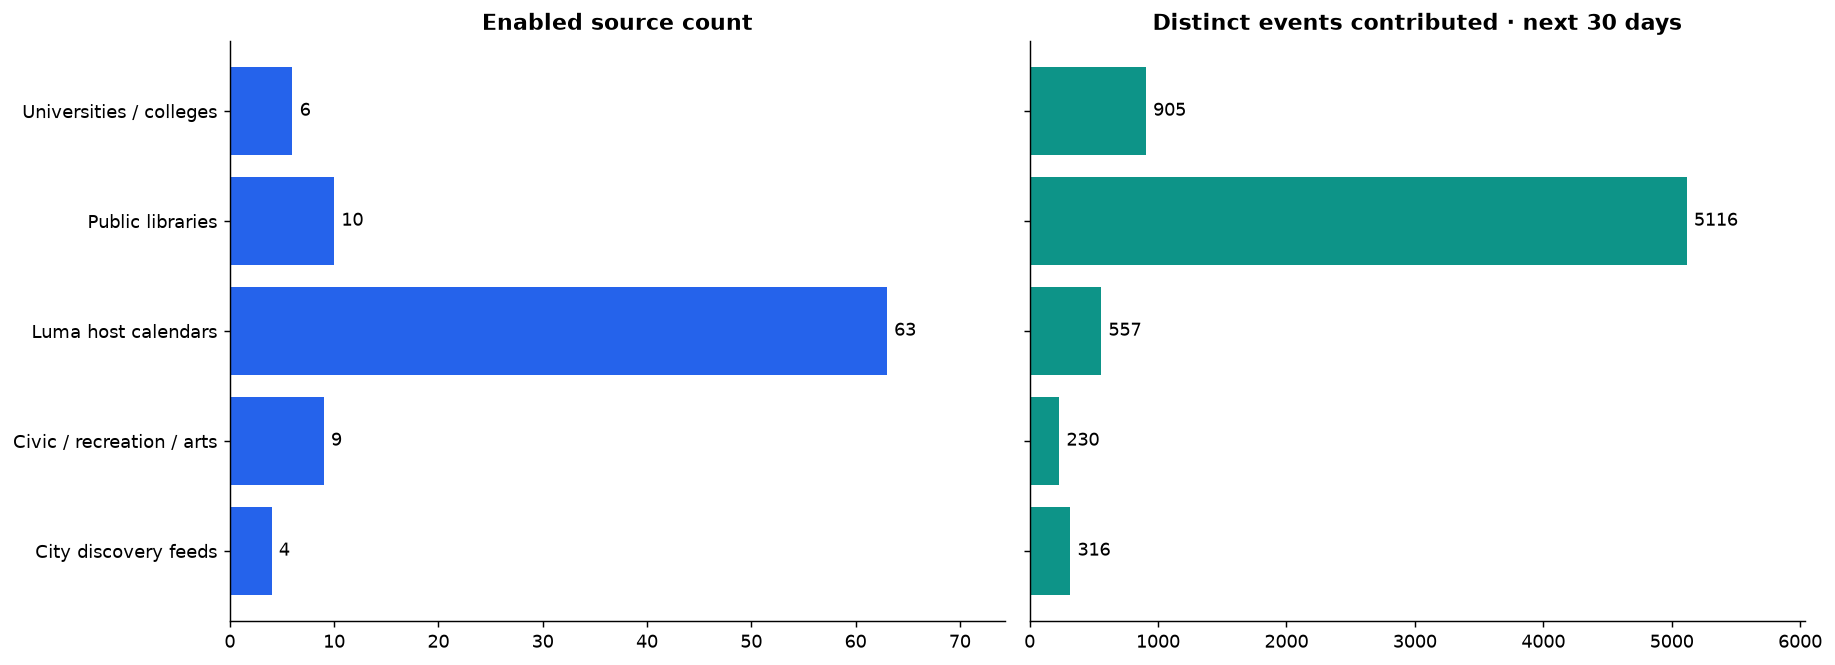

Configured source region,Enabled sources,Distinct events from these sources
bay_area_9_county,58,6672
new_york_metro,34,400


In [11]:
groups=sorted({family(r) for r in c_enabled})
group_keys={g:{r["source_key"] for r in c_enabled if family(r)==g} for g in groups}
fig, axes=plt.subplots(1,2,figsize=(14,5),layout="constrained",sharey=True)
for ax,values,title,color in [(axes[0],[len(group_keys[g]) for g in groups],"Enabled source count",BLUE),
                              (axes[1],[sum(bool(set(e["source_keys"]) & group_keys[g]) for e in c_events) for g in groups],"Distinct events contributed · next 30 days",TEAL)]:
    bars=ax.barh(groups,values,color=color);ax.bar_label(bars,padding=4)
    ax.set(title=title,xlim=(0,max(values)*1.18))
plt.show()
regions=sorted({r["region"] for r in c_enabled})
table(["Configured source region", "Enabled sources", "Distinct events from these sources"],[[region,sum(r["region"]==region for r in c_enabled),sum(any(c_sources[k]["region"]==region for k in e["source_keys"]) for e in c_events)] for region in regions])


## Geography, topics and usability
City values are the stored normalized labels, with unknowns shown explicitly. Source region does not guarantee event location: this snapshot includes London, Austin and other out-of-region cities. New York borough labels are fragmented across `newyork`, `brooklyn`, `kingscounty`, `queens`, and others. Do not infer county completeness from source region names.

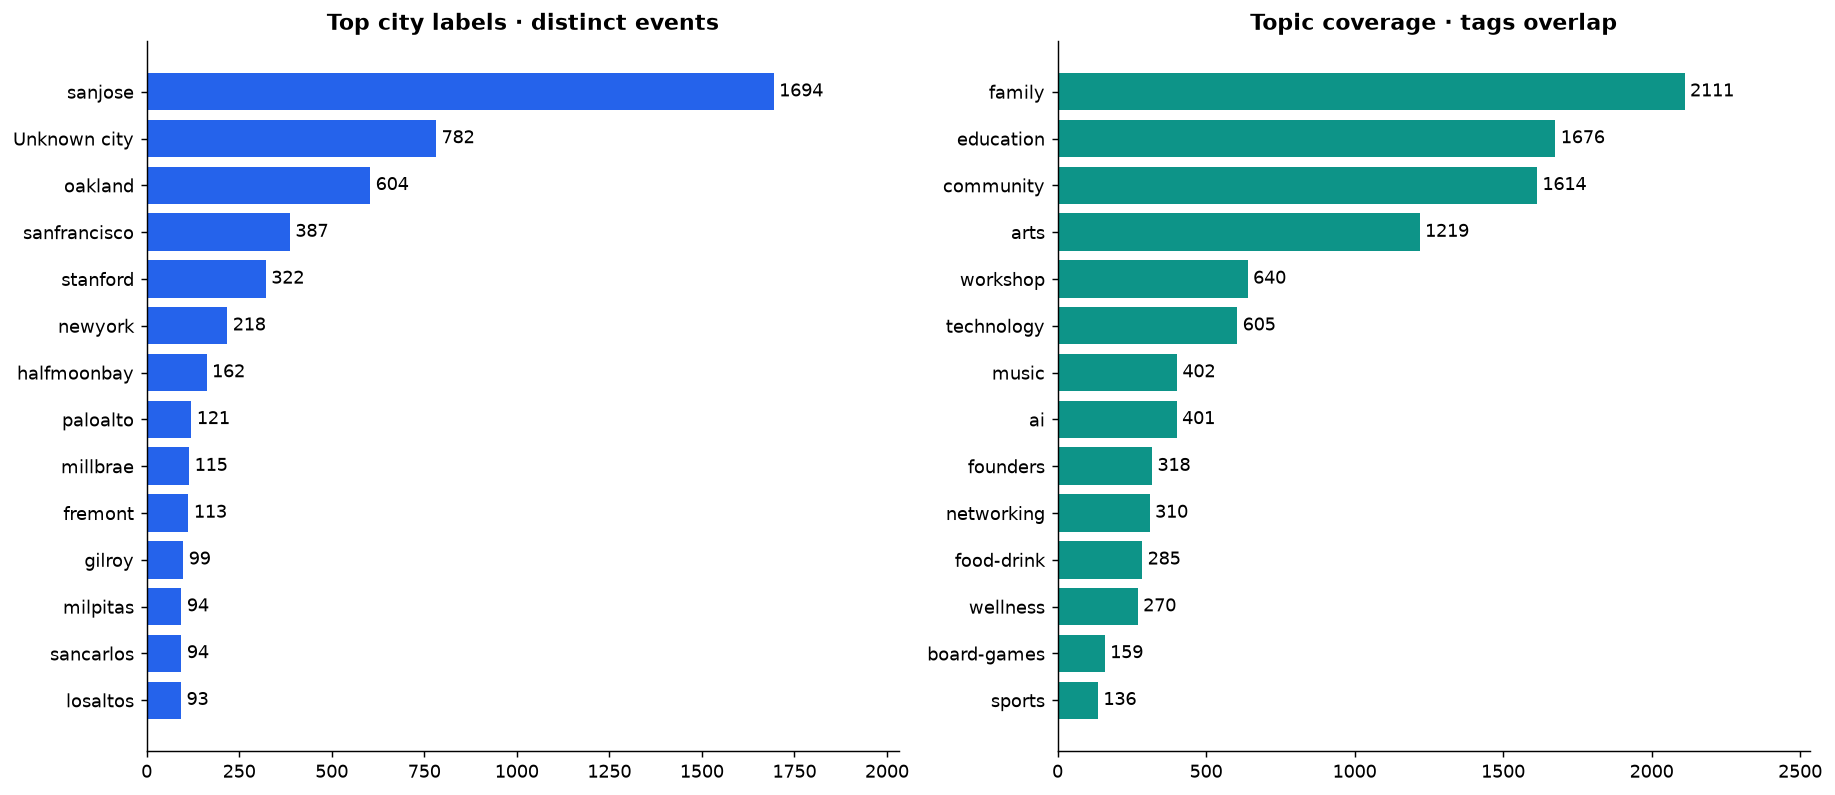

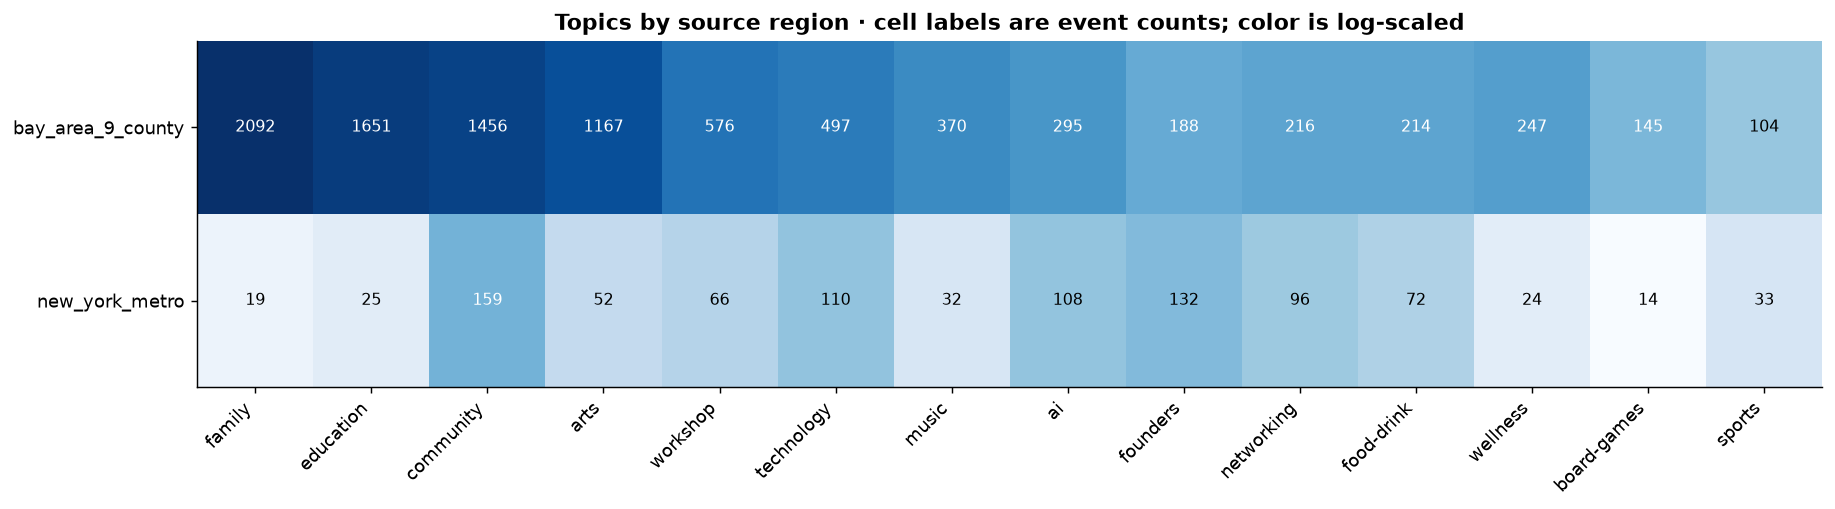

Metadata limitation,Distinct events,"% of 7,069"
Unknown city,782,11.1
Unknown price,6141,86.9
No topic tags,1545,21.9


In [12]:
cities=Counter(e["city_norm"] or "Unknown city" for e in c_events)
topics=Counter(t for e in c_events for t in (e["topics"] or []))
fig,axes=plt.subplots(1,2,figsize=(14,6),layout="constrained")
for ax,counts,title,color in [(axes[0],cities,"Top city labels · distinct events",BLUE),(axes[1],topics,"Topic coverage · tags overlap",TEAL)]:
    rows=counts.most_common(14)[::-1]
    bars=ax.barh([x[0] for x in rows],[x[1] for x in rows],color=color);ax.bar_label(bars,padding=3)
    ax.set(title=title,xlim=(0,max(counts.values())*1.2))
plt.show()
selected=[t for t,_ in topics.most_common(14)]
import numpy as np
matrix=np.array([[sum(t in (e["topics"] or []) and any(c_sources[k]["region"]==region for k in e["source_keys"]) for e in c_events) for t in selected] for region in regions])
fig,ax=plt.subplots(figsize=(14,3.8),layout="constrained")
ax.imshow(np.log1p(matrix),aspect="auto",cmap="Blues")
ax.set_xticks(range(len(selected)),selected,rotation=45,ha="right");ax.set_yticks(range(len(regions)),regions)
for i in range(len(regions)):
    for j in range(len(selected)):
        ax.text(j,i,str(matrix[i,j]),ha="center",va="center",fontsize=9,color="white" if np.log1p(matrix[i,j])>np.log1p(matrix.max())*.65 else "black")
ax.set_title("Topics by source region · cell labels are event counts; color is log-scaled")
plt.show()
table(["Metadata limitation", "Distinct events", "% of 7,069"],[[label,count,round(count/len(c_events)*100,1)] for label,count in [("Unknown city",sum(not e["city_norm"] for e in c_events)),("Unknown price",sum(e["price_status"]=="unknown" for e in c_events)),("No topic tags",sum(not e["topics"] for e in c_events))]])


## Independent scorecard for every source

Each row shows its own content, rather than inferring value from its refresh count. **Exclusive** means the canonical event appears in no other admitted source in this snapshot; it is an estimate of marginal catalog contribution, not proof of a unique real-world listing. Topic and city summaries use actual admitted records. Zero-event rows retain explicit unknown summaries. Disabled/retired sources appear separately below; their zero admitted contribution is expected under admission rules.

The city/host distinction is based on adapter mode, not a claim that any host calendar is completely ingested. Per-source metadata percentages expose which feeds are limiting search quality.

In [13]:
scorecard=[]
for r in sorted(c_enabled,key=lambda r:(r["region"],-len(c_by_source[r["source_key"]]),r["display_name"])):
    records=c_by_source[r["source_key"]];total=len(records)
    ts=Counter(t for e in records for t in (e["topics"] or []));cs=Counter(e["city_norm"] or "Unknown" for e in records)
    h=c_health.get(r["source_key"],{})
    scorecard.append([r["display_name"],r["source_key"],r["region"],family(r),total,
      sum(len(e["source_keys"])==1 for e in records),
      "; ".join(f"{x}: {v}" for x,v in cs.most_common(3)) or "No admitted events",
      "; ".join(f"{x}: {v}" for x,v in ts.most_common(3)) or "No topic evidence",
      round(100*sum(e["price_status"]=="unknown" for e in records)/total,1) if total else None,
      round(100*sum(not e["city_norm"] for e in records)/total,1) if total else None,
      h.get("latest_run_status"),r["seed_url"]])
table(["Source", "Stable key", "Configured region", "Family", "30d events", "Exclusive events", "Top city labels", "Top topics", "Unknown price %", "Unknown city %", "Latest run", "Endpoint"],scorecard)


Source,Stable key,Configured region,Family,30d events,Exclusive events,Top city labels,Top topics,Unknown price %,Unknown city %,Latest run,Endpoint
San José Public Library Events,san-jose-public-library-events,bay_area_9_county,Public libraries,1583,1582,sanjose: 1583,family: 635; community: 493; education: 352,99.0,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/sjpl/rss/events?locations=00&locations=01&locations=02&locations=03&locations=04&locations=05&locations=06&locations=07&locations=08&locations=09&locations=10&locations=11&locations=12&locations=14&locations=15&locations=16&locations=17&locations=18&locations=19&locations=21&locations=22&locations=23&locations=24&locations=25&locations=26
San Mateo County Libraries: All Physical Branch Events,smcl-all-physical-branches-events,bay_area_9_county,Public libraries,950,950,halfmoonbay: 162; millbrae: 115; sancarlos: 94,family: 313; education: 294; arts: 123,100.0,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/smcl/rss/events?locations=1A&locations=1B&locations=1R&locations=1E&locations=1F&locations=1H&locations=1M&locations=1N&locations=1Z&locations=1P&locations=1V&locations=1S&locations=1W
Contra Costa County Library Events,contra-costa-county-library-events,bay_area_9_county,Public libraries,564,564,pleasanthill: 69; sanramon: 68; sanpablo: 66,family: 263; education: 204; arts: 106,100.0,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/ccclib/rss/events?locations=43&locations=7&locations=25&locations=19&locations=14&locations=60&locations=4&locations=21&locations=26&locations=24&locations=11&locations=16&locations=6&locations=55&locations=9&locations=94&locations=1&locations=17&locations=12&locations=15&locations=27&locations=23&locations=8&locations=2&locations=13
Santa Clara County Library District: All Physical Branch Events,sccld-all-physical-branches-events,bay_area_9_county,Public libraries,540,540,gilroy: 99; milpitas: 93; losaltos: 93,family: 241; education: 201; community: 102,100.0,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/sccl/rss/events?locations=CA&locations=CU&locations=GI&locations=LA&locations=MI&locations=MH&locations=SA&locations=WO
Oakland Public Library Events,oakland-public-library-events,bay_area_9_county,Public libraries,483,483,oakland: 483,family: 137; arts: 129; education: 122,99.8,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/oaklandlibrary/rss/events?locations=81A&locations=AAA&locations=ASA&locations=BRA&locations=CCA&locations=DMA&locations=EAA&locations=ELA&locations=GGA&locations=KGA&locations=LVA&locations=MEA&locations=MOA&locations=OHR&locations=PMA&locations=RRA&locations=TMA&locations=WAS&locations=XXA&locations=XXJ&locations=XXY&locations=676de3ef74596c36004dc6bd&locations=6a0c99a4e8af4a2f00739408&locations=6a517185e9de6536001ad4d7
Alameda County Library: All Physical Branch Events,alameda-county-library-all-physical-branches-events,bay_area_9_county,Public libraries,440,440,fremont: 113; newark: 80; dublin: 60,family: 216; education: 154; arts: 75,100.0,0.0,succeeded,https://gateway.bibliocommons.com/v2/libraries/aclibrary/rss/events?locations=ALB&locations=CSV&locations=CTV&locations=CHY&locations=DUB&locations=FRM&locations=NWK&locations=NLS&locations=SLZ&locations=UCY
Stanford Events Localist Calendar,stanford-events,bay_area_9_county,Universities / colleges,347,347,stanford: 322; paloalto: 19; redwoodcity: 4,arts: 185; community: 81; family: 60,82.7,0.0,succeeded,https://events.stanford.edu/api/2/events
SMCCD Events,smccd-events,bay_area_9_county,Universities / colleges,224,224,Unknown: 224,community: 71; workshop: 61; sports: 28,99.6,100.0,succeeded,"https://events.smccd.edu/live/json/events/response_fields/location,summary,description"
Berkeley Public Library Events,berkeley-public-library-events,bay_area_9_county,Public libraries,215,215,Unknown: 215,family: 43; education: 41; arts: 32,100.0,100.0,succeeded,https://berkeleypubliclibrary.libnet.info/eeve

## Shallow discovery and inactive coverage
The all-future diagnostic below has a different time horizon from the 30-day scorecard. A low events-per-organizer ratio on a city feed suggests limited depth, but does not quantify missing events. Organizers may genuinely have only one upcoming event.

In [14]:
shelves=[h for h in coverage["health"] if h["mode"] in ("luma_discover_json","meetup_city_jsonld")]
table(["City discovery source", "All-future live events", "Named organizers", "Events / organizer", "Retracted future observations"],[[h["source_key"],h["live_future_events"],h["distinct_organizers"],round(h["live_future_events"]/h["distinct_organizers"],2) if h["distinct_organizers"] else None,h["retracted_future_events"]] for h in shelves])
table(["Enabled source with zero 30d events", "All-future live events", "Latest run status"],[[r["display_name"],c_health.get(r["source_key"],{}).get("live_future_events"),c_health.get(r["source_key"],{}).get("latest_run_status")] for r in c_enabled if not c_by_source[r["source_key"]]])
table(["Inactive source", "Lifecycle", "Replacement source", "Recorded retirement reason"],[[r["display_name"],"retired" if r["retired_at"] else "disabled",r.get("superseded_by_source_key"),r.get("retired_reason")] for r in c_sources.values() if not r["enabled"] or r["retired_at"]])


City discovery source,All-future live events,Named organizers,Events / organizer,Retracted future observations
luma-nyc,120,105,1.14,4
luma-sf,99,83,1.19,7
meetup-nyc,48,44,1.09,38
meetup-sf,53,43,1.23,34


Enabled source with zero 30d events,All-future live events,Latest run status
Santa Clara University Events,0,succeeded
Berkeley Repertory Theatre Shows,0,succeeded
Reducto Community Calendar,0,succeeded
Step,0,succeeded
Transit Books,1,succeeded
Sleepawake Events Calendar,0,succeeded


Inactive source,Lifecycle,Replacement source,Recorded retirement reason
DataSF Our415 Activities,disabled,—,—
SCCLD Milpitas Library Events,retired,sccld-all-physical-branches-events,superseded_by_aggregate_source
Oakland Museum of California Events,disabled,—,—
San Mateo County Libraries: Millbrae Events,retired,smcl-all-physical-branches-events,superseded_by_aggregate_source
University of San Francisco Main Campus Events,disabled,—,—
Midpeninsula Regional Open Space District Events & Activities,disabled,—,—
Yerba Buena Center for the Arts Calendar,disabled,—,—
Gardens of Golden Gate Park Events,disabled,—,—
City of Los Altos Events,disabled,—,—
Cal Performances Events,disabled,—,—


## What is not covered directly — external cross-check

Official calendars checked September 8, 2026. **Missing dedicated source** means there is no matching publisher/endpoint in the 105-row non-fixture registry. It does not mean zero events from that publisher reach us indirectly. These are candidates for review, not approved integrations. Public calendar existence does not establish an API, ingestion permission, or a working adapter.

| Area | Evidence outside our registry | Current coverage / gap | Priority |
|---|---|---|---|
| San Francisco public libraries | [SFPL events](https://sfpl.org/events/calendar) | Library coverage is broad elsewhere in the Bay Area, but SFPL has no dedicated source. Official calendar surfaced; browser extraction primarily returned branch navigation, so no event-level recall test was possible. | High |
| NYC public libraries | [NYPL calendar](https://www.nypl.org/events/calendar/), [Brooklyn calendar](https://discover.bklynlibrary.org/?event=true) | NYC sources are exclusively Luma/Meetup. NYPL official search result describes free programs and classes; direct retrieval failed. Brooklyn redirects to an event search whose content was not extractable. Missing direct feeds confirmed; listing totals unverified. | High |
| Outdoor activities | [East Bay Regional Park District](https://www.ebparks.org/things-to-do), [NYC Parks programs](https://www2.nycgovparks.org/programs) | SF Recreation & Parks is already enabled; Midpen is disabled. No direct EBRPD or NYC Parks source. Official pages/search results identify programs, but no exhaustive event comparison was performed. Only 92 admitted events have the outdoors tag. | High |
| North Bay | [Sonoma County Library](https://events.sonomalibrary.org/events/list), [Napa County Library](https://napalibrary.gov/) | Neither has a dedicated registry source. No Napa/Sonoma/Vallejo/Fairfield city labels appeared in the 30-day snapshot, but missing cities and normalization prevent a county-level zero-coverage claim. Solano calendars remain unverified. | Medium |
| Arts / museums / performance | Existing registry evidence | OMCA, YBCA, Cal Performances and Gardens of Golden Gate Park are disabled; Berkeley Rep is enabled but has zero admitted 30-day events. These are specific direct-source gaps even though 1,219 events carry an arts tag. | High |
| Other platforms | Existing registry evidence | No dedicated Eventbrite, Ticketmaster, DICE or Partiful mode/endpoint in the reviewed registry. This does not exclude event links to those services or adapters elsewhere in the application. Missing direct platform breadth is confirmed; commercial importance is unmeasured. | Depends on target audience |

## Recommended order of work

1. **Repair discoverability first:** investigate price and city extraction source by source using the scorecard. Unknown price must not silently become “free”; missing city must not be assigned from source region. Measure improvement in usable events, not ingestion runs.
2. **Diversify NYC and close the SFPL gap:** assess official library feeds first, then NYC Parks. The goal is distinct local, non-tech programming rather than more Luma host counts.
3. **Restore specific arts/outdoor sources:** investigate each disabled adapter and the six zero-window sources against its publisher's actual upcoming schedule. Retired branch feeds with enabled umbrella replacements should not be re-added as gaps.
4. **Deepen discovery selectively:** compare a dated sample of city-feed organizers with their official calendars and measure event-level recall before onboarding more host calendars. Low organizer depth is a lead, not a completeness score.
5. **Expand geographic breadth deliberately:** review Sonoma, Napa and Solano sources if nine-county service is intended. First establish a county/borough mapping and distinguish online from in-person events; source labels are insufficient.

**Not established by this audit:** market-wide completeness, missing-event counts, language/accessibility coverage, age suitability, verified RSVP availability, full organizer-program recall, and completeness of individual publisher crawls. Topic counts measure stored classification and can reflect recurring library sessions; they do not measure unique experiences or demand. No ingestion configuration, source status or scheduler was changed.

## Coverage snapshot provenance

Registry, admitted public event records and aggregate source health were captured in one read-only repeatable-read PostgreSQL transaction against the local Compose database, schema 0182. `coverage['query']` preserves the exact query; the embedded event fields omit descriptions and unneeded names. External checks above are a small, purposive set of official calendars, not a random sample or a complete market census. The notebook uses the saved snapshot on rerun and performs no network requests. The earlier cadence snapshot remains intact for historical comparison.
